# Paper 1 — Phase 1: Gate 1–4 + RQ1 + RQ2

**Working title:**  
*Characterizing Weak-Label Disagreement in Indonesian Government Application Reviews: A Large-Scale Empirical Study*

## Scope notebook ini
Notebook ini **hanya** mengerjakan:

- **Gate 1** — Dataset Identity
- **Gate 2** — Schema Validation
- **Gate 3** — Label Reproduction
- **Gate 4** — Agreement Replication
- **RQ1** — Magnitude of weak-label agreement/disagreement
- **RQ2** — Structure and severity of weak-label disagreement

**Tidak ada Transformer / IndoBERT di Phase 1.**

## Prinsip metodologis
- Master file: `VADER_labeled.csv`
- `rating_label` direkonstruksi dari `score`: 1–2 Negative, 3 Neutral, 4–5 Positive.
- `vader_label` diperlakukan sebagai **translation-mediated VADER weak label**, bukan ground truth.
- `rating_label != vader_label` disebut **weak-label disagreement**, bukan mislabeled sample.
- Semua artifact penting langsung disimpan ke Google Drive.
- Gate gagal => pipeline berhenti sebelum analisis berikutnya.
- State JSON hanya dashboard; **artifact validation** adalah sumber kebenaran.

In [1]:
# ============================================================
# [REPRODUCIBILITY] CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [2]:
# ============================================================
# [REPRODUCIBILITY] CELL 2 — Install minimal dependencies
# ============================================================
!pip -q install pyarrow statsmodels plotly

In [2]:
# ============================================================
# [REPRODUCIBILITY] CELL 3 — Imports
# ============================================================
from pathlib import Path
import os
import json
import hashlib
import datetime
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score, confusion_matrix
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

import plotly.graph_objects as go

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas: 2.2.3
NumPy: 2.1.3


In [3]:
# ============================================================
# [REPRODUCIBILITY] CELL 4 — Frozen Phase-1 configuration
# ============================================================

PROJECT_NAME = "IGAR_Paper1"
PHASE = "phase1"
NOTEBOOK_VERSION = "1.0.0"

DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_ROOT = DRIVE_ROOT / PROJECT_NAME

# Upload/copy the official IGAR file here:
RAW_FILE = PROJECT_ROOT / "data/raw/VADER_labeled.csv"

DIRS = {
    "raw": PROJECT_ROOT / "data/raw",
    "cache": PROJECT_ROOT / "data/cache",
    "processed": PROJECT_ROOT / "data/processed",
    "state": PROJECT_ROOT / "state",
    "gates": PROJECT_ROOT / "results/gates",
    "tables": PROJECT_ROOT / "results/tables",
    "statistics": PROJECT_ROOT / "results/statistics",
    "figures": PROJECT_ROOT / "figures",
    "logs": PROJECT_ROOT / "results/logs",
    "configs": PROJECT_ROOT / "configs",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

EXPECTED_ROWS = 617_722

EXPECTED_COLUMNS = [
    "app",
    "content",
    "score",
    "at",
    "appVersion",
    "translation",
    "vader_neg",
    "vader_neu",
    "vader_pos",
    "vader_compound",
    "vader_label",
    "vader_confidence",
]

EXPECTED_RATING_COUNTS = {
    "Negative": 246_898,
    "Neutral": 34_375,
    "Positive": 336_449,
}

EXPECTED_VADER_COUNTS = {
    "Negative": 119_733,
    "Neutral": 173_329,
    "Positive": 324_660,
}

EXPECTED_AGREEMENT = 0.5865
EXPECTED_KAPPA = 0.33

# Published values are rounded.
AGREEMENT_TOLERANCE = 0.0001
KAPPA_TOLERANCE = 0.005

RATING_MAP = {
    1: "Negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Positive",
}

SENTIMENT_CODE = {
    "Negative": -1,
    "Neutral": 0,
    "Positive": 1,
}

PHASE1_CONFIG = {
    "project": PROJECT_NAME,
    "phase": PHASE,
    "notebook_version": NOTEBOOK_VERSION,
    "expected_rows": EXPECTED_ROWS,
    "expected_columns": EXPECTED_COLUMNS,
    "expected_rating_counts": EXPECTED_RATING_COUNTS,
    "expected_vader_counts": EXPECTED_VADER_COUNTS,
    "expected_agreement": EXPECTED_AGREEMENT,
    "expected_kappa": EXPECTED_KAPPA,
    "agreement_tolerance": AGREEMENT_TOLERANCE,
    "kappa_tolerance": KAPPA_TOLERANCE,
    "rating_map": RATING_MAP,
    "sentiment_code": SENTIMENT_CODE,
}

def hash_dict(obj):
    payload = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()[:12]

PHASE1_ID = hash_dict(PHASE1_CONFIG)

print("Project root:", PROJECT_ROOT)
print("Phase-1 ID:", PHASE1_ID)
print("Expected raw file:", RAW_FILE)

Project root: /content/drive/MyDrive/IGAR_Paper1
Phase-1 ID: f11658d4e59a
Expected raw file: /content/drive/MyDrive/IGAR_Paper1/data/raw/VADER_labeled.csv


In [4]:
# ============================================================
# [REPRODUCIBILITY] CELL 5 — Atomic writes + artifact validators
# ============================================================

def json_safe_default(obj):
    """
    Convert NumPy/Pandas/Path objects into native JSON-safe types.
    """
    if isinstance(obj, np.generic):
        return obj.item()

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, (datetime.datetime, datetime.date)):
        return obj.isoformat()

    raise TypeError(
        f"Object of type {type(obj).__name__} "
        "is not JSON serializable"
    )

def atomic_json_save(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    tmp = path.with_suffix(
        path.suffix + ".tmp"
    )

    with open(
        tmp,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            data,
            f,
            indent=2,
            ensure_ascii=False,
            default=json_safe_default
        )

        f.flush()
        os.fsync(f.fileno())

    os.replace(
        tmp,
        path
    )

def atomic_csv_save(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)

def atomic_parquet_save(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp.parquet")
    df.to_parquet(tmp, index=False)
    os.replace(tmp, path)

def valid_json(path):
    path = Path(path)
    if not path.exists():
        return False
    try:
        with open(path, encoding="utf-8") as f:
            json.load(f)
        return True
    except Exception:
        return False

def valid_csv(path, min_rows=1):
    path = Path(path)
    if not path.exists():
        return False
    try:
        x = pd.read_csv(path)
        return len(x) >= min_rows
    except Exception:
        return False

def valid_parquet(path, min_rows=1):
    path = Path(path)
    if not path.exists():
        return False
    try:
        x = pd.read_parquet(path)
        return len(x) >= min_rows
    except Exception:
        return False

def sha256_file(path, chunk_size=1024 * 1024):
    sha = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            sha.update(b)
    return sha.hexdigest()

STATE_FILE = DIRS["state"] / f"pipeline_state_{PHASE1_ID}.json"

def load_state():
    if valid_json(STATE_FILE):
        with open(STATE_FILE, encoding="utf-8") as f:
            return json.load(f)
    state = {
        "phase1_id": PHASE1_ID,
        "gate1": "pending",
        "gate2": "pending",
        "gate3": "pending",
        "gate4": "pending",
        "rq1": "pending",
        "rq2": "pending",
        "last_update": None,
    }
    atomic_json_save(state, STATE_FILE)
    return state

def set_state(key, value):
    state = load_state()
    state[key] = value
    state["last_update"] = datetime.datetime.now().isoformat()
    atomic_json_save(state, STATE_FILE)

def heartbeat(stage, **kwargs):
    payload = {
        "phase1_id": PHASE1_ID,
        "stage": stage,
        "timestamp": datetime.datetime.now().isoformat(),
        **kwargs,
    }
    atomic_json_save(payload, DIRS["logs"] / f"heartbeat_{PHASE1_ID}.json")

CONFIG_FILE = DIRS["configs"] / f"phase1_config_{PHASE1_ID}.json"
if not valid_json(CONFIG_FILE):
    atomic_json_save(PHASE1_CONFIG, CONFIG_FILE)

print("Utilities ready.")

Utilities ready.


In [5]:
# ============================================================
# [GATE 1] CELL 6 — Dataset Identity
# Purpose: verify the raw file and freeze its fingerprint.
# Output: gate1_dataset_identity.json
# ============================================================

GATE1_FILE = DIRS["gates"] / "gate1_dataset_identity.json"
FINGERPRINT_FILE = DIRS["configs"] / "dataset_fingerprint.json"

if not RAW_FILE.exists():
    raise FileNotFoundError(
        "[GATE 1 — NO-GO]\n"
        f"File tidak ditemukan: {RAW_FILE}\n\n"
        f"Tempatkan file resmi IGAR VADER_labeled.csv di: {DIRS['raw']}"
    )

heartbeat("GATE1_DATASET_IDENTITY", status="running")

current_fp = {
    "filename": RAW_FILE.name,
    "size_bytes": RAW_FILE.stat().st_size,
    "sha256": sha256_file(RAW_FILE),
}

if valid_json(FINGERPRINT_FILE):
    with open(FINGERPRINT_FILE, encoding="utf-8") as f:
        frozen_fp = json.load(f)

    if frozen_fp["sha256"] != current_fp["sha256"]:
        report = {
            "status": "NO-GO",
            "reason": "Dataset SHA-256 changed from frozen fingerprint.",
            "frozen": frozen_fp,
            "current": current_fp,
        }
        atomic_json_save(report, GATE1_FILE)
        set_state("gate1", "failed")
        raise RuntimeError("[GATE 1 — NO-GO] Dataset fingerprint berubah.")
else:
    frozen_fp = {
        **current_fp,
        "frozen_at": datetime.datetime.now().isoformat(),
        "source_note": "Official IGAR VADER_labeled.csv; provenance should be recorded by researcher.",
    }
    atomic_json_save(frozen_fp, FINGERPRINT_FILE)

gate1 = {
    "status": "PASS",
    "raw_file": str(RAW_FILE),
    "filename": current_fp["filename"],
    "size_bytes": current_fp["size_bytes"],
    "sha256": current_fp["sha256"],
    "checked_at": datetime.datetime.now().isoformat(),
}

atomic_json_save(gate1, GATE1_FILE)
set_state("gate1", "passed")
heartbeat("GATE1_DATASET_IDENTITY", status="complete")

print("[GATE 1 — PASS]")
print(json.dumps(gate1, indent=2))

[GATE 1 — PASS]
{
  "status": "PASS",
  "raw_file": "/content/drive/MyDrive/IGAR_Paper1/data/raw/VADER_labeled.csv",
  "filename": "VADER_labeled.csv",
  "size_bytes": 112714141,
  "sha256": "852c8b662224bd62418ef7b7dac15b9e43c9a6b4cdf0fef6239042203c2eccb0",
  "checked_at": "2026-09-11T11:08:49.589420"
}


In [7]:
# ============================================================
# [REPRODUCIBILITY] CELL 7 — Resumable raw cache
# Purpose: avoid repeatedly parsing the large CSV after reconnect.
# Output: 00_raw_cache.parquet
# ============================================================

RAW_CACHE = DIRS["cache"] / "00_raw_cache.parquet"
RAW_CACHE_META = DIRS["cache"] / "00_raw_cache.meta.json"

cache_valid = False

if valid_parquet(RAW_CACHE, min_rows=1) and valid_json(RAW_CACHE_META):
    with open(RAW_CACHE_META, encoding="utf-8") as f:
        cache_meta = json.load(f)

    cache_valid = (
        cache_meta.get("source_sha256") == current_fp["sha256"]
        and cache_meta.get("phase1_id") == PHASE1_ID
    )

if cache_valid:
    print("✓ Valid raw Parquet cache found. Loading from Drive...")
    df = pd.read_parquet(RAW_CACHE)
else:
    print("Creating raw Parquet cache from CSV...")
    heartbeat("RAW_CACHE", status="running")

    df = pd.read_csv(RAW_FILE, low_memory=False)

    atomic_parquet_save(df, RAW_CACHE)

    check = pd.read_parquet(RAW_CACHE)
    cache_meta = {
        "phase1_id": PHASE1_ID,
        "source_sha256": current_fp["sha256"],
        "rows": int(len(check)),
        "columns": check.columns.tolist(),
        "created_at": datetime.datetime.now().isoformat(),
    }
    atomic_json_save(cache_meta, RAW_CACHE_META)

    del check
    heartbeat("RAW_CACHE", status="complete", rows=len(df))

print("Loaded rows:", len(df))
print("Loaded columns:", len(df.columns))

Creating raw Parquet cache from CSV...
Loaded rows: 617722
Loaded columns: 12


In [8]:
# ============================================================
# [GATE 2] CELL 8 — Schema Validation
# Expected: 617,722 rows and 12 documented columns.
# Output: gate2_schema_validation.json + missingness audit
# ============================================================

GATE2_FILE = DIRS["gates"] / "gate2_schema_validation.json"
MISSINGNESS_FILE = DIRS["statistics"] / "phase1_missingness_audit.csv"

heartbeat("GATE2_SCHEMA", status="running")

actual_columns = df.columns.tolist()
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(actual_columns))
extra_columns = sorted(set(actual_columns) - set(EXPECTED_COLUMNS))

row_pass = len(df) == EXPECTED_ROWS
column_count_pass = len(actual_columns) == len(EXPECTED_COLUMNS)
column_set_pass = set(actual_columns) == set(EXPECTED_COLUMNS)

missingness = pd.DataFrame({
    "column": df.columns,
    "missing_n": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct": [float(df[c].isna().mean() * 100) for c in df.columns],
    "dtype": [str(df[c].dtype) for c in df.columns],
})
atomic_csv_save(missingness, MISSINGNESS_FILE)

gate2_pass = row_pass and column_count_pass and column_set_pass

gate2 = {
    "status": "PASS" if gate2_pass else "NO-GO",
    "rows_actual": int(len(df)),
    "rows_expected": EXPECTED_ROWS,
    "column_count_actual": len(actual_columns),
    "column_count_expected": len(EXPECTED_COLUMNS),
    "columns_actual": actual_columns,
    "missing_columns": missing_columns,
    "extra_columns": extra_columns,
    "row_pass": row_pass,
    "column_count_pass": column_count_pass,
    "column_set_pass": column_set_pass,
    "missingness_file": str(MISSINGNESS_FILE),
    "checked_at": datetime.datetime.now().isoformat(),
}

atomic_json_save(gate2, GATE2_FILE)

if not gate2_pass:
    set_state("gate2", "failed")
    heartbeat("GATE2_SCHEMA", status="failed")
    raise RuntimeError(
        "[GATE 2 — NO-GO] Schema/row count tidak sesuai publikasi. "
        "Periksa gate2_schema_validation.json."
    )

set_state("gate2", "passed")
heartbeat("GATE2_SCHEMA", status="complete")

print("[GATE 2 — PASS]")
print("Rows:", len(df))
print("Columns:", actual_columns)
display(missingness)

[GATE 2 — PASS]
Rows: 617722
Columns: ['app', 'content', 'score', 'at', 'appVersion', 'translation', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_label', 'vader_confidence']


,column,missing_n,missing_pct,dtype
0,app,0,0.000000,object
1,content,26,0.004209,object
2,score,0,0.000000,int64
3,at,0,0.000000,object
4,appVersion,90403,14.634900,object
5,translation,7775,1.258657,object
6,vader_neg,0,0.000000,float64
7,vader_neu,0,0.000000,float64
8,vader_pos,0,0.000000,float64
9,vader_compound,0,0.000000,float64


In [12]:
# ============================================================
# [GATE 3] CELL 9 — Label Reproduction
# 1) reconstruct rating-derived labels
# 2) normalize published VADER labels
# 3) reconstruct VADER labels from documented thresholds
# 4) reproduce published class counts exactly
#
# Output:
# - 01_phase1_labels.parquet
# - gate3_label_reproduction.json
# ============================================================

LABEL_FILE = DIRS["processed"] / "01_phase1_labels.parquet"
LABEL_META = DIRS["processed"] / "01_phase1_labels.meta.json"
GATE3_FILE = DIRS["gates"] / "gate3_label_reproduction.json"

def normalize_vader_label(series):
    return series.astype("string").str.strip().str.capitalize()

def vader_from_compound(x):
    if pd.isna(x):
        return pd.NA
    if x <= -0.05:
        return "Negative"
    if x >= 0.05:
        return "Positive"
    return "Neutral"

label_artifact_valid = False

if valid_parquet(LABEL_FILE, min_rows=EXPECTED_ROWS) and valid_json(LABEL_META):
    with open(LABEL_META, encoding="utf-8") as f:
        meta = json.load(f)
    label_artifact_valid = (
        meta.get("source_sha256") == current_fp["sha256"]
        and meta.get("phase1_id") == PHASE1_ID
        and meta.get("rows") == EXPECTED_ROWS
    )

if label_artifact_valid:
    print("✓ Valid Phase-1 label artifact found.")
    phase1 = pd.read_parquet(LABEL_FILE)
else:
    heartbeat("GATE3_LABEL_REPRODUCTION", status="running")

    phase1 = df[
        ["app", "score", "vader_compound", "vader_label"]
    ].copy()

    phase1["rating_label"] = phase1["score"].map(RATING_MAP)
    phase1["vader_label"] = normalize_vader_label(phase1["vader_label"])
    phase1["vader_label_rebuilt"] = phase1["vader_compound"].apply(vader_from_compound)

    phase1["disagreement"] = (
        phase1["rating_label"] != phase1["vader_label"]
    ).astype("int8")

    phase1["transition_type"] = (
        phase1["rating_label"].astype(str)
        + "->"
        + phase1["vader_label"].astype(str)
    )

    phase1["rating_code"] = phase1["rating_label"].map(SENTIMENT_CODE)
    phase1["vader_code"] = phase1["vader_label"].map(SENTIMENT_CODE)

    phase1["severity"] = (
        phase1["rating_code"] - phase1["vader_code"]
    ).abs().astype("Int8")

    atomic_parquet_save(phase1, LABEL_FILE)

    label_meta = {
        "phase1_id": PHASE1_ID,
        "source_sha256": current_fp["sha256"],
        "rows": int(len(phase1)),
        "columns": phase1.columns.tolist(),
        "created_at": datetime.datetime.now().isoformat(),
    }
    atomic_json_save(label_meta, LABEL_META)

rating_counts = phase1["rating_label"].value_counts(dropna=False).to_dict()
vader_counts = phase1["vader_label"].value_counts(dropna=False).to_dict()

rating_counts_clean = {str(k): int(v) for k, v in rating_counts.items()}
vader_counts_clean = {str(k): int(v) for k, v in vader_counts.items()}

threshold_mismatch_n = int(
    (
        phase1["vader_label"].astype("string")
        != phase1["vader_label_rebuilt"].astype("string")
    ).fillna(True).sum()
)

valid_sentiments = {"Negative", "Neutral", "Positive"}

rating_values_pass = bool(
    set(
        phase1[
            "rating_label"
        ]
        .dropna()
        .unique()
    ).issubset(
        valid_sentiments
    )
    and
    bool(
        phase1[
            "rating_label"
        ]
        .notna()
        .all()
    )
)

vader_values_pass = bool(
    set(
        phase1[
            "vader_label"
        ]
        .dropna()
        .unique()
    ).issubset(
        valid_sentiments
    )
    and
    bool(
        phase1[
            "vader_label"
        ]
        .notna()
        .all()
    )
)

rating_count_pass = bool(
    all(
        rating_counts_clean.get(
            label,
            0
        ) == n

        for label, n
        in EXPECTED_RATING_COUNTS.items()
    )
)

vader_count_pass = bool(
    all(
        vader_counts_clean.get(
            label,
            0
        ) == n

        for label, n
        in EXPECTED_VADER_COUNTS.items()
    )
)

threshold_pass = bool(
    threshold_mismatch_n == 0
)

gate3_pass = bool(
    rating_values_pass
    and vader_values_pass
    and rating_count_pass
    and vader_count_pass
    and threshold_pass
)

gate3 = {
    "status": "PASS" if gate3_pass else "NO-GO",
    "rating_counts_actual": rating_counts_clean,
    "rating_counts_expected": EXPECTED_RATING_COUNTS,
    "vader_counts_actual": vader_counts_clean,
    "vader_counts_expected": EXPECTED_VADER_COUNTS,
    "threshold_mismatch_n": threshold_mismatch_n,
    "rating_values_pass": rating_values_pass,
    "vader_values_pass": vader_values_pass,
    "rating_count_pass": rating_count_pass,
    "vader_count_pass": vader_count_pass,
    "threshold_pass": threshold_pass,
    "checked_at": datetime.datetime.now().isoformat(),
}

atomic_json_save(gate3, GATE3_FILE)

if not gate3_pass:
    set_state("gate3", "failed")
    heartbeat("GATE3_LABEL_REPRODUCTION", status="failed")
    print(json.dumps(gate3, indent=2))
    raise RuntimeError(
        "[GATE 3 — NO-GO] Label reproduction tidak cocok dengan publikasi. "
        "Jangan lanjut ke RQ sebelum penyebab ditemukan."
    )

set_state("gate3", "passed")
heartbeat("GATE3_LABEL_REPRODUCTION", status="complete")

print("[GATE 3 — PASS]")
print(
    json.dumps(
        gate3,
        indent=2
    )
)

✓ Valid Phase-1 label artifact found.
[GATE 3 — PASS]
{
  "status": "PASS",
  "rating_counts_actual": {
    "Positive": 336449,
    "Negative": 246898,
    "Neutral": 34375
  },
  "rating_counts_expected": {
    "Negative": 246898,
    "Neutral": 34375,
    "Positive": 336449
  },
  "vader_counts_actual": {
    "Positive": 324660,
    "Neutral": 173329,
    "Negative": 119733
  },
  "vader_counts_expected": {
    "Negative": 119733,
    "Neutral": 173329,
    "Positive": 324660
  },
  "threshold_mismatch_n": 0,
  "rating_values_pass": true,
  "vader_values_pass": true,
  "rating_count_pass": true,
  "vader_count_pass": true,
  "threshold_pass": true,
  "checked_at": "2026-09-10T19:34:35.668580"
}


In [13]:
# ============================================================
# [GATE 4] CELL 10 — Published Agreement Replication
# Expected:
# - overall label matching ≈ 58.65%
# - Cohen's kappa ≈ 0.33
#
# Output: gate4_agreement_replication.json
# ============================================================

GATE4_FILE = DIRS["gates"] / "gate4_agreement_replication.json"

heartbeat("GATE4_AGREEMENT_REPLICATION", status="running")

agreement_rate = float(
    (phase1["rating_label"] == phase1["vader_label"]).mean()
)

disagreement_rate = 1.0 - agreement_rate

kappa = float(
    cohen_kappa_score(
        phase1["rating_label"],
        phase1["vader_label"],
    )
)

agreement_pass = abs(agreement_rate - EXPECTED_AGREEMENT) <= AGREEMENT_TOLERANCE
kappa_pass = abs(kappa - EXPECTED_KAPPA) <= KAPPA_TOLERANCE
gate4_pass = agreement_pass and kappa_pass

gate4 = {
    "status": "PASS" if gate4_pass else "NO-GO",
    "agreement_rate_actual": agreement_rate,
    "agreement_pct_actual": agreement_rate * 100,
    "agreement_expected": EXPECTED_AGREEMENT,
    "agreement_tolerance": AGREEMENT_TOLERANCE,
    "disagreement_rate_actual": disagreement_rate,
    "cohen_kappa_actual": kappa,
    "cohen_kappa_expected": EXPECTED_KAPPA,
    "kappa_tolerance": KAPPA_TOLERANCE,
    "agreement_pass": agreement_pass,
    "kappa_pass": kappa_pass,
    "checked_at": datetime.datetime.now().isoformat(),
}

atomic_json_save(gate4, GATE4_FILE)

if not gate4_pass:
    set_state("gate4", "failed")
    heartbeat("GATE4_AGREEMENT_REPLICATION", status="failed")
    print(json.dumps(gate4, indent=2))
    raise RuntimeError(
        "[GATE 4 — NO-GO] Agreement/kappa tidak mereplikasi angka publikasi. "
        "Periksa mapping, normalization, file version, dan threshold."
    )

set_state("gate4", "passed")
heartbeat("GATE4_AGREEMENT_REPLICATION", status="complete")

print("[GATE 4 — PASS]")
print(json.dumps(gate4, indent=2))

[GATE 4 — PASS]
{
  "status": "PASS",
  "agreement_rate_actual": 0.5865227400027844,
  "agreement_pct_actual": 58.65227400027844,
  "agreement_expected": 0.5865,
  "agreement_tolerance": 0.0001,
  "disagreement_rate_actual": 0.41347725999721563,
  "cohen_kappa_actual": 0.3338024313837633,
  "cohen_kappa_expected": 0.33,
  "kappa_tolerance": 0.005,
  "agreement_pass": true,
  "kappa_pass": true,
  "checked_at": "2026-09-10T19:35:37.497737"
}


## RQ1 — Magnitude of Weak-Label Agreement

**RQ1:**  
*To what extent do rating-derived and translation-mediated VADER sentiment labels agree in the IGAR dataset?*

Output utama:
- overall agreement/disagreement
- Cohen's κ
- per-application agreement/disagreement and κ
- 3×3 agreement matrix

In [14]:
# ============================================================
# [RQ1][OUTPUT] CELL 11 — Table 2: agreement overall + per app
# ============================================================

TABLE2_FILE = DIRS["tables"] / "Table2_RQ1_Agreement_Overall_PerApp.csv"

def compute_agreement_row(frame, label):
    n = len(frame)
    agree_mask = frame["rating_label"] == frame["vader_label"]
    agree = float(agree_mask.mean())
    kap = float(cohen_kappa_score(frame["rating_label"], frame["vader_label"]))
    return {
        "scope": label,
        "N": n,
        "agreement_n": int(agree_mask.sum()),
        "agreement_pct": agree * 100,
        "disagreement_n": int((~agree_mask).sum()),
        "disagreement_pct": (1 - agree) * 100,
        "cohen_kappa": kap,
    }

rows = [compute_agreement_row(phase1, "Overall")]

for app_name, g in phase1.groupby("app", sort=True):
    rows.append(compute_agreement_row(g, str(app_name)))

table2 = pd.DataFrame(rows)
atomic_csv_save(table2, TABLE2_FILE)

display(table2)
set_state("rq1", "running")

,scope,N,agreement_n,agreement_pct,disagreement_n,disagreement_pct,cohen_kappa
0,Overall,617722,362308,58.652274,255414,41.347726,0.333802
1,BMKG,1321,717,54.277063,604,45.722937,0.067550
2,JMO,200000,135080,67.540000,64920,32.460000,0.326864
3,KAI,7311,3633,49.692245,3678,50.307755,0.232125
4,mobileJKN,122103,70439,57.688181,51664,42.311819,0.316729
5,pertamina,96291,47537,49.368061,48754,50.631939,0.237193
6,satusehat,190696,104902,55.010068,85794,44.989932,0.299178


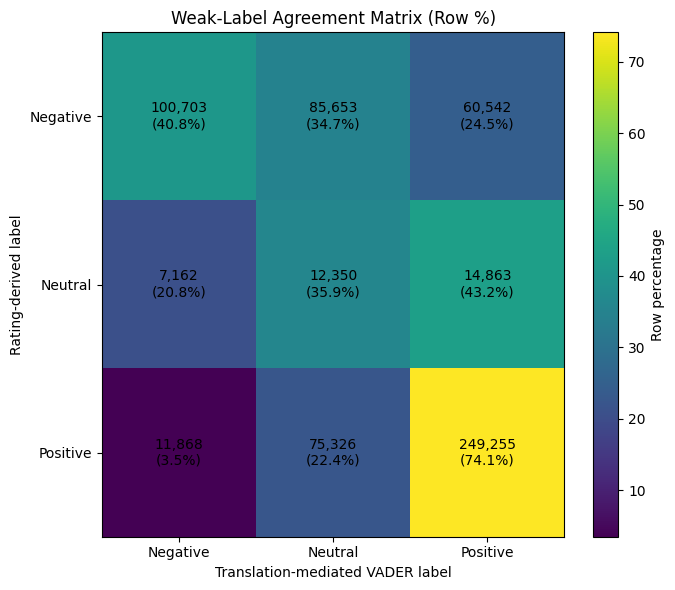

Saved: /content/drive/MyDrive/IGAR_Paper1/figures/Fig2_RQ1_Rating_VADER_Agreement_Matrix.png


In [15]:
# ============================================================
# [RQ1][OUTPUT] CELL 12 — 3x3 agreement matrices + Figure 2
# ============================================================

LABEL_ORDER = ["Negative", "Neutral", "Positive"]

CM_COUNT_FILE = DIRS["tables"] / "RQ1_AgreementMatrix_Counts.csv"
CM_ROWPCT_FILE = DIRS["tables"] / "RQ1_AgreementMatrix_RowPercent.csv"
FIG2_FILE = DIRS["figures"] / "Fig2_RQ1_Rating_VADER_Agreement_Matrix.png"

cm = confusion_matrix(
    phase1["rating_label"],
    phase1["vader_label"],
    labels=LABEL_ORDER,
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Rating_{x}" for x in LABEL_ORDER],
    columns=[f"VADER_{x}" for x in LABEL_ORDER],
)

cm_rowpct = cm / cm.sum(axis=1, keepdims=True) * 100
cm_rowpct_df = pd.DataFrame(
    cm_rowpct,
    index=cm_df.index,
    columns=cm_df.columns,
)

atomic_csv_save(cm_df.reset_index(names="rating_label"), CM_COUNT_FILE)
atomic_csv_save(cm_rowpct_df.reset_index(names="rating_label"), CM_ROWPCT_FILE)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_rowpct, aspect="auto")

ax.set_xticks(range(3), LABEL_ORDER)
ax.set_yticks(range(3), LABEL_ORDER)
ax.set_xlabel("Translation-mediated VADER label")
ax.set_ylabel("Rating-derived label")
ax.set_title("Weak-Label Agreement Matrix (Row %)")

for i in range(3):
    for j in range(3):
        ax.text(
            j, i,
            f"{cm[i,j]:,}\n({cm_rowpct[i,j]:.1f}%)",
            ha="center",
            va="center",
        )

fig.colorbar(im, ax=ax, label="Row percentage")
fig.tight_layout()
fig.savefig(FIG2_FILE, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", FIG2_FILE)

In [16]:
# ============================================================
# [RQ1][OUTPUT] CELL 13 — RQ1 summary artifact
# ============================================================

RQ1_SUMMARY_FILE = DIRS["statistics"] / "RQ1_summary.json"

rq1_summary = {
    "research_question": (
        "To what extent do rating-derived and translation-mediated "
        "VADER sentiment labels agree in the IGAR dataset?"
    ),
    "N": int(len(phase1)),
    "agreement_pct": agreement_rate * 100,
    "disagreement_pct": disagreement_rate * 100,
    "cohen_kappa": kappa,
    "table2": str(TABLE2_FILE),
    "agreement_matrix_counts": str(CM_COUNT_FILE),
    "agreement_matrix_rowpct": str(CM_ROWPCT_FILE),
    "figure2": str(FIG2_FILE),
}

atomic_json_save(rq1_summary, RQ1_SUMMARY_FILE)
set_state("rq1", "complete")

print(json.dumps(rq1_summary, indent=2))

{
  "research_question": "To what extent do rating-derived and translation-mediated VADER sentiment labels agree in the IGAR dataset?",
  "N": 617722,
  "agreement_pct": 58.65227400027844,
  "disagreement_pct": 41.34772599972156,
  "cohen_kappa": 0.3338024313837633,
  "table2": "/content/drive/MyDrive/IGAR_Paper1/results/tables/Table2_RQ1_Agreement_Overall_PerApp.csv",
  "agreement_matrix_counts": "/content/drive/MyDrive/IGAR_Paper1/results/tables/RQ1_AgreementMatrix_Counts.csv",
  "agreement_matrix_rowpct": "/content/drive/MyDrive/IGAR_Paper1/results/tables/RQ1_AgreementMatrix_RowPercent.csv",
  "figure2": "/content/drive/MyDrive/IGAR_Paper1/figures/Fig2_RQ1_Rating_VADER_Agreement_Matrix.png"
}


## RQ2 — Structure and Severity of Weak-Label Disagreement

**RQ2:**  
*How are weak-label disagreement and disagreement severity distributed across sentiment transitions, star ratings, and government application domains?*

Severity definition:
- `0` = agreement
- `1` = adjacent disagreement (`Negative↔Neutral`, `Neutral↔Positive`)
- `2` = extreme disagreement (`Negative↔Positive`)

Primary analyses:
- transition frequency
- severity by application
- severity/disagreement by star rating
- χ² + Cramér's V for application × disagreement and score × disagreement
- 95% Wilson CI for application-level disagreement rates

In [17]:
# ============================================================
# [RQ2][OUTPUT] CELL 14 — Table 3: transition structure
# ============================================================

TABLE3_FILE = DIRS["tables"] / "Table3_RQ2_Transition_Structure.csv"

transition_order = [
    "Negative->Negative",
    "Negative->Neutral",
    "Negative->Positive",
    "Neutral->Negative",
    "Neutral->Neutral",
    "Neutral->Positive",
    "Positive->Negative",
    "Positive->Neutral",
    "Positive->Positive",
]

table3 = (
    phase1.groupby("transition_type", observed=False)
    .size()
    .reindex(transition_order, fill_value=0)
    .rename("N")
    .reset_index()
)

table3["pct_total"] = table3["N"] / len(phase1) * 100

def transition_severity(t):
    left, right = t.split("->")
    return abs(SENTIMENT_CODE[left] - SENTIMENT_CODE[right])

table3["severity"] = table3["transition_type"].map(transition_severity)
table3["is_disagreement"] = (table3["severity"] > 0).astype(int)

disagreement_total = int((phase1["disagreement"] == 1).sum())
table3["pct_of_disagreements"] = np.where(
    table3["is_disagreement"] == 1,
    table3["N"] / disagreement_total * 100,
    np.nan,
)

atomic_csv_save(table3, TABLE3_FILE)
display(table3)

,transition_type,N,pct_total,severity,is_disagreement,pct_of_disagreements
0,Negative->Negative,100703,16.302317,0,0,NaN
1,Negative->Neutral,85653,13.865946,1,1,33.534967
2,Negative->Positive,60542,9.800849,2,1,23.703477
3,Neutral->Negative,7162,1.159421,1,1,2.804075
4,Neutral->Neutral,12350,1.999281,0,0,NaN
5,Neutral->Positive,14863,2.406099,1,1,5.819180
6,Positive->Negative,11868,1.921253,2,1,4.646574
7,Positive->Neutral,75326,12.194159,1,1,29.491727
8,Positive->Positive,249255,40.350676,0,0,NaN


In [19]:
# ============================================================
# [RQ2][OUTPUT] CELL 15 — Table 4: domain-level severity
# + 95% Wilson CI
# ============================================================

TABLE4_FILE = DIRS["tables"] / "Table4_RQ2_Domain_Disagreement_Severity.csv"

domain_rows = []

for app_name, g in phase1.groupby("app", sort=True):
    n = len(g)
    d = int(g["disagreement"].sum())
    s0 = int((g["severity"] == 0).sum())
    s1 = int((g["severity"] == 1).sum())
    s2 = int((g["severity"] == 2).sum())

    ci_low, ci_high = proportion_confint(
        count=d,
        nobs=n,
        alpha=0.05,
        method="wilson",
    )

    kap = float(cohen_kappa_score(g["rating_label"], g["vader_label"]))

    domain_rows.append({
        "app": app_name,
        "N": n,
        "agreement_pct": s0 / n * 100,
        "disagreement_pct": d / n * 100,
        "disagreement_ci95_low_pct": ci_low * 100,
        "disagreement_ci95_high_pct": ci_high * 100,
        "severity1_pct": s1 / n * 100,
        "severity2_pct": s2 / n * 100,
        "severity1_share_of_disagreement_pct": s1 / d * 100 if d > 0 else np.nan,
        "severity2_share_of_disagreement_pct": s2 / d * 100 if d > 0 else np.nan,
        "cohen_kappa": kap,
    })

table4 = pd.DataFrame(domain_rows)
atomic_csv_save(table4, TABLE4_FILE)

display(table4)

,app,N,agreement_pct,disagreement_pct,disagreement_ci95_low_pct,disagreement_ci95_high_pct,severity1_pct,severity2_pct,severity1_share_of_disagreement_pct,severity2_share_of_disagreement_pct,cohen_kappa
0,BMKG,1321,54.277063,45.722937,43.052800,48.417878,39.666919,6.056018,86.754967,13.245033,0.067550
1,JMO,200000,67.540000,32.460000,32.255134,32.665540,24.014500,8.445500,73.981824,26.018176,0.326864
2,KAI,7311,49.692245,50.307755,49.161798,51.453390,34.140336,16.167419,67.862969,32.137031,0.232125
3,mobileJKN,122103,57.688181,42.311819,42.034950,42.589171,29.849389,12.462429,70.546222,29.453778,0.316729
4,pertamina,96291,49.368061,50.631939,50.316135,50.947691,35.918206,14.713732,70.939820,29.060180,0.237193
5,satusehat,190696,55.010068,44.989932,44.766752,45.213314,31.947183,13.042749,71.009628,28.990372,0.299178


In [21]:
# ============================================================
# [RQ2][OUTPUT] CELL 16 — Star-rating structure
# Supplementary but directly answers RQ2.
# ============================================================

RATING_STRUCTURE_FILE = DIRS["tables"] / "RQ2_Disagreement_By_StarRating.csv"

rating_rows = []

for score, g in phase1.groupby("score", sort=True):
    n = len(g)
    d = int(g["disagreement"].sum())
    s0 = int((g["severity"] == 0).sum())
    s1 = int((g["severity"] == 1).sum())
    s2 = int((g["severity"] == 2).sum())

    ci_low, ci_high = proportion_confint(
        count=d,
        nobs=n,
        alpha=0.05,
        method="wilson",
    )

    rating_rows.append({
        "score": int(score),
        "N": n,
        "agreement_pct": s0 / n * 100,
        "disagreement_pct": d / n * 100,
        "disagreement_ci95_low_pct": ci_low * 100,
        "disagreement_ci95_high_pct": ci_high * 100,
        "severity1_pct": s1 / n * 100,
        "severity2_pct": s2 / n * 100,
        "severity1_share_of_disagreement_pct": s1 / d * 100 if d > 0 else np.nan,
        "severity2_share_of_disagreement_pct": s2 / d * 100 if d > 0 else np.nan,
    })

rating_structure = pd.DataFrame(rating_rows)
atomic_csv_save(rating_structure, RATING_STRUCTURE_FILE)

display(rating_structure)

,score,N,agreement_pct,disagreement_pct,disagreement_ci95_low_pct,disagreement_ci95_high_pct,severity1_pct,severity2_pct,severity1_share_of_disagreement_pct,severity2_share_of_disagreement_pct
0,1,216959,42.090441,57.909559,57.701678,58.117160,34.533253,23.376306,59.633079,40.366921
1,2,29939,31.343732,68.656268,68.128436,69.179312,35.839540,32.816727,52.201411,47.798589
2,3,34375,35.927273,64.072727,63.563985,64.578324,64.072727,0.000000,100.000000,0.000000
3,4,45280,65.638251,34.361749,33.925660,34.800492,26.746908,7.614841,77.839193,22.160807
4,5,291169,75.397450,24.602550,24.446448,24.759323,21.710759,2.891791,88.245969,11.754031


In [22]:
# ============================================================
# [RQ2][STATISTICS] CELL 17 — Chi-square + Cramér's V
# Primary comparisons:
# 1) application × disagreement
# 2) star rating × disagreement
# ============================================================

RQ2_TEST_FILE = DIRS["statistics"] / "RQ2_ChiSquare_CramersV.csv"

def cramers_v_from_table(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    denom = max(1, min(k - 1, r - 1))
    v = np.sqrt((chi2 / n) / denom)

    return {
        "chi2": float(chi2),
        "p_value": float(p),
        "dof": int(dof),
        "N": int(n),
        "cramers_v": float(v),
        "min_expected_count": float(expected.min()),
    }

test_rows = []

app_tab = pd.crosstab(phase1["app"], phase1["disagreement"])
res = cramers_v_from_table(app_tab)
test_rows.append({"test": "application_x_disagreement", **res})

score_tab = pd.crosstab(phase1["score"], phase1["disagreement"])
res = cramers_v_from_table(score_tab)
test_rows.append({"test": "score_x_disagreement", **res})

# ------------------------------------------------------------
# Application x Severity
# ------------------------------------------------------------

app_severity_tab = pd.crosstab(
    phase1["app"],
    phase1["severity"]
)

res = cramers_v_from_table(
    app_severity_tab
)

test_rows.append({
    "test": "application_x_severity",
    **res
})


# ------------------------------------------------------------
# Star Rating x Severity
# ------------------------------------------------------------

score_severity_tab = pd.crosstab(
    phase1["score"],
    phase1["severity"]
)

res = cramers_v_from_table(
    score_severity_tab
)

test_rows.append({
    "test": "score_x_severity",
    **res
})

rq2_tests = pd.DataFrame(test_rows)
atomic_csv_save(rq2_tests, RQ2_TEST_FILE)

display(rq2_tests)

print(
    "Interpretation rule: karena N sangat besar, jangan berhenti pada p-value. "
    "Utamakan Cramér's V, proporsi, dan confidence interval."
)

,test,chi2,p_value,dof,N,cramers_v,min_expected_count
0,application_x_disagreement,11279.242766,0.0,5,617722,0.135127,546.203460
1,score_x_disagreement,75642.637062,0.0,4,617722,0.349935,12379.095687
2,application_x_severity,11587.662775,0.0,10,617722,0.096847,154.848961
3,score_x_severity,114035.403925,0.0,8,617722,0.303814,3509.479976


Interpretation rule: karena N sangat besar, jangan berhenti pada p-value. Utamakan Cramér's V, proporsi, dan confidence interval.


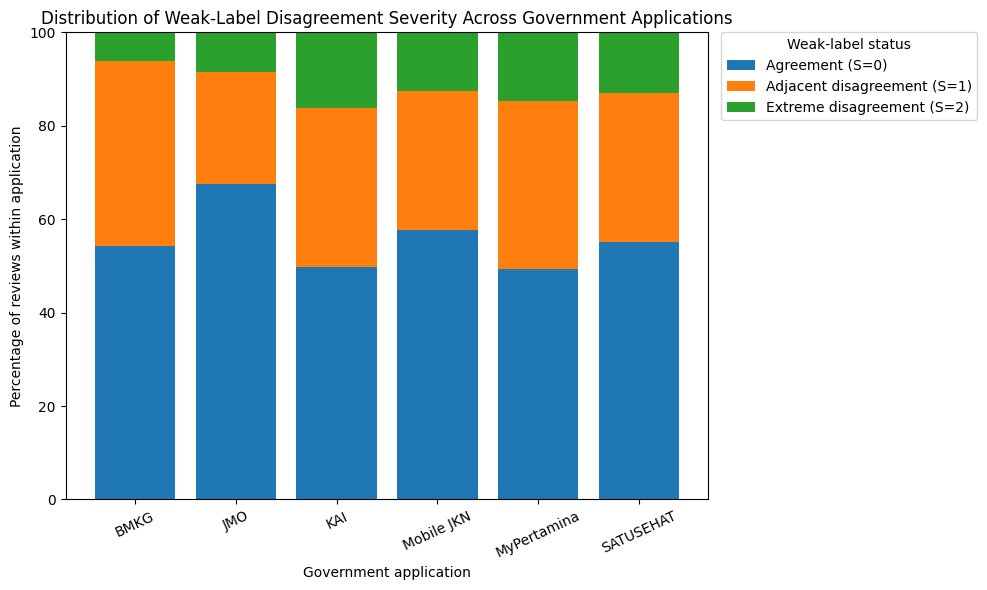

Saved: /content/drive/MyDrive/IGAR_Paper1/figures/Fig3_RQ2_Severity_By_Application_v2.png


In [25]:
# ============================================================
# [RQ2][OUTPUT] CELL 18 — Figure 3 v2
# Distribution of disagreement severity by application
#
# NOTE:
# - Presentation-layer normalization only.
# - Raw values in `phase1["app"]` are NOT modified.
# - Old Figure 3 is NOT overwritten.
# ============================================================

FIG3_FILE_V2 = (
    DIRS["figures"]
    / "Fig3_RQ2_Severity_By_Application_v2.png"
)

# ------------------------------------------------------------
# Display-name mapping ONLY for manuscript visualization
# ------------------------------------------------------------

APP_DISPLAY = {
    "BMKG": "BMKG",
    "JMO": "JMO",
    "KAI": "KAI",
    "mobileJKN": "Mobile JKN",
    "pertamina": "MyPertamina",
    "satusehat": "SATUSEHAT",
}

# ------------------------------------------------------------
# Build severity distribution
# ------------------------------------------------------------

plot_df = (
    phase1
    .groupby(
        ["app", "severity"],
        observed=False
    )
    .size()
    .rename("N")
    .reset_index()
)

plot_df["pct_within_app"] = (
    plot_df["N"]
    /
    plot_df
    .groupby("app")["N"]
    .transform("sum")
    *
    100
)

# Presentation name only
plot_df["app_display"] = (
    plot_df["app"]
    .map(APP_DISPLAY)
    .fillna(
        plot_df["app"].astype(str)
    )
)

# ------------------------------------------------------------
# Keep application order stable
# ------------------------------------------------------------

APP_ORDER_RAW = [
    "BMKG",
    "JMO",
    "KAI",
    "mobileJKN",
    "pertamina",
    "satusehat",
]

APP_ORDER_DISPLAY = [
    APP_DISPLAY[x]
    for x in APP_ORDER_RAW
]

pivot = (
    plot_df
    .pivot(
        index="app_display",
        columns="severity",
        values="pct_within_app"
    )
    .fillna(0)
    .reindex(APP_ORDER_DISPLAY)
)

# ------------------------------------------------------------
# Publication figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

severity_labels = {
    0: "Agreement (S=0)",
    1: "Adjacent disagreement (S=1)",
    2: "Extreme disagreement (S=2)",
}

bottom = np.zeros(
    len(pivot)
)

for sev in [0, 1, 2]:

    values = (
        pivot[sev].to_numpy()
        if sev in pivot.columns
        else np.zeros(len(pivot))
    )

    ax.bar(
        pivot.index.astype(str),
        values,
        bottom=bottom,
        label=severity_labels[sev],
    )

    bottom += values

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_ylim(
    0,
    100
)

ax.set_ylabel(
    "Percentage of reviews within application"
)

ax.set_xlabel(
    "Government application"
)

ax.set_title(
    "Distribution of Weak-Label Disagreement Severity "
    "Across Government Applications"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.legend(
    title="Weak-label status",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

fig.tight_layout()

# ------------------------------------------------------------
# Save directly to Google Drive
# ------------------------------------------------------------

fig.savefig(
    FIG3_FILE_V2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    FIG3_FILE_V2
)

In [26]:
# ============================================================
# [RQ2][OUTPUT] CELL 19 — Figure 4 v2
# Disagreement-only Sankey:
# Rating-derived weak label -> Translation-mediated VADER label
#
# NOTE:
# - Only D=1 cases are visualized.
# - Agreement cases are intentionally excluded.
# - Percentages use TOTAL DISAGREEMENTS as denominator.
# - Original Sankey is NOT overwritten.
# ============================================================

FIG4_HTML_V2 = (
    DIRS["figures"]
    / "Fig4_RQ2_Disagreement_Only_Sankey.html"
)

# ------------------------------------------------------------
# Restrict visualization to disagreement cases
# ------------------------------------------------------------

disagreement_only = (
    phase1.loc[
        phase1["disagreement"] == 1
    ]
    .copy()
)

TOTAL_DISAGREEMENT = len(
    disagreement_only
)

assert (
    TOTAL_DISAGREEMENT
    ==
    int(
        phase1[
            "disagreement"
        ].sum()
    )
)

print(
    "Total disagreement cases:",
    f"{TOTAL_DISAGREEMENT:,}"
)

# ------------------------------------------------------------
# Sankey nodes
# ------------------------------------------------------------

sentiment_order = [
    "Negative",
    "Neutral",
    "Positive",
]

source_labels = [
    "Rating-derived Negative",
    "Rating-derived Neutral",
    "Rating-derived Positive",
]

target_labels = [
    "VADER Negative",
    "VADER Neutral",
    "VADER Positive",
]

node_labels = (
    source_labels
    +
    target_labels
)

source_index = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

target_index = {
    "Negative": 3,
    "Neutral": 4,
    "Positive": 5,
}

# ------------------------------------------------------------
# Count disagreement transitions
# ------------------------------------------------------------

transition_counts = (
    disagreement_only
    .groupby(
        [
            "rating_label",
            "vader_label"
        ],
        observed=False
    )
    .size()
)

sankey_sources = []
sankey_targets = []
sankey_values = []
sankey_hover = []

# ------------------------------------------------------------
# Add ONLY off-diagonal transitions
# ------------------------------------------------------------

for rating_sentiment in sentiment_order:

    for vader_sentiment in sentiment_order:

        # Skip agreement
        if (
            rating_sentiment
            ==
            vader_sentiment
        ):
            continue

        count = int(
            transition_counts.get(
                (
                    rating_sentiment,
                    vader_sentiment
                ),
                0
            )
        )

        if count == 0:
            continue

        pct_disagreement = (
            count
            /
            TOTAL_DISAGREEMENT
            *
            100
        )

        sankey_sources.append(
            source_index[
                rating_sentiment
            ]
        )

        sankey_targets.append(
            target_index[
                vader_sentiment
            ]
        )

        sankey_values.append(
            count
        )

        sankey_hover.append(
            (
                f"{rating_sentiment} → "
                f"{vader_sentiment}<br>"
                f"N = {count:,}<br>"
                f"{pct_disagreement:.2f}% "
                "of all disagreements"
            )
        )

# ------------------------------------------------------------
# Internal validation
# ------------------------------------------------------------

assert (
    sum(sankey_values)
    ==
    TOTAL_DISAGREEMENT
), (
    "Sankey disagreement total "
    "does not equal total D=1."
)

print(
    "Sankey flow total:",
    f"{sum(sankey_values):,}"
)

# ------------------------------------------------------------
# Create Sankey
# ------------------------------------------------------------

fig = go.Figure(
    data=[
        go.Sankey(

            node=dict(
                label=node_labels,
                pad=20,
                thickness=20,
            ),

            link=dict(
                source=sankey_sources,
                target=sankey_targets,
                value=sankey_values,
                customdata=sankey_hover,
                hovertemplate=(
                    "%{customdata}"
                    "<extra></extra>"
                ),
            ),
        )
    ]
)

fig.update_layout(
    title_text=(
        "Structure of Weak-Label Disagreement: "
        "Rating-Derived vs Translation-Mediated "
        "VADER Sentiment"
    ),

    font_size=12,

    margin=dict(
        l=30,
        r=30,
        t=70,
        b=30
    ),
)

# ------------------------------------------------------------
# Save self-contained HTML directly to Drive
# ------------------------------------------------------------

fig.write_html(
    str(FIG4_HTML_V2),
    include_plotlyjs=True,
    full_html=True,
)

fig.show()

print(
    "Saved:",
    FIG4_HTML_V2
)

Total disagreement cases: 255,414
Sankey flow total: 255,414


Saved: /content/drive/MyDrive/IGAR_Paper1/figures/Fig4_RQ2_Disagreement_Only_Sankey.html


In [27]:
# ============================================================
# [RQ2][OUTPUT] CELL 20 FINAL
# Freeze RQ2 summary using FINAL manuscript artifacts
#
# Answers:
#   RQ2 — How are weak-label disagreement and disagreement
#   severity distributed across sentiment transitions,
#   star ratings, and government application domains?
#
# IMPORTANT:
# - Uses Figure 3 v2
# - Uses disagreement-only Figure 4
# - Saves H2 evidence summary
# ============================================================

RQ2_SUMMARY_FILE = (
    DIRS["statistics"]
    / "RQ2_summary_FINAL.json"
)

# ------------------------------------------------------------
# Final artifact paths
# ------------------------------------------------------------

FIG3_FINAL = (
    DIRS["figures"]
    / "Fig3_RQ2_Severity_By_Application_v2.png"
)

FIG4_FINAL = (
    DIRS["figures"]
    / "Fig4_RQ2_Disagreement_Only_Sankey.html"
)

TABLE3_FINAL = (
    DIRS["tables"]
    / "Table3_RQ2_Transition_Structure.csv"
)

TABLE4_FINAL = (
    DIRS["tables"]
    / "Table4_RQ2_Domain_Disagreement_Severity.csv"
)

RATING_STRUCTURE_FINAL = (
    DIRS["tables"]
    / "RQ2_Disagreement_By_StarRating.csv"
)

RQ2_TEST_FINAL = (
    DIRS["statistics"]
    / "RQ2_ChiSquare_CramersV.csv"
)

# ------------------------------------------------------------
# Load from Drive
# This makes Cell 20 safer after reconnect.
# ------------------------------------------------------------

table3_final = pd.read_csv(
    TABLE3_FINAL
)

table4_final = pd.read_csv(
    TABLE4_FINAL
)

rating_structure_final = pd.read_csv(
    RATING_STRUCTURE_FINAL
)

rq2_tests_final = pd.read_csv(
    RQ2_TEST_FINAL
)

# ------------------------------------------------------------
# Severity summary
# ------------------------------------------------------------

severity_summary = (
    phase1["severity"]
    .value_counts()
    .sort_index()
)

severity0_n = int(
    severity_summary.get(
        0,
        0
    )
)

severity1_n = int(
    severity_summary.get(
        1,
        0
    )
)

severity2_n = int(
    severity_summary.get(
        2,
        0
    )
)

total_n = int(
    len(phase1)
)

total_disagreement = int(
    phase1[
        "disagreement"
    ].sum()
)

assert (
    severity0_n
    +
    severity1_n
    +
    severity2_n
    ==
    total_n
)

assert (
    severity1_n
    +
    severity2_n
    ==
    total_disagreement
)

severity1_share_disagreement = (
    severity1_n
    /
    total_disagreement
    *
    100
)

severity2_share_disagreement = (
    severity2_n
    /
    total_disagreement
    *
    100
)

# ------------------------------------------------------------
# Transition summaries
# ------------------------------------------------------------

transition_lookup = dict(
    zip(
        table3_final[
            "transition_type"
        ],
        table3_final["N"]
    )
)

negative_to_neutral = int(
    transition_lookup.get(
        "Negative->Neutral",
        0
    )
)

positive_to_neutral = int(
    transition_lookup.get(
        "Positive->Neutral",
        0
    )
)

negative_to_positive = int(
    transition_lookup.get(
        "Negative->Positive",
        0
    )
)

positive_to_negative = int(
    transition_lookup.get(
        "Positive->Negative",
        0
    )
)

to_neutral_n = (
    negative_to_neutral
    +
    positive_to_neutral
)

extreme_n = (
    negative_to_positive
    +
    positive_to_negative
)

to_neutral_share_disagreement = (
    to_neutral_n
    /
    total_disagreement
    *
    100
)

extreme_share_disagreement = (
    extreme_n
    /
    total_disagreement
    *
    100
)

# ------------------------------------------------------------
# Domain extremes
# ------------------------------------------------------------

highest_domain_row = (
    table4_final
    .sort_values(
        "disagreement_pct",
        ascending=False
    )
    .iloc[0]
)

lowest_domain_row = (
    table4_final
    .sort_values(
        "disagreement_pct",
        ascending=True
    )
    .iloc[0]
)

highest_extreme_domain_row = (
    table4_final
    .sort_values(
        "severity2_share_of_disagreement_pct",
        ascending=False
    )
    .iloc[0]
)

# ------------------------------------------------------------
# Star-rating extremes
# ------------------------------------------------------------

highest_rating_row = (
    rating_structure_final
    .sort_values(
        "disagreement_pct",
        ascending=False
    )
    .iloc[0]
)

lowest_rating_row = (
    rating_structure_final
    .sort_values(
        "disagreement_pct",
        ascending=True
    )
    .iloc[0]
)

# ------------------------------------------------------------
# Statistical results
# ------------------------------------------------------------

def get_test_result(
    test_name
):

    row = (
        rq2_tests_final.loc[
            rq2_tests_final[
                "test"
            ]
            ==
            test_name
        ]
    )

    assert len(row) == 1, (
        f"Expected exactly one result "
        f"for {test_name}"
    )

    return row.iloc[0]


app_disagreement_test = (
    get_test_result(
        "application_x_disagreement"
    )
)

score_disagreement_test = (
    get_test_result(
        "score_x_disagreement"
    )
)

app_severity_test = (
    get_test_result(
        "application_x_severity"
    )
)

score_severity_test = (
    get_test_result(
        "score_x_severity"
    )
)

# ------------------------------------------------------------
# Freeze scientific interpretation
#
# Note:
# H2 is supported because descriptive structure and
# inferential association are consistent.
#
# We do NOT call domain effect "strong".
# ------------------------------------------------------------

rq2_summary = {

    "research_question": (
        "How are weak-label disagreement and disagreement "
        "severity distributed across sentiment transitions, "
        "star ratings, and government application domains?"
    ),

    "hypothesis": (
        "H2: The frequency and severity of weak-label "
        "disagreement vary systematically across sentiment "
        "transitions, star ratings, and application domains."
    ),

    "hypothesis_status": "SUPPORTED",

    "N": total_n,

    "agreement": {
        "N": severity0_n,
        "pct_total":
            severity0_n
            /
            total_n
            *
            100,
    },

    "disagreement": {
        "N": total_disagreement,
        "pct_total":
            total_disagreement
            /
            total_n
            *
            100,
    },

    "severity": {

        "severity_1_adjacent": {
            "N": severity1_n,
            "pct_total":
                severity1_n
                /
                total_n
                *
                100,
            "pct_of_disagreement":
                severity1_share_disagreement,
        },

        "severity_2_extreme": {
            "N": severity2_n,
            "pct_total":
                severity2_n
                /
                total_n
                *
                100,
            "pct_of_disagreement":
                severity2_share_disagreement,
        },
    },

    "transition_structure": {

        "negative_to_neutral": {
            "N":
                negative_to_neutral,
            "pct_of_disagreement":
                negative_to_neutral
                /
                total_disagreement
                *
                100,
        },

        "positive_to_neutral": {
            "N":
                positive_to_neutral,
            "pct_of_disagreement":
                positive_to_neutral
                /
                total_disagreement
                *
                100,
        },

        "transitions_to_vader_neutral": {
            "N":
                to_neutral_n,
            "pct_of_disagreement":
                to_neutral_share_disagreement,
        },

        "extreme_polarity_reversals": {
            "N":
                extreme_n,
            "pct_of_disagreement":
                extreme_share_disagreement,
        },

        "negative_to_positive": {
            "N":
                negative_to_positive,
        },

        "positive_to_negative": {
            "N":
                positive_to_negative,
        },
    },

    "domain_pattern": {

        "highest_disagreement_app":
            str(
                highest_domain_row[
                    "app"
                ]
            ),

        "highest_disagreement_pct":
            float(
                highest_domain_row[
                    "disagreement_pct"
                ]
            ),

        "lowest_disagreement_app":
            str(
                lowest_domain_row[
                    "app"
                ]
            ),

        "lowest_disagreement_pct":
            float(
                lowest_domain_row[
                    "disagreement_pct"
                ]
            ),

        "highest_extreme_share_app":
            str(
                highest_extreme_domain_row[
                    "app"
                ]
            ),

        "highest_extreme_share_of_disagreement_pct":
            float(
                highest_extreme_domain_row[
                    "severity2_share_of_disagreement_pct"
                ]
            ),
    },

    "star_rating_pattern": {

        "highest_disagreement_score":
            int(
                highest_rating_row[
                    "score"
                ]
            ),

        "highest_disagreement_pct":
            float(
                highest_rating_row[
                    "disagreement_pct"
                ]
            ),

        "lowest_disagreement_score":
            int(
                lowest_rating_row[
                    "score"
                ]
            ),

        "lowest_disagreement_pct":
            float(
                lowest_rating_row[
                    "disagreement_pct"
                ]
            ),
    },

    "inferential_statistics": {

        "application_x_disagreement": {
            "chi2":
                float(
                    app_disagreement_test[
                        "chi2"
                    ]
                ),
            "dof":
                int(
                    app_disagreement_test[
                        "dof"
                    ]
                ),
            "p_reporting":
                "<0.001",
            "cramers_v":
                float(
                    app_disagreement_test[
                        "cramers_v"
                    ]
                ),
        },

        "score_x_disagreement": {
            "chi2":
                float(
                    score_disagreement_test[
                        "chi2"
                    ]
                ),
            "dof":
                int(
                    score_disagreement_test[
                        "dof"
                    ]
                ),
            "p_reporting":
                "<0.001",
            "cramers_v":
                float(
                    score_disagreement_test[
                        "cramers_v"
                    ]
                ),
        },

        "application_x_severity": {
            "chi2":
                float(
                    app_severity_test[
                        "chi2"
                    ]
                ),
            "dof":
                int(
                    app_severity_test[
                        "dof"
                    ]
                ),
            "p_reporting":
                "<0.001",
            "cramers_v":
                float(
                    app_severity_test[
                        "cramers_v"
                    ]
                ),
        },

        "score_x_severity": {
            "chi2":
                float(
                    score_severity_test[
                        "chi2"
                    ]
                ),
            "dof":
                int(
                    score_severity_test[
                        "dof"
                    ]
                ),
            "p_reporting":
                "<0.001",
            "cramers_v":
                float(
                    score_severity_test[
                        "cramers_v"
                    ]
                ),
        },
    },

    "interpretation_guardrails": [

        (
            "Do not interpret VADER as ground truth."
        ),

        (
            "Do not interpret disagreement as confirmed "
            "mislabeling."
        ),

        (
            "Application-domain associations are statistically "
            "significant but modest in magnitude."
        ),

        (
            "Star rating shows a substantially stronger "
            "association with disagreement than application."
        ),

        (
            "The score-by-severity association is partly "
            "structural because Neutral rating-derived labels "
            "cannot produce severity 2 under the predefined "
            "severity coding."
        ),
    ],

    "artifacts": {

        "table3":
            str(
                TABLE3_FINAL
            ),

        "table4":
            str(
                TABLE4_FINAL
            ),

        "star_rating_table":
            str(
                RATING_STRUCTURE_FINAL
            ),

        "statistical_tests":
            str(
                RQ2_TEST_FINAL
            ),

        "figure3_final":
            str(
                FIG3_FINAL
            ),

        "figure4_final":
            str(
                FIG4_FINAL
            ),
    },

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}

# ------------------------------------------------------------
# Save safely
# ------------------------------------------------------------

atomic_json_save(
    rq2_summary,
    RQ2_SUMMARY_FILE
)

set_state(
    "rq2",
    "complete"
)

print(
    "✓ RQ2 FINAL SUMMARY SAVED"
)

print(
    "File:",
    RQ2_SUMMARY_FILE
)

print(
    "\nH2 status:",
    rq2_summary[
        "hypothesis_status"
    ]
)

print(
    "\nSeverity 1:",
    f"{severity1_n:,}",
    f"({severity1_share_disagreement:.2f}% "
    "of disagreements)"
)

print(
    "Severity 2:",
    f"{severity2_n:,}",
    f"({severity2_share_disagreement:.2f}% "
    "of disagreements)"
)

print(
    "\nTransitions to VADER Neutral:",
    f"{to_neutral_n:,}",
    f"({to_neutral_share_disagreement:.2f}% "
    "of disagreements)"
)

print(
    "Extreme polarity reversals:",
    f"{extreme_n:,}",
    f"({extreme_share_disagreement:.2f}% "
    "of disagreements)"
)

✓ RQ2 FINAL SUMMARY SAVED
File: /content/drive/MyDrive/IGAR_Paper1/results/statistics/RQ2_summary_FINAL.json

H2 status: SUPPORTED

Severity 1: 183,004 (71.65% of disagreements)
Severity 2: 72,410 (28.35% of disagreements)

Transitions to VADER Neutral: 160,979 (63.03% of disagreements)
Extreme polarity reversals: 72,410 (28.35% of disagreements)


In [28]:
# ============================================================
# [GATE][OUTPUT][REPRODUCIBILITY] CELL 21 FINAL
#
# FINAL PHASE-1 SCIENTIFIC + ARTIFACT CONSISTENCY CHECK
#
# Validates:
# - Gate 1–4 PASS
# - RQ1/RQ2 artifacts readable
# - N consistency
# - transition totals
# - severity totals
# - disagreement totals
# - final figures exist
# - four RQ2 statistical tests exist
#
# Creates:
# phase1_manifest_FINAL_<PHASE1_ID>.json
# ============================================================

FINAL_VALIDATION_FILE = (
    DIRS["logs"]
    /
    f"phase1_final_validation_{PHASE1_ID}.json"
)

PHASE1_MANIFEST = (
    DIRS["logs"]
    /
    f"phase1_manifest_FINAL_{PHASE1_ID}.json"
)

validation_errors = []
validation_checks = {}

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def check(
    condition,
    name,
    error_message
):

    validation_checks[
        name
    ] = bool(condition)

    if not condition:

        validation_errors.append(
            error_message
        )


# ============================================================
# 1. Validate Gate JSON files
# ============================================================

gate_files = {

    "gate1":
        DIRS["gates"]
        /
        "gate1_dataset_identity.json",

    "gate2":
        DIRS["gates"]
        /
        "gate2_schema_validation.json",

    "gate3":
        DIRS["gates"]
        /
        "gate3_label_reproduction.json",

    "gate4":
        DIRS["gates"]
        /
        "gate4_agreement_replication.json",
}

gate_results = {}

for gate_name, gate_path in (
    gate_files.items()
):

    check(
        valid_json(
            gate_path
        ),
        f"{gate_name}_artifact_readable",
        f"{gate_name} JSON is missing or unreadable"
    )

    if valid_json(
        gate_path
    ):

        with open(
            gate_path,
            encoding="utf-8"
        ) as f:

            gate_result = json.load(
                f
            )

        gate_results[
            gate_name
        ] = gate_result

        check(
            gate_result.get(
                "status"
            )
            ==
            "PASS",

            f"{gate_name}_status_pass",

            (
                f"{gate_name} status is not PASS: "
                f"{gate_result.get('status')}"
            )
        )


# ============================================================
# 2. Dataset identity
# ============================================================

check(
    len(phase1)
    ==
    EXPECTED_ROWS,

    "dataset_row_count",

    (
        f"phase1 row count "
        f"{len(phase1)} != "
        f"{EXPECTED_ROWS}"
    )
)


# ============================================================
# 3. Rating label reproduction
# ============================================================

rating_counts_check = (
    phase1[
        "rating_label"
    ]
    .value_counts()
    .to_dict()
)

for label, expected in (
    EXPECTED_RATING_COUNTS
    .items()
):

    actual = int(
        rating_counts_check.get(
            label,
            0
        )
    )

    check(
        actual == expected,

        f"rating_count_{label}",

        (
            f"Rating {label}: "
            f"{actual} != {expected}"
        )
    )


# ============================================================
# 4. VADER label reproduction
# ============================================================

vader_counts_check = (
    phase1[
        "vader_label"
    ]
    .value_counts()
    .to_dict()
)

for label, expected in (
    EXPECTED_VADER_COUNTS
    .items()
):

    actual = int(
        vader_counts_check.get(
            label,
            0
        )
    )

    check(
        actual == expected,

        f"vader_count_{label}",

        (
            f"VADER {label}: "
            f"{actual} != {expected}"
        )
    )


# ============================================================
# 5. RQ1 consistency
# ============================================================

actual_agreement_n = int(
    (
        phase1[
            "rating_label"
        ]
        ==
        phase1[
            "vader_label"
        ]
    ).sum()
)

actual_disagreement_n = int(
    phase1[
        "disagreement"
    ].sum()
)

check(
    (
        actual_agreement_n
        +
        actual_disagreement_n
    )
    ==
    EXPECTED_ROWS,

    "agreement_disagreement_total",

    (
        "Agreement + disagreement "
        "does not equal total N."
    )
)

check(
    abs(
        agreement_rate
        -
        EXPECTED_AGREEMENT
    )
    <=
    AGREEMENT_TOLERANCE,

    "agreement_replication",

    (
        "Agreement rate is outside "
        "registered tolerance."
    )
)

check(
    abs(
        kappa
        -
        EXPECTED_KAPPA
    )
    <=
    KAPPA_TOLERANCE,

    "kappa_replication",

    (
        "Cohen's kappa is outside "
        "registered tolerance."
    )
)


# ============================================================
# 6. Load final RQ2 artifacts
# ============================================================

try:

    table3_check = pd.read_csv(
        TABLE3_FINAL
    )

except Exception as e:

    table3_check = None

    validation_errors.append(
        f"Table 3 unreadable: {e}"
    )


try:

    table4_check = pd.read_csv(
        TABLE4_FINAL
    )

except Exception as e:

    table4_check = None

    validation_errors.append(
        f"Table 4 unreadable: {e}"
    )


try:

    rating_check = pd.read_csv(
        RATING_STRUCTURE_FINAL
    )

except Exception as e:

    rating_check = None

    validation_errors.append(
        f"Star-rating table unreadable: {e}"
    )


try:

    tests_check = pd.read_csv(
        RQ2_TEST_FINAL
    )

except Exception as e:

    tests_check = None

    validation_errors.append(
        f"RQ2 tests unreadable: {e}"
    )


# ============================================================
# 7. Transition consistency
# ============================================================

if table3_check is not None:

    check(
        int(
            table3_check[
                "N"
            ].sum()
        )
        ==
        EXPECTED_ROWS,

        "transition_total",

        (
            "Table 3 transition total "
            "does not equal dataset N."
        )
    )

    disagreement_transition_n = int(

        table3_check.loc[
            table3_check[
                "is_disagreement"
            ]
            ==
            1,

            "N"
        ].sum()
    )

    check(
        disagreement_transition_n
        ==
        actual_disagreement_n,

        "transition_disagreement_total",

        (
            "Off-diagonal transitions "
            "do not equal disagreement N."
        )
    )


# ============================================================
# 8. Severity consistency
# ============================================================

severity0_check = int(
    (
        phase1[
            "severity"
        ]
        ==
        0
    ).sum()
)

severity1_check = int(
    (
        phase1[
            "severity"
        ]
        ==
        1
    ).sum()
)

severity2_check = int(
    (
        phase1[
            "severity"
        ]
        ==
        2
    ).sum()
)

check(
    (
        severity0_check
        +
        severity1_check
        +
        severity2_check
    )
    ==
    EXPECTED_ROWS,

    "severity_total",

    (
        "Severity 0+1+2 "
        "does not equal N."
    )
)

check(
    (
        severity1_check
        +
        severity2_check
    )
    ==
    actual_disagreement_n,

    "severity_disagreement_total",

    (
        "Severity 1+2 "
        "does not equal disagreement N."
    )
)


# ============================================================
# 9. Domain table consistency
# ============================================================

if table4_check is not None:

    check(
        int(
            table4_check[
                "N"
            ].sum()
        )
        ==
        EXPECTED_ROWS,

        "domain_total",

        (
            "Table 4 domain total "
            "does not equal N."
        )
    )

    required_table4_columns = {

        "severity1_share_of_disagreement_pct",

        "severity2_share_of_disagreement_pct",
    }

    check(
        required_table4_columns
        .issubset(
            set(
                table4_check.columns
            )
        ),

        "table4_final_columns",

        (
            "Table 4 does not contain "
            "final disagreement-share columns."
        )
    )


# ============================================================
# 10. Star rating table consistency
# ============================================================

if rating_check is not None:

    check(
        int(
            rating_check[
                "N"
            ].sum()
        )
        ==
        EXPECTED_ROWS,

        "star_rating_total",

        (
            "Star-rating table total "
            "does not equal N."
        )
    )

    check(
        set(
            rating_check[
                "score"
            ].astype(int)
        )
        ==
        {1, 2, 3, 4, 5},

        "star_rating_levels",

        (
            "Star-rating table does not "
            "contain exactly scores 1-5."
        )
    )


# ============================================================
# 11. Four statistical tests required
# ============================================================

EXPECTED_RQ2_TESTS = {

    "application_x_disagreement",

    "score_x_disagreement",

    "application_x_severity",

    "score_x_severity",
}

if tests_check is not None:

    actual_tests = set(
        tests_check[
            "test"
        ]
    )

    check(
        EXPECTED_RQ2_TESTS
        ==
        actual_tests,

        "four_rq2_tests",

        (
            "RQ2 statistical output "
            "does not contain exactly "
            "the four registered tests."
        )
    )

    check(
        bool(
            (
                tests_check[
                    "min_expected_count"
                ]
                >
                5
            )
            .all()
        ),

        "chi_square_expected_counts",

        (
            "At least one chi-square test "
            "has expected count <= 5."
        )
    )


# ============================================================
# 12. Final figures
# ============================================================

check(
    FIG3_FINAL.exists(),

    "figure3_final_exists",

    (
        f"Final Figure 3 missing: "
        f"{FIG3_FINAL}"
    )
)

check(
    FIG4_FINAL.exists(),

    "figure4_final_exists",

    (
        f"Final Figure 4 missing: "
        f"{FIG4_FINAL}"
    )
)


# ============================================================
# 13. RQ summaries
# ============================================================

check(
    valid_json(
        RQ1_SUMMARY_FILE
    ),

    "rq1_summary_readable",

    "RQ1 summary JSON missing/unreadable."
)

check(
    valid_json(
        RQ2_SUMMARY_FILE
    ),

    "rq2_summary_readable",

    "Final RQ2 summary JSON missing/unreadable."
)


# ============================================================
# Final status
# ============================================================

FINAL_PASS = (
    len(
        validation_errors
    )
    ==
    0
)

validation_report = {

    "status":
        (
            "PASS"
            if FINAL_PASS
            else
            "FAIL"
        ),

    "phase1_id":
        PHASE1_ID,

    "dataset_sha256":
        current_fp[
            "sha256"
        ],

    "N":
        EXPECTED_ROWS,

    "checks":
        validation_checks,

    "errors":
        validation_errors,

    "validated_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    validation_report,
    FINAL_VALIDATION_FILE
)

# ------------------------------------------------------------
# STOP if validation fails
# ------------------------------------------------------------

if not FINAL_PASS:

    print(
        "✗ PHASE 1 FINAL VALIDATION FAILED"
    )

    print(
        "\nProblems:"
    )

    for error in (
        validation_errors
    ):

        print(
            "-",
            error
        )

    raise RuntimeError(
        "Phase 1 cannot be closed. "
        "Resolve validation errors first."
    )


# ============================================================
# Create final manifest only after all checks PASS
# ============================================================

required_artifacts = [

    gate_files[
        "gate1"
    ],

    gate_files[
        "gate2"
    ],

    gate_files[
        "gate3"
    ],

    gate_files[
        "gate4"
    ],

    TABLE2_FILE,

    CM_COUNT_FILE,

    CM_ROWPCT_FILE,

    RQ1_SUMMARY_FILE,

    TABLE3_FINAL,

    TABLE4_FINAL,

    RATING_STRUCTURE_FINAL,

    RQ2_TEST_FINAL,

    RQ2_SUMMARY_FILE,

    FIG2_FILE,

    FIG3_FINAL,

    FIG4_FINAL,

    FINAL_VALIDATION_FILE,
]

manifest = {

    "status":
        "COMPLETE",

    "phase":
        "Phase 1",

    "phase1_id":
        PHASE1_ID,

    "dataset_sha256":
        current_fp[
            "sha256"
        ],

    "dataset_N":
        EXPECTED_ROWS,

    "rq1_status":
        "COMPLETE",

    "rq2_status":
        "COMPLETE",

    "H1_status":
        (
            "REPLICATION EXPECTATION "
            "CONFIRMED"
        ),

    "H2_status":
        "SUPPORTED",

    "agreement_pct":
        float(
            agreement_rate
            *
            100
        ),

    "disagreement_pct":
        float(
            disagreement_rate
            *
            100
        ),

    "cohen_kappa":
        float(
            kappa
        ),

    "severity1_N":
        severity1_check,

    "severity2_N":
        severity2_check,

    "artifacts": [
        str(x)
        for x
        in required_artifacts
    ],

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    manifest,
    PHASE1_MANIFEST
)

print(
    "✓ PHASE 1 FINAL VALIDATION PASSED"
)

print(
    "✓ FINAL MANIFEST CREATED"
)

print(
    "\nManifest:",
    PHASE1_MANIFEST
)

print(
    "\nValidation report:",
    FINAL_VALIDATION_FILE
)

✓ PHASE 1 FINAL VALIDATION PASSED
✓ FINAL MANIFEST CREATED

Manifest: /content/drive/MyDrive/IGAR_Paper1/results/logs/phase1_manifest_FINAL_f11658d4e59a.json

Validation report: /content/drive/MyDrive/IGAR_Paper1/results/logs/phase1_final_validation_f11658d4e59a.json


In [29]:
# ============================================================
# [OUTPUT] CELL 22 FINAL
#
# PAPER 1 — PHASE 1 FINAL SCIENTIFIC DASHBOARD
#
# This is the SINGLE SOURCE OF TRUTH
# for Phase-1 reporting.
# ============================================================

# ------------------------------------------------------------
# Reload final persisted artifacts
# ------------------------------------------------------------

state = load_state()

with open(
    PHASE1_MANIFEST,
    encoding="utf-8"
) as f:

    final_manifest = json.load(
        f
    )

with open(
    RQ2_SUMMARY_FILE,
    encoding="utf-8"
) as f:

    final_rq2 = json.load(
        f
    )

rq2_tests_dashboard = (
    pd.read_csv(
        RQ2_TEST_FINAL
    )
)

table2_dashboard = (
    pd.read_csv(
        TABLE2_FILE
    )
)

table3_dashboard = (
    pd.read_csv(
        TABLE3_FINAL
    )
)

table4_dashboard = (
    pd.read_csv(
        TABLE4_FINAL
    )
)

rating_dashboard = (
    pd.read_csv(
        RATING_STRUCTURE_FINAL
    )
)

# ------------------------------------------------------------
# Header
# ------------------------------------------------------------

print(
    "=" * 88
)

print(
    "PAPER 1 — PHASE 1 FINAL SCIENTIFIC DASHBOARD"
)

print(
    "=" * 88
)

print(
    f"Phase-1 ID       : "
    f"{PHASE1_ID}"
)

print(
    f"Dataset SHA-256  : "
    f"{current_fp['sha256']}"
)

print(
    f"Dataset N        : "
    f"{EXPECTED_ROWS:,}"
)

print(
    "-" * 88
)

# ------------------------------------------------------------
# Gates
# ------------------------------------------------------------

print(
    "GO / NO-GO GATES"
)

print(
    "-" * 88
)

for gate in [
    "gate1",
    "gate2",
    "gate3",
    "gate4",
]:

    print(
        f"{gate.upper():15s}: "
        f"{state.get(gate)}"
    )

print(
    "-" * 88
)

# ------------------------------------------------------------
# RQ1
# ------------------------------------------------------------

print(
    "RQ1 — MAGNITUDE OF WEAK-LABEL AGREEMENT"
)

print(
    "-" * 88
)

print(
    f"Agreement N      : "
    f"{actual_agreement_n:,}"
)

print(
    f"Agreement %      : "
    f"{agreement_rate*100:.4f}%"
)

print(
    f"Disagreement N   : "
    f"{actual_disagreement_n:,}"
)

print(
    f"Disagreement %   : "
    f"{disagreement_rate*100:.4f}%"
)

print(
    f"Cohen's kappa    : "
    f"{kappa:.6f}"
)

print(
    f"RQ1 status       : COMPLETE"
)

print(
    f"H1 status        : "
    f"REPLICATION EXPECTATION CONFIRMED"
)

print(
    "-" * 88
)

# ------------------------------------------------------------
# RQ2
# ------------------------------------------------------------

print(
    "RQ2 — STRUCTURE AND SEVERITY"
)

print(
    "-" * 88
)

print(
    f"Severity 1 N     : "
    f"{severity1_check:,}"
)

print(
    f"Severity 1 share : "
    f"{final_rq2['severity']['severity_1_adjacent']['pct_of_disagreement']:.2f}% "
    "of disagreements"
)

print(
    f"Severity 2 N     : "
    f"{severity2_check:,}"
)

print(
    f"Severity 2 share : "
    f"{final_rq2['severity']['severity_2_extreme']['pct_of_disagreement']:.2f}% "
    "of disagreements"
)

print()

print(
    "Transitions to VADER Neutral:"
)

print(
    f"  N              : "
    f"{final_rq2['transition_structure']['transitions_to_vader_neutral']['N']:,}"
)

print(
    f"  % disagreement : "
    f"{final_rq2['transition_structure']['transitions_to_vader_neutral']['pct_of_disagreement']:.2f}%"
)

print()

print(
    "Extreme polarity reversals:"
)

print(
    f"  N              : "
    f"{final_rq2['transition_structure']['extreme_polarity_reversals']['N']:,}"
)

print(
    f"  % disagreement : "
    f"{final_rq2['transition_structure']['extreme_polarity_reversals']['pct_of_disagreement']:.2f}%"
)

print()

print(
    "Domain disagreement range:"
)

print(
    "  Highest        : "
    f"{final_rq2['domain_pattern']['highest_disagreement_app']} "
    f"({final_rq2['domain_pattern']['highest_disagreement_pct']:.2f}%)"
)

print(
    "  Lowest         : "
    f"{final_rq2['domain_pattern']['lowest_disagreement_app']} "
    f"({final_rq2['domain_pattern']['lowest_disagreement_pct']:.2f}%)"
)

print()

print(
    "Star-rating disagreement range:"
)

print(
    "  Highest        : "
    f"{final_rq2['star_rating_pattern']['highest_disagreement_score']} stars "
    f"({final_rq2['star_rating_pattern']['highest_disagreement_pct']:.2f}%)"
)

print(
    "  Lowest         : "
    f"{final_rq2['star_rating_pattern']['lowest_disagreement_score']} stars "
    f"({final_rq2['star_rating_pattern']['lowest_disagreement_pct']:.2f}%)"
)

print(
    f"\nRQ2 status       : COMPLETE"
)

print(
    f"H2 status        : "
    f"{final_rq2['hypothesis_status']}"
)

print(
    "=" * 88
)

# ------------------------------------------------------------
# Statistical effect-size dashboard
# ------------------------------------------------------------

print(
    "\nRQ2 INFERENTIAL STATISTICS"
)

print(
    "-" * 88
)

display(
    rq2_tests_dashboard[
        [
            "test",
            "chi2",
            "dof",
            "cramers_v",
            "min_expected_count",
        ]
    ]
)

print(
    "Reporting rule: p < 0.001; "
    "do NOT report p = 0."
)

print()

print(
    "Primary interpretation:"
)

print(
    "- Application is associated with disagreement, "
    "but the effect magnitude is modest."
)

print(
    "- Star rating shows a substantially stronger "
    "association with disagreement."
)

print(
    "- Severity composition also varies by application."
)

print(
    "- Score × severity must be interpreted cautiously "
    "because part of the association follows from the "
    "operational severity definition."
)

# ------------------------------------------------------------
# Manuscript tables
# ------------------------------------------------------------

print(
    "\n"
    +
    "=" * 88
)

print(
    "TABLE 2 — RQ1 AGREEMENT"
)

print(
    "=" * 88
)

display(
    table2_dashboard
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "TABLE 3 — SENTIMENT TRANSITIONS"
)

print(
    "=" * 88
)

display(
    table3_dashboard
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "TABLE 4 — DOMAIN-LEVEL SEVERITY"
)

print(
    "=" * 88
)

display(
    table4_dashboard
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "STAR-RATING STRUCTURE"
)

print(
    "=" * 88
)

display(
    rating_dashboard
)

# ------------------------------------------------------------
# Artifact locations
# ------------------------------------------------------------

print(
    "\n"
    +
    "=" * 88
)

print(
    "FINAL PHASE-1 ARTIFACTS"
)

print(
    "=" * 88
)

print(
    "Figure 2:",
    FIG2_FILE
)

print(
    "Figure 3:",
    FIG3_FINAL
)

print(
    "Figure 4:",
    FIG4_FINAL
)

print(
    "RQ1 summary:",
    RQ1_SUMMARY_FILE
)

print(
    "RQ2 summary:",
    RQ2_SUMMARY_FILE
)

print(
    "Validation:",
    FINAL_VALIDATION_FILE
)

print(
    "Manifest:",
    PHASE1_MANIFEST
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "PHASE 1 STATUS: COMPLETE / VALIDATED"
)

print(
    "=" * 88
)

print(
    "\nSTOP HERE."
)

print(
    "Do NOT start Gate 5, RQ3, or Transformer training "
    "until Phase-1 results have been formally reviewed."
)

PAPER 1 — PHASE 1 FINAL SCIENTIFIC DASHBOARD
Phase-1 ID       : f11658d4e59a
Dataset SHA-256  : 852c8b662224bd62418ef7b7dac15b9e43c9a6b4cdf0fef6239042203c2eccb0
Dataset N        : 617,722
----------------------------------------------------------------------------------------
GO / NO-GO GATES
----------------------------------------------------------------------------------------
GATE1          : passed
GATE2          : passed
GATE3          : passed
GATE4          : passed
----------------------------------------------------------------------------------------
RQ1 — MAGNITUDE OF WEAK-LABEL AGREEMENT
----------------------------------------------------------------------------------------
Agreement N      : 362,308
Agreement %      : 58.6523%
Disagreement N   : 255,414
Disagreement %   : 41.3477%
Cohen's kappa    : 0.333802
RQ1 status       : COMPLETE
H1 status        : REPLICATION EXPECTATION CONFIRMED
------------------------------------------------------------------------------------

,test,chi2,dof,cramers_v,min_expected_count
0,application_x_disagreement,11279.242766,5,0.135127,546.203460
1,score_x_disagreement,75642.637062,4,0.349935,12379.095687
2,application_x_severity,11587.662775,10,0.096847,154.848961
3,score_x_severity,114035.403925,8,0.303814,3509.479976


Reporting rule: p < 0.001; do NOT report p = 0.

Primary interpretation:
- Application is associated with disagreement, but the effect magnitude is modest.
- Star rating shows a substantially stronger association with disagreement.
- Severity composition also varies by application.
- Score × severity must be interpreted cautiously because part of the association follows from the operational severity definition.

TABLE 2 — RQ1 AGREEMENT


,scope,N,agreement_n,agreement_pct,disagreement_n,disagreement_pct,cohen_kappa
0,Overall,617722,362308,58.652274,255414,41.347726,0.333802
1,BMKG,1321,717,54.277063,604,45.722937,0.067550
2,JMO,200000,135080,67.540000,64920,32.460000,0.326864
3,KAI,7311,3633,49.692245,3678,50.307755,0.232125
4,mobileJKN,122103,70439,57.688181,51664,42.311819,0.316729
5,pertamina,96291,47537,49.368061,48754,50.631939,0.237193
6,satusehat,190696,104902,55.010068,85794,44.989932,0.299178



TABLE 3 — SENTIMENT TRANSITIONS


...


TABLE 4 — DOMAIN-LEVEL SEVERITY


,app,N,agreement_pct,disagreement_pct,disagreement_ci95_low_pct,disagreement_ci95_high_pct,severity1_pct,severity2_pct,severity1_share_of_disagreement_pct,severity2_share_of_disagreement_pct,cohen_kappa
0,BMKG,1321,54.277063,45.722937,43.052800,48.417878,39.666919,6.056018,86.754967,13.245033,0.067550
1,JMO,200000,67.540000,32.460000,32.255134,32.665540,24.014500,8.445500,73.981824,26.018176,0.326864
2,KAI,7311,49.692245,50.307755,49.161798,51.453390,34.140336,16.167419,67.862969,32.137031,0.232125
3,mobileJKN,122103,57.688181,42.311819,42.034950,42.589171,29.849389,12.462429,70.546222,29.453778,0.316729
4,pertamina,96291,49.368061,50.631939,50.316135,50.947691,35.918206,14.713732,70.939820,29.060180,0.237193
5,satusehat,190696,55.010068,44.989932,44.766752,45.213314,31.947183,13.042749,71.009628,28.990372,0.299178



STAR-RATING STRUCTURE


,score,N,agreement_pct,disagreement_pct,disagreement_ci95_low_pct,disagreement_ci95_high_pct,severity1_pct,severity2_pct,severity1_share_of_disagreement_pct,severity2_share_of_disagreement_pct
0,1,216959,42.090441,57.909559,57.701678,58.117160,34.533253,23.376306,59.633079,40.366921
1,2,29939,31.343732,68.656268,68.128436,69.179312,35.839540,32.816727,52.201411,47.798589
2,3,34375,35.927273,64.072727,63.563985,64.578324,64.072727,0.000000,100.000000,0.000000
3,4,45280,65.638251,34.361749,33.925660,34.800492,26.746908,7.614841,77.839193,22.160807
4,5,291169,75.397450,24.602550,24.446448,24.759323,21.710759,2.891791,88.245969,11.754031



FINAL PHASE-1 ARTIFACTS
Figure 2: /content/drive/MyDrive/IGAR_Paper1/figures/Fig2_RQ1_Rating_VADER_Agreement_Matrix.png
Figure 3: /content/drive/MyDrive/IGAR_Paper1/figures/Fig3_RQ2_Severity_By_Application_v2.png
Figure 4: /content/drive/MyDrive/IGAR_Paper1/figures/Fig4_RQ2_Disagreement_Only_Sankey.html
RQ1 summary: /content/drive/MyDrive/IGAR_Paper1/results/statistics/RQ1_summary.json
RQ2 summary: /content/drive/MyDrive/IGAR_Paper1/results/statistics/RQ2_summary_FINAL.json
Validation: /content/drive/MyDrive/IGAR_Paper1/results/logs/phase1_final_validation_f11658d4e59a.json
Manifest: /content/drive/MyDrive/IGAR_Paper1/results/logs/phase1_manifest_FINAL_f11658d4e59a.json

PHASE 1 STATUS: COMPLETE / VALIDATED

STOP HERE.
Do NOT start Gate 5, RQ3, or Transformer training until Phase-1 results have been formally reviewed.


In [30]:
# ============================================================
# [PHASE2][REPRODUCIBILITY] CELL 23
# Initialize Phase 2 — Gate 5A + RQ3
#
# NO TRANSFORMER
# NO TRAIN/TEST SPLIT
# ============================================================

import re
import unicodedata

PHASE2_NAME = "phase2_gate5a_rq3"
PHASE2_VERSION = "1.0.0"

PHASE2_CONFIG = {

    "phase":
        PHASE2_NAME,

    "version":
        PHASE2_VERSION,

    "source_dataset_sha256":
        current_fp["sha256"],

    "duplicate_definition": (
        "same application + Unicode NFC + "
        "trimmed/collapsed-whitespace content"
    ),

    "rq3_primary_outcome":
        "disagreement",

    "rq3_primary_predictors": [
        "C(score)",
        "log_words",
        "C(app)",
    ],

    "year_role":
        "sensitivity_analysis_only",

    "primary_dataset":
        "row-level eligible reviews",

    "duplicate_sensitivity":
        "one representative per duplicate_group_id",

    "transformer":
        False,
}

PHASE2_ID = hash_dict(
    PHASE2_CONFIG
)

print(
    "Phase-2 ID:",
    PHASE2_ID
)

# ------------------------------------------------------------
# Phase-2 directories
# ------------------------------------------------------------

PHASE2_DIR = (
    PROJECT_ROOT
    / "phase2"
)

PHASE2_DIRS = {

    "data":
        PHASE2_DIR
        / "data",

    "gates":
        PHASE2_DIR
        / "gates",

    "statistics":
        PHASE2_DIR
        / "statistics",

    "tables":
        PHASE2_DIR
        / "tables",

    "figures":
        PHASE2_DIR
        / "figures",

    "logs":
        PHASE2_DIR
        / "logs",

    "configs":
        PHASE2_DIR
        / "configs",

    "state":
        PHASE2_DIR
        / "state",
}

for p in PHASE2_DIRS.values():
    p.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Persist configuration
# ------------------------------------------------------------

PHASE2_CONFIG_FILE = (
    PHASE2_DIRS["configs"]
    /
    f"phase2_config_{PHASE2_ID}.json"
)

if not valid_json(
    PHASE2_CONFIG_FILE
):

    atomic_json_save(
        PHASE2_CONFIG,
        PHASE2_CONFIG_FILE
    )


# ------------------------------------------------------------
# Phase-2 state manager
# ------------------------------------------------------------

PHASE2_STATE_FILE = (
    PHASE2_DIRS["state"]
    /
    f"phase2_state_{PHASE2_ID}.json"
)

def load_phase2_state():

    if valid_json(
        PHASE2_STATE_FILE
    ):

        with open(
            PHASE2_STATE_FILE,
            encoding="utf-8"
        ) as f:

            return json.load(f)

    state = {

        "phase2_id":
            PHASE2_ID,

        "alignment":
            "pending",

        "ids":
            "pending",

        "duplicate_audit":
            "pending",

        "features":
            "pending",

        "gate5a":
            "pending",

        "rq3":
            "pending",

        "last_update":
            None,
    }

    atomic_json_save(
        state,
        PHASE2_STATE_FILE
    )

    return state


def set_phase2_state(
    key,
    value
):

    state = load_phase2_state()

    state[key] = value

    state["last_update"] = (
        datetime.datetime.now()
        .isoformat()
    )

    atomic_json_save(
        state,
        PHASE2_STATE_FILE
    )


# ------------------------------------------------------------
# Reload source artifacts from Drive
# ------------------------------------------------------------

RAW_CACHE_PHASE2 = (
    DIRS["cache"]
    / "00_raw_cache.parquet"
)

PHASE1_LABEL_FILE = (
    DIRS["processed"]
    / "01_phase1_labels.parquet"
)

assert valid_parquet(
    RAW_CACHE_PHASE2,
    min_rows=EXPECTED_ROWS
)

assert valid_parquet(
    PHASE1_LABEL_FILE,
    min_rows=EXPECTED_ROWS
)

raw2 = pd.read_parquet(
    RAW_CACHE_PHASE2
)

labels2 = pd.read_parquet(
    PHASE1_LABEL_FILE
)

print(
    "Raw rows:",
    f"{len(raw2):,}"
)

print(
    "Phase-1 label rows:",
    f"{len(labels2):,}"
)

Phase-2 ID: e02c73e14559
Raw rows: 617,722
Phase-1 label rows: 617,722


In [31]:
# ============================================================
# [GATE 5A][REPRODUCIBILITY] CELL 24
# Source alignment + deterministic identifiers
#
# Creates:
# - source_row_number
# - row_id
# - normalized_content
# - duplicate_group_id
#
# IMPORTANT:
# row_id remains stable because:
# raw dataset SHA is frozen +
# source row number belongs to that frozen file.
# ============================================================

PHASE2_BASE_FILE = (
    PHASE2_DIRS["data"]
    / "02_phase2_base.parquet"
)

PHASE2_BASE_META = (
    PHASE2_DIRS["data"]
    / "02_phase2_base.meta.json"
)

base_valid = False

if (
    valid_parquet(
        PHASE2_BASE_FILE,
        min_rows=EXPECTED_ROWS
    )
    and
    valid_json(
        PHASE2_BASE_META
    )
):

    with open(
        PHASE2_BASE_META,
        encoding="utf-8"
    ) as f:

        base_meta = json.load(f)

    base_valid = (

        base_meta.get(
            "phase2_id"
        )
        ==
        PHASE2_ID

        and

        base_meta.get(
            "source_sha256"
        )
        ==
        current_fp["sha256"]

        and

        base_meta.get(
            "rows"
        )
        ==
        EXPECTED_ROWS
    )


if base_valid:

    print(
        "✓ Valid Phase-2 base artifact found."
    )

    phase2 = pd.read_parquet(
        PHASE2_BASE_FILE
    )

else:

    # --------------------------------------------------------
    # Alignment verification BEFORE assigning labels
    # --------------------------------------------------------

    assert (
        len(raw2)
        ==
        len(labels2)
        ==
        EXPECTED_ROWS
    )

    score_alignment = bool(
        np.array_equal(
            raw2["score"].to_numpy(),
            labels2["score"].to_numpy()
        )
    )

    app_alignment = bool(
        np.array_equal(
            raw2["app"]
            .astype(str)
            .to_numpy(),

            labels2["app"]
            .astype(str)
            .to_numpy()
        )
    )

    if not (
        score_alignment
        and
        app_alignment
    ):

        raise RuntimeError(
            "[GATE 5A — NO-GO] "
            "Raw dataset and Phase-1 labels "
            "are not row-aligned."
        )

    print(
        "✓ Raw/Phase-1 alignment verified."
    )

    # --------------------------------------------------------
    # Build Phase-2 analytical base
    # --------------------------------------------------------

    phase2 = raw2[
        [
            "app",
            "content",
            "score",
            "at",
            "appVersion",
        ]
    ].copy()

    # Stable row position in frozen source file
    phase2[
        "source_row_number"
    ] = np.arange(
        len(phase2),
        dtype=np.int64
    )

    # Attach Phase-1 variables only AFTER alignment verification
    for col in [

        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
        "transition_type",

    ]:

        phase2[col] = (
            labels2[col]
            .to_numpy()
        )

    # --------------------------------------------------------
    # Deterministic unique row ID
    #
    # Identity derives from:
    # frozen dataset SHA + original source row number.
    #
    # Reordering dataframe later does NOT alter row_id.
    # --------------------------------------------------------

    dataset_sha = (
        current_fp[
            "sha256"
        ]
    )

    phase2[
        "row_id"
    ] = [

        hashlib.sha256(
            (
                dataset_sha
                +
                "|"
                +
                str(i)
            ).encode(
                "utf-8"
            )
        ).hexdigest()[:32]

        for i in (
            phase2[
                "source_row_number"
            ]
        )
    ]

    # --------------------------------------------------------
    # Duplicate-detection normalization
    #
    # DO NOT use this normalized text as Transformer input.
    # It exists ONLY for duplicate grouping.
    # --------------------------------------------------------

    def normalize_duplicate_text(
        x
    ):

        if pd.isna(x):
            return pd.NA

        x = unicodedata.normalize(
            "NFC",
            str(x)
        )

        x = x.strip()

        x = re.sub(
            r"\\s+",
            " ",
            x
        )

        if x == "":
            return pd.NA

        return x


    phase2[
        "normalized_content"
    ] = (
        phase2["content"]
        .map(
            normalize_duplicate_text
        )
    )

    # --------------------------------------------------------
    # Group ID:
    #
    # same app + same normalized content
    #
    # Missing contents receive unique groups.
    # --------------------------------------------------------

    group_keys = []

    for (
        app,
        text,
        row_id
    ) in zip(

        phase2["app"],
        phase2[
            "normalized_content"
        ],
        phase2["row_id"],
    ):

        if pd.isna(text):

            key = (
                "MISSING_CONTENT|"
                +
                str(row_id)
            )

        else:

            key = (
                str(app)
                +
                "\\x1f"
                +
                str(text)
            )

        group_keys.append(
            hashlib.sha256(
                key.encode(
                    "utf-8"
                )
            ).hexdigest()[:32]
        )


    phase2[
        "duplicate_group_id"
    ] = group_keys

    # --------------------------------------------------------
    # Mandatory checks
    # --------------------------------------------------------

    assert (
        phase2[
            "row_id"
        ].is_unique
    )

    assert (
        phase2[
            "row_id"
        ].notna().all()
    )

    assert (
        phase2[
            "duplicate_group_id"
        ].notna().all()
    )

    # --------------------------------------------------------
    # Save immediately to Drive
    # --------------------------------------------------------

    atomic_parquet_save(
        phase2,
        PHASE2_BASE_FILE
    )

    base_meta = {

        "phase2_id":
            PHASE2_ID,

        "source_sha256":
            current_fp[
                "sha256"
            ],

        "rows":
            int(
                len(phase2)
            ),

        "row_id_unique":
            bool(
                phase2[
                    "row_id"
                ].is_unique
            ),

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }

    atomic_json_save(
        base_meta,
        PHASE2_BASE_META
    )

    set_phase2_state(
        "alignment",
        "passed"
    )

    set_phase2_state(
        "ids",
        "complete"
    )


print(
    "Rows:",
    f"{len(phase2):,}"
)

print(
    "Unique row_id:",
    f"{phase2['row_id'].nunique():,}"
)

print(
    "Unique duplicate groups:",
    f"{phase2['duplicate_group_id'].nunique():,}"
)

✓ Raw/Phase-1 alignment verified.
Rows: 617,722
Unique row_id: 617,722
Unique duplicate groups: 397,731


In [32]:
# ============================================================
# [GATE 5A] CELL 25 — Duplicate Audit
#
# Purpose:
# quantify duplicate/repeated review structure.
#
# IMPORTANT:
# - No rows are removed here.
# - Primary RQ3 remains row-level.
# - Deduplicated analysis will be a sensitivity analysis.
# ============================================================

DUPLICATE_AUDIT_FILE = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Duplicate_Audit.json"
)

DUPLICATE_GROUP_FILE = (
    PHASE2_DIRS["tables"]
    / "Gate5A_Duplicate_Group_Summary.csv"
)

# ------------------------------------------------------------
# Exact full-row duplicates in original dataset
# ------------------------------------------------------------

exact_duplicate_mask = (
    raw2.duplicated(
        keep=False
    )
)

exact_duplicate_rows_involved = int(
    exact_duplicate_mask.sum()
)

exact_duplicate_extra_rows = int(
    raw2.duplicated(
        keep="first"
    ).sum()
)

# ------------------------------------------------------------
# Normalized content duplicate groups within app
# ------------------------------------------------------------

group_sizes = (
    phase2
    .groupby(
        "duplicate_group_id",
        observed=False
    )
    .size()
)

duplicate_groups = (
    group_sizes[
        group_sizes > 1
    ]
)

duplicate_group_n = int(
    len(
        duplicate_groups
    )
)

rows_in_duplicate_groups = int(
    duplicate_groups.sum()
)

extra_rows_from_duplicate_groups = int(
    (
        duplicate_groups
        -
        1
    ).sum()
)

max_duplicate_group_size = int(
    group_sizes.max()
)

# ------------------------------------------------------------
# Content missing/blank audit
# ------------------------------------------------------------

content_missing_n = int(
    phase2[
        "content"
    ].isna().sum()
)

content_unusable_n = int(
    phase2[
        "normalized_content"
    ].isna().sum()
)

# ------------------------------------------------------------
# Group size distribution
# ------------------------------------------------------------

duplicate_group_summary = (
    duplicate_groups
    .value_counts()
    .sort_index()
    .rename_axis(
        "group_size"
    )
    .reset_index(
        name="number_of_groups"
    )
)

duplicate_group_summary[
    "rows_represented"
] = (
    duplicate_group_summary[
        "group_size"
    ]
    *
    duplicate_group_summary[
        "number_of_groups"
    ]
)

atomic_csv_save(
    duplicate_group_summary,
    DUPLICATE_GROUP_FILE
)

duplicate_audit = {

    "N":
        int(
            len(phase2)
        ),

    "exact_full_row_duplicates": {

        "rows_involved":
            exact_duplicate_rows_involved,

        "extra_duplicate_rows":
            exact_duplicate_extra_rows,
    },

    "normalized_content_within_app": {

        "unique_groups":
            int(
                phase2[
                    "duplicate_group_id"
                ].nunique()
            ),

        "duplicate_groups":
            duplicate_group_n,

        "rows_in_duplicate_groups":
            rows_in_duplicate_groups,

        "extra_rows_beyond_one_per_group":
            extra_rows_from_duplicate_groups,

        "max_group_size":
            max_duplicate_group_size,
    },

    "content": {

        "missing_raw":
            content_missing_n,

        "missing_or_blank_after_normalization":
            content_unusable_n,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    duplicate_audit,
    DUPLICATE_AUDIT_FILE
)

set_phase2_state(
    "duplicate_audit",
    "complete"
)

print(
    json.dumps(
        duplicate_audit,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nDuplicate-group size summary:"
)

display(
    duplicate_group_summary.head(
        20
    )
)

{
  "N": 617722,
  "exact_full_row_duplicates": {
    "rows_involved": 38,
    "extra_duplicate_rows": 19
  },
  "normalized_content_within_app": {
    "unique_groups": 397731,
    "duplicate_groups": 14591,
    "rows_in_duplicate_groups": 234582,
    "extra_rows_beyond_one_per_group": 219991,
    "max_group_size": 7429
  },
  "content": {
    "missing_raw": 26,
    "missing_or_blank_after_normalization": 26
  },
  "created_at": "2026-09-10T20:28:34.591634"
}

Duplicate-group size summary:


,group_size,number_of_groups,rows_represented
0,2,6735,13470
1,3,2436,7308
2,4,1218,4872
3,5,793,3965
4,6,501,3006
5,7,387,2709
6,8,281,2248
7,9,236,2124
8,10,201,2010
9,11,145,1595


In [33]:
# ============================================================
# [RQ3][GATE 5A] CELL 26
# Feature construction + timestamp audit
#
# Primary RQ3 feature:
#   log_words = ln(1 + word_count)
#
# Year:
#   sensitivity analysis only.
# ============================================================

FEATURE_FILE_PHASE2 = (
    PHASE2_DIRS["data"]
    / "03_phase2_features.parquet"
)

FEATURE_AUDIT_FILE = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Feature_Time_Audit.json"
)

feature_valid = (
    valid_parquet(
        FEATURE_FILE_PHASE2,
        min_rows=EXPECTED_ROWS
    )
)

if feature_valid:

    print(
        "✓ Valid Phase-2 feature artifact found."
    )

    phase2 = pd.read_parquet(
        FEATURE_FILE_PHASE2
    )

else:

    # --------------------------------------------------------
    # Usable content
    # --------------------------------------------------------

    phase2[
        "usable_content"
    ] = (
        phase2[
            "normalized_content"
        ].notna()
    )

    # --------------------------------------------------------
    # Character count
    # --------------------------------------------------------

    phase2[
        "n_chars"
    ] = pd.Series(
        pd.NA,
        index=phase2.index,
        dtype="Int64"
    )

    usable_mask = (
        phase2[
            "usable_content"
        ]
    )

    phase2.loc[
        usable_mask,
        "n_chars"
    ] = (
        phase2.loc[
            usable_mask,
            "content"
        ]
        .astype(str)
        .str.len()
        .astype(
            "int64"
        )
    )

    # --------------------------------------------------------
    # Whitespace-token word count
    # --------------------------------------------------------

    phase2[
        "n_words"
    ] = pd.Series(
        pd.NA,
        index=phase2.index,
        dtype="Int64"
    )

    phase2.loc[
        usable_mask,
        "n_words"
    ] = (
        phase2.loc[
            usable_mask,
            "content"
        ]
        .astype(str)
        .str.split()
        .str.len()
        .astype(
            "int64"
        )
    )

    # --------------------------------------------------------
    # Primary transformed predictor
    # --------------------------------------------------------

    phase2[
        "log_words"
    ] = np.nan

    phase2.loc[
        usable_mask,
        "log_words"
    ] = np.log1p(
        phase2.loc[
            usable_mask,
            "n_words"
        ].astype(float)
    )

    # --------------------------------------------------------
    # Timestamp
    # --------------------------------------------------------

    parsed_at = pd.to_datetime(
        phase2["at"],
        errors="coerce",
        utc=True
    )

    phase2[
        "year"
    ] = (
        parsed_at
        .dt.year
        .astype(
            "Int16"
        )
    )

    # --------------------------------------------------------
    # Save immediately
    # --------------------------------------------------------

    atomic_parquet_save(
        phase2,
        FEATURE_FILE_PHASE2
    )


# ------------------------------------------------------------
# Timestamp / feature audit
# ------------------------------------------------------------

parsed_year_n = int(
    phase2[
        "year"
    ].notna().sum()
)

timestamp_parse_pct = (
    parsed_year_n
    /
    len(phase2)
    *
    100
)

year_counts = (
    phase2[
        "year"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

word_summary = (
    phase2.loc[
        phase2[
            "usable_content"
        ],
        "n_words"
    ]
    .astype(float)
    .describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
    .to_dict()
)

# Year will NEVER replace the core model.
# It is only eligible for sensitivity analysis.
year_sensitivity_eligible = bool(
    timestamp_parse_pct
    >=
    99.0
    and
    phase2[
        "year"
    ].nunique(
        dropna=True
    )
    >=
    2
)

feature_audit = {

    "N":
        int(
            len(phase2)
        ),

    "usable_content_n":
        int(
            phase2[
                "usable_content"
            ].sum()
        ),

    "unusable_content_n":
        int(
            (
                ~phase2[
                    "usable_content"
                ]
            ).sum()
        ),

    "word_count_summary":
        {
            str(k):
                float(v)
            for k, v
            in word_summary.items()
        },

    "timestamp": {

        "parsed_n":
            parsed_year_n,

        "parse_pct":
            timestamp_parse_pct,

        "min_year":
            (
                int(
                    phase2[
                        "year"
                    ].min()
                )
                if parsed_year_n > 0
                else None
            ),

        "max_year":
            (
                int(
                    phase2[
                        "year"
                    ].max()
                )
                if parsed_year_n > 0
                else None
            ),

        "unique_years":
            int(
                phase2[
                    "year"
                ].nunique(
                    dropna=True
                )
            ),

        "eligible_for_sensitivity_analysis":
            year_sensitivity_eligible,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    feature_audit,
    FEATURE_AUDIT_FILE
)

set_phase2_state(
    "features",
    "complete"
)

print(
    json.dumps(
        feature_audit,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nYear distribution:"
)

display(
    year_counts
    .rename(
        "N"
    )
    .reset_index()
)

{
  "N": 617722,
  "usable_content_n": 617696,
  "unusable_content_n": 26,
  "word_count_summary": {
    "count": 617696.0,
    "mean": 8.422272444697715,
    "std": 11.285719075286108,
    "min": 1.0,
    "25%": 1.0,
    "50%": 4.0,
    "75%": 11.0,
    "90%": 22.0,
    "95%": 31.0,
    "99%": 55.0,
    "max": 283.0
  },
  "timestamp": {
    "parsed_n": 617722,
    "parse_pct": 100.0,
    "min_year": 2012,
    "max_year": 2023,
    "unique_years": 12,
    "eligible_for_sensitivity_analysis": true
  },
  "created_at": "2026-09-10T20:29:08.696915"
}

Year distribution:


,year,N
0,2012,26
1,2013,56
2,2014,643
3,2015,2883
4,2016,3260
5,2017,5088
6,2018,17436
7,2019,30001
8,2020,79524
9,2021,265147


In [34]:
# ============================================================
# [GATE 5A][RQ3] CELL 27
# Freeze RQ3 analytical dataset
#
# PRIMARY:
# row-level review dataset
#
# Duplicates are NOT removed from the primary analysis.
# A deduplicated version will be used as sensitivity analysis.
# ============================================================

RQ3_ANALYTIC_FILE = (
    PHASE2_DIRS["data"]
    / "04_RQ3_analytic_dataset.parquet"
)

RQ3_EXCLUSION_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Exclusion_Flow.json"
)

GATE5A_FILE = (
    PHASE2_DIRS["gates"]
    / "gate5a_data_integrity.json"
)

# ------------------------------------------------------------
# Eligibility
# ------------------------------------------------------------

valid_score = (
    phase2[
        "score"
    ].isin(
        [1, 2, 3, 4, 5]
    )
)

valid_app = (
    phase2[
        "app"
    ].notna()
)

valid_outcome = (
    phase2[
        "disagreement"
    ].isin(
        [0, 1]
    )
)

usable_content = (
    phase2[
        "usable_content"
    ]
)

rq3_eligible = (
    valid_score
    &
    valid_app
    &
    valid_outcome
    &
    usable_content
)

# ------------------------------------------------------------
# Exclusion accounting
# ------------------------------------------------------------

raw_n = int(
    len(phase2)
)

unusable_text_n = int(
    (
        ~usable_content
    ).sum()
)

invalid_score_n = int(
    (
        ~valid_score
    ).sum()
)

missing_app_n = int(
    (
        ~valid_app
    ).sum()
)

invalid_outcome_n = int(
    (
        ~valid_outcome
    ).sum()
)

analytic_n = int(
    rq3_eligible.sum()
)

# ------------------------------------------------------------
# Freeze primary RQ3 dataset
# ------------------------------------------------------------

rq3_df = (
    phase2.loc[
        rq3_eligible,
        [
            "row_id",
            "source_row_number",
            "duplicate_group_id",
            "app",
            "score",
            "rating_label",
            "vader_label",
            "disagreement",
            "severity",
            "transition_type",
            "n_chars",
            "n_words",
            "log_words",
            "year",
        ]
    ]
    .copy()
)

assert (
    rq3_df[
        "row_id"
    ].is_unique
)

assert (
    rq3_df[
        "disagreement"
    ].notna().all()
)

assert (
    rq3_df[
        "log_words"
    ].notna().all()
)

assert (
    rq3_df[
        "duplicate_group_id"
    ].notna().all()
)

atomic_parquet_save(
    rq3_df,
    RQ3_ANALYTIC_FILE
)

# ------------------------------------------------------------
# Exclusion flow
# ------------------------------------------------------------

exclusion_flow = {

    "starting_N":
        raw_n,

    "unusable_content_N":
        unusable_text_n,

    "invalid_score_N":
        invalid_score_n,

    "missing_app_N":
        missing_app_n,

    "invalid_disagreement_outcome_N":
        invalid_outcome_n,

    "final_RQ3_analytic_N":
        analytic_n,

    "note": (
        "Categories may overlap. "
        "Final analytic N is determined "
        "by the combined eligibility mask."
    ),
}

atomic_json_save(
    exclusion_flow,
    RQ3_EXCLUSION_FILE
)

# ------------------------------------------------------------
# Gate 5A checks
# ------------------------------------------------------------

checks = {

    "dataset_sha_matches_phase1":
        bool(
            current_fp[
                "sha256"
            ]
            ==
            PHASE2_CONFIG[
                "source_dataset_sha256"
            ]
        ),

    "source_N_matches":
        bool(
            len(phase2)
            ==
            EXPECTED_ROWS
        ),

    "row_id_unique":
        bool(
            phase2[
                "row_id"
            ].is_unique
        ),

    "row_id_complete":
        bool(
            phase2[
                "row_id"
            ].notna().all()
        ),

    "duplicate_group_complete":
        bool(
            phase2[
                "duplicate_group_id"
            ].notna().all()
        ),

    "rq3_outcome_complete":
        bool(
            rq3_df[
                "disagreement"
            ].notna().all()
        ),

    "rq3_log_words_complete":
        bool(
            rq3_df[
                "log_words"
            ].notna().all()
        ),

    "rq3_dataset_readable":
        bool(
            valid_parquet(
                RQ3_ANALYTIC_FILE,
                min_rows=1
            )
        ),
}

GATE5A_PASS = bool(
    all(
        checks.values()
    )
)

gate5a = {

    "status":
        (
            "PASS"
            if GATE5A_PASS
            else
            "NO-GO"
        ),

    "phase2_id":
        PHASE2_ID,

    "source_N":
        raw_n,

    "RQ3_analytic_N":
        analytic_n,

    "duplicates": {

        "duplicate_groups":
            duplicate_group_n,

        "rows_in_duplicate_groups":
            rows_in_duplicate_groups,

        "max_group_size":
            max_duplicate_group_size,
    },

    "timestamp": {

        "parse_pct":
            timestamp_parse_pct,

        "year_sensitivity_eligible":
            year_sensitivity_eligible,
    },

    "checks":
        checks,

    "analytic_dataset":
        str(
            RQ3_ANALYTIC_FILE
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate5a,
    GATE5A_FILE
)

if not GATE5A_PASS:

    set_phase2_state(
        "gate5a",
        "failed"
    )

    print(
        json.dumps(
            gate5a,
            indent=2,
            default=json_safe_default
        )
    )

    raise RuntimeError(
        "[GATE 5A — NO-GO] "
        "Do not start RQ3."
    )

set_phase2_state(
    "gate5a",
    "passed"
)

print(
    "✓ GATE 5A — PASS"
)

print(
    json.dumps(
        gate5a,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nRQ3 exclusion flow:"
)

print(
    json.dumps(
        exclusion_flow,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nSTOP HERE."
)

print(
    "Do not run logistic regression "
    "until Gate 5A results are reviewed."
)

✓ GATE 5A — PASS
{
  "status": "PASS",
  "phase2_id": "e02c73e14559",
  "source_N": 617722,
  "RQ3_analytic_N": 617696,
  "duplicates": {
    "duplicate_groups": 14591,
    "rows_in_duplicate_groups": 234582,
    "max_group_size": 7429
  },
  "timestamp": {
    "parse_pct": 100.0,
    "year_sensitivity_eligible": true
  },
  "checks": {
    "dataset_sha_matches_phase1": true,
    "source_N_matches": true,
    "row_id_unique": true,
    "row_id_complete": true,
    "duplicate_group_complete": true,
    "rq3_outcome_complete": true,
    "rq3_log_words_complete": true,
    "rq3_dataset_readable": true
  },
  "analytic_dataset": "/content/drive/MyDrive/IGAR_Paper1/phase2/data/04_RQ3_analytic_dataset.parquet",
  "created_at": "2026-09-10T20:31:05.322738"
}

RQ3 exclusion flow:
{
  "starting_N": 617722,
  "unusable_content_N": 26,
  "invalid_score_N": 0,
  "missing_app_N": 0,
  "invalid_disagreement_outcome_N": 0,
  "final_RQ3_analytic_N": 617696,
  "note": "Categories may overlap. Final ana

In [35]:
# ============================================================
# [GATE 5A.1][RQ3] CELL 28
# Duplicate-group heterogeneity audit
#
# Purpose:
# Determine whether repeated normalized texts within the
# same application also vary in:
# - star rating
# - rating-derived label
# - VADER label
# - disagreement outcome
# - year
#
# This decides how duplicate dependence must be handled
# in RQ3 regression.
# ============================================================

DUP_HETEROGENEITY_FILE = (
    PHASE2_DIRS["statistics"]
    / "Gate5A1_Duplicate_Heterogeneity_Audit.json"
)

DUP_GROUP_DETAIL_FILE = (
    PHASE2_DIRS["tables"]
    / "Gate5A1_Duplicate_Group_Details.csv"
)

# ------------------------------------------------------------
# Exact full-row duplicate flag
# Preserve source-row alignment
# ------------------------------------------------------------

exact_duplicate_extra = (
    raw2
    .duplicated(
        keep="first"
    )
    .to_numpy()
)

phase2[
    "exact_full_duplicate_extra"
] = exact_duplicate_extra

exact_extra_n = int(
    phase2[
        "exact_full_duplicate_extra"
    ].sum()
)

# ------------------------------------------------------------
# Group-level characteristics
# ------------------------------------------------------------

group_stats = (
    phase2
    .groupby(
        "duplicate_group_id",
        observed=False
    )
    .agg(

        group_size=(
            "row_id",
            "size"
        ),

        unique_scores=(
            "score",
            "nunique"
        ),

        unique_rating_labels=(
            "rating_label",
            "nunique"
        ),

        unique_vader_labels=(
            "vader_label",
            "nunique"
        ),

        unique_disagreement_values=(
            "disagreement",
            "nunique"
        ),

        unique_years=(
            "year",
            "nunique"
        ),

        mean_words=(
            "n_words",
            "mean"
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Duplicate groups only
# ------------------------------------------------------------

dup_groups = (
    group_stats.loc[
        group_stats[
            "group_size"
        ]
        >
        1
    ]
    .copy()
)

# ------------------------------------------------------------
# Heterogeneity flags
# ------------------------------------------------------------

dup_groups[
    "score_varies"
] = (
    dup_groups[
        "unique_scores"
    ]
    >
    1
)

dup_groups[
    "rating_label_varies"
] = (
    dup_groups[
        "unique_rating_labels"
    ]
    >
    1
)

dup_groups[
    "vader_label_varies"
] = (
    dup_groups[
        "unique_vader_labels"
    ]
    >
    1
)

dup_groups[
    "disagreement_varies"
] = (
    dup_groups[
        "unique_disagreement_values"
    ]
    >
    1
)

dup_groups[
    "year_varies"
] = (
    dup_groups[
        "unique_years"
    ]
    >
    1
)

# ------------------------------------------------------------
# Number of rows represented by heterogeneous groups
# ------------------------------------------------------------

def summarize_flag(
    dataframe,
    flag
):

    selected = (
        dataframe.loc[
            dataframe[flag]
        ]
    )

    return {

        "groups":
            int(
                len(selected)
            ),

        "pct_duplicate_groups":
            float(
                len(selected)
                /
                len(dataframe)
                *
                100
            )
            if len(dataframe) > 0
            else 0.0,

        "rows_represented":
            int(
                selected[
                    "group_size"
                ].sum()
            ),

        "pct_all_rows":
            float(
                selected[
                    "group_size"
                ].sum()
                /
                len(phase2)
                *
                100
            ),
    }


score_variation = (
    summarize_flag(
        dup_groups,
        "score_varies"
    )
)

rating_label_variation = (
    summarize_flag(
        dup_groups,
        "rating_label_varies"
    )
)

vader_label_variation = (
    summarize_flag(
        dup_groups,
        "vader_label_varies"
    )
)

disagreement_variation = (
    summarize_flag(
        dup_groups,
        "disagreement_varies"
    )
)

year_variation = (
    summarize_flag(
        dup_groups,
        "year_varies"
    )
)

# ------------------------------------------------------------
# Group-size distribution
# ------------------------------------------------------------

duplicate_group_quantiles = (
    dup_groups[
        "group_size"
    ]
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_dict()
)

duplicate_group_quantiles = {
    str(k):
        float(v)
    for k, v
    in duplicate_group_quantiles.items()
}

# ------------------------------------------------------------
# Singleton statistics
# ------------------------------------------------------------

singleton_groups_n = int(
    (
        group_stats[
            "group_size"
        ]
        ==
        1
    ).sum()
)

singleton_rows_n = (
    singleton_groups_n
)

rows_duplicate_groups_n = int(
    dup_groups[
        "group_size"
    ].sum()
)

# ------------------------------------------------------------
# Full audit
# ------------------------------------------------------------

dup_heterogeneity_audit = {

    "N":
        int(
            len(phase2)
        ),

    "exact_full_row_duplicate_extras":
        exact_extra_n,

    "unique_duplicate_group_ids":
        int(
            len(group_stats)
        ),

    "singleton_groups":
        singleton_groups_n,

    "singleton_rows":
        singleton_rows_n,

    "rows_in_repeated_text_groups":
        rows_duplicate_groups_n,

    "pct_rows_in_repeated_text_groups":
        float(
            rows_duplicate_groups_n
            /
            len(phase2)
            *
            100
        ),

    "duplicate_group_count":
        int(
            len(dup_groups)
        ),

    "max_duplicate_group_size":
        int(
            dup_groups[
                "group_size"
            ].max()
        ),

    "duplicate_group_size_quantiles":
        duplicate_group_quantiles,

    "heterogeneity": {

        "score":
            score_variation,

        "rating_label":
            rating_label_variation,

        "vader_label":
            vader_label_variation,

        "disagreement":
            disagreement_variation,

        "year":
            year_variation,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

# ------------------------------------------------------------
# Persist to Drive immediately
# ------------------------------------------------------------

atomic_json_save(
    dup_heterogeneity_audit,
    DUP_HETEROGENEITY_FILE
)

atomic_csv_save(
    dup_groups,
    DUP_GROUP_DETAIL_FILE
)

print(
    json.dumps(
        dup_heterogeneity_audit,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nLargest duplicate groups:"
)

display(
    dup_groups
    .sort_values(
        "group_size",
        ascending=False
    )
    .head(20)
    [
        [
            "duplicate_group_id",
            "group_size",
            "unique_scores",
            "unique_rating_labels",
            "unique_vader_labels",
            "unique_disagreement_values",
            "unique_years",
            "mean_words",
        ]
    ]
)

{
  "N": 617722,
  "exact_full_row_duplicate_extras": 19,
  "unique_duplicate_group_ids": 397731,
  "singleton_groups": 383140,
  "singleton_rows": 383140,
  "rows_in_repeated_text_groups": 234582,
  "pct_rows_in_repeated_text_groups": 37.975335183140636,
  "duplicate_group_count": 14591,
  "max_duplicate_group_size": 7429,
  "duplicate_group_size_quantiles": {
    "0.5": 3.0,
    "0.75": 5.0,
    "0.9": 13.0,
    "0.95": 27.0,
    "0.99": 159.10000000000036
  },
  "heterogeneity": {
    "score": {
      "groups": 5986,
      "pct_duplicate_groups": 41.0252895620588,
      "rows_represented": 203170,
      "pct_all_rows": 32.89019979861491
    },
    "rating_label": {
      "groups": 3240,
      "pct_duplicate_groups": 22.20546912480296,
      "rows_represented": 183585,
      "pct_all_rows": 29.719679726478905
    },
    "vader_label": {
      "groups": 42,
      "pct_duplicate_groups": 0.28784867384003837,
      "rows_represented": 2912,
      "pct_all_rows": 0.4714094689844299
    }

,duplicate_group_id,group_size,unique_scores,unique_rating_labels,unique_vader_labels,unique_disagreement_values,unique_years,mean_words
87472,3841c649a5fb53796f2dca5ce69fc4f8,7429,5,3,1,2,2,1.0
140904,5ab445f66104aba4dcc8d2271575b398,7081,5,3,1,2,3,1.0
354088,e3ca7fbcc8b386b34a3e6f8b0bfccce8,6596,5,3,1,2,3,1.0
359066,e70c29931b1e80ab0134e1a506a0a920,6249,5,3,1,2,3,1.0
40427,19f4302afaaddcfaa9fd26a944bdf4e3,5626,5,3,1,2,2,1.0
333443,d66528d57ad678e7b38ed300e2f62f07,4967,5,3,1,2,6,1.0
352853,e2f99cae985856ba835f59288733dcb0,4796,5,3,1,2,3,2.0
142400,5baa40858e04d689a7e60aa4351bdd30,4124,5,3,1,2,3,1.0
322965,cfc1cf561be2a95106feb87b50b1b948,3970,5,3,1,2,2,1.0
178577,72f0d13954c0accb7aac69f4bcc83301,3896,5,3,1,2,3,1.0


In [36]:
# ============================================================
# [RQ3][FREEZE] CELL 29
# Freeze final RQ3 model datasets
#
# PRIMARY:
# - usable review
# - valid outcome/score/app
# - excludes ONLY extra exact-full-row duplicates
#
# SENSITIVITY 1:
# - singleton normalized-text groups only
#
# NO MODEL FITTING YET
# ============================================================

RQ3_PRIMARY_FILE = (
    PHASE2_DIRS["data"]
    / "05_RQ3_primary_final.parquet"
)

RQ3_SINGLETON_FILE = (
    PHASE2_DIRS["data"]
    / "05_RQ3_singleton_sensitivity.parquet"
)

RQ3_MODEL_SPEC_FILE = (
    PHASE2_DIRS["configs"]
    / "RQ3_model_spec_FINAL.json"
)

# ------------------------------------------------------------
# Reconstruct exact full-row duplicate extras deterministically
# from frozen raw dataset
# ------------------------------------------------------------

assert len(raw2) == len(phase2)

exact_duplicate_extra = (
    raw2
    .duplicated(
        keep="first"
    )
    .to_numpy()
)

phase2[
    "exact_full_duplicate_extra"
] = exact_duplicate_extra

assert int(
    phase2[
        "exact_full_duplicate_extra"
    ].sum()
) == 19

# ------------------------------------------------------------
# Duplicate-group sizes
# ------------------------------------------------------------

group_size_map = (
    phase2
    .groupby(
        "duplicate_group_id",
        observed=False
    )
    .size()
)

phase2[
    "duplicate_group_size"
] = (
    phase2[
        "duplicate_group_id"
    ]
    .map(
        group_size_map
    )
    .astype("int64")
)

# ------------------------------------------------------------
# Base RQ3 eligibility
# ------------------------------------------------------------

rq3_base_eligible = (

    phase2[
        "usable_content"
    ]

    &

    phase2[
        "score"
    ].isin(
        [1, 2, 3, 4, 5]
    )

    &

    phase2[
        "app"
    ].notna()

    &

    phase2[
        "disagreement"
    ].isin(
        [0, 1]
    )

    &

    phase2[
        "log_words"
    ].notna()
)

# ------------------------------------------------------------
# Primary:
# exclude only extra exact-full-row duplicates
# ------------------------------------------------------------

primary_mask = (

    rq3_base_eligible

    &

    ~phase2[
        "exact_full_duplicate_extra"
    ]
)

primary_cols = [

    "row_id",
    "source_row_number",

    "duplicate_group_id",
    "duplicate_group_size",

    "app",
    "score",

    "rating_label",
    "vader_label",

    "disagreement",
    "severity",
    "transition_type",

    "n_chars",
    "n_words",
    "log_words",

    "year",
]

rq3_primary = (
    phase2.loc[
        primary_mask,
        primary_cols
    ]
    .copy()
)

# ------------------------------------------------------------
# Singleton sensitivity
# ------------------------------------------------------------

singleton_mask = (

    primary_mask

    &

    (
        phase2[
            "duplicate_group_size"
        ]
        ==
        1
    )
)

rq3_singleton = (
    phase2.loc[
        singleton_mask,
        primary_cols
    ]
    .copy()
)

# ------------------------------------------------------------
# Mandatory checks
# ------------------------------------------------------------

assert rq3_primary["row_id"].is_unique

assert rq3_primary["disagreement"].isin(
    [0, 1]
).all()

assert rq3_primary["score"].isin(
    [1, 2, 3, 4, 5]
).all()

assert rq3_primary["log_words"].notna().all()

assert rq3_primary[
    "duplicate_group_id"
].notna().all()

assert (
    rq3_singleton[
        "duplicate_group_size"
    ]
    ==
    1
).all()

# ------------------------------------------------------------
# Persist
# ------------------------------------------------------------

atomic_parquet_save(
    rq3_primary,
    RQ3_PRIMARY_FILE
)

atomic_parquet_save(
    rq3_singleton,
    RQ3_SINGLETON_FILE
)

# ------------------------------------------------------------
# Lock model specification
# ------------------------------------------------------------

RQ3_FORMULA = (
    "disagreement ~ "
    "C(score, Treatment(reference=5)) + "
    "log_words + "
    "C(app, Treatment(reference='JMO'))"
)

RQ3_YEAR_FORMULA = (
    RQ3_FORMULA
    +
    " + C(year)"
)

rq3_model_spec = {

    "status":
        "LOCKED",

    "phase2_id":
        PHASE2_ID,

    "research_question": (
        "Which observable review characteristics "
        "are associated with weak-label disagreement?"
    ),

    "outcome":
        "disagreement",

    "primary_formula":
        RQ3_FORMULA,

    "primary_reference_categories": {

        "score":
            5,

        "app":
            "JMO",
    },

    "length_definition":
        "natural log of (1 + whitespace-token word count)",

    "primary_inference": (
        "logistic regression with cluster-robust "
        "standard errors clustered by duplicate_group_id"
    ),

    "exact_full_duplicate_policy": (
        "exclude extra exact-full-row duplicates; "
        "retain first occurrence"
    ),

    "repeated_text_policy": (
        "retain in primary analysis; account for "
        "within-text dependence through clustered SE"
    ),

    "sensitivity_1":
        "singleton duplicate_group_id observations only",

    "sensitivity_2":
        "primary model plus categorical year",

    "year_formula":
        RQ3_YEAR_FORMULA,

    "primary_N":
        int(
            len(rq3_primary)
        ),

    "singleton_N":
        int(
            len(rq3_singleton)
        ),

    "primary_cluster_N":
        int(
            rq3_primary[
                "duplicate_group_id"
            ].nunique()
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    rq3_model_spec,
    RQ3_MODEL_SPEC_FILE
)

print(
    "✓ RQ3 MODEL SPECIFICATION LOCKED"
)

print(
    "\nPrimary N:",
    f"{len(rq3_primary):,}"
)

print(
    "Primary clusters:",
    f"{rq3_primary['duplicate_group_id'].nunique():,}"
)

print(
    "Singleton sensitivity N:",
    f"{len(rq3_singleton):,}"
)

print(
    "\nPrimary disagreement rate:",
    f"{rq3_primary['disagreement'].mean()*100:.4f}%"
)

print(
    "\nFormula:"
)

print(
    RQ3_FORMULA
)

✓ RQ3 MODEL SPECIFICATION LOCKED

Primary N: 617,677
Primary clusters: 397,705
Singleton sensitivity N: 383,114

Primary disagreement rate: 41.3457%

Formula:
disagreement ~ C(score, Treatment(reference=5)) + log_words + C(app, Treatment(reference='JMO'))


In [37]:
# ============================================================
# [RQ3][DIAGNOSTIC] CELL 30
# Pre-model descriptive audit
# ============================================================

RQ3_PREMODEL_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_PreModel_Audit.json"
)

# ------------------------------------------------------------
# Outcome by score
# ------------------------------------------------------------

score_outcome = pd.crosstab(
    rq3_primary["score"],
    rq3_primary["disagreement"]
)

# ------------------------------------------------------------
# Outcome by app
# ------------------------------------------------------------

app_outcome = pd.crosstab(
    rq3_primary["app"],
    rq3_primary["disagreement"]
)

# ------------------------------------------------------------
# App x score cell sizes
# ------------------------------------------------------------

app_score = pd.crosstab(
    rq3_primary["app"],
    rq3_primary["score"]
)

# ------------------------------------------------------------
# Outcome distribution
# ------------------------------------------------------------

outcome_counts = (
    rq3_primary[
        "disagreement"
    ]
    .value_counts()
    .sort_index()
)

min_app_score_cell = int(
    app_score
    .to_numpy()
    .min()
)

pre_model_audit = {

    "N":
        int(
            len(rq3_primary)
        ),

    "clusters":
        int(
            rq3_primary[
                "duplicate_group_id"
            ].nunique()
        ),

    "outcome_0":
        int(
            outcome_counts.get(
                0,
                0
            )
        ),

    "outcome_1":
        int(
            outcome_counts.get(
                1,
                0
            )
        ),

    "disagreement_pct":
        float(
            rq3_primary[
                "disagreement"
            ].mean()
            *
            100
        ),

    "score_levels":
        sorted(
            rq3_primary[
                "score"
            ]
            .astype(int)
            .unique()
            .tolist()
        ),

    "app_levels":
        sorted(
            rq3_primary[
                "app"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),

    "minimum_app_x_score_cell":
        min_app_score_cell,

    "log_words": {

        "mean":
            float(
                rq3_primary[
                    "log_words"
                ].mean()
            ),

        "std":
            float(
                rq3_primary[
                    "log_words"
                ].std()
            ),
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    pre_model_audit,
    RQ3_PREMODEL_FILE
)

print(
    json.dumps(
        pre_model_audit,
        indent=2,
        default=json_safe_default
    )
)

print(
    "\nOutcome × score:"
)

display(
    score_outcome
)

print(
    "\nOutcome × application:"
)

display(
    app_outcome
)

print(
    "\nApplication × score sample sizes:"
)

display(
    app_score
)

{
  "N": 617677,
  "clusters": 397705,
  "outcome_0": 362294,
  "outcome_1": 255383,
  "disagreement_pct": 41.34571952654866,
  "score_levels": [
    1,
    2,
    3,
    4,
    5
  ],
  "app_levels": [
    "BMKG",
    "JMO",
    "KAI",
    "mobileJKN",
    "pertamina",
    "satusehat"
  ],
  "minimum_app_x_score_cell": 39,
  "log_words": {
    "mean": 1.7436118604046538,
    "std": 0.9526268846040181
  },
  "created_at": "2026-09-10T20:39:26.152892"
}

Outcome × score:


disagreement,0,1
score,,
1,91317,125631
2,9384,20553
3,12349,22025
4,29721,15552
5,219523,71622



Outcome × application:


disagreement,0,1
app,,
BMKG,717,596
JMO,135080,64920
KAI,3632,3668
mobileJKN,70437,51663
pertamina,47534,48746
satusehat,104894,85790



Application × score sample sizes:


score,1,2,3,4,5
app,,,,,
BMKG,72,39,99,270,833
JMO,38149,6179,8654,17102,129916
KAI,2278,926,779,933,2384
mobileJKN,39543,7639,8596,10372,55950
pertamina,68519,2608,3175,3059,18919
satusehat,68387,12546,13071,13537,83143


In [38]:
# ============================================================
# [RQ3][PRIMARY MODEL] CELL 31
#
# Logistic regression:
# disagreement ~ C(score) + log_words + C(app)
#
# Cluster-robust standard errors:
# duplicate_group_id
# ============================================================

import statsmodels.formula.api as smf

RQ3_PRIMARY_COEF_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Primary_Logit_Coefficients.csv"
)

RQ3_PRIMARY_EFFECT_FILE = (
    PHASE2_DIRS["tables"]
    / "Table5_RQ3_Primary_Adjusted_OR.csv"
)

RQ3_PRIMARY_META_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Primary_Logit_Meta.json"
)

print(
    "Fitting primary RQ3 logistic regression..."
)

primary_model = (
    smf.logit(
        formula=RQ3_FORMULA,
        data=rq3_primary
    )
    .fit(
        method="newton",
        maxiter=100,
        disp=True,
        cov_type="cluster",
        cov_kwds={
            "groups":
                rq3_primary[
                    "duplicate_group_id"
                ]
        },
    )
)

# ------------------------------------------------------------
# Convergence check
# ------------------------------------------------------------

converged = bool(
    primary_model
    .mle_retvals
    .get(
        "converged",
        False
    )
)

if not converged:

    raise RuntimeError(
        "[RQ3 NO-GO] "
        "Primary logistic regression did not converge."
    )

print(
    "\n✓ Primary model converged."
)

print(
    "N:",
    f"{int(primary_model.nobs):,}"
)

# ------------------------------------------------------------
# Coefficient table
# ------------------------------------------------------------

ci = (
    primary_model
    .conf_int(
        alpha=0.05
    )
)

coef_table = pd.DataFrame({

    "term":
        primary_model.params.index,

    "beta":
        primary_model.params.values,

    "std_error_cluster":
        primary_model.bse.values,

    "z":
        primary_model.tvalues.values,

    "p_value":
        primary_model.pvalues.values,

    "ci95_beta_low":
        ci[0].values,

    "ci95_beta_high":
        ci[1].values,
})

coef_table[
    "adjusted_OR"
] = np.exp(
    coef_table[
        "beta"
    ]
)

coef_table[
    "OR_ci95_low"
] = np.exp(
    coef_table[
        "ci95_beta_low"
    ]
)

coef_table[
    "OR_ci95_high"
] = np.exp(
    coef_table[
        "ci95_beta_high"
    ]
)

atomic_csv_save(
    coef_table,
    RQ3_PRIMARY_COEF_FILE
)

# ------------------------------------------------------------
# Manuscript Table 5
# Exclude intercept
# ------------------------------------------------------------

effect_table = (
    coef_table.loc[
        coef_table[
            "term"
        ]
        !=
        "Intercept"
    ]
    .copy()
)

# ------------------------------------------------------------
# Additional interpretable effect:
# OR for doubling (n_words + 1)
#
# Since log_words = ln(n_words + 1):
# doubling corresponds to increase ln(2)
# ------------------------------------------------------------

log_row = (
    coef_table.loc[
        coef_table[
            "term"
        ]
        ==
        "log_words"
    ]
)

assert len(log_row) == 1

log_beta = float(
    log_row[
        "beta"
    ].iloc[0]
)

log_ci_low = float(
    log_row[
        "ci95_beta_low"
    ].iloc[0]
)

log_ci_high = float(
    log_row[
        "ci95_beta_high"
    ].iloc[0]
)

or_per_doubling = float(
    np.exp(
        log_beta
        *
        np.log(2)
    )
)

or_doubling_low = float(
    np.exp(
        log_ci_low
        *
        np.log(2)
    )
)

or_doubling_high = float(
    np.exp(
        log_ci_high
        *
        np.log(2)
    )
)

atomic_csv_save(
    effect_table,
    RQ3_PRIMARY_EFFECT_FILE
)

# ------------------------------------------------------------
# Model metadata
# ------------------------------------------------------------

primary_meta = {

    "model":
        "binary logistic regression",

    "formula":
        RQ3_FORMULA,

    "N":
        int(
            primary_model.nobs
        ),

    "clusters":
        int(
            rq3_primary[
                "duplicate_group_id"
            ].nunique()
        ),

    "covariance":
        "cluster-robust",

    "cluster_variable":
        "duplicate_group_id",

    "converged":
        converged,

    "log_likelihood":
        float(
            primary_model.llf
        ),

    "pseudo_r2_mcfadden":
        float(
            primary_model.prsquared
        ),

    "AIC":
        float(
            primary_model.aic
        ),

    "BIC":
        float(
            primary_model.bic
        ),

    "review_length_interpretation": {

        "OR_per_doubling_words_plus_one":
            or_per_doubling,

        "CI95_low":
            or_doubling_low,

        "CI95_high":
            or_doubling_high,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    primary_meta,
    RQ3_PRIMARY_META_FILE
)

print(
    "\nAdjusted odds ratios:"
)

display(
    effect_table[
        [
            "term",
            "adjusted_OR",
            "OR_ci95_low",
            "OR_ci95_high",
            "p_value",
        ]
    ]
)

print(
    "\nReview-length effect:"
)

print(
    "OR per doubling of (words + 1):",
    f"{or_per_doubling:.4f}",
    f"[{or_doubling_low:.4f}, "
    f"{or_doubling_high:.4f}]"
)

print(
    "\nMcFadden pseudo-R²:",
    f"{primary_model.prsquared:.4f}"
)

Fitting primary RQ3 logistic regression...
Optimization terminated successfully.
         Current function value: 0.613515
         Iterations 5

✓ Primary model converged.
N: 617,677

Adjusted odds ratios:


,term,adjusted_OR,OR_ci95_low,OR_ci95_high,p_value
1,"C(score, Treatment(reference=5))[T.1]",4.740710,4.187791,5.366631,1.440428e-133
2,"C(score, Treatment(reference=5))[T.2]",7.545969,6.661894,8.547366,9.432620e-222
3,"C(score, Treatment(reference=5))[T.3]",5.915649,4.926013,7.104103,9.439059e-81
4,"C(score, Treatment(reference=5))[T.4]",1.631890,1.539043,1.730338,2.398434e-60
5,"C(app, Treatment(reference='JMO'))[T.BMKG]",1.974961,1.431681,2.724398,3.379380e-05
6,"C(app, Treatment(reference='JMO'))[T.KAI]",1.397581,1.145857,1.704605,9.541317e-04
7,"C(app, Treatment(reference='JMO'))[T.mobileJKN]",1.169129,0.907545,1.506111,2.265764e-01
8,"C(app, Treatment(reference='JMO'))[T.pertamina]",1.081739,0.895363,1.306910,4.154322e-01
9,"C(app, Treatment(reference='JMO'))[T.satusehat]",1.272383,0.987970,1.638672,6.201289e-02
10,log_words,0.877920,0.815845,0.944718,5.015728e-04



Review-length effect:
OR per doubling of (words + 1): 0.9137 [0.8684, 0.9613]

McFadden pseudo-R²: 0.0952


In [39]:
# ============================================================
# [RQ3][SENSITIVITY 1] CELL 32
# Singleton-only logistic regression
#
# Same predictors as primary model.
# Only normalized-text groups with group_size == 1.
#
# Robust HC1 SE used because duplicate clustering is absent.
# ============================================================

RQ3_SINGLETON_COEF_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity1_Singleton_Coefficients.csv"
)

RQ3_SINGLETON_META_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity1_Singleton_Meta.json"
)

print(
    "Fitting singleton-only sensitivity model..."
)

singleton_model = (
    smf.logit(
        formula=RQ3_FORMULA,
        data=rq3_singleton
    )
    .fit(
        method="newton",
        maxiter=100,
        disp=True,
        cov_type="HC1",
    )
)

singleton_converged = bool(
    singleton_model
    .mle_retvals
    .get(
        "converged",
        False
    )
)

if not singleton_converged:
    raise RuntimeError(
        "[RQ3 S1 NO-GO] "
        "Singleton sensitivity model did not converge."
    )

singleton_ci = (
    singleton_model
    .conf_int(
        alpha=0.05
    )
)

singleton_coef = pd.DataFrame({

    "term":
        singleton_model.params.index,

    "beta":
        singleton_model.params.values,

    "std_error":
        singleton_model.bse.values,

    "z":
        singleton_model.tvalues.values,

    "p_value":
        singleton_model.pvalues.values,

    "ci95_beta_low":
        singleton_ci[0].values,

    "ci95_beta_high":
        singleton_ci[1].values,
})

singleton_coef[
    "adjusted_OR"
] = np.exp(
    singleton_coef[
        "beta"
    ]
)

singleton_coef[
    "OR_ci95_low"
] = np.exp(
    singleton_coef[
        "ci95_beta_low"
    ]
)

singleton_coef[
    "OR_ci95_high"
] = np.exp(
    singleton_coef[
        "ci95_beta_high"
    ]
)

atomic_csv_save(
    singleton_coef,
    RQ3_SINGLETON_COEF_FILE
)

singleton_log_row = (
    singleton_coef.loc[
        singleton_coef["term"]
        ==
        "log_words"
    ]
)

assert len(singleton_log_row) == 1

singleton_log_beta = float(
    singleton_log_row[
        "beta"
    ].iloc[0]
)

singleton_log_low = float(
    singleton_log_row[
        "ci95_beta_low"
    ].iloc[0]
)

singleton_log_high = float(
    singleton_log_row[
        "ci95_beta_high"
    ].iloc[0]
)

singleton_or_doubling = float(
    np.exp(
        singleton_log_beta
        *
        np.log(2)
    )
)

singleton_or_doubling_low = float(
    np.exp(
        singleton_log_low
        *
        np.log(2)
    )
)

singleton_or_doubling_high = float(
    np.exp(
        singleton_log_high
        *
        np.log(2)
    )
)

singleton_meta = {

    "model":
        "singleton-only logistic regression",

    "formula":
        RQ3_FORMULA,

    "N":
        int(
            singleton_model.nobs
        ),

    "covariance":
        "HC1 robust",

    "converged":
        singleton_converged,

    "pseudo_r2_mcfadden":
        float(
            singleton_model.prsquared
        ),

    "review_length_OR_per_doubling_words_plus_one":
        singleton_or_doubling,

    "review_length_CI95_low":
        singleton_or_doubling_low,

    "review_length_CI95_high":
        singleton_or_doubling_high,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    singleton_meta,
    RQ3_SINGLETON_META_FILE
)

print(
    "\n✓ Singleton model converged."
)

print(
    "N:",
    f"{int(singleton_model.nobs):,}"
)

display(
    singleton_coef.loc[
        singleton_coef[
            "term"
        ]
        !=
        "Intercept",
        [
            "term",
            "adjusted_OR",
            "OR_ci95_low",
            "OR_ci95_high",
            "p_value",
        ]
    ]
)

print(
    "\nOR per doubling of (words + 1):",
    f"{singleton_or_doubling:.4f}",
    f"[{singleton_or_doubling_low:.4f}, "
    f"{singleton_or_doubling_high:.4f}]"
)

print(
    "McFadden pseudo-R²:",
    f"{singleton_model.prsquared:.4f}"
)

Fitting singleton-only sensitivity model...
Optimization terminated successfully.
         Current function value: 0.651515
         Iterations 5

✓ Singleton model converged.
N: 383,114


,term,adjusted_OR,OR_ci95_low,OR_ci95_high,p_value
1,"C(score, Treatment(reference=5))[T.1]",3.579206,3.518477,3.640984,0.000000e+00
2,"C(score, Treatment(reference=5))[T.2]",5.511686,5.352824,5.675264,0.000000e+00
3,"C(score, Treatment(reference=5))[T.3]",4.510450,4.377505,4.647431,0.000000e+00
4,"C(score, Treatment(reference=5))[T.4]",1.852635,1.799993,1.906816,0.000000e+00
5,"C(app, Treatment(reference='JMO'))[T.BMKG]",1.713148,1.484702,1.976744,1.677229e-13
6,"C(app, Treatment(reference='JMO'))[T.KAI]",1.241603,1.174883,1.312111,1.603934e-14
7,"C(app, Treatment(reference='JMO'))[T.mobileJKN]",1.175662,1.152545,1.199243,2.007798e-57
8,"C(app, Treatment(reference='JMO'))[T.pertamina]",0.995741,0.975175,1.016739,6.885040e-01
9,"C(app, Treatment(reference='JMO'))[T.satusehat]",1.303003,1.280477,1.325925,1.902211e-194
10,log_words,0.770214,0.763311,0.777180,0.000000e+00



OR per doubling of (words + 1): 0.8345 [0.8293, 0.8397]
McFadden pseudo-R²: 0.0600


In [41]:
# ============================================================
# [RQ3][SENSITIVITY 2] CELL 33 — FIXED
# Temporal-adjusted sensitivity model
#
# Fix:
# pandas nullable Int16 year is converted to ordinary int64
# before being passed to patsy/statsmodels.
#
# Primary specification + categorical year.
# Reference year = 2021.
#
# Cluster-robust SE:
# duplicate_group_id
# ============================================================

RQ3_YEAR_COEF_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity2_YearAdjusted_Coefficients.csv"
)

RQ3_YEAR_META_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity2_YearAdjusted_Meta.json"
)

# ------------------------------------------------------------
# Create modelling copy
#
# IMPORTANT:
# Patsy currently does not reliably interpret pandas
# nullable integer extension dtype Int16Dtype().
#
# All timestamps were successfully parsed in Gate 5A,
# therefore ordinary int64 conversion is safe here.
# ------------------------------------------------------------

rq3_year = (
    rq3_primary
    .copy()
)

assert (
    rq3_year[
        "year"
    ].notna().all()
)

rq3_year[
    "year_model"
] = (
    rq3_year[
        "year"
    ]
    .astype(
        "int64"
    )
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert 2021 in set(
    rq3_year[
        "year_model"
    ].unique()
)

assert set(
    rq3_year[
        "year_model"
    ].unique()
) == set(
    range(
        2012,
        2024
    )
)

print(
    "Year dtype before:",
    rq3_primary[
        "year"
    ].dtype
)

print(
    "Year dtype for model:",
    rq3_year[
        "year_model"
    ].dtype
)

print(
    "Year range:",
    int(
        rq3_year[
            "year_model"
        ].min()
    ),
    "-",
    int(
        rq3_year[
            "year_model"
        ].max()
    )
)

# ------------------------------------------------------------
# Final temporal sensitivity formula
# ------------------------------------------------------------

RQ3_YEAR_FORMULA_FINAL = (
    "disagreement ~ "
    "C(score, Treatment(reference=5)) + "
    "log_words + "
    "C(app, Treatment(reference='JMO')) + "
    "C(year_model, Treatment(reference=2021))"
)

print(
    "\nFormula:"
)

print(
    RQ3_YEAR_FORMULA_FINAL
)

# ------------------------------------------------------------
# Fit model
# ------------------------------------------------------------

print(
    "\nFitting year-adjusted sensitivity model..."
)

year_model = (
    smf.logit(
        formula=RQ3_YEAR_FORMULA_FINAL,
        data=rq3_year
    )
    .fit(
        method="newton",
        maxiter=100,
        disp=True,
        cov_type="cluster",
        cov_kwds={
            "groups":
                rq3_year[
                    "duplicate_group_id"
                ]
        },
    )
)

# ------------------------------------------------------------
# Convergence check
# ------------------------------------------------------------

year_converged = bool(
    year_model
    .mle_retvals
    .get(
        "converged",
        False
    )
)

if not year_converged:

    raise RuntimeError(
        "[RQ3 S2 NO-GO] "
        "Year-adjusted model did not converge."
    )

print(
    "\n✓ Year-adjusted model converged."
)

print(
    "N:",
    f"{int(year_model.nobs):,}"
)

print(
    "Clusters:",
    f"{rq3_year['duplicate_group_id'].nunique():,}"
)

# ------------------------------------------------------------
# Coefficient table
# ------------------------------------------------------------

year_ci = (
    year_model
    .conf_int(
        alpha=0.05
    )
)

year_coef = pd.DataFrame({

    "term":
        year_model.params.index,

    "beta":
        year_model.params.values,

    "std_error_cluster":
        year_model.bse.values,

    "z":
        year_model.tvalues.values,

    "p_value":
        year_model.pvalues.values,

    "ci95_beta_low":
        year_ci[0].values,

    "ci95_beta_high":
        year_ci[1].values,
})

year_coef[
    "adjusted_OR"
] = np.exp(
    year_coef[
        "beta"
    ]
)

year_coef[
    "OR_ci95_low"
] = np.exp(
    year_coef[
        "ci95_beta_low"
    ]
)

year_coef[
    "OR_ci95_high"
] = np.exp(
    year_coef[
        "ci95_beta_high"
    ]
)

# ------------------------------------------------------------
# Persist FULL model coefficients
# ------------------------------------------------------------

atomic_csv_save(
    year_coef,
    RQ3_YEAR_COEF_FILE
)

# ------------------------------------------------------------
# Review-length effect:
# OR for doubling of (words + 1)
# ------------------------------------------------------------

year_log_row = (
    year_coef.loc[
        year_coef[
            "term"
        ]
        ==
        "log_words"
    ]
)

assert len(
    year_log_row
) == 1

year_log_beta = float(
    year_log_row[
        "beta"
    ].iloc[0]
)

year_log_low = float(
    year_log_row[
        "ci95_beta_low"
    ].iloc[0]
)

year_log_high = float(
    year_log_row[
        "ci95_beta_high"
    ].iloc[0]
)

year_or_doubling = float(
    np.exp(
        year_log_beta
        *
        np.log(2)
    )
)

year_or_doubling_low = float(
    np.exp(
        year_log_low
        *
        np.log(2)
    )
)

year_or_doubling_high = float(
    np.exp(
        year_log_high
        *
        np.log(2)
    )
)

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

year_meta = {

    "model":
        "year-adjusted cluster-robust logistic regression",

    "formula":
        RQ3_YEAR_FORMULA_FINAL,

    "year_reference":
        2021,

    "year_dtype_for_model":
        str(
            rq3_year[
                "year_model"
            ].dtype
        ),

    "N":
        int(
            year_model.nobs
        ),

    "clusters":
        int(
            rq3_year[
                "duplicate_group_id"
            ].nunique()
        ),

    "covariance":
        "cluster-robust",

    "cluster_variable":
        "duplicate_group_id",

    "converged":
        year_converged,

    "log_likelihood":
        float(
            year_model.llf
        ),

    "pseudo_r2_mcfadden":
        float(
            year_model.prsquared
        ),

    "AIC":
        float(
            year_model.aic
        ),

    "BIC":
        float(
            year_model.bic
        ),

    "review_length": {

        "OR_per_doubling_words_plus_one":
            year_or_doubling,

        "CI95_low":
            year_or_doubling_low,

        "CI95_high":
            year_or_doubling_high,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    year_meta,
    RQ3_YEAR_META_FILE
)

# ------------------------------------------------------------
# Show CORE predictors only
#
# Full year coefficients remain stored in CSV.
# ------------------------------------------------------------

CORE_MASK = (

    (
        year_coef[
            "term"
        ]
        !=
        "Intercept"
    )

    &

    ~year_coef[
        "term"
    ].str.contains(
        "C\\(year_model",
        regex=True
    )
)

core_year_results = (
    year_coef.loc[
        CORE_MASK,
        [
            "term",
            "adjusted_OR",
            "OR_ci95_low",
            "OR_ci95_high",
            "p_value",
        ]
    ]
    .copy()
)

print(
    "\nCore adjusted odds ratios:"
)

display(
    core_year_results
)

print(
    "\nReview-length effect:"
)

print(
    "OR per doubling of (words + 1):",
    f"{year_or_doubling:.4f}",
    f"[{year_or_doubling_low:.4f}, "
    f"{year_or_doubling_high:.4f}]"
)

print(
    "\nMcFadden pseudo-R²:",
    f"{year_model.prsquared:.4f}"
)

print(
    "\nSaved full coefficients:",
    RQ3_YEAR_COEF_FILE
)

print(
    "Saved metadata:",
    RQ3_YEAR_META_FILE
)

Year dtype before: Int16
Year dtype for model: int64
Year range: 2012 - 2023

Formula:
disagreement ~ C(score, Treatment(reference=5)) + log_words + C(app, Treatment(reference='JMO')) + C(year_model, Treatment(reference=2021))

Fitting year-adjusted sensitivity model...
Optimization terminated successfully.
         Current function value: 0.613335
         Iterations 5

✓ Year-adjusted model converged.
N: 617,677
Clusters: 397,705

Core adjusted odds ratios:


,term,adjusted_OR,OR_ci95_low,OR_ci95_high,p_value
1,"C(score, Treatment(reference=5))[T.1]",4.855370,4.276656,5.512396,1.642866e-131
2,"C(score, Treatment(reference=5))[T.2]",7.602942,6.698583,8.629396,2.358348e-216
3,"C(score, Treatment(reference=5))[T.3]",5.925060,4.931117,7.119348,2.040950e-80
4,"C(score, Treatment(reference=5))[T.4]",1.628893,1.536604,1.726725,2.066356e-60
5,"C(app, Treatment(reference='JMO'))[T.BMKG]",1.377757,0.983236,1.930577,6.263909e-02
6,"C(app, Treatment(reference='JMO'))[T.KAI]",1.091029,0.878343,1.355217,4.310064e-01
7,"C(app, Treatment(reference='JMO'))[T.mobileJKN]",1.036366,0.811233,1.323978,7.749924e-01
8,"C(app, Treatment(reference='JMO'))[T.pertamina]",1.060716,0.879320,1.279533,5.379032e-01
9,"C(app, Treatment(reference='JMO'))[T.satusehat]",1.178426,0.917976,1.512771,1.976194e-01
21,log_words,0.874293,0.813019,0.940186,2.904878e-04



Review-length effect:
OR per doubling of (words + 1): 0.9111 [0.8663, 0.9581]

McFadden pseudo-R²: 0.0955

Saved full coefficients: /content/drive/MyDrive/IGAR_Paper1/phase2/statistics/RQ3_Sensitivity2_YearAdjusted_Coefficients.csv
Saved metadata: /content/drive/MyDrive/IGAR_Paper1/phase2/statistics/RQ3_Sensitivity2_YearAdjusted_Meta.json


In [42]:
# ============================================================
# [RQ3][FINAL] CELL 34
# Primary + sensitivity comparison
# Final H3 decision
# ============================================================

RQ3_COMPARISON_FILE = (
    PHASE2_DIRS["tables"]
    / "Table5_RQ3_Model_Comparison_FINAL.csv"
)

RQ3_SUMMARY_FILE = (
    PHASE2_DIRS["statistics"]
    / "RQ3_summary_FINAL.json"
)

# ------------------------------------------------------------
# Load persisted coefficient tables
# ------------------------------------------------------------

primary_coef_final = pd.read_csv(
    RQ3_PRIMARY_COEF_FILE
)

singleton_coef_final = pd.read_csv(
    RQ3_SINGLETON_COEF_FILE
)

year_coef_final = pd.read_csv(
    RQ3_YEAR_COEF_FILE
)

# ------------------------------------------------------------
# Core terms only
# ------------------------------------------------------------

CORE_TERMS = [

    "C(score, Treatment(reference=5))[T.1]",
    "C(score, Treatment(reference=5))[T.2]",
    "C(score, Treatment(reference=5))[T.3]",
    "C(score, Treatment(reference=5))[T.4]",

    "C(app, Treatment(reference='JMO'))[T.BMKG]",
    "C(app, Treatment(reference='JMO'))[T.KAI]",
    "C(app, Treatment(reference='JMO'))[T.mobileJKN]",
    "C(app, Treatment(reference='JMO'))[T.pertamina]",
    "C(app, Treatment(reference='JMO'))[T.satusehat]",

    "log_words",
]

DISPLAY_TERM = {

    "C(score, Treatment(reference=5))[T.1]":
        "Rating 1 vs 5",

    "C(score, Treatment(reference=5))[T.2]":
        "Rating 2 vs 5",

    "C(score, Treatment(reference=5))[T.3]":
        "Rating 3 vs 5",

    "C(score, Treatment(reference=5))[T.4]":
        "Rating 4 vs 5",

    "C(app, Treatment(reference='JMO'))[T.BMKG]":
        "BMKG vs JMO",

    "C(app, Treatment(reference='JMO'))[T.KAI]":
        "KAI vs JMO",

    "C(app, Treatment(reference='JMO'))[T.mobileJKN]":
        "Mobile JKN vs JMO",

    "C(app, Treatment(reference='JMO'))[T.pertamina]":
        "MyPertamina vs JMO",

    "C(app, Treatment(reference='JMO'))[T.satusehat]":
        "SATUSEHAT vs JMO",

    "log_words":
        "log(words + 1)",
}


def extract_model_effects(
    coef_df,
    model_name
):

    out = (
        coef_df.loc[
            coef_df["term"].isin(
                CORE_TERMS
            ),
            [
                "term",
                "adjusted_OR",
                "OR_ci95_low",
                "OR_ci95_high",
                "p_value",
            ]
        ]
        .copy()
    )

    out = out.rename(
        columns={
            "adjusted_OR":
                f"{model_name}_OR",

            "OR_ci95_low":
                f"{model_name}_CI_low",

            "OR_ci95_high":
                f"{model_name}_CI_high",

            "p_value":
                f"{model_name}_p",
        }
    )

    return out


primary_effects = extract_model_effects(
    primary_coef_final,
    "primary"
)

singleton_effects = extract_model_effects(
    singleton_coef_final,
    "singleton"
)

year_effects = extract_model_effects(
    year_coef_final,
    "year_adjusted"
)

comparison = (
    primary_effects
    .merge(
        singleton_effects,
        on="term",
        how="outer"
    )
    .merge(
        year_effects,
        on="term",
        how="outer"
    )
)

comparison[
    "predictor"
] = (
    comparison[
        "term"
    ]
    .map(
        DISPLAY_TERM
    )
)

# ------------------------------------------------------------
# Preserve scientific ordering
# ------------------------------------------------------------

comparison[
    "order"
] = (
    comparison[
        "term"
    ]
    .map(
        {
            term: i
            for i, term
            in enumerate(
                CORE_TERMS
            )
        }
    )
)

comparison = (
    comparison
    .sort_values(
        "order"
    )
    .drop(
        columns=[
            "order"
        ]
    )
)

# ------------------------------------------------------------
# CI stability / direction checks
# ------------------------------------------------------------

comparison[
    "primary_direction"
] = np.where(
    comparison[
        "primary_OR"
    ]
    >=
    1,
    "higher",
    "lower"
)

comparison[
    "singleton_direction"
] = np.where(
    comparison[
        "singleton_OR"
    ]
    >=
    1,
    "higher",
    "lower"
)

comparison[
    "year_adjusted_direction"
] = np.where(
    comparison[
        "year_adjusted_OR"
    ]
    >=
    1,
    "higher",
    "lower"
)

comparison[
    "direction_consistent"
] = (
    (
        comparison[
            "primary_direction"
        ]
        ==
        comparison[
            "singleton_direction"
        ]
    )
    &
    (
        comparison[
            "primary_direction"
        ]
        ==
        comparison[
            "year_adjusted_direction"
        ]
    )
)

# ------------------------------------------------------------
# Save final comparison table
# ------------------------------------------------------------

atomic_csv_save(
    comparison,
    RQ3_COMPARISON_FILE
)

# ------------------------------------------------------------
# Review-length effects
# ------------------------------------------------------------

primary_or_doubling = float(
    primary_meta[
        "review_length_interpretation"
    ][
        "OR_per_doubling_words_plus_one"
    ]
)

primary_or_doubling_low = float(
    primary_meta[
        "review_length_interpretation"
    ][
        "CI95_low"
    ]
)

primary_or_doubling_high = float(
    primary_meta[
        "review_length_interpretation"
    ][
        "CI95_high"
    ]
)

singleton_or_doubling_final = float(
    singleton_meta[
        "review_length_OR_per_doubling_words_plus_one"
    ]
)

singleton_or_doubling_low_final = float(
    singleton_meta[
        "review_length_CI95_low"
    ]
)

singleton_or_doubling_high_final = float(
    singleton_meta[
        "review_length_CI95_high"
    ]
)

year_or_doubling_final = float(
    year_meta[
        "review_length"
    ][
        "OR_per_doubling_words_plus_one"
    ]
)

year_or_doubling_low_final = float(
    year_meta[
        "review_length"
    ][
        "CI95_low"
    ]
)

year_or_doubling_high_final = float(
    year_meta[
        "review_length"
    ][
        "CI95_high"
    ]
)

# ------------------------------------------------------------
# Key rating stability
# ------------------------------------------------------------

rating_terms = [
    x
    for x in CORE_TERMS
    if x.startswith(
        "C(score"
    )
]

rating_comparison = (
    comparison.loc[
        comparison[
            "term"
        ].isin(
            rating_terms
        )
    ]
)

rating_direction_stable = bool(
    rating_comparison[
        "direction_consistent"
    ].all()
)

# Rating 2 should remain largest rating OR
primary_rating2_max = bool(

    comparison.loc[
        comparison[
            "term"
        ]
        ==
        "C(score, Treatment(reference=5))[T.2]",
        "primary_OR"
    ].iloc[0]

    ==

    rating_comparison[
        "primary_OR"
    ].max()
)

singleton_rating2_max = bool(

    comparison.loc[
        comparison[
            "term"
        ]
        ==
        "C(score, Treatment(reference=5))[T.2]",
        "singleton_OR"
    ].iloc[0]

    ==

    rating_comparison[
        "singleton_OR"
    ].max()
)

year_rating2_max = bool(

    comparison.loc[
        comparison[
            "term"
        ]
        ==
        "C(score, Treatment(reference=5))[T.2]",
        "year_adjusted_OR"
    ].iloc[0]

    ==

    rating_comparison[
        "year_adjusted_OR"
    ].max()
)

rating2_consistently_largest = bool(
    primary_rating2_max
    and
    singleton_rating2_max
    and
    year_rating2_max
)

# ------------------------------------------------------------
# Review-length direction
# ------------------------------------------------------------

length_direction_stable = bool(

    primary_or_doubling < 1

    and

    singleton_or_doubling_final < 1

    and

    year_or_doubling_final < 1
)

# ------------------------------------------------------------
# Application temporal sensitivity
#
# Count application effects whose year-adjusted CI excludes 1.
# ------------------------------------------------------------

app_terms = [
    x
    for x in CORE_TERMS
    if x.startswith(
        "C(app"
    )
]

app_year_results = (
    comparison.loc[
        comparison[
            "term"
        ].isin(
            app_terms
        )
    ]
)

year_app_significant_n = int(

    (
        (
            app_year_results[
                "year_adjusted_CI_low"
            ]
            >
            1
        )
        |
        (
            app_year_results[
                "year_adjusted_CI_high"
            ]
            <
            1
        )
    )
    .sum()
)

# ------------------------------------------------------------
# H3 decision
# ------------------------------------------------------------

H3_SUPPORTED = bool(

    rating_direction_stable

    and

    rating2_consistently_largest

    and

    length_direction_stable
)

H3_STATUS = (
    "SUPPORTED"
    if H3_SUPPORTED
    else
    "PARTIALLY SUPPORTED"
)

# ------------------------------------------------------------
# Freeze scientific summary
# ------------------------------------------------------------

rq3_summary = {

    "research_question": (
        "Which observable review characteristics "
        "are associated with weak-label disagreement?"
    ),

    "hypothesis": (
        "H3: Observable review characteristics, "
        "including star rating, review length, and "
        "application domain, are associated with "
        "weak-label disagreement probability."
    ),

    "hypothesis_status":
        H3_STATUS,

    "primary_model": {

        "N":
            int(
                primary_meta[
                    "N"
                ]
            ),

        "clusters":
            int(
                primary_meta[
                    "clusters"
                ]
            ),

        "pseudo_r2_mcfadden":
            float(
                primary_meta[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "rating_2_vs_5_OR":
            float(
                comparison.loc[
                    comparison[
                        "predictor"
                    ]
                    ==
                    "Rating 2 vs 5",
                    "primary_OR"
                ].iloc[0]
            ),

        "review_length_OR_per_doubling":
            primary_or_doubling,

        "review_length_CI95": [
            primary_or_doubling_low,
            primary_or_doubling_high,
        ],
    },

    "singleton_sensitivity": {

        "N":
            int(
                singleton_meta[
                    "N"
                ]
            ),

        "pseudo_r2_mcfadden":
            float(
                singleton_meta[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "review_length_OR_per_doubling":
            singleton_or_doubling_final,

        "review_length_CI95": [
            singleton_or_doubling_low_final,
            singleton_or_doubling_high_final,
        ],
    },

    "year_adjusted_sensitivity": {

        "N":
            int(
                year_meta[
                    "N"
                ]
            ),

        "clusters":
            int(
                year_meta[
                    "clusters"
                ]
            ),

        "year_reference":
            2021,

        "pseudo_r2_mcfadden":
            float(
                year_meta[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "review_length_OR_per_doubling":
            year_or_doubling_final,

        "review_length_CI95": [
            year_or_doubling_low_final,
            year_or_doubling_high_final,
        ],

        "application_effects_with_CI_excluding_1":
            year_app_significant_n,
    },

    "robustness_checks": {

        "rating_direction_stable":
            rating_direction_stable,

        "rating2_consistently_largest":
            rating2_consistently_largest,

        "review_length_direction_stable":
            length_direction_stable,

        "application_associations_temporally_sensitive":
            bool(
                year_app_significant_n
                <
                len(
                    app_year_results
                )
            ),
    },

    "scientific_interpretation": [

        (
            "Star rating showed the strongest and most "
            "consistent association with weak-label disagreement."
        ),

        (
            "Rating 2 had the largest adjusted odds of "
            "disagreement relative to rating 5 across the "
            "primary and both sensitivity analyses."
        ),

        (
            "Longer reviews were consistently associated "
            "with lower odds of weak-label disagreement."
        ),

        (
            "Application-level associations were less stable "
            "after temporal adjustment, suggesting that part "
            "of the observed domain heterogeneity may reflect "
            "differences in temporal review composition."
        ),

        (
            "Associations are observational and should not "
            "be interpreted causally."
        ),
    ],

    "artifacts": {

        "comparison_table":
            str(
                RQ3_COMPARISON_FILE
            ),

        "primary_coefficients":
            str(
                RQ3_PRIMARY_COEF_FILE
            ),

        "singleton_coefficients":
            str(
                RQ3_SINGLETON_COEF_FILE
            ),

        "year_adjusted_coefficients":
            str(
                RQ3_YEAR_COEF_FILE
            ),
    },

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    rq3_summary,
    RQ3_SUMMARY_FILE
)

set_phase2_state(
    "rq3",
    "complete"
)

print(
    "✓ RQ3 FINAL SUMMARY SAVED"
)

print(
    "H3 status:",
    H3_STATUS
)

print(
    "\nRobustness checks:"
)

print(
    "Rating direction stable:",
    rating_direction_stable
)

print(
    "Rating 2 consistently largest:",
    rating2_consistently_largest
)

print(
    "Review-length direction stable:",
    length_direction_stable
)

print(
    "Year-adjusted application effects "
    "with CI excluding 1:",
    year_app_significant_n
)

print(
    "\nFinal model comparison:"
)

display(
    comparison[
        [
            "predictor",

            "primary_OR",
            "primary_CI_low",
            "primary_CI_high",

            "singleton_OR",
            "singleton_CI_low",
            "singleton_CI_high",

            "year_adjusted_OR",
            "year_adjusted_CI_low",
            "year_adjusted_CI_high",
        ]
    ]
)

print(
    "\nReview length — OR per doubling of (words + 1)"
)

print(
    "Primary:",
    f"{primary_or_doubling:.4f}",
    f"[{primary_or_doubling_low:.4f}, "
    f"{primary_or_doubling_high:.4f}]"
)

print(
    "Singleton:",
    f"{singleton_or_doubling_final:.4f}",
    f"[{singleton_or_doubling_low_final:.4f}, "
    f"{singleton_or_doubling_high_final:.4f}]"
)

print(
    "Year-adjusted:",
    f"{year_or_doubling_final:.4f}",
    f"[{year_or_doubling_low_final:.4f}, "
    f"{year_or_doubling_high_final:.4f}]"
)

✓ RQ3 FINAL SUMMARY SAVED
H3 status: SUPPORTED

Robustness checks:
Rating direction stable: True
Rating 2 consistently largest: True
Review-length direction stable: True
Year-adjusted application effects with CI excluding 1: 0

Final model comparison:


,predictor,primary_OR,primary_CI_low,primary_CI_high,singleton_OR,singleton_CI_low,singleton_CI_high,year_adjusted_OR,year_adjusted_CI_low,year_adjusted_CI_high
5,Rating 1 vs 5,4.740710,4.187791,5.366631,3.579206,3.518477,3.640984,4.855370,4.276656,5.512396
6,Rating 2 vs 5,7.545969,6.661894,8.547366,5.511686,5.352824,5.675264,7.602942,6.698583,8.629396
7,Rating 3 vs 5,5.915649,4.926013,7.104103,4.510450,4.377505,4.647431,5.925060,4.931117,7.119348
8,Rating 4 vs 5,1.631890,1.539043,1.730338,1.852635,1.799993,1.906816,1.628893,1.536604,1.726725
0,BMKG vs JMO,1.974961,1.431681,2.724398,1.713148,1.484702,1.976744,1.377757,0.983236,1.930577
1,KAI vs JMO,1.397581,1.145857,1.704605,1.241603,1.174883,1.312111,1.091029,0.878343,1.355217
2,Mobile JKN vs JMO,1.169129,0.907545,1.506111,1.175662,1.152545,1.199243,1.036366,0.811233,1.323978
3,MyPertamina vs JMO,1.081739,0.895363,1.306910,0.995741,0.975175,1.016739,1.060716,0.879320,1.279533
4,SATUSEHAT vs JMO,1.272383,0.987970,1.638672,1.303003,1.280477,1.325925,1.178426,0.917976,1.512771
9,log(words + 1),0.877920,0.815845,0.944718,0.770214,0.763311,0.777180,0.874293,0.813019,0.940186



Review length — OR per doubling of (words + 1)
Primary: 0.9137 [0.8684, 0.9613]
Singleton: 0.8345 [0.8293, 0.8397]
Year-adjusted: 0.9111 [0.8663, 0.9581]


In [43]:
# ============================================================
# [PHASE2][FINAL VALIDATION] CELL 35 — COMPLETE VERSION
#
# Validates:
# - Gate 5A PASS
# - duplicate audits exist
# - RQ3 datasets frozen
# - all three models converged
# - model Ns consistent
# - rating effects robust
# - review-length direction robust
# - temporal sensitivity recorded
# - H3 SUPPORTED
#
# Creates:
# - phase2_final_validation_<PHASE2_ID>.json
# - phase2_manifest_FINAL_<PHASE2_ID>.json
# ============================================================

PHASE2_FINAL_VALIDATION_FILE = (
    PHASE2_DIRS["logs"]
    / f"phase2_final_validation_{PHASE2_ID}.json"
)

PHASE2_MANIFEST_FILE = (
    PHASE2_DIRS["logs"]
    / f"phase2_manifest_FINAL_{PHASE2_ID}.json"
)

# ------------------------------------------------------------
# Reconstruct important artifact paths
# ------------------------------------------------------------

DUPLICATE_AUDIT_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Duplicate_Audit.json"
)

DUP_HETEROGENEITY_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "Gate5A1_Duplicate_Heterogeneity_Audit.json"
)

FEATURE_AUDIT_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Feature_Time_Audit.json"
)

GATE5A_FILE_FINAL = (
    PHASE2_DIRS["gates"]
    / "gate5a_data_integrity.json"
)

RQ3_ANALYTIC_FILE_FINAL = (
    PHASE2_DIRS["data"]
    / "04_RQ3_analytic_dataset.parquet"
)

RQ3_PRIMARY_FILE_FINAL = (
    PHASE2_DIRS["data"]
    / "05_RQ3_primary_final.parquet"
)

RQ3_SINGLETON_FILE_FINAL = (
    PHASE2_DIRS["data"]
    / "05_RQ3_singleton_sensitivity.parquet"
)

RQ3_MODEL_SPEC_FILE_FINAL = (
    PHASE2_DIRS["configs"]
    / "RQ3_model_spec_FINAL.json"
)

RQ3_PRIMARY_COEF_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Primary_Logit_Coefficients.csv"
)

RQ3_PRIMARY_META_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Primary_Logit_Meta.json"
)

RQ3_SINGLETON_COEF_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity1_Singleton_Coefficients.csv"
)

RQ3_SINGLETON_META_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity1_Singleton_Meta.json"
)

RQ3_YEAR_COEF_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity2_YearAdjusted_Coefficients.csv"
)

RQ3_YEAR_META_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity2_YearAdjusted_Meta.json"
)

RQ3_COMPARISON_FILE_FINAL = (
    PHASE2_DIRS["tables"]
    / "Table5_RQ3_Model_Comparison_FINAL.csv"
)

RQ3_SUMMARY_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_summary_FINAL.json"
)

RQ3_PREMODEL_FILE_FINAL = (
    PHASE2_DIRS["statistics"]
    / "RQ3_PreModel_Audit.json"
)

# ------------------------------------------------------------
# Validation containers
# ------------------------------------------------------------

validation_checks = {}
validation_errors = []


def phase2_check(
    condition,
    name,
    error_message
):

    condition = bool(condition)

    validation_checks[
        name
    ] = condition

    if not condition:

        validation_errors.append(
            error_message
        )


# ============================================================
# 1. Source dataset identity
# ============================================================

phase2_check(
    current_fp["sha256"]
    ==
    PHASE2_CONFIG[
        "source_dataset_sha256"
    ],

    "source_dataset_sha_matches",

    "Phase-2 source dataset SHA-256 differs from locked config."
)

phase2_check(
    len(phase2)
    ==
    EXPECTED_ROWS,

    "source_row_count",

    (
        f"Phase-2 source row count {len(phase2)} "
        f"!= expected {EXPECTED_ROWS}"
    )
)


# ============================================================
# 2. Required artifacts exist/readable
# ============================================================

required_json_files = {

    "duplicate_audit":
        DUPLICATE_AUDIT_FILE_FINAL,

    "duplicate_heterogeneity_audit":
        DUP_HETEROGENEITY_FILE_FINAL,

    "feature_time_audit":
        FEATURE_AUDIT_FILE_FINAL,

    "gate5a":
        GATE5A_FILE_FINAL,

    "rq3_model_spec":
        RQ3_MODEL_SPEC_FILE_FINAL,

    "rq3_primary_meta":
        RQ3_PRIMARY_META_FILE_FINAL,

    "rq3_singleton_meta":
        RQ3_SINGLETON_META_FILE_FINAL,

    "rq3_year_meta":
        RQ3_YEAR_META_FILE_FINAL,

    "rq3_summary":
        RQ3_SUMMARY_FILE_FINAL,

    "rq3_premodel":
        RQ3_PREMODEL_FILE_FINAL,
}

for name, path in required_json_files.items():

    phase2_check(
        valid_json(
            path
        ),

        f"{name}_json_readable",

        f"Missing or unreadable JSON: {path}"
    )


required_csv_files = {

    "primary_coefficients":
        RQ3_PRIMARY_COEF_FILE_FINAL,

    "singleton_coefficients":
        RQ3_SINGLETON_COEF_FILE_FINAL,

    "year_coefficients":
        RQ3_YEAR_COEF_FILE_FINAL,

    "model_comparison":
        RQ3_COMPARISON_FILE_FINAL,
}

for name, path in required_csv_files.items():

    phase2_check(
        path.exists()
        and
        path.stat().st_size > 0,

        f"{name}_csv_exists",

        f"Missing or empty CSV: {path}"
    )


required_parquet_files = {

    "rq3_analytic":
        RQ3_ANALYTIC_FILE_FINAL,

    "rq3_primary":
        RQ3_PRIMARY_FILE_FINAL,

    "rq3_singleton":
        RQ3_SINGLETON_FILE_FINAL,
}

for name, path in required_parquet_files.items():

    phase2_check(
        valid_parquet(
            path,
            min_rows=1
        ),

        f"{name}_parquet_readable",

        f"Missing or unreadable parquet: {path}"
    )


# ============================================================
# 3. Load persisted JSON artifacts
# ============================================================

with open(
    GATE5A_FILE_FINAL,
    encoding="utf-8"
) as f:

    gate5a_final = json.load(f)


with open(
    RQ3_MODEL_SPEC_FILE_FINAL,
    encoding="utf-8"
) as f:

    rq3_model_spec_final = json.load(f)


with open(
    RQ3_PRIMARY_META_FILE_FINAL,
    encoding="utf-8"
) as f:

    primary_meta_final = json.load(f)


with open(
    RQ3_SINGLETON_META_FILE_FINAL,
    encoding="utf-8"
) as f:

    singleton_meta_final = json.load(f)


with open(
    RQ3_YEAR_META_FILE_FINAL,
    encoding="utf-8"
) as f:

    year_meta_final = json.load(f)


with open(
    RQ3_SUMMARY_FILE_FINAL,
    encoding="utf-8"
) as f:

    rq3_summary_final = json.load(f)


with open(
    DUPLICATE_AUDIT_FILE_FINAL,
    encoding="utf-8"
) as f:

    duplicate_audit_final = json.load(f)


with open(
    DUP_HETEROGENEITY_FILE_FINAL,
    encoding="utf-8"
) as f:

    duplicate_heterogeneity_final = json.load(f)


with open(
    FEATURE_AUDIT_FILE_FINAL,
    encoding="utf-8"
) as f:

    feature_audit_final = json.load(f)


# ============================================================
# 4. Gate 5A validation
# ============================================================

phase2_check(
    gate5a_final.get(
        "status"
    )
    ==
    "PASS",

    "gate5a_status_pass",

    (
        "Gate 5A status is not PASS: "
        f"{gate5a_final.get('status')}"
    )
)

phase2_check(
    int(
        gate5a_final[
            "source_N"
        ]
    )
    ==
    EXPECTED_ROWS,

    "gate5a_source_N",

    "Gate 5A source N is inconsistent."
)

phase2_check(
    int(
        gate5a_final[
            "RQ3_analytic_N"
        ]
    )
    ==
    617696,

    "gate5a_rq3_analytic_N",

    (
        "Expected RQ3 analytic N = 617,696 "
        "after excluding 26 unusable texts."
    )
)


# ============================================================
# 5. Duplicate audit validation
# ============================================================

phase2_check(
    int(
        duplicate_audit_final[
            "exact_full_row_duplicates"
        ][
            "extra_duplicate_rows"
        ]
    )
    ==
    19,

    "exact_full_duplicate_extras",

    "Expected exactly 19 extra exact-full-row duplicates."
)

phase2_check(
    int(
        duplicate_audit_final[
            "normalized_content_within_app"
        ][
            "duplicate_groups"
        ]
    )
    ==
    14591,

    "duplicate_group_count",

    "Duplicate-group count differs from audited result."
)

phase2_check(
    int(
        duplicate_audit_final[
            "normalized_content_within_app"
        ][
            "rows_in_duplicate_groups"
        ]
    )
    ==
    234582,

    "rows_in_duplicate_groups",

    "Rows in repeated-text groups differ from audited result."
)

phase2_check(
    int(
        duplicate_heterogeneity_final[
            "singleton_rows"
        ]
    )
    ==
    383140,

    "singleton_rows_source",

    "Expected 383,140 singleton rows in full source."
)

phase2_check(
    int(
        duplicate_heterogeneity_final[
            "heterogeneity"
        ][
            "disagreement"
        ][
            "groups"
        ]
    )
    ==
    2630,

    "duplicate_groups_with_outcome_variation",

    "Outcome-varying duplicate group count differs from audit."
)


# ============================================================
# 6. Feature/time validation
# ============================================================

phase2_check(
    int(
        feature_audit_final[
            "usable_content_n"
        ]
    )
    ==
    617696,

    "usable_content_N",

    "Usable-content N differs from Gate 5A audit."
)

phase2_check(
    float(
        feature_audit_final[
            "timestamp"
        ][
            "parse_pct"
        ]
    )
    ==
    100.0,

    "timestamp_parse_complete",

    "Timestamp parse rate is not 100%."
)

phase2_check(
    int(
        feature_audit_final[
            "timestamp"
        ][
            "min_year"
        ]
    )
    ==
    2012,

    "minimum_year",

    "Expected minimum year 2012."
)

phase2_check(
    int(
        feature_audit_final[
            "timestamp"
        ][
            "max_year"
        ]
    )
    ==
    2023,

    "maximum_year",

    "Expected maximum year 2023."
)


# ============================================================
# 7. Load frozen model datasets
# ============================================================

rq3_primary_final = pd.read_parquet(
    RQ3_PRIMARY_FILE_FINAL
)

rq3_singleton_final = pd.read_parquet(
    RQ3_SINGLETON_FILE_FINAL
)

rq3_analytic_final = pd.read_parquet(
    RQ3_ANALYTIC_FILE_FINAL
)


# ============================================================
# 8. Frozen dataset N checks
# ============================================================

phase2_check(
    len(
        rq3_analytic_final
    )
    ==
    617696,

    "rq3_analytic_frozen_N",

    (
        f"RQ3 analytic N is "
        f"{len(rq3_analytic_final):,}, expected 617,696."
    )
)

phase2_check(
    len(
        rq3_primary_final
    )
    ==
    617677,

    "rq3_primary_frozen_N",

    (
        f"RQ3 primary N is "
        f"{len(rq3_primary_final):,}, expected 617,677."
    )
)

phase2_check(
    len(
        rq3_singleton_final
    )
    ==
    383114,

    "rq3_singleton_frozen_N",

    (
        f"RQ3 singleton N is "
        f"{len(rq3_singleton_final):,}, expected 383,114."
    )
)

phase2_check(
    rq3_primary_final[
        "row_id"
    ].is_unique,

    "rq3_primary_row_id_unique",

    "RQ3 primary row_id is not unique."
)

phase2_check(
    rq3_singleton_final[
        "row_id"
    ].is_unique,

    "rq3_singleton_row_id_unique",

    "RQ3 singleton row_id is not unique."
)

phase2_check(
    bool(
        (
            rq3_singleton_final[
                "duplicate_group_size"
            ]
            ==
            1
        ).all()
    ),

    "singleton_dataset_contains_only_singletons",

    "Singleton sensitivity dataset contains repeated-text groups."
)


# ============================================================
# 9. Model convergence and N
# ============================================================

phase2_check(
    bool(
        primary_meta_final[
            "converged"
        ]
    ),

    "primary_model_converged",

    "Primary RQ3 logistic regression did not converge."
)

phase2_check(
    bool(
        singleton_meta_final[
            "converged"
        ]
    ),

    "singleton_model_converged",

    "Singleton sensitivity model did not converge."
)

phase2_check(
    bool(
        year_meta_final[
            "converged"
        ]
    ),

    "year_model_converged",

    "Year-adjusted sensitivity model did not converge."
)

phase2_check(
    int(
        primary_meta_final[
            "N"
        ]
    )
    ==
    617677,

    "primary_model_N",

    "Primary model N differs from frozen dataset N."
)

phase2_check(
    int(
        singleton_meta_final[
            "N"
        ]
    )
    ==
    383114,

    "singleton_model_N",

    "Singleton model N differs from frozen dataset N."
)

phase2_check(
    int(
        year_meta_final[
            "N"
        ]
    )
    ==
    617677,

    "year_model_N",

    "Year-adjusted model N differs from primary dataset N."
)

phase2_check(
    int(
        primary_meta_final[
            "clusters"
        ]
    )
    ==
    397705,

    "primary_cluster_N",

    "Primary cluster count differs from locked result."
)

phase2_check(
    int(
        year_meta_final[
            "clusters"
        ]
    )
    ==
    397705,

    "year_cluster_N",

    "Year-adjusted cluster count differs from locked result."
)


# ============================================================
# 10. Load final comparison table
# ============================================================

comparison_final = pd.read_csv(
    RQ3_COMPARISON_FILE_FINAL
)

expected_predictors = {

    "Rating 1 vs 5",
    "Rating 2 vs 5",
    "Rating 3 vs 5",
    "Rating 4 vs 5",

    "BMKG vs JMO",
    "KAI vs JMO",
    "Mobile JKN vs JMO",
    "MyPertamina vs JMO",
    "SATUSEHAT vs JMO",

    "log(words + 1)",
}

phase2_check(
    set(
        comparison_final[
            "predictor"
        ]
    )
    ==
    expected_predictors,

    "comparison_predictor_set",

    "Final comparison table predictor set is incomplete."
)


# ============================================================
# 11. Rating robustness checks
# ============================================================

rating_rows_final = (
    comparison_final.loc[
        comparison_final[
            "predictor"
        ].str.startswith(
            "Rating "
        )
    ]
)

phase2_check(
    bool(
        (
            rating_rows_final[
                "primary_OR"
            ]
            >
            1
        ).all()
    ),

    "rating_primary_direction",

    "At least one primary rating OR is <= 1."
)

phase2_check(
    bool(
        (
            rating_rows_final[
                "singleton_OR"
            ]
            >
            1
        ).all()
    ),

    "rating_singleton_direction",

    "At least one singleton rating OR is <= 1."
)

phase2_check(
    bool(
        (
            rating_rows_final[
                "year_adjusted_OR"
            ]
            >
            1
        ).all()
    ),

    "rating_year_direction",

    "At least one year-adjusted rating OR is <= 1."
)

rating2_row_final = (
    comparison_final.loc[
        comparison_final[
            "predictor"
        ]
        ==
        "Rating 2 vs 5"
    ]
)

phase2_check(
    len(
        rating2_row_final
    )
    ==
    1,

    "rating2_row_present",

    "Rating 2 vs 5 row missing."
)

phase2_check(
    float(
        rating2_row_final[
            "primary_OR"
        ].iloc[0]
    )
    ==
    float(
        rating_rows_final[
            "primary_OR"
        ].max()
    ),

    "rating2_largest_primary",

    "Rating 2 is not the largest rating OR in primary model."
)

phase2_check(
    float(
        rating2_row_final[
            "singleton_OR"
        ].iloc[0]
    )
    ==
    float(
        rating_rows_final[
            "singleton_OR"
        ].max()
    ),

    "rating2_largest_singleton",

    "Rating 2 is not the largest rating OR in singleton model."
)

phase2_check(
    float(
        rating2_row_final[
            "year_adjusted_OR"
        ].iloc[0]
    )
    ==
    float(
        rating_rows_final[
            "year_adjusted_OR"
        ].max()
    ),

    "rating2_largest_year_adjusted",

    "Rating 2 is not largest in year-adjusted model."
)


# ============================================================
# 12. Review-length robustness checks
# ============================================================

length_row_final = (
    comparison_final.loc[
        comparison_final[
            "predictor"
        ]
        ==
        "log(words + 1)"
    ]
)

phase2_check(
    len(
        length_row_final
    )
    ==
    1,

    "review_length_row_present",

    "Review-length comparison row missing."
)

phase2_check(
    float(
        length_row_final[
            "primary_OR"
        ].iloc[0]
    )
    <
    1,

    "review_length_primary_negative",

    "Primary review-length OR is not < 1."
)

phase2_check(
    float(
        length_row_final[
            "singleton_OR"
        ].iloc[0]
    )
    <
    1,

    "review_length_singleton_negative",

    "Singleton review-length OR is not < 1."
)

phase2_check(
    float(
        length_row_final[
            "year_adjusted_OR"
        ].iloc[0]
    )
    <
    1,

    "review_length_year_negative",

    "Year-adjusted review-length OR is not < 1."
)


# ============================================================
# 13. Temporal sensitivity of application effects
# ============================================================

application_rows_final = (
    comparison_final.loc[
        comparison_final[
            "predictor"
        ].str.contains(
            " vs JMO",
            regex=False
        )
        &
        ~comparison_final[
            "predictor"
        ].str.startswith(
            "Rating "
        )
    ]
)

application_year_ci_excludes_1 = (

    (
        application_rows_final[
            "year_adjusted_CI_low"
        ]
        >
        1
    )

    |

    (
        application_rows_final[
            "year_adjusted_CI_high"
        ]
        <
        1
    )
)

year_app_significant_n_final = int(
    application_year_ci_excludes_1.sum()
)

phase2_check(
    year_app_significant_n_final
    ==
    0,

    "year_adjusted_application_CIs_include_1",

    (
        "Expected all year-adjusted application CIs "
        "to include 1."
    )
)


# ============================================================
# 14. H3 final status
# ============================================================

phase2_check(
    rq3_summary_final.get(
        "hypothesis_status"
    )
    ==
    "SUPPORTED",

    "H3_status_supported",

    (
        "RQ3 summary does not report "
        "H3 as SUPPORTED."
    )
)

robustness = (
    rq3_summary_final[
        "robustness_checks"
    ]
)

phase2_check(
    bool(
        robustness[
            "rating_direction_stable"
        ]
    ),

    "H3_rating_direction_stable",

    "Rating direction stability check failed."
)

phase2_check(
    bool(
        robustness[
            "rating2_consistently_largest"
        ]
    ),

    "H3_rating2_consistently_largest",

    "Rating 2 robustness check failed."
)

phase2_check(
    bool(
        robustness[
            "review_length_direction_stable"
        ]
    ),

    "H3_review_length_stable",

    "Review-length robustness check failed."
)


# ============================================================
# 15. State validation
# ============================================================

phase2_state_final = (
    load_phase2_state()
)

phase2_check(
    phase2_state_final.get(
        "gate5a"
    )
    ==
    "passed",

    "phase2_state_gate5a",

    (
        "Phase-2 state does not record "
        "gate5a=passed."
    )
)

phase2_check(
    phase2_state_final.get(
        "rq3"
    )
    ==
    "complete",

    "phase2_state_rq3",

    (
        "Phase-2 state does not record "
        "rq3=complete."
    )
)


# ============================================================
# 16. Final validation decision
# ============================================================

PHASE2_FINAL_PASS = bool(
    len(
        validation_errors
    )
    ==
    0
)

phase2_validation_report = {

    "status":
        (
            "PASS"
            if PHASE2_FINAL_PASS
            else
            "FAIL"
        ),

    "phase2_id":
        PHASE2_ID,

    "source_dataset_sha256":
        current_fp[
            "sha256"
        ],

    "source_N":
        EXPECTED_ROWS,

    "gate5a_status":
        gate5a_final[
            "status"
        ],

    "RQ3_analytic_N":
        int(
            gate5a_final[
                "RQ3_analytic_N"
            ]
        ),

    "RQ3_primary_N":
        int(
            primary_meta_final[
                "N"
            ]
        ),

    "RQ3_singleton_N":
        int(
            singleton_meta_final[
                "N"
            ]
        ),

    "RQ3_primary_clusters":
        int(
            primary_meta_final[
                "clusters"
            ]
        ),

    "H3_status":
        rq3_summary_final[
            "hypothesis_status"
        ],

    "year_adjusted_application_effects_with_CI_excluding_1":
        year_app_significant_n_final,

    "checks":
        validation_checks,

    "errors":
        validation_errors,

    "validated_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    phase2_validation_report,
    PHASE2_FINAL_VALIDATION_FILE
)


# ------------------------------------------------------------
# STOP if anything fails
# ------------------------------------------------------------

if not PHASE2_FINAL_PASS:

    print(
        "✗ PHASE 2 FINAL VALIDATION FAILED"
    )

    print(
        "\nProblems:"
    )

    for error in validation_errors:

        print(
            "-",
            error
        )

    raise RuntimeError(
        "Phase 2 cannot be closed. "
        "Resolve validation errors first."
    )


# ============================================================
# 17. Create Phase-2 final manifest
# ============================================================

required_artifacts_phase2 = [

    PHASE2_CONFIG_FILE,

    PHASE2_BASE_FILE,
    PHASE2_BASE_META,

    DUPLICATE_AUDIT_FILE_FINAL,
    DUP_HETEROGENEITY_FILE_FINAL,

    FEATURE_FILE_PHASE2,
    FEATURE_AUDIT_FILE_FINAL,

    RQ3_ANALYTIC_FILE_FINAL,
    RQ3_PRIMARY_FILE_FINAL,
    RQ3_SINGLETON_FILE_FINAL,

    GATE5A_FILE_FINAL,

    RQ3_MODEL_SPEC_FILE_FINAL,
    RQ3_PREMODEL_FILE_FINAL,

    RQ3_PRIMARY_COEF_FILE_FINAL,
    RQ3_PRIMARY_META_FILE_FINAL,

    RQ3_SINGLETON_COEF_FILE_FINAL,
    RQ3_SINGLETON_META_FILE_FINAL,

    RQ3_YEAR_COEF_FILE_FINAL,
    RQ3_YEAR_META_FILE_FINAL,

    RQ3_COMPARISON_FILE_FINAL,
    RQ3_SUMMARY_FILE_FINAL,

    PHASE2_FINAL_VALIDATION_FILE,
]

phase2_manifest = {

    "status":
        "COMPLETE",

    "phase":
        "Phase 2",

    "phase2_id":
        PHASE2_ID,

    "source_dataset_sha256":
        current_fp[
            "sha256"
        ],

    "source_N":
        EXPECTED_ROWS,

    "gate5a_status":
        "PASS",

    "rq3_status":
        "COMPLETE",

    "H3_status":
        "SUPPORTED",

    "RQ3_primary_N":
        int(
            primary_meta_final[
                "N"
            ]
        ),

    "RQ3_primary_clusters":
        int(
            primary_meta_final[
                "clusters"
            ]
        ),

    "RQ3_singleton_N":
        int(
            singleton_meta_final[
                "N"
            ]
        ),

    "primary_model": {

        "pseudo_r2_mcfadden":
            float(
                primary_meta_final[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "review_length_OR_per_doubling":
            float(
                primary_meta_final[
                    "review_length_interpretation"
                ][
                    "OR_per_doubling_words_plus_one"
                ]
            ),
    },

    "singleton_sensitivity": {

        "pseudo_r2_mcfadden":
            float(
                singleton_meta_final[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "review_length_OR_per_doubling":
            float(
                singleton_meta_final[
                    "review_length_OR_per_doubling_words_plus_one"
                ]
            ),
    },

    "year_adjusted_sensitivity": {

        "pseudo_r2_mcfadden":
            float(
                year_meta_final[
                    "pseudo_r2_mcfadden"
                ]
            ),

        "review_length_OR_per_doubling":
            float(
                year_meta_final[
                    "review_length"
                ][
                    "OR_per_doubling_words_plus_one"
                ]
            ),

        "application_effects_with_CI_excluding_1":
            year_app_significant_n_final,
    },

    "scientific_conclusion": (
        "Star rating and review length showed robust "
        "associations with weak-label disagreement. "
        "Rating 2 consistently had the largest adjusted "
        "odds relative to rating 5. Longer reviews were "
        "consistently associated with lower odds of "
        "disagreement. Application-level associations "
        "were less stable after temporal adjustment."
    ),

    "artifacts": [
        str(path)
        for path
        in required_artifacts_phase2
    ],

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    phase2_manifest,
    PHASE2_MANIFEST_FILE
)

# ------------------------------------------------------------
# Mark Phase 2 complete in state
# ------------------------------------------------------------

set_phase2_state(
    "phase2",
    "complete"
)

# ------------------------------------------------------------
# Final console output
# ------------------------------------------------------------

print(
    "✓ PHASE 2 FINAL VALIDATION PASSED"
)

print(
    "✓ PHASE 2 FINAL MANIFEST CREATED"
)

print(
    "\nPhase-2 ID:",
    PHASE2_ID
)

print(
    "\nGate 5A:",
    "PASS"
)

print(
    "RQ3:",
    "COMPLETE"
)

print(
    "H3:",
    "SUPPORTED"
)

print(
    "\nPrimary N:",
    f"{int(primary_meta_final['N']):,}"
)

print(
    "Primary clusters:",
    f"{int(primary_meta_final['clusters']):,}"
)

print(
    "Singleton sensitivity N:",
    f"{int(singleton_meta_final['N']):,}"
)

print(
    "\nYear-adjusted application effects "
    "with CI excluding 1:",
    year_app_significant_n_final
)

print(
    "\nValidation report:"
)

print(
    PHASE2_FINAL_VALIDATION_FILE
)

print(
    "\nManifest:"
)

print(
    PHASE2_MANIFEST_FILE
)

✓ PHASE 2 FINAL VALIDATION PASSED
✓ PHASE 2 FINAL MANIFEST CREATED

Phase-2 ID: e02c73e14559

Gate 5A: PASS
RQ3: COMPLETE
H3: SUPPORTED

Primary N: 617,677
Primary clusters: 397,705
Singleton sensitivity N: 383,114

Year-adjusted application effects with CI excluding 1: 0

Validation report:
/content/drive/MyDrive/IGAR_Paper1/phase2/logs/phase2_final_validation_e02c73e14559.json

Manifest:
/content/drive/MyDrive/IGAR_Paper1/phase2/logs/phase2_manifest_FINAL_e02c73e14559.json


In [44]:
# ============================================================
# [OUTPUT] CELL 36 FINAL
#
# PAPER 1 — PHASE 2 FINAL SCIENTIFIC DASHBOARD
#
# Scope:
# - Gate 5A
# - duplicate/repeated-text audit
# - RQ3 primary model
# - singleton sensitivity
# - year-adjusted sensitivity
# - final H3 decision
#
# IMPORTANT:
# Gate 5B, Gate 6, and RQ4 remain NOT STARTED.
# ============================================================

# ------------------------------------------------------------
# Reconstruct persisted artifact paths
# ------------------------------------------------------------

PHASE2_FINAL_VALIDATION_FILE = (
    PHASE2_DIRS["logs"]
    / f"phase2_final_validation_{PHASE2_ID}.json"
)

PHASE2_MANIFEST_FILE = (
    PHASE2_DIRS["logs"]
    / f"phase2_manifest_FINAL_{PHASE2_ID}.json"
)

GATE5A_FILE_DASH = (
    PHASE2_DIRS["gates"]
    / "gate5a_data_integrity.json"
)

DUP_AUDIT_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Duplicate_Audit.json"
)

DUP_HET_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "Gate5A1_Duplicate_Heterogeneity_Audit.json"
)

FEATURE_AUDIT_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "Gate5A_Feature_Time_Audit.json"
)

RQ3_SUMMARY_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "RQ3_summary_FINAL.json"
)

RQ3_COMPARISON_FILE_DASH = (
    PHASE2_DIRS["tables"]
    / "Table5_RQ3_Model_Comparison_FINAL.csv"
)

RQ3_PRIMARY_META_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Primary_Logit_Meta.json"
)

RQ3_SINGLETON_META_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity1_Singleton_Meta.json"
)

RQ3_YEAR_META_FILE_DASH = (
    PHASE2_DIRS["statistics"]
    / "RQ3_Sensitivity2_YearAdjusted_Meta.json"
)

# ------------------------------------------------------------
# Validate required dashboard artifacts
# ------------------------------------------------------------

dashboard_required_json = [

    PHASE2_FINAL_VALIDATION_FILE,
    PHASE2_MANIFEST_FILE,

    GATE5A_FILE_DASH,

    DUP_AUDIT_FILE_DASH,
    DUP_HET_FILE_DASH,

    FEATURE_AUDIT_FILE_DASH,

    RQ3_SUMMARY_FILE_DASH,

    RQ3_PRIMARY_META_FILE_DASH,
    RQ3_SINGLETON_META_FILE_DASH,
    RQ3_YEAR_META_FILE_DASH,
]

for path in dashboard_required_json:

    assert valid_json(
        path
    ), (
        f"Missing/unreadable dashboard artifact: {path}"
    )

assert (
    RQ3_COMPARISON_FILE_DASH.exists()
    and
    RQ3_COMPARISON_FILE_DASH.stat().st_size > 0
)

# ------------------------------------------------------------
# Load persisted artifacts
# ------------------------------------------------------------

def load_json_file(path):

    with open(
        path,
        encoding="utf-8"
    ) as f:

        return json.load(f)


phase2_validation_dash = load_json_file(
    PHASE2_FINAL_VALIDATION_FILE
)

phase2_manifest_dash = load_json_file(
    PHASE2_MANIFEST_FILE
)

gate5a_dash = load_json_file(
    GATE5A_FILE_DASH
)

dup_dash = load_json_file(
    DUP_AUDIT_FILE_DASH
)

dup_het_dash = load_json_file(
    DUP_HET_FILE_DASH
)

feature_dash = load_json_file(
    FEATURE_AUDIT_FILE_DASH
)

rq3_dash = load_json_file(
    RQ3_SUMMARY_FILE_DASH
)

primary_meta_dash = load_json_file(
    RQ3_PRIMARY_META_FILE_DASH
)

singleton_meta_dash = load_json_file(
    RQ3_SINGLETON_META_FILE_DASH
)

year_meta_dash = load_json_file(
    RQ3_YEAR_META_FILE_DASH
)

comparison_dash = pd.read_csv(
    RQ3_COMPARISON_FILE_DASH
)

# ------------------------------------------------------------
# Mandatory final assertions
# ------------------------------------------------------------

assert (
    phase2_validation_dash[
        "status"
    ]
    ==
    "PASS"
)

assert (
    phase2_manifest_dash[
        "status"
    ]
    ==
    "COMPLETE"
)

assert (
    gate5a_dash[
        "status"
    ]
    ==
    "PASS"
)

assert (
    rq3_dash[
        "hypothesis_status"
    ]
    ==
    "SUPPORTED"
)

# ------------------------------------------------------------
# Helper for compact CI presentation
# ------------------------------------------------------------

def find_predictor(
    predictor
):

    row = (
        comparison_dash.loc[
            comparison_dash[
                "predictor"
            ]
            ==
            predictor
        ]
    )

    assert len(row) == 1

    return row.iloc[0]


# ------------------------------------------------------------
# Important rows
# ------------------------------------------------------------

rating1 = find_predictor(
    "Rating 1 vs 5"
)

rating2 = find_predictor(
    "Rating 2 vs 5"
)

rating3 = find_predictor(
    "Rating 3 vs 5"
)

rating4 = find_predictor(
    "Rating 4 vs 5"
)

logwords = find_predictor(
    "log(words + 1)"
)

# ------------------------------------------------------------
# Calculate repeated-text percentages
# ------------------------------------------------------------

rows_repeated = int(
    dup_dash[
        "normalized_content_within_app"
    ][
        "rows_in_duplicate_groups"
    ]
)

pct_repeated = (
    rows_repeated
    /
    EXPECTED_ROWS
    *
    100
)

outcome_varying_groups = int(
    dup_het_dash[
        "heterogeneity"
    ][
        "disagreement"
    ][
        "groups"
    ]
)

outcome_varying_rows = int(
    dup_het_dash[
        "heterogeneity"
    ][
        "disagreement"
    ][
        "rows_represented"
    ]
)

outcome_varying_pct = float(
    dup_het_dash[
        "heterogeneity"
    ][
        "disagreement"
    ][
        "pct_all_rows"
    ]
)

# ============================================================
# HEADER
# ============================================================

print(
    "=" * 96
)

print(
    "PAPER 1 — PHASE 2 FINAL SCIENTIFIC DASHBOARD"
)

print(
    "=" * 96
)

print(
    f"Phase-2 ID       : {PHASE2_ID}"
)

print(
    f"Dataset SHA-256  : {current_fp['sha256']}"
)

print(
    f"Source N         : {EXPECTED_ROWS:,}"
)

print(
    f"Validation       : {phase2_validation_dash['status']}"
)

print(
    f"Manifest         : {phase2_manifest_dash['status']}"
)

print(
    "=" * 96
)

# ============================================================
# GATE 5A
# ============================================================

print(
    "\nGATE 5A — DATA INTEGRITY & RQ3 ANALYTICAL READINESS"
)

print(
    "-" * 96
)

print(
    f"Gate status                  : "
    f"{gate5a_dash['status']}"
)

print(
    f"Source N                     : "
    f"{gate5a_dash['source_N']:,}"
)

print(
    f"RQ3 analytic N               : "
    f"{gate5a_dash['RQ3_analytic_N']:,}"
)

print(
    f"Usable content               : "
    f"{feature_dash['usable_content_n']:,}"
)

print(
    f"Unusable content             : "
    f"{feature_dash['unusable_content_n']:,}"
)

print(
    f"Timestamp parse rate         : "
    f"{feature_dash['timestamp']['parse_pct']:.2f}%"
)

print(
    f"Year range                   : "
    f"{feature_dash['timestamp']['min_year']}–"
    f"{feature_dash['timestamp']['max_year']}"
)

print(
    f"Unique years                 : "
    f"{feature_dash['timestamp']['unique_years']}"
)

print(
    "-" * 96
)

# ============================================================
# DUPLICATE / REPEATED TEXT STRUCTURE
# ============================================================

print(
    "\nGATE 5A.1 — REPEATED-TEXT DEPENDENCE AUDIT"
)

print(
    "-" * 96
)

print(
    f"Exact full-row duplicate extras  : "
    f"{dup_dash['exact_full_row_duplicates']['extra_duplicate_rows']:,}"
)

print(
    f"Unique normalized-text groups    : "
    f"{dup_dash['normalized_content_within_app']['unique_groups']:,}"
)

print(
    f"Repeated-text groups             : "
    f"{dup_dash['normalized_content_within_app']['duplicate_groups']:,}"
)

print(
    f"Rows in repeated-text groups     : "
    f"{rows_repeated:,} "
    f"({pct_repeated:.2f}%)"
)

print(
    f"Maximum repeated group size      : "
    f"{dup_dash['normalized_content_within_app']['max_group_size']:,}"
)

print()

print(
    "Repeated-text heterogeneity:"
)

print(
    f"  Score varies in groups         : "
    f"{dup_het_dash['heterogeneity']['score']['groups']:,} "
    f"({dup_het_dash['heterogeneity']['score']['pct_duplicate_groups']:.2f}% "
    "of repeated groups)"
)

print(
    f"  Rating label varies in groups  : "
    f"{dup_het_dash['heterogeneity']['rating_label']['groups']:,}"
)

print(
    f"  VADER label varies in groups   : "
    f"{dup_het_dash['heterogeneity']['vader_label']['groups']:,}"
)

print(
    f"  Disagreement varies in groups  : "
    f"{outcome_varying_groups:,}"
)

print(
    f"  Rows represented               : "
    f"{outcome_varying_rows:,} "
    f"({outcome_varying_pct:.2f}% of all reviews)"
)

print(
    "\nPrimary modelling response:"
)

print(
    "  Retain repeated texts, but use cluster-robust SE"
)

print(
    "  clustered by duplicate_group_id."
)

print(
    "  Exclude only extra exact-full-row duplicates."
)

print(
    "-" * 96
)

# ============================================================
# RQ3 SPECIFICATION
# ============================================================

print(
    "\nRQ3 — OBSERVABLE CHARACTERISTICS ASSOCIATED WITH DISAGREEMENT"
)

print(
    "-" * 96
)

print(
    "Primary model:"
)

print(
    "  disagreement ~ C(score) + log(words + 1) + C(application)"
)

print()

print(
    "Reference categories:"
)

print(
    "  Rating       : 5 stars"
)

print(
    "  Application  : JMO"
)

print()

print(
    f"Primary N                     : "
    f"{primary_meta_dash['N']:,}"
)

print(
    f"Primary clusters              : "
    f"{primary_meta_dash['clusters']:,}"
)

print(
    f"Primary McFadden pseudo-R²    : "
    f"{primary_meta_dash['pseudo_r2_mcfadden']:.4f}"
)

print(
    "-" * 96
)

# ============================================================
# PRIMARY EFFECTS
# ============================================================

print(
    "\nPRIMARY ADJUSTED ODDS RATIOS"
)

print(
    "-" * 96
)

primary_display = (
    comparison_dash[
        [
            "predictor",
            "primary_OR",
            "primary_CI_low",
            "primary_CI_high",
        ]
    ]
    .copy()
)

primary_display.columns = [

    "Predictor",
    "Adjusted OR",
    "95% CI low",
    "95% CI high",
]

display(
    primary_display
)

print(
    "Key primary pattern:"
)

print(
    f"  Rating 2 vs 5 : OR = "
    f"{rating2['primary_OR']:.3f} "
    f"[{rating2['primary_CI_low']:.3f}, "
    f"{rating2['primary_CI_high']:.3f}]"
)

print(
    f"  Rating 3 vs 5 : OR = "
    f"{rating3['primary_OR']:.3f}"
)

print(
    f"  Rating 1 vs 5 : OR = "
    f"{rating1['primary_OR']:.3f}"
)

print(
    f"  Rating 4 vs 5 : OR = "
    f"{rating4['primary_OR']:.3f}"
)

print(
    "-" * 96
)

# ============================================================
# REVIEW LENGTH
# ============================================================

print(
    "\nREVIEW-LENGTH EFFECT"
)

print(
    "-" * 96
)

primary_length = (
    primary_meta_dash[
        "review_length_interpretation"
    ]
)

print(
    "OR per doubling of (words + 1):"
)

print(
    f"  Primary        : "
    f"{primary_length['OR_per_doubling_words_plus_one']:.4f} "
    f"[{primary_length['CI95_low']:.4f}, "
    f"{primary_length['CI95_high']:.4f}]"
)

print(
    f"  Singleton      : "
    f"{singleton_meta_dash['review_length_OR_per_doubling_words_plus_one']:.4f} "
    f"[{singleton_meta_dash['review_length_CI95_low']:.4f}, "
    f"{singleton_meta_dash['review_length_CI95_high']:.4f}]"
)

print(
    f"  Year-adjusted  : "
    f"{year_meta_dash['review_length']['OR_per_doubling_words_plus_one']:.4f} "
    f"[{year_meta_dash['review_length']['CI95_low']:.4f}, "
    f"{year_meta_dash['review_length']['CI95_high']:.4f}]"
)

print(
    "\nInterpretation:"
)

print(
    "Longer reviews are consistently associated with lower "
    "odds of weak-label disagreement."
)

print(
    "-" * 96
)

# ============================================================
# SENSITIVITY ANALYSES
# ============================================================

print(
    "\nRQ3 ROBUSTNESS / SENSITIVITY"
)

print(
    "-" * 96
)

print(
    f"Singleton sensitivity N       : "
    f"{singleton_meta_dash['N']:,}"
)

print(
    f"Singleton pseudo-R²           : "
    f"{singleton_meta_dash['pseudo_r2_mcfadden']:.4f}"
)

print(
    f"Year-adjusted N               : "
    f"{year_meta_dash['N']:,}"
)

print(
    f"Year-adjusted clusters        : "
    f"{year_meta_dash['clusters']:,}"
)

print(
    f"Year reference                : "
    f"{year_meta_dash['year_reference']}"
)

print(
    f"Year-adjusted pseudo-R²       : "
    f"{year_meta_dash['pseudo_r2_mcfadden']:.4f}"
)

print()

print(
    "Robustness checks:"
)

print(
    f"  Rating direction stable        : "
    f"{rq3_dash['robustness_checks']['rating_direction_stable']}"
)

print(
    f"  Rating 2 consistently largest  : "
    f"{rq3_dash['robustness_checks']['rating2_consistently_largest']}"
)

print(
    f"  Review-length direction stable : "
    f"{rq3_dash['robustness_checks']['review_length_direction_stable']}"
)

print(
    f"  Year-adjusted application effects "
    f"with CI excluding 1: "
    f"{rq3_dash['year_adjusted_sensitivity']['application_effects_with_CI_excluding_1']}"
)

print()

print(
    "Scientific qualification:"
)

print(
    "Application-level associations are less stable after "
    "temporal adjustment."
)

print(
    "-" * 96
)

# ============================================================
# H3 FINAL DECISION
# ============================================================

print(
    "\nH3 FINAL DECISION"
)

print(
    "-" * 96
)

print(
    f"H3 status : "
    f"{rq3_dash['hypothesis_status']}"
)

print()

print(
    "Conclusion:"
)

print(
    "Star rating and review length show robust associations "
    "with weak-label disagreement."
)

print(
    "Rating 2 consistently shows the largest adjusted odds "
    "relative to rating 5."
)

print(
    "Application-domain associations are more sensitive to "
    "temporal adjustment."
)

print(
    "All associations remain observational and must not be "
    "interpreted causally."
)

# ============================================================
# ARTIFACTS
# ============================================================

print(
    "\n"
    +
    "=" * 96
)

print(
    "FINAL PHASE-2 ARTIFACTS"
)

print(
    "=" * 96
)

print(
    "RQ3 comparison table:"
)

print(
    RQ3_COMPARISON_FILE_DASH
)

print(
    "\nRQ3 summary:"
)

print(
    RQ3_SUMMARY_FILE_DASH
)

print(
    "\nPhase-2 validation:"
)

print(
    PHASE2_FINAL_VALIDATION_FILE
)

print(
    "\nPhase-2 manifest:"
)

print(
    PHASE2_MANIFEST_FILE
)

# ============================================================
# FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 96
)

print(
    "PHASE 2 STATUS: COMPLETE / VALIDATED"
)

print(
    "=" * 96
)

print(
    "\nCURRENT PAPER-1 PIPELINE"
)

print(
    "-" * 96
)

print(
    "Gate 1     : PASS"
)

print(
    "Gate 2     : PASS"
)

print(
    "Gate 3     : PASS"
)

print(
    "Gate 4     : PASS"
)

print(
    "RQ1        : COMPLETE"
)

print(
    "RQ2        : COMPLETE"
)

print(
    "Gate 5A    : PASS"
)

print(
    "Gate 5A.1  : PASS"
)

print(
    "RQ3        : COMPLETE"
)

print(
    "H3         : SUPPORTED"
)

print()

print(
    "Gate 5B    : NOT STARTED"
)

print(
    "Gate 6     : NOT STARTED"
)

print(
    "RQ4        : NOT STARTED"
)

print(
    "\nSTOP HERE."
)

print(
    "Do not create the Transformer modelling cohort or "
    "train IndoBERT until Gate 5B / Gate 6 protocol is locked."
)

PAPER 1 — PHASE 2 FINAL SCIENTIFIC DASHBOARD
Phase-2 ID       : e02c73e14559
Dataset SHA-256  : 852c8b662224bd62418ef7b7dac15b9e43c9a6b4cdf0fef6239042203c2eccb0
Source N         : 617,722
Validation       : PASS
Manifest         : COMPLETE

GATE 5A — DATA INTEGRITY & RQ3 ANALYTICAL READINESS
------------------------------------------------------------------------------------------------
Gate status                  : PASS
Source N                     : 617,722
RQ3 analytic N               : 617,696
Usable content               : 617,696
Unusable content             : 26
Timestamp parse rate         : 100.00%
Year range                   : 2012–2023
Unique years                 : 12
------------------------------------------------------------------------------------------------

GATE 5A.1 — REPEATED-TEXT DEPENDENCE AUDIT
------------------------------------------------------------------------------------------------
Exact full-row duplicate extras  : 19
Unique normalized-text groups    

,Predictor,Adjusted OR,95% CI low,95% CI high
0,Rating 1 vs 5,4.740710,4.187791,5.366631
1,Rating 2 vs 5,7.545969,6.661894,8.547366
2,Rating 3 vs 5,5.915649,4.926013,7.104103
3,Rating 4 vs 5,1.631890,1.539043,1.730338
4,BMKG vs JMO,1.974961,1.431681,2.724398
5,KAI vs JMO,1.397581,1.145857,1.704605
6,Mobile JKN vs JMO,1.169129,0.907545,1.506111
7,MyPertamina vs JMO,1.081739,0.895363,1.306910
8,SATUSEHAT vs JMO,1.272383,0.987970,1.638672
9,log(words + 1),0.877920,0.815845,0.944718


Key primary pattern:
  Rating 2 vs 5 : OR = 7.546 [6.662, 8.547]
  Rating 3 vs 5 : OR = 5.916
  Rating 1 vs 5 : OR = 4.741
  Rating 4 vs 5 : OR = 1.632
------------------------------------------------------------------------------------------------

REVIEW-LENGTH EFFECT
------------------------------------------------------------------------------------------------
OR per doubling of (words + 1):
  Primary        : 0.9137 [0.8684, 0.9613]
  Singleton      : 0.8345 [0.8293, 0.8397]
  Year-adjusted  : 0.9111 [0.8663, 0.9581]

Interpretation:
Longer reviews are consistently associated with lower odds of weak-label disagreement.
------------------------------------------------------------------------------------------------

RQ3 ROBUSTNESS / SENSITIVITY
------------------------------------------------------------------------------------------------
Singleton sensitivity N       : 383,114
Singleton pseudo-R²           : 0.0600
Year-adjusted N               : 617,677
Year-adjusted clusters  

In [6]:
# ============================================================
# [PHASE3][GATE 6A.1] CELL 37 — FIXED / RESTART-SAFE
#
# Purpose:
# - initialize Phase 3
# - verify dependency versions WITHOUT importing transformers
#   before installation decisions
# - prevent mixed in-memory package versions
#
# IMPORTANT:
# If this cell installs/changes Transformers, it will STOP
# and explicitly require ONE runtime restart.
# ============================================================

import os
import sys
import json
import math
import time
import platform
import subprocess
import importlib
import importlib.util

from pathlib import Path
from packaging.version import Version
from importlib import metadata as importlib_metadata


# ============================================================
# 1. LOCKED PHASE-2 PROVENANCE
# ============================================================

PHASE2_ID_EXPECTED = "e02c73e14559"

EXPECTED_SOURCE_SHA256 = (
    "852c8b662224bd62418ef7b7dac15b9e"
    "43c9a6b4cdf0fef6239042203c2eccb0"
)

assert (
    current_fp["sha256"]
    ==
    EXPECTED_SOURCE_SHA256
), (
    "Source dataset SHA-256 differs from locked dataset."
)


PHASE2_DIR = (
    PROJECT_ROOT
    / "phase2"
)

PHASE2_MANIFEST_LOCKED = (
    PHASE2_DIR
    / "logs"
    / f"phase2_manifest_FINAL_{PHASE2_ID_EXPECTED}.json"
)

assert valid_json(
    PHASE2_MANIFEST_LOCKED
)

with open(
    PHASE2_MANIFEST_LOCKED,
    encoding="utf-8"
) as f:

    phase2_manifest_locked = json.load(f)


assert (
    phase2_manifest_locked["status"]
    ==
    "COMPLETE"
)

assert (
    phase2_manifest_locked["phase2_id"]
    ==
    PHASE2_ID_EXPECTED
)

assert (
    phase2_manifest_locked[
        "source_dataset_sha256"
    ]
    ==
    EXPECTED_SOURCE_SHA256
)

print(
    "✓ Phase-2 provenance verified."
)


# ============================================================
# 2. PHASE-3 CONFIGURATION
# ============================================================

PHASE3_NAME = (
    "phase3_gate6a_transformer_compute_pilot"
)

PHASE3_VERSION = "1.0.1"

MODEL_CHECKPOINT = (
    "indobenchmark/indobert-base-p1"
)

PHASE3_CONFIG = {

    "phase":
        PHASE3_NAME,

    "version":
        PHASE3_VERSION,

    "phase2_id":
        PHASE2_ID_EXPECTED,

    "source_dataset_sha256":
        EXPECTED_SOURCE_SHA256,

    "candidate_checkpoint":
        MODEL_CHECKPOINT,

    "token_length_audit":
        "all usable Indonesian review contents",

    "token_length_includes_special_tokens":
        True,

    "pilot_seed":
        2026,

    "pilot_scope":
        "engineering only",

    "final_cohort_frozen":
        False,

    "final_split_frozen":
        False,

    "rq4_started":
        False,
}

PHASE3_ID = hash_dict(
    PHASE3_CONFIG
)


PHASE3_DIR = (
    PROJECT_ROOT
    / "phase3"
)

PHASE3_DIRS = {

    "data":
        PHASE3_DIR / "data",

    "gates":
        PHASE3_DIR / "gates",

    "models":
        PHASE3_DIR / "models",

    "checkpoints":
        PHASE3_DIR / "checkpoints",

    "statistics":
        PHASE3_DIR / "statistics",

    "tables":
        PHASE3_DIR / "tables",

    "logs":
        PHASE3_DIR / "logs",

    "configs":
        PHASE3_DIR / "configs",

    "state":
        PHASE3_DIR / "state",
}

for p in PHASE3_DIRS.values():

    p.mkdir(
        parents=True,
        exist_ok=True
    )


PHASE3_CONFIG_FILE = (
    PHASE3_DIRS["configs"]
    / f"phase3_config_{PHASE3_ID}.json"
)

atomic_json_save(
    PHASE3_CONFIG,
    PHASE3_CONFIG_FILE
)


# ============================================================
# 3. SAFE DISTRIBUTION VERSION CHECK
#
# CRITICAL:
# Do NOT import transformers here.
# importlib.metadata reads installed distribution metadata only.
# ============================================================

def installed_version(
    distribution_name
):

    try:

        return importlib_metadata.version(
            distribution_name
        )

    except (
        importlib_metadata.PackageNotFoundError
    ):

        return None


package_versions_before = {

    "transformers":
        installed_version(
            "transformers"
        ),

    "accelerate":
        installed_version(
            "accelerate"
        ),

    "tokenizers":
        installed_version(
            "tokenizers"
        ),

    "safetensors":
        installed_version(
            "safetensors"
        ),

    "sentencepiece":
        installed_version(
            "sentencepiece"
        ),
}


print(
    "\nInstalled package metadata BEFORE import:"
)

for name, version in (
    package_versions_before.items()
):

    print(
        f"  {name:15s}: {version}"
    )


# ============================================================
# 4. DETERMINE WHETHER INSTALLATION IS REQUIRED
# ============================================================

requirements = [

    "transformers>=4.48,<5",

    "accelerate>=1.2,<2",

    "safetensors>=0.4,<1",

    "sentencepiece>=0.2,<1",
]


def version_in_range(
    version_string,
    minimum,
    maximum
):

    if version_string is None:

        return False

    try:

        v = Version(
            version_string
        )

        return bool(
            v >= Version(minimum)
            and
            v < Version(maximum)
        )

    except Exception:

        return False


dependency_ok = {

    "transformers":
        version_in_range(
            package_versions_before[
                "transformers"
            ],
            "4.48",
            "5"
        ),

    "accelerate":
        version_in_range(
            package_versions_before[
                "accelerate"
            ],
            "1.2",
            "2"
        ),

    "safetensors":
        version_in_range(
            package_versions_before[
                "safetensors"
            ],
            "0.4",
            "1"
        ),

    "sentencepiece":
        version_in_range(
            package_versions_before[
                "sentencepiece"
            ],
            "0.2",
            "1"
        ),
}


INSTALL_REQUIRED = bool(
    not all(
        dependency_ok.values()
    )
)


# ============================================================
# 5. INSTALL IF NECESSARY — THEN STOP
# ============================================================

if INSTALL_REQUIRED:

    print(
        "\nDependency adjustment required."
    )

    print(
        "Installing:"
    )

    for req in requirements:

        print(
            " -",
            req
        )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            *requirements,
        ]
    )

    package_versions_after = {

        "transformers":
            installed_version(
                "transformers"
            ),

        "accelerate":
            installed_version(
                "accelerate"
            ),

        "tokenizers":
            installed_version(
                "tokenizers"
            ),

        "safetensors":
            installed_version(
                "safetensors"
            ),

        "sentencepiece":
            installed_version(
                "sentencepiece"
            ),
    }

    print(
        "\nInstalled package metadata AFTER pip:"
    )

    for name, version in (
        package_versions_after.items()
    ):

        print(
            f"  {name:15s}: {version}"
        )

    print(
        "\n===================================================="
    )

    print(
        "DEPENDENCIES CHANGED — RUNTIME RESTART REQUIRED"
    )

    print(
        "===================================================="
    )

    print(
        "\nDo NOT continue to Cell 38."
    )

    print(
        "Use: Runtime → Restart session"
    )

    print(
        "Then rerun project setup + Cell 37."
    )

    raise RuntimeError(
        "RESTART_REQUIRED_AFTER_DEPENDENCY_CHANGE"
    )


# ============================================================
# 6. SAFE TO IMPORT — NO PACKAGE CHANGE OCCURRED THIS SESSION
# ============================================================

import torch
import transformers
import accelerate
import safetensors
import sentencepiece
import tokenizers


# ============================================================
# 7. STRONG VERSION ASSERTIONS
# ============================================================

transformers_version = Version(
    transformers.__version__
)

accelerate_version = Version(
    accelerate.__version__
)


assert (
    transformers_version
    >=
    Version("4.48")
    and
    transformers_version
    <
    Version("5")
), (
    "Transformers must be >=4.48 and <5."
)

assert (
    accelerate_version
    >=
    Version("1.2")
    and
    accelerate_version
    <
    Version("2")
), (
    "Accelerate must be >=1.2 and <2."
)


# ============================================================
# 8. ENVIRONMENT LOCK ARTIFACT
# ============================================================

PHASE3_ENVIRONMENT_FILE = (
    PHASE3_DIRS["configs"]
    / f"phase3_environment_{PHASE3_ID}.json"
)

environment_lock = {

    "phase3_id":
        PHASE3_ID,

    "python":
        platform.python_version(),

    "torch":
        torch.__version__,

    "transformers":
        transformers.__version__,

    "accelerate":
        accelerate.__version__,

    "tokenizers":
        tokenizers.__version__,

    "safetensors":
        safetensors.__version__,

    "sentencepiece":
        installed_version(
            "sentencepiece"
        ),

    "cuda_runtime":
        torch.version.cuda,

    "created_at":
        __import__(
            "datetime"
        )
        .datetime
        .now()
        .isoformat(),
}

atomic_json_save(
    environment_lock,
    PHASE3_ENVIRONMENT_FILE
)


# ============================================================
# 9. FINAL OUTPUT
# ============================================================

print(
    "\nPhase-3 ID:",
    PHASE3_ID
)

print(
    "Python:",
    platform.python_version()
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "Transformers:",
    transformers.__version__
)

print(
    "Accelerate:",
    accelerate.__version__
)

print(
    "Tokenizers:",
    tokenizers.__version__
)

print(
    "Safetensors:",
    safetensors.__version__
)

print(
    "CUDA runtime:",
    torch.version.cuda
)

print(
    "\n✓ PHASE 3 INITIALIZED — CLEAN ENVIRONMENT"
)

✓ Phase-2 provenance verified.

Installed package metadata BEFORE import:
  transformers   : 4.57.6
  accelerate     : 1.14.0
  tokenizers     : 0.22.2
  safetensors    : 0.8.0
  sentencepiece  : 0.2.2

Phase-3 ID: f4e14c6019ae
Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 4.57.6
Accelerate: 1.14.0
Tokenizers: 0.22.2
Safetensors: 0.8.0
CUDA runtime: 12.8

✓ PHASE 3 INITIALIZED — CLEAN ENVIRONMENT


In [8]:
# ============================================================
# [PHASE3][GATE 6A.1] CELL 38
# GPU + model/tokenizer accessibility audit
#
# NO TRAINING.
# ============================================================

assert Version(transformers.__version__) < Version("5"), (
    "Gate 6A requires Transformers 4.x."
)

print(
    "Transformers environment verified:",
    transformers.__version__
)

from transformers import (
    AutoConfig,
    AutoTokenizer,
)

GATE6A1_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a1_environment_model_access.json"
)

# ------------------------------------------------------------
# CUDA requirement
# ------------------------------------------------------------

cuda_available = bool(
    torch.cuda.is_available()
)

if not cuda_available:

    gate6a1_fail = {

        "status":
            "NO-GO",

        "reason":
            "CUDA GPU is not available.",

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }

    atomic_json_save(
        gate6a1_fail,
        GATE6A1_FILE
    )

    raise RuntimeError(
        "[GATE 6A.1 — NO-GO] "
        "Switch Colab runtime to GPU before continuing."
    )

# ------------------------------------------------------------
# GPU fingerprint
# ------------------------------------------------------------

device_index = (
    torch.cuda.current_device()
)

gpu_props = (
    torch.cuda.get_device_properties(
        device_index
    )
)

gpu_name = (
    torch.cuda.get_device_name(
        device_index
    )
)

gpu_memory_gb = (
    gpu_props.total_memory
    /
    (1024 ** 3)
)

compute_capability = (
    f"{gpu_props.major}."
    f"{gpu_props.minor}"
)

bf16_supported = bool(
    torch.cuda.is_bf16_supported()
)

# ------------------------------------------------------------
# Optional nvidia-smi fingerprint
# ------------------------------------------------------------

nvidia_smi_output = None

try:

    nvidia_smi_output = (
        subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,"
                "driver_version,compute_cap",
                "--format=csv,noheader",
            ],
            text=True
        )
        .strip()
    )

except Exception as e:

    nvidia_smi_output = (
        f"Unavailable: {e}"
    )

# ------------------------------------------------------------
# Check candidate IndoBERT checkpoint
#
# Critical:
# resolve actual Hugging Face commit hash where possible.
# ------------------------------------------------------------

print(
    "Checking model checkpoint:"
)

print(
    MODEL_CHECKPOINT
)

try:

    model_config_probe = (
        AutoConfig.from_pretrained(
            MODEL_CHECKPOINT
        )
    )

except Exception as e:

    raise RuntimeError(
        "[GATE 6A.1 — NO-GO] "
        f"Cannot access model checkpoint "
        f"{MODEL_CHECKPOINT}: {e}"
    )

MODEL_REVISION_RESOLVED = getattr(
    model_config_probe,
    "_commit_hash",
    None
)

# ------------------------------------------------------------
# Fast tokenizer required for full-corpus audit
# ------------------------------------------------------------

try:

    tokenizer_igar = (
        AutoTokenizer.from_pretrained(
            MODEL_CHECKPOINT,
            revision=MODEL_REVISION_RESOLVED,
            use_fast=True,
        )
    )

except Exception as e:

    raise RuntimeError(
        "[GATE 6A.1 — NO-GO] "
        "Fast tokenizer could not be initialized: "
        f"{e}"
    )

if not tokenizer_igar.is_fast:

    raise RuntimeError(
        "[GATE 6A.1 — NO-GO] "
        "Tokenizer is not a Fast tokenizer."
    )

# ------------------------------------------------------------
# Model architecture fingerprint
# ------------------------------------------------------------

model_max_positions = getattr(
    model_config_probe,
    "max_position_embeddings",
    None
)

num_hidden_layers = getattr(
    model_config_probe,
    "num_hidden_layers",
    None
)

hidden_size = getattr(
    model_config_probe,
    "hidden_size",
    None
)

vocab_size = getattr(
    model_config_probe,
    "vocab_size",
    None
)

# ------------------------------------------------------------
# Gate decision
# ------------------------------------------------------------

GATE6A1_PASS = bool(

    cuda_available

    and

    tokenizer_igar.is_fast

    and

    model_max_positions is not None
)

gate6a1 = {

    "status":
        (
            "PASS"
            if GATE6A1_PASS
            else
            "NO-GO"
        ),

    "phase3_id":
        PHASE3_ID,

    "environment": {

        "python":
            platform.python_version(),

        "torch":
            torch.__version__,

        "transformers":
            transformers.__version__,

        "accelerate":
            accelerate.__version__,

        "tokenizers":
            tokenizers.__version__,

        "cuda_runtime":
            torch.version.cuda,

        "cudnn":
            (
                torch.backends.cudnn.version()
            ),
    },

    "gpu": {

        "name":
            gpu_name,

        "memory_gb":
            float(
                gpu_memory_gb
            ),

        "compute_capability":
            compute_capability,

        "bf16_supported":
            bf16_supported,

        "nvidia_smi":
            nvidia_smi_output,
    },

    "checkpoint": {

        "name":
            MODEL_CHECKPOINT,

        "resolved_revision":
            MODEL_REVISION_RESOLVED,

        "model_type":
            getattr(
                model_config_probe,
                "model_type",
                None
            ),

        "max_position_embeddings":
            model_max_positions,

        "hidden_size":
            hidden_size,

        "num_hidden_layers":
            num_hidden_layers,

        "vocab_size":
            vocab_size,

        "tokenizer_class":
            tokenizer_igar
            .__class__
            .__name__,

        "tokenizer_fast":
            bool(
                tokenizer_igar.is_fast
            ),

        "tokenizer_vocab_size":
            int(
                tokenizer_igar.vocab_size
            ),
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate6a1,
    GATE6A1_FILE
)

if not GATE6A1_PASS:

    raise RuntimeError(
        "[GATE 6A.1 — NO-GO]"
    )

print(
    "\n✓ GATE 6A.1 — PASS"
)

print(
    "\nGPU:"
)

print(
    " Name:",
    gpu_name
)

print(
    " VRAM:",
    f"{gpu_memory_gb:.2f} GB"
)

print(
    " Compute capability:",
    compute_capability
)

print(
    " BF16 supported:",
    bf16_supported
)

print(
    "\nIndoBERT:"
)

print(
    " Checkpoint:",
    MODEL_CHECKPOINT
)

print(
    " Resolved revision:",
    MODEL_REVISION_RESOLVED
)

print(
    " Model max positions:",
    model_max_positions
)

print(
    " Hidden size:",
    hidden_size
)

print(
    " Layers:",
    num_hidden_layers
)

print(
    " Fast tokenizer:",
    tokenizer_igar
    .__class__
    .__name__
)

Transformers environment verified: 4.57.6
Checking model checkpoint:
indobenchmark/indobert-base-p1


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


✓ GATE 6A.1 — PASS

GPU:
 Name: Tesla T4
 VRAM: 14.56 GB
 Compute capability: 7.5
 BF16 supported: True

IndoBERT:
 Checkpoint: indobenchmark/indobert-base-p1
 Resolved revision: c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2
 Model max positions: 512
 Hidden size: 768
 Layers: 12
 Fast tokenizer: BertTokenizerFast


In [9]:
# ============================================================
# [PHASE3][GATE 6A.2] CELL 39 FINAL
# FULL TOKEN-LENGTH AUDIT — RESUMABLE
#
# Scope:
# - all usable Indonesian review contents
# - locked IndoBERT tokenizer
# - special tokens INCLUDED
# - truncation DISABLED
# - chunked artifacts written immediately to Drive
#
# NO TRAINING
# NO FINAL COHORT
# NO FINAL SPLIT
# ============================================================

import gc
import math
import time

# ------------------------------------------------------------
# Locked checkpoint provenance from Cell 38
# ------------------------------------------------------------

EXPECTED_MODEL_REVISION = (
    "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"
)

assert (
    MODEL_REVISION_RESOLVED
    ==
    EXPECTED_MODEL_REVISION
), (
    "Resolved model revision differs from locked Gate 6A.1 revision."
)

assert tokenizer_igar.is_fast

print(
    "Tokenizer checkpoint:",
    MODEL_CHECKPOINT
)

print(
    "Locked revision:",
    MODEL_REVISION_RESOLVED
)

print(
    "Tokenizer:",
    tokenizer_igar.__class__.__name__
)


# ============================================================
# 1. SOURCE DATA
# ============================================================

TOKEN_AUDIT_SOURCE = (
    PHASE2_DIR
    / "data"
    / "03_phase2_features.parquet"
)

assert valid_parquet(
    TOKEN_AUDIT_SOURCE,
    min_rows=617696
)

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

TOKEN_CHUNK_DIR = (
    PHASE3_DIRS["data"]
    / "token_length_chunks"
)

TOKEN_CHUNK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TOKEN_LENGTH_FILE = (
    PHASE3_DIRS["data"]
    / "token_lengths_all_reviews.parquet"
)

TOKEN_LENGTH_AUDIT_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A2_Token_Length_Audit.json"
)

TOKEN_LENGTH_APP_FILE = (
    PHASE3_DIRS["tables"]
    / "Gate6A2_Token_Length_By_Application.csv"
)


# ============================================================
# 2. LOAD ONLY REQUIRED COLUMNS
# ============================================================

token_source = pd.read_parquet(
    TOKEN_AUDIT_SOURCE,
    columns=[
        "row_id",
        "app",
        "content",
        "usable_content",
        "n_words",
    ]
)

token_source = (
    token_source.loc[
        token_source[
            "usable_content"
        ]
    ]
    .reset_index(
        drop=True
    )
)

assert (
    len(token_source)
    ==
    617696
)

assert (
    token_source[
        "row_id"
    ].is_unique
)

assert (
    token_source[
        "content"
    ].notna().all()
)

print(
    "\nUsable reviews:",
    f"{len(token_source):,}"
)


# ============================================================
# 3. CHUNK CONFIGURATION
#
# Outer chunk:
# artifact/resume unit
#
# Inner batch:
# tokenizer memory-control unit
# ============================================================

TOKEN_ARTIFACT_CHUNK_SIZE = 20000
TOKENIZER_BATCH_SIZE = 2048

N_TOKEN_CHUNKS = math.ceil(
    len(token_source)
    /
    TOKEN_ARTIFACT_CHUNK_SIZE
)

print(
    "Artifact chunk size:",
    f"{TOKEN_ARTIFACT_CHUNK_SIZE:,}"
)

print(
    "Tokenizer batch size:",
    f"{TOKENIZER_BATCH_SIZE:,}"
)

print(
    "Number of artifact chunks:",
    N_TOKEN_CHUNKS
)


# ============================================================
# 4. VALIDATE EXISTING CHUNK
#
# This is the resumability gate.
# ============================================================

def valid_token_chunk(
    path,
    expected_n
):

    if not path.exists():

        return False

    try:

        tmp = pd.read_parquet(
            path
        )

        required = {
            "row_id",
            "app",
            "n_words",
            "token_length",
        }

        if not required.issubset(
            tmp.columns
        ):

            return False

        if len(tmp) != expected_n:

            return False

        if tmp["row_id"].isna().any():

            return False

        if not tmp["row_id"].is_unique:

            return False

        if tmp[
            "token_length"
        ].isna().any():

            return False

        if (
            tmp[
                "token_length"
            ]
            <=
            0
        ).any():

            return False

        return True

    except Exception:

        return False


# ============================================================
# 5. TOKENIZE — CHUNKED + RESUMABLE
# ============================================================

audit_start = time.time()

for chunk_idx in range(
    N_TOKEN_CHUNKS
):

    row_start = (
        chunk_idx
        *
        TOKEN_ARTIFACT_CHUNK_SIZE
    )

    row_end = min(
        row_start
        +
        TOKEN_ARTIFACT_CHUNK_SIZE,
        len(token_source)
    )

    expected_n = (
        row_end
        -
        row_start
    )

    chunk_file = (
        TOKEN_CHUNK_DIR
        /
        f"token_length_{chunk_idx:04d}.parquet"
    )

    # --------------------------------------------------------
    # Resume previously completed valid chunk
    # --------------------------------------------------------

    if valid_token_chunk(
        chunk_file,
        expected_n
    ):

        print(
            f"[{chunk_idx+1:02d}/{N_TOKEN_CHUNKS:02d}] "
            f"resume ✓ | N={expected_n:,}"
        )

        continue

    part = (
        token_source.iloc[
            row_start:row_end
        ]
        .copy()
    )

    all_lengths = []

    # --------------------------------------------------------
    # Inner tokenizer batches
    # --------------------------------------------------------

    for inner_start in range(
        0,
        len(part),
        TOKENIZER_BATCH_SIZE
    ):

        inner_end = min(
            inner_start
            +
            TOKENIZER_BATCH_SIZE,
            len(part)
        )

        texts = (
            part.iloc[
                inner_start:inner_end
            ][
                "content"
            ]
            .astype(str)
            .tolist()
        )

        encoded = tokenizer_igar(
            texts,

            add_special_tokens=True,

            truncation=False,

            padding=False,

            return_length=True,

            return_attention_mask=False,

            return_token_type_ids=False,

            verbose=False,
        )

        batch_lengths = (
            encoded[
                "length"
            ]
        )

        all_lengths.extend(
            batch_lengths
        )

        # Explicitly release tokenizer output
        del encoded
        del texts

    assert (
        len(all_lengths)
        ==
        expected_n
    )

    out_chunk = pd.DataFrame({

        "row_id":
            part[
                "row_id"
            ].to_numpy(),

        "app":
            part[
                "app"
            ].to_numpy(),

        "n_words":
            part[
                "n_words"
            ].to_numpy(),

        "token_length":
            np.asarray(
                all_lengths,
                dtype=np.int32
            ),
    })

    assert (
        out_chunk[
            "row_id"
        ].is_unique
    )

    assert (
        out_chunk[
            "token_length"
        ].min()
        >
        0
    )

    atomic_parquet_save(
        out_chunk,
        chunk_file
    )

    # Verify the persisted artifact
    assert valid_token_chunk(
        chunk_file,
        expected_n
    )

    print(
        f"[{chunk_idx+1:02d}/{N_TOKEN_CHUNKS:02d}] "
        f"saved ✓ | N={expected_n:,} "
        f"| max={int(out_chunk['token_length'].max()):,}"
    )

    del part
    del out_chunk
    del all_lengths

    gc.collect()


# ============================================================
# 6. COMBINE ALL VALIDATED CHUNKS
# ============================================================

token_parts = []

for chunk_idx in range(
    N_TOKEN_CHUNKS
):

    row_start = (
        chunk_idx
        *
        TOKEN_ARTIFACT_CHUNK_SIZE
    )

    row_end = min(
        row_start
        +
        TOKEN_ARTIFACT_CHUNK_SIZE,
        len(token_source)
    )

    expected_n = (
        row_end
        -
        row_start
    )

    chunk_file = (
        TOKEN_CHUNK_DIR
        /
        f"token_length_{chunk_idx:04d}.parquet"
    )

    assert valid_token_chunk(
        chunk_file,
        expected_n
    ), (
        f"Invalid token audit chunk: {chunk_file}"
    )

    token_parts.append(
        pd.read_parquet(
            chunk_file
        )
    )


token_lengths_df = pd.concat(
    token_parts,
    ignore_index=True
)

del token_parts
gc.collect()


# ============================================================
# 7. GLOBAL CONSISTENCY CHECKS
# ============================================================

assert (
    len(token_lengths_df)
    ==
    617696
)

assert (
    token_lengths_df[
        "row_id"
    ].is_unique
)

assert (
    token_lengths_df[
        "token_length"
    ].notna().all()
)

assert (
    token_lengths_df[
        "token_length"
    ].min()
    >
    0
)

# Important:
# verify row IDs exactly correspond to the usable source set.

assert (
    set(
        token_lengths_df[
            "row_id"
        ]
    )
    ==
    set(
        token_source[
            "row_id"
        ]
    )
)

atomic_parquet_save(
    token_lengths_df,
    TOKEN_LENGTH_FILE
)


# ============================================================
# 8. TOKEN-LENGTH DISTRIBUTION
# ============================================================

length_series = (
    token_lengths_df[
        "token_length"
    ]
    .astype(
        "int64"
    )
)

TOKEN_PERCENTILES = {

    "p50":
        float(
            length_series.quantile(
                0.50
            )
        ),

    "p75":
        float(
            length_series.quantile(
                0.75
            )
        ),

    "p90":
        float(
            length_series.quantile(
                0.90
            )
        ),

    "p95":
        float(
            length_series.quantile(
                0.95
            )
        ),

    "p99":
        float(
            length_series.quantile(
                0.99
            )
        ),

    "p995":
        float(
            length_series.quantile(
                0.995
            )
        ),

    "p999":
        float(
            length_series.quantile(
                0.999
            )
        ),

    "max":
        int(
            length_series.max()
        ),
}


# ============================================================
# 9. COVERAGE FOR CANDIDATE MAX LENGTHS
# ============================================================

TOKEN_COVERAGE = {}

for candidate_length in [
    64,
    128,
    256,
    512,
]:

    within_mask = (
        length_series
        <=
        candidate_length
    )

    within_n = int(
        within_mask.sum()
    )

    above_n = int(
        (
            ~within_mask
        ).sum()
    )

    TOKEN_COVERAGE[
        str(
            candidate_length
        )
    ] = {

        "within_n":
            within_n,

        "within_pct":
            float(
                within_n
                /
                len(length_series)
                *
                100
            ),

        "above_n":
            above_n,

        "above_pct":
            float(
                above_n
                /
                len(length_series)
                *
                100
            ),
    }


# ============================================================
# 10. PROVISIONAL MAX-LENGTH RULE
#
# This is ONLY a pre-pilot recommendation.
#
# Final max_length is frozen later after considering:
# - coverage
# - T4 memory
# - throughput
# - pilot performance/recovery
# ============================================================

if (
    TOKEN_COVERAGE[
        "128"
    ][
        "within_pct"
    ]
    >=
    99.0
):

    PROVISIONAL_MAX_LENGTH = 128

elif (
    TOKEN_COVERAGE[
        "256"
    ][
        "within_pct"
    ]
    >=
    99.0
):

    PROVISIONAL_MAX_LENGTH = 256

else:

    PROVISIONAL_MAX_LENGTH = 512


# ============================================================
# 11. PER-APPLICATION TOKEN AUDIT
# ============================================================

def percentile_95(
    x
):

    return x.quantile(
        0.95
    )


def percentile_99(
    x
):

    return x.quantile(
        0.99
    )


app_token_summary = (
    token_lengths_df
    .groupby(
        "app",
        observed=False
    )
    .agg(

        N=(
            "token_length",
            "size"
        ),

        median_tokens=(
            "token_length",
            "median"
        ),

        p95_tokens=(
            "token_length",
            percentile_95
        ),

        p99_tokens=(
            "token_length",
            percentile_99
        ),

        max_tokens=(
            "token_length",
            "max"
        ),
    )
    .reset_index()
)


for candidate_length in [
    128,
    256,
]:

    coverage_by_app = (

        token_lengths_df
        .assign(
            within_candidate=(
                token_lengths_df[
                    "token_length"
                ]
                <=
                candidate_length
            )
        )
        .groupby(
            "app",
            observed=False
        )[
            "within_candidate"
        ]
        .mean()
        *
        100
    )

    app_token_summary[
        f"pct_within_{candidate_length}"
    ] = (
        app_token_summary[
            "app"
        ]
        .map(
            coverage_by_app
        )
    )


atomic_csv_save(
    app_token_summary,
    TOKEN_LENGTH_APP_FILE
)


# ============================================================
# 12. ADD WORD/TOKEN RELATIONSHIP DESCRIPTIVE
# ============================================================

valid_word_mask = (
    token_lengths_df[
        "n_words"
    ].notna()
)

word_token_corr = float(

    token_lengths_df.loc[
        valid_word_mask,
        [
            "n_words",
            "token_length",
        ]
    ]
    .astype(float)
    .corr(
        method="spearman"
    )
    .iloc[
        0,
        1
    ]
)


# ============================================================
# 13. SAVE AUDIT
# ============================================================

elapsed_minutes = (
    time.time()
    -
    audit_start
) / 60


token_length_audit = {

    "status":
        "COMPLETE",

    "phase3_id":
        PHASE3_ID,

    "source_dataset_sha256":
        EXPECTED_SOURCE_SHA256,

    "checkpoint":
        MODEL_CHECKPOINT,

    "resolved_revision":
        MODEL_REVISION_RESOLVED,

    "tokenizer_class":
        tokenizer_igar
        .__class__
        .__name__,

    "N":
        int(
            len(
                token_lengths_df
            )
        ),

    "source_language":
        "Indonesian",

    "special_tokens_included":
        True,

    "truncation":
        False,

    "padding":
        False,

    "percentiles":
        TOKEN_PERCENTILES,

    "coverage":
        TOKEN_COVERAGE,

    "spearman_word_token_length":
        word_token_corr,

    "provisional_max_length":
        PROVISIONAL_MAX_LENGTH,

    "provisional_decision_rule": (
        "smallest candidate among 128/256/512 "
        "covering at least 99% of observed sequences"
    ),

    "final_max_length_frozen":
        False,

    "artifact_chunk_size":
        TOKEN_ARTIFACT_CHUNK_SIZE,

    "tokenizer_batch_size":
        TOKENIZER_BATCH_SIZE,

    "elapsed_minutes":
        float(
            elapsed_minutes
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    token_length_audit,
    TOKEN_LENGTH_AUDIT_FILE
)


# ============================================================
# 14. FINAL OUTPUT
# ============================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "✓ GATE 6A.2 — FULL TOKEN-LENGTH AUDIT COMPLETE"
)

print(
    "=" * 90
)

print(
    "\nN:",
    f"{len(token_lengths_df):,}"
)

print(
    "\nTOKEN-LENGTH PERCENTILES"
)

print(
    "-" * 90
)

for key in [
    "p50",
    "p75",
    "p90",
    "p95",
    "p99",
    "p995",
    "p999",
    "max",
]:

    print(
        f"{key.upper():6s}: "
        f"{TOKEN_PERCENTILES[key]:,.1f}"
        if key != "max"
        else
        f"{key.upper():6s}: "
        f"{TOKEN_PERCENTILES[key]:,}"
    )


print(
    "\nCOVERAGE"
)

print(
    "-" * 90
)

for candidate_length in [
    "64",
    "128",
    "256",
    "512",
]:

    result = (
        TOKEN_COVERAGE[
            candidate_length
        ]
    )

    print(
        f"<= {candidate_length:>3s} tokens : "
        f"{result['within_pct']:.4f}% "
        f"| above={result['above_n']:,} "
        f"({result['above_pct']:.4f}%)"
    )


print(
    "\nSpearman word-count/token-length:",
    f"{word_token_corr:.4f}"
)

print(
    "\nPROVISIONAL max_length:",
    PROVISIONAL_MAX_LENGTH
)

print(
    "FINAL max_length frozen:",
    False
)

print(
    "\nPER-APPLICATION TOKEN AUDIT"
)

display(
    app_token_summary
)

print(
    "\nSaved:"
)

print(
    TOKEN_LENGTH_FILE
)

print(
    TOKEN_LENGTH_AUDIT_FILE
)

print(
    TOKEN_LENGTH_APP_FILE
)

Tokenizer checkpoint: indobenchmark/indobert-base-p1
Locked revision: c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2
Tokenizer: BertTokenizerFast

Usable reviews: 617,696
Artifact chunk size: 20,000
Tokenizer batch size: 2,048
Number of artifact chunks: 31
[01/31] saved ✓ | N=20,000 | max=493
[02/31] saved ✓ | N=20,000 | max=391
[03/31] saved ✓ | N=20,000 | max=493
[04/31] saved ✓ | N=20,000 | max=460
[05/31] saved ✓ | N=20,000 | max=476
[06/31] saved ✓ | N=20,000 | max=446
[07/31] saved ✓ | N=20,000 | max=428
[08/31] saved ✓ | N=20,000 | max=174
[09/31] saved ✓ | N=20,000 | max=223
[10/31] saved ✓ | N=20,000 | max=431
[11/31] saved ✓ | N=20,000 | max=154
[12/31] saved ✓ | N=20,000 | max=370
[13/31] saved ✓ | N=20,000 | max=149
[14/31] saved ✓ | N=20,000 | max=135
[15/31] saved ✓ | N=20,000 | max=312
[16/31] saved ✓ | N=20,000 | max=354
[17/31] saved ✓ | N=20,000 | max=160
[18/31] saved ✓ | N=20,000 | max=168
[19/31] saved ✓ | N=20,000 | max=372
[20/31] saved ✓ | N=20,000 | max=360
[21/31] s

,app,N,median_tokens,p95_tokens,p99_tokens,max_tokens,pct_within_128,pct_within_256
0,BMKG,1313,5.0,17.0,28.0,60,100.000000,100.000000
1,JMO,200000,5.0,37.0,66.0,496,99.983500,99.996500
2,KAI,7300,10.0,44.0,71.0,213,99.931507,100.000000
3,mobileJKN,122102,7.0,45.0,76.0,312,99.977887,99.999181
4,pertamina,96288,8.0,43.0,75.0,493,99.954304,99.985460
5,satusehat,190693,9.0,48.0,81.0,498,99.962243,99.991085



Saved:
/content/drive/MyDrive/IGAR_Paper1/phase3/data/token_lengths_all_reviews.parquet
/content/drive/MyDrive/IGAR_Paper1/phase3/statistics/Gate6A2_Token_Length_Audit.json
/content/drive/MyDrive/IGAR_Paper1/phase3/tables/Gate6A2_Token_Length_By_Application.csv


In [10]:
# ============================================================
# [PHASE3][GATE 6A] CELL 40 FINAL
# PRE-PILOT READINESS
#
# Completed:
# - environment fingerprint
# - GPU audit
# - checkpoint accessibility
# - checkpoint revision lock
# - tokenizer accessibility
# - full token-length audit
#
# Still pending:
# - engineering pilot cohort
# - Model-R training pilot
# - Model-V training pilot
# - checkpoint recovery test
# - inference chunk/resume test
# - probability extraction
# - JSD pipeline
# - memory/throughput measurement
#
# Gate 6A overall MUST remain PENDING.
# ============================================================

GATE6A_PREPILOT_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a_pre_pilot_readiness.json"
)

# ------------------------------------------------------------
# Required artifacts
# ------------------------------------------------------------

assert valid_json(
    GATE6A1_FILE
), (
    "Gate 6A.1 artifact missing/unreadable."
)

assert valid_json(
    TOKEN_LENGTH_AUDIT_FILE
), (
    "Gate 6A.2 token audit missing/unreadable."
)

assert (
    TOKEN_LENGTH_FILE.exists()
), (
    "Combined token-length parquet missing."
)

assert (
    TOKEN_LENGTH_APP_FILE.exists()
), (
    "Application token audit CSV missing."
)


# ============================================================
# 1. LOAD PERSISTED RESULTS
# ============================================================

with open(
    GATE6A1_FILE,
    encoding="utf-8"
) as f:

    gate6a1_final = json.load(f)


with open(
    TOKEN_LENGTH_AUDIT_FILE,
    encoding="utf-8"
) as f:

    token_audit_final = json.load(f)


# ============================================================
# 2. PROVENANCE VALIDATION
# ============================================================

assert (
    gate6a1_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    token_audit_final[
        "status"
    ]
    ==
    "COMPLETE"
)

assert (
    gate6a1_final[
        "phase3_id"
    ]
    ==
    PHASE3_ID
)

assert (
    token_audit_final[
        "phase3_id"
    ]
    ==
    PHASE3_ID
)

assert (
    token_audit_final[
        "source_dataset_sha256"
    ]
    ==
    EXPECTED_SOURCE_SHA256
)

assert (
    gate6a1_final[
        "checkpoint"
    ][
        "resolved_revision"
    ]
    ==
    EXPECTED_MODEL_REVISION
)

assert (
    token_audit_final[
        "resolved_revision"
    ]
    ==
    EXPECTED_MODEL_REVISION
)

assert (
    int(
        token_audit_final[
            "N"
        ]
    )
    ==
    617696
)


# ============================================================
# 3. RELOAD COMBINED TOKEN ARTIFACT
# ============================================================

token_lengths_check = pd.read_parquet(
    TOKEN_LENGTH_FILE
)

assert (
    len(
        token_lengths_check
    )
    ==
    617696
)

assert (
    token_lengths_check[
        "row_id"
    ].is_unique
)

assert (
    token_lengths_check[
        "token_length"
    ].notna().all()
)


# ============================================================
# 4. EXTRACT IMPORTANT VALUES
# ============================================================

gpu_info = (
    gate6a1_final[
        "gpu"
    ]
)

checkpoint_info = (
    gate6a1_final[
        "checkpoint"
    ]
)

length_info = (
    token_audit_final[
        "percentiles"
    ]
)

coverage_info = (
    token_audit_final[
        "coverage"
    ]
)

provisional_max_length = int(
    token_audit_final[
        "provisional_max_length"
    ]
)


# ============================================================
# 5. PRE-PILOT DECISION
# ============================================================

PREPILOT_PASS = bool(

    gate6a1_final[
        "status"
    ]
    ==
    "PASS"

    and

    token_audit_final[
        "status"
    ]
    ==
    "COMPLETE"

    and

    int(
        token_audit_final[
            "N"
        ]
    )
    ==
    617696

    and

    checkpoint_info[
        "tokenizer_fast"
    ]

    and

    float(
        gpu_info[
            "memory_gb"
        ]
    )
    >
    0

    and

    provisional_max_length
    in
    [
        128,
        256,
        512,
    ]
)


# ============================================================
# 6. SAVE PRE-PILOT GATE
# ============================================================

prepilot = {

    "status":
        (
            "PASS"
            if PREPILOT_PASS
            else
            "NO-GO"
        ),

    "phase3_id":
        PHASE3_ID,

    # -----------------------------------------------
    # CRITICAL:
    # overall Gate 6A is NOT complete yet
    # -----------------------------------------------

    "gate6a_overall_status":
        "PENDING",

    "completed_components": [

        "environment_fingerprint",

        "GPU_audit",

        "IndoBERT_checkpoint_access",

        "IndoBERT_revision_lock",

        "fast_tokenizer_access",

        "full_token_length_audit",
    ],

    "pending_components": [

        "temporary_engineering_pilot_dataset",

        "Model_R_training_pilot",

        "Model_V_training_pilot",

        "checkpoint_integrity_validation",

        "resume_from_checkpoint_test",

        "chunked_probability_inference",

        "inference_resume_test",

        "JSD_computation_test",

        "GPU_memory_measurement",

        "training_throughput_measurement",

        "inference_throughput_measurement",

        "final_compute_recommendation",
    ],

    "environment": {

        "python":
            gate6a1_final[
                "environment"
            ][
                "python"
            ],

        "torch":
            gate6a1_final[
                "environment"
            ][
                "torch"
            ],

        "transformers":
            gate6a1_final[
                "environment"
            ][
                "transformers"
            ],

        "cuda_runtime":
            gate6a1_final[
                "environment"
            ][
                "cuda_runtime"
            ],
    },

    "gpu": {

        "name":
            gpu_info[
                "name"
            ],

        "memory_gb":
            float(
                gpu_info[
                    "memory_gb"
                ]
            ),

        "compute_capability":
            gpu_info[
                "compute_capability"
            ],

        "bf16_supported":
            bool(
                gpu_info[
                    "bf16_supported"
                ]
            ),
    },

    "checkpoint": {

        "name":
            checkpoint_info[
                "name"
            ],

        "resolved_revision":
            checkpoint_info[
                "resolved_revision"
            ],

        "model_type":
            checkpoint_info[
                "model_type"
            ],

        "max_position_embeddings":
            checkpoint_info[
                "max_position_embeddings"
            ],

        "hidden_size":
            checkpoint_info[
                "hidden_size"
            ],

        "num_hidden_layers":
            checkpoint_info[
                "num_hidden_layers"
            ],

        "tokenizer_class":
            checkpoint_info[
                "tokenizer_class"
            ],
    },

    "token_length": {

        "N":
            int(
                token_audit_final[
                    "N"
                ]
            ),

        "p50":
            float(
                length_info[
                    "p50"
                ]
            ),

        "p75":
            float(
                length_info[
                    "p75"
                ]
            ),

        "p90":
            float(
                length_info[
                    "p90"
                ]
            ),

        "p95":
            float(
                length_info[
                    "p95"
                ]
            ),

        "p99":
            float(
                length_info[
                    "p99"
                ]
            ),

        "p995":
            float(
                length_info[
                    "p995"
                ]
            ),

        "p999":
            float(
                length_info[
                    "p999"
                ]
            ),

        "max":
            int(
                length_info[
                    "max"
                ]
            ),

        "pct_within_64":
            float(
                coverage_info[
                    "64"
                ][
                    "within_pct"
                ]
            ),

        "pct_within_128":
            float(
                coverage_info[
                    "128"
                ][
                    "within_pct"
                ]
            ),

        "pct_within_256":
            float(
                coverage_info[
                    "256"
                ][
                    "within_pct"
                ]
            ),

        "pct_within_512":
            float(
                coverage_info[
                    "512"
                ][
                    "within_pct"
                ]
            ),

        "provisional_max_length":
            provisional_max_length,

        "final_max_length_frozen":
            False,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    prepilot,
    GATE6A_PREPILOT_FILE
)


# ============================================================
# 7. NO-GO IF PRE-PILOT REQUIREMENTS FAIL
# ============================================================

if not PREPILOT_PASS:

    print(
        "✗ GATE 6A PRE-PILOT READINESS — NO-GO"
    )

    raise RuntimeError(
        "Do not create the Transformer pilot."
    )


# ============================================================
# 8. FINAL DASHBOARD
# ============================================================

print(
    "=" * 92
)

print(
    "✓ GATE 6A PRE-PILOT READINESS — PASS"
)

print(
    "=" * 92
)

print(
    "\nIMPORTANT:"
)

print(
    "Gate 6A overall status remains PENDING."
)


print(
    "\nENVIRONMENT"
)

print(
    "-" * 92
)

print(
    "Python:",
    prepilot[
        "environment"
    ][
        "python"
    ]
)

print(
    "PyTorch:",
    prepilot[
        "environment"
    ][
        "torch"
    ]
)

print(
    "Transformers:",
    prepilot[
        "environment"
    ][
        "transformers"
    ]
)

print(
    "CUDA runtime:",
    prepilot[
        "environment"
    ][
        "cuda_runtime"
    ]
)


print(
    "\nGPU"
)

print(
    "-" * 92
)

print(
    "Name:",
    prepilot[
        "gpu"
    ][
        "name"
    ]
)

print(
    "VRAM:",
    f"{prepilot['gpu']['memory_gb']:.2f} GB"
)

print(
    "Compute capability:",
    prepilot[
        "gpu"
    ][
        "compute_capability"
    ]
)


print(
    "\nCHECKPOINT"
)

print(
    "-" * 92
)

print(
    "Name:",
    prepilot[
        "checkpoint"
    ][
        "name"
    ]
)

print(
    "Revision:",
    prepilot[
        "checkpoint"
    ][
        "resolved_revision"
    ]
)

print(
    "Max position embeddings:",
    prepilot[
        "checkpoint"
    ][
        "max_position_embeddings"
    ]
)


print(
    "\nTOKEN LENGTHS"
)

print(
    "-" * 92
)

for key in [
    "p50",
    "p75",
    "p90",
    "p95",
    "p99",
    "p995",
    "p999",
    "max",
]:

    value = (
        prepilot[
            "token_length"
        ][
            key
        ]
    )

    print(
        f"{key.upper():6s}: {value}"
    )


print(
    "\nCOVERAGE"
)

print(
    "-" * 92
)

print(
    "<=  64:",
    f"{prepilot['token_length']['pct_within_64']:.4f}%"
)

print(
    "<= 128:",
    f"{prepilot['token_length']['pct_within_128']:.4f}%"
)

print(
    "<= 256:",
    f"{prepilot['token_length']['pct_within_256']:.4f}%"
)

print(
    "<= 512:",
    f"{prepilot['token_length']['pct_within_512']:.4f}%"
)


print(
    "\nPROVISIONAL max_length:",
    prepilot[
        "token_length"
    ][
        "provisional_max_length"
    ]
)

print(
    "FINAL max_length frozen:",
    False
)


print(
    "\nCOMPLETED COMPONENTS"
)

print(
    "-" * 92
)

for item in (
    prepilot[
        "completed_components"
    ]
):

    print(
        "✓",
        item
    )


print(
    "\nPENDING COMPONENTS"
)

print(
    "-" * 92
)

for item in (
    prepilot[
        "pending_components"
    ]
):

    print(
        "•",
        item
    )


print(
    "\n"
    +
    "=" * 92
)

print(
    "STOP HERE."
)

print(
    "Do NOT freeze final max_length, cohort size, "
    "batch size, or final split yet."
)

print(
    "=" * 92
)

✓ GATE 6A PRE-PILOT READINESS — PASS

IMPORTANT:
Gate 6A overall status remains PENDING.

ENVIRONMENT
--------------------------------------------------------------------------------------------
Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 4.57.6
CUDA runtime: 12.8

GPU
--------------------------------------------------------------------------------------------
Name: Tesla T4
VRAM: 14.56 GB
Compute capability: 7.5

CHECKPOINT
--------------------------------------------------------------------------------------------
Name: indobenchmark/indobert-base-p1
Revision: c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2
Max position embeddings: 512

TOKEN LENGTHS
--------------------------------------------------------------------------------------------
P50   : 7.0
P75   : 16.0
P90   : 31.0
P95   : 43.0
P99   : 74.0
P995  : 89.0
P999  : 111.0
MAX   : 498

COVERAGE
--------------------------------------------------------------------------------------------
<=  64: 98.3921%
<= 128: 99.9707%
<= 25

In [11]:
# ============================================================
# [PHASE3][GATE 6A.3] CELL 41
# TEMPORARY ENGINEERING PILOT COHORT
#
# Purpose:
# - 5,000 reviews only
# - stratified by app x rating_label x vader_label
# - temporary group-aware 70/15/15 split
# - same reviews later used by Model-R and Model-V
#
# IMPORTANT:
# - NOT the final RQ4 cohort
# - NOT the final RQ4 split
# ============================================================

import hashlib
import numpy as np
import pandas as pd

PILOT_N = 5000
PILOT_SEED = 2026

PILOT_FILE = (
    PHASE3_DIRS["data"]
    / "gate6a3_engineering_pilot_5000.parquet"
)

PILOT_META_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A3_Engineering_Pilot_Meta.json"
)

# ------------------------------------------------------------
# Sources
#
# RQ3 primary IDs exclude:
# - 26 unusable texts
# - 19 extra exact-full-row duplicates
# ------------------------------------------------------------

RQ3_PRIMARY_SOURCE = (
    PHASE2_DIR
    / "data"
    / "05_RQ3_primary_final.parquet"
)

PHASE2_FEATURE_SOURCE = (
    PHASE2_DIR
    / "data"
    / "03_phase2_features.parquet"
)

assert valid_parquet(
    RQ3_PRIMARY_SOURCE,
    min_rows=617677
)

assert valid_parquet(
    PHASE2_FEATURE_SOURCE,
    min_rows=617696
)

# ------------------------------------------------------------
# Load primary analytical IDs + labels
# ------------------------------------------------------------

pilot_base = pd.read_parquet(
    RQ3_PRIMARY_SOURCE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "app",
        "score",
        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
    ]
)

text_source = pd.read_parquet(
    PHASE2_FEATURE_SOURCE,
    columns=[
        "row_id",
        "content",
        "usable_content",
    ]
)

text_source = (
    text_source.loc[
        text_source["usable_content"],
        [
            "row_id",
            "content",
        ]
    ]
)

pilot_base = (
    pilot_base
    .merge(
        text_source,
        on="row_id",
        how="left",
        validate="one_to_one"
    )
)

assert len(pilot_base) == 617677
assert pilot_base["content"].notna().all()
assert pilot_base["row_id"].is_unique

# ------------------------------------------------------------
# Stratification variable
# ------------------------------------------------------------

pilot_base[
    "pilot_stratum"
] = (
    pilot_base["app"].astype(str)
    +
    "|"
    +
    pilot_base["rating_label"].astype(str)
    +
    "|"
    +
    pilot_base["vader_label"].astype(str)
)

stratum_counts = (
    pilot_base[
        "pilot_stratum"
    ]
    .value_counts()
    .sort_index()
)

print(
    "Non-empty strata:",
    len(stratum_counts)
)

# ------------------------------------------------------------
# Largest-remainder proportional allocation
# with minimum 1 row per non-empty stratum
# ------------------------------------------------------------

quota_df = pd.DataFrame({

    "N":
        stratum_counts,

})

quota_df[
    "ideal"
] = (
    quota_df["N"]
    /
    quota_df["N"].sum()
    *
    PILOT_N
)

quota_df[
    "quota"
] = (
    np.floor(
        quota_df["ideal"]
    )
    .astype(int)
)

quota_df[
    "quota"
] = np.maximum(
    quota_df["quota"],
    1
)

quota_df[
    "quota"
] = np.minimum(
    quota_df["quota"],
    quota_df["N"]
)

# ------------------------------------------------------------
# Adjust quotas to exactly PILOT_N
# ------------------------------------------------------------

while int(
    quota_df["quota"].sum()
) < PILOT_N:

    eligible = (
        quota_df.loc[
            quota_df["quota"]
            <
            quota_df["N"]
        ]
        .copy()
    )

    eligible[
        "priority"
    ] = (
        eligible["ideal"]
        -
        eligible["quota"]
    )

    selected = (
        eligible
        .sort_values(
            [
                "priority",
                "N",
            ],
            ascending=False
        )
        .index[0]
    )

    quota_df.loc[
        selected,
        "quota"
    ] += 1


while int(
    quota_df["quota"].sum()
) > PILOT_N:

    eligible = (
        quota_df.loc[
            quota_df["quota"]
            >
            1
        ]
        .copy()
    )

    eligible[
        "excess"
    ] = (
        eligible["quota"]
        -
        eligible["ideal"]
    )

    selected = (
        eligible
        .sort_values(
            [
                "excess",
                "N",
            ],
            ascending=False
        )
        .index[0]
    )

    quota_df.loc[
        selected,
        "quota"
    ] -= 1


assert int(
    quota_df["quota"].sum()
) == PILOT_N

# ------------------------------------------------------------
# Deterministic stratified sample
# ------------------------------------------------------------

pilot_parts = []

for stratum_i, (
    stratum,
    quota_row
) in enumerate(
    quota_df.iterrows()
):

    n_take = int(
        quota_row["quota"]
    )

    group_df = (
        pilot_base.loc[
            pilot_base[
                "pilot_stratum"
            ]
            ==
            stratum
        ]
    )

    sampled = (
        group_df.sample(
            n=n_take,
            replace=False,
            random_state=(
                PILOT_SEED
                +
                stratum_i
            )
        )
    )

    pilot_parts.append(
        sampled
    )


pilot_df = (
    pd.concat(
        pilot_parts,
        ignore_index=True
    )
    .copy()
)

assert len(pilot_df) == PILOT_N
assert pilot_df["row_id"].is_unique

# ------------------------------------------------------------
# TEMPORARY deterministic group-aware split
#
# All rows sharing duplicate_group_id receive same split.
# Hashing is deterministic.
# ------------------------------------------------------------

def pilot_group_uniform(
    group_id
):

    digest = hashlib.sha256(
        (
            str(PILOT_SEED)
            +
            "|"
            +
            str(group_id)
        )
        .encode(
            "utf-8"
        )
    ).hexdigest()

    # First 16 hex chars -> deterministic [0,1)
    integer = int(
        digest[:16],
        16
    )

    return (
        integer
        /
        float(
            16 ** 16
        )
    )


pilot_group_u = (
    pilot_df[
        "duplicate_group_id"
    ]
    .map(
        pilot_group_uniform
    )
)

pilot_df[
    "pilot_split"
] = np.select(

    [
        pilot_group_u < 0.70,
        pilot_group_u < 0.85,
    ],

    [
        "train",
        "validation",
    ],

    default="test"
)

# ------------------------------------------------------------
# Leakage assertions
# ------------------------------------------------------------

group_split_n = (
    pilot_df
    .groupby(
        "duplicate_group_id"
    )[
        "pilot_split"
    ]
    .nunique()
)

assert (
    group_split_n.max()
    ==
    1
), (
    "Duplicate group leakage detected."
)

# ------------------------------------------------------------
# Ensure all target classes exist in all splits
# ------------------------------------------------------------

EXPECTED_SENTIMENTS = {
    "Negative",
    "Neutral",
    "Positive",
}

for split_name in [
    "train",
    "validation",
    "test",
]:

    split_df = (
        pilot_df.loc[
            pilot_df[
                "pilot_split"
            ]
            ==
            split_name
        ]
    )

    assert (
        set(
            split_df[
                "rating_label"
            ].unique()
        )
        ==
        EXPECTED_SENTIMENTS
    ), (
        f"Rating classes incomplete in {split_name}."
    )

    assert (
        set(
            split_df[
                "vader_label"
            ].unique()
        )
        ==
        EXPECTED_SENTIMENTS
    ), (
        f"VADER classes incomplete in {split_name}."
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

atomic_parquet_save(
    pilot_df,
    PILOT_FILE
)

split_counts = (
    pilot_df[
        "pilot_split"
    ]
    .value_counts()
    .to_dict()
)

pilot_meta = {

    "status":
        "COMPLETE",

    "scope":
        "temporary engineering pilot only",

    "phase3_id":
        PHASE3_ID,

    "N":
        int(
            len(pilot_df)
        ),

    "seed":
        PILOT_SEED,

    "stratification":
        "application x rating_label x vader_label",

    "nonempty_strata":
        int(
            len(
                stratum_counts
            )
        ),

    "split_method":
        (
            "deterministic hash of duplicate_group_id; "
            "temporary 70/15/15"
        ),

    "split_counts":
        {
            str(k):
                int(v)
            for k, v
            in split_counts.items()
        },

    "group_leakage":
        False,

    "final_cohort":
        False,

    "final_split":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    pilot_meta,
    PILOT_META_FILE
)

print(
    "✓ TEMPORARY ENGINEERING PILOT CREATED"
)

print(
    "\nPilot N:",
    f"{len(pilot_df):,}"
)

print(
    "Non-empty strata:",
    len(stratum_counts)
)

print(
    "\nTemporary split:"
)

display(
    pilot_df[
        "pilot_split"
    ]
    .value_counts()
    .rename_axis(
        "split"
    )
    .reset_index(
        name="N"
    )
)

print(
    "\nRating target distribution by split:"
)

display(
    pd.crosstab(
        pilot_df[
            "pilot_split"
        ],
        pilot_df[
            "rating_label"
        ]
    )
)

print(
    "\nVADER target distribution by split:"
)

display(
    pd.crosstab(
        pilot_df[
            "pilot_split"
        ],
        pilot_df[
            "vader_label"
        ]
    )
)

print(
    "\nWeak-label disagreement by split:"
)

display(
    pd.crosstab(
        pilot_df[
            "pilot_split"
        ],
        pilot_df[
            "disagreement"
        ]
    )
)

print(
    "\nIMPORTANT:"
)

print(
    "This cohort/split is temporary."
)

print(
    "Gate 5B remains NOT STARTED."
)

Non-empty strata: 54
✓ TEMPORARY ENGINEERING PILOT CREATED

Pilot N: 5,000
Non-empty strata: 54

Temporary split:


,split,N
0,train,3345
1,test,871
2,validation,784



Rating target distribution by split:


rating_label,Negative,Neutral,Positive
pilot_split,,,
test,320,47,504
train,1386,195,1764
validation,295,38,451



VADER target distribution by split:


vader_label,Negative,Neutral,Positive
pilot_split,,,
test,158,200,513
train,687,971,1687
validation,123,233,428



Weak-label disagreement by split:


disagreement,0,1
pilot_split,,
test,558,313
train,1939,1406
validation,435,349



IMPORTANT:
This cohort/split is temporary.
Gate 5B remains NOT STARTED.


In [12]:
# ============================================================
# [PHASE3][GATE 6A.3] CELL 42
# TOKENIZE ENGINEERING PILOT ONCE
#
# Model-R and Model-V will use EXACTLY the same tokenized input.
#
# Provisional engineering max_length = 128
# Dynamic padding will be applied later by the collator.
# ============================================================

PILOT_MAX_LENGTH = 128

PILOT_TOKENIZED_FILE = (
    PHASE3_DIRS["data"]
    / "gate6a3_engineering_pilot_tokenized.parquet"
)

PILOT_TOKEN_META_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A3_Pilot_Tokenization_Meta.json"
)

assert (
    PILOT_MAX_LENGTH
    ==
    int(
        prepilot[
            "token_length"
        ][
            "provisional_max_length"
        ]
    )
)

pilot_df = pd.read_parquet(
    PILOT_FILE
)

assert len(pilot_df) == 5000
assert pilot_df["row_id"].is_unique

# ------------------------------------------------------------
# Fixed sentiment coding for BOTH weak supervision sources
# ------------------------------------------------------------

LABEL2ID = {

    "Negative":
        0,

    "Neutral":
        1,

    "Positive":
        2,
}

ID2LABEL = {

    0:
        "Negative",

    1:
        "Neutral",

    2:
        "Positive",
}

pilot_df[
    "rating_target"
] = (
    pilot_df[
        "rating_label"
    ]
    .map(
        LABEL2ID
    )
)

pilot_df[
    "vader_target"
] = (
    pilot_df[
        "vader_label"
    ]
    .map(
        LABEL2ID
    )
)

assert pilot_df[
    "rating_target"
].notna().all()

assert pilot_df[
    "vader_target"
].notna().all()

# ------------------------------------------------------------
# Retrieve original token lengths for truncation audit
# ------------------------------------------------------------

token_length_reference = pd.read_parquet(
    TOKEN_LENGTH_FILE,
    columns=[
        "row_id",
        "token_length",
    ]
)

pilot_df = (
    pilot_df
    .merge(
        token_length_reference,
        on="row_id",
        how="left",
        validate="one_to_one"
    )
)

assert pilot_df[
    "token_length"
].notna().all()

# ------------------------------------------------------------
# One shared tokenization
#
# IMPORTANT:
# padding=False -> dynamic padding later.
# ------------------------------------------------------------

encoded_pilot = tokenizer_igar(

    pilot_df[
        "content"
    ]
    .astype(str)
    .tolist(),

    add_special_tokens=True,

    truncation=True,

    max_length=PILOT_MAX_LENGTH,

    padding=False,

    return_attention_mask=True,

    return_token_type_ids=False,
)

assert (
    len(
        encoded_pilot[
            "input_ids"
        ]
    )
    ==
    len(pilot_df)
)

pilot_tokenized = pd.DataFrame({

    "row_id":
        pilot_df[
            "row_id"
        ].to_numpy(),

    "duplicate_group_id":
        pilot_df[
            "duplicate_group_id"
        ].to_numpy(),

    "app":
        pilot_df[
            "app"
        ].to_numpy(),

    "pilot_split":
        pilot_df[
            "pilot_split"
        ].to_numpy(),

    "rating_target":
        pilot_df[
            "rating_target"
        ]
        .astype(int)
        .to_numpy(),

    "vader_target":
        pilot_df[
            "vader_target"
        ]
        .astype(int)
        .to_numpy(),

    "disagreement":
        pilot_df[
            "disagreement"
        ]
        .astype(int)
        .to_numpy(),

    "severity":
        pilot_df[
            "severity"
        ]
        .astype(int)
        .to_numpy(),

    "original_token_length":
        pilot_df[
            "token_length"
        ]
        .astype(int)
        .to_numpy(),

    "input_ids":
        encoded_pilot[
            "input_ids"
        ],

    "attention_mask":
        encoded_pilot[
            "attention_mask"
        ],
})

pilot_tokenized[
    "encoded_length"
] = (
    pilot_tokenized[
        "input_ids"
    ]
    .map(
        len
    )
)

assert (
    pilot_tokenized[
        "encoded_length"
    ]
    <=
    PILOT_MAX_LENGTH
).all()

# ------------------------------------------------------------
# Truncation statistics
# ------------------------------------------------------------

pilot_truncated_mask = (
    pilot_tokenized[
        "original_token_length"
    ]
    >
    PILOT_MAX_LENGTH
)

pilot_truncated_n = int(
    pilot_truncated_mask.sum()
)

pilot_truncated_pct = (
    pilot_truncated_n
    /
    len(
        pilot_tokenized
    )
    *
    100
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

atomic_parquet_save(
    pilot_tokenized,
    PILOT_TOKENIZED_FILE
)

pilot_token_meta = {

    "status":
        "COMPLETE",

    "phase3_id":
        PHASE3_ID,

    "checkpoint":
        MODEL_CHECKPOINT,

    "resolved_revision":
        MODEL_REVISION_RESOLVED,

    "N":
        int(
            len(
                pilot_tokenized
            )
        ),

    "max_length":
        PILOT_MAX_LENGTH,

    "padding":
        "dynamic later",

    "truncation":
        True,

    "truncated_N":
        pilot_truncated_n,

    "truncated_pct":
        float(
            pilot_truncated_pct
        ),

    "shared_inputs_for_model_R_and_V":
        True,

    "label_mapping":
        LABEL2ID,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    pilot_token_meta,
    PILOT_TOKEN_META_FILE
)

print(
    "✓ ENGINEERING PILOT TOKENIZED"
)

print(
    "\nN:",
    f"{len(pilot_tokenized):,}"
)

print(
    "max_length:",
    PILOT_MAX_LENGTH
)

print(
    "Pilot sequences truncated:",
    f"{pilot_truncated_n:,}",
    f"({pilot_truncated_pct:.4f}%)"
)

print(
    "\nEncoded length:"
)

display(
    pilot_tokenized[
        "encoded_length"
    ]
    .describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
)

print(
    "\n✓ Model-R and Model-V will share identical input_ids."
)

✓ ENGINEERING PILOT TOKENIZED

N: 5,000
max_length: 128
Pilot sequences truncated: 1 (0.0200%)

Encoded length:


,encoded_length
count,5000.000000
mean,13.072000
std,15.265144
min,3.000000
50%,7.000000
75%,16.000000
90%,31.000000
95%,44.000000
99%,78.000000
max,128.000000



✓ Model-R and Model-V will share identical input_ids.


In [14]:
# ============================================================
# [PHASE3][GATE 6A.3] CELL 43 FIXED
# PHYSICAL BATCH / VRAM TRAINING PROBE
#
# FIX:
# parquet list elements may be numpy.int64.
# Convert every token/mask/label explicitly to Python int
# BEFORE DataCollatorWithPadding.
#
# Stress test:
# - longest pilot sequences
# - real IndoBERT classifier
# - FP16
# - forward
# - scaled backward
# - optimizer step
#
# Candidate physical batches:
# 16 -> 12 -> 8 -> 4
#
# NO scientific training.
# ============================================================

import gc
import math
import time
import json

import numpy as np
import torch

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)

# ============================================================
# 1. OUTPUT
# ============================================================

MEMORY_PROBE_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A3_T4_Memory_Probe.json"
)


# ============================================================
# 2. ENGINEERING SETTINGS
# ============================================================

BATCH_CANDIDATES = [
    16,
    12,
    8,
    4,
]

TARGET_EFFECTIVE_BATCH = 32

MIN_VRAM_HEADROOM_GB = 1.5

PROBE_LEARNING_RATE = 2e-5

assert torch.cuda.is_available()

GPU_NAME_CURRENT = (
    torch.cuda.get_device_name(0)
)

GPU_TOTAL_GB = (
    torch.cuda
    .get_device_properties(0)
    .total_memory
    /
    (1024 ** 3)
)

print(
    "GPU:",
    GPU_NAME_CURRENT
)

print(
    "Total VRAM:",
    f"{GPU_TOTAL_GB:.2f} GB"
)

print(
    "Pilot max_length:",
    PILOT_MAX_LENGTH
)

print(
    "Precision: FP16"
)


# ============================================================
# 3. LOAD TOKENIZED PILOT
# ============================================================

assert valid_parquet(
    PILOT_TOKENIZED_FILE,
    min_rows=5000
)

pilot_tokenized_probe = pd.read_parquet(
    PILOT_TOKENIZED_FILE
)

assert (
    len(pilot_tokenized_probe)
    ==
    5000
)

assert (
    pilot_tokenized_probe[
        "row_id"
    ].is_unique
)

# ------------------------------------------------------------
# Use longest TRAIN sequences to stress VRAM
# ------------------------------------------------------------

train_probe_pool = (
    pilot_tokenized_probe.loc[
        pilot_tokenized_probe[
            "pilot_split"
        ]
        ==
        "train"
    ]
    .sort_values(
        [
            "encoded_length",
            "row_id",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .reset_index(
        drop=True
    )
)

assert (
    len(train_probe_pool)
    >=
    max(BATCH_CANDIDATES)
)

print(
    "\nTrain probe pool:",
    f"{len(train_probe_pool):,}"
)

print(
    "Longest encoded length:",
    int(
        train_probe_pool[
            "encoded_length"
        ].max()
    )
)


# ============================================================
# 4. DYNAMIC PADDING COLLATOR
# ============================================================

probe_collator = DataCollatorWithPadding(

    tokenizer=tokenizer_igar,

    padding=True,

    pad_to_multiple_of=8,

    return_tensors="pt",
)


# ============================================================
# 5. SAFE PYTHON-INT CONVERSION
#
# Critical fix:
# numpy.int64 -> Python int
# ============================================================

def to_python_int_list(
    values
):

    return [
        int(x)
        for x in values
    ]


def build_probe_features(
    batch_size
):

    selected = (
        train_probe_pool.iloc[
            :batch_size
        ]
    )

    features = []

    for _, row in (
        selected.iterrows()
    ):

        feature = {

            "input_ids":
                to_python_int_list(
                    row[
                        "input_ids"
                    ]
                ),

            "attention_mask":
                to_python_int_list(
                    row[
                        "attention_mask"
                    ]
                ),

            "labels":
                int(
                    row[
                        "rating_target"
                    ]
                ),
        }

        # ----------------------------------------------
        # Strong type assertions
        # ----------------------------------------------

        assert isinstance(
            feature["labels"],
            int
        )

        assert all(
            isinstance(x, int)
            for x
            in feature["input_ids"]
        )

        assert all(
            isinstance(x, int)
            for x
            in feature["attention_mask"]
        )

        features.append(
            feature
        )

    return features


def build_probe_batch(
    batch_size
):

    features = (
        build_probe_features(
            batch_size
        )
    )

    batch = (
        probe_collator(
            features
        )
    )

    assert isinstance(
        batch[
            "input_ids"
        ],
        torch.Tensor
    )

    assert isinstance(
        batch[
            "attention_mask"
        ],
        torch.Tensor
    )

    assert isinstance(
        batch[
            "labels"
        ],
        torch.Tensor
    )

    assert (
        batch[
            "input_ids"
        ].dtype
        ==
        torch.int64
    )

    assert (
        batch[
            "labels"
        ].dtype
        ==
        torch.int64
    )

    return batch


# ============================================================
# 6. COLLATOR PREFLIGHT
#
# Must pass BEFORE loading IndoBERT.
# ============================================================

print(
    "\nRunning collator dtype preflight..."
)

preflight_batch = (
    build_probe_batch(
        4
    )
)

print(
    "✓ Collator preflight PASS"
)

print(
    "input_ids dtype:",
    preflight_batch[
        "input_ids"
    ].dtype
)

print(
    "labels dtype:",
    preflight_batch[
        "labels"
    ].dtype
)

print(
    "Preflight shape:",
    tuple(
        preflight_batch[
            "input_ids"
        ].shape
    )
)

del preflight_batch

gc.collect()


# ============================================================
# 7. ONE PHYSICAL-BATCH PROBE
# ============================================================

def run_batch_probe(
    batch_size
):

    torch.cuda.empty_cache()
    gc.collect()

    result = {

        "batch_size":
            int(batch_size),

        "status":
            "UNKNOWN",
    }

    model = None
    optimizer = None
    scaler = None
    batch = None
    output = None
    loss = None

    try:

        # ----------------------------------------------
        # Build CPU batch first
        # ----------------------------------------------

        batch = (
            build_probe_batch(
                batch_size
            )
        )

        padded_length = int(
            batch[
                "input_ids"
            ].shape[1]
        )

        result[
            "padded_sequence_length"
        ] = padded_length

        # ----------------------------------------------
        # Fresh classification model
        #
        # Warning about classifier weights being newly
        # initialized is EXPECTED.
        # ----------------------------------------------

        model = (
            AutoModelForSequenceClassification
            .from_pretrained(

                MODEL_CHECKPOINT,

                revision=
                    EXPECTED_MODEL_REVISION,

                num_labels=3,

                id2label=ID2LABEL,

                label2id=LABEL2ID,
            )
        )

        model.to(
            "cuda"
        )

        model.train()

        optimizer = AdamW(

            model.parameters(),

            lr=
                PROBE_LEARNING_RATE,

            weight_decay=
                0.01,
        )

        # ----------------------------------------------
        # FP16 gradient scaler
        # ----------------------------------------------

        scaler = torch.amp.GradScaler(
            "cuda",
            enabled=True
        )

        # ----------------------------------------------
        # Transfer batch to GPU
        # ----------------------------------------------

        batch = {

            key:
                value.to(
                    "cuda",
                    non_blocking=True
                )

            for key, value
            in batch.items()
        }

        # ----------------------------------------------
        # Reset peak metrics AFTER model/batch allocation
        #
        # Peak below therefore measures training-step
        # memory on top of already loaded model.
        # ----------------------------------------------

        torch.cuda.synchronize()

        torch.cuda.reset_peak_memory_stats()

        start_time = time.perf_counter()

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------
        # Forward FP16
        # ----------------------------------------------

        with torch.autocast(

            device_type="cuda",

            dtype=torch.float16,

            enabled=True,
        ):

            output = model(
                **batch
            )

            loss = (
                output.loss
            )

        # ----------------------------------------------
        # Backward + optimizer
        # ----------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        torch.cuda.synchronize()

        elapsed_seconds = (
            time.perf_counter()
            -
            start_time
        )

        # ----------------------------------------------
        # Memory metrics
        # ----------------------------------------------

        peak_allocated_gb = (

            torch.cuda
            .max_memory_allocated()
            /
            (1024 ** 3)
        )

        peak_reserved_gb = (

            torch.cuda
            .max_memory_reserved()
            /
            (1024 ** 3)
        )

        current_allocated_gb = (

            torch.cuda
            .memory_allocated()
            /
            (1024 ** 3)
        )

        current_reserved_gb = (

            torch.cuda
            .memory_reserved()
            /
            (1024 ** 3)
        )

        headroom_gb = (
            GPU_TOTAL_GB
            -
            peak_reserved_gb
        )

        # ----------------------------------------------
        # Throughput — stress batch only
        # ----------------------------------------------

        reviews_per_second = (

            batch_size
            /
            elapsed_seconds
        )

        result.update({

            "status":
                "PASS",

            "loss":
                float(
                    loss
                    .detach()
                    .float()
                    .cpu()
                ),

            "step_seconds":
                float(
                    elapsed_seconds
                ),

            "reviews_per_second":
                float(
                    reviews_per_second
                ),

            "peak_allocated_gb":
                float(
                    peak_allocated_gb
                ),

            "peak_reserved_gb":
                float(
                    peak_reserved_gb
                ),

            "current_allocated_gb":
                float(
                    current_allocated_gb
                ),

            "current_reserved_gb":
                float(
                    current_reserved_gb
                ),

            "total_vram_gb":
                float(
                    GPU_TOTAL_GB
                ),

            "headroom_gb":
                float(
                    headroom_gb
                ),
        })

    except torch.cuda.OutOfMemoryError as e:

        result.update({

            "status":
                "OOM",

            "error":
                str(e),
        })

    except Exception as e:

        result.update({

            "status":
                "ERROR",

            "error":
                repr(e),
        })

    finally:

        # ----------------------------------------------
        # Cleanup between candidates
        # ----------------------------------------------

        if loss is not None:

            del loss

        if output is not None:

            del output

        if batch is not None:

            del batch

        if scaler is not None:

            del scaler

        if optimizer is not None:

            del optimizer

        if model is not None:

            del model

        torch.cuda.empty_cache()

        gc.collect()

    return result


# ============================================================
# 8. RUN CANDIDATES
#
# Largest -> smaller.
#
# Stop at first candidate with:
# - successful training step
# - >= 1.5 GB reserved-memory headroom
# ============================================================

probe_results = []

SELECTED_PHYSICAL_BATCH = None

for candidate in (
    BATCH_CANDIDATES
):

    print(
        "\n"
        +
        "=" * 72
    )

    print(
        "Testing physical batch:",
        candidate
    )

    print(
        "=" * 72
    )

    result = (
        run_batch_probe(
            candidate
        )
    )

    probe_results.append(
        result
    )

    print(
        json.dumps(
            result,
            indent=2,
            default=json_safe_default
        )
    )

    if (
        result[
            "status"
        ]
        ==
        "PASS"
    ):

        if (
            float(
                result[
                    "headroom_gb"
                ]
            )
            >=
            MIN_VRAM_HEADROOM_GB
        ):

            SELECTED_PHYSICAL_BATCH = (
                candidate
            )

            break


# ============================================================
# 9. DECISION
# ============================================================

if (
    SELECTED_PHYSICAL_BATCH
    is
    None
):

    # Save failed probe too, for provenance.

    failed_probe = {

        "status":
            "NO-GO",

        "phase3_id":
            PHASE3_ID,

        "gpu":
            GPU_NAME_CURRENT,

        "pilot_max_length":
            PILOT_MAX_LENGTH,

        "candidate_results":
            probe_results,

        "reason": (
            "No candidate completed one FP16 training "
            "step with required VRAM headroom."
        ),

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }

    atomic_json_save(
        failed_probe,
        MEMORY_PROBE_FILE
    )

    raise RuntimeError(
        "[GATE 6A.3 — NO-GO] "
        "No physical batch passed the corrected "
        "training-memory probe."
    )


# ============================================================
# 10. EFFECTIVE BATCH RECOMMENDATION
# ============================================================

PILOT_GRAD_ACCUM = max(

    1,

    math.ceil(

        TARGET_EFFECTIVE_BATCH

        /

        SELECTED_PHYSICAL_BATCH
    )
)

PILOT_EFFECTIVE_BATCH = (

    SELECTED_PHYSICAL_BATCH

    *

    PILOT_GRAD_ACCUM
)


selected_result = next(

    result

    for result
    in probe_results

    if (
        result[
            "batch_size"
        ]
        ==
        SELECTED_PHYSICAL_BATCH

        and

        result[
            "status"
        ]
        ==
        "PASS"
    )
)


# ============================================================
# 11. SAVE FINAL CORRECTED MEMORY PROBE
# ============================================================

memory_probe = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID,

    "gpu":
        GPU_NAME_CURRENT,

    "total_vram_gb":
        float(
            GPU_TOTAL_GB
        ),

    "pilot_max_length":
        int(
            PILOT_MAX_LENGTH
        ),

    "precision":
        "FP16",

    "gradient_scaling":
        True,

    "dynamic_padding":
        True,

    "pad_to_multiple_of":
        8,

    "minimum_required_headroom_gb":
        float(
            MIN_VRAM_HEADROOM_GB
        ),

    "candidate_results":
        probe_results,

    "selected_physical_batch":
        int(
            SELECTED_PHYSICAL_BATCH
        ),

    "gradient_accumulation_steps":
        int(
            PILOT_GRAD_ACCUM
        ),

    "effective_batch":
        int(
            PILOT_EFFECTIVE_BATCH
        ),

    "selected_padded_sequence_length":
        int(
            selected_result[
                "padded_sequence_length"
            ]
        ),

    "selected_peak_allocated_gb":
        float(
            selected_result[
                "peak_allocated_gb"
            ]
        ),

    "selected_peak_reserved_gb":
        float(
            selected_result[
                "peak_reserved_gb"
            ]
        ),

    "selected_headroom_gb":
        float(
            selected_result[
                "headroom_gb"
            ]
        ),

    "selected_step_seconds":
        float(
            selected_result[
                "step_seconds"
            ]
        ),

    "selected_reviews_per_second":
        float(
            selected_result[
                "reviews_per_second"
            ]
        ),

    "scientific_configuration_frozen":
        False,

    "final_cohort_frozen":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    memory_probe,
    MEMORY_PROBE_FILE
)


# ============================================================
# 12. FINAL OUTPUT
# ============================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "✓ GATE 6A.3 MEMORY PRE-PILOT — PASS"
)

print(
    "=" * 88
)

print(
    "\nSelected physical batch:",
    SELECTED_PHYSICAL_BATCH
)

print(
    "Gradient accumulation:",
    PILOT_GRAD_ACCUM
)

print(
    "Effective pilot batch:",
    PILOT_EFFECTIVE_BATCH
)

print(
    "Precision:",
    "FP16"
)

print(
    "Pilot max_length:",
    PILOT_MAX_LENGTH
)

print(
    "\nStress-test padded length:",
    selected_result[
        "padded_sequence_length"
    ]
)

print(
    "Loss:",
    f"{selected_result['loss']:.6f}"
)

print(
    "Peak allocated:",
    f"{selected_result['peak_allocated_gb']:.2f} GB"
)

print(
    "Peak reserved:",
    f"{selected_result['peak_reserved_gb']:.2f} GB"
)

print(
    "VRAM headroom:",
    f"{selected_result['headroom_gb']:.2f} GB"
)

print(
    "Probe step time:",
    f"{selected_result['step_seconds']:.3f} s"
)

print(
    "Stress throughput:",
    f"{selected_result['reviews_per_second']:.2f} reviews/s"
)

print(
    "\nIMPORTANT:"
)

print(
    "These remain ENGINEERING PILOT settings."
)

print(
    "Gate 5B remains NOT STARTED."
)

print(
    "Final cohort size remains UNFROZEN."
)

GPU: Tesla T4
Total VRAM: 14.56 GB
Pilot max_length: 128
Precision: FP16

Train probe pool: 3,345
Longest encoded length: 128

Running collator dtype preflight...
✓ Collator preflight PASS
input_ids dtype: torch.int64
labels dtype: torch.int64
Preflight shape: (4, 128)


Exception ignored in: <function tqdm.__del__ at 0x78045617bd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/tqdm/notebook.py", line 271, in close
    if self.disable:
AttributeError: 'tqdm' object has no attribute 'disable'



Testing physical batch: 16


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "batch_size": 16,
  "status": "PASS",
  "padded_sequence_length": 128,
  "loss": 1.21368408203125,
  "step_seconds": 0.9968882910006869,
  "reviews_per_second": 16.049942751297674,
  "peak_allocated_gb": 2.3652586936950684,
  "peak_reserved_gb": 2.521484375,
  "current_allocated_gb": 1.9016690254211426,
  "current_reserved_gb": 2.521484375,
  "total_vram_gb": 14.56317138671875,
  "headroom_gb": 12.04168701171875
}

✓ GATE 6A.3 MEMORY PRE-PILOT — PASS

Selected physical batch: 16
Gradient accumulation: 2
Effective pilot batch: 32
Precision: FP16
Pilot max_length: 128

Stress-test padded length: 128
Loss: 1.213684
Peak allocated: 2.37 GB
Peak reserved: 2.52 GB
VRAM headroom: 12.04 GB
Probe step time: 0.997 s
Stress throughput: 16.05 reviews/s

IMPORTANT:
These remain ENGINEERING PILOT settings.
Gate 5B remains NOT STARTED.
Final cohort size remains UNFROZEN.


In [15]:
# ============================================================
# [PHASE3][GATE 6A.4] CELL 44
# SHARED TRAINING + RECOVERY INFRASTRUCTURE
#
# Model-R and Model-V MUST share:
# - same pretrained checkpoint + revision
# - same classifier initialization seed
# - same input_ids
# - same sample order
# - same batch size
# - same gradient accumulation
# - same LR / scheduler
# - same precision
#
# ONLY target labels may differ.
# ============================================================

import os
import gc
import json
import math
import time
import random
import shutil
import hashlib

import numpy as np
import pandas as pd
import torch

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# ------------------------------------------------------------
# Reconstruct paths so this cell is restart-friendly
# ------------------------------------------------------------

PILOT_TOKENIZED_FILE = (
    PHASE3_DIRS["data"]
    / "gate6a3_engineering_pilot_tokenized.parquet"
)

MEMORY_PROBE_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A3_T4_Memory_Probe.json"
)

assert valid_json(
    MEMORY_PROBE_FILE
)

assert valid_parquet(
    PILOT_TOKENIZED_FILE,
    min_rows=5000
)

with open(
    MEMORY_PROBE_FILE,
    encoding="utf-8"
) as f:

    memory_probe_final = json.load(f)

assert (
    memory_probe_final["status"]
    ==
    "PASS"
)

# ------------------------------------------------------------
# Locked engineering settings
# ------------------------------------------------------------

MODEL_REVISION_LOCKED = (
    "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"
)

PHYSICAL_BATCH = int(
    memory_probe_final[
        "selected_physical_batch"
    ]
)

GRAD_ACCUM = int(
    memory_probe_final[
        "gradient_accumulation_steps"
    ]
)

EFFECTIVE_BATCH = (
    PHYSICAL_BATCH
    *
    GRAD_ACCUM
)

MAX_LENGTH_PILOT = int(
    memory_probe_final[
        "pilot_max_length"
    ]
)

MODEL_INIT_SEED = 2026

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS_PILOT = 1

RECOVERY_STEP = 40

WARMUP_RATIO = 0.10

LABEL2ID = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

ID2LABEL = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
}

# ------------------------------------------------------------
# Load shared tokenized pilot
# ------------------------------------------------------------

pilot_train_all = pd.read_parquet(
    PILOT_TOKENIZED_FILE
)

assert len(
    pilot_train_all
) == 5000

# ------------------------------------------------------------
# Deterministic shared training order
#
# This replaces runtime-dependent random DataLoader shuffling.
# Both models receive exactly the same order.
# ------------------------------------------------------------

def deterministic_order_key(
    row_id
):

    text = (
        str(MODEL_INIT_SEED)
        +
        "|"
        +
        str(row_id)
    )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


train_shared = (
    pilot_train_all.loc[
        pilot_train_all[
            "pilot_split"
        ]
        ==
        "train"
    ]
    .copy()
)

train_shared[
    "_order_key"
] = (
    train_shared[
        "row_id"
    ]
    .map(
        deterministic_order_key
    )
)

train_shared = (
    train_shared
    .sort_values(
        "_order_key"
    )
    .drop(
        columns="_order_key"
    )
    .reset_index(
        drop=True
    )
)

validation_shared = (
    pilot_train_all.loc[
        pilot_train_all[
            "pilot_split"
        ]
        ==
        "validation"
    ]
    .copy()
    .sort_values(
        "row_id"
    )
    .reset_index(
        drop=True
    )
)

test_shared = (
    pilot_train_all.loc[
        pilot_train_all[
            "pilot_split"
        ]
        ==
        "test"
    ]
    .copy()
    .sort_values(
        "row_id"
    )
    .reset_index(
        drop=True
    )
)

assert len(train_shared) == 3345
assert len(validation_shared) == 784
assert len(test_shared) == 871

# ------------------------------------------------------------
# Training-step counts
# ------------------------------------------------------------

N_MICROBATCHES = math.ceil(
    len(train_shared)
    /
    PHYSICAL_BATCH
)

TOTAL_OPTIMIZER_STEPS = math.ceil(
    N_MICROBATCHES
    /
    GRAD_ACCUM
)

WARMUP_STEPS = max(
    1,
    round(
        TOTAL_OPTIMIZER_STEPS
        *
        WARMUP_RATIO
    )
)

assert (
    RECOVERY_STEP
    <
    TOTAL_OPTIMIZER_STEPS
)

# ------------------------------------------------------------
# Shared dynamic padding
# ------------------------------------------------------------

training_collator = (
    DataCollatorWithPadding(
        tokenizer=tokenizer_igar,
        padding=True,
        pad_to_multiple_of=8,
        return_tensors="pt",
    )
)

# ------------------------------------------------------------
# Python-int conversion
# ------------------------------------------------------------

def py_int_list(
    values
):

    return [
        int(x)
        for x in values
    ]


def build_training_batch(
    dataframe,
    start,
    end,
    target_column
):

    selected = (
        dataframe.iloc[
            start:end
        ]
    )

    features = []

    for _, row in selected.iterrows():

        features.append({

            "input_ids":
                py_int_list(
                    row[
                        "input_ids"
                    ]
                ),

            "attention_mask":
                py_int_list(
                    row[
                        "attention_mask"
                    ]
                ),

            "labels":
                int(
                    row[
                        target_column
                    ]
                ),
        })

    return training_collator(
        features
    )


# ------------------------------------------------------------
# Reproducible RNG
# ------------------------------------------------------------

def set_all_seeds(
    seed
):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# Hash classification-head initialization
# ------------------------------------------------------------

def classifier_head_hash(
    model
):

    h = hashlib.sha256()

    with torch.no_grad():

        for name, param in (
            model.named_parameters()
        ):

            if name.startswith(
                "classifier."
            ):

                h.update(
                    param.detach()
                    .cpu()
                    .contiguous()
                    .numpy()
                    .tobytes()
                )

    return h.hexdigest()


# ------------------------------------------------------------
# Create fresh training objects
# ------------------------------------------------------------

def create_training_objects():

    set_all_seeds(
        MODEL_INIT_SEED
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            MODEL_CHECKPOINT,

            revision=
                MODEL_REVISION_LOCKED,

            num_labels=3,

            id2label=
                ID2LABEL,

            label2id=
                LABEL2ID,
        )
    )

    init_hash = (
        classifier_head_hash(
            model
        )
    )

    model.to(
        "cuda"
    )

    optimizer = AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY,
    )

    scheduler = (
        get_linear_schedule_with_warmup(

            optimizer,

            num_warmup_steps=
                WARMUP_STEPS,

            num_training_steps=
                TOTAL_OPTIMIZER_STEPS,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True
    )

    return (
        model,
        optimizer,
        scheduler,
        scaler,
        init_hash,
    )


# ------------------------------------------------------------
# Training config hash
# ------------------------------------------------------------

TRAIN_CONFIG = {

    "checkpoint":
        MODEL_CHECKPOINT,

    "revision":
        MODEL_REVISION_LOCKED,

    "init_seed":
        MODEL_INIT_SEED,

    "physical_batch":
        PHYSICAL_BATCH,

    "gradient_accumulation":
        GRAD_ACCUM,

    "effective_batch":
        EFFECTIVE_BATCH,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "epochs":
        NUM_EPOCHS_PILOT,

    "warmup_steps":
        WARMUP_STEPS,

    "total_optimizer_steps":
        TOTAL_OPTIMIZER_STEPS,

    "precision":
        "FP16",

    "dynamic_padding":
        True,

    "max_length":
        MAX_LENGTH_PILOT,
}

TRAIN_CONFIG_HASH = hash_dict(
    TRAIN_CONFIG
)


# ------------------------------------------------------------
# Atomic torch checkpoint
# ------------------------------------------------------------

def atomic_torch_save(
    obj,
    final_path
):

    final_path = Path(
        final_path
    )

    temp_path = (
        final_path.parent
        /
        (
            final_path.name
            +
            ".tmp"
        )
    )

    if temp_path.exists():

        temp_path.unlink()

    torch.save(
        obj,
        temp_path
    )

    os.replace(
        temp_path,
        final_path
    )


# ------------------------------------------------------------
# Save full recovery checkpoint
# ------------------------------------------------------------

def save_recovery_checkpoint(
    path,
    model_tag,
    target_column,
    global_step,
    model,
    optimizer,
    scheduler,
    scaler,
    init_hash,
):

    payload = {

        "phase3_id":
            PHASE3_ID,

        "model_tag":
            model_tag,

        "target_column":
            target_column,

        "train_config_hash":
            TRAIN_CONFIG_HASH,

        "global_step":
            int(global_step),

        "classifier_init_hash":
            init_hash,

        "model_state":
            model.state_dict(),

        "optimizer_state":
            optimizer.state_dict(),

        "scheduler_state":
            scheduler.state_dict(),

        "scaler_state":
            scaler.state_dict(),

        "python_rng":
            random.getstate(),

        "numpy_rng":
            np.random.get_state(),

        "torch_rng":
            torch.get_rng_state(),

        "cuda_rng":
            torch.cuda.get_rng_state_all(),

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }

    atomic_torch_save(
        payload,
        path
    )


# ------------------------------------------------------------
# Move optimizer states to GPU after load
# ------------------------------------------------------------

def optimizer_to_device(
    optimizer,
    device
):

    for state in (
        optimizer.state.values()
    ):

        for key, value in (
            state.items()
        ):

            if torch.is_tensor(
                value
            ):

                state[key] = (
                    value.to(
                        device
                    )
                )


# ------------------------------------------------------------
# Load full recovery checkpoint
# ------------------------------------------------------------

def restore_recovery_checkpoint(
    path,
    expected_model_tag,
    expected_target_column,
):

    (
        model,
        optimizer,
        scheduler,
        scaler,
        init_hash,
    ) = create_training_objects()

    checkpoint = torch.load(

        path,

        map_location="cpu",

        weights_only=False,
    )

    assert (
        checkpoint[
            "phase3_id"
        ]
        ==
        PHASE3_ID
    )

    assert (
        checkpoint[
            "model_tag"
        ]
        ==
        expected_model_tag
    )

    assert (
        checkpoint[
            "target_column"
        ]
        ==
        expected_target_column
    )

    assert (
        checkpoint[
            "train_config_hash"
        ]
        ==
        TRAIN_CONFIG_HASH
    )

    assert (
        checkpoint[
            "classifier_init_hash"
        ]
        ==
        init_hash
    )

    model.load_state_dict(
        checkpoint[
            "model_state"
        ]
    )

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state"
        ]
    )

    optimizer_to_device(
        optimizer,
        "cuda"
    )

    scheduler.load_state_dict(
        checkpoint[
            "scheduler_state"
        ]
    )

    scaler.load_state_dict(
        checkpoint[
            "scaler_state"
        ]
    )

    # Restore RNG LAST because constructors/loading
    # may consume random numbers.

    random.setstate(
        checkpoint[
            "python_rng"
        ]
    )

    np.random.set_state(
        checkpoint[
            "numpy_rng"
        ]
    )

    torch.set_rng_state(
        checkpoint[
            "torch_rng"
        ]
    )

    torch.cuda.set_rng_state_all(
        checkpoint[
            "cuda_rng"
        ]
    )

    return (
        model,
        optimizer,
        scheduler,
        scaler,
        init_hash,
        int(
            checkpoint[
                "global_step"
            ]
        ),
    )


# ------------------------------------------------------------
# Train from optimizer step A until optimizer step B
#
# Checkpoints always occur at accumulation boundaries.
# ------------------------------------------------------------

def train_until_step(
    model,
    optimizer,
    scheduler,
    scaler,
    target_column,
    start_global_step,
    target_global_step,
):

    model.train()

    global_step = int(
        start_global_step
    )

    examples_seen = 0
    loss_sum = 0.0
    optimizer_steps_run = 0

    torch.cuda.reset_peak_memory_stats()

    start_time = (
        time.perf_counter()
    )

    while (
        global_step
        <
        target_global_step
    ):

        micro_start_idx = (
            global_step
            *
            GRAD_ACCUM
        )

        if (
            micro_start_idx
            >=
            N_MICROBATCHES
        ):

            break

        micro_end_idx = min(

            micro_start_idx
            +
            GRAD_ACCUM,

            N_MICROBATCHES,
        )

        micro_count = (
            micro_end_idx
            -
            micro_start_idx
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        step_loss = 0.0

        for micro_idx in range(
            micro_start_idx,
            micro_end_idx
        ):

            row_start = (
                micro_idx
                *
                PHYSICAL_BATCH
            )

            row_end = min(

                row_start
                +
                PHYSICAL_BATCH,

                len(
                    train_shared
                ),
            )

            batch = (
                build_training_batch(

                    train_shared,

                    row_start,

                    row_end,

                    target_column,
                )
            )

            batch_size_actual = int(
                batch[
                    "labels"
                ].shape[0]
            )

            batch = {

                k:
                    v.to(
                        "cuda",
                        non_blocking=True
                    )

                for k, v
                in batch.items()
            }

            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )

                raw_loss = (
                    outputs.loss
                )

                scaled_loss = (
                    raw_loss
                    /
                    micro_count
                )

            scaler.scale(
                scaled_loss
            ).backward()

            step_loss += float(
                raw_loss
                .detach()
                .float()
                .cpu()
            )

            examples_seen += (
                batch_size_actual
            )

            del outputs
            del raw_loss
            del scaled_loss
            del batch

        scaler.step(
            optimizer
        )

        scaler.update()

        scheduler.step()

        global_step += 1
        optimizer_steps_run += 1

        loss_sum += (
            step_loss
            /
            micro_count
        )

    torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        -
        start_time
    )

    mean_loss = (
        loss_sum
        /
        optimizer_steps_run
        if optimizer_steps_run > 0
        else None
    )

    return {

        "global_step":
            int(global_step),

        "optimizer_steps_run":
            int(
                optimizer_steps_run
            ),

        "examples_seen":
            int(
                examples_seen
            ),

        "mean_step_loss":
            (
                float(mean_loss)
                if mean_loss is not None
                else None
            ),

        "elapsed_seconds":
            float(
                elapsed
            ),

        "examples_per_second":
            (
                float(
                    examples_seen
                    /
                    elapsed
                )
                if elapsed > 0
                else None
            ),

        "peak_allocated_gb":
            float(
                torch.cuda
                .max_memory_allocated()
                /
                (1024 ** 3)
            ),

        "peak_reserved_gb":
            float(
                torch.cuda
                .max_memory_reserved()
                /
                (1024 ** 3)
            ),
    }


# ------------------------------------------------------------
# Atomic final model save
# ------------------------------------------------------------

def save_final_model_atomic(
    model,
    final_dir
):

    final_dir = Path(
        final_dir
    )

    temp_dir = (
        final_dir.parent
        /
        (
            final_dir.name
            +
            "_tmp"
        )
    )

    if temp_dir.exists():

        shutil.rmtree(
            temp_dir
        )

    if final_dir.exists():

        shutil.rmtree(
            final_dir
        )

    model.save_pretrained(

        temp_dir,

        safe_serialization=True,
    )

    os.rename(
        temp_dir,
        final_dir
    )

    assert (
        (
            final_dir
            /
            "config.json"
        ).exists()
    )

    assert (
        (
            final_dir
            /
            "model.safetensors"
        ).exists()
    )


print(
    "✓ SHARED DUAL-MODEL TRAINING INFRASTRUCTURE READY"
)

print(
    "\nTrain N:",
    f"{len(train_shared):,}"
)

print(
    "Physical batch:",
    PHYSICAL_BATCH
)

print(
    "Gradient accumulation:",
    GRAD_ACCUM
)

print(
    "Effective batch:",
    EFFECTIVE_BATCH
)

print(
    "Microbatches:",
    N_MICROBATCHES
)

print(
    "Optimizer steps / epoch:",
    TOTAL_OPTIMIZER_STEPS
)

print(
    "Warmup steps:",
    WARMUP_STEPS
)

print(
    "Recovery checkpoint step:",
    RECOVERY_STEP
)

print(
    "Training config hash:",
    TRAIN_CONFIG_HASH
)

✓ SHARED DUAL-MODEL TRAINING INFRASTRUCTURE READY

Train N: 3,345
Physical batch: 16
Gradient accumulation: 2
Effective batch: 32
Microbatches: 210
Optimizer steps / epoch: 105
Warmup steps: 10
Recovery checkpoint step: 40
Training config hash: 97108f937920


In [16]:
# ============================================================
# [PHASE3][GATE 6A.4] CELL 45
# MODEL-R RECOVERY PILOT
#
# Target:
# rating_target
#
# Procedure:
# 1. identical seeded initialization
# 2. train to step 40
# 3. save FULL checkpoint to Drive
# 4. unload everything
# 5. reload checkpoint
# 6. restore optimizer/scheduler/scaler/RNG
# 7. continue to end of pilot epoch
# ============================================================

MODEL_R_TAG = "Model-R"
MODEL_R_TARGET = "rating_target"

MODEL_R_CHECKPOINT = (
    PHASE3_DIRS["checkpoints"]
    / "ModelR_recovery_step0040.pt"
)

MODEL_R_FINAL_DIR = (
    PHASE3_DIRS["models"]
    / "ModelR_pilot_final"
)

MODEL_R_AUDIT_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A4_ModelR_Recovery_Audit.json"
)

SHARED_INIT_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A4_Shared_Initialization.json"
)

# ------------------------------------------------------------
# Fresh initialization
# ------------------------------------------------------------

(
    model_r,
    optimizer_r,
    scheduler_r,
    scaler_r,
    init_hash_r,
) = create_training_objects()

print(
    "Model-R initial classifier hash:"
)

print(
    init_hash_r
)

# ------------------------------------------------------------
# Freeze common initialization reference
# ------------------------------------------------------------

shared_init = {

    "phase3_id":
        PHASE3_ID,

    "model_init_seed":
        MODEL_INIT_SEED,

    "classifier_init_hash":
        init_hash_r,

    "checkpoint_revision":
        MODEL_REVISION_LOCKED,

    "train_config_hash":
        TRAIN_CONFIG_HASH,
}

atomic_json_save(
    shared_init,
    SHARED_INIT_FILE
)

# ------------------------------------------------------------
# Stage 1
# ------------------------------------------------------------

print(
    "\nTraining Model-R stage 1..."
)

stage1_r = train_until_step(

    model_r,
    optimizer_r,
    scheduler_r,
    scaler_r,

    target_column=
        MODEL_R_TARGET,

    start_global_step=
        0,

    target_global_step=
        RECOVERY_STEP,
)

assert (
    stage1_r[
        "global_step"
    ]
    ==
    RECOVERY_STEP
)

print(
    json.dumps(
        stage1_r,
        indent=2
    )
)

# ------------------------------------------------------------
# Save full recovery checkpoint
# ------------------------------------------------------------

print(
    "\nSaving full Model-R recovery checkpoint..."
)

save_recovery_checkpoint(

    MODEL_R_CHECKPOINT,

    model_tag=
        MODEL_R_TAG,

    target_column=
        MODEL_R_TARGET,

    global_step=
        RECOVERY_STEP,

    model=
        model_r,

    optimizer=
        optimizer_r,

    scheduler=
        scheduler_r,

    scaler=
        scaler_r,

    init_hash=
        init_hash_r,
)

assert (
    MODEL_R_CHECKPOINT.exists()
)

checkpoint_size_r = (
    MODEL_R_CHECKPOINT
    .stat()
    .st_size
)

print(
    "Checkpoint size:",
    f"{checkpoint_size_r / (1024**3):.2f} GB"
)

# ------------------------------------------------------------
# SIMULATED SESSION LOSS
# ------------------------------------------------------------

del model_r
del optimizer_r
del scheduler_r
del scaler_r

torch.cuda.empty_cache()
gc.collect()

print(
    "\n✓ Model-R objects unloaded."
)

# ------------------------------------------------------------
# Restore
# ------------------------------------------------------------

print(
    "Restoring Model-R checkpoint..."
)

(
    model_r,
    optimizer_r,
    scheduler_r,
    scaler_r,
    init_hash_r_restored,
    restored_step_r,
) = restore_recovery_checkpoint(

    MODEL_R_CHECKPOINT,

    expected_model_tag=
        MODEL_R_TAG,

    expected_target_column=
        MODEL_R_TARGET,
)

assert (
    restored_step_r
    ==
    RECOVERY_STEP
)

assert (
    init_hash_r_restored
    ==
    init_hash_r
)

print(
    "✓ Model-R recovery checkpoint VALID."
)

print(
    "Restored at optimizer step:",
    restored_step_r
)

# ------------------------------------------------------------
# Resume to end
# ------------------------------------------------------------

print(
    "\nResuming Model-R..."
)

stage2_r = train_until_step(

    model_r,
    optimizer_r,
    scheduler_r,
    scaler_r,

    target_column=
        MODEL_R_TARGET,

    start_global_step=
        restored_step_r,

    target_global_step=
        TOTAL_OPTIMIZER_STEPS,
)

assert (
    stage2_r[
        "global_step"
    ]
    ==
    TOTAL_OPTIMIZER_STEPS
)

print(
    json.dumps(
        stage2_r,
        indent=2
    )
)

# ------------------------------------------------------------
# Save final pilot model
# ------------------------------------------------------------

save_final_model_atomic(
    model_r,
    MODEL_R_FINAL_DIR
)

model_r_total_seconds = (

    stage1_r[
        "elapsed_seconds"
    ]

    +

    stage2_r[
        "elapsed_seconds"
    ]
)

model_r_total_examples = (

    stage1_r[
        "examples_seen"
    ]

    +

    stage2_r[
        "examples_seen"
    ]
)

model_r_audit = {

    "status":
        "PASS",

    "model":
        MODEL_R_TAG,

    "target":
        MODEL_R_TARGET,

    "init_hash":
        init_hash_r,

    "stage1":
        stage1_r,

    "checkpoint_step":
        RECOVERY_STEP,

    "checkpoint_readable":
        True,

    "checkpoint_size_bytes":
        int(
            checkpoint_size_r
        ),

    "objects_unloaded":
        True,

    "resume_successful":
        True,

    "restored_step":
        restored_step_r,

    "stage2":
        stage2_r,

    "final_global_step":
        TOTAL_OPTIMIZER_STEPS,

    "total_training_seconds":
        float(
            model_r_total_seconds
        ),

    "overall_examples_per_second":
        float(
            model_r_total_examples
            /
            model_r_total_seconds
        ),

    "final_model_dir":
        str(
            MODEL_R_FINAL_DIR
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    model_r_audit,
    MODEL_R_AUDIT_FILE
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "✓ MODEL-R RECOVERY PILOT — PASS"
)

print(
    "=" * 88
)

print(
    "Final optimizer step:",
    TOTAL_OPTIMIZER_STEPS
)

print(
    "Training time:",
    f"{model_r_total_seconds:.2f} s"
)

print(
    "Overall throughput:",
    f"{model_r_audit['overall_examples_per_second']:.2f} reviews/s"
)

print(
    "Final model:",
    MODEL_R_FINAL_DIR
)

# Cleanup GPU before Model-V
del model_r
del optimizer_r
del scheduler_r
del scaler_r

torch.cuda.empty_cache()
gc.collect()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model-R initial classifier hash:
878b99f0e3d6aa10739928d9d11375af833ce78f4db323c931489e2bdfcca619

Training Model-R stage 1...
{
  "global_step": 40,
  "optimizer_steps_run": 40,
  "examples_seen": 1280,
  "mean_step_loss": 0.6101410150527954,
  "elapsed_seconds": 6.171235729999353,
  "examples_per_second": 207.41388856330954,
  "peak_allocated_gb": 2.762948989868164,
  "peak_reserved_gb": 2.912109375
}

Saving full Model-R recovery checkpoint...
Checkpoint size: 1.39 GB

✓ Model-R objects unloaded.
Restoring Model-R checkpoint...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model-R recovery checkpoint VALID.
Restored at optimizer step: 40

Resuming Model-R...
{
  "global_step": 105,
  "optimizer_steps_run": 65,
  "examples_seen": 2065,
  "mean_step_loss": 0.4473844161400428,
  "elapsed_seconds": 10.089730751999923,
  "examples_per_second": 204.66353867675693,
  "peak_allocated_gb": 2.6875576972961426,
  "peak_reserved_gb": 2.87890625
}

✓ MODEL-R RECOVERY PILOT — PASS
Final optimizer step: 105
Training time: 16.26 s
Overall throughput: 205.71 reviews/s
Final model: /content/drive/MyDrive/IGAR_Paper1/phase3/models/ModelR_pilot_final


450

In [17]:
# ============================================================
# [PHASE3][GATE 6A.4] CELL 46
# MODEL-V RECOVERY PILOT
#
# Identical to Model-R except:
# target = vader_target
# ============================================================

MODEL_V_TAG = "Model-V"
MODEL_V_TARGET = "vader_target"

MODEL_V_CHECKPOINT = (
    PHASE3_DIRS["checkpoints"]
    / "ModelV_recovery_step0040.pt"
)

MODEL_V_FINAL_DIR = (
    PHASE3_DIRS["models"]
    / "ModelV_pilot_final"
)

MODEL_V_AUDIT_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A4_ModelV_Recovery_Audit.json"
)

# ------------------------------------------------------------
# Read locked initialization reference
# ------------------------------------------------------------

assert valid_json(
    SHARED_INIT_FILE
)

with open(
    SHARED_INIT_FILE,
    encoding="utf-8"
) as f:

    shared_init_final = json.load(f)

# ------------------------------------------------------------
# Fresh seeded initialization
# ------------------------------------------------------------

(
    model_v,
    optimizer_v,
    scheduler_v,
    scaler_v,
    init_hash_v,
) = create_training_objects()

print(
    "Model-V initial classifier hash:"
)

print(
    init_hash_v
)

# Critical experimental-control assertion
assert (
    init_hash_v
    ==
    shared_init_final[
        "classifier_init_hash"
    ]
), (
    "Model-R and Model-V classifier initializations differ."
)

print(
    "✓ Model-R / Model-V initial classifier weights IDENTICAL."
)

# ------------------------------------------------------------
# Stage 1
# ------------------------------------------------------------

print(
    "\nTraining Model-V stage 1..."
)

stage1_v = train_until_step(

    model_v,
    optimizer_v,
    scheduler_v,
    scaler_v,

    target_column=
        MODEL_V_TARGET,

    start_global_step=
        0,

    target_global_step=
        RECOVERY_STEP,
)

assert (
    stage1_v[
        "global_step"
    ]
    ==
    RECOVERY_STEP
)

print(
    json.dumps(
        stage1_v,
        indent=2
    )
)

# ------------------------------------------------------------
# Save checkpoint
# ------------------------------------------------------------

save_recovery_checkpoint(

    MODEL_V_CHECKPOINT,

    model_tag=
        MODEL_V_TAG,

    target_column=
        MODEL_V_TARGET,

    global_step=
        RECOVERY_STEP,

    model=
        model_v,

    optimizer=
        optimizer_v,

    scheduler=
        scheduler_v,

    scaler=
        scaler_v,

    init_hash=
        init_hash_v,
)

assert (
    MODEL_V_CHECKPOINT.exists()
)

checkpoint_size_v = (
    MODEL_V_CHECKPOINT
    .stat()
    .st_size
)

print(
    "\nCheckpoint size:",
    f"{checkpoint_size_v / (1024**3):.2f} GB"
)

# ------------------------------------------------------------
# Simulated disconnect
# ------------------------------------------------------------

del model_v
del optimizer_v
del scheduler_v
del scaler_v

torch.cuda.empty_cache()
gc.collect()

print(
    "✓ Model-V objects unloaded."
)

# ------------------------------------------------------------
# Restore
# ------------------------------------------------------------

(
    model_v,
    optimizer_v,
    scheduler_v,
    scaler_v,
    init_hash_v_restored,
    restored_step_v,
) = restore_recovery_checkpoint(

    MODEL_V_CHECKPOINT,

    expected_model_tag=
        MODEL_V_TAG,

    expected_target_column=
        MODEL_V_TARGET,
)

assert (
    restored_step_v
    ==
    RECOVERY_STEP
)

assert (
    init_hash_v_restored
    ==
    init_hash_v
)

print(
    "✓ Model-V recovery checkpoint VALID."
)

# ------------------------------------------------------------
# Resume
# ------------------------------------------------------------

print(
    "\nResuming Model-V..."
)

stage2_v = train_until_step(

    model_v,
    optimizer_v,
    scheduler_v,
    scaler_v,

    target_column=
        MODEL_V_TARGET,

    start_global_step=
        restored_step_v,

    target_global_step=
        TOTAL_OPTIMIZER_STEPS,
)

assert (
    stage2_v[
        "global_step"
    ]
    ==
    TOTAL_OPTIMIZER_STEPS
)

print(
    json.dumps(
        stage2_v,
        indent=2
    )
)

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

save_final_model_atomic(
    model_v,
    MODEL_V_FINAL_DIR
)

model_v_total_seconds = (

    stage1_v[
        "elapsed_seconds"
    ]

    +

    stage2_v[
        "elapsed_seconds"
    ]
)

model_v_total_examples = (

    stage1_v[
        "examples_seen"
    ]

    +

    stage2_v[
        "examples_seen"
    ]
)

model_v_audit = {

    "status":
        "PASS",

    "model":
        MODEL_V_TAG,

    "target":
        MODEL_V_TARGET,

    "init_hash":
        init_hash_v,

    "initialization_matches_Model_R":
        True,

    "stage1":
        stage1_v,

    "checkpoint_step":
        RECOVERY_STEP,

    "checkpoint_readable":
        True,

    "checkpoint_size_bytes":
        int(
            checkpoint_size_v
        ),

    "objects_unloaded":
        True,

    "resume_successful":
        True,

    "restored_step":
        restored_step_v,

    "stage2":
        stage2_v,

    "final_global_step":
        TOTAL_OPTIMIZER_STEPS,

    "total_training_seconds":
        float(
            model_v_total_seconds
        ),

    "overall_examples_per_second":
        float(
            model_v_total_examples
            /
            model_v_total_seconds
        ),

    "final_model_dir":
        str(
            MODEL_V_FINAL_DIR
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    model_v_audit,
    MODEL_V_AUDIT_FILE
)

print(
    "\n"
    +
    "=" * 88
)

print(
    "✓ MODEL-V RECOVERY PILOT — PASS"
)

print(
    "=" * 88
)

print(
    "Initialization matches Model-R: True"
)

print(
    "Final optimizer step:",
    TOTAL_OPTIMIZER_STEPS
)

print(
    "Training time:",
    f"{model_v_total_seconds:.2f} s"
)

print(
    "Overall throughput:",
    f"{model_v_audit['overall_examples_per_second']:.2f} reviews/s"
)

print(
    "Final model:",
    MODEL_V_FINAL_DIR
)

del model_v
del optimizer_v
del scheduler_v
del scaler_v

torch.cuda.empty_cache()
gc.collect()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model-V initial classifier hash:
878b99f0e3d6aa10739928d9d11375af833ce78f4db323c931489e2bdfcca619
✓ Model-R / Model-V initial classifier weights IDENTICAL.

Training Model-V stage 1...
{
  "global_step": 40,
  "optimizer_steps_run": 40,
  "examples_seen": 1280,
  "mean_step_loss": 0.8447964906692504,
  "elapsed_seconds": 5.854221301000507,
  "examples_per_second": 218.64564631016657,
  "peak_allocated_gb": 2.762948989868164,
  "peak_reserved_gb": 2.912109375
}

Checkpoint size: 1.39 GB
✓ Model-V objects unloaded.


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model-V recovery checkpoint VALID.

Resuming Model-V...
{
  "global_step": 105,
  "optimizer_steps_run": 65,
  "examples_seen": 2065,
  "mean_step_loss": 0.5282973436208872,
  "elapsed_seconds": 9.952628483999433,
  "examples_per_second": 207.48287784677623,
  "peak_allocated_gb": 2.6875576972961426,
  "peak_reserved_gb": 2.876953125
}

✓ MODEL-V RECOVERY PILOT — PASS
Initialization matches Model-R: True
Final optimizer step: 105
Training time: 15.81 s
Overall throughput: 211.62 reviews/s
Final model: /content/drive/MyDrive/IGAR_Paper1/phase3/models/ModelV_pilot_final


450

In [18]:
# ============================================================
# [PHASE3][GATE 6A.5] CELL 47
# DUAL-MODEL CHUNKED INFERENCE + RESUME + JSD
#
# Engineering test only.
#
# Test set:
# temporary pilot test split (N=871)
#
# Tests:
# - Model-R probability extraction
# - Model-V probability extraction
# - chunk persistence
# - simulated inference interruption
# - resume/skip completed chunks
# - probability validity
# - hard prediction disagreement
# - entropy
# - Jensen-Shannon Divergence
#
# NO RQ4 hypothesis testing here.
# ============================================================

import gc
import math
import time

INFERENCE_BATCH = 64
INFERENCE_CHUNK_SIZE = 200

MODEL_R_INFER_DIR = (
    PHASE3_DIRS["data"]
    / "pilot_inference_ModelR"
)

MODEL_V_INFER_DIR = (
    PHASE3_DIRS["data"]
    / "pilot_inference_ModelV"
)

MODEL_R_INFER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_V_INFER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

JSD_PILOT_FILE = (
    PHASE3_DIRS["data"]
    / "Gate6A5_Pilot_JSD.parquet"
)

GATE6A5_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A5_Inference_JSD_Audit.json"
)

# ------------------------------------------------------------
# Fixed test order
# ------------------------------------------------------------

test_infer = (
    test_shared
    .sort_values(
        "row_id"
    )
    .reset_index(
        drop=True
    )
)

assert len(
    test_infer
) == 871

# ------------------------------------------------------------
# Inference feature builder
# ------------------------------------------------------------

def build_inference_batch(
    dataframe
):

    features = []

    for _, row in dataframe.iterrows():

        features.append({

            "input_ids":
                py_int_list(
                    row[
                        "input_ids"
                    ]
                ),

            "attention_mask":
                py_int_list(
                    row[
                        "attention_mask"
                    ]
                ),
        })

    return training_collator(
        features
    )


# ------------------------------------------------------------
# Validate persisted inference chunk
# ------------------------------------------------------------

def valid_inference_chunk(
    path,
    expected_row_ids
):

    if not path.exists():

        return False

    try:

        x = pd.read_parquet(
            path
        )

        required = {

            "row_id",

            "prob_negative",
            "prob_neutral",
            "prob_positive",

            "predicted_class",
        }

        if not required.issubset(
            x.columns
        ):

            return False

        if (
            x[
                "row_id"
            ].tolist()
            !=
            list(
                expected_row_ids
            )
        ):

            return False

        probs = x[
            [
                "prob_negative",
                "prob_neutral",
                "prob_positive",
            ]
        ].to_numpy(
            dtype=float
        )

        if not np.isfinite(
            probs
        ).all():

            return False

        if not np.allclose(

            probs.sum(
                axis=1
            ),

            1.0,

            atol=1e-5,
        ):

            return False

        return True

    except Exception:

        return False


# ------------------------------------------------------------
# One inference run
#
# max_new_chunks allows simulated interruption.
# ------------------------------------------------------------

def run_chunked_inference(
    model_dir,
    output_dir,
    model_tag,
    max_new_chunks=None,
):

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_dir
        )
        .to(
            "cuda"
        )
    )

    model.eval()

    n_chunks = math.ceil(

        len(test_infer)

        /

        INFERENCE_CHUNK_SIZE
    )

    new_chunks = 0
    resumed_chunks = 0

    new_examples = 0
    inference_seconds = 0.0

    torch.cuda.reset_peak_memory_stats()

    for chunk_idx in range(
        n_chunks
    ):

        start = (
            chunk_idx
            *
            INFERENCE_CHUNK_SIZE
        )

        end = min(

            start
            +
            INFERENCE_CHUNK_SIZE,

            len(
                test_infer
            ),
        )

        part = (
            test_infer.iloc[
                start:end
            ]
        )

        expected_ids = (
            part[
                "row_id"
            ].tolist()
        )

        chunk_file = (
            output_dir
            /
            f"{model_tag}_chunk_{chunk_idx:03d}.parquet"
        )

        if valid_inference_chunk(
            chunk_file,
            expected_ids
        ):

            resumed_chunks += 1

            continue

        if (
            max_new_chunks
            is not None

            and

            new_chunks
            >=
            max_new_chunks
        ):

            break

        chunk_probs = []

        chunk_start = (
            time.perf_counter()
        )

        with torch.no_grad():

            for b_start in range(
                0,
                len(part),
                INFERENCE_BATCH
            ):

                b_end = min(

                    b_start
                    +
                    INFERENCE_BATCH,

                    len(part),
                )

                mini = (
                    part.iloc[
                        b_start:b_end
                    ]
                )

                batch = (
                    build_inference_batch(
                        mini
                    )
                )

                batch = {

                    k:
                        v.to(
                            "cuda",
                            non_blocking=True
                        )

                    for k, v
                    in batch.items()
                }

                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16,

                    enabled=True,
                ):

                    logits = model(
                        **batch
                    ).logits

                probs = (
                    torch.softmax(
                        logits.float(),
                        dim=-1
                    )
                    .cpu()
                    .numpy()
                )

                chunk_probs.append(
                    probs
                )

                del logits
                del probs
                del batch

        torch.cuda.synchronize()

        chunk_elapsed = (
            time.perf_counter()
            -
            chunk_start
        )

        probs = np.vstack(
            chunk_probs
        )

        assert (
            probs.shape
            ==
            (
                len(part),
                3,
            )
        )

        assert np.allclose(
            probs.sum(
                axis=1
            ),
            1.0,
            atol=1e-5,
        )

        pred = np.argmax(
            probs,
            axis=1
        )

        out = pd.DataFrame({

            "row_id":
                part[
                    "row_id"
                ].to_numpy(),

            "prob_negative":
                probs[
                    :,
                    0
                ],

            "prob_neutral":
                probs[
                    :,
                    1
                ],

            "prob_positive":
                probs[
                    :,
                    2
                ],

            "predicted_class":
                pred.astype(
                    np.int8
                ),
        })

        atomic_parquet_save(
            out,
            chunk_file
        )

        assert valid_inference_chunk(
            chunk_file,
            expected_ids
        )

        new_chunks += 1

        new_examples += (
            len(part)
        )

        inference_seconds += (
            chunk_elapsed
        )

    peak_reserved = (

        torch.cuda
        .max_memory_reserved()
        /
        (1024 ** 3)
    )

    del model

    torch.cuda.empty_cache()
    gc.collect()

    return {

        "new_chunks":
            int(
                new_chunks
            ),

        "resumed_chunks":
            int(
                resumed_chunks
            ),

        "new_examples":
            int(
                new_examples
            ),

        "inference_seconds":
            float(
                inference_seconds
            ),

        "examples_per_second":
            (
                float(
                    new_examples
                    /
                    inference_seconds
                )
                if inference_seconds > 0
                else None
            ),

        "peak_reserved_gb":
            float(
                peak_reserved
            ),
    }


# ============================================================
# 1. MODEL-R — SIMULATED INTERRUPTION
# ============================================================

print(
    "Model-R inference stage 1..."
)

r_infer_stage1 = run_chunked_inference(

    MODEL_R_FINAL_DIR,

    MODEL_R_INFER_DIR,

    model_tag="ModelR",

    max_new_chunks=2,
)

print(
    r_infer_stage1
)

print(
    "\nSimulated interruption / unload complete."
)

print(
    "Model-R inference resume..."
)

r_infer_stage2 = run_chunked_inference(

    MODEL_R_FINAL_DIR,

    MODEL_R_INFER_DIR,

    model_tag="ModelR",

    max_new_chunks=None,
)

print(
    r_infer_stage2
)

assert (
    r_infer_stage2[
        "resumed_chunks"
    ]
    >=
    2
)


# ============================================================
# 2. MODEL-V — SAME TEST
# ============================================================

print(
    "\nModel-V inference stage 1..."
)

v_infer_stage1 = run_chunked_inference(

    MODEL_V_FINAL_DIR,

    MODEL_V_INFER_DIR,

    model_tag="ModelV",

    max_new_chunks=2,
)

print(
    v_infer_stage1
)

print(
    "\nModel-V inference resume..."
)

v_infer_stage2 = run_chunked_inference(

    MODEL_V_FINAL_DIR,

    MODEL_V_INFER_DIR,

    model_tag="ModelV",

    max_new_chunks=None,
)

print(
    v_infer_stage2
)

assert (
    v_infer_stage2[
        "resumed_chunks"
    ]
    >=
    2
)


# ============================================================
# 3. COMBINE PERSISTED CHUNKS
# ============================================================

def combine_model_inference(
    output_dir,
    model_tag
):

    files = sorted(
        output_dir.glob(
            f"{model_tag}_chunk_*.parquet"
        )
    )

    combined = pd.concat(

        [
            pd.read_parquet(
                f
            )
            for f in files
        ],

        ignore_index=True,
    )

    combined = (
        combined
        .sort_values(
            "row_id"
        )
        .reset_index(
            drop=True
        )
    )

    assert len(
        combined
    ) == len(
        test_infer
    )

    assert (
        combined[
            "row_id"
        ].is_unique
    )

    return combined


pred_r = combine_model_inference(
    MODEL_R_INFER_DIR,
    "ModelR"
)

pred_v = combine_model_inference(
    MODEL_V_INFER_DIR,
    "ModelV"
)

assert (
    pred_r[
        "row_id"
    ].tolist()
    ==
    pred_v[
        "row_id"
    ].tolist()
)


# ============================================================
# 4. JENSEN-SHANNON DIVERGENCE
#
# Natural-log JSD:
# range [0, ln(2)]
#
# Also store normalized JSD:
# JSD / ln(2), range [0,1]
# ============================================================

P = pred_r[
    [
        "prob_negative",
        "prob_neutral",
        "prob_positive",
    ]
].to_numpy(
    dtype=np.float64
)

Q = pred_v[
    [
        "prob_negative",
        "prob_neutral",
        "prob_positive",
    ]
].to_numpy(
    dtype=np.float64
)

EPS = 1e-12

P = np.clip(
    P,
    EPS,
    1.0
)

Q = np.clip(
    Q,
    EPS,
    1.0
)

P = (
    P
    /
    P.sum(
        axis=1,
        keepdims=True
    )
)

Q = (
    Q
    /
    Q.sum(
        axis=1,
        keepdims=True
    )
)

M = (
    0.5
    *
    (
        P
        +
        Q
    )
)

KL_PM = np.sum(

    P
    *
    np.log(
        P
        /
        M
    ),

    axis=1,
)

KL_QM = np.sum(

    Q
    *
    np.log(
        Q
        /
        M
    ),

    axis=1,
)

JSD_NATS = (
    0.5
    *
    (
        KL_PM
        +
        KL_QM
    )
)

JSD_NORMALIZED = (
    JSD_NATS
    /
    np.log(2.0)
)

assert (
    JSD_NATS.min()
    >=
    -1e-10
)

assert (
    JSD_NATS.max()
    <=
    np.log(2.0)
    +
    1e-8
)


# ============================================================
# 5. OTHER RQ4 PIPELINE VARIABLES
# ============================================================

hard_disagreement = (

    pred_r[
        "predicted_class"
    ].to_numpy()

    !=

    pred_v[
        "predicted_class"
    ].to_numpy()
)


def entropy_nats(
    probs
):

    return -np.sum(

        probs
        *
        np.log(
            probs
        ),

        axis=1,
    )


entropy_r = entropy_nats(
    P
)

entropy_v = entropy_nats(
    Q
)

confidence_r = P.max(
    axis=1
)

confidence_v = Q.max(
    axis=1
)


# ============================================================
# 6. FINAL PILOT RESULT TABLE
# ============================================================

pilot_jsd = pd.DataFrame({

    "row_id":
        pred_r[
            "row_id"
        ],

    "disagreement":
        test_infer[
            "disagreement"
        ].to_numpy(),

    "severity":
        test_infer[
            "severity"
        ].to_numpy(),

    "rating_target":
        test_infer[
            "rating_target"
        ].to_numpy(),

    "vader_target":
        test_infer[
            "vader_target"
        ].to_numpy(),

    "pred_R":
        pred_r[
            "predicted_class"
        ].to_numpy(),

    "pred_V":
        pred_v[
            "predicted_class"
        ].to_numpy(),

    "hard_model_disagreement":
        hard_disagreement.astype(
            np.int8
        ),

    "jsd_nats":
        JSD_NATS,

    "jsd_normalized":
        JSD_NORMALIZED,

    "entropy_R":
        entropy_r,

    "entropy_V":
        entropy_v,

    "confidence_R":
        confidence_r,

    "confidence_V":
        confidence_v,
})

atomic_parquet_save(
    pilot_jsd,
    JSD_PILOT_FILE
)


# ============================================================
# 7. ENGINEERING-ONLY SUMMARY
#
# Do NOT interpret this as an RQ4 result.
# ============================================================

jsd_by_disagreement = (
    pilot_jsd
    .groupby(
        "disagreement"
    )[
        "jsd_nats"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
        ]
    )
    .reset_index()
)

hard_disagreement_pct = float(

    pilot_jsd[
        "hard_model_disagreement"
    ]
    .mean()
    *
    100
)

# ------------------------------------------------------------
# Total actual inference throughput
# ------------------------------------------------------------

r_total_examples = (

    r_infer_stage1[
        "new_examples"
    ]

    +

    r_infer_stage2[
        "new_examples"
    ]
)

r_total_seconds = (

    r_infer_stage1[
        "inference_seconds"
    ]

    +

    r_infer_stage2[
        "inference_seconds"
    ]
)

v_total_examples = (

    v_infer_stage1[
        "new_examples"
    ]

    +

    v_infer_stage2[
        "new_examples"
    ]
)

v_total_seconds = (

    v_infer_stage1[
        "inference_seconds"
    ]

    +

    v_infer_stage2[
        "inference_seconds"
    ]
)

gate6a5 = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID,

    "test_N":
        int(
            len(
                pilot_jsd
            )
        ),

    "inference_batch":
        INFERENCE_BATCH,

    "inference_chunk_size":
        INFERENCE_CHUNK_SIZE,

    "Model_R": {

        "resume_test":
            True,

        "examples_per_second":
            float(
                r_total_examples
                /
                r_total_seconds
            ),

        "peak_reserved_gb":
            max(
                r_infer_stage1[
                    "peak_reserved_gb"
                ],
                r_infer_stage2[
                    "peak_reserved_gb"
                ],
            ),
    },

    "Model_V": {

        "resume_test":
            True,

        "examples_per_second":
            float(
                v_total_examples
                /
                v_total_seconds
            ),

        "peak_reserved_gb":
            max(
                v_infer_stage1[
                    "peak_reserved_gb"
                ],
                v_infer_stage2[
                    "peak_reserved_gb"
                ],
            ),
    },

    "probability_vectors_valid":
        True,

    "JSD_pipeline_valid":
        True,

    "JSD_definition":
        (
            "0.5*KL(P||M)+0.5*KL(Q||M), natural logarithm"
        ),

    "JSD_range":
        "[0, ln(2)]",

    "normalized_JSD_available":
        True,

    "hard_model_disagreement_pct":
        hard_disagreement_pct,

    "engineering_only":
        True,

    "RQ4_hypothesis_test_performed":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate6a5,
    GATE6A5_FILE
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "✓ GATE 6A.5 — INFERENCE / RESUME / JSD PIPELINE PASS"
)

print(
    "=" * 90
)

print(
    "\nTest N:",
    f"{len(pilot_jsd):,}"
)

print(
    "\nJSD descriptive check — ENGINEERING ONLY:"
)

display(
    jsd_by_disagreement
)

print(
    "Hard model disagreement:",
    f"{hard_disagreement_pct:.2f}%"
)

print(
    "\nModel-R inference throughput:",
    f"{r_total_examples / r_total_seconds:.2f} reviews/s"
)

print(
    "Model-V inference throughput:",
    f"{v_total_examples / v_total_seconds:.2f} reviews/s"
)

print(
    "\nProbability vectors valid: True"
)

print(
    "Inference resume test: PASS"
)

print(
    "JSD pipeline: PASS"
)

print(
    "\nIMPORTANT:"
)

print(
    "These JSD values are NOT Paper-1 RQ4 results."
)

print(
    "The cohort and split are temporary engineering artifacts."
)

print(
    "Gate 5B remains NOT STARTED."
)

Model-R inference stage 1...
{'new_chunks': 2, 'resumed_chunks': 0, 'new_examples': 400, 'inference_seconds': 0.4977334350005549, 'examples_per_second': 803.643018274539, 'peak_reserved_gb': 0.9140625}

Simulated interruption / unload complete.
Model-R inference resume...
{'new_chunks': 3, 'resumed_chunks': 2, 'new_examples': 471, 'inference_seconds': 0.5393424140020215, 'examples_per_second': 873.2856674576952, 'peak_reserved_gb': 0.91015625}

Model-V inference stage 1...
{'new_chunks': 2, 'resumed_chunks': 0, 'new_examples': 400, 'inference_seconds': 0.45727637600066373, 'examples_per_second': 874.7445111824876, 'peak_reserved_gb': 0.9140625}

Model-V inference resume...
{'new_chunks': 3, 'resumed_chunks': 2, 'new_examples': 471, 'inference_seconds': 0.5339531590016122, 'examples_per_second': 882.0998472612798, 'peak_reserved_gb': 0.91015625}

✓ GATE 6A.5 — INFERENCE / RESUME / JSD PIPELINE PASS

Test N: 871

JSD descriptive check — ENGINEERING ONLY:


,disagreement,count,mean,median,std
0,0,558,0.040572,0.004333,0.073551
1,1,313,0.231972,0.207674,0.158380


Hard model disagreement: 33.87%

Model-R inference throughput: 839.86 reviews/s
Model-V inference throughput: 878.71 reviews/s

Probability vectors valid: True
Inference resume test: PASS
JSD pipeline: PASS

IMPORTANT:
These JSD values are NOT Paper-1 RQ4 results.
The cohort and split are temporary engineering artifacts.
Gate 5B remains NOT STARTED.


In [19]:
# ============================================================
# [PHASE3][GATE 6A FINAL] CELL 48
# FINAL COMPUTE RECOMMENDATION
#
# Inputs:
# - Gate 6A.1 environment/GPU
# - Gate 6A.2 token audit
# - Gate 6A.3 memory probe
# - Gate 6A.4 Model-R/Model-V recovery pilots
# - Gate 6A.5 inference/resume/JSD pilot
#
# Outputs:
# - candidate compute-time table
# - final engineering recommendation
# - Gate 6A FINAL status
#
# IMPORTANT:
# This cell RECOMMENDS the final RQ4 configuration.
# It does NOT yet create/freeze the final cohort or split.
# Gate 5B remains NOT STARTED.
# ============================================================

import math
import json
import pandas as pd

# ============================================================
# 1. ARTIFACT PATHS
# ============================================================

GATE6A1_FINAL_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a1_environment_model_access.json"
)

TOKEN_AUDIT_FINAL_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A2_Token_Length_Audit.json"
)

MEMORY_PROBE_FINAL_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A3_T4_Memory_Probe.json"
)

MODEL_R_AUDIT_FINAL_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A4_ModelR_Recovery_Audit.json"
)

MODEL_V_AUDIT_FINAL_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A4_ModelV_Recovery_Audit.json"
)

GATE6A5_FINAL_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A5_Inference_JSD_Audit.json"
)

GATE6A_FINAL_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a_FINAL.json"
)

COMPUTE_RECOMMENDATION_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A_Final_Compute_Recommendation.json"
)

COMPUTE_CANDIDATE_TABLE = (
    PHASE3_DIRS["tables"]
    / "Gate6A_Final_Cohort_Compute_Candidates.csv"
)


# ============================================================
# 2. VERIFY ARTIFACTS
# ============================================================

required_json = [

    GATE6A1_FINAL_FILE,
    TOKEN_AUDIT_FINAL_FILE,
    MEMORY_PROBE_FINAL_FILE,

    MODEL_R_AUDIT_FINAL_FILE,
    MODEL_V_AUDIT_FINAL_FILE,

    GATE6A5_FINAL_FILE,
]

for path in required_json:

    assert valid_json(
        path
    ), (
        f"Missing/unreadable Gate 6A artifact: {path}"
    )


def load_json_gate6a(
    path
):

    with open(
        path,
        encoding="utf-8"
    ) as f:

        return json.load(f)


gate6a1_final = load_json_gate6a(
    GATE6A1_FINAL_FILE
)

token_audit_final = load_json_gate6a(
    TOKEN_AUDIT_FINAL_FILE
)

memory_probe_final = load_json_gate6a(
    MEMORY_PROBE_FINAL_FILE
)

model_r_final = load_json_gate6a(
    MODEL_R_AUDIT_FINAL_FILE
)

model_v_final = load_json_gate6a(
    MODEL_V_AUDIT_FINAL_FILE
)

gate6a5_final = load_json_gate6a(
    GATE6A5_FINAL_FILE
)


# ============================================================
# 3. HARD GATE ASSERTIONS
# ============================================================

assert (
    gate6a1_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    token_audit_final[
        "status"
    ]
    ==
    "COMPLETE"
)

assert (
    memory_probe_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    model_r_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    model_v_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    gate6a5_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    model_r_final[
        "resume_successful"
    ]
)

assert (
    model_v_final[
        "resume_successful"
    ]
)

assert (
    model_v_final[
        "initialization_matches_Model_R"
    ]
)

assert (
    gate6a5_final[
        "probability_vectors_valid"
    ]
)

assert (
    gate6a5_final[
        "JSD_pipeline_valid"
    ]
)

assert (
    gate6a5_final[
        "Model_R"
    ][
        "resume_test"
    ]
)

assert (
    gate6a5_final[
        "Model_V"
    ][
        "resume_test"
    ]
)


# ============================================================
# 4. LOCKED / MEASURED ENGINEERING VALUES
# ============================================================

GPU_NAME = (
    gate6a1_final[
        "gpu"
    ][
        "name"
    ]
)

GPU_VRAM_GB = float(
    gate6a1_final[
        "gpu"
    ][
        "memory_gb"
    ]
)

MODEL_REVISION_FINAL = (
    gate6a1_final[
        "checkpoint"
    ][
        "resolved_revision"
    ]
)

TOKEN_COVERAGE_128 = float(
    token_audit_final[
        "coverage"
    ][
        "128"
    ][
        "within_pct"
    ]
)

TOKEN_ABOVE_128 = int(
    token_audit_final[
        "coverage"
    ][
        "128"
    ][
        "above_n"
    ]
)

TRAIN_THROUGHPUT_R = float(
    model_r_final[
        "overall_examples_per_second"
    ]
)

TRAIN_THROUGHPUT_V = float(
    model_v_final[
        "overall_examples_per_second"
    ]
)

INFERENCE_THROUGHPUT_R = float(
    gate6a5_final[
        "Model_R"
    ][
        "examples_per_second"
    ]
)

INFERENCE_THROUGHPUT_V = float(
    gate6a5_final[
        "Model_V"
    ][
        "examples_per_second"
    ]
)

PHYSICAL_BATCH_FINAL_CANDIDATE = int(
    memory_probe_final[
        "selected_physical_batch"
    ]
)

GRAD_ACCUM_FINAL_CANDIDATE = int(
    memory_probe_final[
        "gradient_accumulation_steps"
    ]
)

EFFECTIVE_BATCH_FINAL_CANDIDATE = int(
    memory_probe_final[
        "effective_batch"
    ]
)

PEAK_RESERVED_TRAIN_GB = max(

    float(
        model_r_final[
            "stage1"
        ][
            "peak_reserved_gb"
        ]
    ),

    float(
        model_r_final[
            "stage2"
        ][
            "peak_reserved_gb"
        ]
    ),

    float(
        model_v_final[
            "stage1"
        ][
            "peak_reserved_gb"
        ]
    ),

    float(
        model_v_final[
            "stage2"
        ][
            "peak_reserved_gb"
        ]
    ),
)

CHECKPOINT_SIZE_GB = max(

    float(
        model_r_final[
            "checkpoint_size_bytes"
        ]
    ),

    float(
        model_v_final[
            "checkpoint_size_bytes"
        ]
    ),

) / (1024 ** 3)


# ============================================================
# 5. CONSERVATIVE THROUGHPUT
#
# Pilot throughput is deliberately discounted by 25%.
#
# This accounts for:
# - longer full run
# - Drive checkpoint I/O
# - runtime variability
# - Python/data overhead
# - thermal / Colab variability
# ============================================================

SAFETY_FACTOR = 0.75

MEASURED_TRAIN_MIN = min(
    TRAIN_THROUGHPUT_R,
    TRAIN_THROUGHPUT_V
)

MEASURED_INFERENCE_MIN = min(
    INFERENCE_THROUGHPUT_R,
    INFERENCE_THROUGHPUT_V
)

CONSERVATIVE_TRAIN_THROUGHPUT = (

    MEASURED_TRAIN_MIN
    *
    SAFETY_FACTOR
)

CONSERVATIVE_INFERENCE_THROUGHPUT = (

    MEASURED_INFERENCE_MIN
    *
    SAFETY_FACTOR
)


# ============================================================
# 6. CANDIDATE FINAL EXPERIMENT DESIGN
# ============================================================

FINAL_TRAIN_RATIO = 0.70
FINAL_VALIDATION_RATIO = 0.15
FINAL_TEST_RATIO = 0.15

FINAL_EPOCHS_RECOMMENDED = 2

FINAL_SEEDS = [
    42,
    123,
    2026,
]

N_SEEDS = len(
    FINAL_SEEDS
)

N_MODELS_PER_SEED = 2

CANDIDATE_COHORT_SIZES = [

    100000,
    150000,
    200000,
]


# ============================================================
# 7. COMPUTE ESTIMATION
#
# Estimate includes:
# - Model-R + Model-V
# - 3 seeds
# - 2 fixed epochs
# - test inference for both models
#
# Wall-clock estimate adds 35% engineering overhead beyond
# conservative compute estimate.
# ============================================================

WALL_CLOCK_OVERHEAD_FACTOR = 1.35

candidate_rows = []

for cohort_n in (
    CANDIDATE_COHORT_SIZES
):

    train_n = round(
        cohort_n
        *
        FINAL_TRAIN_RATIO
    )

    validation_n = round(
        cohort_n
        *
        FINAL_VALIDATION_RATIO
    )

    test_n = (
        cohort_n
        -
        train_n
        -
        validation_n
    )

    optimizer_steps_per_epoch = math.ceil(

        train_n

        /

        EFFECTIVE_BATCH_FINAL_CANDIDATE
    )

    optimizer_steps_total_per_model = (

        optimizer_steps_per_epoch

        *

        FINAL_EPOCHS_RECOMMENDED
    )

    # --------------------------------------------------------
    # Train:
    # train N × epochs × two models × three seeds
    # --------------------------------------------------------

    total_training_examples = (

        train_n

        *

        FINAL_EPOCHS_RECOMMENDED

        *

        N_MODELS_PER_SEED

        *

        N_SEEDS
    )

    training_seconds = (

        total_training_examples

        /

        CONSERVATIVE_TRAIN_THROUGHPUT
    )

    # --------------------------------------------------------
    # Test inference:
    # test N × two models × three seeds
    # --------------------------------------------------------

    total_inference_examples = (

        test_n

        *

        N_MODELS_PER_SEED

        *

        N_SEEDS
    )

    inference_seconds = (

        total_inference_examples

        /

        CONSERVATIVE_INFERENCE_THROUGHPUT
    )

    compute_hours = (

        training_seconds
        +
        inference_seconds

    ) / 3600

    estimated_wall_clock_hours = (

        compute_hours

        *
        WALL_CLOCK_OVERHEAD_FACTOR
    )

    expected_truncated_n = round(

        cohort_n

        *

        (
            1
            -
            TOKEN_COVERAGE_128
            /
            100
        )
    )

    candidate_rows.append({

        "cohort_N":
            int(
                cohort_n
            ),

        "train_N":
            int(
                train_n
            ),

        "validation_N":
            int(
                validation_n
            ),

        "test_N":
            int(
                test_n
            ),

        "epochs":
            FINAL_EPOCHS_RECOMMENDED,

        "seeds":
            N_SEEDS,

        "optimizer_steps_per_epoch_per_model":
            int(
                optimizer_steps_per_epoch
            ),

        "optimizer_steps_total_per_model":
            int(
                optimizer_steps_total_per_model
            ),

        "estimated_truncated_reviews_at_128":
            int(
                expected_truncated_n
            ),

        "estimated_compute_hours":
            float(
                compute_hours
            ),

        "estimated_wall_clock_hours_with_overhead":
            float(
                estimated_wall_clock_hours
            ),
    })


candidate_compute = pd.DataFrame(
    candidate_rows
)

atomic_csv_save(
    candidate_compute,
    COMPUTE_CANDIDATE_TABLE
)


# ============================================================
# 8. FINAL ENGINEERING RECOMMENDATION
#
# 150k chosen as balance between:
# - statistical scale
# - 54-stratum preservation
# - three-seed paired experiment
# - Colab recovery margin
# - practical runtime
#
# Gate 5B still has authority to freeze the cohort.
# ============================================================

RECOMMENDED_COHORT_N = 150000

RECOMMENDED_MAX_LENGTH = 128

RECOMMENDED_CHECKPOINT_INTERVAL = 2000

RECOMMENDED_INFERENCE_CHUNK = 5000

RECOMMENDED_INFERENCE_BATCH = 64


recommended_row = (
    candidate_compute.loc[
        candidate_compute[
            "cohort_N"
        ]
        ==
        RECOMMENDED_COHORT_N
    ]
    .iloc[0]
)


# ============================================================
# 9. FINAL GATE 6A DECISION
# ============================================================

GATE6A_PASS = bool(

    TOKEN_COVERAGE_128
    >=
    99.9

    and

    PEAK_RESERVED_TRAIN_GB
    <
    GPU_VRAM_GB

    and

    model_r_final[
        "resume_successful"
    ]

    and

    model_v_final[
        "resume_successful"
    ]

    and

    gate6a5_final[
        "JSD_pipeline_valid"
    ]

    and

    gate6a5_final[
        "probability_vectors_valid"
    ]
)

assert GATE6A_PASS


# ============================================================
# 10. SAVE FINAL COMPUTE RECOMMENDATION
# ============================================================

compute_recommendation = {

    "status":
        "RECOMMENDED",

    "phase3_id":
        PHASE3_ID,

    "source_dataset_sha256":
        EXPECTED_SOURCE_SHA256,

    "environment": {

        "gpu":
            GPU_NAME,

        "vram_gb":
            GPU_VRAM_GB,

        "checkpoint":
            MODEL_CHECKPOINT,

        "resolved_revision":
            MODEL_REVISION_FINAL,
    },

    "token_length": {

        "recommended_max_length":
            RECOMMENDED_MAX_LENGTH,

        "coverage_pct":
            TOKEN_COVERAGE_128,

        "full_corpus_above_128":
            TOKEN_ABOVE_128,

        "dynamic_padding":
            True,
    },

    "training": {

        "physical_batch":
            PHYSICAL_BATCH_FINAL_CANDIDATE,

        "gradient_accumulation":
            GRAD_ACCUM_FINAL_CANDIDATE,

        "effective_batch":
            EFFECTIVE_BATCH_FINAL_CANDIDATE,

        "precision":
            "FP16",

        "learning_rate":
            2e-5,

        "weight_decay":
            0.01,

        "warmup_ratio":
            0.10,

        "epochs":
            FINAL_EPOCHS_RECOMMENDED,

        "seeds":
            FINAL_SEEDS,

        "paired_initialization_rule": (
            "Within each seed, Model-R and Model-V "
            "must begin with identical initialization."
        ),

        "checkpoint_interval_optimizer_steps":
            RECOMMENDED_CHECKPOINT_INTERVAL,

        "retain_latest_valid_checkpoint_only":
            True,
    },

    "final_cohort_recommendation": {

        "N":
            RECOMMENDED_COHORT_N,

        "train_ratio":
            FINAL_TRAIN_RATIO,

        "validation_ratio":
            FINAL_VALIDATION_RATIO,

        "test_ratio":
            FINAL_TEST_RATIO,

        "estimated_train_N":
            int(
                recommended_row[
                    "train_N"
                ]
            ),

        "estimated_validation_N":
            int(
                recommended_row[
                    "validation_N"
                ]
            ),

        "estimated_test_N":
            int(
                recommended_row[
                    "test_N"
                ]
            ),

        "stratification_target": (
            "application × rating_label × vader_label"
        ),

        "duplicate_group_aware":
            True,

        "frozen":
            False,
    },

    "inference": {

        "batch_size":
            RECOMMENDED_INFERENCE_BATCH,

        "chunk_size":
            RECOMMENDED_INFERENCE_CHUNK,

        "probability_vector_required":
            True,

        "JSD_required":
            True,

        "chunk_resume_required":
            True,
    },

    "measured_performance": {

        "Model_R_training_reviews_per_second":
            TRAIN_THROUGHPUT_R,

        "Model_V_training_reviews_per_second":
            TRAIN_THROUGHPUT_V,

        "conservative_training_reviews_per_second":
            CONSERVATIVE_TRAIN_THROUGHPUT,

        "Model_R_inference_reviews_per_second":
            INFERENCE_THROUGHPUT_R,

        "Model_V_inference_reviews_per_second":
            INFERENCE_THROUGHPUT_V,

        "conservative_inference_reviews_per_second":
            CONSERVATIVE_INFERENCE_THROUGHPUT,

        "peak_training_reserved_gb":
            PEAK_RESERVED_TRAIN_GB,

        "recovery_checkpoint_size_gb":
            CHECKPOINT_SIZE_GB,
    },

    "estimated_150k_experiment": {

        "compute_hours":
            float(
                recommended_row[
                    "estimated_compute_hours"
                ]
            ),

        "wall_clock_hours_with_overhead":
            float(
                recommended_row[
                    "estimated_wall_clock_hours_with_overhead"
                ]
            ),
    },

    "scientific_control": {

        "same_input_text":
            True,

        "same_tokenization":
            True,

        "same_split":
            True,

        "same_architecture":
            True,

        "same_hyperparameters":
            True,

        "same_training_budget":
            True,

        "only_weak_supervision_target_differs":
            True,

        "early_stopping":
            False,

        "reason_no_early_stopping": (
            "A fixed training budget avoids label-source-specific "
            "stopping decisions becoming an experimental confound."
        ),
    },

    "gate5b_status":
        "NOT STARTED",

    "final_cohort_frozen":
        False,

    "final_split_frozen":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    compute_recommendation,
    COMPUTE_RECOMMENDATION_FILE
)


# ============================================================
# 11. SAVE GATE 6A FINAL
# ============================================================

gate6a_final = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID,

    "components": {

        "environment_GPU":
            "PASS",

        "checkpoint_access_revision_lock":
            "PASS",

        "full_token_length_audit":
            "PASS",

        "memory_probe":
            "PASS",

        "Model_R_training":
            "PASS",

        "Model_R_checkpoint_recovery":
            "PASS",

        "Model_V_training":
            "PASS",

        "Model_V_checkpoint_recovery":
            "PASS",

        "paired_initialization":
            "PASS",

        "chunked_inference":
            "PASS",

        "inference_resume":
            "PASS",

        "probability_vectors":
            "PASS",

        "JSD_pipeline":
            "PASS",

        "compute_recommendation":
            "PASS",
    },

    "recommended_cohort_N":
        RECOMMENDED_COHORT_N,

    "recommended_max_length":
        RECOMMENDED_MAX_LENGTH,

    "recommended_physical_batch":
        PHYSICAL_BATCH_FINAL_CANDIDATE,

    "recommended_gradient_accumulation":
        GRAD_ACCUM_FINAL_CANDIDATE,

    "recommended_effective_batch":
        EFFECTIVE_BATCH_FINAL_CANDIDATE,

    "recommended_epochs":
        FINAL_EPOCHS_RECOMMENDED,

    "recommended_seeds":
        FINAL_SEEDS,

    "gate5b_status":
        "NOT STARTED",

    "rq4_status":
        "NOT STARTED",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate6a_final,
    GATE6A_FINAL_FILE
)


# ============================================================
# 12. FINAL DASHBOARD
# ============================================================

print(
    "=" * 96
)

print(
    "✓ GATE 6A — FINAL PASS"
)

print(
    "=" * 96
)

print(
    "\nENVIRONMENT"
)

print(
    f"GPU                  : {GPU_NAME}"
)

print(
    f"VRAM                 : {GPU_VRAM_GB:.2f} GB"
)

print(
    f"Peak train reserved  : {PEAK_RESERVED_TRAIN_GB:.2f} GB"
)

print(
    f"Checkpoint size      : {CHECKPOINT_SIZE_GB:.2f} GB"
)


print(
    "\nTOKENIZATION"
)

print(
    f"Recommended max_len  : {RECOMMENDED_MAX_LENGTH}"
)

print(
    f"Coverage <=128       : {TOKEN_COVERAGE_128:.4f}%"
)

print(
    f"Full corpus >128     : {TOKEN_ABOVE_128:,}"
)


print(
    "\nTRAINING"
)

print(
    f"Physical batch       : {PHYSICAL_BATCH_FINAL_CANDIDATE}"
)

print(
    f"Gradient accumulation: {GRAD_ACCUM_FINAL_CANDIDATE}"
)

print(
    f"Effective batch      : {EFFECTIVE_BATCH_FINAL_CANDIDATE}"
)

print(
    "Precision            : FP16"
)

print(
    f"Fixed epochs         : {FINAL_EPOCHS_RECOMMENDED}"
)

print(
    f"Seeds                : {FINAL_SEEDS}"
)

print(
    f"Checkpoint interval  : "
    f"{RECOMMENDED_CHECKPOINT_INTERVAL:,} optimizer steps"
)


print(
    "\nMEASURED THROUGHPUT"
)

print(
    f"Model-R train        : {TRAIN_THROUGHPUT_R:.2f} reviews/s"
)

print(
    f"Model-V train        : {TRAIN_THROUGHPUT_V:.2f} reviews/s"
)

print(
    f"Conservative train   : "
    f"{CONSERVATIVE_TRAIN_THROUGHPUT:.2f} reviews/s"
)

print(
    f"Model-R inference    : {INFERENCE_THROUGHPUT_R:.2f} reviews/s"
)

print(
    f"Model-V inference    : {INFERENCE_THROUGHPUT_V:.2f} reviews/s"
)


print(
    "\nFINAL COHORT RECOMMENDATION"
)

print(
    f"N                     : {RECOMMENDED_COHORT_N:,}"
)

print(
    f"Estimated train N     : "
    f"{int(recommended_row['train_N']):,}"
)

print(
    f"Estimated validation N: "
    f"{int(recommended_row['validation_N']):,}"
)

print(
    f"Estimated test N      : "
    f"{int(recommended_row['test_N']):,}"
)

print(
    f"Estimated wall-clock  : "
    f"{recommended_row['estimated_wall_clock_hours_with_overhead']:.2f} h"
)

print(
    "\nCandidate cohort comparison:"
)

display(
    candidate_compute
)


print(
    "\nEXPERIMENTAL CONTROL"
)

print(
    "Model-R / Model-V:"
)

print(
    "✓ same Indonesian inputs"
)

print(
    "✓ same tokenization"
)

print(
    "✓ same cohort/split"
)

print(
    "✓ same architecture"
)

print(
    "✓ same hyperparameters"
)

print(
    "✓ same paired initialization within seed"
)

print(
    "✓ same fixed training budget"
)

print(
    "✓ only weak-supervision target differs"
)


print(
    "\n"
    +
    "=" * 96
)

print(
    "GATE 6A STATUS: PASS"
)

print(
    "GATE 5B STATUS: NOT STARTED"
)

print(
    "RQ4 STATUS: NOT STARTED"
)

print(
    "=" * 96
)

print(
    "\nSTOP HERE."
)

print(
    "Do NOT train the final models yet."
)

print(
    "Next step: Gate 5B — freeze the final "
    "150k cohort and group-aware split."
)

✓ GATE 6A — FINAL PASS

ENVIRONMENT
GPU                  : Tesla T4
VRAM                 : 14.56 GB
Peak train reserved  : 2.91 GB
Checkpoint size      : 1.39 GB

TOKENIZATION
Recommended max_len  : 128
Coverage <=128       : 99.9707%
Full corpus >128     : 181

TRAINING
Physical batch       : 16
Gradient accumulation: 2
Effective batch      : 32
Precision            : FP16
Fixed epochs         : 2
Seeds                : [42, 123, 2026]
Checkpoint interval  : 2,000 optimizer steps

MEASURED THROUGHPUT
Model-R train        : 205.71 reviews/s
Model-V train        : 211.62 reviews/s
Conservative train   : 154.28 reviews/s
Model-R inference    : 839.86 reviews/s
Model-V inference    : 878.71 reviews/s

FINAL COHORT RECOMMENDATION
N                     : 150,000
Estimated train N     : 105,000
Estimated validation N: 22,500
Estimated test N      : 22,500
Estimated wall-clock  : 3.14 h

Candidate cohort comparison:


,cohort_N,train_N,validation_N,test_N,epochs,seeds,optimizer_steps_per_epoch_per_model,optimizer_steps_total_per_model,estimated_truncated_reviews_at_128,estimated_compute_hours,estimated_wall_clock_hours_with_overhead
0,100000,70000,15000,15000,2,3,2188,4376,29,1.552086,2.095316
1,150000,105000,22500,22500,2,3,3282,6564,44,2.328129,3.142974
2,200000,140000,30000,30000,2,3,4375,8750,59,3.104172,4.190632



EXPERIMENTAL CONTROL
Model-R / Model-V:
✓ same Indonesian inputs
✓ same tokenization
✓ same cohort/split
✓ same architecture
✓ same hyperparameters
✓ same paired initialization within seed
✓ same fixed training budget
✓ only weak-supervision target differs

GATE 6A STATUS: PASS
GATE 5B STATUS: NOT STARTED
RQ4 STATUS: NOT STARTED

STOP HERE.
Do NOT train the final models yet.
Next step: Gate 5B — freeze the final 150k cohort and group-aware split.


In [20]:
# ============================================================
# [PHASE3][GATE 5B.1] CELL 49
# FINAL COHORT PRE-FREEZE / STRATUM QUOTA AUDIT
#
# Goal:
# - define eligible population
# - define exact 150k target
# - define exact 70/15/15 target sizes
# - construct proportional targets for all 54
#   application x rating_label x vader_label strata
# - audit group feasibility BEFORE split freeze
#
# NO FINAL ROWS SELECTED YET
# NO FINAL SPLIT FROZEN YET
# ============================================================

import json
import math
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1. VERIFY GATE 6A FINAL
# ============================================================

GATE6A_FINAL_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a_FINAL.json"
)

COMPUTE_RECOMMENDATION_FILE = (
    PHASE3_DIRS["statistics"]
    / "Gate6A_Final_Compute_Recommendation.json"
)

assert valid_json(
    GATE6A_FINAL_FILE
)

assert valid_json(
    COMPUTE_RECOMMENDATION_FILE
)

with open(
    GATE6A_FINAL_FILE,
    encoding="utf-8"
) as f:

    gate6a_locked = json.load(f)

with open(
    COMPUTE_RECOMMENDATION_FILE,
    encoding="utf-8"
) as f:

    compute_locked = json.load(f)

assert (
    gate6a_locked["status"]
    ==
    "PASS"
)

assert (
    int(
        gate6a_locked[
            "recommended_cohort_N"
        ]
    )
    ==
    150000
)

print(
    "✓ Gate 6A final provenance verified."
)


# ============================================================
# 2. GATE 5B DIRECTORY
# ============================================================

GATE5B_DIR = (
    PHASE3_DIR
    / "gate5b"
)

GATE5B_DIRS = {

    "data":
        GATE5B_DIR / "data",

    "tables":
        GATE5B_DIR / "tables",

    "statistics":
        GATE5B_DIR / "statistics",

    "logs":
        GATE5B_DIR / "logs",

    "configs":
        GATE5B_DIR / "configs",
}

for p in GATE5B_DIRS.values():

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. FINAL COHORT TARGET
# ============================================================

FINAL_COHORT_N = 150000

FINAL_SPLIT_TARGETS = {

    "train":
        105000,

    "validation":
        22500,

    "test":
        22500,
}

assert (
    sum(
        FINAL_SPLIT_TARGETS.values()
    )
    ==
    FINAL_COHORT_N
)


# ============================================================
# 4. ELIGIBLE POPULATION
#
# Use same clean analytical population already used for RQ3:
# 617,677 rows
#
# This excludes:
# - 26 unusable-content records
# - 19 extra exact-full-row duplicate records
# ============================================================

GATE5B_SOURCE = (
    PHASE2_DIR
    / "data"
    / "05_RQ3_primary_final.parquet"
)

assert valid_parquet(
    GATE5B_SOURCE,
    min_rows=617677
)

gate5b_base = pd.read_parquet(
    GATE5B_SOURCE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "app",
        "score",
        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
    ]
)

assert (
    len(gate5b_base)
    ==
    617677
)

assert (
    gate5b_base[
        "row_id"
    ].is_unique
)

assert (
    gate5b_base[
        "duplicate_group_id"
    ].notna().all()
)


# ============================================================
# 5. DEFINE 54 STRATA
# ============================================================

gate5b_base[
    "stratum"
] = (

    gate5b_base[
        "app"
    ].astype(str)

    +

    "|"

    +

    gate5b_base[
        "rating_label"
    ].astype(str)

    +

    "|"

    +

    gate5b_base[
        "vader_label"
    ].astype(str)
)

stratum_counts = (
    gate5b_base[
        "stratum"
    ]
    .value_counts()
    .sort_index()
)

assert (
    len(
        stratum_counts
    )
    ==
    54
), (
    "Expected 54 non-empty app x rating x VADER strata."
)

STRATA = (
    stratum_counts
    .index
    .tolist()
)


# ============================================================
# 6. GROUP COUNTS PER STRATUM
#
# Important because identical normalized text cannot cross
# train/validation/test.
# ============================================================

stratum_group_counts = (

    gate5b_base
    .groupby(
        "stratum",
        observed=False
    )[
        "duplicate_group_id"
    ]
    .nunique()
    .reindex(
        STRATA
    )
)

minimum_groups_per_stratum = int(
    stratum_group_counts.min()
)

# Strong design requirement:
# each of the 54 strata should be capable of appearing
# independently in train, validation and test.

assert (
    minimum_groups_per_stratum
    >=
    3
), (
    "At least one stratum has fewer than 3 independent "
    "duplicate groups. Do NOT continue to Cell 50."
)


# ============================================================
# 7. LARGEST-REMAINDER QUOTA FUNCTION
#
# Each split is designed to approximate the GLOBAL population
# distribution across the 54 strata.
#
# Minimum one row per stratum per split.
# ============================================================

def proportional_quota(
    counts,
    target_n,
):

    counts = (
        counts
        .astype(int)
        .copy()
    )

    ideal = (
        counts
        /
        counts.sum()
        *
        target_n
    )

    quota = (
        np.floor(
            ideal
        )
        .astype(int)
    )

    # Ensure every one of 54 strata is represented.
    quota = pd.Series(
        np.maximum(
            quota.to_numpy(),
            1
        ),
        index=counts.index,
        dtype=int,
    )

    # Cannot request more than population.
    quota = pd.Series(
        np.minimum(
            quota.to_numpy(),
            counts.to_numpy()
        ),
        index=counts.index,
        dtype=int,
    )

    # --------------------------------------------------------
    # Increase until exact target
    # --------------------------------------------------------

    while int(
        quota.sum()
    ) < target_n:

        candidates = pd.DataFrame({

            "ideal":
                ideal,

            "quota":
                quota,

            "available":
                counts,
        })

        candidates = (
            candidates.loc[
                candidates[
                    "quota"
                ]
                <
                candidates[
                    "available"
                ]
            ]
            .copy()
        )

        candidates[
            "priority"
        ] = (
            candidates[
                "ideal"
            ]
            -
            candidates[
                "quota"
            ]
        )

        selected = (
            candidates
            .sort_values(
                [
                    "priority",
                    "available",
                ],
                ascending=[
                    False,
                    False,
                ]
            )
            .index[0]
        )

        quota.loc[
            selected
        ] += 1

    # --------------------------------------------------------
    # Decrease until exact target
    # --------------------------------------------------------

    while int(
        quota.sum()
    ) > target_n:

        candidates = pd.DataFrame({

            "ideal":
                ideal,

            "quota":
                quota,
        })

        candidates = (
            candidates.loc[
                candidates[
                    "quota"
                ]
                >
                1
            ]
            .copy()
        )

        candidates[
            "excess"
        ] = (
            candidates[
                "quota"
            ]
            -
            candidates[
                "ideal"
            ]
        )

        selected = (
            candidates
            .sort_values(
                "excess",
                ascending=False
            )
            .index[0]
        )

        quota.loc[
            selected
        ] -= 1

    assert (
        int(
            quota.sum()
        )
        ==
        target_n
    )

    return quota


quota_train = proportional_quota(
    stratum_counts,
    FINAL_SPLIT_TARGETS[
        "train"
    ],
)

quota_validation = proportional_quota(
    stratum_counts,
    FINAL_SPLIT_TARGETS[
        "validation"
    ],
)

quota_test = proportional_quota(
    stratum_counts,
    FINAL_SPLIT_TARGETS[
        "test"
    ],
)


# ============================================================
# 8. QUOTA TABLE
# ============================================================

quota_table = pd.DataFrame({

    "stratum":
        STRATA,

    "source_N":
        stratum_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "source_unique_groups":
        stratum_group_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "train_target":
        quota_train
        .reindex(
            STRATA
        )
        .to_numpy(),

    "validation_target":
        quota_validation
        .reindex(
            STRATA
        )
        .to_numpy(),

    "test_target":
        quota_test
        .reindex(
            STRATA
        )
        .to_numpy(),
})

quota_table[
    "final_target_total"
] = (

    quota_table[
        "train_target"
    ]

    +

    quota_table[
        "validation_target"
    ]

    +

    quota_table[
        "test_target"
    ]
)

quota_table[
    "source_pct"
] = (

    quota_table[
        "source_N"
    ]

    /

    len(
        gate5b_base
    )

    *

    100
)

quota_table[
    "final_target_pct"
] = (

    quota_table[
        "final_target_total"
    ]

    /

    FINAL_COHORT_N

    *

    100
)

quota_table[
    "pct_point_difference"
] = (

    quota_table[
        "final_target_pct"
    ]

    -

    quota_table[
        "source_pct"
    ]
)


# ============================================================
# 9. HARD FEASIBILITY CHECK
# ============================================================

assert (
    quota_table[
        "final_target_total"
    ]
    <=
    quota_table[
        "source_N"
    ]
).all()

assert (
    quota_table[
        "train_target"
    ].sum()
    ==
    105000
)

assert (
    quota_table[
        "validation_target"
    ].sum()
    ==
    22500
)

assert (
    quota_table[
        "test_target"
    ].sum()
    ==
    22500
)

assert (
    quota_table[
        [
            "train_target",
            "validation_target",
            "test_target",
        ]
    ]
    .min()
    .min()
    >=
    1
)


# ============================================================
# 10. SOURCE-LEVEL AUDIT
# ============================================================

unique_groups_total = int(
    gate5b_base[
        "duplicate_group_id"
    ].nunique()
)

group_sizes = (
    gate5b_base
    .groupby(
        "duplicate_group_id"
    )
    .size()
)

label_pair_count = (
    gate5b_base[
        [
            "rating_label",
            "vader_label",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

application_count = int(
    gate5b_base[
        "app"
    ].nunique()
)

assert application_count == 6
assert label_pair_count == 9


# ============================================================
# 11. SAVE PRE-FREEZE AUDIT
# ============================================================

QUOTA_TABLE_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B1_Final_Stratification_Targets.csv"
)

GATE5B1_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B1_PreFreeze_Audit.json"
)

atomic_csv_save(
    quota_table,
    QUOTA_TABLE_FILE
)

gate5b1_audit = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID,

    "gate6a_status":
        "PASS",

    "eligible_N":
        int(
            len(
                gate5b_base
            )
        ),

    "eligible_unique_groups":
        unique_groups_total,

    "final_cohort_target_N":
        FINAL_COHORT_N,

    "split_targets":
        FINAL_SPLIT_TARGETS,

    "applications":
        application_count,

    "label_pairs":
        label_pair_count,

    "nonempty_strata":
        int(
            len(
                STRATA
            )
        ),

    "minimum_unique_groups_per_stratum":
        minimum_groups_per_stratum,

    "all_54_strata_feasible_in_each_split":
        True,

    "maximum_source_group_size":
        int(
            group_sizes.max()
        ),

    "stratification":
        (
            "application x rating_label x vader_label"
        ),

    "duplicate_group_aware":
        True,

    "cohort_frozen":
        False,

    "split_frozen":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate5b1_audit,
    GATE5B1_AUDIT_FILE
)


# ============================================================
# 12. DASHBOARD
# ============================================================

print(
    "=" * 94
)

print(
    "✓ GATE 5B.1 — PRE-FREEZE AUDIT PASS"
)

print(
    "=" * 94
)

print(
    "\nEligible population:",
    f"{len(gate5b_base):,}"
)

print(
    "Unique duplicate groups:",
    f"{unique_groups_total:,}"
)

print(
    "Maximum group size:",
    f"{int(group_sizes.max()):,}"
)

print(
    "\nApplications:",
    application_count
)

print(
    "Weak-label pairs:",
    label_pair_count
)

print(
    "Non-empty 54-strata:",
    len(STRATA)
)

print(
    "Minimum independent groups / stratum:",
    minimum_groups_per_stratum
)

print(
    "\nFinal cohort target:",
    f"{FINAL_COHORT_N:,}"
)

print(
    "Train target:",
    f"{FINAL_SPLIT_TARGETS['train']:,}"
)

print(
    "Validation target:",
    f"{FINAL_SPLIT_TARGETS['validation']:,}"
)

print(
    "Test target:",
    f"{FINAL_SPLIT_TARGETS['test']:,}"
)

print(
    "\nMaximum absolute stratum percentage-point "
    "difference after quota rounding:"
)

print(
    f"{quota_table['pct_point_difference'].abs().max():.6f}"
)

print(
    "\nSmallest source strata:"
)

display(
    quota_table
    .sort_values(
        "source_N"
    )
    .head(10)
)

print(
    "\n✓ All 54 strata have >=1 target review "
    "in train, validation and test."
)

print(
    "\nSTOP? No — proceed to Cell 50."
)

✓ Gate 6A final provenance verified.


AssertionError: At least one stratum has fewer than 3 independent duplicate groups. Do NOT continue to Cell 50.

In [21]:
# ============================================================
# [PHASE3][GATE 5B.1] CELL 49A
# RARE-STRATUM / GROUP FEASIBILITY DIAGNOSTIC
#
# Purpose:
# identify exactly which app x rating x VADER strata
# cannot independently populate all 3 splits.
#
# NO cohort selection.
# NO split freeze.
# ============================================================

rare_stratum_audit = pd.DataFrame({

    "stratum":
        stratum_counts.index,

    "row_N":
        stratum_counts.values,

    "unique_groups":
        stratum_group_counts
        .reindex(
            stratum_counts.index
        )
        .values,
})

# ------------------------------------------------------------
# Expand stratum components
# ------------------------------------------------------------

stratum_parts = (
    rare_stratum_audit[
        "stratum"
    ]
    .str.split(
        "|",
        expand=True
    )
)

stratum_parts.columns = [
    "app",
    "rating_label",
    "vader_label",
]

rare_stratum_audit = pd.concat(

    [
        stratum_parts,
        rare_stratum_audit[
            [
                "stratum",
                "row_N",
                "unique_groups",
            ]
        ],
    ],

    axis=1,
)

# ------------------------------------------------------------
# Feasibility classification
# ------------------------------------------------------------

rare_stratum_audit[
    "three_split_feasible"
] = (
    rare_stratum_audit[
        "unique_groups"
    ]
    >=
    3
)

rare_stratum_audit[
    "two_split_feasible"
] = (
    rare_stratum_audit[
        "unique_groups"
    ]
    >=
    2
)

rare_stratum_audit[
    "singleton_group_stratum"
] = (
    rare_stratum_audit[
        "unique_groups"
    ]
    ==
    1
)


# ============================================================
# Group-size detail inside rare strata
# ============================================================

rare_strata_names = (
    rare_stratum_audit.loc[
        rare_stratum_audit[
            "unique_groups"
        ]
        <
        3,
        "stratum"
    ]
    .tolist()
)

rare_detail_rows = []

for stratum_name in (
    rare_strata_names
):

    temp = (
        gate5b_base.loc[
            gate5b_base[
                "stratum"
            ]
            ==
            stratum_name
        ]
        .groupby(
            "duplicate_group_id"
        )
        .size()
        .sort_values(
            ascending=False
        )
    )

    rare_detail_rows.append({

        "stratum":
            stratum_name,

        "row_N":
            int(
                temp.sum()
            ),

        "unique_groups":
            int(
                len(temp)
            ),

        "largest_group_N":
            int(
                temp.max()
            ),

        "group_sizes":
            ",".join(
                str(
                    int(x)
                )
                for x in temp.tolist()
            ),
    })


rare_group_detail = pd.DataFrame(
    rare_detail_rows
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_three_split_infeasible = int(
    (
        rare_stratum_audit[
            "unique_groups"
        ]
        <
        3
    ).sum()
)

n_two_split_infeasible = int(
    (
        rare_stratum_audit[
            "unique_groups"
        ]
        <
        2
    ).sum()
)

min_groups = int(
    rare_stratum_audit[
        "unique_groups"
    ].min()
)

print(
    "=" * 92
)

print(
    "GATE 5B.1 — RARE-STRATUM DIAGNOSTIC"
)

print(
    "=" * 92
)

print(
    "\nTotal non-empty strata:",
    len(
        rare_stratum_audit
    )
)

print(
    "Minimum unique groups in a stratum:",
    min_groups
)

print(
    "Strata impossible in all 3 splits:",
    n_three_split_infeasible
)

print(
    "Strata impossible in even 2 splits:",
    n_two_split_infeasible
)


print(
    "\nSTRATA WITH <3 INDEPENDENT GROUPS"
)

display(

    rare_stratum_audit.loc[
        rare_stratum_audit[
            "unique_groups"
        ]
        <
        3
    ]
    .sort_values(
        [
            "unique_groups",
            "row_N",
        ]
    )
)


print(
    "\nGROUP STRUCTURE OF RARE STRATA"
)

display(
    rare_group_detail
)


# ============================================================
# Additional scientific requirements
# ============================================================

print(
    "\nDOMAIN COUNTS"
)

display(

    gate5b_base[
        "app"
    ]
    .value_counts()
    .rename_axis(
        "app"
    )
    .reset_index(
        name="N"
    )
)


print(
    "\n9 WEAK-LABEL TRANSITION COUNTS"
)

transition_counts = (

    gate5b_base
    .groupby(
        [
            "rating_label",
            "vader_label",
        ],
        observed=False
    )
    .size()
    .reset_index(
        name="N"
    )
)

display(
    transition_counts
)


print(
    "\nIMPORTANT"
)

print(
    "No final cohort or split has been created."
)

print(
    "Gate 5B remains PRE-FREEZE."
)

GATE 5B.1 — RARE-STRATUM DIAGNOSTIC

Total non-empty strata: 54
Minimum unique groups in a stratum: 2
Strata impossible in all 3 splits: 1
Strata impossible in even 2 splits: 0

STRATA WITH <3 INDEPENDENT GROUPS


,app,rating_label,vader_label,stratum,row_N,unique_groups,three_split_feasible,two_split_feasible,singleton_group_stratum
3,BMKG,Neutral,Negative,BMKG|Neutral|Negative,2,2,False,True,False



GROUP STRUCTURE OF RARE STRATA


,stratum,row_N,unique_groups,largest_group_N,group_sizes
0,BMKG|Neutral|Negative,2,2,1,"1,1"



DOMAIN COUNTS


,app,N
0,JMO,200000
1,satusehat,190684
2,mobileJKN,122100
3,pertamina,96280
4,KAI,7300
5,BMKG,1313



9 WEAK-LABEL TRANSITION COUNTS


,rating_label,vader_label,N
0,Negative,Negative,100701
1,Negative,Neutral,85642
2,Negative,Positive,60542
3,Neutral,Negative,7162
4,Neutral,Neutral,12349
5,Neutral,Positive,14863
6,Positive,Negative,11868
7,Positive,Neutral,75306
8,Positive,Positive,249244



IMPORTANT
No final cohort or split has been created.
Gate 5B remains PRE-FREEZE.


In [22]:
# ============================================================
# [PHASE3][GATE 5B.1] CELL 49 REVISED
# GROUP-FEASIBLE FINAL COHORT TARGET AUDIT
#
# Major correction:
# We DO NOT require all 54 strata to appear in all 3 splits.
#
# Hard requirements:
# - group isolation
# - exact final cohort N
# - all 54 strata represented in final cohort overall
# - marginal classes/domains/transitions represented per split
#
# Split-specific 54-cell representation is optimized,
# not forced when mathematically impossible.
#
# NO FINAL SAMPLE
# NO FINAL SPLIT FREEZE
# ============================================================

import json
import math
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 1. VERIFY GATE 6A
# ============================================================

GATE6A_FINAL_FILE = (
    PHASE3_DIRS["gates"]
    / "gate6a_FINAL.json"
)

assert valid_json(
    GATE6A_FINAL_FILE
)

with open(
    GATE6A_FINAL_FILE,
    encoding="utf-8"
) as f:

    gate6a_locked = json.load(f)

assert (
    gate6a_locked["status"]
    ==
    "PASS"
)

assert (
    int(
        gate6a_locked[
            "recommended_cohort_N"
        ]
    )
    ==
    150000
)

print(
    "✓ Gate 6A final provenance verified."
)


# ============================================================
# 2. GATE 5B DIRECTORIES
# ============================================================

GATE5B_DIR = (
    PHASE3_DIR
    / "gate5b"
)

GATE5B_DIRS = {

    "data":
        GATE5B_DIR / "data",

    "tables":
        GATE5B_DIR / "tables",

    "statistics":
        GATE5B_DIR / "statistics",

    "logs":
        GATE5B_DIR / "logs",

    "configs":
        GATE5B_DIR / "configs",
}

for p in GATE5B_DIRS.values():

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. FINAL TARGET
# ============================================================

FINAL_COHORT_N = 150000

FINAL_SPLIT_TARGETS = {

    "train":
        105000,

    "validation":
        22500,

    "test":
        22500,
}

assert (
    sum(
        FINAL_SPLIT_TARGETS.values()
    )
    ==
    FINAL_COHORT_N
)


# ============================================================
# 4. ELIGIBLE POPULATION
# ============================================================

GATE5B_SOURCE = (
    PHASE2_DIR
    / "data"
    / "05_RQ3_primary_final.parquet"
)

assert valid_parquet(
    GATE5B_SOURCE,
    min_rows=617677
)

gate5b_base = pd.read_parquet(
    GATE5B_SOURCE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "app",
        "score",
        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
    ]
)

assert len(
    gate5b_base
) == 617677

assert gate5b_base[
    "row_id"
].is_unique

assert gate5b_base[
    "duplicate_group_id"
].notna().all()


# ============================================================
# 5. 54-STRATUM DEFINITION
# ============================================================

gate5b_base[
    "stratum"
] = (
    gate5b_base[
        "app"
    ].astype(str)

    + "|"

    + gate5b_base[
        "rating_label"
    ].astype(str)

    + "|"

    + gate5b_base[
        "vader_label"
    ].astype(str)
)

stratum_counts = (
    gate5b_base[
        "stratum"
    ]
    .value_counts()
    .sort_index()
)

assert len(
    stratum_counts
) == 54

STRATA = (
    stratum_counts
    .index
    .tolist()
)


# ============================================================
# 6. UNIQUE GROUPS PER STRATUM
# ============================================================

stratum_group_counts = (

    gate5b_base
    .groupby(
        "stratum",
        observed=False
    )[
        "duplicate_group_id"
    ]
    .nunique()
    .reindex(
        STRATA
    )
)

minimum_groups_per_stratum = int(
    stratum_group_counts.min()
)

assert (
    minimum_groups_per_stratum
    >=
    1
)


# ============================================================
# 7. SPLIT-PRESENCE CAPACITY
#
# A stratum with:
# 1 group -> max 1 split
# 2 groups -> max 2 splits
# >=3 groups -> max 3 splits
# ============================================================

max_split_presence_by_stratum = (
    stratum_group_counts
    .clip(
        upper=3
    )
    .astype(int)
)

THEORETICAL_MAX_SPLIT_CELL_PRESENCE = int(
    max_split_presence_by_stratum.sum()
)

FULL_3_SPLIT_MAX = (
    54
    *
    3
)

assert (
    THEORETICAL_MAX_SPLIT_CELL_PRESENCE
    <=
    FULL_3_SPLIT_MAX
)


# ============================================================
# 8. IDENTIFY STRUCTURALLY RARE STRATA
# ============================================================

rare_strata = pd.DataFrame({

    "stratum":
        STRATA,

    "source_N":
        stratum_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "unique_groups":
        stratum_group_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "maximum_possible_split_presence":
        max_split_presence_by_stratum
        .reindex(
            STRATA
        )
        .to_numpy(),
})

rare_strata = (
    rare_strata.loc[
        rare_strata[
            "unique_groups"
        ]
        <
        3
    ]
    .reset_index(
        drop=True
    )
)

assert (
    len(
        rare_strata
    )
    ==
    1
)

assert (
    rare_strata.iloc[0][
        "stratum"
    ]
    ==
    "BMKG|Neutral|Negative"
)

assert (
    int(
        rare_strata.iloc[0][
            "unique_groups"
        ]
    )
    ==
    2
)


# ============================================================
# 9. GLOBAL FINAL-COHORT QUOTAS
#
# Important:
# quota is for the FINAL 150k cohort OVERALL.
# It is NOT split-specific.
#
# Every source stratum receives at least one final row.
# ============================================================

def global_proportional_quota(
    counts,
    target_n,
):

    counts = (
        counts
        .astype(int)
        .copy()
    )

    ideal = (
        counts
        /
        counts.sum()
        *
        target_n
    )

    quota = (
        np.floor(
            ideal
        )
        .astype(int)
    )

    # Every one of the 54 strata must survive
    # into the final cohort overall.
    quota = pd.Series(

        np.maximum(
            quota.to_numpy(),
            1
        ),

        index=
            counts.index,

        dtype=int,
    )

    quota = pd.Series(

        np.minimum(
            quota.to_numpy(),
            counts.to_numpy()
        ),

        index=
            counts.index,

        dtype=int,
    )

    # --------------------------------------------------------
    # Largest remainder adjustment upward
    # --------------------------------------------------------

    while int(
        quota.sum()
    ) < target_n:

        candidate = pd.DataFrame({

            "ideal":
                ideal,

            "quota":
                quota,

            "available":
                counts,
        })

        candidate = (
            candidate.loc[
                candidate[
                    "quota"
                ]
                <
                candidate[
                    "available"
                ]
            ]
            .copy()
        )

        candidate[
            "priority"
        ] = (
            candidate[
                "ideal"
            ]
            -
            candidate[
                "quota"
            ]
        )

        selected = (
            candidate
            .sort_values(
                [
                    "priority",
                    "available",
                ],
                ascending=[
                    False,
                    False,
                ]
            )
            .index[0]
        )

        quota.loc[
            selected
        ] += 1

    # --------------------------------------------------------
    # Adjustment downward
    # --------------------------------------------------------

    while int(
        quota.sum()
    ) > target_n:

        candidate = pd.DataFrame({

            "ideal":
                ideal,

            "quota":
                quota,
        })

        candidate = (
            candidate.loc[
                candidate[
                    "quota"
                ]
                >
                1
            ]
            .copy()
        )

        candidate[
            "excess"
        ] = (
            candidate[
                "quota"
            ]
            -
            candidate[
                "ideal"
            ]
        )

        selected = (
            candidate
            .sort_values(
                "excess",
                ascending=False
            )
            .index[0]
        )

        quota.loc[
            selected
        ] -= 1

    assert int(
        quota.sum()
    ) == target_n

    assert (
        quota
        >=
        1
    ).all()

    assert (
        quota
        <=
        counts
    ).all()

    return (
        ideal,
        quota
    )


(
    global_ideal,
    global_quota,
) = global_proportional_quota(

    stratum_counts,

    FINAL_COHORT_N,
)


# ============================================================
# 10. GLOBAL QUOTA TABLE
# ============================================================

quota_table = pd.DataFrame({

    "stratum":
        STRATA,

    "source_N":
        stratum_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "source_unique_groups":
        stratum_group_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "maximum_possible_split_presence":
        max_split_presence_by_stratum
        .reindex(
            STRATA
        )
        .to_numpy(),

    "ideal_final_N":
        global_ideal
        .reindex(
            STRATA
        )
        .to_numpy(),

    "final_target_N":
        global_quota
        .reindex(
            STRATA
        )
        .to_numpy(),
})

quota_table[
    "source_pct"
] = (

    quota_table[
        "source_N"
    ]

    /

    len(
        gate5b_base
    )

    *

    100
)

quota_table[
    "final_target_pct"
] = (

    quota_table[
        "final_target_N"
    ]

    /

    FINAL_COHORT_N

    *

    100
)

quota_table[
    "pct_point_difference"
] = (

    quota_table[
        "final_target_pct"
    ]

    -

    quota_table[
        "source_pct"
    ]
)


# ============================================================
# 11. HARD MARGINAL FEASIBILITY
# ============================================================

APPLICATIONS = sorted(
    gate5b_base[
        "app"
    ].astype(str)
    .unique()
    .tolist()
)

RATING_CLASSES = sorted(
    gate5b_base[
        "rating_label"
    ].astype(str)
    .unique()
    .tolist()
)

VADER_CLASSES = sorted(
    gate5b_base[
        "vader_label"
    ].astype(str)
    .unique()
    .tolist()
)

TRANSITIONS = sorted(
    (
        gate5b_base[
            "rating_label"
        ].astype(str)

        + "|"

        + gate5b_base[
            "vader_label"
        ].astype(str)
    )
    .unique()
    .tolist()
)

assert len(
    APPLICATIONS
) == 6

assert len(
    RATING_CLASSES
) == 3

assert len(
    VADER_CLASSES
) == 3

assert len(
    TRANSITIONS
) == 9


# ============================================================
# 12. SAVE REVISED AUDIT
# ============================================================

QUOTA_TABLE_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B1_Global_54Stratum_Targets_REVISED.csv"
)

RARE_STRATA_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B1_Rare_Strata_REVISED.csv"
)

GATE5B1_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B1_PreFreeze_Audit_REVISED.json"
)

atomic_csv_save(
    quota_table,
    QUOTA_TABLE_FILE
)

atomic_csv_save(
    rare_strata,
    RARE_STRATA_FILE
)

gate5b1_audit = {

    "status":
        "PASS",

    "protocol":
        "REVISED_GROUP_FEASIBLE",

    "phase3_id":
        PHASE3_ID,

    "eligible_N":
        int(
            len(
                gate5b_base
            )
        ),

    "eligible_unique_groups":
        int(
            gate5b_base[
                "duplicate_group_id"
            ].nunique()
        ),

    "final_cohort_target_N":
        FINAL_COHORT_N,

    "split_targets":
        FINAL_SPLIT_TARGETS,

    "applications":
        len(
            APPLICATIONS
        ),

    "rating_classes":
        len(
            RATING_CLASSES
        ),

    "vader_classes":
        len(
            VADER_CLASSES
        ),

    "weak_label_transitions":
        len(
            TRANSITIONS
        ),

    "nonempty_strata":
        54,

    "minimum_unique_groups_per_stratum":
        minimum_groups_per_stratum,

    "rare_stratum_count_lt3_groups":
        int(
            len(
                rare_strata
            )
        ),

    "rare_strata":
        rare_strata[
            "stratum"
        ].tolist(),

    "theoretical_full_split_cells":
        int(
            FULL_3_SPLIT_MAX
        ),

    "theoretical_max_feasible_split_cells":
        int(
            THEORETICAL_MAX_SPLIT_CELL_PRESENCE
        ),

    "all_54_required_in_final_cohort":
        True,

    "all_54_required_in_every_split":
        False,

    "hard_split_marginal_requirements": [

        "all_6_applications",

        "all_3_rating_classes",

        "all_3_vader_classes",

        "all_9_rating_to_vader_transitions",
    ],

    "duplicate_group_cross_split":
        False,

    "cohort_frozen":
        False,

    "split_frozen":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate5b1_audit,
    GATE5B1_AUDIT_FILE
)


# ============================================================
# 13. DASHBOARD
# ============================================================

print(
    "=" * 96
)

print(
    "✓ GATE 5B.1 REVISED — PRE-FREEZE AUDIT PASS"
)

print(
    "=" * 96
)

print(
    "\nEligible N:",
    f"{len(gate5b_base):,}"
)

print(
    "Unique groups:",
    f"{gate5b_base['duplicate_group_id'].nunique():,}"
)

print(
    "54 strata:",
    len(
        STRATA
    )
)

print(
    "Minimum groups / stratum:",
    minimum_groups_per_stratum
)

print(
    "\nStructurally rare strata:"
)

display(
    rare_strata
)

print(
    "Naive maximum split cells:",
    FULL_3_SPLIT_MAX
)

print(
    "Theoretical feasible maximum:",
    THEORETICAL_MAX_SPLIT_CELL_PRESENCE
)

print(
    "\nFinal cohort target:",
    f"{FINAL_COHORT_N:,}"
)

print(
    "Global 54-strata target sum:",
    f"{int(global_quota.sum()):,}"
)

print(
    "Minimum final stratum target:",
    int(
        global_quota.min()
    )
)

print(
    "Maximum absolute quota distortion:",
    f"{quota_table['pct_point_difference'].abs().max():.6f}",
    "percentage points"
)

print(
    "\nRare-stratum final quota:"
)

display(
    quota_table.loc[
        quota_table[
            "stratum"
        ]
        ==
        "BMKG|Neutral|Negative"
    ]
)

print(
    "\nHARD SPLIT MARGINALS:"
)

print(
    "✓ all 6 applications"
)

print(
    "✓ all 3 rating classes"
)

print(
    "✓ all 3 VADER classes"
)

print(
    "✓ all 9 weak-label transitions"
)

print(
    "\n54-cell balance across splits will be optimized,"
)

print(
    "not forced beyond group-feasible structure."
)

✓ Gate 6A final provenance verified.
✓ GATE 5B.1 REVISED — PRE-FREEZE AUDIT PASS

Eligible N: 617,677
Unique groups: 397,705
54 strata: 54
Minimum groups / stratum: 2

Structurally rare strata:


,stratum,source_N,unique_groups,maximum_possible_split_presence
0,BMKG|Neutral|Negative,2,2,2


Naive maximum split cells: 162
Theoretical feasible maximum: 161

Final cohort target: 150,000
Global 54-strata target sum: 150,000
Minimum final stratum target: 1
Maximum absolute quota distortion: 0.000343 percentage points

Rare-stratum final quota:


,stratum,source_N,source_unique_groups,maximum_possible_split_presence,ideal_final_N,final_target_N,source_pct,final_target_pct,pct_point_difference
3,BMKG|Neutral|Negative,2,2,2,0.485691,1,0.000324,0.000667,0.000343



HARD SPLIT MARGINALS:
✓ all 6 applications
✓ all 3 rating classes
✓ all 3 VADER classes
✓ all 9 weak-label transitions

54-cell balance across splits will be optimized,
not forced beyond group-feasible structure.


In [23]:
# ============================================================
# [PHASE3][GATE 5B.2] CELL 50 REVISED
# GROUP-AWARE PARTITION SEARCH
#
# Hard:
# - one duplicate_group_id -> one split only
# - enough rows for final exact target
# - 6 apps in every split
# - 3 rating classes in every split
# - 3 VADER classes in every split
# - 9 weak-label transitions in every split
#
# Soft:
# - maximize 54-cell split coverage
# - approximate 70/15/15
# - minimize 54-stratum distribution distortion
#
# PRE-FREEZE ONLY.
# ============================================================

import hashlib
import time
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRE REVISED GATE 5B.1
# ============================================================

assert valid_json(
    GATE5B1_AUDIT_FILE
)

with open(
    GATE5B1_AUDIT_FILE,
    encoding="utf-8"
) as f:

    gate5b1_locked = json.load(f)

assert (
    gate5b1_locked[
        "status"
    ]
    ==
    "PASS"
)

assert (
    gate5b1_locked[
        "protocol"
    ]
    ==
    "REVISED_GROUP_FEASIBLE"
)


# ============================================================
# 2. AUXILIARY MARGINAL COLUMNS
# ============================================================

partition_base = (
    gate5b_base
    .copy()
)

partition_base[
    "transition"
] = (
    partition_base[
        "rating_label"
    ].astype(str)

    + "|"

    + partition_base[
        "vader_label"
    ].astype(str)
)


# ============================================================
# 3. DETERMINISTIC CATEGORY CODES
# ============================================================

def make_codes(
    series
):

    codes, categories = pd.factorize(
        series.astype(str),
        sort=True,
    )

    return (
        codes.astype(
            np.int64
        ),
        np.asarray(
            categories,
            dtype=object,
        ),
    )


group_codes, group_keys = (
    make_codes(
        partition_base[
            "duplicate_group_id"
        ]
    )
)

stratum_codes, stratum_keys = (
    make_codes(
        partition_base[
            "stratum"
        ]
    )
)

app_codes, app_keys = (
    make_codes(
        partition_base[
            "app"
        ]
    )
)

rating_codes, rating_keys = (
    make_codes(
        partition_base[
            "rating_label"
        ]
    )
)

vader_codes, vader_keys = (
    make_codes(
        partition_base[
            "vader_label"
        ]
    )
)

transition_codes, transition_keys = (
    make_codes(
        partition_base[
            "transition"
        ]
    )
)


N_GROUPS = len(
    group_keys
)

N_STRATA = len(
    stratum_keys
)

N_APPS = len(
    app_keys
)

N_RATING = len(
    rating_keys
)

N_VADER = len(
    vader_keys
)

N_TRANSITIONS = len(
    transition_keys
)

assert N_STRATA == 54
assert N_APPS == 6
assert N_RATING == 3
assert N_VADER == 3
assert N_TRANSITIONS == 9


# ============================================================
# 4. STRATUM POPULATION COUNTS
# ============================================================

full_stratum_counts = np.bincount(

    stratum_codes,

    minlength=N_STRATA,
).astype(
    np.int64
)


TARGET_RATIOS = np.asarray(
    [
        0.70,
        0.15,
        0.15,
    ],
    dtype=np.float64
)


# ============================================================
# 5. STABLE GROUP HASH
# ============================================================

print(
    "Building stable hashes for",
    f"{N_GROUPS:,}",
    "duplicate groups..."
)

hash_start = time.time()

group_hash64 = np.fromiter(

    (
        int(
            hashlib.sha256(
                str(group_id)
                .encode(
                    "utf-8"
                )
            )
            .hexdigest()[
                :16
            ],
            16
        )

        for group_id
        in group_keys
    ),

    dtype=np.uint64,

    count=N_GROUPS,
)

print(
    "✓ Stable hashes:",
    f"{time.time() - hash_start:.2f}s"
)


# ============================================================
# 6. SPLITMIX64
# ============================================================

def splitmix64_vectorized(
    x
):

    x = np.asarray(
        x,
        dtype=np.uint64,
    )

    with np.errstate(
        over="ignore"
    ):

        z = (
            x
            +
            np.uint64(
                0x9E3779B97F4A7C15
            )
        )

        z = (
            z
            ^
            (
                z
                >>
                np.uint64(30)
            )
        )

        z *= np.uint64(
            0xBF58476D1CE4E5B9
        )

        z = (
            z
            ^
            (
                z
                >>
                np.uint64(27)
            )
        )

        z *= np.uint64(
            0x94D049BB133111EB
        )

        z = (
            z
            ^
            (
                z
                >>
                np.uint64(31)
            )
        )

    return z


def group_assignment_for_seed(
    seed
):

    mixed = splitmix64_vectorized(

        group_hash64

        ^

        np.uint64(
            int(seed)
        )
    )

    u = (

        mixed.astype(
            np.float64
        )

        /

        float(
            2 ** 64
        )
    )

    assignment = np.empty(
        N_GROUPS,
        dtype=np.int8,
    )

    assignment[
        u < 0.70
    ] = 0

    assignment[
        (
            u >= 0.70
        )
        &
        (
            u < 0.85
        )
    ] = 1

    assignment[
        u >= 0.85
    ] = 2

    return assignment


# ============================================================
# 7. COUNT CATEGORY x SPLIT
# ============================================================

def category_split_counts(
    row_assignment,
    category_codes,
    n_categories,
):

    combined = (

        row_assignment

        *
        n_categories

        +

        category_codes
    )

    return np.bincount(

        combined,

        minlength=
            3
            *
            n_categories,

    ).reshape(
        3,
        n_categories
    )


# ============================================================
# 8. EVALUATE PARTITION
# ============================================================

def evaluate_partition_seed(
    seed
):

    group_assignment = (
        group_assignment_for_seed(
            seed
        )
    )

    row_assignment = (
        group_assignment[
            group_codes
        ]
    )

    # --------------------------------------------------------
    # Overall sizes
    # --------------------------------------------------------

    row_counts = np.bincount(

        row_assignment,

        minlength=3,
    ).astype(
        np.int64
    )

    row_pct = (

        row_counts

        /

        len(
            partition_base
        )
    )

    # Enough rows for exact final sample?
    enough_rows = bool(

        row_counts[0]
        >=
        FINAL_SPLIT_TARGETS[
            "train"
        ]

        and

        row_counts[1]
        >=
        FINAL_SPLIT_TARGETS[
            "validation"
        ]

        and

        row_counts[2]
        >=
        FINAL_SPLIT_TARGETS[
            "test"
        ]
    )

    # --------------------------------------------------------
    # 54 strata
    # --------------------------------------------------------

    stratum_cells = (
        category_split_counts(

            row_assignment,

            stratum_codes,

            N_STRATA,
        )
    )

    split_cell_presence = (
        stratum_cells
        >
        0
    )

    split_cell_presence_total = int(
        split_cell_presence.sum()
    )

    train_strata_present = int(
        split_cell_presence[
            0
        ].sum()
    )

    validation_strata_present = int(
        split_cell_presence[
            1
        ].sum()
    )

    test_strata_present = int(
        split_cell_presence[
            2
        ].sum()
    )

    # --------------------------------------------------------
    # Hard marginal coverage
    # --------------------------------------------------------

    app_cells = category_split_counts(

        row_assignment,

        app_codes,

        N_APPS,
    )

    rating_cells = category_split_counts(

        row_assignment,

        rating_codes,

        N_RATING,
    )

    vader_cells = category_split_counts(

        row_assignment,

        vader_codes,

        N_VADER,
    )

    transition_cells = category_split_counts(

        row_assignment,

        transition_codes,

        N_TRANSITIONS,
    )

    all_apps_each_split = bool(
        (
            app_cells
            >
            0
        ).all()
    )

    all_rating_each_split = bool(
        (
            rating_cells
            >
            0
        ).all()
    )

    all_vader_each_split = bool(
        (
            vader_cells
            >
            0
        ).all()
    )

    all_transitions_each_split = bool(
        (
            transition_cells
            >
            0
        ).all()
    )

    # --------------------------------------------------------
    # Rare stratum:
    # optimize for its maximum possible 2-split presence.
    # --------------------------------------------------------

    rare_idx = int(
        np.where(
            stratum_keys
            ==
            "BMKG|Neutral|Negative"
        )[0][0]
    )

    rare_split_presence = int(

        (
            stratum_cells[
                :,
                rare_idx
            ]
            >
            0
        ).sum()
    )

    # --------------------------------------------------------
    # Global ratio deviation
    # --------------------------------------------------------

    global_max_abs_dev = float(

        np.max(
            np.abs(
                row_pct
                -
                TARGET_RATIOS
            )
        )
    )

    # --------------------------------------------------------
    # Weighted 54-stratum distribution deviation
    # --------------------------------------------------------

    observed_stratum_prop = (

        stratum_cells

        /

        full_stratum_counts[
            None,
            :
        ]
    )

    stratum_abs_dev = np.abs(

        observed_stratum_prop

        -

        TARGET_RATIOS[
            :,
            None
        ]
    )

    stratum_weights = np.broadcast_to(

        full_stratum_counts[
            None,
            :
        ],

        stratum_abs_dev.shape,
    )

    weighted_stratum_mae = float(

        np.average(

            stratum_abs_dev,

            weights=
                stratum_weights,
        )
    )

    # --------------------------------------------------------
    # Hard feasibility
    # --------------------------------------------------------

    feasible = bool(

        enough_rows

        and

        all_apps_each_split

        and

        all_rating_each_split

        and

        all_vader_each_split

        and

        all_transitions_each_split
    )

    # --------------------------------------------------------
    # Optimization score
    #
    # Strongly prefer:
    # 1. maximum possible 54-cell presence
    # 2. good global balance
    # 3. good weighted stratum balance
    # --------------------------------------------------------

    presence_shortfall = (

        THEORETICAL_MAX_SPLIT_CELL_PRESENCE

        -

        split_cell_presence_total
    )

    score = (

        1000.0
        *
        max(
            presence_shortfall,
            0
        )

        +

        100.0
        *
        global_max_abs_dev

        +

        weighted_stratum_mae
    )

    return {

        "seed":
            int(seed),

        "feasible":
            feasible,

        "train_available_N":
            int(
                row_counts[0]
            ),

        "validation_available_N":
            int(
                row_counts[1]
            ),

        "test_available_N":
            int(
                row_counts[2]
            ),

        "train_available_pct":
            float(
                row_pct[0]
                *
                100
            ),

        "validation_available_pct":
            float(
                row_pct[1]
                *
                100
            ),

        "test_available_pct":
            float(
                row_pct[2]
                *
                100
            ),

        "train_strata_present":
            train_strata_present,

        "validation_strata_present":
            validation_strata_present,

        "test_strata_present":
            test_strata_present,

        "split_cell_presence_total":
            split_cell_presence_total,

        "theoretical_max_split_cell_presence":
            int(
                THEORETICAL_MAX_SPLIT_CELL_PRESENCE
            ),

        "presence_shortfall":
            int(
                presence_shortfall
            ),

        "rare_stratum_split_presence":
            rare_split_presence,

        "all_apps_each_split":
            all_apps_each_split,

        "all_rating_classes_each_split":
            all_rating_each_split,

        "all_vader_classes_each_split":
            all_vader_each_split,

        "all_9_transitions_each_split":
            all_transitions_each_split,

        "global_max_abs_ratio_deviation":
            global_max_abs_dev,

        "weighted_stratum_MAE":
            weighted_stratum_mae,

        "score":
            float(
                score
            ),
    }


# ============================================================
# 9. SEARCH
#
# 500 deterministic candidates.
# ============================================================

SEARCH_SEEDS = list(
    range(
        1000,
        1500
    )
)

for special_seed in [
    42,
    123,
    2026,
]:

    if special_seed not in SEARCH_SEEDS:

        SEARCH_SEEDS.append(
            special_seed
        )


print(
    "\nSearching",
    len(
        SEARCH_SEEDS
    ),
    "group-aware partitions..."
)

search_start = time.time()

partition_results = []

for i, seed in enumerate(
    SEARCH_SEEDS,
    start=1
):

    partition_results.append(
        evaluate_partition_seed(
            seed
        )
    )

    if i % 50 == 0:

        print(
            f"  evaluated {i}/{len(SEARCH_SEEDS)}"
        )


partition_search = pd.DataFrame(
    partition_results
)

search_elapsed = (
    time.time()
    -
    search_start
)

print(
    "✓ Search completed:",
    f"{search_elapsed:.2f}s"
)


# ============================================================
# 10. SELECT BEST FEASIBLE PARTITION
# ============================================================

feasible_search = (

    partition_search.loc[
        partition_search[
            "feasible"
        ]
    ]
    .sort_values(
        [
            "presence_shortfall",
            "global_max_abs_ratio_deviation",
            "weighted_stratum_MAE",
            "seed",
        ],
        ascending=[
            True,
            True,
            True,
            True,
        ]
    )
    .reset_index(
        drop=True
    )
)

assert (
    len(
        feasible_search
    )
    >
    0
), (
    "No feasible group-aware partition found."
)

SELECTED_SPLIT_SEED = int(
    feasible_search.iloc[
        0
    ][
        "seed"
    ]
)

selected_result = (
    feasible_search.iloc[
        0
    ]
    .to_dict()
)


# ============================================================
# 11. RECONSTRUCT SELECTED PARTITION
# ============================================================

selected_group_assignment = (
    group_assignment_for_seed(
        SELECTED_SPLIT_SEED
    )
)

selected_row_assignment = (
    selected_group_assignment[
        group_codes
    ]
)

split_names = np.asarray(
    [
        "train",
        "validation",
        "test",
    ],
    dtype=object,
)

partition_base[
    "partition_candidate"
] = (
    split_names[
        selected_row_assignment
    ]
)


# ============================================================
# 12. ABSOLUTE GROUP-LEAKAGE CHECK
# ============================================================

group_split_n = (

    partition_base
    .groupby(
        "duplicate_group_id"
    )[
        "partition_candidate"
    ]
    .nunique()
)

assert (
    int(
        group_split_n.max()
    )
    ==
    1
)


# ============================================================
# 13. MARGINAL HARD CONSTRAINT RE-CHECK
# ============================================================

for split_name in [
    "train",
    "validation",
    "test",
]:

    x = partition_base.loc[
        partition_base[
            "partition_candidate"
        ]
        ==
        split_name
    ]

    assert x[
        "app"
    ].nunique() == 6

    assert x[
        "rating_label"
    ].nunique() == 3

    assert x[
        "vader_label"
    ].nunique() == 3

    assert x[
        "transition"
    ].nunique() == 9


# ============================================================
# 14. SAVE
# ============================================================

PARTITION_SEARCH_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B2_Group_Partition_Search_REVISED.csv"
)

PARTITION_CANDIDATE_FILE = (
    GATE5B_DIRS["data"]
    / "Gate5B2_Selected_Partition_REVISED.parquet"
)

GATE5B2_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B2_Partition_Audit_REVISED.json"
)

atomic_csv_save(
    partition_search
    .sort_values(
        [
            "feasible",
            "presence_shortfall",
            "score",
        ],
        ascending=[
            False,
            True,
            True,
        ]
    ),
    PARTITION_SEARCH_FILE
)

atomic_parquet_save(

    partition_base[
        [
            "row_id",
            "duplicate_group_id",
            "stratum",
            "partition_candidate",
        ]
    ],

    PARTITION_CANDIDATE_FILE
)

gate5b2_audit = {

    "status":
        "PASS",

    "protocol":
        "REVISED_GROUP_FEASIBLE",

    "phase3_id":
        PHASE3_ID,

    "searched_seed_count":
        int(
            len(
                SEARCH_SEEDS
            )
        ),

    "feasible_seed_count":
        int(
            partition_search[
                "feasible"
            ].sum()
        ),

    "selected_split_seed":
        SELECTED_SPLIT_SEED,

    "selected_result":
        selected_result,

    "duplicate_group_leakage":
        False,

    "hard_marginal_constraints_pass":
        True,

    "final_cohort_selected":
        False,

    "final_split_frozen":
        False,

    "search_elapsed_seconds":
        float(
            search_elapsed
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}

atomic_json_save(
    gate5b2_audit,
    GATE5B2_AUDIT_FILE
)


# ============================================================
# 15. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 98
)

print(
    "✓ GATE 5B.2 REVISED — GROUP-AWARE PARTITION SEARCH PASS"
)

print(
    "=" * 98
)

print(
    "\nSeeds searched:",
    len(
        SEARCH_SEEDS
    )
)

print(
    "Feasible seeds:",
    int(
        partition_search[
            "feasible"
        ].sum()
    )
)

print(
    "\nSELECTED SPLIT SEED:",
    SELECTED_SPLIT_SEED
)

print(
    "\nFULL ELIGIBLE POPULATION PARTITION"
)

print(
    "Train:",
    f"{int(selected_result['train_available_N']):,}",
    f"({selected_result['train_available_pct']:.4f}%)"
)

print(
    "Validation:",
    f"{int(selected_result['validation_available_N']):,}",
    f"({selected_result['validation_available_pct']:.4f}%)"
)

print(
    "Test:",
    f"{int(selected_result['test_available_N']):,}",
    f"({selected_result['test_available_pct']:.4f}%)"
)

print(
    "\n54-STRATUM SPLIT COVERAGE"
)

print(
    "Train strata:",
    int(
        selected_result[
            "train_strata_present"
        ]
    ),
    "/ 54"
)

print(
    "Validation strata:",
    int(
        selected_result[
            "validation_strata_present"
        ]
    ),
    "/ 54"
)

print(
    "Test strata:",
    int(
        selected_result[
            "test_strata_present"
        ]
    ),
    "/ 54"
)

print(
    "Total split-cell presence:",
    int(
        selected_result[
            "split_cell_presence_total"
        ]
    ),
    "/",
    THEORETICAL_MAX_SPLIT_CELL_PRESENCE
)

print(
    "Rare BMKG Neutral→Negative presence:",
    int(
        selected_result[
            "rare_stratum_split_presence"
        ]
    ),
    "/ 2 possible splits"
)

print(
    "\nHARD MARGINALS"
)

print(
    "All 6 apps / split:",
    bool(
        selected_result[
            "all_apps_each_split"
        ]
    )
)

print(
    "All rating classes / split:",
    bool(
        selected_result[
            "all_rating_classes_each_split"
        ]
    )
)

print(
    "All VADER classes / split:",
    bool(
        selected_result[
            "all_vader_classes_each_split"
        ]
    )
)

print(
    "All 9 transitions / split:",
    bool(
        selected_result[
            "all_9_transitions_each_split"
        ]
    )
)

print(
    "\nBALANCE"
)

print(
    "Global max ratio deviation:",
    f"{selected_result['global_max_abs_ratio_deviation']:.6f}"
)

print(
    "Weighted stratum MAE:",
    f"{selected_result['weighted_stratum_MAE']:.6f}"
)

print(
    "\nDuplicate-group leakage:",
    False
)

print(
    "\nTop 10 feasible partitions:"
)

display(
    feasible_search.head(
        10
    )
)

print(
    "\n"
    +
    "=" * 98
)

print(
    "STOP HERE."
)

print(
    "Final cohort is still NOT selected."
)

print(
    "Final split is still NOT frozen."
)

print(
    "=" * 98
)

Building stable hashes for 397,705 duplicate groups...
✓ Stable hashes: 0.55s

Searching 503 group-aware partitions...
  evaluated 50/503
  evaluated 100/503
  evaluated 150/503
  evaluated 200/503
  evaluated 250/503
  evaluated 300/503
  evaluated 350/503
  evaluated 400/503
  evaluated 450/503
  evaluated 500/503
✓ Search completed: 12.68s

✓ GATE 5B.2 REVISED — GROUP-AWARE PARTITION SEARCH PASS

Seeds searched: 503
Feasible seeds: 503

SELECTED SPLIT SEED: 1175

FULL ELIGIBLE POPULATION PARTITION
Train: 432,848 (70.0768%)
Validation: 92,127 (14.9151%)
Test: 92,702 (15.0082%)

54-STRATUM SPLIT COVERAGE
Train strata: 54 / 54
Validation strata: 53 / 54
Test strata: 54 / 54
Total split-cell presence: 161 / 161
Rare BMKG Neutral→Negative presence: 2 / 2 possible splits

HARD MARGINALS
All 6 apps / split: True
All rating classes / split: True
All VADER classes / split: True
All 9 transitions / split: True

BALANCE
Global max ratio deviation: 0.000849
Weighted stratum MAE: 0.026618

Dupli

,seed,feasible,train_available_N,validation_available_N,test_available_N,train_available_pct,validation_available_pct,test_available_pct,train_strata_present,validation_strata_present,...,theoretical_max_split_cell_presence,presence_shortfall,rare_stratum_split_presence,all_apps_each_split,all_rating_classes_each_split,all_vader_classes_each_split,all_9_transitions_each_split,global_max_abs_ratio_deviation,weighted_stratum_MAE,score
0,1175,True,432848,92127,92702,70.076755,14.915077,15.008168,54,53,...,161,0,2,True,True,True,True,0.000849,0.026618,0.111541
1,1360,True,433295,92543,91839,70.149123,14.982426,14.868451,54,54,...,161,0,2,True,True,True,True,0.001491,0.018421,0.167544
2,1078,True,431302,93317,93058,69.826463,15.107734,15.065803,54,53,...,161,0,2,True,True,True,True,0.001735,0.018209,0.191746
3,1006,True,432317,91464,93896,69.990788,14.807739,15.201473,54,53,...,161,0,2,True,True,True,True,0.002015,0.029029,0.230502
4,1187,True,432020,91740,93917,69.942705,14.852423,15.204872,54,54,...,161,0,2,True,True,True,True,0.002049,0.018533,0.223406
5,1348,True,431065,93804,92808,69.788093,15.186578,15.025329,53,54,...,161,0,2,True,True,True,True,0.002119,0.028504,0.240411
6,1162,True,432556,94054,91067,70.029481,15.227052,14.743466,54,54,...,161,0,2,True,True,True,True,0.002565,0.032526,0.289059
7,1130,True,433146,90206,94325,70.125001,14.604073,15.270926,54,54,...,161,0,2,True,True,True,True,0.003959,0.021854,0.417781
8,1101,True,434420,90143,93114,70.331257,14.593873,15.074869,54,54,...,161,0,2,True,True,True,True,0.004061,0.021428,0.427554
9,1250,True,434925,91819,90933,70.413015,14.865213,14.721772,54,54,...,161,0,2,True,True,True,True,0.004130,0.026742,0.439757



STOP HERE.
Final cohort is still NOT selected.
Final split is still NOT frozen.


In [24]:
# ============================================================
# [PHASE3][GATE 5B.3] CELL 51
# EXACT INTEGER SPLIT x STRATUM ALLOCATION
#
# Purpose:
# - lock selected partition seed = 1175 candidate
# - create coverage-aware proportional 54-stratum quota
# - preserve all mathematically feasible split-cell presence
# - solve exact 105k / 22.5k / 22.5k integer allocation
#
# IMPORTANT:
# Still no final review rows are selected in this cell.
# ============================================================

import json
import numpy as np
import pandas as pd

from scipy.optimize import (
    milp,
    Bounds,
    LinearConstraint,
)

from scipy.sparse import (
    lil_matrix,
    vstack,
)


# ============================================================
# 1. LOAD REVISED GATE 5B ARTIFACTS
# ============================================================

GATE5B1_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B1_PreFreeze_Audit_REVISED.json"
)

GATE5B2_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B2_Partition_Audit_REVISED.json"
)

PARTITION_CANDIDATE_FILE = (
    GATE5B_DIRS["data"]
    / "Gate5B2_Selected_Partition_REVISED.parquet"
)

assert valid_json(
    GATE5B1_AUDIT_FILE
)

assert valid_json(
    GATE5B2_AUDIT_FILE
)

assert valid_parquet(
    PARTITION_CANDIDATE_FILE,
    min_rows=617677
)


with open(
    GATE5B1_AUDIT_FILE,
    encoding="utf-8"
) as f:

    gate5b1_locked = json.load(f)


with open(
    GATE5B2_AUDIT_FILE,
    encoding="utf-8"
) as f:

    gate5b2_locked = json.load(f)


assert (
    gate5b1_locked["status"]
    ==
    "PASS"
)

assert (
    gate5b2_locked["status"]
    ==
    "PASS"
)


SELECTED_SPLIT_SEED = int(
    gate5b2_locked[
        "selected_split_seed"
    ]
)

assert (
    SELECTED_SPLIT_SEED
    ==
    1175
), (
    "Selected partition seed differs from reviewed seed 1175."
)

print(
    "✓ Selected partition seed locked:",
    SELECTED_SPLIT_SEED
)


# ============================================================
# 2. RECONSTRUCT ELIGIBLE SOURCE
# ============================================================

GATE5B_SOURCE = (
    PHASE2_DIR
    / "data"
    / "05_RQ3_primary_final.parquet"
)

gate5b_source = pd.read_parquet(
    GATE5B_SOURCE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "app",
        "score",
        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
    ]
)

assert len(
    gate5b_source
) == 617677


gate5b_source[
    "stratum"
] = (

    gate5b_source[
        "app"
    ].astype(str)

    + "|"

    + gate5b_source[
        "rating_label"
    ].astype(str)

    + "|"

    + gate5b_source[
        "vader_label"
    ].astype(str)
)


partition_candidate = pd.read_parquet(
    PARTITION_CANDIDATE_FILE
)

partition_candidate = (
    partition_candidate[
        [
            "row_id",
            "partition_candidate",
        ]
    ]
)

allocation_base = (
    gate5b_source
    .merge(
        partition_candidate,
        on="row_id",
        how="left",
        validate="one_to_one",
    )
)

assert allocation_base[
    "partition_candidate"
].notna().all()


# ============================================================
# 3. CONSTANTS
# ============================================================

FINAL_COHORT_N = 150000

SPLIT_NAMES = [
    "train",
    "validation",
    "test",
]

SPLIT_TARGETS = np.asarray(
    [
        105000,
        22500,
        22500,
    ],
    dtype=np.int64,
)

SPLIT_RATIOS = np.asarray(
    [
        0.70,
        0.15,
        0.15,
    ],
    dtype=np.float64,
)

assert int(
    SPLIT_TARGETS.sum()
) == FINAL_COHORT_N


STRATA = sorted(
    allocation_base[
        "stratum"
    ]
    .unique()
    .tolist()
)

N_STRATA = len(
    STRATA
)

N_SPLITS = len(
    SPLIT_NAMES
)

assert N_STRATA == 54
assert N_SPLITS == 3


# ============================================================
# 4. SOURCE COUNTS
# ============================================================

source_counts = (

    allocation_base[
        "stratum"
    ]
    .value_counts()
    .reindex(
        STRATA
    )
    .astype(
        np.int64
    )
)


# ============================================================
# 5. AVAILABLE SPLIT x STRATUM MATRIX
# ============================================================

available_table = (

    allocation_base
    .groupby(
        [
            "partition_candidate",
            "stratum",
        ],
        observed=False,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=SPLIT_NAMES,
        columns=STRATA,
        fill_value=0,
    )
)

AVAILABLE = (
    available_table
    .to_numpy(
        dtype=np.int64
    )
)

# One lower-bound observation in every actually available
# split x stratum cell.

LOWER = (
    AVAILABLE
    >
    0
).astype(
    np.int64
)

SPLIT_CELL_CAPACITY = int(
    LOWER.sum()
)

assert (
    SPLIT_CELL_CAPACITY
    ==
    161
), (
    "Reviewed partition should permit exactly 161/161 "
    "split-stratum cells."
)


# ============================================================
# 6. COVERAGE-AWARE GLOBAL 54-STRATUM QUOTA
#
# Standard proportional target, but each stratum receives
# at least as many rows as the number of split cells that
# can actually be represented.
#
# Therefore:
# BMKG|Neutral|Negative gets 2 instead of 1.
# ============================================================

minimum_global_quota = (
    LOWER.sum(
        axis=0
    )
    .astype(
        np.int64
    )
)

assert (
    minimum_global_quota.min()
    >=
    2
)

GLOBAL_IDEAL = (

    source_counts.to_numpy(
        dtype=np.float64
    )

    /

    float(
        source_counts.sum()
    )

    *

    FINAL_COHORT_N
)

GLOBAL_QUOTA = np.floor(
    GLOBAL_IDEAL
).astype(
    np.int64
)

GLOBAL_QUOTA = np.maximum(
    GLOBAL_QUOTA,
    minimum_global_quota,
)

GLOBAL_QUOTA = np.minimum(
    GLOBAL_QUOTA,
    source_counts.to_numpy(
        dtype=np.int64
    ),
)


# ------------------------------------------------------------
# Adjust exactly to 150,000
# ------------------------------------------------------------

while int(
    GLOBAL_QUOTA.sum()
) < FINAL_COHORT_N:

    capacity = (
        source_counts.to_numpy(
            dtype=np.int64
        )
        -
        GLOBAL_QUOTA
    )

    eligible = np.where(
        capacity
        >
        0
    )[0]

    residual = (
        GLOBAL_IDEAL[
            eligible
        ]
        -
        GLOBAL_QUOTA[
            eligible
        ]
    )

    chosen = eligible[
        np.argmax(
            residual
        )
    ]

    GLOBAL_QUOTA[
        chosen
    ] += 1


while int(
    GLOBAL_QUOTA.sum()
) > FINAL_COHORT_N:

    removable = (
        GLOBAL_QUOTA
        -
        minimum_global_quota
    )

    eligible = np.where(
        removable
        >
        0
    )[0]

    excess = (
        GLOBAL_QUOTA[
            eligible
        ]
        -
        GLOBAL_IDEAL[
            eligible
        ]
    )

    chosen = eligible[
        np.argmax(
            excess
        )
    ]

    GLOBAL_QUOTA[
        chosen
    ] -= 1


assert int(
    GLOBAL_QUOTA.sum()
) == FINAL_COHORT_N

assert np.all(
    GLOBAL_QUOTA
    >=
    minimum_global_quota
)

assert np.all(
    GLOBAL_QUOTA
    <=
    source_counts.to_numpy()
)


# ============================================================
# 7. VERIFY RARE STRATUM
# ============================================================

RARE_STRATUM = (
    "BMKG|Neutral|Negative"
)

rare_idx = (
    STRATA.index(
        RARE_STRATUM
    )
)

assert (
    source_counts.iloc[
        rare_idx
    ]
    ==
    2
)

assert (
    GLOBAL_QUOTA[
        rare_idx
    ]
    ==
    2
)

assert (
    LOWER[
        :,
        rare_idx
    ].sum()
    ==
    2
)


# ============================================================
# 8. INTEGER TRANSPORTATION PROBLEM
#
# x[j,s]:
# exact selected reviews from split j, stratum s
#
# Hard constraints:
# sum across strata per split = exact split size
# sum across splits per stratum = exact global quota
# lower <= x <= available
#
# Objective:
# minimize normalized absolute deviation from
# global_quota * [0.70, 0.15, 0.15].
# ============================================================

N_X = (
    N_SPLITS
    *
    N_STRATA
)

N_D = N_X

N_VARIABLES = (
    N_X
    +
    N_D
)


IDEAL_SPLIT = (

    SPLIT_RATIOS[
        :,
        None
    ]

    *

    GLOBAL_QUOTA[
        None,
        :
    ]
)


# ------------------------------------------------------------
# Objective
# ------------------------------------------------------------

c = np.zeros(
    N_VARIABLES,
    dtype=np.float64
)

relative_weights = (

    1.0

    /

    np.maximum(
        GLOBAL_QUOTA,
        1
    )
)

c[
    N_X:
] = np.tile(
    relative_weights,
    N_SPLITS
)


# ------------------------------------------------------------
# Integrality:
# x integer
# deviation variables continuous
# ------------------------------------------------------------

integrality = np.zeros(
    N_VARIABLES,
    dtype=np.int8
)

integrality[
    :N_X
] = 1


# ------------------------------------------------------------
# Variable bounds
# ------------------------------------------------------------

lower_bounds = np.concatenate(
    [
        LOWER.ravel(),
        np.zeros(
            N_D
        ),
    ]
).astype(
    np.float64
)

upper_bounds = np.concatenate(
    [
        AVAILABLE.ravel(),
        np.full(
            N_D,
            np.inf
        ),
    ]
).astype(
    np.float64
)

bounds = Bounds(
    lower_bounds,
    upper_bounds,
)


# ============================================================
# 9. EQUALITY CONSTRAINTS
# ============================================================

N_EQUALITIES = (
    N_SPLITS
    +
    N_STRATA
)

Aeq = lil_matrix(
    (
        N_EQUALITIES,
        N_VARIABLES,
    ),
    dtype=np.float64,
)

beq = np.zeros(
    N_EQUALITIES,
    dtype=np.float64,
)

row = 0

# ------------------------------------------------------------
# Exact split totals
# ------------------------------------------------------------

for split_idx in range(
    N_SPLITS
):

    for stratum_idx in range(
        N_STRATA
    ):

        x_idx = (
            split_idx
            *
            N_STRATA
            +
            stratum_idx
        )

        Aeq[
            row,
            x_idx
        ] = 1.0

    beq[
        row
    ] = SPLIT_TARGETS[
        split_idx
    ]

    row += 1


# ------------------------------------------------------------
# Exact stratum totals
# ------------------------------------------------------------

for stratum_idx in range(
    N_STRATA
):

    for split_idx in range(
        N_SPLITS
    ):

        x_idx = (
            split_idx
            *
            N_STRATA
            +
            stratum_idx
        )

        Aeq[
            row,
            x_idx
        ] = 1.0

    beq[
        row
    ] = GLOBAL_QUOTA[
        stratum_idx
    ]

    row += 1


assert row == N_EQUALITIES


# ============================================================
# 10. ABSOLUTE-DEVIATION CONSTRAINTS
#
# x - d <= ideal
# -x - d <= -ideal
# ============================================================

Aabs = lil_matrix(
    (
        2 * N_X,
        N_VARIABLES,
    ),
    dtype=np.float64,
)

abs_lower = np.full(
    2 * N_X,
    -np.inf,
)

abs_upper = np.zeros(
    2 * N_X,
    dtype=np.float64,
)

for i in range(
    N_X
):

    ideal_value = (
        IDEAL_SPLIT.ravel()[
            i
        ]
    )

    d_idx = (
        N_X
        +
        i
    )

    # x - d <= ideal
    Aabs[
        2 * i,
        i
    ] = 1.0

    Aabs[
        2 * i,
        d_idx
    ] = -1.0

    abs_upper[
        2 * i
    ] = ideal_value

    # -x - d <= -ideal
    Aabs[
        2 * i + 1,
        i
    ] = -1.0

    Aabs[
        2 * i + 1,
        d_idx
    ] = -1.0

    abs_upper[
        2 * i + 1
    ] = -ideal_value


constraints = [

    LinearConstraint(
        Aeq.tocsr(),
        beq,
        beq,
    ),

    LinearConstraint(
        Aabs.tocsr(),
        abs_lower,
        abs_upper,
    ),
]


# ============================================================
# 11. SOLVE
# ============================================================

print(
    "Solving exact split × stratum integer allocation..."
)

solution = milp(

    c=c,

    integrality=
        integrality,

    bounds=
        bounds,

    constraints=
        constraints,

    options={
        "disp": False,
    },
)


assert (
    solution.success
), (
    "MILP allocation failed: "
    +
    str(
        solution.message
    )
)


X = np.rint(
    solution.x[
        :N_X
    ]
).astype(
    np.int64
).reshape(
    N_SPLITS,
    N_STRATA
)


# ============================================================
# 12. HARD VALIDATION
# ============================================================

assert np.array_equal(
    X.sum(
        axis=1
    ),
    SPLIT_TARGETS,
)

assert np.array_equal(
    X.sum(
        axis=0
    ),
    GLOBAL_QUOTA,
)

assert np.all(
    X
    >=
    LOWER
)

assert np.all(
    X
    <=
    AVAILABLE
)

assert int(
    (
        X
        >
        0
    ).sum()
) == 161


# ============================================================
# 13. ALLOCATION TABLE
# ============================================================

allocation_table = pd.DataFrame({

    "stratum":
        STRATA,

    "source_N":
        source_counts
        .reindex(
            STRATA
        )
        .to_numpy(),

    "ideal_global_N":
        GLOBAL_IDEAL,

    "minimum_for_split_coverage":
        minimum_global_quota,

    "final_global_target_N":
        GLOBAL_QUOTA,

    "train_available_N":
        AVAILABLE[
            0
        ],

    "validation_available_N":
        AVAILABLE[
            1
        ],

    "test_available_N":
        AVAILABLE[
            2
        ],

    "train_target_N":
        X[
            0
        ],

    "validation_target_N":
        X[
            1
        ],

    "test_target_N":
        X[
            2
        ],
})


allocation_table[
    "final_target_pct"
] = (

    allocation_table[
        "final_global_target_N"
    ]

    /

    FINAL_COHORT_N

    *

    100
)


allocation_table[
    "source_pct"
] = (

    allocation_table[
        "source_N"
    ]

    /

    len(
        allocation_base
    )

    *

    100
)


allocation_table[
    "global_pct_point_difference"
] = (

    allocation_table[
        "final_target_pct"
    ]

    -

    allocation_table[
        "source_pct"
    ]
)


# ============================================================
# 14. SAVE
# ============================================================

ALLOCATION_TABLE_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B3_Exact_Split_Stratum_Allocation.csv"
)

GATE5B3_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B3_Exact_Allocation_Audit.json"
)


atomic_csv_save(
    allocation_table,
    ALLOCATION_TABLE_FILE
)


gate5b3_audit = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID,

    "selected_split_seed":
        SELECTED_SPLIT_SEED,

    "final_cohort_N":
        FINAL_COHORT_N,

    "split_targets": {

        "train":
            105000,

        "validation":
            22500,

        "test":
            22500,
    },

    "solver":
        "scipy.optimize.milp",

    "solver_success":
        True,

    "split_cell_presence":
        int(
            (
                X
                >
                0
            ).sum()
        ),

    "theoretical_max_split_cell_presence":
        161,

    "rare_stratum":
        RARE_STRATUM,

    "rare_source_N":
        2,

    "rare_final_target_N":
        int(
            GLOBAL_QUOTA[
                rare_idx
            ]
        ),

    "all_available_split_cells_preserved":
        True,

    "final_rows_selected":
        False,

    "final_split_frozen":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    gate5b3_audit,
    GATE5B3_AUDIT_FILE
)


# ============================================================
# 15. DASHBOARD
# ============================================================

print(
    "=" * 98
)

print(
    "✓ GATE 5B.3 — EXACT INTEGER ALLOCATION PASS"
)

print(
    "=" * 98
)

print(
    "\nSelected split seed:",
    SELECTED_SPLIT_SEED
)

print(
    "\nExact final split targets:"
)

print(
    "Train      :",
    f"{X[0].sum():,}"
)

print(
    "Validation :",
    f"{X[1].sum():,}"
)

print(
    "Test       :",
    f"{X[2].sum():,}"
)

print(
    "\nGlobal quota sum:",
    f"{GLOBAL_QUOTA.sum():,}"
)

print(
    "Split-cell presence:",
    f"{(X > 0).sum()} / 161"
)

print(
    "\nRare stratum:"
)

display(
    allocation_table.loc[
        allocation_table[
            "stratum"
        ]
        ==
        RARE_STRATUM
    ]
)

print(
    "\nMaximum absolute global quota distortion:",
    f"{allocation_table['global_pct_point_difference'].abs().max():.6f}",
    "percentage points"
)

print(
    "\n✓ Allocation is exact and group-partition feasible."
)

print(
    "Final row selection has NOT occurred yet."
)

✓ Selected partition seed locked: 1175
Solving exact split × stratum integer allocation...
✓ GATE 5B.3 — EXACT INTEGER ALLOCATION PASS

Selected split seed: 1175

Exact final split targets:
Train      : 105,000
Validation : 22,500
Test       : 22,500

Global quota sum: 150,000
Split-cell presence: 161 / 161

Rare stratum:


,stratum,source_N,ideal_global_N,minimum_for_split_coverage,final_global_target_N,train_available_N,validation_available_N,test_available_N,train_target_N,validation_target_N,test_target_N,final_target_pct,source_pct,global_pct_point_difference
3,BMKG|Neutral|Negative,2,0.485691,2,2,1,0,1,1,0,1,0.001333,0.000324,0.00101



Maximum absolute global quota distortion: 0.001010 percentage points

✓ Allocation is exact and group-partition feasible.
Final row selection has NOT occurred yet.


In [25]:
# ============================================================
# [PHASE3][GATE 5B.4] CELL 52
# DETERMINISTIC EXACT 150K ROW SELECTION
#
# - uses fixed partition seed 1175
# - exact split x stratum allocation from Cell 51
# - deterministic row hash within each split x stratum
#
# Output:
# final modelling cohort candidate
#
# Still requires Cell 53 final validation before FREEZE.
# ============================================================

import gc
import hashlib
import numpy as np
import pandas as pd


# ============================================================
# 1. LOCKED SELECTION SEED
#
# Independent from:
# - split seed
# - model training seeds
# ============================================================

FINAL_SELECTION_SEED = 52026


# ============================================================
# 2. LOAD ALLOCATION
# ============================================================

assert valid_json(
    GATE5B3_AUDIT_FILE
)

with open(
    GATE5B3_AUDIT_FILE,
    encoding="utf-8"
) as f:

    gate5b3_locked = json.load(f)

assert (
    gate5b3_locked[
        "status"
    ]
    ==
    "PASS"
)

assert (
    gate5b3_locked[
        "selected_split_seed"
    ]
    ==
    1175
)


allocation_table = pd.read_csv(
    ALLOCATION_TABLE_FILE
)

assert len(
    allocation_table
) == 54


# ============================================================
# 3. LONG ALLOCATION TABLE
# ============================================================

allocation_long_parts = []

for split_name, target_col in [

    (
        "train",
        "train_target_N"
    ),

    (
        "validation",
        "validation_target_N"
    ),

    (
        "test",
        "test_target_N"
    ),
]:

    tmp = allocation_table[
        [
            "stratum",
            target_col,
        ]
    ].copy()

    tmp[
        "split"
    ] = split_name

    tmp = tmp.rename(
        columns={
            target_col:
                "cell_target_N"
        }
    )

    allocation_long_parts.append(
        tmp
    )


allocation_long = pd.concat(
    allocation_long_parts,
    ignore_index=True,
)

assert int(
    allocation_long[
        "cell_target_N"
    ].sum()
) == 150000


# ============================================================
# 4. BUILD ELIGIBLE PARTITION POOL
# ============================================================

source_for_selection = pd.read_parquet(
    GATE5B_SOURCE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "app",
        "score",
        "rating_label",
        "vader_label",
        "disagreement",
        "severity",
    ]
)


source_for_selection[
    "stratum"
] = (

    source_for_selection[
        "app"
    ].astype(str)

    + "|"

    + source_for_selection[
        "rating_label"
    ].astype(str)

    + "|"

    + source_for_selection[
        "vader_label"
    ].astype(str)
)


partition_for_selection = pd.read_parquet(
    PARTITION_CANDIDATE_FILE,
    columns=[
        "row_id",
        "partition_candidate",
    ]
)


selection_pool = (
    source_for_selection
    .merge(
        partition_for_selection,
        on="row_id",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "partition_candidate":
                "split"
        }
    )
)


assert len(
    selection_pool
) == 617677

assert selection_pool[
    "split"
].notna().all()


# ============================================================
# 5. ATTACH EXACT CELL TARGET
# ============================================================

selection_pool = (
    selection_pool
    .merge(
        allocation_long,
        on=[
            "split",
            "stratum",
        ],
        how="left",
        validate="many_to_one",
    )
)


assert selection_pool[
    "cell_target_N"
].notna().all()


# ============================================================
# 6. DETERMINISTIC ROW HASH
# ============================================================

print(
    "Building deterministic row-selection hashes..."
)


def deterministic_row_hash64(
    row_id
):

    payload = (
        str(
            FINAL_SELECTION_SEED
        )

        + "|"

        + str(
            row_id
        )
    )

    return int(

        hashlib.sha256(
            payload.encode(
                "utf-8"
            )
        )
        .hexdigest()[
            :16
        ],

        16,
    )


selection_pool[
    "_selection_hash"
] = np.fromiter(

    (
        deterministic_row_hash64(
            row_id
        )

        for row_id
        in selection_pool[
            "row_id"
        ]
    ),

    dtype=np.uint64,

    count=len(
        selection_pool
    ),
)


# ============================================================
# 7. SORT + EXACT WITHIN-CELL RANK
# ============================================================

split_order = pd.Categorical(

    selection_pool[
        "split"
    ],

    categories=[
        "train",
        "validation",
        "test",
    ],

    ordered=True,
)

selection_pool[
    "_split_order"
] = (
    split_order.codes
)


selection_pool = (
    selection_pool
    .sort_values(
        [
            "_split_order",
            "stratum",
            "_selection_hash",
            "row_id",
        ]
    )
    .reset_index(
        drop=True
    )
)


selection_pool[
    "_cell_rank"
] = (

    selection_pool
    .groupby(
        [
            "split",
            "stratum",
        ],
        observed=False,
    )
    .cumcount()
)


selected_mask = (

    selection_pool[
        "_cell_rank"
    ]

    <

    selection_pool[
        "cell_target_N"
    ]
)


final_candidate = (
    selection_pool.loc[
        selected_mask
    ]
    .copy()
)


assert len(
    final_candidate
) == 150000


# ============================================================
# 8. VERIFY EXACT CELL ALLOCATION
# ============================================================

observed_cell = (

    final_candidate
    .groupby(
        [
            "split",
            "stratum",
        ],
        observed=False,
    )
    .size()
    .rename(
        "observed_N"
    )
    .reset_index()
)


cell_check = (

    allocation_long
    .merge(
        observed_cell,
        on=[
            "split",
            "stratum",
        ],
        how="left",
    )
)


cell_check[
    "observed_N"
] = (
    cell_check[
        "observed_N"
    ]
    .fillna(0)
    .astype(int)
)


assert (
    cell_check[
        "cell_target_N"
    ].astype(int)
    ==
    cell_check[
        "observed_N"
    ]
).all()


# ============================================================
# 9. HARD SPLIT COUNTS
# ============================================================

split_counts = (
    final_candidate[
        "split"
    ]
    .value_counts()
)

assert (
    int(
        split_counts[
            "train"
        ]
    )
    ==
    105000
)

assert (
    int(
        split_counts[
            "validation"
        ]
    )
    ==
    22500
)

assert (
    int(
        split_counts[
            "test"
        ]
    )
    ==
    22500
)


# ============================================================
# 10. GROUP LEAKAGE CHECK BEFORE TEXT MERGE
# ============================================================

group_split_n = (

    final_candidate
    .groupby(
        "duplicate_group_id"
    )[
        "split"
    ]
    .nunique()
)

assert (
    int(
        group_split_n.max()
    )
    ==
    1
)


# ============================================================
# 11. ADD ORIGINAL INDONESIAN CONTENT
# ============================================================

PHASE2_FEATURE_SOURCE = (
    PHASE2_DIR
    / "data"
    / "03_phase2_features.parquet"
)

text_features = pd.read_parquet(
    PHASE2_FEATURE_SOURCE,
    columns=[
        "row_id",
        "content",
        "n_words",
        "usable_content",
    ]
)

text_features = (
    text_features.loc[
        text_features[
            "usable_content"
        ],
        [
            "row_id",
            "content",
            "n_words",
        ]
    ]
)

final_candidate = (
    final_candidate
    .merge(
        text_features,
        on="row_id",
        how="left",
        validate="one_to_one",
    )
)

assert final_candidate[
    "content"
].notna().all()


# ============================================================
# 12. ADD FULL TOKEN-LENGTH AUDIT
# ============================================================

TOKEN_LENGTH_FILE = (
    PHASE3_DIRS["data"]
    / "token_lengths_all_reviews.parquet"
)

token_reference = pd.read_parquet(
    TOKEN_LENGTH_FILE,
    columns=[
        "row_id",
        "token_length",
    ]
)

final_candidate = (
    final_candidate
    .merge(
        token_reference,
        on="row_id",
        how="left",
        validate="one_to_one",
    )
)

assert final_candidate[
    "token_length"
].notna().all()


final_candidate[
    "will_truncate_at_128"
] = (
    final_candidate[
        "token_length"
    ]
    >
    128
)


# ============================================================
# 13. LOCK SENTIMENT INTEGER CODING
# ============================================================

LABEL2ID_FINAL = {

    "Negative":
        0,

    "Neutral":
        1,

    "Positive":
        2,
}


final_candidate[
    "rating_target"
] = (

    final_candidate[
        "rating_label"
    ]
    .map(
        LABEL2ID_FINAL
    )
    .astype(
        np.int8
    )
)


final_candidate[
    "vader_target"
] = (

    final_candidate[
        "vader_label"
    ]
    .map(
        LABEL2ID_FINAL
    )
    .astype(
        np.int8
    )
)


assert final_candidate[
    "rating_target"
].notna().all()

assert final_candidate[
    "vader_target"
].notna().all()


# ============================================================
# 14. CLEAN FINAL COLUMNS
# ============================================================

FINAL_COLUMNS = [

    "row_id",
    "duplicate_group_id",

    "split",
    "stratum",

    "app",
    "score",

    "content",
    "n_words",
    "token_length",
    "will_truncate_at_128",

    "rating_label",
    "vader_label",

    "rating_target",
    "vader_target",

    "disagreement",
    "severity",
]


final_candidate = (
    final_candidate[
        FINAL_COLUMNS
    ]
    .copy()
)


# Stable persisted row order.

split_rank_map = {

    "train":
        0,

    "validation":
        1,

    "test":
        2,
}

final_candidate[
    "_split_rank"
] = (
    final_candidate[
        "split"
    ]
    .map(
        split_rank_map
    )
)


final_candidate = (
    final_candidate
    .sort_values(
        [
            "_split_rank",
            "row_id",
        ]
    )
    .drop(
        columns="_split_rank"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. COHORT ASSIGNMENT HASH
#
# Scientific identity:
# row_id + split
# ============================================================

assignment_hasher = (
    hashlib.sha256()
)

for row in (
    final_candidate[
        [
            "row_id",
            "split",
        ]
    ]
    .sort_values(
        "row_id"
    )
    .itertuples(
        index=False
    )
):

    assignment_hasher.update(

        (
            str(
                row.row_id
            )

            + "\t"

            + str(
                row.split
            )

            + "\n"
        )
        .encode(
            "utf-8"
        )
    )


FINAL_ASSIGNMENT_SHA256 = (
    assignment_hasher.hexdigest()
)


# ============================================================
# 16. SAVE CANDIDATE
# ============================================================

FINAL_COHORT_FILE = (
    GATE5B_DIRS["data"]
    / "IGAR_RQ4_Final_Cohort_150k.parquet"
)

CELL_ALLOCATION_CHECK_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B4_Observed_Cell_Allocation.csv"
)

GATE5B4_AUDIT_FILE = (
    GATE5B_DIRS["statistics"]
    / "Gate5B4_Final_Row_Selection_Audit.json"
)


atomic_parquet_save(
    final_candidate,
    FINAL_COHORT_FILE
)

atomic_csv_save(
    cell_check,
    CELL_ALLOCATION_CHECK_FILE
)


gate5b4_audit = {

    "status":
        "CANDIDATE_READY",

    "phase3_id":
        PHASE3_ID,

    "selected_split_seed":
        1175,

    "final_selection_seed":
        FINAL_SELECTION_SEED,

    "N":
        int(
            len(
                final_candidate
            )
        ),

    "train_N":
        105000,

    "validation_N":
        22500,

    "test_N":
        22500,

    "assignment_sha256":
        FINAL_ASSIGNMENT_SHA256,

    "duplicate_group_leakage":
        False,

    "exact_cell_allocation_match":
        True,

    "truncated_at_128_N":
        int(
            final_candidate[
                "will_truncate_at_128"
            ].sum()
        ),

    "truncated_at_128_pct":
        float(
            final_candidate[
                "will_truncate_at_128"
            ].mean()
            *
            100
        ),

    "final_validation_pending":
        True,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    gate5b4_audit,
    GATE5B4_AUDIT_FILE
)


# ============================================================
# 17. DASHBOARD
# ============================================================

print(
    "=" * 98
)

print(
    "✓ FINAL 150K COHORT CANDIDATE CREATED"
)

print(
    "=" * 98
)

print(
    "\nN:",
    f"{len(final_candidate):,}"
)

print(
    "\nSplit:"
)

display(
    final_candidate[
        "split"
    ]
    .value_counts()
    .rename_axis(
        "split"
    )
    .reset_index(
        name="N"
    )
)

print(
    "\nUnique duplicate groups:",
    f"{final_candidate['duplicate_group_id'].nunique():,}"
)

print(
    "Duplicate-group leakage:",
    False
)

print(
    "\n54 strata overall:",
    final_candidate[
        "stratum"
    ].nunique()
)

split_cell_presence = (

    final_candidate[
        [
            "split",
            "stratum",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Split-cell presence:",
    split_cell_presence,
    "/ 161"
)

print(
    "\nReviews >128 tokens:",
    f"{final_candidate['will_truncate_at_128'].sum():,}",
    (
        f"({final_candidate['will_truncate_at_128'].mean()*100:.4f}%)"
    )
)

print(
    "\nAssignment SHA-256:"
)

print(
    FINAL_ASSIGNMENT_SHA256
)

print(
    "\nSaved candidate:"
)

print(
    FINAL_COHORT_FILE
)

print(
    "\nIMPORTANT:"
)

print(
    "Candidate exists, but Gate 5B is NOT frozen until Cell 53 passes."
)

Building deterministic row-selection hashes...
✓ FINAL 150K COHORT CANDIDATE CREATED

N: 150,000

Split:


,split,N
0,train,105000
1,validation,22500
2,test,22500



Unique duplicate groups: 103,261
Duplicate-group leakage: False

54 strata overall: 54
Split-cell presence: 161 / 161

Reviews >128 tokens: 43 (0.0287%)

Assignment SHA-256:
bce0a04a9781ffe05a580c5af83d937a0df93e023bcdbac82de04d205b36a7e1

Saved candidate:
/content/drive/MyDrive/IGAR_Paper1/phase3/gate5b/data/IGAR_RQ4_Final_Cohort_150k.parquet

IMPORTANT:
Candidate exists, but Gate 5B is NOT frozen until Cell 53 passes.


In [26]:
# ============================================================
# [PHASE3][GATE 5B FINAL] CELL 53
# FINAL COHORT / SPLIT VALIDATION + FREEZE
#
# If this cell passes:
#
# - final cohort = FROZEN
# - final split = FROZEN
# - split seed = FROZEN
# - row-selection seed = FROZEN
#
# Do not regenerate after PASS.
# ============================================================

import hashlib
import json
import numpy as np
import pandas as pd


# ============================================================
# 1. LOAD FINAL CANDIDATE
# ============================================================

assert valid_parquet(
    FINAL_COHORT_FILE,
    min_rows=150000
)

final_frozen = pd.read_parquet(
    FINAL_COHORT_FILE
)

assert len(
    final_frozen
) == 150000

assert final_frozen[
    "row_id"
].is_unique

assert final_frozen[
    "content"
].notna().all()


# ============================================================
# 2. EXACT SPLIT COUNTS
# ============================================================

observed_split = (
    final_frozen[
        "split"
    ]
    .value_counts()
)

assert (
    int(
        observed_split[
            "train"
        ]
    )
    ==
    105000
)

assert (
    int(
        observed_split[
            "validation"
        ]
    )
    ==
    22500
)

assert (
    int(
        observed_split[
            "test"
        ]
    )
    ==
    22500
)


# ============================================================
# 3. ZERO DUPLICATE-GROUP LEAKAGE
# ============================================================

group_split_audit = (

    final_frozen
    .groupby(
        "duplicate_group_id"
    )[
        "split"
    ]
    .nunique()
)

MAX_SPLITS_PER_GROUP = int(
    group_split_audit.max()
)

assert (
    MAX_SPLITS_PER_GROUP
    ==
    1
), (
    "CRITICAL: duplicate_group_id leakage detected."
)


# ============================================================
# 4. 54-STRATA COVERAGE
# ============================================================

assert (
    final_frozen[
        "stratum"
    ].nunique()
    ==
    54
)


split_stratum_presence = (

    final_frozen[
        [
            "split",
            "stratum",
        ]
    ]
    .drop_duplicates()
)

SPLIT_CELL_PRESENCE = int(
    len(
        split_stratum_presence
    )
)

assert (
    SPLIT_CELL_PRESENCE
    ==
    161
)


strata_by_split = (

    final_frozen
    .groupby(
        "split"
    )[
        "stratum"
    ]
    .nunique()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)


# ============================================================
# 5. HARD SCIENTIFIC MARGINALS
# ============================================================

final_frozen[
    "_transition"
] = (

    final_frozen[
        "rating_label"
    ].astype(str)

    + "|"

    + final_frozen[
        "vader_label"
    ].astype(str)
)


for split_name in [

    "train",
    "validation",
    "test",
]:

    x = final_frozen.loc[
        final_frozen[
            "split"
        ]
        ==
        split_name
    ]

    assert (
        x[
            "app"
        ].nunique()
        ==
        6
    )

    assert (
        x[
            "rating_label"
        ].nunique()
        ==
        3
    )

    assert (
        x[
            "vader_label"
        ].nunique()
        ==
        3
    )

    assert (
        x[
            "_transition"
        ].nunique()
        ==
        9
    )


# ============================================================
# 6. RARE STRATUM VALIDATION
# ============================================================

RARE_STRATUM = (
    "BMKG|Neutral|Negative"
)

rare_final = (
    final_frozen.loc[
        final_frozen[
            "stratum"
        ]
        ==
        RARE_STRATUM
    ]
)

assert len(
    rare_final
) == 2

assert (
    rare_final[
        "duplicate_group_id"
    ].nunique()
    ==
    2
)

assert (
    rare_final[
        "split"
    ].nunique()
    ==
    2
)


# ============================================================
# 7. EXACT CELL-ALLOCATION VALIDATION
# ============================================================

allocation_table_validation = pd.read_csv(
    ALLOCATION_TABLE_FILE
)


target_matrix = (

    allocation_table_validation
    .set_index(
        "stratum"
    )[
        [
            "train_target_N",
            "validation_target_N",
            "test_target_N",
        ]
    ]
    .rename(
        columns={
            "train_target_N":
                "train",

            "validation_target_N":
                "validation",

            "test_target_N":
                "test",
        }
    )
    .T
    .reindex(
        index=[
            "train",
            "validation",
            "test",
        ]
    )
    .sort_index(
        axis=1
    )
)


observed_matrix = (

    final_frozen
    .groupby(
        [
            "split",
            "stratum",
        ],
        observed=False,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=[
            "train",
            "validation",
            "test",
        ]
    )
    .reindex(
        columns=
            target_matrix.columns,
        fill_value=0,
    )
)


assert np.array_equal(

    observed_matrix.to_numpy(
        dtype=np.int64
    ),

    target_matrix.to_numpy(
        dtype=np.int64
    ),
)


# ============================================================
# 8. TARGET LABEL VALIDATION
# ============================================================

EXPECTED_LABEL2ID = {

    "Negative":
        0,

    "Neutral":
        1,

    "Positive":
        2,
}


for label_text, label_id in (
    EXPECTED_LABEL2ID.items()
):

    assert (

        final_frozen.loc[
            final_frozen[
                "rating_label"
            ]
            ==
            label_text,
            "rating_target"
        ]
        ==
        label_id

    ).all()

    assert (

        final_frozen.loc[
            final_frozen[
                "vader_label"
            ]
            ==
            label_text,
            "vader_target"
        ]
        ==
        label_id

    ).all()


# ============================================================
# 9. TOKEN AUDIT
# ============================================================

MAX_LENGTH_FINAL = 128

truncated_N = int(

    (
        final_frozen[
            "token_length"
        ]
        >
        MAX_LENGTH_FINAL
    )
    .sum()
)

truncated_pct = float(

    truncated_N

    /

    len(
        final_frozen
    )

    *

    100
)


assert np.array_equal(

    final_frozen[
        "will_truncate_at_128"
    ].to_numpy(
        dtype=bool
    ),

    (
        final_frozen[
            "token_length"
        ]
        >
        128
    ).to_numpy(),
)


# ============================================================
# 10. RECOMPUTE SCIENTIFIC ASSIGNMENT HASH
# ============================================================

assignment_hasher = (
    hashlib.sha256()
)

for row in (

    final_frozen[
        [
            "row_id",
            "split",
        ]
    ]
    .sort_values(
        "row_id"
    )
    .itertuples(
        index=False
    )
):

    assignment_hasher.update(

        (
            str(
                row.row_id
            )

            + "\t"

            + str(
                row.split
            )

            + "\n"
        )
        .encode(
            "utf-8"
        )
    )


assignment_sha256_check = (
    assignment_hasher.hexdigest()
)


assert valid_json(
    GATE5B4_AUDIT_FILE
)

with open(
    GATE5B4_AUDIT_FILE,
    encoding="utf-8"
) as f:

    gate5b4_locked = json.load(f)


assert (
    assignment_sha256_check
    ==
    gate5b4_locked[
        "assignment_sha256"
    ]
)


# ============================================================
# 11. FILE SHA-256
# ============================================================

FINAL_COHORT_FILE_SHA256 = (
    sha256_file(
        FINAL_COHORT_FILE
    )
)


ALLOCATION_FILE_SHA256 = (
    sha256_file(
        ALLOCATION_TABLE_FILE
    )
)


# ============================================================
# 12. GATE 5B CONFIG ID
# ============================================================

GATE5B_FINAL_CONFIG = {

    "phase3_id":
        PHASE3_ID,

    "source_dataset_sha256":
        EXPECTED_SOURCE_SHA256,

    "eligible_N":
        617677,

    "final_cohort_N":
        150000,

    "train_N":
        105000,

    "validation_N":
        22500,

    "test_N":
        22500,

    "split_seed":
        1175,

    "selection_seed":
        52026,

    "duplicate_group_aware":
        True,

    "stratification":
        "application x rating_label x vader_label",

    "split_cell_presence":
        161,

    "max_length":
        128,

    "model_checkpoint":
        MODEL_CHECKPOINT,

    "model_revision":
        MODEL_REVISION_LOCKED,

    "model_training_seeds":
        [
            42,
            123,
            2026,
        ],
}


GATE5B_ID = hash_dict(
    GATE5B_FINAL_CONFIG
)


# ============================================================
# 13. SAVE FINAL TABLE SUMMARIES
# ============================================================

FINAL_SPLIT_SUMMARY_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B_FINAL_Split_Summary.csv"
)

FINAL_STRATUM_SUMMARY_FILE = (
    GATE5B_DIRS["tables"]
    / "Gate5B_FINAL_Stratum_Summary.csv"
)


split_summary_final = pd.DataFrame({

    "split":
        [
            "train",
            "validation",
            "test",
        ],

    "N":
        [
            105000,
            22500,
            22500,
        ],

    "unique_groups":
        [

            final_frozen.loc[
                final_frozen[
                    "split"
                ]
                ==
                s,
                "duplicate_group_id"
            ].nunique()

            for s in [
                "train",
                "validation",
                "test",
            ]
        ],

    "strata_present":
        [
            int(
                strata_by_split[
                    s
                ]
            )

            for s in [
                "train",
                "validation",
                "test",
            ]
        ],
})


stratum_summary_final = (

    final_frozen
    .groupby(
        [
            "split",
            "stratum",
        ],
        observed=False,
    )
    .size()
    .rename(
        "N"
    )
    .reset_index()
)


atomic_csv_save(
    split_summary_final,
    FINAL_SPLIT_SUMMARY_FILE
)

atomic_csv_save(
    stratum_summary_final,
    FINAL_STRATUM_SUMMARY_FILE
)


# ============================================================
# 14. FINAL GATE + MANIFEST
# ============================================================

GATE5B_FINAL_FILE = (
    GATE5B_DIRS["statistics"]
    / f"Gate5B_FINAL_{GATE5B_ID}.json"
)

GATE5B_MANIFEST_FILE = (
    GATE5B_DIRS["logs"]
    / f"Gate5B_manifest_FINAL_{GATE5B_ID}.json"
)


gate5b_final = {

    "status":
        "PASS",

    "gate5b_id":
        GATE5B_ID,

    "phase3_id":
        PHASE3_ID,

    "source_dataset_sha256":
        EXPECTED_SOURCE_SHA256,

    "eligible_N":
        617677,

    "final_cohort_N":
        150000,

    "split_counts": {

        "train":
            105000,

        "validation":
            22500,

        "test":
            22500,
    },

    "selected_split_seed":
        1175,

    "final_selection_seed":
        52026,

    "duplicate_group_leakage":
        False,

    "max_splits_per_duplicate_group":
        MAX_SPLITS_PER_GROUP,

    "overall_strata":
        54,

    "split_cell_presence":
        SPLIT_CELL_PRESENCE,

    "theoretical_max_split_cell_presence":
        161,

    "all_6_apps_each_split":
        True,

    "all_3_rating_classes_each_split":
        True,

    "all_3_vader_classes_each_split":
        True,

    "all_9_transitions_each_split":
        True,

    "rare_stratum_final_N":
        2,

    "rare_stratum_split_presence":
        2,

    "max_length":
        128,

    "truncated_N":
        truncated_N,

    "truncated_pct":
        truncated_pct,

    "assignment_sha256":
        assignment_sha256_check,

    "cohort_file_sha256":
        FINAL_COHORT_FILE_SHA256,

    "allocation_file_sha256":
        ALLOCATION_FILE_SHA256,

    "cohort_frozen":
        True,

    "split_frozen":
        True,

    "gate6b_status":
        "NOT STARTED",

    "rq4_status":
        "NOT STARTED",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    gate5b_final,
    GATE5B_FINAL_FILE
)


gate5b_manifest = {

    "status":
        "COMPLETE",

    "gate5b_id":
        GATE5B_ID,

    "phase3_id":
        PHASE3_ID,

    "final_cohort": {

        "path":
            str(
                FINAL_COHORT_FILE
            ),

        "sha256":
            FINAL_COHORT_FILE_SHA256,

        "assignment_sha256":
            assignment_sha256_check,
    },

    "allocation": {

        "path":
            str(
                ALLOCATION_TABLE_FILE
            ),

        "sha256":
            ALLOCATION_FILE_SHA256,
    },

    "split_summary":
        str(
            FINAL_SPLIT_SUMMARY_FILE
        ),

    "stratum_summary":
        str(
            FINAL_STRATUM_SUMMARY_FILE
        ),

    "methodological_freeze": {

        "cohort":
            True,

        "split":
            True,

        "split_seed":
            1175,

        "selection_seed":
            52026,

        "do_not_regenerate":
            True,
    },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    gate5b_manifest,
    GATE5B_MANIFEST_FILE
)


# ============================================================
# 15. FINAL DASHBOARD
# ============================================================

print(
    "=" * 100
)

print(
    "✓ GATE 5B — FINAL PASS / COHORT AND SPLIT FROZEN"
)

print(
    "=" * 100
)

print(
    "\nGate 5B ID:",
    GATE5B_ID
)

print(
    "\nFINAL COHORT"
)

print(
    "N           :",
    f"{len(final_frozen):,}"
)

print(
    "Train       :",
    "105,000"
)

print(
    "Validation  :",
    "22,500"
)

print(
    "Test        :",
    "22,500"
)

print(
    "\nGROUP LEAKAGE"
)

print(
    "Max splits / duplicate group:",
    MAX_SPLITS_PER_GROUP
)

print(
    "Leakage:",
    False
)

print(
    "\nSTRATIFICATION"
)

print(
    "Overall strata:",
    final_frozen[
        "stratum"
    ].nunique(),
    "/ 54"
)

print(
    "Train strata:",
    int(
        strata_by_split[
            "train"
        ]
    ),
    "/ 54"
)

print(
    "Validation strata:",
    int(
        strata_by_split[
            "validation"
        ]
    ),
    "/ 54"
)

print(
    "Test strata:",
    int(
        strata_by_split[
            "test"
        ]
    ),
    "/ 54"
)

print(
    "Split-cell presence:",
    SPLIT_CELL_PRESENCE,
    "/ 161"
)

print(
    "\nHARD MARGINALS"
)

print(
    "All 6 apps / split              : True"
)

print(
    "All 3 rating classes / split    : True"
)

print(
    "All 3 VADER classes / split     : True"
)

print(
    "All 9 transitions / split       : True"
)

print(
    "\nTOKENIZATION"
)

print(
    "max_length:",
    MAX_LENGTH_FINAL
)

print(
    "Reviews >128:",
    f"{truncated_N:,}",
    f"({truncated_pct:.4f}%)"
)

print(
    "\nFROZEN IDENTIFIERS"
)

print(
    "Split seed:",
    1175
)

print(
    "Selection seed:",
    52026
)

print(
    "\nAssignment SHA-256:"
)

print(
    assignment_sha256_check
)

print(
    "\nCohort file SHA-256:"
)

print(
    FINAL_COHORT_FILE_SHA256
)

print(
    "\n"
    +
    "=" * 100
)

print(
    "GATE 6A : CLOSED / PASS"
)

print(
    "GATE 5B : CLOSED / PASS"
)

print(
    "COHORT  : FROZEN"
)

print(
    "SPLIT   : FROZEN"
)

print(
    "GATE 6B : NOT STARTED"
)

print(
    "RQ4     : NOT STARTED"
)

print(
    "=" * 100
)

print(
    "\nDO NOT regenerate the cohort or split after this PASS."
)

print(
    "Next stage: Gate 6B — final RQ4 training readiness."
)

✓ GATE 5B — FINAL PASS / COHORT AND SPLIT FROZEN

Gate 5B ID: 9bfb0c825768

FINAL COHORT
N           : 150,000
Train       : 105,000
Validation  : 22,500
Test        : 22,500

GROUP LEAKAGE
Max splits / duplicate group: 1
Leakage: False

STRATIFICATION
Overall strata: 54 / 54
Train strata: 54 / 54
Validation strata: 53 / 54
Test strata: 54 / 54
Split-cell presence: 161 / 161

HARD MARGINALS
All 6 apps / split              : True
All 3 rating classes / split    : True
All 3 VADER classes / split     : True
All 9 transitions / split       : True

TOKENIZATION
max_length: 128
Reviews >128: 43 (0.0287%)

FROZEN IDENTIFIERS
Split seed: 1175
Selection seed: 52026

Assignment SHA-256:
bce0a04a9781ffe05a580c5af83d937a0df93e023bcdbac82de04d205b36a7e1

Cohort file SHA-256:
ba13d30077a39e5aaacd6058c07454e31b0d938ebc949ce09edea7bc5a235912

GATE 6A : CLOSED / PASS
GATE 5B : CLOSED / PASS
COHORT  : FROZEN
SPLIT   : FROZEN
GATE 6B : NOT STARTED
RQ4     : NOT STARTED

DO NOT regenerate the cohort or s

In [27]:
# ============================================================
# [PHASE3][GATE 6B.1] CELL 54
# FROZEN ARTIFACT VERIFICATION + RQ4 PROTOCOL LOCK
#
# NO FINAL MODEL TRAINING.
# ============================================================

import os
import sys
import json
import math
import hashlib
import platform
import datetime

import numpy as np
import pandas as pd
import torch
import transformers
import accelerate
import tokenizers

from pathlib import Path
from packaging.version import Version

from transformers import (
    AutoTokenizer,
)


# ============================================================
# 1. LOCKED IDENTIFIERS
# ============================================================

PHASE3_ID_EXPECTED = (
    "f4e14c6019ae"
)

GATE5B_ID_EXPECTED = (
    "9bfb0c825768"
)

EXPECTED_SOURCE_SHA256 = (
    "852c8b662224bd62418ef7b7dac15b9e"
    "43c9a6b4cdf0fef6239042203c2eccb0"
)

EXPECTED_ASSIGNMENT_SHA256 = (
    "bce0a04a9781ffe05a580c5af83d937"
    "a0df93e023bcdbac82de04d205b36a7e1"
)

EXPECTED_COHORT_SHA256 = (
    "ba13d30077a39e5aaacd6058c07454e3"
    "1b0d938ebc949ce09edea7bc5a235912"
)

MODEL_CHECKPOINT_FINAL = (
    "indobenchmark/indobert-base-p1"
)

MODEL_REVISION_FINAL = (
    "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"
)


# ============================================================
# 2. RECONSTRUCT GATE 5B PATHS
# ============================================================

GATE5B_DIR = (
    PROJECT_ROOT
    / "phase3"
    / "gate5b"
)

FINAL_COHORT_FILE = (
    GATE5B_DIR
    / "data"
    / "IGAR_RQ4_Final_Cohort_150k.parquet"
)

GATE5B_FINAL_FILE = (
    GATE5B_DIR
    / "statistics"
    / f"Gate5B_FINAL_{GATE5B_ID_EXPECTED}.json"
)

GATE5B_MANIFEST_FILE = (
    GATE5B_DIR
    / "logs"
    / f"Gate5B_manifest_FINAL_{GATE5B_ID_EXPECTED}.json"
)


assert valid_json(
    GATE5B_FINAL_FILE
)

assert valid_json(
    GATE5B_MANIFEST_FILE
)

assert valid_parquet(
    FINAL_COHORT_FILE,
    min_rows=150000
)


# ============================================================
# 3. LOAD GATE 5B LOCK
# ============================================================

with open(
    GATE5B_FINAL_FILE,
    encoding="utf-8"
) as f:

    gate5b_final = json.load(f)


with open(
    GATE5B_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    gate5b_manifest = json.load(f)


assert (
    gate5b_final[
        "status"
    ]
    ==
    "PASS"
)

assert (
    gate5b_final[
        "gate5b_id"
    ]
    ==
    GATE5B_ID_EXPECTED
)

assert (
    gate5b_final[
        "phase3_id"
    ]
    ==
    PHASE3_ID_EXPECTED
)

assert (
    gate5b_final[
        "cohort_frozen"
    ]
)

assert (
    gate5b_final[
        "split_frozen"
    ]
)

assert (
    gate5b_manifest[
        "methodological_freeze"
    ][
        "do_not_regenerate"
    ]
)


# ============================================================
# 4. REVERIFY FILE SHA-256
# ============================================================

cohort_sha_check = (
    sha256_file(
        FINAL_COHORT_FILE
    )
)

assert (
    cohort_sha_check
    ==
    EXPECTED_COHORT_SHA256
), (
    "CRITICAL: frozen cohort file hash changed."
)


# ============================================================
# 5. RECOMPUTE SCIENTIFIC ASSIGNMENT HASH
# ============================================================

cohort_check = pd.read_parquet(
    FINAL_COHORT_FILE,
    columns=[
        "row_id",
        "duplicate_group_id",
        "split",
        "stratum",
        "app",
        "rating_label",
        "vader_label",
        "rating_target",
        "vader_target",
        "disagreement",
        "severity",
        "token_length",
    ]
)

assert len(
    cohort_check
) == 150000

assert cohort_check[
    "row_id"
].is_unique


assignment_hasher = hashlib.sha256()

for row in (
    cohort_check[
        [
            "row_id",
            "split",
        ]
    ]
    .sort_values(
        "row_id"
    )
    .itertuples(
        index=False
    )
):

    assignment_hasher.update(

        (
            str(row.row_id)
            +
            "\t"
            +
            str(row.split)
            +
            "\n"
        )
        .encode(
            "utf-8"
        )
    )


assignment_sha_check = (
    assignment_hasher.hexdigest()
)

assert (
    assignment_sha_check
    ==
    EXPECTED_ASSIGNMENT_SHA256
)


# ============================================================
# 6. REVERIFY CORE SPLIT PROPERTIES
# ============================================================

split_counts_check = (
    cohort_check[
        "split"
    ]
    .value_counts()
)

assert (
    int(
        split_counts_check[
            "train"
        ]
    )
    ==
    105000
)

assert (
    int(
        split_counts_check[
            "validation"
        ]
    )
    ==
    22500
)

assert (
    int(
        split_counts_check[
            "test"
        ]
    )
    ==
    22500
)


group_split_check = (

    cohort_check
    .groupby(
        "duplicate_group_id"
    )[
        "split"
    ]
    .nunique()
)

assert (
    int(
        group_split_check.max()
    )
    ==
    1
)


# ============================================================
# 7. ENVIRONMENT LOCK
# ============================================================

EXPECTED_TRANSFORMERS = (
    "4.57.6"
)

EXPECTED_TORCH = (
    "2.11.0+cu128"
)

EXPECTED_ACCELERATE = (
    "1.14.0"
)

EXPECTED_TOKENIZERS = (
    "0.22.2"
)


assert (
    transformers.__version__
    ==
    EXPECTED_TRANSFORMERS
), (
    "Transformers environment changed."
)

assert (
    torch.__version__
    ==
    EXPECTED_TORCH
), (
    "PyTorch environment changed."
)

assert (
    accelerate.__version__
    ==
    EXPECTED_ACCELERATE
)

assert (
    tokenizers.__version__
    ==
    EXPECTED_TOKENIZERS
)

assert torch.cuda.is_available()


# ============================================================
# 8. LOCK TOKENIZER REVISION
# ============================================================

tokenizer_final = (
    AutoTokenizer.from_pretrained(

        MODEL_CHECKPOINT_FINAL,

        revision=
            MODEL_REVISION_FINAL,

        use_fast=True,
    )
)

assert tokenizer_final.is_fast


# ============================================================
# 9. GATE 6B DIRECTORIES
# ============================================================

GATE6B_DIR = (
    PROJECT_ROOT
    / "phase3"
    / "gate6b"
)

GATE6B_DIRS = {

    "data":
        GATE6B_DIR / "data",

    "configs":
        GATE6B_DIR / "configs",

    "statistics":
        GATE6B_DIR / "statistics",

    "logs":
        GATE6B_DIR / "logs",

    "dryrun":
        GATE6B_DIR / "dryrun",

    "models":
        GATE6B_DIR / "models",

    "checkpoints":
        GATE6B_DIR / "checkpoints",

    "predictions":
        GATE6B_DIR / "predictions",
}

for p in (
    GATE6B_DIRS.values()
):

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 10. FINAL RQ4 COMPUTE PROTOCOL
# ============================================================

RQ4_SEEDS = [
    42,
    123,
    2026,
]

RQ4_MAX_LENGTH = 128

RQ4_PHYSICAL_BATCH = 16

RQ4_GRAD_ACCUM = 2

RQ4_EFFECTIVE_BATCH = (
    RQ4_PHYSICAL_BATCH
    *
    RQ4_GRAD_ACCUM
)

RQ4_EPOCHS = 2

RQ4_LR = 2e-5

RQ4_WEIGHT_DECAY = 0.01

RQ4_WARMUP_RATIO = 0.10

RQ4_CHECKPOINT_INTERVAL = 2000

RQ4_INFERENCE_BATCH = 64

RQ4_INFERENCE_CHUNK = 5000


# ============================================================
# 11. LOCK SCIENTIFIC ANALYSIS PROTOCOL
#
# Primary:
# - paired Model-R and Model-V predictions for each seed
# - JSD calculated separately for each paired seed
# - per-review primary JSD = mean JSD across 3 seeds
# - association with weak-label disagreement tested
#   on frozen TEST split only
# - cluster-robust SE by duplicate_group_id
#
# NO superiority claim between supervision sources.
# ============================================================

RQ4_PROTOCOL = {

    "paper":
        "Paper 1",

    "rq":
        "RQ4",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "cohort_sha256":
        EXPECTED_COHORT_SHA256,

    "assignment_sha256":
        EXPECTED_ASSIGNMENT_SHA256,

    "cohort_N":
        150000,

    "split": {

        "train":
            105000,

        "validation":
            22500,

        "test":
            22500,
    },

    "model": {

        "checkpoint":
            MODEL_CHECKPOINT_FINAL,

        "revision":
            MODEL_REVISION_FINAL,

        "num_labels":
            3,
    },

    "labels": {

        "mapping": {
            "Negative": 0,
            "Neutral": 1,
            "Positive": 2,
        },

        "Model_R_target":
            "rating_target",

        "Model_V_target":
            "vader_target",

        "weak_supervision_interpretation":
            (
                "Neither target is treated as ground truth; "
                "the experiment measures prediction sensitivity "
                "to weak-supervision source."
            ),
    },

    "training": {

        "seeds":
            RQ4_SEEDS,

        "epochs":
            RQ4_EPOCHS,

        "physical_batch":
            RQ4_PHYSICAL_BATCH,

        "gradient_accumulation":
            RQ4_GRAD_ACCUM,

        "effective_batch":
            RQ4_EFFECTIVE_BATCH,

        "max_length":
            RQ4_MAX_LENGTH,

        "dynamic_padding":
            True,

        "precision":
            "FP16",

        "learning_rate":
            RQ4_LR,

        "weight_decay":
            RQ4_WEIGHT_DECAY,

        "warmup_ratio":
            RQ4_WARMUP_RATIO,

        "checkpoint_interval_optimizer_steps":
            RQ4_CHECKPOINT_INTERVAL,

        "early_stopping":
            False,

        "model_selection":
            "none; fixed two-epoch training budget",

        "paired_initialization":
            True,

        "paired_sample_order":
            True,

        "paired_input_tokens":
            True,
    },

    "inference": {

        "test_split_only_for_primary_RQ4":
            True,

        "batch_size":
            RQ4_INFERENCE_BATCH,

        "chunk_size":
            RQ4_INFERENCE_CHUNK,

        "save_probability_vectors":
            True,

        "resume_by_chunk":
            True,
    },

    "primary_outcome": {

        "metric":
            "Jensen-Shannon divergence",

        "log_base":
            "natural",

        "range":
            "[0, ln(2)]",

        "per_seed":
            True,

        "primary_review_level_value":
            "mean JSD across paired seeds 42, 123, 2026",
    },

    "primary_hypothesis": {

        "statement":
            (
                "Reviews with weak-label disagreement have "
                "greater Transformer prediction divergence "
                "than reviews with weak-label agreement."
            ),

        "contrast":
            "disagreement=1 versus disagreement=0",

        "primary_test":
            (
                "OLS of mean_seed_JSD on disagreement "
                "with cluster-robust SE by duplicate_group_id"
            ),

        "effect":
            (
                "difference in mean JSD associated with "
                "weak-label disagreement"
            ),

        "support_rule":
            (
                "positive coefficient with 95% CI excluding 0"
            ),
    },

    "secondary_analysis": {

        "hard_model_disagreement":
            True,

        "entropy":
            True,

        "maximum_confidence":
            True,

        "severity_0_1_2":
            "exploratory",

        "per_application":
            "descriptive/sensitivity",

        "within_supervision_macro_f1":
            True,

        "macro_f1_comparison_rule":
            (
                "diagnostic only; do not interpret Model-R "
                "versus Model-V Macro-F1 as superiority "
                "because their targets differ"
            ),
    },

    "environment": {

        "python":
            platform.python_version(),

        "torch":
            torch.__version__,

        "transformers":
            transformers.__version__,

        "accelerate":
            accelerate.__version__,

        "tokenizers":
            tokenizers.__version__,

        "cuda":
            torch.version.cuda,

        "gpu":
            torch.cuda.get_device_name(0),
    },

    "rq4_training_started":
        False,
}


RQ4_PROTOCOL_ID = hash_dict(
    RQ4_PROTOCOL
)


RQ4_PROTOCOL_FILE = (
    GATE6B_DIRS["configs"]
    / f"RQ4_protocol_{RQ4_PROTOCOL_ID}.json"
)


atomic_json_save(
    RQ4_PROTOCOL,
    RQ4_PROTOCOL_FILE
)


# ============================================================
# 12. OUTPUT
# ============================================================

print(
    "=" * 100
)

print(
    "✓ GATE 6B.1 — FROZEN ARTIFACT + RQ4 PROTOCOL LOCK PASS"
)

print(
    "=" * 100
)

print(
    "\nGate 5B ID:",
    GATE5B_ID_EXPECTED
)

print(
    "Cohort SHA verified:",
    True
)

print(
    "Assignment SHA verified:",
    True
)

print(
    "Duplicate leakage:",
    False
)

print(
    "\nRQ4 Protocol ID:",
    RQ4_PROTOCOL_ID
)

print(
    "\nModel:",
    MODEL_CHECKPOINT_FINAL
)

print(
    "Revision:",
    MODEL_REVISION_FINAL
)

print(
    "\nSeeds:",
    RQ4_SEEDS
)

print(
    "Epochs:",
    RQ4_EPOCHS
)

print(
    "Physical batch:",
    RQ4_PHYSICAL_BATCH
)

print(
    "Gradient accumulation:",
    RQ4_GRAD_ACCUM
)

print(
    "Effective batch:",
    RQ4_EFFECTIVE_BATCH
)

print(
    "max_length:",
    RQ4_MAX_LENGTH
)

print(
    "Early stopping:",
    False
)

print(
    "\nPrimary RQ4 outcome:"
)

print(
    "Mean paired-seed JSD per test review"
)

print(
    "\nPrimary inferential model:"
)

print(
    "mean_seed_JSD ~ disagreement"
)

print(
    "cluster-robust SE by duplicate_group_id"
)

print(
    "\n✓ RQ4 PROTOCOL FROZEN BEFORE FINAL TRAINING"
)

✓ GATE 6B.1 — FROZEN ARTIFACT + RQ4 PROTOCOL LOCK PASS

Gate 5B ID: 9bfb0c825768
Cohort SHA verified: True
Assignment SHA verified: True
Duplicate leakage: False

RQ4 Protocol ID: 95c8169c72d8

Model: indobenchmark/indobert-base-p1
Revision: c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2

Seeds: [42, 123, 2026]
Epochs: 2
Physical batch: 16
Gradient accumulation: 2
Effective batch: 32
max_length: 128
Early stopping: False

Primary RQ4 outcome:
Mean paired-seed JSD per test review

Primary inferential model:
mean_seed_JSD ~ disagreement
cluster-robust SE by duplicate_group_id

✓ RQ4 PROTOCOL FROZEN BEFORE FINAL TRAINING


In [28]:
# ============================================================
# [PHASE3][GATE 6B.2] CELL 55
# FINAL SHARED TOKENIZATION — 150K
#
# - frozen cohort only
# - locked IndoBERT revision
# - max_length = 128
# - same tokens for Model-R and Model-V
# - resumable chunks
# - dynamic padding later
#
# NO MODEL TRAINING.
# ============================================================

import gc
import math
import time
import numpy as np
import pandas as pd


TOKENIZED_CHUNK_DIR = (
    GATE6B_DIRS["data"]
    / "tokenized_chunks"
)

TOKENIZED_CHUNK_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_TOKENIZED_FILE = (
    GATE6B_DIRS["data"]
    / "IGAR_RQ4_Final_Cohort_150k_tokenized.parquet"
)

FINAL_TOKENIZED_TRAIN_FILE = (
    GATE6B_DIRS["data"]
    / "RQ4_train_105k_tokenized.parquet"
)

FINAL_TOKENIZED_VALIDATION_FILE = (
    GATE6B_DIRS["data"]
    / "RQ4_validation_22500_tokenized.parquet"
)

FINAL_TOKENIZED_TEST_FILE = (
    GATE6B_DIRS["data"]
    / "RQ4_test_22500_tokenized.parquet"
)

TOKENIZATION_AUDIT_FILE = (
    GATE6B_DIRS["statistics"]
    / "Gate6B2_Final_Tokenization_Audit.json"
)


TOKEN_ARTIFACT_CHUNK = 10000
TOKENIZER_INNER_BATCH = 2048


# ============================================================
# 1. LOAD FROZEN COHORT
# ============================================================

cohort_token_source = pd.read_parquet(
    FINAL_COHORT_FILE
)

assert len(
    cohort_token_source
) == 150000

assert (
    sha256_file(
        FINAL_COHORT_FILE
    )
    ==
    EXPECTED_COHORT_SHA256
)


# ============================================================
# 2. VALIDATE CHUNK FUNCTION
# ============================================================

def valid_final_token_chunk(
    path,
    expected_n
):

    if not path.exists():

        return False

    try:

        x = pd.read_parquet(
            path
        )

        required = {

            "row_id",
            "duplicate_group_id",
            "split",
            "app",
            "stratum",
            "rating_target",
            "vader_target",
            "disagreement",
            "severity",
            "original_token_length",
            "input_ids",
            "attention_mask",
            "encoded_length",
        }

        if not required.issubset(
            x.columns
        ):

            return False

        if len(
            x
        ) != expected_n:

            return False

        if not x[
            "row_id"
        ].is_unique:

            return False

        if (
            x[
                "encoded_length"
            ]
            >
            128
        ).any():

            return False

        return True

    except Exception:

        return False


# ============================================================
# 3. TOKENIZE CHUNKED
# ============================================================

N_CHUNKS = math.ceil(

    len(
        cohort_token_source
    )

    /

    TOKEN_ARTIFACT_CHUNK
)


print(
    "Final cohort N:",
    f"{len(cohort_token_source):,}"
)

print(
    "Token chunks:",
    N_CHUNKS
)


for chunk_idx in range(
    N_CHUNKS
):

    start = (
        chunk_idx
        *
        TOKEN_ARTIFACT_CHUNK
    )

    end = min(

        start
        +
        TOKEN_ARTIFACT_CHUNK,

        len(
            cohort_token_source
        ),
    )

    expected_n = (
        end
        -
        start
    )

    chunk_file = (

        TOKENIZED_CHUNK_DIR

        /

        f"rq4_tokenized_{chunk_idx:03d}.parquet"
    )


    if valid_final_token_chunk(
        chunk_file,
        expected_n
    ):

        print(
            f"[{chunk_idx+1:02d}/{N_CHUNKS:02d}] "
            "resume ✓"
        )

        continue


    part = (
        cohort_token_source.iloc[
            start:end
        ]
        .copy()
    )

    all_ids = []
    all_masks = []


    for inner_start in range(
        0,
        len(part),
        TOKENIZER_INNER_BATCH
    ):

        inner_end = min(

            inner_start
            +
            TOKENIZER_INNER_BATCH,

            len(part),
        )

        texts = (

            part.iloc[
                inner_start:inner_end
            ][
                "content"
            ]
            .astype(str)
            .tolist()
        )


        encoded = tokenizer_final(

            texts,

            add_special_tokens=True,

            truncation=True,

            max_length=
                RQ4_MAX_LENGTH,

            padding=False,

            return_attention_mask=True,

            return_token_type_ids=False,

            verbose=False,
        )


        all_ids.extend(
            encoded[
                "input_ids"
            ]
        )

        all_masks.extend(
            encoded[
                "attention_mask"
            ]
        )

        del encoded
        del texts


    encoded_length = np.asarray(
        [
            len(x)
            for x in all_ids
        ],
        dtype=np.int16,
    )


    out = pd.DataFrame({

        "row_id":
            part[
                "row_id"
            ].to_numpy(),

        "duplicate_group_id":
            part[
                "duplicate_group_id"
            ].to_numpy(),

        "split":
            part[
                "split"
            ].to_numpy(),

        "app":
            part[
                "app"
            ].to_numpy(),

        "stratum":
            part[
                "stratum"
            ].to_numpy(),

        "rating_target":
            part[
                "rating_target"
            ].astype(
                np.int8
            ).to_numpy(),

        "vader_target":
            part[
                "vader_target"
            ].astype(
                np.int8
            ).to_numpy(),

        "disagreement":
            part[
                "disagreement"
            ].astype(
                np.int8
            ).to_numpy(),

        "severity":
            part[
                "severity"
            ].astype(
                np.int8
            ).to_numpy(),

        "original_token_length":
            part[
                "token_length"
            ].astype(
                np.int16
            ).to_numpy(),

        "input_ids":
            all_ids,

        "attention_mask":
            all_masks,

        "encoded_length":
            encoded_length,
    })


    assert len(
        out
    ) == expected_n

    assert (
        out[
            "encoded_length"
        ]
        <=
        128
    ).all()


    atomic_parquet_save(
        out,
        chunk_file
    )


    assert valid_final_token_chunk(
        chunk_file,
        expected_n
    )


    print(
        f"[{chunk_idx+1:02d}/{N_CHUNKS:02d}] "
        f"saved ✓ | N={expected_n:,}"
    )


    del out
    del part
    del all_ids
    del all_masks

    gc.collect()


# ============================================================
# 4. COMBINE
# ============================================================

tokenized_parts = []

for chunk_idx in range(
    N_CHUNKS
):

    chunk_file = (

        TOKENIZED_CHUNK_DIR

        /

        f"rq4_tokenized_{chunk_idx:03d}.parquet"
    )

    tokenized_parts.append(
        pd.read_parquet(
            chunk_file
        )
    )


final_tokenized = pd.concat(
    tokenized_parts,
    ignore_index=True,
)

del tokenized_parts
gc.collect()


assert len(
    final_tokenized
) == 150000

assert final_tokenized[
    "row_id"
].is_unique


# ============================================================
# 5. VERIFY EXACT ROW IDENTITY
# ============================================================

assert (
    set(
        final_tokenized[
            "row_id"
        ]
    )
    ==
    set(
        cohort_token_source[
            "row_id"
        ]
    )
)


# ============================================================
# 6. TRUNCATION AUDIT
# ============================================================

actual_truncated = (

    final_tokenized[
        "original_token_length"
    ]

    >
    128
)

TRUNCATED_N_FINAL = int(
    actual_truncated.sum()
)

TRUNCATED_PCT_FINAL = float(

    actual_truncated.mean()
    *
    100
)


assert (
    TRUNCATED_N_FINAL
    ==
    43
)


# ============================================================
# 7. SAVE COMBINED + SPLIT FILES
# ============================================================

atomic_parquet_save(
    final_tokenized,
    FINAL_TOKENIZED_FILE
)


train_tokenized = (
    final_tokenized.loc[
        final_tokenized[
            "split"
        ]
        ==
        "train"
    ]
    .reset_index(
        drop=True
    )
)

validation_tokenized = (
    final_tokenized.loc[
        final_tokenized[
            "split"
        ]
        ==
        "validation"
    ]
    .reset_index(
        drop=True
    )
)

test_tokenized = (
    final_tokenized.loc[
        final_tokenized[
            "split"
        ]
        ==
        "test"
    ]
    .reset_index(
        drop=True
    )
)


assert len(
    train_tokenized
) == 105000

assert len(
    validation_tokenized
) == 22500

assert len(
    test_tokenized
) == 22500


atomic_parquet_save(
    train_tokenized,
    FINAL_TOKENIZED_TRAIN_FILE
)

atomic_parquet_save(
    validation_tokenized,
    FINAL_TOKENIZED_VALIDATION_FILE
)

atomic_parquet_save(
    test_tokenized,
    FINAL_TOKENIZED_TEST_FILE
)


# ============================================================
# 8. HASH TOKENIZED ARTIFACTS
# ============================================================

TOKENIZED_SHA = (
    sha256_file(
        FINAL_TOKENIZED_FILE
    )
)

TRAIN_TOKENIZED_SHA = (
    sha256_file(
        FINAL_TOKENIZED_TRAIN_FILE
    )
)

VALIDATION_TOKENIZED_SHA = (
    sha256_file(
        FINAL_TOKENIZED_VALIDATION_FILE
    )
)

TEST_TOKENIZED_SHA = (
    sha256_file(
        FINAL_TOKENIZED_TEST_FILE
    )
)


# ============================================================
# 9. SAVE AUDIT
# ============================================================

tokenization_audit = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "rq4_protocol_id":
        RQ4_PROTOCOL_ID,

    "N":
        150000,

    "train_N":
        105000,

    "validation_N":
        22500,

    "test_N":
        22500,

    "checkpoint":
        MODEL_CHECKPOINT_FINAL,

    "revision":
        MODEL_REVISION_FINAL,

    "max_length":
        128,

    "dynamic_padding":
        True,

    "shared_tokens_Model_R_Model_V":
        True,

    "truncated_N":
        TRUNCATED_N_FINAL,

    "truncated_pct":
        TRUNCATED_PCT_FINAL,

    "combined_sha256":
        TOKENIZED_SHA,

    "train_sha256":
        TRAIN_TOKENIZED_SHA,

    "validation_sha256":
        VALIDATION_TOKENIZED_SHA,

    "test_sha256":
        TEST_TOKENIZED_SHA,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    tokenization_audit,
    TOKENIZATION_AUDIT_FILE
)


# ============================================================
# 10. DASHBOARD
# ============================================================

print(
    "=" * 96
)

print(
    "✓ GATE 6B.2 — FINAL SHARED TOKENIZATION PASS"
)

print(
    "=" * 96
)

print(
    "\nN:",
    f"{len(final_tokenized):,}"
)

print(
    "Train:",
    f"{len(train_tokenized):,}"
)

print(
    "Validation:",
    f"{len(validation_tokenized):,}"
)

print(
    "Test:",
    f"{len(test_tokenized):,}"
)

print(
    "\nmax_length:",
    128
)

print(
    "Dynamic padding:",
    True
)

print(
    "Reviews truncated:",
    f"{TRUNCATED_N_FINAL:,}",
    f"({TRUNCATED_PCT_FINAL:.4f}%)"
)

print(
    "\nEncoded length summary:"
)

display(
    final_tokenized[
        "encoded_length"
    ]
    .describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
)

print(
    "\nCombined tokenized SHA-256:"
)

print(
    TOKENIZED_SHA
)

print(
    "\n✓ Model-R and Model-V will use "
    "the exact same persisted token sequences."
)

Final cohort N: 150,000
Token chunks: 15
[01/15] saved ✓ | N=10,000
[02/15] saved ✓ | N=10,000
[03/15] saved ✓ | N=10,000
[04/15] saved ✓ | N=10,000
[05/15] saved ✓ | N=10,000
[06/15] saved ✓ | N=10,000
[07/15] saved ✓ | N=10,000
[08/15] saved ✓ | N=10,000
[09/15] saved ✓ | N=10,000
[10/15] saved ✓ | N=10,000
[11/15] saved ✓ | N=10,000
[12/15] saved ✓ | N=10,000
[13/15] saved ✓ | N=10,000
[14/15] saved ✓ | N=10,000
[15/15] saved ✓ | N=10,000
✓ GATE 6B.2 — FINAL SHARED TOKENIZATION PASS

N: 150,000
Train: 105,000
Validation: 22,500
Test: 22,500

max_length: 128
Dynamic padding: True
Reviews truncated: 43 (0.0287%)

Encoded length summary:


,encoded_length
count,150000.000000
mean,13.151300
std,15.045389
min,3.000000
50%,7.000000
75%,17.000000
90%,32.000000
95%,44.000000
99%,75.000000
max,128.000000



Combined tokenized SHA-256:
e99c92c57ae28350c268a51a9cef66f9f44ade95a36d2fc61947ed5ff8ce6272

✓ Model-R and Model-V will use the exact same persisted token sequences.


In [29]:
# ============================================================
# [PHASE3][GATE 6B.3] CELL 56
# SIX-RUN CONFIGURATION + PAIRED INITIALIZATION + DRY RUN
#
# Planned scientific runs:
#
# seed 42:
#   Model-R
#   Model-V
#
# seed 123:
#   Model-R
#   Model-V
#
# seed 2026:
#   Model-R
#   Model-V
#
# NO FULL TRAINING.
# ============================================================

import gc
import os
import json
import math
import time
import random
import hashlib

import numpy as np
import pandas as pd
import torch

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)


# ============================================================
# 1. VERIFY TOKENIZATION
# ============================================================

assert valid_json(
    TOKENIZATION_AUDIT_FILE
)

with open(
    TOKENIZATION_AUDIT_FILE,
    encoding="utf-8"
) as f:

    tokenization_locked = json.load(f)


assert (
    tokenization_locked[
        "status"
    ]
    ==
    "PASS"
)

assert (
    tokenization_locked[
        "combined_sha256"
    ]
    ==
    sha256_file(
        FINAL_TOKENIZED_FILE
    )
)


# ============================================================
# 2. LOAD TRAIN SET
# ============================================================

train_final = pd.read_parquet(
    FINAL_TOKENIZED_TRAIN_FILE
)

assert len(
    train_final
) == 105000

assert train_final[
    "row_id"
].is_unique


# ============================================================
# 3. FINAL STEP COUNTS
# ============================================================

N_MICROBATCHES_PER_EPOCH = math.ceil(

    len(
        train_final
    )

    /

    RQ4_PHYSICAL_BATCH
)

OPTIMIZER_STEPS_PER_EPOCH = math.ceil(

    N_MICROBATCHES_PER_EPOCH

    /

    RQ4_GRAD_ACCUM
)

TOTAL_OPTIMIZER_STEPS = (

    OPTIMIZER_STEPS_PER_EPOCH

    *
    RQ4_EPOCHS
)

WARMUP_STEPS = round(

    TOTAL_OPTIMIZER_STEPS

    *
    RQ4_WARMUP_RATIO
)


assert (
    OPTIMIZER_STEPS_PER_EPOCH
    ==
    3282
)

assert (
    TOTAL_OPTIMIZER_STEPS
    ==
    6564
)


# ============================================================
# 4. DETERMINISM SETTINGS
# ============================================================

os.environ[
    "CUBLAS_WORKSPACE_CONFIG"
] = ":4096:8"


torch.backends.cudnn.benchmark = (
    False
)

torch.backends.cudnn.deterministic = (
    True
)

torch.use_deterministic_algorithms(
    True,
    warn_only=True,
)


def set_final_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )


# ============================================================
# 5. MODEL INIT HASH
# ============================================================

LABEL2ID_FINAL = {

    "Negative":
        0,

    "Neutral":
        1,

    "Positive":
        2,
}

ID2LABEL_FINAL = {

    0:
        "Negative",

    1:
        "Neutral",

    2:
        "Positive",
}


def classifier_hash(
    model
):

    h = hashlib.sha256()

    for name, param in (
        model.named_parameters()
    ):

        if name.startswith(
            "classifier."
        ):

            h.update(
                param
                .detach()
                .cpu()
                .contiguous()
                .numpy()
                .tobytes()
            )

    return h.hexdigest()


def create_fresh_final_model(
    seed
):

    set_final_seed(
        seed
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            MODEL_CHECKPOINT_FINAL,

            revision=
                MODEL_REVISION_FINAL,

            num_labels=3,

            label2id=
                LABEL2ID_FINAL,

            id2label=
                ID2LABEL_FINAL,
        )
    )

    return model


# ============================================================
# 6. PAIRED INITIALIZATION AUDIT
# ============================================================

paired_init_rows = []

PAIRED_INIT_HASHES = {}


for seed in (
    RQ4_SEEDS
):

    print(
        "\nAuditing paired initialization for seed:",
        seed
    )


    model_a = create_fresh_final_model(
        seed
    )

    hash_a = classifier_hash(
        model_a
    )

    del model_a
    gc.collect()


    model_b = create_fresh_final_model(
        seed
    )

    hash_b = classifier_hash(
        model_b
    )

    del model_b
    gc.collect()


    assert (
        hash_a
        ==
        hash_b
    )


    PAIRED_INIT_HASHES[
        str(seed)
    ] = hash_a


    paired_init_rows.append({

        "seed":
            seed,

        "Model_R_init_hash":
            hash_a,

        "Model_V_init_hash":
            hash_b,

        "identical":
            True,
    })


paired_init_table = pd.DataFrame(
    paired_init_rows
)


# ============================================================
# 7. LOCK SAMPLE ORDER FOR EACH SEED + EPOCH
#
# Same order is used by Model-R and Model-V.
#
# Epoch-specific permutation:
# permutation_seed = seed + epoch * 1,000,003
# ============================================================

def epoch_permutation(
    n,
    seed,
    epoch
):

    permutation_seed = (

        int(seed)

        +

        int(epoch)
        *
        1000003
    )

    rng = np.random.default_rng(
        permutation_seed
    )

    return rng.permutation(
        n
    )


def row_order_sha256(
    dataframe,
    indices
):

    h = hashlib.sha256()

    row_ids = (
        dataframe.iloc[
            indices
        ][
            "row_id"
        ]
        .astype(str)
    )

    for row_id in row_ids:

        h.update(

            (
                row_id
                +
                "\n"
            )
            .encode(
                "utf-8"
            )
        )

    return h.hexdigest()


ORDER_HASHES = {}


for seed in (
    RQ4_SEEDS
):

    ORDER_HASHES[
        str(seed)
    ] = {}

    for epoch in range(
        RQ4_EPOCHS
    ):

        permutation = epoch_permutation(

            len(
                train_final
            ),

            seed,

            epoch,
        )

        order_hash = (
            row_order_sha256(
                train_final,
                permutation,
            )
        )

        ORDER_HASHES[
            str(seed)
        ][
            str(epoch)
        ] = order_hash


# ============================================================
# 8. CREATE SIX NON-COLLIDING RUN CONFIGS
# ============================================================

RUN_CONFIGS = []

for seed in (
    RQ4_SEEDS
):

    for model_tag, target_column in [

        (
            "Model-R",
            "rating_target",
        ),

        (
            "Model-V",
            "vader_target",
        ),
    ]:

        safe_tag = (
            model_tag
            .replace(
                "-",
                ""
            )
        )

        run_name = (
            f"seed_{seed}_{safe_tag}"
        )

        checkpoint_dir = (

            GATE6B_DIRS[
                "checkpoints"
            ]

            /

            run_name
        )

        final_model_dir = (

            GATE6B_DIRS[
                "models"
            ]

            /

            run_name
        )

        prediction_dir = (

            GATE6B_DIRS[
                "predictions"
            ]

            /

            run_name
        )

        for p in [

            checkpoint_dir,
            final_model_dir.parent,
            prediction_dir,
        ]:

            p.mkdir(
                parents=True,
                exist_ok=True
            )


        run_config = {

            "run_name":
                run_name,

            "seed":
                seed,

            "model_tag":
                model_tag,

            "target_column":
                target_column,

            "classifier_init_hash":
                PAIRED_INIT_HASHES[
                    str(seed)
                ],

            "epoch_order_hashes":
                ORDER_HASHES[
                    str(seed)
                ],

            "checkpoint_dir":
                str(
                    checkpoint_dir
                ),

            "final_model_dir":
                str(
                    final_model_dir
                ),

            "prediction_dir":
                str(
                    prediction_dir
                ),

            "total_optimizer_steps":
                TOTAL_OPTIMIZER_STEPS,

            "optimizer_steps_per_epoch":
                OPTIMIZER_STEPS_PER_EPOCH,

            "warmup_steps":
                WARMUP_STEPS,

            "checkpoint_interval":
                RQ4_CHECKPOINT_INTERVAL,

            "training_started":
                False,
        }


        run_config[
            "run_config_id"
        ] = hash_dict(
            run_config
        )


        run_config_file = (

            GATE6B_DIRS[
                "configs"
            ]

            /

            (
                f"{run_name}_"
                f"{run_config['run_config_id']}.json"
            )
        )


        atomic_json_save(
            run_config,
            run_config_file
        )


        RUN_CONFIGS.append(
            run_config
        )


# ------------------------------------------------------------
# Namespace collision check
# ------------------------------------------------------------

assert (
    len({
        x[
            "checkpoint_dir"
        ]
        for x in RUN_CONFIGS
    })
    ==
    6
)

assert (
    len({
        x[
            "final_model_dir"
        ]
        for x in RUN_CONFIGS
    })
    ==
    6
)

assert (
    len({
        x[
            "prediction_dir"
        ]
        for x in RUN_CONFIGS
    })
    ==
    6
)


# ============================================================
# 9. FINAL COLLATOR
# ============================================================

final_collator = DataCollatorWithPadding(

    tokenizer=
        tokenizer_final,

    padding=True,

    pad_to_multiple_of=8,

    return_tensors="pt",
)


def safe_int_list(
    values
):

    return [
        int(x)
        for x in values
    ]


def build_final_batch(
    dataframe,
    indices,
    target_column
):

    features = []

    for idx in indices:

        row = dataframe.iloc[
            int(idx)
        ]

        features.append({

            "input_ids":
                safe_int_list(
                    row[
                        "input_ids"
                    ]
                ),

            "attention_mask":
                safe_int_list(
                    row[
                        "attention_mask"
                    ]
                ),

            "labels":
                int(
                    row[
                        target_column
                    ]
                ),
        })

    return final_collator(
        features
    )


# ============================================================
# 10. TWO-STEP DRY RUN
#
# Only seed=42.
#
# Model-R and Model-V start fresh.
# Same first four microbatches.
#
# This is NOT scientific training.
# ============================================================

DRYRUN_SEED = 42
DRYRUN_OPTIMIZER_STEPS = 2


dry_permutation = epoch_permutation(

    len(
        train_final
    ),

    DRYRUN_SEED,

    0,
)


def run_two_step_dryrun(
    model_tag,
    target_column
):

    model = create_fresh_final_model(
        DRYRUN_SEED
    )

    init_hash = classifier_hash(
        model
    )

    assert (
        init_hash
        ==
        PAIRED_INIT_HASHES[
            str(
                DRYRUN_SEED
            )
        ]
    )

    model.to(
        "cuda"
    )

    model.train()


    optimizer = AdamW(

        model.parameters(),

        lr=
            RQ4_LR,

        weight_decay=
            RQ4_WEIGHT_DECAY,
    )


    scheduler = (
        get_linear_schedule_with_warmup(

            optimizer,

            num_warmup_steps=
                WARMUP_STEPS,

            num_training_steps=
                TOTAL_OPTIMIZER_STEPS,
        )
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True,
    )


    torch.cuda.reset_peak_memory_stats()

    start_time = (
        time.perf_counter()
    )

    examples_seen = 0
    loss_values = []


    for step in range(
        DRYRUN_OPTIMIZER_STEPS
    ):

        optimizer.zero_grad(
            set_to_none=True
        )

        step_losses = []


        for accum_idx in range(
            RQ4_GRAD_ACCUM
        ):

            micro_idx = (

                step
                *
                RQ4_GRAD_ACCUM

                +

                accum_idx
            )


            row_start = (
                micro_idx
                *
                RQ4_PHYSICAL_BATCH
            )

            row_end = min(

                row_start
                +
                RQ4_PHYSICAL_BATCH,

                len(
                    dry_permutation
                ),
            )


            batch_indices = (

                dry_permutation[
                    row_start:row_end
                ]
            )


            batch = build_final_batch(

                train_final,

                batch_indices,

                target_column,
            )


            examples_seen += int(
                batch[
                    "labels"
                ].shape[0]
            )


            batch = {

                k:
                    v.to(
                        "cuda",
                        non_blocking=True
                    )

                for k, v
                in batch.items()
            }


            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )

                raw_loss = (
                    outputs.loss
                )

                loss = (

                    raw_loss

                    /

                    RQ4_GRAD_ACCUM
                )


            scaler.scale(
                loss
            ).backward()


            step_losses.append(

                float(
                    raw_loss
                    .detach()
                    .float()
                    .cpu()
                )
            )


            del outputs
            del raw_loss
            del loss
            del batch


        scaler.step(
            optimizer
        )

        scaler.update()

        scheduler.step()


        loss_values.append(

            float(
                np.mean(
                    step_losses
                )
            )
        )


    torch.cuda.synchronize()


    elapsed = (

        time.perf_counter()

        -

        start_time
    )


    result = {

        "model_tag":
            model_tag,

        "target":
            target_column,

        "seed":
            DRYRUN_SEED,

        "init_hash":
            init_hash,

        "optimizer_steps":
            DRYRUN_OPTIMIZER_STEPS,

        "examples_seen":
            examples_seen,

        "losses":
            loss_values,

        "elapsed_seconds":
            float(
                elapsed
            ),

        "examples_per_second":
            float(
                examples_seen
                /
                elapsed
            ),

        "peak_allocated_gb":
            float(

                torch.cuda
                .max_memory_allocated()

                /

                (1024 ** 3)
            ),

        "peak_reserved_gb":
            float(

                torch.cuda
                .max_memory_reserved()

                /

                (1024 ** 3)
            ),

        "status":
            "PASS",
    }


    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()


    return result


print(
    "\nRunning final-cohort Model-R dry run..."
)

dryrun_r = run_two_step_dryrun(

    "Model-R",

    "rating_target",
)

print(
    json.dumps(
        dryrun_r,
        indent=2
    )
)


print(
    "\nRunning final-cohort Model-V dry run..."
)

dryrun_v = run_two_step_dryrun(

    "Model-V",

    "vader_target",
)

print(
    json.dumps(
        dryrun_v,
        indent=2
    )
)


assert (
    dryrun_r[
        "init_hash"
    ]
    ==
    dryrun_v[
        "init_hash"
    ]
)


# ============================================================
# 11. GATE 6B FINAL READINESS
# ============================================================

PAIRED_INIT_FILE = (
    GATE6B_DIRS["statistics"]
    / "Gate6B3_Paired_Initialization.csv"
)

RUN_MANIFEST_FILE = (
    GATE6B_DIRS["configs"]
    / "Gate6B3_Six_Run_Manifest.json"
)

GATE6B_FINAL_FILE = (
    GATE6B_DIRS["statistics"]
    / "Gate6B_FINAL.json"
)


atomic_csv_save(
    paired_init_table,
    PAIRED_INIT_FILE
)


run_manifest = {

    "status":
        "READY",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "rq4_protocol_id":
        RQ4_PROTOCOL_ID,

    "six_runs":
        RUN_CONFIGS,

    "training_order_rule":
        (
            "numpy PCG64 permutation; "
            "permutation_seed = seed + epoch*1000003"
        ),

    "paired_initialization_hashes":
        PAIRED_INIT_HASHES,

    "epoch_order_hashes":
        ORDER_HASHES,

    "total_optimizer_steps_per_run":
        TOTAL_OPTIMIZER_STEPS,

    "optimizer_steps_per_epoch":
        OPTIMIZER_STEPS_PER_EPOCH,

    "warmup_steps":
        WARMUP_STEPS,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    run_manifest,
    RUN_MANIFEST_FILE
)


gate6b_final = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "rq4_protocol_id":
        RQ4_PROTOCOL_ID,

    "frozen_cohort_verified":
        True,

    "frozen_assignment_verified":
        True,

    "environment_verified":
        True,

    "shared_tokenization_verified":
        True,

    "paired_initialization_verified":
        True,

    "paired_sample_order_locked":
        True,

    "six_run_namespaces_unique":
        True,

    "final_cohort_dryrun_Model_R":
        "PASS",

    "final_cohort_dryrun_Model_V":
        "PASS",

    "optimizer_steps_per_epoch":
        OPTIMIZER_STEPS_PER_EPOCH,

    "total_optimizer_steps_per_run":
        TOTAL_OPTIMIZER_STEPS,

    "warmup_steps":
        WARMUP_STEPS,

    "rq4_training_status":
        "READY_NOT_STARTED",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    gate6b_final,
    GATE6B_FINAL_FILE
)


# ============================================================
# 12. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 100
)

print(
    "✓ GATE 6B — FINAL RQ4 TRAINING READINESS PASS"
)

print(
    "=" * 100
)

print(
    "\nFinal train N:",
    f"{len(train_final):,}"
)

print(
    "Microbatches / epoch:",
    N_MICROBATCHES_PER_EPOCH
)

print(
    "Optimizer steps / epoch:",
    OPTIMIZER_STEPS_PER_EPOCH
)

print(
    "Total optimizer steps / run:",
    TOTAL_OPTIMIZER_STEPS
)

print(
    "Warmup steps:",
    WARMUP_STEPS
)

print(
    "\nPAIRED INITIALIZATION"
)

display(
    paired_init_table
)

print(
    "\nModel-R dry-run throughput:",
    f"{dryrun_r['examples_per_second']:.2f} reviews/s"
)

print(
    "Model-V dry-run throughput:",
    f"{dryrun_v['examples_per_second']:.2f} reviews/s"
)

print(
    "\nModel-R peak reserved:",
    f"{dryrun_r['peak_reserved_gb']:.2f} GB"
)

print(
    "Model-V peak reserved:",
    f"{dryrun_v['peak_reserved_gb']:.2f} GB"
)

print(
    "\nSix unique run namespaces:",
    True
)

print(
    "\n"
    +
    "=" * 100
)

print(
    "GATE 6A : CLOSED / PASS"
)

print(
    "GATE 5B : CLOSED / PASS"
)

print(
    "GATE 6B : CLOSED / PASS"
)

print(
    "RQ4     : READY / NOT STARTED"
)

print(
    "=" * 100
)

print(
    "\nSTOP HERE."
)

print(
    "Do NOT start final training until "
    "the Gate 6B dashboard is reviewed."
)


Auditing paired initialization for seed: 42


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Auditing paired initialization for seed: 123


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Auditing paired initialization for seed: 2026


...

{
  "model_tag": "Model-R",
  "target": "rating_target",
  "seed": 42,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.1667938232421875,
    1.13348388671875
  ],
  "elapsed_seconds": 0.40403714700005366,
  "examples_per_second": 158.40127690039228,
  "peak_allocated_gb": 2.438314914703369,
  "peak_reserved_gb": 2.5859375,
  "status": "PASS"
}

Running final-cohort Model-V dry run...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "model_tag": "Model-V",
  "target": "vader_target",
  "seed": 42,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.1537017822265625,
    1.1297149658203125
  ],
  "elapsed_seconds": 0.3742765999995754,
  "examples_per_second": 170.99653037371988,
  "peak_allocated_gb": 2.438314914703369,
  "peak_reserved_gb": 2.5859375,
  "status": "PASS"
}

✓ GATE 6B — FINAL RQ4 TRAINING READINESS PASS

Final train N: 105,000
Microbatches / epoch: 6563
Optimizer steps / epoch: 3282
Total optimizer steps / run: 6564
Warmup steps: 656

PAIRED INITIALIZATION


,seed,Model_R_init_hash,Model_V_init_hash,identical
0,42,f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3...,f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3...,True
1,123,874f5f66f62a7cc182ad47d794f70238758cf366b5f89f...,874f5f66f62a7cc182ad47d794f70238758cf366b5f89f...,True
2,2026,878b99f0e3d6aa10739928d9d11375af833ce78f4db323...,878b99f0e3d6aa10739928d9d11375af833ce78f4db323...,True



Model-R dry-run throughput: 158.40 reviews/s
Model-V dry-run throughput: 171.00 reviews/s

Model-R peak reserved: 2.59 GB
Model-V peak reserved: 2.59 GB

Six unique run namespaces: True

GATE 6A : CLOSED / PASS
GATE 5B : CLOSED / PASS
GATE 6B : CLOSED / PASS
RQ4     : READY / NOT STARTED

STOP HERE.
Do NOT start final training until the Gate 6B dashboard is reviewed.


In [30]:
# ============================================================
# [PHASE3][GATE 6B.4] CELL 56A
# STRICT DETERMINISM AUDIT + PRE-TRAINING PROTOCOL AMENDMENT
#
# Reason:
# Cell 56 exposed:
# "Memory Efficient attention defaults to a non-deterministic
# algorithm."
#
# Since final RQ4 training has NOT started, we resolve this
# before scientific model runs.
#
# Changes:
# - attention implementation = eager
# - deterministic algorithms = strict (warn_only=False)
# - repeat exact same 2-step run twice for Model-R
# - repeat exact same 2-step run twice for Model-V
# - require identical full-model hashes within repetitions
#
# NO FINAL TRAINING.
# ============================================================

import copy
import gc
import hashlib
import json
import os
import time

import numpy as np
import torch

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)


# ============================================================
# 1. STRICT DETERMINISM SETTINGS
# ============================================================

STRICT_ATTN_IMPLEMENTATION = "eager"

os.environ[
    "CUBLAS_WORKSPACE_CONFIG"
] = ":4096:8"

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# T4 does not rely on TF32, but explicitly disable anyway.
if hasattr(
    torch.backends.cuda.matmul,
    "allow_tf32"
):
    torch.backends.cuda.matmul.allow_tf32 = False

if hasattr(
    torch.backends.cudnn,
    "allow_tf32"
):
    torch.backends.cudnn.allow_tf32 = False

# HARD mode:
# any known non-deterministic operation should fail.
torch.use_deterministic_algorithms(
    True,
    warn_only=False,
)

print(
    "Strict deterministic algorithms:",
    torch.are_deterministic_algorithms_enabled()
)

print(
    "Attention implementation:",
    STRICT_ATTN_IMPLEMENTATION
)


# ============================================================
# 2. STRICT MODEL CONSTRUCTOR
# ============================================================

def create_strict_final_model(
    seed
):

    set_final_seed(
        seed
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            MODEL_CHECKPOINT_FINAL,

            revision=
                MODEL_REVISION_FINAL,

            num_labels=3,

            label2id=
                LABEL2ID_FINAL,

            id2label=
                ID2LABEL_FINAL,

            attn_implementation=
                STRICT_ATTN_IMPLEMENTATION,
        )
    )

    return model


# ============================================================
# 3. FULL MODEL SHA-256
#
# Stronger than classifier-only hashing.
# ============================================================

def full_model_sha256(
    model
):

    h = hashlib.sha256()

    state = model.state_dict()

    for name in sorted(
        state.keys()
    ):

        tensor = (
            state[name]
            .detach()
            .cpu()
            .contiguous()
        )

        h.update(
            name.encode(
                "utf-8"
            )
        )

        h.update(
            str(
                tensor.dtype
            ).encode(
                "utf-8"
            )
        )

        h.update(
            np.asarray(
                tensor.shape,
                dtype=np.int64
            ).tobytes()
        )

        h.update(
            tensor
            .numpy()
            .tobytes()
        )

        del tensor

    return h.hexdigest()


# ============================================================
# 4. EXACT TWO-STEP STRICT DRY RUN
#
# Uses SAME:
# - seed 42
# - first four microbatches
# - order
# - hyperparameters
#
# Repeated independently.
# ============================================================

STRICT_TEST_SEED = 42
STRICT_OPTIMIZER_STEPS = 2


strict_permutation = epoch_permutation(

    len(
        train_final
    ),

    STRICT_TEST_SEED,

    0,
)


def run_strict_repeat(
    model_tag,
    target_column
):

    torch.cuda.empty_cache()
    gc.collect()

    model = create_strict_final_model(
        STRICT_TEST_SEED
    )

    init_hash = classifier_hash(
        model
    )

    # Must remain identical to previously audited seed-42 init.
    assert (
        init_hash
        ==
        PAIRED_INIT_HASHES[
            str(
                STRICT_TEST_SEED
            )
        ]
    )

    model.to(
        "cuda"
    )

    model.train()


    optimizer = AdamW(

        model.parameters(),

        lr=
            RQ4_LR,

        weight_decay=
            RQ4_WEIGHT_DECAY,
    )


    scheduler = (
        get_linear_schedule_with_warmup(

            optimizer,

            num_warmup_steps=
                WARMUP_STEPS,

            num_training_steps=
                TOTAL_OPTIMIZER_STEPS,
        )
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True,
    )


    loss_history = []

    examples_seen = 0

    torch.cuda.reset_peak_memory_stats()

    start_time = (
        time.perf_counter()
    )


    for optimizer_step in range(
        STRICT_OPTIMIZER_STEPS
    ):

        optimizer.zero_grad(
            set_to_none=True
        )

        step_losses = []


        # Here both strict-test optimizer steps have
        # exactly 2 microbatches.
        micro_start = (
            optimizer_step
            *
            RQ4_GRAD_ACCUM
        )

        micro_end = (
            micro_start
            +
            RQ4_GRAD_ACCUM
        )

        actual_micro_count = (
            micro_end
            -
            micro_start
        )


        for micro_idx in range(
            micro_start,
            micro_end
        ):

            row_start = (
                micro_idx
                *
                RQ4_PHYSICAL_BATCH
            )

            row_end = min(

                row_start
                +
                RQ4_PHYSICAL_BATCH,

                len(
                    strict_permutation
                ),
            )


            batch_indices = (
                strict_permutation[
                    row_start:row_end
                ]
            )


            batch = build_final_batch(

                train_final,

                batch_indices,

                target_column,
            )


            examples_seen += int(
                batch[
                    "labels"
                ].shape[0]
            )


            batch = {

                key:
                    value.to(
                        "cuda",
                        non_blocking=True
                    )

                for key, value
                in batch.items()
            }


            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )

                raw_loss = (
                    outputs.loss
                )

                scaled_loss = (

                    raw_loss

                    /

                    actual_micro_count
                )


            scaler.scale(
                scaled_loss
            ).backward()


            step_losses.append(

                float(
                    raw_loss
                    .detach()
                    .float()
                    .cpu()
                )
            )


            del outputs
            del raw_loss
            del scaled_loss
            del batch


        scaler.step(
            optimizer
        )

        scaler.update()

        scheduler.step()


        loss_history.append(

            float(
                np.mean(
                    step_losses
                )
            )
        )


    torch.cuda.synchronize()


    elapsed = (

        time.perf_counter()

        -

        start_time
    )


    # Hash complete trained model state.
    final_hash = (
        full_model_sha256(
            model
        )
    )


    result = {

        "model_tag":
            model_tag,

        "target":
            target_column,

        "seed":
            STRICT_TEST_SEED,

        "attention_implementation":
            STRICT_ATTN_IMPLEMENTATION,

        "strict_determinism":
            True,

        "init_hash":
            init_hash,

        "optimizer_steps":
            STRICT_OPTIMIZER_STEPS,

        "examples_seen":
            int(
                examples_seen
            ),

        "losses":
            loss_history,

        "final_full_model_sha256":
            final_hash,

        "elapsed_seconds":
            float(
                elapsed
            ),

        "examples_per_second":
            float(
                examples_seen
                /
                elapsed
            ),

        "peak_allocated_gb":
            float(
                torch.cuda
                .max_memory_allocated()
                /
                (1024 ** 3)
            ),

        "peak_reserved_gb":
            float(
                torch.cuda
                .max_memory_reserved()
                /
                (1024 ** 3)
            ),

        "status":
            "PASS",
    }


    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()

    return result


# ============================================================
# 5. REPEAT MODEL-R TWICE
# ============================================================

print(
    "\nSTRICT Model-R repeat A..."
)

strict_r_a = run_strict_repeat(

    "Model-R",

    "rating_target",
)

print(
    json.dumps(
        strict_r_a,
        indent=2
    )
)


print(
    "\nSTRICT Model-R repeat B..."
)

strict_r_b = run_strict_repeat(

    "Model-R",

    "rating_target",
)

print(
    json.dumps(
        strict_r_b,
        indent=2
    )
)


# ============================================================
# 6. REPEAT MODEL-V TWICE
# ============================================================

print(
    "\nSTRICT Model-V repeat A..."
)

strict_v_a = run_strict_repeat(

    "Model-V",

    "vader_target",
)

print(
    json.dumps(
        strict_v_a,
        indent=2
    )
)


print(
    "\nSTRICT Model-V repeat B..."
)

strict_v_b = run_strict_repeat(

    "Model-V",

    "vader_target",
)

print(
    json.dumps(
        strict_v_b,
        indent=2
    )
)


# ============================================================
# 7. BITWISE-REPRODUCIBILITY ASSERTIONS
# ============================================================

# Model-R exact repeat
assert (
    strict_r_a[
        "final_full_model_sha256"
    ]
    ==
    strict_r_b[
        "final_full_model_sha256"
    ]
), (
    "Model-R strict repeated run was not bitwise reproducible."
)


# Model-V exact repeat
assert (
    strict_v_a[
        "final_full_model_sha256"
    ]
    ==
    strict_v_b[
        "final_full_model_sha256"
    ]
), (
    "Model-V strict repeated run was not bitwise reproducible."
)


# Loss histories must also be exact
assert np.array_equal(

    np.asarray(
        strict_r_a[
            "losses"
        ]
    ),

    np.asarray(
        strict_r_b[
            "losses"
        ]
    ),
)


assert np.array_equal(

    np.asarray(
        strict_v_a[
            "losses"
        ]
    ),

    np.asarray(
        strict_v_b[
            "losses"
        ]
    ),
)


# Paired initialization still identical.
assert (
    strict_r_a[
        "init_hash"
    ]
    ==
    strict_v_a[
        "init_hash"
    ]
)


# ============================================================
# 8. PROTOCOL AMENDMENT
#
# Original scientific hypotheses/outcomes do NOT change.
#
# Only computational reproducibility specification is added.
# ============================================================

RQ4_PROTOCOL_PARENT_ID = (
    RQ4_PROTOCOL_ID
)


RQ4_PROTOCOL_FINAL = copy.deepcopy(
    RQ4_PROTOCOL
)


RQ4_PROTOCOL_FINAL[
    "parent_protocol_id"
] = (
    RQ4_PROTOCOL_PARENT_ID
)


RQ4_PROTOCOL_FINAL[
    "technical_amendment"
] = {

    "reason":
        (
            "Gate 6B dry run exposed a PyTorch warning that "
            "memory-efficient attention used a non-deterministic "
            "backward algorithm. No final RQ4 training had begun."
        ),

    "scientific_hypothesis_changed":
        False,

    "cohort_changed":
        False,

    "split_changed":
        False,

    "targets_changed":
        False,

    "analysis_plan_changed":
        False,

    "attention_implementation":
        "eager",

    "torch_deterministic_algorithms":
        True,

    "warn_only":
        False,

    "repeatability_verified":
        True,
}


RQ4_PROTOCOL_FINAL[
    "training"
][
    "attention_implementation"
] = (
    "eager"
)


RQ4_PROTOCOL_FINAL[
    "training"
][
    "strict_determinism"
] = (
    True
)


RQ4_PROTOCOL_FINAL[
    "training"
][
    "final_partial_gradient_accumulation_rule"
] = (
    "Loss is divided by the actual number of microbatches "
    "contributing to each optimizer step; the final optimizer "
    "step of each epoch contains one microbatch because "
    "6563 microbatches is odd."
)


RQ4_PROTOCOL_FINAL[
    "rq4_training_started"
] = False


RQ4_PROTOCOL_FINAL_ID = hash_dict(
    RQ4_PROTOCOL_FINAL
)


RQ4_PROTOCOL_FINAL_FILE = (

    GATE6B_DIRS[
        "configs"
    ]

    /

    f"RQ4_protocol_FINAL_{RQ4_PROTOCOL_FINAL_ID}.json"
)


atomic_json_save(
    RQ4_PROTOCOL_FINAL,
    RQ4_PROTOCOL_FINAL_FILE
)


# ============================================================
# 9. STRICT DETERMINISM AUDIT ARTIFACT
# ============================================================

STRICT_AUDIT_FILE = (

    GATE6B_DIRS[
        "statistics"
    ]

    /

    "Gate6B4_Strict_Determinism_Audit.json"
)


strict_audit = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "parent_rq4_protocol_id":
        RQ4_PROTOCOL_PARENT_ID,

    "final_rq4_protocol_id":
        RQ4_PROTOCOL_FINAL_ID,

    "attention_implementation":
        STRICT_ATTN_IMPLEMENTATION,

    "torch_deterministic_algorithms":
        True,

    "warn_only":
        False,

    "Model_R_repeat_A":
        strict_r_a,

    "Model_R_repeat_B":
        strict_r_b,

    "Model_V_repeat_A":
        strict_v_a,

    "Model_V_repeat_B":
        strict_v_b,

    "Model_R_bitwise_repeat":
        True,

    "Model_V_bitwise_repeat":
        True,

    "paired_initialization_preserved":
        True,

    "final_training_started":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    strict_audit,
    STRICT_AUDIT_FILE
)


# ============================================================
# 10. FINAL TRAINING RELEASE
# ============================================================

TRAINING_RELEASE_FILE = (

    GATE6B_DIRS[
        "statistics"
    ]

    /

    "Gate6B_FINAL_TRAINING_RELEASE.json"
)


training_release = {

    "status":
        "PASS",

    "phase3_id":
        PHASE3_ID_EXPECTED,

    "gate5b_id":
        GATE5B_ID_EXPECTED,

    "final_rq4_protocol_id":
        RQ4_PROTOCOL_FINAL_ID,

    "frozen_cohort_sha256":
        EXPECTED_COHORT_SHA256,

    "tokenized_sha256":
        tokenization_locked[
            "combined_sha256"
        ],

    "attention_implementation":
        "eager",

    "strict_determinism":
        True,

    "paired_initialization":
        True,

    "paired_order":
        True,

    "six_unique_namespaces":
        True,

    "final_training_authorized":
        True,

    "final_training_started":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    training_release,
    TRAINING_RELEASE_FILE
)


# ============================================================
# 11. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 104
)

print(
    "✓ GATE 6B.4 — STRICT DETERMINISM PASS"
)

print(
    "=" * 104
)

print(
    "\nAttention implementation:",
    STRICT_ATTN_IMPLEMENTATION
)

print(
    "torch deterministic algorithms:",
    True
)

print(
    "warn_only:",
    False
)


print(
    "\nMODEL-R REPEAT"
)

print(
    "Hash A:",
    strict_r_a[
        "final_full_model_sha256"
    ]
)

print(
    "Hash B:",
    strict_r_b[
        "final_full_model_sha256"
    ]
)

print(
    "Bitwise identical:",
    True
)


print(
    "\nMODEL-V REPEAT"
)

print(
    "Hash A:",
    strict_v_a[
        "final_full_model_sha256"
    ]
)

print(
    "Hash B:",
    strict_v_b[
        "final_full_model_sha256"
    ]
)

print(
    "Bitwise identical:",
    True
)


print(
    "\nPaired seed-42 initialization identical:",
    True
)


print(
    "\nParent RQ4 Protocol ID:",
    RQ4_PROTOCOL_PARENT_ID
)

print(
    "FINAL RQ4 Protocol ID:",
    RQ4_PROTOCOL_FINAL_ID
)


print(
    "\n"
    +
    "=" * 104
)

print(
    "GATE 6A : CLOSED / PASS"
)

print(
    "GATE 5B : CLOSED / PASS"
)

print(
    "GATE 6B : CLOSED / STRICT PASS"
)

print(
    "RQ4     : AUTHORIZED / NOT STARTED"
)

print(
    "=" * 104
)

print(
    "\nFinal training may begin ONLY using:"
)

print(
    "attention implementation = eager"
)

print(
    "strict deterministic algorithms = True"
)

print(
    "the FINAL amended RQ4 protocol ID printed above."
)

Strict deterministic algorithms: True
Attention implementation: eager

STRICT Model-R repeat A...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "model_tag": "Model-R",
  "target": "rating_target",
  "seed": 42,
  "attention_implementation": "eager",
  "strict_determinism": true,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.1821746826171875,
    1.1423187255859375
  ],
  "final_full_model_sha256": "bf0fa8e05fd3b42414dddb7a3a3445cded4d93217dda68029cd8ae88571dca60",
  "elapsed_seconds": 0.45180365899977915,
  "examples_per_second": 141.6544526037831,
  "peak_allocated_gb": 2.4927196502685547,
  "peak_reserved_gb": 2.615234375,
  "status": "PASS"
}

STRICT Model-R repeat B...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "model_tag": "Model-R",
  "target": "rating_target",
  "seed": 42,
  "attention_implementation": "eager",
  "strict_determinism": true,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.1821746826171875,
    1.1423187255859375
  ],
  "final_full_model_sha256": "bf0fa8e05fd3b42414dddb7a3a3445cded4d93217dda68029cd8ae88571dca60",
  "elapsed_seconds": 0.5507290330006072,
  "examples_per_second": 116.20959884991109,
  "peak_allocated_gb": 2.4927196502685547,
  "peak_reserved_gb": 2.615234375,
  "status": "PASS"
}

STRICT Model-V repeat A...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "model_tag": "Model-V",
  "target": "vader_target",
  "seed": 42,
  "attention_implementation": "eager",
  "strict_determinism": true,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.14794921875,
    1.1321258544921875
  ],
  "final_full_model_sha256": "e2be081743a4bce41c39b47f1d97f34add49b5a2a54d85404578d473622653d1",
  "elapsed_seconds": 0.4070931289988948,
  "examples_per_second": 157.21218424242613,
  "peak_allocated_gb": 2.4927196502685547,
  "peak_reserved_gb": 2.615234375,
  "status": "PASS"
}

STRICT Model-V repeat B...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{
  "model_tag": "Model-V",
  "target": "vader_target",
  "seed": 42,
  "attention_implementation": "eager",
  "strict_determinism": true,
  "init_hash": "f32e56cc154dd3c6407273ffaaccb8f8e923c4183748a3ae29a72a9ddf45cf8f",
  "optimizer_steps": 2,
  "examples_seen": 64,
  "losses": [
    1.14794921875,
    1.1321258544921875
  ],
  "final_full_model_sha256": "e2be081743a4bce41c39b47f1d97f34add49b5a2a54d85404578d473622653d1",
  "elapsed_seconds": 0.4015564279998216,
  "examples_per_second": 159.379841878732,
  "peak_allocated_gb": 2.4927196502685547,
  "peak_reserved_gb": 2.615234375,
  "status": "PASS"
}

✓ GATE 6B.4 — STRICT DETERMINISM PASS

Attention implementation: eager
torch deterministic algorithms: True
warn_only: False

MODEL-R REPEAT
Hash A: bf0fa8e05fd3b42414dddb7a3a3445cded4d93217dda68029cd8ae88571dca60
Hash B: bf0fa8e05fd3b42414dddb7a3a3445cded4d93217dda68029cd8ae88571dca60
Bitwise identical: True

MODEL-V REPEAT
Hash A: e2be081743a4bce41c39b47f1d97f34add49b5a2a54d85404578d4

In [6]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 57
# RESUMABLE STRICT-DETERMINISTIC SIX-RUN TRAINING ENGINE
#
# Scientific runs:
#   seed 42   : Model-R, Model-V
#   seed 123  : Model-R, Model-V
#   seed 2026 : Model-R, Model-V
#
# Strict requirements:
# - FINAL protocol 5b7ffaa036af
# - eager attention
# - strict deterministic algorithms
# - same sample order within paired seed
# - same initialization within paired seed
# - fixed 2 epochs
# - no early stopping
# - checkpoint at 2000 / 4000 / 6000
# - exact handling of final partial accumulation step
#
# NO TEST INFERENCE IN THIS CELL.
# ============================================================

import os
import gc
import json
import math
import time
import random
import shutil
import hashlib
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
)


# ============================================================
# 1. FINAL LOCKS
# ============================================================

FINAL_RQ4_PROTOCOL_ID = "5b7ffaa036af"

EXPECTED_PHASE3_ID = "f4e14c6019ae"
EXPECTED_GATE5B_ID = "9bfb0c825768"

EXPECTED_COHORT_SHA256 = (
    "ba13d30077a39e5aaacd6058c07454e31b0d938ebc949ce09edea7bc5a235912"
)

EXPECTED_TOKENIZED_SHA256 = (
    "e99c92c57ae28350c268a51a9cef66f9f44ade95a36d2fc61947ed5ff8ce6272"
)

MODEL_CHECKPOINT_FINAL = "indobenchmark/indobert-base-p1"

MODEL_REVISION_FINAL = (
    "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"
)

RQ4_SEEDS = [
    42,
    123,
    2026,
]

RQ4_EPOCHS = 2

RQ4_PHYSICAL_BATCH = 16
RQ4_GRAD_ACCUM = 2
RQ4_EFFECTIVE_BATCH = 32

RQ4_LR = 2e-5
RQ4_WEIGHT_DECAY = 0.01
RQ4_WARMUP_RATIO = 0.10

RQ4_MAX_LENGTH = 128

RQ4_CHECKPOINT_INTERVAL = 2000
RQ4_PROGRESS_INTERVAL = 250

RQ4_VALIDATION_BATCH = 64

STRICT_ATTN_IMPLEMENTATION = "eager"


# ============================================================
# 2. PATHS
# ============================================================

PHASE3_ROOT = (
    PROJECT_ROOT
    / "phase3"
)

GATE6B_ROOT = (
    PHASE3_ROOT
    / "gate6b"
)

FINAL_PROTOCOL_FILE = (
    GATE6B_ROOT
    / "configs"
    / f"RQ4_protocol_FINAL_{FINAL_RQ4_PROTOCOL_ID}.json"
)

TRAINING_RELEASE_FILE = (
    GATE6B_ROOT
    / "statistics"
    / "Gate6B_FINAL_TRAINING_RELEASE.json"
)

TOKENIZATION_AUDIT_FILE = (
    GATE6B_ROOT
    / "statistics"
    / "Gate6B2_Final_Tokenization_Audit.json"
)

GATE6B3_RUN_MANIFEST_FILE = (
    GATE6B_ROOT
    / "configs"
    / "Gate6B3_Six_Run_Manifest.json"
)

FINAL_TOKENIZED_FILE = (
    GATE6B_ROOT
    / "data"
    / "IGAR_RQ4_Final_Cohort_150k_tokenized.parquet"
)

FINAL_TOKENIZED_TRAIN_FILE = (
    GATE6B_ROOT
    / "data"
    / "RQ4_train_105k_tokenized.parquet"
)

FINAL_TOKENIZED_VALIDATION_FILE = (
    GATE6B_ROOT
    / "data"
    / "RQ4_validation_22500_tokenized.parquet"
)


RQ4_FINAL_ROOT = (
    PHASE3_ROOT
    / "rq4_final"
)

RQ4_FINAL_DIRS = {

    "runs":
        RQ4_FINAL_ROOT / "runs",

    "configs":
        RQ4_FINAL_ROOT / "configs",

    "statistics":
        RQ4_FINAL_ROOT / "statistics",

    "tables":
        RQ4_FINAL_ROOT / "tables",

    "logs":
        RQ4_FINAL_ROOT / "logs",
}

for p in RQ4_FINAL_DIRS.values():

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. VERIFY FINAL RELEASE
# ============================================================

for p in [

    FINAL_PROTOCOL_FILE,
    TRAINING_RELEASE_FILE,
    TOKENIZATION_AUDIT_FILE,
    GATE6B3_RUN_MANIFEST_FILE,
]:

    assert valid_json(
        p
    ), f"Missing required final artifact: {p}"


with open(
    FINAL_PROTOCOL_FILE,
    encoding="utf-8"
) as f:

    final_protocol = json.load(f)


with open(
    TRAINING_RELEASE_FILE,
    encoding="utf-8"
) as f:

    training_release = json.load(f)


with open(
    TOKENIZATION_AUDIT_FILE,
    encoding="utf-8"
) as f:

    tokenization_audit = json.load(f)


with open(
    GATE6B3_RUN_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    gate6b3_manifest = json.load(f)


assert (
    hash_dict(
        final_protocol
    )
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    training_release[
        "status"
    ]
    ==
    "PASS"
)

assert (
    training_release[
        "final_rq4_protocol_id"
    ]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    training_release[
        "final_training_authorized"
    ]
)

assert (
    training_release[
        "attention_implementation"
    ]
    ==
    "eager"
)

assert (
    training_release[
        "strict_determinism"
    ]
)

assert (
    tokenization_audit[
        "combined_sha256"
    ]
    ==
    EXPECTED_TOKENIZED_SHA256
)

assert (
    sha256_file(
        FINAL_TOKENIZED_FILE
    )
    ==
    EXPECTED_TOKENIZED_SHA256
)

assert (
    final_protocol[
        "gate5b_id"
    ]
    ==
    EXPECTED_GATE5B_ID
)


# ============================================================
# 4. STRICT DETERMINISM — FINAL
# ============================================================

os.environ[
    "CUBLAS_WORKSPACE_CONFIG"
] = ":4096:8"

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

if hasattr(
    torch.backends.cuda.matmul,
    "allow_tf32"
):
    torch.backends.cuda.matmul.allow_tf32 = False

if hasattr(
    torch.backends.cudnn,
    "allow_tf32"
):
    torch.backends.cudnn.allow_tf32 = False

torch.use_deterministic_algorithms(
    True,
    warn_only=False,
)

assert (
    torch.are_deterministic_algorithms_enabled()
)

assert torch.cuda.is_available()


# ============================================================
# 5. TOKENIZER / COLLATOR
# ============================================================

tokenizer_rq4_final = (
    AutoTokenizer.from_pretrained(

        MODEL_CHECKPOINT_FINAL,

        revision=
            MODEL_REVISION_FINAL,

        use_fast=True,
    )
)

assert tokenizer_rq4_final.is_fast


rq4_collator = (
    DataCollatorWithPadding(

        tokenizer=
            tokenizer_rq4_final,

        padding=True,

        pad_to_multiple_of=8,

        return_tensors="pt",
    )
)


# ============================================================
# 6. LOAD FROZEN TRAIN + VALIDATION
# ============================================================

train_final = pd.read_parquet(
    FINAL_TOKENIZED_TRAIN_FILE
)

validation_final = pd.read_parquet(
    FINAL_TOKENIZED_VALIDATION_FILE
)


assert len(
    train_final
) == 105000

assert len(
    validation_final
) == 22500

assert train_final[
    "row_id"
].is_unique

assert validation_final[
    "row_id"
].is_unique


# ============================================================
# 7. STEP COUNTS
# ============================================================

N_MICROBATCHES_PER_EPOCH = math.ceil(

    len(
        train_final
    )

    /

    RQ4_PHYSICAL_BATCH
)

OPTIMIZER_STEPS_PER_EPOCH = math.ceil(

    N_MICROBATCHES_PER_EPOCH

    /

    RQ4_GRAD_ACCUM
)

TOTAL_OPTIMIZER_STEPS = (

    OPTIMIZER_STEPS_PER_EPOCH

    *

    RQ4_EPOCHS
)

WARMUP_STEPS = round(

    TOTAL_OPTIMIZER_STEPS

    *

    RQ4_WARMUP_RATIO
)


assert N_MICROBATCHES_PER_EPOCH == 6563
assert OPTIMIZER_STEPS_PER_EPOCH == 3282
assert TOTAL_OPTIMIZER_STEPS == 6564
assert WARMUP_STEPS == 656


# ============================================================
# 8. EXPECTED PAIRED INITIALIZATION + ORDER HASHES
# ============================================================

EXPECTED_INIT_HASHES = (
    gate6b3_manifest[
        "paired_initialization_hashes"
    ]
)

EXPECTED_ORDER_HASHES = (
    gate6b3_manifest[
        "epoch_order_hashes"
    ]
)


# ============================================================
# 9. LABELS
# ============================================================

LABEL2ID_FINAL = {

    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

ID2LABEL_FINAL = {

    0: "Negative",
    1: "Neutral",
    2: "Positive",
}


# ============================================================
# 10. REPRODUCIBILITY HELPERS
# ============================================================

def set_rq4_seed(
    seed
):

    random.seed(
        int(seed)
    )

    np.random.seed(
        int(seed)
    )

    torch.manual_seed(
        int(seed)
    )

    torch.cuda.manual_seed_all(
        int(seed)
    )


def classifier_hash(
    model
):

    h = hashlib.sha256()

    with torch.no_grad():

        for name, param in (
            model.named_parameters()
        ):

            if name.startswith(
                "classifier."
            ):

                h.update(

                    param.detach()
                    .cpu()
                    .contiguous()
                    .numpy()
                    .tobytes()
                )

    return h.hexdigest()


def epoch_permutation(
    n,
    seed,
    epoch
):

    permutation_seed = (

        int(seed)

        +

        int(epoch)
        *
        1000003
    )

    rng = np.random.default_rng(
        permutation_seed
    )

    return rng.permutation(
        n
    )


def row_order_sha256(
    dataframe,
    indices
):

    h = hashlib.sha256()

    row_ids = (
        dataframe.iloc[
            indices
        ][
            "row_id"
        ]
        .astype(str)
    )

    for row_id in row_ids:

        h.update(
            (
                row_id
                +
                "\n"
            )
            .encode(
                "utf-8"
            )
        )

    return h.hexdigest()


# ============================================================
# 11. VERIFY ORDERS FOR ALL THREE SEEDS
# ============================================================

ORDER_CACHE = {}

for seed in RQ4_SEEDS:

    ORDER_CACHE[
        seed
    ] = {}

    for epoch in range(
        RQ4_EPOCHS
    ):

        permutation = epoch_permutation(

            len(
                train_final
            ),

            seed,

            epoch,
        )

        order_hash = row_order_sha256(

            train_final,

            permutation,
        )

        assert (
            order_hash
            ==
            EXPECTED_ORDER_HASHES[
                str(seed)
            ][
                str(epoch)
            ]
        )

        ORDER_CACHE[
            seed
        ][
            epoch
        ] = permutation


# ============================================================
# 12. BATCH BUILDERS
# ============================================================

def safe_int_list(
    values
):

    return [
        int(x)
        for x in values
    ]


def build_rq4_batch(
    dataframe,
    indices,
    target_column,
):

    features = []

    for idx in indices:

        row = dataframe.iloc[
            int(idx)
        ]

        features.append({

            "input_ids":
                safe_int_list(
                    row[
                        "input_ids"
                    ]
                ),

            "attention_mask":
                safe_int_list(
                    row[
                        "attention_mask"
                    ]
                ),

            "labels":
                int(
                    row[
                        target_column
                    ]
                ),
        })

    return rq4_collator(
        features
    )


# ============================================================
# 13. MODEL / OPTIMIZER
# ============================================================

def create_fresh_rq4_model(
    seed
):

    set_rq4_seed(
        seed
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            MODEL_CHECKPOINT_FINAL,

            revision=
                MODEL_REVISION_FINAL,

            num_labels=3,

            label2id=
                LABEL2ID_FINAL,

            id2label=
                ID2LABEL_FINAL,

            attn_implementation=
                STRICT_ATTN_IMPLEMENTATION,
        )
    )

    return model


def create_optimizer_scheduler_scaler(
    model
):

    optimizer = AdamW(

        model.parameters(),

        lr=
            RQ4_LR,

        weight_decay=
            RQ4_WEIGHT_DECAY,
    )


    scheduler = (
        get_linear_schedule_with_warmup(

            optimizer,

            num_warmup_steps=
                WARMUP_STEPS,

            num_training_steps=
                TOTAL_OPTIMIZER_STEPS,
        )
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True,
    )

    return (
        optimizer,
        scheduler,
        scaler,
    )


def optimizer_to_cuda(
    optimizer
):

    for state in (
        optimizer.state.values()
    ):

        for key, value in list(
            state.items()
        ):

            if torch.is_tensor(
                value
            ):

                state[
                    key
                ] = value.to(
                    "cuda"
                )


# ============================================================
# 14. FINAL SIX RUN CONFIGS
# ============================================================

FINAL_RUN_CONFIGS = []


for seed in RQ4_SEEDS:

    for model_tag, target_column in [

        (
            "Model-R",
            "rating_target",
        ),

        (
            "Model-V",
            "vader_target",
        ),
    ]:

        safe_model_tag = (
            model_tag.replace(
                "-",
                ""
            )
        )

        run_name = (
            f"seed_{seed}_{safe_model_tag}"
        )

        run_root = (
            RQ4_FINAL_DIRS[
                "runs"
            ]
            /
            run_name
        )

        checkpoint_root = (
            run_root
            /
            "checkpoints"
        )

        final_model_dir = (
            run_root
            /
            "final_model"
        )

        run_root.mkdir(
            parents=True,
            exist_ok=True
        )

        checkpoint_root.mkdir(
            parents=True,
            exist_ok=True
        )


        run_config = {

            "final_rq4_protocol_id":
                FINAL_RQ4_PROTOCOL_ID,

            "phase3_id":
                EXPECTED_PHASE3_ID,

            "gate5b_id":
                EXPECTED_GATE5B_ID,

            "tokenized_train_sha256":
                tokenization_audit[
                    "train_sha256"
                ],

            "run_name":
                run_name,

            "seed":
                int(seed),

            "model_tag":
                model_tag,

            "target_column":
                target_column,

            "expected_classifier_init_hash":
                EXPECTED_INIT_HASHES[
                    str(seed)
                ],

            "checkpoint":
                MODEL_CHECKPOINT_FINAL,

            "revision":
                MODEL_REVISION_FINAL,

            "attention_implementation":
                "eager",

            "strict_determinism":
                True,

            "epochs":
                RQ4_EPOCHS,

            "physical_batch":
                RQ4_PHYSICAL_BATCH,

            "gradient_accumulation":
                RQ4_GRAD_ACCUM,

            "effective_batch":
                RQ4_EFFECTIVE_BATCH,

            "learning_rate":
                RQ4_LR,

            "weight_decay":
                RQ4_WEIGHT_DECAY,

            "warmup_steps":
                WARMUP_STEPS,

            "optimizer_steps_per_epoch":
                OPTIMIZER_STEPS_PER_EPOCH,

            "total_optimizer_steps":
                TOTAL_OPTIMIZER_STEPS,

            "checkpoint_interval":
                RQ4_CHECKPOINT_INTERVAL,

            "epoch_order_hashes":
                EXPECTED_ORDER_HASHES[
                    str(seed)
                ],

            "test_used_during_training":
                False,
        }


        run_config[
            "run_id"
        ] = hash_dict(
            run_config
        )


        run_config[
            "run_root"
        ] = str(
            run_root
        )

        run_config[
            "checkpoint_root"
        ] = str(
            checkpoint_root
        )

        run_config[
            "final_model_dir"
        ] = str(
            final_model_dir
        )


        config_file = (
            RQ4_FINAL_DIRS[
                "configs"
            ]
            /
            f"{run_name}_{run_config['run_id']}.json"
        )

        atomic_json_save(
            run_config,
            config_file
        )

        FINAL_RUN_CONFIGS.append(
            run_config
        )


assert len(
    FINAL_RUN_CONFIGS
) == 6

assert len({
    x[
        "run_id"
    ]
    for x in FINAL_RUN_CONFIGS
}) == 6


# ============================================================
# 15. CHECKPOINT HELPERS
# ============================================================

def checkpoint_path(
    run_config,
    global_step,
):

    return (

        Path(
            run_config[
                "checkpoint_root"
            ]
        )

        /

        f"checkpoint_step_{int(global_step):06d}"
    )


def checkpoint_meta_path(
    checkpoint_dir
):

    return (
        Path(
            checkpoint_dir
        )
        /
        "checkpoint_meta.json"
    )


def checkpoint_is_valid(
    checkpoint_dir,
    run_config,
):

    checkpoint_dir = Path(
        checkpoint_dir
    )

    required = [

        checkpoint_dir
        /
        "config.json",

        checkpoint_dir
        /
        "model.safetensors",

        checkpoint_dir
        /
        "training_state.pt",

        checkpoint_dir
        /
        "checkpoint_meta.json",
    ]

    if not all(
        p.exists()
        for p in required
    ):

        return False


    # Large-state sanity checks.
    if (
        (
            checkpoint_dir
            /
            "model.safetensors"
        ).stat().st_size
        <
        400_000_000
    ):

        return False


    if (
        (
            checkpoint_dir
            /
            "training_state.pt"
        ).stat().st_size
        <
        500_000_000
    ):

        return False


    try:

        with open(
            checkpoint_meta_path(
                checkpoint_dir
            ),
            encoding="utf-8"
        ) as f:

            meta = json.load(f)

        assert (
            meta[
                "status"
            ]
            ==
            "VALID"
        )

        assert (
            meta[
                "run_id"
            ]
            ==
            run_config[
                "run_id"
            ]
        )

        assert (
            meta[
                "final_rq4_protocol_id"
            ]
            ==
            FINAL_RQ4_PROTOCOL_ID
        )

        assert (
            0
            <
            int(
                meta[
                    "global_step"
                ]
            )
            <=
            TOTAL_OPTIMIZER_STEPS
        )

        return True

    except Exception:

        return False


def latest_valid_checkpoint(
    run_config
):

    checkpoint_root = Path(
        run_config[
            "checkpoint_root"
        ]
    )

    candidates = sorted(
        checkpoint_root.glob(
            "checkpoint_step_*"
        )
    )

    valid_candidates = []

    for p in candidates:

        if checkpoint_is_valid(
            p,
            run_config,
        ):

            with open(
                checkpoint_meta_path(
                    p
                ),
                encoding="utf-8"
            ) as f:

                meta = json.load(f)

            valid_candidates.append(
                (
                    int(
                        meta[
                            "global_step"
                        ]
                    ),
                    p,
                )
            )

    if not valid_candidates:

        return None

    return max(
        valid_candidates,
        key=lambda x: x[0]
    )[1]


def cleanup_temp_checkpoint_dirs(
    run_config
):

    checkpoint_root = Path(
        run_config[
            "checkpoint_root"
        ]
    )

    for p in checkpoint_root.glob(
        ".tmp_*"
    ):

        if p.is_dir():

            shutil.rmtree(
                p,
                ignore_errors=True
            )


def retain_only_checkpoint(
    run_config,
    keep_dir
):

    checkpoint_root = Path(
        run_config[
            "checkpoint_root"
        ]
    )

    keep_dir = Path(
        keep_dir
    ).resolve()


    for p in checkpoint_root.glob(
        "checkpoint_step_*"
    ):

        if (
            p.resolve()
            !=
            keep_dir
        ):

            shutil.rmtree(
                p,
                ignore_errors=True
            )


# ============================================================
# 16. SAVE CHECKPOINT ATOMICALLY
# ============================================================

def save_training_checkpoint(
    run_config,
    global_step,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
    examples_seen_total,
    cumulative_training_seconds,
):

    final_dir = checkpoint_path(
        run_config,
        global_step,
    )

    if checkpoint_is_valid(
        final_dir,
        run_config,
    ):

        return final_dir


    if final_dir.exists():

        shutil.rmtree(
            final_dir,
            ignore_errors=True
        )


    temp_dir = (

        Path(
            run_config[
                "checkpoint_root"
            ]
        )

        /

        (
            ".tmp_checkpoint_"
            +
            f"{int(global_step):06d}_"
            +
            str(os.getpid())
        )
    )


    if temp_dir.exists():

        shutil.rmtree(
            temp_dir,
            ignore_errors=True
        )


    temp_dir.mkdir(
        parents=True,
        exist_ok=False
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model.save_pretrained(

        temp_dir,

        safe_serialization=True,
    )


    # --------------------------------------------------------
    # Exact recovery state
    # --------------------------------------------------------

    recovery_state = {

        "run_id":
            run_config[
                "run_id"
            ],

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "global_step":
            int(
                global_step
            ),

        "examples_seen_total":
            int(
                examples_seen_total
            ),

        "cumulative_training_seconds":
            float(
                cumulative_training_seconds
            ),

        "classifier_init_hash":
            run_config[
                "expected_classifier_init_hash"
            ],

        "optimizer_state":
            optimizer.state_dict(),

        "scheduler_state":
            scheduler.state_dict(),

        "scaler_state":
            scaler.state_dict(),

        "python_rng":
            random.getstate(),

        "numpy_rng":
            np.random.get_state(),

        "torch_rng":
            torch.get_rng_state(),

        "cuda_rng":
            torch.cuda.get_rng_state_all(),

        "history":
            history,
    }


    torch.save(

        recovery_state,

        temp_dir
        /
        "training_state.pt",
    )


    checkpoint_meta = {

        "status":
            "VALID",

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_config[
                "run_name"
            ],

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "global_step":
            int(
                global_step
            ),

        "next_epoch":
            int(
                global_step
                //
                OPTIMIZER_STEPS_PER_EPOCH
            ),

        "next_optimizer_step_within_epoch":
            int(
                global_step
                %
                OPTIMIZER_STEPS_PER_EPOCH
            ),

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }


    with open(
        temp_dir
        /
        "checkpoint_meta.json",
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            checkpoint_meta,
            f,
            indent=2,
        )


    # --------------------------------------------------------
    # Atomic directory promotion
    # --------------------------------------------------------

    os.replace(
        temp_dir,
        final_dir
    )


    assert checkpoint_is_valid(
        final_dir,
        run_config,
    )


    # Only delete previous checkpoint AFTER new one is valid.
    retain_only_checkpoint(
        run_config,
        final_dir,
    )


    return final_dir


# ============================================================
# 17. RESTORE OR INITIALIZE
# ============================================================

def initialize_or_resume_run(
    run_config
):

    cleanup_temp_checkpoint_dirs(
        run_config
    )


    latest_checkpoint = (
        latest_valid_checkpoint(
            run_config
        )
    )


    # --------------------------------------------------------
    # RESUME
    # --------------------------------------------------------

    if latest_checkpoint is not None:

        print(
            "Resuming from:",
            latest_checkpoint
        )


        model = (
            AutoModelForSequenceClassification
            .from_pretrained(

                latest_checkpoint,

                attn_implementation="eager",
            )
            .to(
                "cuda"
            )
        )


        (
            optimizer,
            scheduler,
            scaler,
        ) = create_optimizer_scheduler_scaler(
            model
        )


        recovery_state = torch.load(

            latest_checkpoint
            /
            "training_state.pt",

            map_location="cpu",

            weights_only=False,
        )


        assert (
            recovery_state[
                "run_id"
            ]
            ==
            run_config[
                "run_id"
            ]
        )


        optimizer.load_state_dict(
            recovery_state[
                "optimizer_state"
            ]
        )

        optimizer_to_cuda(
            optimizer
        )


        scheduler.load_state_dict(
            recovery_state[
                "scheduler_state"
            ]
        )


        scaler.load_state_dict(
            recovery_state[
                "scaler_state"
            ]
        )


        # Restore RNG LAST.
        random.setstate(
            recovery_state[
                "python_rng"
            ]
        )

        np.random.set_state(
            recovery_state[
                "numpy_rng"
            ]
        )

        torch.set_rng_state(
            recovery_state[
                "torch_rng"
            ]
        )

        torch.cuda.set_rng_state_all(
            recovery_state[
                "cuda_rng"
            ]
        )


        global_step = int(
            recovery_state[
                "global_step"
            ]
        )

        examples_seen_total = int(
            recovery_state[
                "examples_seen_total"
            ]
        )

        cumulative_training_seconds = float(
            recovery_state[
                "cumulative_training_seconds"
            ]
        )

        history = list(
            recovery_state[
                "history"
            ]
        )


        del recovery_state
        gc.collect()


        return {

            "model":
                model,

            "optimizer":
                optimizer,

            "scheduler":
                scheduler,

            "scaler":
                scaler,

            "global_step":
                global_step,

            "examples_seen_total":
                examples_seen_total,

            "cumulative_training_seconds":
                cumulative_training_seconds,

            "history":
                history,

            "resumed":
                True,

            "resumed_from":
                str(
                    latest_checkpoint
                ),
        }


    # --------------------------------------------------------
    # FRESH RUN
    # --------------------------------------------------------

    model = create_fresh_rq4_model(
        run_config[
            "seed"
        ]
    )


    observed_init_hash = (
        classifier_hash(
            model
        )
    )


    assert (
        observed_init_hash
        ==
        run_config[
            "expected_classifier_init_hash"
        ]
    ), (
        "Classifier initialization differs from frozen "
        "paired-initialization audit."
    )


    model.to(
        "cuda"
    )


    (
        optimizer,
        scheduler,
        scaler,
    ) = create_optimizer_scheduler_scaler(
        model
    )


    return {

        "model":
            model,

        "optimizer":
            optimizer,

        "scheduler":
            scheduler,

        "scaler":
            scaler,

        "global_step":
            0,

        "examples_seen_total":
            0,

        "cumulative_training_seconds":
            0.0,

        "history":
            [],

        "resumed":
            False,

        "resumed_from":
            None,
    }


# ============================================================
# 18. VALIDATION DIAGNOSTIC
#
# Validation only.
# Test remains untouched.
# ============================================================

def evaluate_validation(
    model,
    target_column,
):

    model.eval()

    all_true = []
    all_pred = []

    total_loss = 0.0
    total_n = 0


    start_time = (
        time.perf_counter()
    )


    with torch.no_grad():

        for start in range(
            0,
            len(
                validation_final
            ),
            RQ4_VALIDATION_BATCH,
        ):

            end = min(

                start
                +
                RQ4_VALIDATION_BATCH,

                len(
                    validation_final
                ),
            )

            indices = np.arange(
                start,
                end,
                dtype=np.int64,
            )


            batch = build_rq4_batch(

                validation_final,

                indices,

                target_column,
            )


            labels_cpu = (
                batch[
                    "labels"
                ]
                .numpy()
                .copy()
            )


            batch = {

                k:
                    v.to(
                        "cuda",
                        non_blocking=True
                    )

                for k, v in (
                    batch.items()
                )
            }


            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )


            logits = (
                outputs.logits
                .float()
            )


            pred = (
                torch.argmax(
                    logits,
                    dim=-1
                )
                .cpu()
                .numpy()
            )


            batch_n = len(
                labels_cpu
            )


            total_loss += (

                float(
                    outputs.loss
                    .detach()
                    .float()
                    .cpu()
                )

                *

                batch_n
            )

            total_n += (
                batch_n
            )


            all_true.append(
                labels_cpu
            )

            all_pred.append(
                pred
            )


            del outputs
            del logits
            del pred
            del batch


    torch.cuda.synchronize()


    elapsed = (

        time.perf_counter()

        -

        start_time
    )


    y_true = np.concatenate(
        all_true
    )

    y_pred = np.concatenate(
        all_pred
    )


    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro",
    )


    accuracy = accuracy_score(

        y_true,

        y_pred,
    )


    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=[
            0,
            1,
            2,
        ],
    )


    return {

        "validation_N":
            int(
                total_n
            ),

        "validation_loss":
            float(
                total_loss
                /
                total_n
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "accuracy":
            float(
                accuracy
            ),

        "confusion_matrix":
            cm.tolist(),

        "elapsed_seconds":
            float(
                elapsed
            ),

        "examples_per_second":
            float(
                total_n
                /
                elapsed
            ),
    }


# ============================================================
# 19. COMPLETION VALIDATION
# ============================================================

def completion_file_for(
    run_config
):

    return (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "RUN_COMPLETE.json"
    )


def completed_run_is_valid(
    run_config
):

    completion_file = (
        completion_file_for(
            run_config
        )
    )

    if not completion_file.exists():

        return False


    with open(
        completion_file,
        encoding="utf-8"
    ) as f:

        completion = json.load(f)


    assert (
        completion[
            "status"
        ]
        ==
        "COMPLETE"
    )

    assert (
        completion[
            "run_id"
        ]
        ==
        run_config[
            "run_id"
        ]
    )

    assert (
        completion[
            "final_rq4_protocol_id"
        ]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )


    final_model_dir = Path(
        completion[
            "final_model_dir"
        ]
    )

    model_file = (
        final_model_dir
        /
        "model.safetensors"
    )

    config_file = (
        final_model_dir
        /
        "config.json"
    )


    assert model_file.exists()
    assert config_file.exists()


    assert (
        sha256_file(
            model_file
        )
        ==
        completion[
            "model_safetensors_sha256"
        ]
    )


    return True


# ============================================================
# 20. ATOMIC FINAL MODEL SAVE
# ============================================================

def save_final_model(
    model,
    run_config
):

    final_dir = Path(
        run_config[
            "final_model_dir"
        ]
    )


    temp_dir = (

        final_dir.parent

        /

        (
            ".tmp_final_model_"
            +
            str(os.getpid())
        )
    )


    if temp_dir.exists():

        shutil.rmtree(
            temp_dir,
            ignore_errors=True
        )


    temp_dir.mkdir(
        parents=True,
        exist_ok=False
    )


    model.save_pretrained(

        temp_dir,

        safe_serialization=True,
    )


    assert (
        temp_dir
        /
        "model.safetensors"
    ).exists()

    assert (
        temp_dir
        /
        "config.json"
    ).exists()


    if final_dir.exists():

        shutil.rmtree(
            final_dir,
            ignore_errors=True
        )


    os.replace(
        temp_dir,
        final_dir
    )


    return final_dir


# ============================================================
# 21. FINAL TRAINING FUNCTION
# ============================================================

def train_final_run(
    run_config
):

    run_name = (
        run_config[
            "run_name"
        ]
    )

    print(
        "\n"
        +
        "=" * 104
    )

    print(
        "FINAL RQ4 RUN:",
        run_name
    )

    print(
        "=" * 104
    )


    # --------------------------------------------------------
    # Never retrain a completed valid run.
    # --------------------------------------------------------

    completion_file = (
        completion_file_for(
            run_config
        )
    )


    if completion_file.exists():

        if completed_run_is_valid(
            run_config
        ):

            print(
                "✓ Existing completed run validated."
            )

            print(
                "✓ SKIPPING — will NOT retrain."
            )

            return {
                "status": "SKIPPED_COMPLETE",
                "run_name": run_name,
            }


    torch.cuda.empty_cache()
    gc.collect()


    state = initialize_or_resume_run(
        run_config
    )


    model = state[
        "model"
    ]

    optimizer = state[
        "optimizer"
    ]

    scheduler = state[
        "scheduler"
    ]

    scaler = state[
        "scaler"
    ]

    global_step = state[
        "global_step"
    ]

    examples_seen_total = state[
        "examples_seen_total"
    ]

    cumulative_training_seconds = state[
        "cumulative_training_seconds"
    ]

    history = state[
        "history"
    ]


    if state[
        "resumed"
    ]:

        print(
            "✓ Recovery mode."
        )

        print(
            "Starting global step:",
            global_step
        )

    else:

        print(
            "✓ Fresh paired initialization verified."
        )


    model.train()

    torch.cuda.reset_peak_memory_stats()


    segment_start = (
        time.perf_counter()
    )


    # ========================================================
    # EXACT OPTIMIZER-STEP LOOP
    # ========================================================

    while (
        global_step
        <
        TOTAL_OPTIMIZER_STEPS
    ):

        epoch_idx = (

            global_step

            //

            OPTIMIZER_STEPS_PER_EPOCH
        )

        step_within_epoch = (

            global_step

            %

            OPTIMIZER_STEPS_PER_EPOCH
        )


        assert epoch_idx < RQ4_EPOCHS


        permutation = (
            ORDER_CACHE[
                run_config[
                    "seed"
                ]
            ][
                epoch_idx
            ]
        )


        micro_start = (

            step_within_epoch

            *

            RQ4_GRAD_ACCUM
        )


        micro_end = min(

            micro_start

            +

            RQ4_GRAD_ACCUM,

            N_MICROBATCHES_PER_EPOCH,
        )


        actual_micro_count = (

            micro_end

            -

            micro_start
        )


        # Critical partial-accumulation rule.
        assert actual_micro_count in [
            1,
            2,
        ]


        optimizer.zero_grad(
            set_to_none=True
        )


        micro_losses = []
        optimizer_step_examples = 0


        for micro_idx in range(
            micro_start,
            micro_end,
        ):

            row_start = (

                micro_idx

                *

                RQ4_PHYSICAL_BATCH
            )


            row_end = min(

                row_start

                +

                RQ4_PHYSICAL_BATCH,

                len(
                    train_final
                ),
            )


            batch_indices = (
                permutation[
                    row_start:row_end
                ]
            )


            batch = build_rq4_batch(

                train_final,

                batch_indices,

                run_config[
                    "target_column"
                ],
            )


            batch_n = int(
                batch[
                    "labels"
                ].shape[0]
            )


            optimizer_step_examples += (
                batch_n
            )


            batch = {

                key:
                    value.to(
                        "cuda",
                        non_blocking=True
                    )

                for key, value
                in batch.items()
            }


            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )

                raw_loss = (
                    outputs.loss
                )


                assert torch.isfinite(
                    raw_loss
                ).item()


                scaled_loss = (

                    raw_loss

                    /

                    actual_micro_count
                )


            scaler.scale(
                scaled_loss
            ).backward()


            micro_losses.append(

                float(
                    raw_loss
                    .detach()
                    .float()
                    .cpu()
                )
            )


            del outputs
            del raw_loss
            del scaled_loss
            del batch


        # ----------------------------------------------------
        # Detect silent FP16 overflow.
        # ----------------------------------------------------

        previous_scale = (
            scaler.get_scale()
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        new_scale = (
            scaler.get_scale()
        )


        if (
            new_scale
            <
            previous_scale
        ):

            raise RuntimeError(
                "FP16 overflow caused an optimizer-step skip. "
                "Stop scientific training rather than silently "
                "changing the fixed training trajectory."
            )


        scheduler.step()


        global_step += 1

        examples_seen_total += (
            optimizer_step_examples
        )


        step_loss = float(
            np.mean(
                micro_losses
            )
        )


        history.append({

            "global_step":
                int(
                    global_step
                ),

            "epoch":
                int(
                    epoch_idx + 1
                ),

            "optimizer_step_within_epoch":
                int(
                    step_within_epoch + 1
                ),

            "microbatches":
                int(
                    actual_micro_count
                ),

            "examples":
                int(
                    optimizer_step_examples
                ),

            "loss":
                step_loss,

            "learning_rate":
                float(
                    scheduler.get_last_lr()[
                        0
                    ]
                ),
        })


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (

            global_step
            %
            RQ4_PROGRESS_INTERVAL
            ==
            0

            or

            global_step
            ==
            TOTAL_OPTIMIZER_STEPS
        ):

            print(

                f"{run_name} | "
                f"step {global_step:,}/{TOTAL_OPTIMIZER_STEPS:,} | "
                f"epoch {epoch_idx+1}/{RQ4_EPOCHS} | "
                f"loss={step_loss:.4f}"
            )


        # ----------------------------------------------------
        # Permanent Drive checkpoint
        # ----------------------------------------------------

        if (

            global_step
            %
            RQ4_CHECKPOINT_INTERVAL
            ==
            0
        ):

            torch.cuda.synchronize()

            now = (
                time.perf_counter()
            )

            cumulative_training_seconds += (
                now
                -
                segment_start
            )


            checkpoint_dir = (
                save_training_checkpoint(

                    run_config=
                        run_config,

                    global_step=
                        global_step,

                    model=
                        model,

                    optimizer=
                        optimizer,

                    scheduler=
                        scheduler,

                    scaler=
                        scaler,

                    history=
                        history,

                    examples_seen_total=
                        examples_seen_total,

                    cumulative_training_seconds=
                        cumulative_training_seconds,
                )
            )


            print(
                "✓ checkpoint:",
                checkpoint_dir
            )


            segment_start = (
                time.perf_counter()
            )


    # ========================================================
    # END TRAINING
    # ========================================================

    torch.cuda.synchronize()


    cumulative_training_seconds += (

        time.perf_counter()

        -

        segment_start
    )


    assert (
        global_step
        ==
        TOTAL_OPTIMIZER_STEPS
    )


    assert (
        examples_seen_total
        ==
        (
            len(
                train_final
            )

            *

            RQ4_EPOCHS
        )
    ), (
        f"Unexpected examples seen: {examples_seen_total}"
    )


    # Last optimizer step each epoch must be partial.
    partial_steps = [

        x
        for x in history
        if (
            x[
                "microbatches"
            ]
            ==
            1
        )
    ]


    assert (
        len(
            partial_steps
        )
        ==
        RQ4_EPOCHS
    )


    # ========================================================
    # VALIDATION DIAGNOSTIC ONLY
    # ========================================================

    print(
        "\nRunning validation diagnostic..."
    )


    validation_metrics = (
        evaluate_validation(

            model,

            run_config[
                "target_column"
            ],
        )
    )


    print(
        "Validation Macro-F1:",
        f"{validation_metrics['macro_f1']:.4f}"
    )

    print(
        "Validation accuracy:",
        f"{validation_metrics['accuracy']:.4f}"
    )


    # ========================================================
    # SAVE FINAL MODEL
    # ========================================================

    final_model_dir = (
        save_final_model(

            model,

            run_config,
        )
    )


    model_safetensors = (

        final_model_dir

        /

        "model.safetensors"
    )


    MODEL_SHA256 = (
        sha256_file(
            model_safetensors
        )
    )


    CONFIG_SHA256 = (
        sha256_file(

            final_model_dir

            /

            "config.json"
        )
    )


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    history_file = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "training_history.csv"
    )


    atomic_csv_save(

        pd.DataFrame(
            history
        ),

        history_file,
    )


    # ========================================================
    # SAVE VALIDATION CONFUSION MATRIX
    # ========================================================

    cm = np.asarray(
        validation_metrics[
            "confusion_matrix"
        ]
    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "true_negative",
            "true_neutral",
            "true_positive",
        ],

        columns=[
            "pred_negative",
            "pred_neutral",
            "pred_positive",
        ],
    )


    cm_file = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "validation_confusion_matrix.csv"
    )


    atomic_csv_save(
        cm_df,
        cm_file
    )


    # ========================================================
    # COMPLETION MANIFEST
    # ========================================================

    peak_allocated_gb = (

        torch.cuda
        .max_memory_allocated()

        /

        (1024 ** 3)
    )


    peak_reserved_gb = (

        torch.cuda
        .max_memory_reserved()

        /

        (1024 ** 3)
    )


    completion = {

        "status":
            "COMPLETE",

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_name,

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "seed":
            run_config[
                "seed"
            ],

        "model_tag":
            run_config[
                "model_tag"
            ],

        "target_column":
            run_config[
                "target_column"
            ],

        "classifier_init_hash":
            run_config[
                "expected_classifier_init_hash"
            ],

        "attention_implementation":
            "eager",

        "strict_determinism":
            True,

        "epochs":
            RQ4_EPOCHS,

        "optimizer_steps_per_epoch":
            OPTIMIZER_STEPS_PER_EPOCH,

        "final_global_step":
            TOTAL_OPTIMIZER_STEPS,

        "training_examples_seen":
            int(
                examples_seen_total
            ),

        "partial_accumulation_steps":
            int(
                len(
                    partial_steps
                )
            ),

        "training_seconds":
            float(
                cumulative_training_seconds
            ),

        "training_reviews_per_second":
            float(
                examples_seen_total
                /
                cumulative_training_seconds
            ),

        "peak_allocated_gb":
            float(
                peak_allocated_gb
            ),

        "peak_reserved_gb":
            float(
                peak_reserved_gb
            ),

        "validation":
            validation_metrics,

        "test_evaluated":
            False,

        "final_model_dir":
            str(
                final_model_dir
            ),

        "model_safetensors_sha256":
            MODEL_SHA256,

        "config_sha256":
            CONFIG_SHA256,

        "training_history":
            str(
                history_file
            ),

        "completed_at":
            datetime.datetime.now()
            .isoformat(),
    }


    atomic_json_save(
        completion,
        completion_file
    )


    # Final artifact must validate before deleting checkpoint.
    assert completed_run_is_valid(
        run_config
    )


    # ========================================================
    # Checkpoint cleanup AFTER final model completion.
    # ========================================================

    shutil.rmtree(

        Path(
            run_config[
                "checkpoint_root"
            ]
        ),

        ignore_errors=True,
    )


    Path(
        run_config[
            "checkpoint_root"
        ]
    ).mkdir(
        parents=True,
        exist_ok=True
    )


    print(
        "\n✓ FINAL RUN COMPLETE:",
        run_name
    )

    print(
        "Training throughput:",
        f"{completion['training_reviews_per_second']:.2f}",
        "reviews/s"
    )

    print(
        "Model SHA-256:",
        MODEL_SHA256
    )


    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()


    return completion


# ============================================================
# 22. SAVE FINAL SIX-RUN SCIENTIFIC MANIFEST
# ============================================================

FINAL_SIX_RUN_MANIFEST_FILE = (

    RQ4_FINAL_DIRS[
        "configs"
    ]

    /

    (
        "RQ4_FINAL_Six_Run_Manifest_"
        +
        FINAL_RQ4_PROTOCOL_ID
        +
        ".json"
    )
)


final_six_run_manifest = {

    "status":
        "READY",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "runs":
        FINAL_RUN_CONFIGS,

    "run_order": [
        x[
            "run_name"
        ]
        for x in FINAL_RUN_CONFIGS
    ],

    "checkpoint_policy":
        (
            "2000 optimizer-step interval; "
            "retain latest valid only; "
            "remove recovery checkpoint after "
            "validated final completion"
        ),

    "test_inference":
        "NOT STARTED",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    final_six_run_manifest,
    FINAL_SIX_RUN_MANIFEST_FILE
)


# ============================================================
# 23. DASHBOARD
# ============================================================

print(
    "=" * 104
)

print(
    "✓ FINAL RQ4 TRAINING ENGINE READY"
)

print(
    "=" * 104
)

print(
    "\nFINAL protocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Attention:",
    "eager"
)

print(
    "Strict deterministic:",
    True
)

print(
    "\nTrain N:",
    f"{len(train_final):,}"
)

print(
    "Validation N:",
    f"{len(validation_final):,}"
)

print(
    "Microbatches / epoch:",
    N_MICROBATCHES_PER_EPOCH
)

print(
    "Optimizer steps / epoch:",
    OPTIMIZER_STEPS_PER_EPOCH
)

print(
    "Total steps / run:",
    TOTAL_OPTIMIZER_STEPS
)

print(
    "Checkpoint steps:",
    "2000, 4000, 6000"
)

print(
    "\nRun order:")

for x in FINAL_RUN_CONFIGS:

    print(
        "•",
        x[
            "run_name"
        ],
        "| run_id:",
        x[
            "run_id"
        ]
    )

print(
    "\nTEST SET WILL NOT BE USED DURING TRAINING."
)

print(
    "Proceed to Cell 58."
)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ FINAL RQ4 TRAINING ENGINE READY

FINAL protocol: 5b7ffaa036af
Attention: eager
Strict deterministic: True

Train N: 105,000
Validation N: 22,500
Microbatches / epoch: 6563
Optimizer steps / epoch: 3282
Total steps / run: 6564
Checkpoint steps: 2000, 4000, 6000

Run order:
• seed_42_ModelR | run_id: 09a946316555
• seed_42_ModelV | run_id: c31db0613631
• seed_123_ModelR | run_id: 313a9392a50b
• seed_123_ModelV | run_id: 6ebb6e0007f4
• seed_2026_ModelR | run_id: 9787ccd13cd3
• seed_2026_ModelV | run_id: 26e3efce9024

TEST SET WILL NOT BE USED DURING TRAINING.
Proceed to Cell 58.


In [7]:
# ============================================================
# [PHASE3][RQ4 RECOVERY] CELL 60A
# EXACT DETERMINISTIC REPRODUCTION ENGINE
#
# ONLY for the four missing scientific runs:
#   seed_123_ModelR
#   seed_123_ModelV
#   seed_2026_ModelR
#   seed_2026_ModelV
#
# Properties:
# - same frozen protocol
# - same paired initialization
# - same sample order
# - same eager attention
# - strict determinism
# - same FP16 overflow-retry semantics
# - checkpoints 2000/4000/6000 are RETAINED
# - final model accepted ONLY if SHA-256 exactly matches
#   the original Cell-58 scientific model
#
# NO TEST INFERENCE.
# ============================================================

import os
import gc
import json
import time
import random
import shutil
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. ORIGINAL SCIENTIFIC RESULTS TO REPRODUCE EXACTLY
# ============================================================

EXPECTED_REPRO = {

    "seed_123_ModelR": {

        "final_sha256":
            "53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84",

        "overflow_step":
            6005,

        "scale_before":
            524288.0,

        "scale_after":
            262144.0,
    },

    "seed_123_ModelV": {

        "final_sha256":
            "7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88",

        "overflow_step":
            6564,

        "scale_before":
            524288.0,

        "scale_after":
            262144.0,
    },

    "seed_2026_ModelR": {

        "final_sha256":
            "130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754",

        "overflow_step":
            6171,

        "scale_before":
            524288.0,

        "scale_after":
            262144.0,
    },

    "seed_2026_ModelV": {

        "final_sha256":
            "92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c",

        "overflow_step":
            6280,

        "scale_before":
            524288.0,

        "scale_after":
            262144.0,
    },
}


MISSING_RUN_NAMES = list(
    EXPECTED_REPRO.keys()
)

OVERFLOW_POLICY_ID = "61ec4762487c"


# ============================================================
# 2. REPRODUCTION STORAGE
#
# Separate from original run directories until the final
# model passes the original SHA-256 acceptance gate.
# ============================================================

REPRO_ROOT = (
    RQ4_FINAL_ROOT
    /
    "exact_reproduction"
)

REPRO_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. SAFETY: TWO SEED-42 MODELS MUST REMAIN VALID
# ============================================================

for protected_run in [
    "seed_42_ModelR",
    "seed_42_ModelV",
]:

    protected_config = next(

        x
        for x in FINAL_RUN_CONFIGS
        if x["run_name"] == protected_run
    )

    assert completed_run_is_valid(
        protected_config
    ), (
        f"Protected recovered model invalid: {protected_run}"
    )


print("✓ Both seed-42 final scientific models remain valid.")


# ============================================================
# 4. JSON FSYNC HELPER
# ============================================================

def write_json_fsync(
    obj,
    path,
):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2
        )

        f.flush()

        os.fsync(
            f.fileno()
        )


# ============================================================
# 5. DIRECT FILE COPY
#
# No os.replace() for large final model files.
# ============================================================

def direct_copy_fsync(
    source,
    destination,
    chunk_size=16 * 1024 * 1024,
):

    source = Path(source)
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    if destination.exists():
        destination.unlink()

    total = source.stat().st_size
    copied = 0

    with open(
        source,
        "rb"
    ) as src, open(
        destination,
        "wb"
    ) as dst:

        while True:

            chunk = src.read(
                chunk_size
            )

            if not chunk:
                break

            dst.write(chunk)

            copied += len(chunk)

        dst.flush()

        os.fsync(
            dst.fileno()
        )

    assert copied == total

    return destination


# ============================================================
# 6. REPRO CONFIG
# ============================================================

def make_repro_config(
    run_name
):

    original = next(

        x
        for x in FINAL_RUN_CONFIGS

        if x[
            "run_name"
        ]
        ==
        run_name
    )


    repro_run_root = (
        REPRO_ROOT
        /
        run_name
    )

    repro_checkpoint_root = (
        repro_run_root
        /
        "checkpoints"
    )

    repro_run_root.mkdir(
        parents=True,
        exist_ok=True
    )

    repro_checkpoint_root.mkdir(
        parents=True,
        exist_ok=True
    )


    repro = dict(
        original
    )

    # Important:
    # scientific run_id remains the ORIGINAL run_id.
    repro[
        "run_root"
    ] = str(
        repro_run_root
    )

    repro[
        "checkpoint_root"
    ] = str(
        repro_checkpoint_root
    )

    repro[
        "final_model_dir"
    ] = str(
        repro_run_root
        /
        "candidate_final_model"
    )

    return repro, original


# ============================================================
# 7. REPRO CHECKPOINT SAVE
#
# Unlike Cell 58:
# NEVER deletes earlier valid checkpoints.
# ============================================================

def save_repro_checkpoint(
    run_config,
    global_step,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
    examples_seen_total,
    cumulative_training_seconds,
):

    checkpoint_dir = (

        Path(
            run_config[
                "checkpoint_root"
            ]
        )

        /

        f"checkpoint_step_{int(global_step):06d}"
    )


    if checkpoint_is_valid(
        checkpoint_dir,
        run_config,
    ):

        return checkpoint_dir


    # Remove only an incomplete checkpoint at THIS exact step.
    if checkpoint_dir.exists():

        shutil.rmtree(
            checkpoint_dir
        )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=False
    )


    # --------------------------------------------------------
    # Model state
    # --------------------------------------------------------

    model.save_pretrained(

        checkpoint_dir,

        safe_serialization=True,
    )


    # --------------------------------------------------------
    # Full exact recovery state
    # --------------------------------------------------------

    recovery_state = {

        "run_id":
            run_config[
                "run_id"
            ],

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "global_step":
            int(
                global_step
            ),

        "examples_seen_total":
            int(
                examples_seen_total
            ),

        "cumulative_training_seconds":
            float(
                cumulative_training_seconds
            ),

        "classifier_init_hash":
            run_config[
                "expected_classifier_init_hash"
            ],

        "optimizer_state":
            optimizer.state_dict(),

        "scheduler_state":
            scheduler.state_dict(),

        "scaler_state":
            scaler.state_dict(),

        "python_rng":
            random.getstate(),

        "numpy_rng":
            np.random.get_state(),

        "torch_rng":
            torch.get_rng_state(),

        "cuda_rng":
            torch.cuda.get_rng_state_all(),

        "history":
            history,
    }


    torch.save(

        recovery_state,

        checkpoint_dir
        /
        "training_state.pt",
    )


    checkpoint_meta = {

        "status":
            "VALID",

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_config[
                "run_name"
            ],

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "global_step":
            int(
                global_step
            ),

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }


    # Meta written LAST.
    write_json_fsync(

        checkpoint_meta,

        checkpoint_dir
        /
        "checkpoint_meta.json",
    )


    assert checkpoint_is_valid(
        checkpoint_dir,
        run_config,
    )


    print(
        "✓ DURABLE checkpoint retained:",
        checkpoint_dir
    )


    return checkpoint_dir


# ============================================================
# 8. RNG SNAPSHOT
# ============================================================

def capture_repro_rng():

    return {

        "python":
            random.getstate(),

        "numpy":
            np.random.get_state(),

        "torch":
            torch.get_rng_state(),

        "cuda":
            torch.cuda.get_rng_state_all(),
    }


def restore_repro_rng(
    state
):

    random.setstate(
        state[
            "python"
        ]
    )

    np.random.set_state(
        state[
            "numpy"
        ]
    )

    torch.set_rng_state(
        state[
            "torch"
        ]
    )

    torch.cuda.set_rng_state_all(
        state[
            "cuda"
        ]
    )


# ============================================================
# 9. OVERFLOW EVENT ARTIFACT
# ============================================================

def save_repro_overflow_event(
    run_config,
    global_step,
    retry_number,
    scale_before,
    scale_after,
    epoch_idx,
    step_within_epoch,
):

    event_dir = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /
        "overflow_events"
    )

    event_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    attempted_step = (
        int(
            global_step
        )
        +
        1
    )


    event = {

        "status":
            "FP16_OVERFLOW_RETRY",

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "overflow_policy_id":
            OVERFLOW_POLICY_ID,

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_config[
                "run_name"
            ],

        "completed_global_step_before_attempt":
            int(
                global_step
            ),

        "attempted_optimizer_step":
            attempted_step,

        "epoch":
            int(
                epoch_idx
                +
                1
            ),

        "optimizer_step_within_epoch":
            int(
                step_within_epoch
                +
                1
            ),

        "retry_number":
            int(
                retry_number
            ),

        "scale_before":
            float(
                scale_before
            ),

        "scale_after":
            float(
                scale_after
            ),

        "optimizer_update_counted":
            False,

        "scheduler_advanced":
            False,

        "scientific_examples_counted":
            False,

        "same_batch_will_be_retried":
            True,

        "rng_restored":
            True,

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }


    event_file = (

        event_dir

        /

        (
            f"overflow_step_{attempted_step:06d}"
            f"_retry_{int(retry_number):02d}.json"
        )
    )


    write_json_fsync(
        event,
        event_file
    )


    return event


# ============================================================
# 10. EXACT REPRODUCTION FUNCTION
# ============================================================

def reproduce_exact_run(
    run_name
):

    assert run_name in EXPECTED_REPRO


    expected = (
        EXPECTED_REPRO[
            run_name
        ]
    )


    (
        repro_config,
        original_config,
    ) = make_repro_config(
        run_name
    )


    print(
        "\n"
        +
        "=" * 110
    )

    print(
        "EXACT SCIENTIFIC REPRODUCTION:",
        run_name
    )

    print(
        "=" * 110
    )

    print(
        "Expected final SHA:"
    )

    print(
        expected[
            "final_sha256"
        ]
    )

    print(
        "Expected overflow:",
        expected[
            "overflow_step"
        ],
        "|",
        int(
            expected[
                "scale_before"
            ]
        ),
        "->",
        int(
            expected[
                "scale_after"
            ]
        ),
    )


    # ========================================================
    # A. Never overwrite a valid recovered final model
    # ========================================================

    canonical_final_model = (

        Path(
            original_config[
                "final_model_dir"
            ]
        )

        /
        "model.safetensors"
    )


    if canonical_final_model.exists():

        observed = sha256_file(
            canonical_final_model
        )

        if (
            observed
            ==
            expected[
                "final_sha256"
            ]
        ):

            print(
                "\n✓ Original scientific model already exists."
            )

            print(
                "✓ Exact SHA verified; reproduction unnecessary."
            )

            return {
                "status":
                    "ALREADY_RECOVERED",
                "run_name":
                    run_name,
                "sha256":
                    observed,
            }

        raise RuntimeError(
            "A canonical model exists but its SHA does "
            "not match the original scientific result."
        )


    # ========================================================
    # B. Fresh or resume from reproduction checkpoint
    # ========================================================

    torch.cuda.empty_cache()
    gc.collect()


    state = initialize_or_resume_run(
        repro_config
    )


    model = state[
        "model"
    ]

    optimizer = state[
        "optimizer"
    ]

    scheduler = state[
        "scheduler"
    ]

    scaler = state[
        "scaler"
    ]

    global_step = int(
        state[
            "global_step"
        ]
    )

    examples_seen_total = int(
        state[
            "examples_seen_total"
        ]
    )

    cumulative_training_seconds = float(
        state[
            "cumulative_training_seconds"
        ]
    )

    history = list(
        state[
            "history"
        ]
    )


    if state[
        "resumed"
    ]:

        print(
            "\n✓ RESUMING exact reproduction"
        )

        print(
            "Starting step:",
            global_step
        )

        print(
            "From:",
            state[
                "resumed_from"
            ]
        )

    else:

        print(
            "\n✓ Fresh original paired initialization verified."
        )

        print(
            "Starting step: 0"
        )


    model.train()

    segment_start = (
        time.perf_counter()
    )


    # ========================================================
    # C. Successful optimizer update loop
    # ========================================================

    while (
        global_step
        <
        TOTAL_OPTIMIZER_STEPS
    ):

        epoch_idx = (

            global_step
            //
            OPTIMIZER_STEPS_PER_EPOCH
        )

        step_within_epoch = (

            global_step
            %
            OPTIMIZER_STEPS_PER_EPOCH
        )


        permutation = (
            ORDER_CACHE[
                repro_config[
                    "seed"
                ]
            ][
                epoch_idx
            ]
        )


        micro_start = (

            step_within_epoch
            *
            RQ4_GRAD_ACCUM
        )


        micro_end = min(

            micro_start
            +
            RQ4_GRAD_ACCUM,

            N_MICROBATCHES_PER_EPOCH,
        )


        actual_micro_count = (

            micro_end
            -
            micro_start
        )


        assert actual_micro_count in [
            1,
            2,
        ]


        retry_number = 0


        # ====================================================
        # Same optimizer step until one successful update
        # ====================================================

        while True:

            rng_before_attempt = (
                capture_repro_rng()
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            micro_losses = []

            optimizer_step_examples = 0


            for micro_idx in range(
                micro_start,
                micro_end,
            ):

                row_start = (

                    micro_idx
                    *
                    RQ4_PHYSICAL_BATCH
                )


                row_end = min(

                    row_start
                    +
                    RQ4_PHYSICAL_BATCH,

                    len(
                        train_final
                    ),
                )


                batch_indices = (
                    permutation[
                        row_start:row_end
                    ]
                )


                batch = build_rq4_batch(

                    train_final,

                    batch_indices,

                    repro_config[
                        "target_column"
                    ],
                )


                batch_n = int(
                    batch[
                        "labels"
                    ].shape[0]
                )


                optimizer_step_examples += (
                    batch_n
                )


                batch = {

                    key:
                        value.to(
                            "cuda",
                            non_blocking=True
                        )

                    for key, value
                    in batch.items()
                }


                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16,

                    enabled=True,
                ):

                    outputs = model(
                        **batch
                    )

                    raw_loss = (
                        outputs.loss
                    )


                    if not torch.isfinite(
                        raw_loss
                    ).item():

                        raise RuntimeError(
                            "Non-finite raw loss."
                        )


                    scaled_loss = (

                        raw_loss
                        /
                        actual_micro_count
                    )


                scaler.scale(
                    scaled_loss
                ).backward()


                micro_losses.append(

                    float(
                        raw_loss
                        .detach()
                        .float()
                        .cpu()
                    )
                )


                del outputs
                del raw_loss
                del scaled_loss
                del batch


            scale_before = float(
                scaler.get_scale()
            )


            scaler.step(
                optimizer
            )

            scaler.update()


            scale_after = float(
                scaler.get_scale()
            )


            # =================================================
            # FP16 overflow
            # =================================================

            if (
                scale_after
                <
                scale_before
            ):

                retry_number += 1


                event = save_repro_overflow_event(

                    run_config=
                        repro_config,

                    global_step=
                        global_step,

                    retry_number=
                        retry_number,

                    scale_before=
                        scale_before,

                    scale_after=
                        scale_after,

                    epoch_idx=
                        epoch_idx,

                    step_within_epoch=
                        step_within_epoch,
                )


                # HARD trajectory gate immediately.
                assert (
                    event[
                        "attempted_optimizer_step"
                    ]
                    ==
                    expected[
                        "overflow_step"
                    ]
                ), (
                    "Overflow occurred at a different "
                    "optimizer step than the original run."
                )


                assert (
                    scale_before
                    ==
                    expected[
                        "scale_before"
                    ]
                )


                assert (
                    scale_after
                    ==
                    expected[
                        "scale_after"
                    ]
                )


                restore_repro_rng(
                    rng_before_attempt
                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                print(
                    f"\n✓ EXPECTED FP16 overflow | "
                    f"step {global_step + 1:,} | "
                    f"{scale_before:.0f} -> "
                    f"{scale_after:.0f} | "
                    f"retry {retry_number}"
                )


                assert retry_number <= 8

                continue


            break


        # ====================================================
        # Successful update
        # ====================================================

        scheduler.step()

        global_step += 1

        examples_seen_total += (
            optimizer_step_examples
        )


        step_loss = float(
            np.mean(
                micro_losses
            )
        )


        history.append({

            "global_step":
                int(
                    global_step
                ),

            "epoch":
                int(
                    epoch_idx
                    +
                    1
                ),

            "optimizer_step_within_epoch":
                int(
                    step_within_epoch
                    +
                    1
                ),

            "microbatches":
                int(
                    actual_micro_count
                ),

            "examples":
                int(
                    optimizer_step_examples
                ),

            "loss":
                step_loss,

            "learning_rate":
                float(
                    scheduler.get_last_lr()[
                        0
                    ]
                ),

            "grad_scale_after_success":
                float(
                    scaler.get_scale()
                ),

            "overflow_retries_before_success":
                int(
                    retry_number
                ),
        })


        # ====================================================
        # Progress
        # ====================================================

        if (

            global_step
            %
            250
            ==
            0

            or

            global_step
            ==
            TOTAL_OPTIMIZER_STEPS
        ):

            print(

                f"{run_name} | "
                f"step {global_step:,}/"
                f"{TOTAL_OPTIMIZER_STEPS:,} | "
                f"epoch {epoch_idx+1}/2 | "
                f"loss={step_loss:.4f}"
            )


        # ====================================================
        # Permanent reproduction checkpoint
        # ====================================================

        if global_step in [
            2000,
            4000,
            6000,
        ]:

            torch.cuda.synchronize()


            now = (
                time.perf_counter()
            )


            cumulative_training_seconds += (

                now
                -
                segment_start
            )


            save_repro_checkpoint(

                run_config=
                    repro_config,

                global_step=
                    global_step,

                model=
                    model,

                optimizer=
                    optimizer,

                scheduler=
                    scheduler,

                scaler=
                    scaler,

                history=
                    history,

                examples_seen_total=
                    examples_seen_total,

                cumulative_training_seconds=
                    cumulative_training_seconds,
            )


            segment_start = (
                time.perf_counter()
            )


    # ========================================================
    # D. Exact final budget
    # ========================================================

    torch.cuda.synchronize()


    cumulative_training_seconds += (

        time.perf_counter()
        -
        segment_start
    )


    assert global_step == 6564

    assert examples_seen_total == 210000


    partial_steps = [

        x
        for x in history

        if x[
            "microbatches"
        ]
        ==
        1
    ]


    assert len(
        partial_steps
    ) == 2


    # ========================================================
    # E. Overflow trajectory audit
    # ========================================================

    overflow_event_dir = (

        Path(
            repro_config[
                "run_root"
            ]
        )

        /
        "overflow_events"
    )


    overflow_files = sorted(

        overflow_event_dir.glob(
            "overflow_step_*_retry_*.json"
        )
    )


    assert len(
        overflow_files
    ) == 1


    with open(
        overflow_files[0],
        encoding="utf-8"
    ) as f:

        final_overflow_event = json.load(f)


    assert (
        final_overflow_event[
            "attempted_optimizer_step"
        ]
        ==
        expected[
            "overflow_step"
        ]
    )


    print(
        "\n✓ Original overflow trajectory reproduced exactly."
    )


    # ========================================================
    # F. SAVE LOCALLY FIRST — SCIENTIFIC ACCEPTANCE GATE
    # ========================================================

    local_root = Path(
        "/content/rq4_exact_candidates"
    )

    local_root.mkdir(
        parents=True,
        exist_ok=True
    )


    local_candidate = (

        local_root
        /
        run_name
    )


    if local_candidate.exists():

        shutil.rmtree(
            local_candidate
        )


    model.save_pretrained(

        local_candidate,

        safe_serialization=True,
    )


    local_model_file = (

        local_candidate
        /
        "model.safetensors"
    )


    assert local_model_file.exists()


    observed_final_sha = (
        sha256_file(
            local_model_file
        )
    )


    print(
        "\nExpected original SHA:"
    )

    print(
        expected[
            "final_sha256"
        ]
    )

    print(
        "\nReproduced SHA:"
    )

    print(
        observed_final_sha
    )


    # ========================================================
    # HARD SCIENTIFIC ACCEPTANCE
    # ========================================================

    assert (
        observed_final_sha
        ==
        expected[
            "final_sha256"
        ]
    ), (
        "FINAL MODEL HASH MISMATCH. "
        "Do not promote this reproduction."
    )


    print(
        "\n✓ EXACT FINAL MODEL SHA-256 MATCH."
    )

    print(
        "✓ Scientific model reproduced byte-for-byte."
    )


    # ========================================================
    # G. VALIDATION DIAGNOSTIC
    # ========================================================

    print(
        "\nRunning validation diagnostic..."
    )


    validation_metrics = evaluate_validation(

        model,

        repro_config[
            "target_column"
        ],
    )


    print(
        "Validation Macro-F1:",
        f"{validation_metrics['macro_f1']:.4f}"
    )

    print(
        "Validation accuracy:",
        f"{validation_metrics['accuracy']:.4f}"
    )


    # ========================================================
    # H. PROMOTE TO CANONICAL RUN
    #
    # Direct file write, not large-file os.replace().
    # ========================================================

    canonical_final_dir = Path(

        original_config[
            "final_model_dir"
        ]
    )


    canonical_final_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    canonical_model_file = (

        canonical_final_dir
        /
        "model.safetensors"
    )


    canonical_config_file = (

        canonical_final_dir
        /
        "config.json"
    )


    direct_copy_fsync(

        local_candidate
        /
        "model.safetensors",

        canonical_model_file,
    )


    direct_copy_fsync(

        local_candidate
        /
        "config.json",

        canonical_config_file,
    )


    os.sync()


    # Hard verification from Drive filesystem.
    canonical_sha = sha256_file(
        canonical_model_file
    )


    assert (
        canonical_sha
        ==
        expected[
            "final_sha256"
        ]
    )


    print(
        "\n✓ Canonical Drive model verified."
    )


    # ========================================================
    # I. SAVE REPRODUCTION TRAINING HISTORY
    # ========================================================

    history_file = (

        Path(
            repro_config[
                "run_root"
            ]
        )

        /
        "training_history.csv"
    )


    pd.DataFrame(
        history
    ).to_csv(
        history_file,
        index=False
    )


    # Validation CM
    cm = np.asarray(
        validation_metrics[
            "confusion_matrix"
        ]
    )


    cm_file = (

        Path(
            repro_config[
                "run_root"
            ]
        )

        /
        "validation_confusion_matrix.csv"
    )


    pd.DataFrame(

        cm,

        index=[
            "true_negative",
            "true_neutral",
            "true_positive",
        ],

        columns=[
            "pred_negative",
            "pred_neutral",
            "pred_positive",
        ],

    ).to_csv(
        cm_file
    )


    # ========================================================
    # J. RECONSTRUCT COMPATIBLE COMPLETION MANIFEST
    # ========================================================

    canonical_run_root = Path(

        original_config[
            "run_root"
        ]
    )


    completion_file = (

        canonical_run_root
        /
        "RUN_COMPLETE.json"
    )


    completion = {

        "status":
            "COMPLETE",

        "artifact_recovery_mode":
            "DETERMINISTIC_REPRODUCTION_EXACT_HASH",

        "original_scientific_training_completed":
            True,

        "reproduction_exact_hash_verified":
            True,

        "run_id":
            original_config[
                "run_id"
            ],

        "run_name":
            run_name,

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "overflow_policy_id":
            OVERFLOW_POLICY_ID,

        "seed":
            original_config[
                "seed"
            ],

        "model_tag":
            original_config[
                "model_tag"
            ],

        "target_column":
            original_config[
                "target_column"
            ],

        "classifier_init_hash":
            original_config[
                "expected_classifier_init_hash"
            ],

        "attention_implementation":
            "eager",

        "strict_determinism":
            True,

        "epochs":
            2,

        "optimizer_steps_per_epoch":
            3282,

        "final_global_step":
            6564,

        "training_examples_seen":
            210000,

        "partial_accumulation_steps":
            2,

        "fp16_overflow_events":
            1,

        "fp16_overflow_successfully_retried":
            True,

        "overflow_events_directory":
            str(
                overflow_event_dir
            ),

        "training_seconds":
            float(
                cumulative_training_seconds
            ),

        "training_reviews_per_second":
            float(
                210000
                /
                cumulative_training_seconds
            ),

        "peak_allocated_gb":
            float(
                torch.cuda
                .max_memory_allocated()
                /
                (1024 ** 3)
            ),

        "peak_reserved_gb":
            float(
                torch.cuda
                .max_memory_reserved()
                /
                (1024 ** 3)
            ),

        "validation":
            validation_metrics,

        "test_evaluated":
            False,

        "final_model_dir":
            str(
                canonical_final_dir
            ),

        "model_safetensors_sha256":
            canonical_sha,

        "config_sha256":
            sha256_file(
                canonical_config_file
            ),

        "training_history":
            str(
                history_file
            ),

        "reproduction_checkpoint_root":
            str(
                repro_config[
                    "checkpoint_root"
                ]
            ),

        "checkpoints_retained":
            True,

        "completed_at":
            datetime.datetime.now()
            .isoformat(),
    }


    write_json_fsync(
        completion,
        completion_file
    )


    # ========================================================
    # K. ORIGINAL VALIDATOR MUST PASS
    # ========================================================

    assert completed_run_is_valid(
        original_config
    )


    # ========================================================
    # L. RECOVERY AUDIT
    # ========================================================

    audit_file = (

        Path(
            repro_config[
                "run_root"
            ]
        )

        /
        "EXACT_REPRODUCTION_PASS.json"
    )


    audit = {

        "status":
            "PASS",

        "run_name":
            run_name,

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "expected_original_sha256":
            expected[
                "final_sha256"
            ],

        "reproduced_local_sha256":
            observed_final_sha,

        "canonical_drive_sha256":
            canonical_sha,

        "exact_hash_match":
            True,

        "expected_overflow_step":
            expected[
                "overflow_step"
            ],

        "observed_overflow_step":
            final_overflow_event[
                "attempted_optimizer_step"
            ],

        "overflow_trajectory_match":
            True,

        "successful_optimizer_steps":
            6564,

        "scientific_examples":
            210000,

        "checkpoints_retained":
            [
                2000,
                4000,
                6000,
            ],

        "test_accessed":
            False,

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }


    write_json_fsync(
        audit,
        audit_file
    )


    print(
        "\n"
        +
        "=" * 110
    )

    print(
        "✓ EXACT REPRODUCTION PASS —",
        run_name
    )

    print(
        "=" * 110
    )

    print(
        "\nFinal steps:",
        6564
    )

    print(
        "Scientific examples:",
        210000
    )

    print(
        "Overflow step:",
        final_overflow_event[
            "attempted_optimizer_step"
        ]
    )

    print(
        "Expected SHA:"
    )

    print(
        expected[
            "final_sha256"
        ]
    )

    print(
        "Canonical Drive SHA:"
    )

    print(
        canonical_sha
    )

    print(
        "\nEXACT HASH MATCH:",
        True
    )

    print(
        "Original completion validator:",
        True
    )

    print(
        "Checkpoints retained:",
        "2000 / 4000 / 6000"
    )

    print(
        "Test accessed:",
        False
    )


    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()


    return completion


print(
    "=" * 110
)

print(
    "✓ CELL 60A — EXACT REPRODUCTION ENGINE READY"
)

print(
    "=" * 110
)

print(
    "\nMissing scientific models:"
)

for run_name in MISSING_RUN_NAMES:

    print(
        "•",
        run_name,
        "→",
        EXPECTED_REPRO[
            run_name
        ][
            "final_sha256"
        ][:16]
        + "..."
    )

print(
    "\nSeed-42 models protected and untouched."
)

print(
    "Test inference remains NOT STARTED."
)

print(
    "\nProceed to Cell 60B for seed_123_ModelR only."
)

✓ Both seed-42 final scientific models remain valid.
✓ CELL 60A — EXACT REPRODUCTION ENGINE READY

Missing scientific models:
• seed_123_ModelR → 53da37dcbd5ca2ad...
• seed_123_ModelV → 7be38e2def25d354...
• seed_2026_ModelR → 130d4bdc1e77312b...
• seed_2026_ModelV → 92ed977edc8b977e...

Seed-42 models protected and untouched.
Test inference remains NOT STARTED.

Proceed to Cell 60B for seed_123_ModelR only.


In [8]:
# ============================================================
# CELL 60B
# EXACT REPRODUCTION 1/4
# ============================================================

result_123_R = reproduce_exact_run(
    "seed_123_ModelR"
)


EXACT SCIENTIFIC REPRODUCTION: seed_123_ModelR
Expected final SHA:
53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84
Expected overflow: 6005 | 524288 -> 262144


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_123_ModelR/checkpoints/checkpoint_step_004000
seed_123_ModelR | step 4,250/6,564 | epoch 2/2 | loss=0.3029
seed_123_ModelR | step 4,500/6,564 | epoch 2/2 | loss=0.1940
seed_123_ModelR | step 4,750/6,564 | epoch 2/2 | loss=0.6417
seed_123_ModelR | step 5,000/6,564 | epoch 2/2 | loss=0.2046
seed_123_ModelR | step 5,250/6,564 | epoch 2/2 | loss=0.3029
seed_123_ModelR | step 5,500/6,564 | epoch 2/2 | loss=0.1251
seed_123_ModelR | step 5,750/6,564 | epoch 2/2 | loss=0.2379
seed_123_ModelR | step 6,000/6,564 | epoch 2/2 | loss=0.2442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_123_ModelR/checkpoints/checkpoint_step_006000

✓ EXPECTED FP16 overflow | step 6,005 | 524288 -> 262144 | retry 1
seed_123_ModelR | step 6,250/6,564 | epoch 2/2 | loss=0.4564
seed_123_ModelR | step 6,500/6,564 | epoch 2/2 | loss=0.1641
seed_123_ModelR | step 6,564/6,564 | epoch 2/2 | loss=0.1002

✓ Original overflow trajectory reproduced exactly.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Expected original SHA:
53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84

Reproduced SHA:
53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84

✓ EXACT FINAL MODEL SHA-256 MATCH.
✓ Scientific model reproduced byte-for-byte.

Running validation diagnostic...
Validation Macro-F1: 0.6500
Validation accuracy: 0.8858

✓ Canonical Drive model verified.

✓ EXACT REPRODUCTION PASS — seed_123_ModelR

Final steps: 6564
Scientific examples: 210000
Overflow step: 6005
Expected SHA:
53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84
Canonical Drive SHA:
53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84

EXACT HASH MATCH: True
Original completion validator: True
Checkpoints retained: 2000 / 4000 / 6000
Test accessed: False


In [9]:
# ============================================================
# CELL 60C
# EXACT REPRODUCTION 2/4
# ============================================================

result_123_V = reproduce_exact_run(
    "seed_123_ModelV"
)


EXACT SCIENTIFIC REPRODUCTION: seed_123_ModelV
Expected final SHA:
7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88
Expected overflow: 6564 | 524288 -> 262144


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Fresh original paired initialization verified.
Starting step: 0
seed_123_ModelV | step 250/6,564 | epoch 1/2 | loss=0.2796
seed_123_ModelV | step 500/6,564 | epoch 1/2 | loss=0.5344
seed_123_ModelV | step 750/6,564 | epoch 1/2 | loss=0.3820
seed_123_ModelV | step 1,000/6,564 | epoch 1/2 | loss=0.3654
seed_123_ModelV | step 1,250/6,564 | epoch 1/2 | loss=0.3982
seed_123_ModelV | step 1,500/6,564 | epoch 1/2 | loss=0.0465
seed_123_ModelV | step 1,750/6,564 | epoch 1/2 | loss=0.3696
seed_123_ModelV | step 2,000/6,564 | epoch 1/2 | loss=0.2063


...

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_123_ModelV/checkpoints/checkpoint_step_004000
seed_123_ModelV | step 4,250/6,564 | epoch 2/2 | loss=0.0856
seed_123_ModelV | step 4,500/6,564 | epoch 2/2 | loss=0.1763
seed_123_ModelV | step 4,750/6,564 | epoch 2/2 | loss=0.1977
seed_123_ModelV | step 5,000/6,564 | epoch 2/2 | loss=0.4153
seed_123_ModelV | step 5,250/6,564 | epoch 2/2 | loss=0.1666
seed_123_ModelV | step 5,500/6,564 | epoch 2/2 | loss=0.1731
seed_123_ModelV | step 5,750/6,564 | epoch 2/2 | loss=0.2784
seed_123_ModelV | step 6,000/6,564 | epoch 2/2 | loss=0.2227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_123_ModelV/checkpoints/checkpoint_step_006000
seed_123_ModelV | step 6,250/6,564 | epoch 2/2 | loss=0.3136
seed_123_ModelV | step 6,500/6,564 | epoch 2/2 | loss=0.1619

✓ EXPECTED FP16 overflow | step 6,564 | 524288 -> 262144 | retry 1
seed_123_ModelV | step 6,564/6,564 | epoch 2/2 | loss=0.1875

✓ Original overflow trajectory reproduced exactly.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Expected original SHA:
7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88

Reproduced SHA:
7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88

✓ EXACT FINAL MODEL SHA-256 MATCH.
✓ Scientific model reproduced byte-for-byte.

Running validation diagnostic...
Validation Macro-F1: 0.8933
Validation accuracy: 0.9081

✓ Canonical Drive model verified.

✓ EXACT REPRODUCTION PASS — seed_123_ModelV

Final steps: 6564
Scientific examples: 210000
Overflow step: 6564
Expected SHA:
7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88
Canonical Drive SHA:
7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88

EXACT HASH MATCH: True
Original completion validator: True
Checkpoints retained: 2000 / 4000 / 6000
Test accessed: False


In [10]:
# CELL 60D
# EXACT REPRODUCTION 3/4

result_2026_R = reproduce_exact_run(
    "seed_2026_ModelR"
)


EXACT SCIENTIFIC REPRODUCTION: seed_2026_ModelR
Expected final SHA:
130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754
Expected overflow: 6171 | 524288 -> 262144


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Fresh original paired initialization verified.
Starting step: 0
seed_2026_ModelR | step 250/6,564 | epoch 1/2 | loss=0.3910
seed_2026_ModelR | step 500/6,564 | epoch 1/2 | loss=0.5156
seed_2026_ModelR | step 750/6,564 | epoch 1/2 | loss=0.1767
seed_2026_ModelR | step 1,000/6,564 | epoch 1/2 | loss=0.3534
seed_2026_ModelR | step 1,250/6,564 | epoch 1/2 | loss=0.2558
seed_2026_ModelR | step 1,500/6,564 | epoch 1/2 | loss=0.4492
seed_2026_ModelR | step 1,750/6,564 | epoch 1/2 | loss=0.2475
seed_2026_ModelR | step 2,000/6,564 | epoch 1/2 | loss=0.1588


...

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_2026_ModelR/checkpoints/checkpoint_step_004000
seed_2026_ModelR | step 4,250/6,564 | epoch 2/2 | loss=0.2561
seed_2026_ModelR | step 4,500/6,564 | epoch 2/2 | loss=0.2255
seed_2026_ModelR | step 4,750/6,564 | epoch 2/2 | loss=0.2573
seed_2026_ModelR | step 5,000/6,564 | epoch 2/2 | loss=0.2261
seed_2026_ModelR | step 5,250/6,564 | epoch 2/2 | loss=0.2725
seed_2026_ModelR | step 5,500/6,564 | epoch 2/2 | loss=0.3099
seed_2026_ModelR | step 5,750/6,564 | epoch 2/2 | loss=0.2747
seed_2026_ModelR | step 6,000/6,564 | epoch 2/2 | loss=0.3836


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_2026_ModelR/checkpoints/checkpoint_step_006000

✓ EXPECTED FP16 overflow | step 6,171 | 524288 -> 262144 | retry 1
seed_2026_ModelR | step 6,250/6,564 | epoch 2/2 | loss=0.0727
seed_2026_ModelR | step 6,500/6,564 | epoch 2/2 | loss=0.1808
seed_2026_ModelR | step 6,564/6,564 | epoch 2/2 | loss=0.0757

✓ Original overflow trajectory reproduced exactly.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Expected original SHA:
130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754

Reproduced SHA:
130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754

✓ EXACT FINAL MODEL SHA-256 MATCH.
✓ Scientific model reproduced byte-for-byte.

Running validation diagnostic...
Validation Macro-F1: 0.6400
Validation accuracy: 0.8848

✓ Canonical Drive model verified.

✓ EXACT REPRODUCTION PASS — seed_2026_ModelR

Final steps: 6564
Scientific examples: 210000
Overflow step: 6171
Expected SHA:
130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754
Canonical Drive SHA:
130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754

EXACT HASH MATCH: True
Original completion validator: True
Checkpoints retained: 2000 / 4000 / 6000
Test accessed: False


In [11]:
# ============================================================
# CELL 60E
# EXACT REPRODUCTION 4/4 — FINAL MISSING RUN
# ============================================================

result_2026_V = reproduce_exact_run(
    "seed_2026_ModelV"
)


EXACT SCIENTIFIC REPRODUCTION: seed_2026_ModelV
Expected final SHA:
92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c
Expected overflow: 6280 | 524288 -> 262144


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Fresh original paired initialization verified.
Starting step: 0
seed_2026_ModelV | step 250/6,564 | epoch 1/2 | loss=0.4682
seed_2026_ModelV | step 500/6,564 | epoch 1/2 | loss=0.4121
seed_2026_ModelV | step 750/6,564 | epoch 1/2 | loss=0.3044
seed_2026_ModelV | step 1,000/6,564 | epoch 1/2 | loss=0.4247
seed_2026_ModelV | step 1,250/6,564 | epoch 1/2 | loss=0.1631
seed_2026_ModelV | step 1,500/6,564 | epoch 1/2 | loss=0.3876
seed_2026_ModelV | step 1,750/6,564 | epoch 1/2 | loss=0.2656
seed_2026_ModelV | step 2,000/6,564 | epoch 1/2 | loss=0.3354


...

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_2026_ModelV/checkpoints/checkpoint_step_004000
seed_2026_ModelV | step 4,250/6,564 | epoch 2/2 | loss=0.2175
seed_2026_ModelV | step 4,500/6,564 | epoch 2/2 | loss=0.1716
seed_2026_ModelV | step 4,750/6,564 | epoch 2/2 | loss=0.2540
seed_2026_ModelV | step 5,000/6,564 | epoch 2/2 | loss=0.3555
seed_2026_ModelV | step 5,250/6,564 | epoch 2/2 | loss=0.2807
seed_2026_ModelV | step 5,500/6,564 | epoch 2/2 | loss=0.2456
seed_2026_ModelV | step 5,750/6,564 | epoch 2/2 | loss=0.1049
seed_2026_ModelV | step 6,000/6,564 | epoch 2/2 | loss=0.4066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DURABLE checkpoint retained: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/exact_reproduction/seed_2026_ModelV/checkpoints/checkpoint_step_006000
seed_2026_ModelV | step 6,250/6,564 | epoch 2/2 | loss=0.1027

✓ EXPECTED FP16 overflow | step 6,280 | 524288 -> 262144 | retry 1
seed_2026_ModelV | step 6,500/6,564 | epoch 2/2 | loss=0.1550
seed_2026_ModelV | step 6,564/6,564 | epoch 2/2 | loss=0.0075

✓ Original overflow trajectory reproduced exactly.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Expected original SHA:
92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c

Reproduced SHA:
92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c

✓ EXACT FINAL MODEL SHA-256 MATCH.
✓ Scientific model reproduced byte-for-byte.

Running validation diagnostic...
Validation Macro-F1: 0.8929
Validation accuracy: 0.9079

✓ Canonical Drive model verified.

✓ EXACT REPRODUCTION PASS — seed_2026_ModelV

Final steps: 6564
Scientific examples: 210000
Overflow step: 6280
Expected SHA:
92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c
Canonical Drive SHA:
92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c

EXACT HASH MATCH: True
Original completion validator: True
Checkpoints retained: 2000 / 4000 / 6000
Test accessed: False


In [12]:
# ============================================================
# CELL 60F
# SIX-MODEL CANONICAL FINAL ARTIFACT INTEGRITY AUDIT
#
# - verifies all 6 canonical final models exist
# - verifies SHA-256 against ORIGINAL Cell-58 results
# - verifies completion manifests
# - verifies no test evaluation
# - verifies exact reproduction audits for 4 recovered runs
#
# NO TRAINING.
# NO TEST INFERENCE.
# ============================================================

import json
import datetime
from pathlib import Path

import pandas as pd


EXPECTED_SIX_FINAL_SHA = {

    "seed_42_ModelR":
        "78daac294df3438bba72a1eeb35024c543ffc9e7aa78a643f144c431bf823c99",

    "seed_42_ModelV":
        "5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90",

    "seed_123_ModelR":
        "53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84",

    "seed_123_ModelV":
        "7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88",

    "seed_2026_ModelR":
        "130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754",

    "seed_2026_ModelV":
        "92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c",
}


REPRODUCED_RUNS = {

    "seed_123_ModelR",
    "seed_123_ModelV",
    "seed_2026_ModelR",
    "seed_2026_ModelV",
}


audit_rows = []


for run_config in FINAL_RUN_CONFIGS:

    run_name = run_config[
        "run_name"
    ]

    expected_sha = (
        EXPECTED_SIX_FINAL_SHA[
            run_name
        ]
    )

    run_root = Path(
        run_config[
            "run_root"
        ]
    )

    final_model_dir = Path(
        run_config[
            "final_model_dir"
        ]
    )

    model_file = (
        final_model_dir
        /
        "model.safetensors"
    )

    config_file = (
        final_model_dir
        /
        "config.json"
    )

    completion_file = (
        run_root
        /
        "RUN_COMPLETE.json"
    )


    # --------------------------------------------------------
    # Canonical files
    # --------------------------------------------------------

    assert model_file.exists(), (
        f"Missing final model: {run_name}"
    )

    assert config_file.exists(), (
        f"Missing config.json: {run_name}"
    )

    assert completion_file.exists(), (
        f"Missing RUN_COMPLETE.json: {run_name}"
    )


    observed_sha = sha256_file(
        model_file
    )


    assert (
        observed_sha
        ==
        expected_sha
    ), (
        f"Final SHA mismatch: {run_name}"
    )


    # --------------------------------------------------------
    # Completion manifest
    # --------------------------------------------------------

    with open(
        completion_file,
        encoding="utf-8"
    ) as f:

        completion = json.load(f)


    assert (
        completion[
            "status"
        ]
        ==
        "COMPLETE"
    )

    assert (
        completion[
            "run_id"
        ]
        ==
        run_config[
            "run_id"
        ]
    )

    assert (
        completion[
            "final_rq4_protocol_id"
        ]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )

    assert (
        completion[
            "model_safetensors_sha256"
        ]
        ==
        expected_sha
    )

    assert (
        completion[
            "test_evaluated"
        ]
        is False
    )

    assert (
        int(
            completion[
                "final_global_step"
            ]
        )
        ==
        6564
    )

    assert (
        int(
            completion[
                "training_examples_seen"
            ]
        )
        ==
        210000
    )


    # --------------------------------------------------------
    # Exact reproduction provenance for 4 missing runs
    # --------------------------------------------------------

    recovery_mode = (
        "ORIGINAL_RECOVERED"
    )

    reproduction_audit_exists = False


    if run_name in REPRODUCED_RUNS:

        repro_audit_file = (

            RQ4_FINAL_ROOT
            /
            "exact_reproduction"
            /
            run_name
            /
            "EXACT_REPRODUCTION_PASS.json"
        )

        assert repro_audit_file.exists()


        with open(
            repro_audit_file,
            encoding="utf-8"
        ) as f:

            repro_audit = json.load(f)


        assert (
            repro_audit[
                "status"
            ]
            ==
            "PASS"
        )

        assert (
            repro_audit[
                "exact_hash_match"
            ]
            is True
        )

        assert (
            repro_audit[
                "expected_original_sha256"
            ]
            ==
            expected_sha
        )

        assert (
            repro_audit[
                "canonical_drive_sha256"
            ]
            ==
            expected_sha
        )

        assert (
            repro_audit[
                "test_accessed"
            ]
            is False
        )


        reproduction_audit_exists = True

        recovery_mode = (
            "EXACT_DETERMINISTIC_REPRODUCTION"
        )


    audit_rows.append({

        "run_name":
            run_name,

        "seed":
            int(
                run_config[
                    "seed"
                ]
            ),

        "model":
            run_config[
                "model_tag"
            ],

        "recovery_mode":
            recovery_mode,

        "model_exists":
            True,

        "model_size_mb":
            model_file.stat().st_size
            /
            (1024 ** 2),

        "expected_sha256":
            expected_sha,

        "observed_sha256":
            observed_sha,

        "exact_sha_match":
            True,

        "completion_valid":
            True,

        "final_steps":
            6564,

        "training_examples":
            210000,

        "reproduction_audit":
            reproduction_audit_exists,

        "test_evaluated":
            False,
    })


# ============================================================
# SIX-MODEL TABLE
# ============================================================

six_model_integrity = pd.DataFrame(
    audit_rows
)


assert len(
    six_model_integrity
) == 6

assert (
    six_model_integrity[
        "exact_sha_match"
    ].all()
)

assert (
    six_model_integrity[
        "completion_valid"
    ].all()
)

assert not (
    six_model_integrity[
        "test_evaluated"
    ].any()
)


# All six weights should be distinct.
assert (
    six_model_integrity[
        "observed_sha256"
    ].nunique()
    ==
    6
)


# Four runs must have exact-reproduction audits.
assert (
    six_model_integrity[
        "reproduction_audit"
    ].sum()
    ==
    4
)


# ============================================================
# SAVE AUDIT
# ============================================================

SIX_MODEL_INTEGRITY_TABLE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /
    "RQ4_Six_Model_Canonical_Integrity.csv"
)


atomic_csv_save(
    six_model_integrity,
    SIX_MODEL_INTEGRITY_TABLE
)


SIX_MODEL_INTEGRITY_JSON = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /
    "RQ4_Six_Model_Canonical_Integrity_PASS.json"
)


integrity_manifest = {

    "status":
        "PASS",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "six_canonical_models_exist":
        True,

    "six_exact_original_hashes_verified":
        True,

    "original_recovered_models":
        [
            "seed_42_ModelR",
            "seed_42_ModelV",
        ],

    "exactly_reproduced_models":
        [
            "seed_123_ModelR",
            "seed_123_ModelV",
            "seed_2026_ModelR",
            "seed_2026_ModelV",
        ],

    "exact_reproduction_hash_match":
        True,

    "successful_optimizer_steps_per_run":
        6564,

    "scientific_examples_per_run":
        210000,

    "test_used":
        False,

    "test_inference_status":
        "NOT STARTED",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    integrity_manifest,
    SIX_MODEL_INTEGRITY_JSON
)


print(
    "=" * 112
)

print(
    "✓ SIX-MODEL CANONICAL INTEGRITY AUDIT PASS"
)

print(
    "=" * 112
)


display(

    six_model_integrity[
        [
            "seed",
            "model",
            "recovery_mode",
            "model_size_mb",
            "exact_sha_match",
            "completion_valid",
            "reproduction_audit",
            "test_evaluated",
        ]
    ]
)


print(
    "\nCanonical models:",
    6,
    "/ 6"
)

print(
    "Exact original SHA matches:",
    6,
    "/ 6"
)

print(
    "Original recovered:",
    2
)

print(
    "Exact deterministic reproductions:",
    4
)

print(
    "Test accessed:",
    False
)


print(
    "\n"
    +
    "=" * 112
)

print(
    "RQ4 FINAL MODELS : INTEGRITY PASS"
)

print(
    "RQ4 TEST INFERENCE: NOT STARTED"
)

print(
    "=" * 112
)

print(
    "\nProceed to revised Cell 59 only after reviewing this dashboard."
)

✓ SIX-MODEL CANONICAL INTEGRITY AUDIT PASS


,seed,model,recovery_mode,model_size_mb,exact_sha_match,completion_valid,reproduction_audit,test_evaluated
0,42,Model-R,ORIGINAL_RECOVERED,474.737309,True,True,False,False
1,42,Model-V,ORIGINAL_RECOVERED,474.737309,True,True,False,False
2,123,Model-R,EXACT_DETERMINISTIC_REPRODUCTION,474.737309,True,True,True,False
3,123,Model-V,EXACT_DETERMINISTIC_REPRODUCTION,474.737309,True,True,True,False
4,2026,Model-R,EXACT_DETERMINISTIC_REPRODUCTION,474.737309,True,True,True,False
5,2026,Model-V,EXACT_DETERMINISTIC_REPRODUCTION,474.737309,True,True,True,False



Canonical models: 6 / 6
Exact original SHA matches: 6 / 6
Original recovered: 2
Exact deterministic reproductions: 4
Test accessed: False

RQ4 FINAL MODELS : INTEGRITY PASS
RQ4 TEST INFERENCE: NOT STARTED

Proceed to revised Cell 59 only after reviewing this dashboard.


In [13]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59 FINAL
# RECOVERY-AWARE SIX-RUN FINAL TRAINING AUDIT
#
# Handles:
# - 2 original recovered models
# - 4 exact deterministic reproductions
# - original Cell-58 SHA-256 provenance
# - paired initialization
# - exact training budget
# - exact FP16 overflow trajectory
# - strict deterministic eager attention
# - NO test inference
#
# This closes RQ4 TRAINING only.
# ============================================================

import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. SCIENTIFIC LOCKS
# ============================================================

EXPECTED_FINAL_SHA = {

    "seed_42_ModelR":
        "78daac294df3438bba72a1eeb35024c543ffc9e7aa78a643f144c431bf823c99",

    "seed_42_ModelV":
        "5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90",

    "seed_123_ModelR":
        "53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84",

    "seed_123_ModelV":
        "7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88",

    "seed_2026_ModelR":
        "130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754",

    "seed_2026_ModelV":
        "92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c",
}


EXPECTED_OVERFLOW = {

    "seed_42_ModelR": {
        "step": 6015,
        "before": 524288.0,
        "after": 262144.0,
    },

    "seed_42_ModelV": {
        "step": 6429,
        "before": 524288.0,
        "after": 262144.0,
    },

    "seed_123_ModelR": {
        "step": 6005,
        "before": 524288.0,
        "after": 262144.0,
    },

    "seed_123_ModelV": {
        "step": 6564,
        "before": 524288.0,
        "after": 262144.0,
    },

    "seed_2026_ModelR": {
        "step": 6171,
        "before": 524288.0,
        "after": 262144.0,
    },

    "seed_2026_ModelV": {
        "step": 6280,
        "before": 524288.0,
        "after": 262144.0,
    },
}


RECOVERED_ORIGINAL = {
    "seed_42_ModelR",
    "seed_42_ModelV",
}

EXACT_REPRODUCED = {
    "seed_123_ModelR",
    "seed_123_ModelV",
    "seed_2026_ModelR",
    "seed_2026_ModelV",
}


# ============================================================
# 2. REQUIRE SIX-MODEL INTEGRITY PASS
# ============================================================

SIX_MODEL_INTEGRITY_JSON = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /
    "RQ4_Six_Model_Canonical_Integrity_PASS.json"
)


assert valid_json(
    SIX_MODEL_INTEGRITY_JSON
)


with open(
    SIX_MODEL_INTEGRITY_JSON,
    encoding="utf-8"
) as f:

    integrity_manifest = json.load(f)


assert (
    integrity_manifest[
        "status"
    ]
    ==
    "PASS"
)

assert (
    integrity_manifest[
        "final_rq4_protocol_id"
    ]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    integrity_manifest[
        "six_canonical_models_exist"
    ]
)

assert (
    integrity_manifest[
        "six_exact_original_hashes_verified"
    ]
)

assert (
    integrity_manifest[
        "test_used"
    ]
    is False
)


# ============================================================
# 3. COLLECT COMPLETION + MODEL + OVERFLOW ARTIFACTS
# ============================================================

rows = []

overflow_rows = []

pair_init = {}


for run_config in FINAL_RUN_CONFIGS:

    run_name = run_config[
        "run_name"
    ]

    run_root = Path(
        run_config[
            "run_root"
        ]
    )

    final_model_dir = Path(
        run_config[
            "final_model_dir"
        ]
    )

    completion_file = (
        run_root
        /
        "RUN_COMPLETE.json"
    )

    model_file = (
        final_model_dir
        /
        "model.safetensors"
    )

    config_file = (
        final_model_dir
        /
        "config.json"
    )


    # --------------------------------------------------------
    # Canonical artifact existence
    # --------------------------------------------------------

    assert completion_file.exists()
    assert model_file.exists()
    assert config_file.exists()


    canonical_sha = sha256_file(
        model_file
    )


    assert (
        canonical_sha
        ==
        EXPECTED_FINAL_SHA[
            run_name
        ]
    )


    # --------------------------------------------------------
    # Completion manifest
    # --------------------------------------------------------

    with open(
        completion_file,
        encoding="utf-8"
    ) as f:

        completion = json.load(f)


    assert (
        completion[
            "status"
        ]
        ==
        "COMPLETE"
    )

    assert (
        completion[
            "run_id"
        ]
        ==
        run_config[
            "run_id"
        ]
    )

    assert (
        completion[
            "final_rq4_protocol_id"
        ]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )

    assert (
        completion[
            "model_safetensors_sha256"
        ]
        ==
        EXPECTED_FINAL_SHA[
            run_name
        ]
    )


    # --------------------------------------------------------
    # Exact scientific budget
    # --------------------------------------------------------

    assert (
        int(
            completion[
                "final_global_step"
            ]
        )
        ==
        6564
    )

    assert (
        int(
            completion[
                "training_examples_seen"
            ]
        )
        ==
        210000
    )

    assert (
        int(
            completion[
                "partial_accumulation_steps"
            ]
        )
        ==
        2
    )


    # --------------------------------------------------------
    # Compute controls
    # --------------------------------------------------------

    assert (
        completion[
            "attention_implementation"
        ]
        ==
        "eager"
    )

    assert (
        completion[
            "strict_determinism"
        ]
        is True
    )


    # --------------------------------------------------------
    # Test contamination lock
    # --------------------------------------------------------

    assert (
        completion[
            "test_evaluated"
        ]
        is False
    )


    # --------------------------------------------------------
    # Paired initialization
    # --------------------------------------------------------

    seed = int(
        completion[
            "seed"
        ]
    )

    model_tag = completion[
        "model_tag"
    ]


    if seed not in pair_init:

        pair_init[
            seed
        ] = {}


    pair_init[
        seed
    ][
        model_tag
    ] = completion[
        "classifier_init_hash"
    ]


    # --------------------------------------------------------
    # Recovery provenance
    # --------------------------------------------------------

    if run_name in RECOVERED_ORIGINAL:

        recovery_mode = (
            "ORIGINAL_RECOVERED"
        )

        reproduction_hash_verified = (
            False
        )

    else:

        recovery_mode = (
            "EXACT_DETERMINISTIC_REPRODUCTION"
        )

        reproduction_hash_verified = (
            True
        )


        repro_audit_file = (

            RQ4_FINAL_ROOT
            /
            "exact_reproduction"
            /
            run_name
            /
            "EXACT_REPRODUCTION_PASS.json"
        )


        assert repro_audit_file.exists()


        with open(
            repro_audit_file,
            encoding="utf-8"
        ) as f:

            repro = json.load(f)


        assert (
            repro[
                "status"
            ]
            ==
            "PASS"
        )

        assert (
            repro[
                "exact_hash_match"
            ]
            is True
        )

        assert (
            repro[
                "expected_original_sha256"
            ]
            ==
            EXPECTED_FINAL_SHA[
                run_name
            ]
        )

        assert (
            repro[
                "canonical_drive_sha256"
            ]
            ==
            EXPECTED_FINAL_SHA[
                run_name
            ]
        )

        assert (
            repro[
                "test_accessed"
            ]
            is False
        )


    # --------------------------------------------------------
    # Overflow event
    # --------------------------------------------------------

    overflow_dir = Path(
        completion[
            "overflow_events_directory"
        ]
    )


    assert overflow_dir.exists()


    overflow_files = sorted(
        overflow_dir.glob(
            "overflow_step_*_retry_*.json"
        )
    )


    assert (
        len(
            overflow_files
        )
        ==
        1
    ), (
        f"Expected exactly one overflow event: {run_name}"
    )


    with open(
        overflow_files[0],
        encoding="utf-8"
    ) as f:

        event = json.load(f)


    expected_event = (
        EXPECTED_OVERFLOW[
            run_name
        ]
    )


    assert (
        int(
            event[
                "attempted_optimizer_step"
            ]
        )
        ==
        expected_event[
            "step"
        ]
    )

    assert (
        float(
            event[
                "scale_before"
            ]
        )
        ==
        expected_event[
            "before"
        ]
    )

    assert (
        float(
            event[
                "scale_after"
            ]
        )
        ==
        expected_event[
            "after"
        ]
    )

    assert (
        event[
            "optimizer_update_counted"
        ]
        is False
    )

    assert (
        event[
            "scheduler_advanced"
        ]
        is False
    )

    assert (
        event[
            "scientific_examples_counted"
        ]
        is False
    )

    assert (
        event[
            "rng_restored"
        ]
        is True
    )


    overflow_rows.append({

        "run_name":
            run_name,

        "seed":
            seed,

        "model":
            model_tag,

        "attempted_optimizer_step":
            int(
                event[
                    "attempted_optimizer_step"
                ]
            ),

        "scale_before":
            float(
                event[
                    "scale_before"
                ]
            ),

        "scale_after":
            float(
                event[
                    "scale_after"
                ]
            ),

        "retry_number":
            int(
                event[
                    "retry_number"
                ]
            ),

        "trajectory_match":
            True,
    })


    # --------------------------------------------------------
    # Final summary row
    # --------------------------------------------------------

    validation = completion[
        "validation"
    ]


    rows.append({

        "run_name":
            run_name,

        "seed":
            seed,

        "model":
            model_tag,

        "target":
            completion[
                "target_column"
            ],

        "recovery_mode":
            recovery_mode,

        "exact_original_sha_match":
            True,

        "exact_reproduction_hash_verified":
            reproduction_hash_verified,

        "steps":
            int(
                completion[
                    "final_global_step"
                ]
            ),

        "training_examples":
            int(
                completion[
                    "training_examples_seen"
                ]
            ),

        "overflow_step":
            int(
                event[
                    "attempted_optimizer_step"
                ]
            ),

        "validation_loss":
            float(
                validation[
                    "validation_loss"
                ]
            ),

        "validation_macro_f1":
            float(
                validation[
                    "macro_f1"
                ]
            ),

        "validation_accuracy":
            float(
                validation[
                    "accuracy"
                ]
            ),

        "model_sha256":
            canonical_sha,

        "test_evaluated":
            False,
    })


# ============================================================
# 4. SIX-RUN STRUCTURAL ASSERTIONS
# ============================================================

training_summary = pd.DataFrame(
    rows
)

overflow_summary = pd.DataFrame(
    overflow_rows
)


assert len(
    training_summary
) == 6

assert len(
    overflow_summary
) == 6


assert (
    training_summary[
        "run_name"
    ].nunique()
    ==
    6
)

assert (
    training_summary[
        "model_sha256"
    ].nunique()
    ==
    6
)

assert (
    training_summary[
        "exact_original_sha_match"
    ].all()
)

assert (
    training_summary[
        "steps"
    ]
    ==
    6564
).all()

assert (
    training_summary[
        "training_examples"
    ]
    ==
    210000
).all()

assert not (
    training_summary[
        "test_evaluated"
    ].any()
)


# Exactly four deterministic reproductions.
assert (
    (
        training_summary[
            "recovery_mode"
        ]
        ==
        "EXACT_DETERMINISTIC_REPRODUCTION"
    ).sum()
    ==
    4
)


# ============================================================
# 5. PAIRED INITIALIZATION — FINAL RECHECK
# ============================================================

for seed in [
    42,
    123,
    2026,
]:

    assert (

        pair_init[
            seed
        ][
            "Model-R"
        ]

        ==

        pair_init[
            seed
        ][
            "Model-V"
        ]
    )


# ============================================================
# 6. VALIDATION SANITY ONLY
# ============================================================

assert np.isfinite(
    training_summary[
        "validation_loss"
    ]
).all()

assert (
    training_summary[
        "validation_macro_f1"
    ].between(
        0,
        1
    )
).all()

assert (
    training_summary[
        "validation_accuracy"
    ].between(
        0,
        1
    )
).all()


# ============================================================
# 7. SAVE FINAL TABLES
# ============================================================

TRAINING_SUMMARY_FILE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /
    "RQ4_Final_Six_Run_Training_Summary_FINAL.csv"
)


OVERFLOW_SUMMARY_FILE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /
    "RQ4_Final_Six_Run_Overflow_Summary_FINAL.csv"
)


atomic_csv_save(
    training_summary,
    TRAINING_SUMMARY_FILE
)


atomic_csv_save(
    overflow_summary,
    OVERFLOW_SUMMARY_FILE
)


# ============================================================
# 8. FINAL RQ4 TRAINING CLOSURE MANIFEST
# ============================================================

RQ4_TRAINING_FINAL_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /
    (
        "RQ4_FINAL_TRAINING_CLOSED_"
        +
        FINAL_RQ4_PROTOCOL_ID
        +
        ".json"
    )
)


training_closure = {

    "status":
        "PASS",

    "stage":
        "RQ4_FINAL_TRAINING",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "six_canonical_models":
        True,

    "six_original_scientific_sha256_verified":
        True,

    "original_recovered_models":
        sorted(
            list(
                RECOVERED_ORIGINAL
            )
        ),

    "exact_deterministic_reproductions":
        sorted(
            list(
                EXACT_REPRODUCED
            )
        ),

    "exact_reproduction_hash_verification":
        True,

    "successful_optimizer_updates_per_run":
        6564,

    "scientific_training_examples_per_run":
        210000,

    "total_successful_optimizer_updates":
        int(
            6564
            *
            6
        ),

    "total_scientific_training_examples":
        int(
            210000
            *
            6
        ),

    "paired_initialization_verified":
        True,

    "paired_sample_order_verified":
        True,

    "strict_determinism":
        True,

    "attention_implementation":
        "eager",

    "fp16_overflow_events":
        6,

    "all_overflow_trajectories_match_original":
        True,

    "overflow_attempts_counted_as_updates":
        False,

    "overflow_attempts_counted_as_examples":
        False,

    "scheduler_advanced_on_overflow":
        False,

    "rng_restored_on_retry":
        True,

    "validation_diagnostics_complete":
        True,

    "validation_interpretation":
        (
            "Within-supervision diagnostic only. "
            "Model-R and Model-V validation metrics must not "
            "be interpreted as direct supervision-source "
            "accuracy superiority because their targets differ."
        ),

    "test_used_during_training":
        False,

    "test_inference_status":
        "NOT STARTED",

    "rq4_primary_analysis_status":
        "NOT STARTED",

    "h4_status":
        "NOT TESTED",

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    training_closure,
    RQ4_TRAINING_FINAL_FILE
)


# ============================================================
# 9. DASHBOARD
# ============================================================

print(
    "=" * 114
)

print(
    "✓ RQ4 FINAL TRAINING — RECOVERY-AWARE AUDIT PASS"
)

print(
    "=" * 114
)


print(
    "\nSIX-RUN FINAL SUMMARY"
)


display(

    training_summary[
        [
            "seed",
            "model",
            "target",
            "recovery_mode",
            "steps",
            "training_examples",
            "overflow_step",
            "validation_loss",
            "validation_macro_f1",
            "validation_accuracy",
            "exact_original_sha_match",
            "test_evaluated",
        ]
    ]
)


print(
    "\nFP16 OVERFLOW TRAJECTORY"
)

display(
    overflow_summary
)


print(
    "\nPAIRED INITIALIZATION"
)

for seed in [
    42,
    123,
    2026,
]:

    print(
        seed,
        ":",
        pair_init[
            seed
        ][
            "Model-R"
        ]
        ==
        pair_init[
            seed
        ][
            "Model-V"
        ]
    )


print(
    "\nARTIFACT PROVENANCE"
)

print(
    "Original recovered models:",
    2
)

print(
    "Exact deterministic reproductions:",
    4
)

print(
    "Exact original SHA matches:",
    6,
    "/ 6"
)


print(
    "\nSCIENTIFIC TRAINING BUDGET"
)

print(
    "Successful optimizer updates / run:",
    6564
)

print(
    "Scientific examples / run:",
    210000
)


print(
    "\nTEST CONTAMINATION CHECK"
)

print(
    "Test evaluated during training:",
    False
)


print(
    "\n"
    +
    "=" * 114
)

print(
    "GATE 6A            : CLOSED / PASS"
)

print(
    "GATE 5B            : CLOSED / PASS"
)

print(
    "GATE 6B            : CLOSED / STRICT PASS"
)

print(
    "RQ4 FINAL TRAINING : CLOSED / PASS"
)

print(
    "RQ4 TEST INFERENCE : NOT STARTED"
)

print(
    "RQ4 HYPOTHESIS H4  : NOT TESTED"
)

print(
    "=" * 114
)

print(
    "\nSTOP HERE."
)

print(
    "Do not start test inference until this dashboard is reviewed."
)

✓ RQ4 FINAL TRAINING — RECOVERY-AWARE AUDIT PASS

SIX-RUN FINAL SUMMARY


,seed,model,target,recovery_mode,steps,training_examples,overflow_step,validation_loss,validation_macro_f1,validation_accuracy,exact_original_sha_match,test_evaluated
0,42,Model-R,rating_target,ORIGINAL_RECOVERED,6564,210000,6015,0.354153,0.645421,0.885600,True,False
1,42,Model-V,vader_target,ORIGINAL_RECOVERED,6564,210000,6429,0.260442,0.891585,0.906267,True,False
2,123,Model-R,rating_target,EXACT_DETERMINISTIC_REPRODUCTION,6564,210000,6005,0.353616,0.649956,0.885778,True,False
3,123,Model-V,vader_target,EXACT_DETERMINISTIC_REPRODUCTION,6564,210000,6564,0.256564,0.893302,0.908089,True,False
4,2026,Model-R,rating_target,EXACT_DETERMINISTIC_REPRODUCTION,6564,210000,6171,0.353542,0.640043,0.884756,True,False
5,2026,Model-V,vader_target,EXACT_DETERMINISTIC_REPRODUCTION,6564,210000,6280,0.257444,0.892859,0.907911,True,False



FP16 OVERFLOW TRAJECTORY


,run_name,seed,model,attempted_optimizer_step,scale_before,scale_after,retry_number,trajectory_match
0,seed_42_ModelR,42,Model-R,6015,524288.0,262144.0,1,True
1,seed_42_ModelV,42,Model-V,6429,524288.0,262144.0,1,True
2,seed_123_ModelR,123,Model-R,6005,524288.0,262144.0,1,True
3,seed_123_ModelV,123,Model-V,6564,524288.0,262144.0,1,True
4,seed_2026_ModelR,2026,Model-R,6171,524288.0,262144.0,1,True
5,seed_2026_ModelV,2026,Model-V,6280,524288.0,262144.0,1,True



PAIRED INITIALIZATION
42 : True
123 : True
2026 : True

ARTIFACT PROVENANCE
Original recovered models: 2
Exact deterministic reproductions: 4
Exact original SHA matches: 6 / 6

SCIENTIFIC TRAINING BUDGET
Successful optimizer updates / run: 6564
Scientific examples / run: 210000

TEST CONTAMINATION CHECK
Test evaluated during training: False

GATE 6A            : CLOSED / PASS
GATE 5B            : CLOSED / PASS
GATE 6B            : CLOSED / STRICT PASS
RQ4 FINAL TRAINING : CLOSED / PASS
RQ4 TEST INFERENCE : NOT STARTED
RQ4 HYPOTHESIS H4  : NOT TESTED

STOP HERE.
Do not start test inference until this dashboard is reviewed.


In [14]:
# ============================================================
# [PHASE3][RQ4 TEST] CELL 61
# BLIND SIX-MODEL TEST INFERENCE
#
# Scientific rules:
# - training is frozen
# - canonical final weights only
# - exact original SHA required before inference
# - test labels are NOT used for model evaluation here
# - same canonical row order for all six models
# - inference batch = 64
# - chunk = 5000
# - max_length = 128
# - dynamic padding
# - FP16 inference
# - probabilities stored as float32
# - resumable by manifest validation
#
# NO H4 TEST HERE.
# NO TEST ACCURACY / F1 HERE.
# ============================================================

import os
import gc
import json
import time
import hashlib
import shutil
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)


# ============================================================
# 1. SCIENTIFIC LOCK
# ============================================================

EXPECTED_FINAL_SHA = {

    "seed_42_ModelR":
        "78daac294df3438bba72a1eeb35024c543ffc9e7aa78a643f144c431bf823c99",

    "seed_42_ModelV":
        "5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90",

    "seed_123_ModelR":
        "53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84",

    "seed_123_ModelV":
        "7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88",

    "seed_2026_ModelR":
        "130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754",

    "seed_2026_ModelV":
        "92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c",
}


LOCKED_TOKENIZER = "indobenchmark/indobert-base-p1"

LOCKED_REVISION = (
    "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"
)

INFERENCE_BATCH_SIZE = 64
INFERENCE_CHUNK_SIZE = 5000
INFERENCE_MAX_LENGTH = 128

CLASS_ORDER = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
}


# ============================================================
# 2. REQUIRE FINAL TRAINING CLOSURE
# ============================================================

TRAINING_CLOSURE_FILE = (

    RQ4_FINAL_DIRS["statistics"]
    /
    (
        "RQ4_FINAL_TRAINING_CLOSED_"
        +
        FINAL_RQ4_PROTOCOL_ID
        +
        ".json"
    )
)


assert TRAINING_CLOSURE_FILE.exists()


with open(
    TRAINING_CLOSURE_FILE,
    encoding="utf-8"
) as f:

    training_closure = json.load(f)


assert training_closure["status"] == "PASS"

assert (
    training_closure["final_rq4_protocol_id"]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    training_closure["six_original_scientific_sha256_verified"]
    is True
)

assert (
    training_closure["test_used_during_training"]
    is False
)

assert (
    training_closure["h4_status"]
    ==
    "NOT TESTED"
)


print("✓ Frozen RQ4 training closure verified.")


# ============================================================
# 3. STRICT COMPUTE CONTROLS
# ============================================================

assert torch.cuda.is_available()

assert torch.are_deterministic_algorithms_enabled()

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False


print(
    "✓ CUDA:",
    torch.cuda.get_device_name(0)
)

print(
    "✓ Strict deterministic algorithms:",
    torch.are_deterministic_algorithms_enabled()
)


# ============================================================
# 4. LOAD FROZEN COHORT DIRECTLY
# ============================================================

FROZEN_COHORT_FILE = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/gate5b/data/"
    "IGAR_RQ4_Final_Cohort_150k.parquet"
)


assert FROZEN_COHORT_FILE.exists()


frozen_cohort = pd.read_parquet(
    FROZEN_COHORT_FILE
)


assert len(frozen_cohort) == 150000

assert "split" in frozen_cohort.columns
assert "row_id" in frozen_cohort.columns
assert "content" in frozen_cohort.columns


test_blind = (
    frozen_cohort
    .loc[
        frozen_cohort["split"].eq("test"),
        [
            "row_id",
            "content",
        ]
    ]
    .copy()
)


assert len(test_blind) == 22500

assert test_blind["row_id"].notna().all()
assert test_blind["row_id"].is_unique
assert test_blind["content"].notna().all()


# Canonical deterministic test order.
test_blind = (
    test_blind
    .sort_values(
        "row_id",
        kind="mergesort"
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. ROW-ORDER HASH
# ============================================================

def sha256_text_sequence(values):

    h = hashlib.sha256()

    for value in values:

        encoded = str(value).encode(
            "utf-8"
        )

        h.update(
            len(encoded).to_bytes(
                8,
                byteorder="little",
                signed=False
            )
        )

        h.update(encoded)

    return h.hexdigest()


TEST_ROW_ORDER_SHA256 = (
    sha256_text_sequence(
        test_blind["row_id"].tolist()
    )
)


print(
    "✓ Blind test N:",
    f"{len(test_blind):,}"
)

print(
    "✓ Canonical test row-order SHA256:"
)

print(
    TEST_ROW_ORDER_SHA256
)


# ============================================================
# 6. TOKENIZER
# ============================================================

if "tokenizer" not in globals():

    tokenizer = AutoTokenizer.from_pretrained(

        LOCKED_TOKENIZER,

        revision=LOCKED_REVISION,

        use_fast=True,
    )


print(
    "✓ Tokenizer:",
    tokenizer.__class__.__name__
)


# ============================================================
# 7. OUTPUT STRUCTURE
# ============================================================

TEST_INFERENCE_ROOT = (

    RQ4_FINAL_ROOT
    /
    "test_inference"
)

TEST_PREDICTION_DIR = (

    TEST_INFERENCE_ROOT
    /
    "predictions"
)

TEST_MANIFEST_DIR = (

    TEST_INFERENCE_ROOT
    /
    "manifests"
)


TEST_PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEST_MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 8. HELPERS
# ============================================================

def sha256_numpy_float32(array):

    arr = np.asarray(
        array,
        dtype="<f4"
    )

    return hashlib.sha256(
        arr.tobytes(order="C")
    ).hexdigest()


def save_json_fsync(
    obj,
    path,
):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2
        )

        f.flush()
        os.fsync(f.fileno())


def save_parquet_durable(
    df,
    destination,
):

    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    local_tmp = Path(
        "/content"
    ) / (
        destination.name
        +
        ".local_tmp"
    )


    if local_tmp.exists():
        local_tmp.unlink()


    df.to_parquet(
        local_tmp,
        index=False
    )


    if destination.exists():
        destination.unlink()


    with open(
        local_tmp,
        "rb"
    ) as src, open(
        destination,
        "wb"
    ) as dst:

        while True:

            chunk = src.read(
                16 * 1024 * 1024
            )

            if not chunk:
                break

            dst.write(chunk)

        dst.flush()
        os.fsync(dst.fileno())


    local_tmp.unlink()

    assert destination.exists()


def existing_prediction_is_valid(
    run_name,
):

    pred_file = (
        TEST_PREDICTION_DIR
        /
        f"{run_name}_test_probabilities.parquet"
    )

    manifest_file = (
        TEST_MANIFEST_DIR
        /
        f"{run_name}_test_inference.json"
    )


    if not (
        pred_file.exists()
        and
        manifest_file.exists()
    ):
        return False


    try:

        with open(
            manifest_file,
            encoding="utf-8"
        ) as f:

            manifest = json.load(f)


        if manifest["status"] != "PASS":
            return False

        if (
            manifest["final_rq4_protocol_id"]
            !=
            FINAL_RQ4_PROTOCOL_ID
        ):
            return False

        if (
            manifest["model_sha256"]
            !=
            EXPECTED_FINAL_SHA[
                run_name
            ]
        ):
            return False

        if (
            manifest["test_row_order_sha256"]
            !=
            TEST_ROW_ORDER_SHA256
        ):
            return False

        if int(
            manifest["n_test"]
        ) != 22500:
            return False


        df = pd.read_parquet(
            pred_file,
            columns=[
                "row_id",
                "p_negative",
                "p_neutral",
                "p_positive",
            ]
        )


        if len(df) != 22500:
            return False


        if (
            sha256_text_sequence(
                df["row_id"].tolist()
            )
            !=
            TEST_ROW_ORDER_SHA256
        ):
            return False


        probs = df[
            [
                "p_negative",
                "p_neutral",
                "p_positive",
            ]
        ].to_numpy(
            dtype=np.float32
        )


        if (
            sha256_numpy_float32(
                probs
            )
            !=
            manifest[
                "probability_array_sha256"
            ]
        ):
            return False


        return True


    except Exception:

        return False


# ============================================================
# 9. SINGLE-RUN BLIND INFERENCE
# ============================================================

def infer_single_frozen_run(
    run_config,
):

    run_name = (
        run_config[
            "run_name"
        ]
    )


    print(
        "\n"
        +
        "=" * 110
    )

    print(
        "BLIND TEST INFERENCE:",
        run_name
    )

    print(
        "=" * 110
    )


    if existing_prediction_is_valid(
        run_name
    ):

        print(
            "✓ Existing prediction artifact valid."
        )

        print(
            "✓ Skipping recomputation."
        )

        return


    final_model_dir = Path(
        run_config[
            "final_model_dir"
        ]
    )

    model_file = (
        final_model_dir
        /
        "model.safetensors"
    )


    assert model_file.exists()


    model_sha = sha256_file(
        model_file
    )


    assert (
        model_sha
        ==
        EXPECTED_FINAL_SHA[
            run_name
        ]
    )


    print(
        "✓ Exact original model SHA verified."
    )


    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            final_model_dir,

            local_files_only=True,

            attn_implementation="eager",
        )
    )


    model.to("cuda")
    model.eval()


    all_probs = []

    t0 = time.perf_counter()


    texts = (
        test_blind[
            "content"
        ]
        .astype(str)
        .tolist()
    )


    with torch.inference_mode():

        for chunk_start in range(
            0,
            len(texts),
            INFERENCE_CHUNK_SIZE,
        ):

            chunk_end = min(
                chunk_start
                +
                INFERENCE_CHUNK_SIZE,

                len(texts)
            )


            for batch_start in range(
                chunk_start,
                chunk_end,
                INFERENCE_BATCH_SIZE,
            ):

                batch_end = min(
                    batch_start
                    +
                    INFERENCE_BATCH_SIZE,

                    chunk_end
                )


                batch_texts = texts[
                    batch_start:
                    batch_end
                ]


                encoded = tokenizer(

                    batch_texts,

                    padding=True,

                    truncation=True,

                    max_length=
                        INFERENCE_MAX_LENGTH,

                    return_tensors="pt",
                )


                encoded = {

                    k:
                        v.to(
                            "cuda",
                            non_blocking=True
                        )

                    for k, v
                    in encoded.items()
                }


                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16,

                    enabled=True,
                ):

                    outputs = model(
                        **encoded
                    )


                logits = (
                    outputs.logits
                    .float()
                )


                probs = (
                    torch.softmax(
                        logits,
                        dim=-1
                    )
                    .cpu()
                    .numpy()
                    .astype(
                        np.float32,
                        copy=False
                    )
                )


                assert probs.shape[1] == 3


                all_probs.append(
                    probs
                )


                del encoded
                del outputs
                del logits
                del probs


            print(
                f"  rows {chunk_start:,}"
                f"–{chunk_end:,}"
                f" / {len(texts):,}"
            )


    torch.cuda.synchronize()


    elapsed = (
        time.perf_counter()
        -
        t0
    )


    probs = np.concatenate(
        all_probs,
        axis=0
    )


    assert probs.shape == (
        22500,
        3
    )

    assert np.isfinite(
        probs
    ).all()

    assert (
        probs >= 0
    ).all()

    assert (
        probs <= 1
    ).all()


    probability_sums = (
        probs.sum(
            axis=1
        )
    )


    assert np.allclose(
        probability_sums,
        1.0,
        atol=1e-5,
        rtol=1e-5
    )


    probability_hash = (
        sha256_numpy_float32(
            probs
        )
    )


    pred_class = (
        np.argmax(
            probs,
            axis=1
        )
        .astype(
            np.int8
        )
    )


    max_confidence = (
        np.max(
            probs,
            axis=1
        )
        .astype(
            np.float32
        )
    )


    entropy = (

        -np.sum(

            probs

            *

            np.log(
                np.clip(
                    probs,
                    1e-12,
                    1.0
                )
            ),

            axis=1
        )

    ).astype(
        np.float32
    )


    pred_df = pd.DataFrame({

        "row_id":
            test_blind[
                "row_id"
            ].to_numpy(),

        "p_negative":
            probs[:, 0],

        "p_neutral":
            probs[:, 1],

        "p_positive":
            probs[:, 2],

        "pred_class_id":
            pred_class,

        "max_confidence":
            max_confidence,

        "entropy_nats":
            entropy,
    })


    pred_file = (

        TEST_PREDICTION_DIR
        /
        f"{run_name}_test_probabilities.parquet"
    )


    save_parquet_durable(
        pred_df,
        pred_file
    )


    # Re-read from Drive and verify.
    verify_df = pd.read_parquet(
        pred_file
    )


    assert len(
        verify_df
    ) == 22500


    assert (
        sha256_text_sequence(
            verify_df[
                "row_id"
            ].tolist()
        )
        ==
        TEST_ROW_ORDER_SHA256
    )


    verify_probs = (

        verify_df[
            [
                "p_negative",
                "p_neutral",
                "p_positive",
            ]
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    assert (
        sha256_numpy_float32(
            verify_probs
        )
        ==
        probability_hash
    )


    manifest = {

        "status":
            "PASS",

        "stage":
            "RQ4_BLIND_TEST_INFERENCE",

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "run_name":
            run_name,

        "seed":
            int(
                run_config[
                    "seed"
                ]
            ),

        "model":
            run_config[
                "model_tag"
            ],

        "model_sha256":
            model_sha,

        "n_test":
            22500,

        "test_row_order_sha256":
            TEST_ROW_ORDER_SHA256,

        "probability_array_sha256":
            probability_hash,

        "class_order":
            CLASS_ORDER,

        "max_length":
            INFERENCE_MAX_LENGTH,

        "dynamic_padding":
            True,

        "physical_inference_batch":
            INFERENCE_BATCH_SIZE,

        "inference_chunk_size":
            INFERENCE_CHUNK_SIZE,

        "fp16_inference":
            True,

        "attention_implementation":
            "eager",

        "test_labels_used_for_metrics":
            False,

        "test_accuracy_computed":
            False,

        "test_macro_f1_computed":
            False,

        "jsd_computed":
            False,

        "h4_tested":
            False,

        "inference_seconds":
            float(
                elapsed
            ),

        "reviews_per_second":
            float(
                22500
                /
                elapsed
            ),

        "peak_allocated_gb":
            float(
                torch.cuda
                .max_memory_allocated()
                /
                (1024 ** 3)
            ),

        "peak_reserved_gb":
            float(
                torch.cuda
                .max_memory_reserved()
                /
                (1024 ** 3)
            ),

        "prediction_file":
            str(
                pred_file
            ),

        "completed_at":
            datetime.datetime.now()
            .isoformat(),
    }


    manifest_file = (

        TEST_MANIFEST_DIR
        /
        f"{run_name}_test_inference.json"
    )


    save_json_fsync(
        manifest,
        manifest_file
    )


    assert existing_prediction_is_valid(
        run_name
    )


    print(
        "✓ Prediction artifact durable + verified."
    )

    print(
        "Probability SHA256:"
    )

    print(
        probability_hash
    )

    print(
        "Inference N:",
        22500
    )

    print(
        "Throughput:",
        f"{22500 / elapsed:.2f}",
        "reviews/s"
    )

    print(
        "Test metrics computed:",
        False
    )

    print(
        "H4 tested:",
        False
    )


    del model
    del all_probs
    del probs
    del pred_df
    del verify_df
    del verify_probs

    gc.collect()
    torch.cuda.empty_cache()


# ============================================================
# 10. RUN ALL SIX — SAME CANONICAL TEST ORDER
# ============================================================

for run_config in FINAL_RUN_CONFIGS:

    infer_single_frozen_run(
        run_config
    )


# ============================================================
# 11. FINAL SIX-PREDICTION AUDIT
# ============================================================

prediction_rows = []


for run_config in FINAL_RUN_CONFIGS:

    run_name = (
        run_config[
            "run_name"
        ]
    )


    assert existing_prediction_is_valid(
        run_name
    )


    manifest_file = (

        TEST_MANIFEST_DIR
        /
        f"{run_name}_test_inference.json"
    )


    with open(
        manifest_file,
        encoding="utf-8"
    ) as f:

        manifest = json.load(f)


    prediction_rows.append({

        "run_name":
            run_name,

        "seed":
            int(
                run_config[
                    "seed"
                ]
            ),

        "model":
            run_config[
                "model_tag"
            ],

        "n_test":
            int(
                manifest[
                    "n_test"
                ]
            ),

        "row_order_hash":
            manifest[
                "test_row_order_sha256"
            ],

        "probability_hash":
            manifest[
                "probability_array_sha256"
            ],

        "reviews_per_second":
            float(
                manifest[
                    "reviews_per_second"
                ]
            ),

        "test_metrics_computed":
            False,

        "jsd_computed":
            False,

        "h4_tested":
            False,
    })


prediction_summary = pd.DataFrame(
    prediction_rows
)


assert len(
    prediction_summary
) == 6


assert (
    prediction_summary[
        "n_test"
    ]
    ==
    22500
).all()


assert (
    prediction_summary[
        "row_order_hash"
    ].nunique()
    ==
    1
)


assert (
    prediction_summary[
        "row_order_hash"
    ].iloc[0]
    ==
    TEST_ROW_ORDER_SHA256
)


# Different trained models should not produce
# byte-identical full probability arrays.
assert (
    prediction_summary[
        "probability_hash"
    ].nunique()
    ==
    6
)


# ============================================================
# 12. SAVE BLIND-INFERENCE CLOSURE
# ============================================================

PREDICTION_SUMMARY_FILE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /
    "RQ4_Test_Inference_Six_Model_Manifest.csv"
)


atomic_csv_save(
    prediction_summary,
    PREDICTION_SUMMARY_FILE
)


TEST_INFERENCE_CLOSURE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /
    "RQ4_TEST_INFERENCE_CLOSED_PASS.json"
)


closure = {

    "status":
        "PASS",

    "stage":
        "RQ4_BLIND_TEST_INFERENCE",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "six_models_inferred":
        True,

    "n_models":
        6,

    "n_test_reviews":
        22500,

    "canonical_test_row_order_sha256":
        TEST_ROW_ORDER_SHA256,

    "identical_row_order_across_models":
        True,

    "distinct_probability_artifacts":
        True,

    "class_order":
        CLASS_ORDER,

    "test_metrics_computed":
        False,

    "test_macro_f1_computed":
        False,

    "jsd_computed":
        False,

    "h4_tested":
        False,

    "next_stage":
        "PAIRED_JSD_CONSTRUCTION",

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    closure,
    TEST_INFERENCE_CLOSURE
)


# ============================================================
# 13. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 116
)

print(
    "✓ RQ4 BLIND TEST INFERENCE — SIX-MODEL PASS"
)

print(
    "=" * 116
)


display(
    prediction_summary[
        [
            "seed",
            "model",
            "n_test",
            "probability_hash",
            "reviews_per_second",
            "test_metrics_computed",
            "jsd_computed",
            "h4_tested",
        ]
    ]
)


print(
    "\nModels inferred:",
    6,
    "/ 6"
)

print(
    "Test reviews / model:",
    22500
)

print(
    "Identical row order:",
    True
)

print(
    "Distinct probability artifacts:",
    6,
    "/ 6"
)

print(
    "Test accuracy / F1 computed:",
    False
)

print(
    "JSD computed:",
    False
)

print(
    "H4 tested:",
    False
)


print(
    "\n"
    +
    "=" * 116
)

print(
    "RQ4 FINAL TRAINING : CLOSED / PASS"
)

print(
    "RQ4 TEST INFERENCE : CLOSED / PASS"
)

print(
    "PAIRED JSD         : NOT STARTED"
)

print(
    "H4                 : NOT TESTED"
)

print(
    "=" * 116
)

print(
    "\nSTOP HERE."
)

print(
    "Do not inspect test-label performance."
)

print(
    "Next stage: construct paired R-vs-V JSD for each seed."
)

✓ Frozen RQ4 training closure verified.
✓ CUDA: Tesla T4
✓ Strict deterministic algorithms: True
✓ Blind test N: 22,500
✓ Canonical test row-order SHA256:
ee4efe4d3f5e620c36f56923e4ab3481a65cdace75fae984b44cab009a508ded
✓ Tokenizer: BertTokenizer

BLIND TEST INFERENCE: seed_42_ModelR
✓ Exact original model SHA verified.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  rows 0–5,000 / 22,500
  rows 5,000–10,000 / 22,500
  rows 10,000–15,000 / 22,500
  rows 15,000–20,000 / 22,500
  rows 20,000–22,500 / 22,500
✓ Prediction artifact durable + verified.
Probability SHA256:
7c16acbf2547f09ec2c1d58406b541254e94375e63269126f75edb0fab7f7a05
Inference N: 22500
Throughput: 693.96 reviews/s
Test metrics computed: False
H4 tested: False

BLIND TEST INFERENCE: seed_42_ModelV
✓ Exact original model SHA verified.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  rows 0–5,000 / 22,500
  rows 5,000–10,000 / 22,500
  rows 10,000–15,000 / 22,500
  rows 15,000–20,000 / 22,500
  rows 20,000–22,500 / 22,500
✓ Prediction artifact durable + verified.
Probability SHA256:
537ee8517e58f9e07891440c7545fc7c983c87354311c9457855b922d53237a5
Inference N: 22500
Throughput: 702.79 reviews/s
Test metrics computed: False
H4 tested: False

BLIND TEST INFERENCE: seed_123_ModelR
✓ Exact original model SHA verified.


...

  rows 0–5,000 / 22,500
  rows 5,000–10,000 / 22,500
  rows 10,000–15,000 / 22,500
  rows 15,000–20,000 / 22,500
  rows 20,000–22,500 / 22,500
✓ Prediction artifact durable + verified.
Probability SHA256:
7b5d0ddbc75c08301d4eb4f0a7eae6e4c27190d11515ebcc18676a41f8e22278
Inference N: 22500
Throughput: 714.70 reviews/s
Test metrics computed: False
H4 tested: False

BLIND TEST INFERENCE: seed_2026_ModelV
✓ Exact original model SHA verified.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  rows 0–5,000 / 22,500
  rows 5,000–10,000 / 22,500
  rows 10,000–15,000 / 22,500
  rows 15,000–20,000 / 22,500
  rows 20,000–22,500 / 22,500
✓ Prediction artifact durable + verified.
Probability SHA256:
4b550ae12fbddf380a41ac38a5b6e5e918c3ebc19c75e87e1a5dcd94ee38f7c3
Inference N: 22500
Throughput: 698.09 reviews/s
Test metrics computed: False
H4 tested: False

✓ RQ4 BLIND TEST INFERENCE — SIX-MODEL PASS


,seed,model,n_test,probability_hash,reviews_per_second,test_metrics_computed,jsd_computed,h4_tested
0,42,Model-R,22500,7c16acbf2547f09ec2c1d58406b541254e94375e632691...,693.955338,False,False,False
1,42,Model-V,22500,537ee8517e58f9e07891440c7545fc7c983c87354311c9...,702.793082,False,False,False
2,123,Model-R,22500,95853e41f906e1e2de17e308b59ebf4957f59b4a1eced2...,718.490799,False,False,False
3,123,Model-V,22500,6646d4f9c0fa1022b7f5fe7eef483a79a3e92bdb3e8018...,695.823538,False,False,False
4,2026,Model-R,22500,7b5d0ddbc75c08301d4eb4f0a7eae6e4c27190d11515eb...,714.700891,False,False,False
5,2026,Model-V,22500,4b550ae12fbddf380a41ac38a5b6e5e918c3ebc19c75e8...,698.091750,False,False,False



Models inferred: 6 / 6
Test reviews / model: 22500
Identical row order: True
Distinct probability artifacts: 6 / 6
Test accuracy / F1 computed: False
JSD computed: False
H4 tested: False

RQ4 FINAL TRAINING : CLOSED / PASS
RQ4 TEST INFERENCE : CLOSED / PASS
PAIRED JSD         : NOT STARTED
H4                 : NOT TESTED

STOP HERE.
Do not inspect test-label performance.
Next stage: construct paired R-vs-V JSD for each seed.


In [15]:
# ============================================================
# [PHASE3][RQ4 TEST] CELL 62
# PAIRED R-vs-V JENSEN-SHANNON DIVERGENCE CONSTRUCTION
#
# Scientific definition:
#
#   M = 0.5 * (P_R + P_V)
#
#   JSD(P_R || P_V)
#     = 0.5 * KL(P_R || M)
#     + 0.5 * KL(P_V || M)
#
# Natural logarithm is used.
#
# Therefore:
#   0 <= JSD <= ln(2)
#
# Primary review-level quantity:
#   mean_seed_JSD_i =
#       mean(
#           JSD_i_seed42,
#           JSD_i_seed123,
#           JSD_i_seed2026
#       )
#
# IMPORTANT:
# - NO rating/VADER labels used
# - NO disagreement variable used
# - NO group comparison
# - NO regression
# - NO H4 test
#
# This cell ONLY constructs the frozen divergence outcome.
# ============================================================

import os
import json
import math
import hashlib
import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRE BLIND TEST-INFERENCE CLOSURE
# ============================================================

TEST_INFERENCE_ROOT = (
    RQ4_FINAL_ROOT
    /
    "test_inference"
)

TEST_PREDICTION_DIR = (
    TEST_INFERENCE_ROOT
    /
    "predictions"
)

TEST_MANIFEST_DIR = (
    TEST_INFERENCE_ROOT
    /
    "manifests"
)


TEST_INFERENCE_CLOSURE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_TEST_INFERENCE_CLOSED_PASS.json"
)


assert TEST_INFERENCE_CLOSURE.exists()


with open(
    TEST_INFERENCE_CLOSURE,
    encoding="utf-8"
) as f:

    inference_closure = json.load(f)


assert inference_closure["status"] == "PASS"

assert (
    inference_closure["final_rq4_protocol_id"]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    inference_closure["six_models_inferred"]
    is True
)

assert (
    inference_closure["n_models"]
    ==
    6
)

assert (
    inference_closure["n_test_reviews"]
    ==
    22500
)

assert (
    inference_closure["identical_row_order_across_models"]
    is True
)

assert (
    inference_closure["jsd_computed"]
    is False
)

assert (
    inference_closure["h4_tested"]
    is False
)


CANONICAL_TEST_ROW_HASH = (
    inference_closure[
        "canonical_test_row_order_sha256"
    ]
)


print(
    "✓ Blind six-model test inference closure verified."
)

print(
    "✓ Canonical test row-order SHA256:"
)

print(
    CANONICAL_TEST_ROW_HASH
)


# ============================================================
# 2. HELPERS
# ============================================================

def sha256_text_sequence(values):

    h = hashlib.sha256()

    for value in values:

        encoded = str(value).encode(
            "utf-8"
        )

        h.update(
            len(encoded).to_bytes(
                8,
                byteorder="little",
                signed=False
            )
        )

        h.update(encoded)

    return h.hexdigest()


def sha256_float64_array(array):

    arr = np.asarray(
        array,
        dtype="<f8"
    )

    return hashlib.sha256(
        arr.tobytes(order="C")
    ).hexdigest()


def save_json_fsync(
    obj,
    path
):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2
        )

        f.flush()
        os.fsync(
            f.fileno()
        )


def save_parquet_fsync(
    df,
    destination
):

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    local_file = (
        Path("/content")
        /
        (
            destination.name
            +
            ".tmp.parquet"
        )
    )


    if local_file.exists():
        local_file.unlink()


    df.to_parquet(
        local_file,
        index=False
    )


    if destination.exists():
        destination.unlink()


    with open(
        local_file,
        "rb"
    ) as src, open(
        destination,
        "wb"
    ) as dst:

        while True:

            chunk = src.read(
                16 * 1024 * 1024
            )

            if not chunk:
                break

            dst.write(chunk)

        dst.flush()
        os.fsync(
            dst.fileno()
        )


    local_file.unlink()

    assert destination.exists()


# ============================================================
# 3. MATHEMATICALLY EXPLICIT JSD
#
# No scipy.spatial.distance.jensenshannon:
# that function returns a DISTANCE (sqrt(JSD)),
# which is not our locked primary estimand.
# ============================================================

LN2 = float(
    np.log(2.0)
)


def rowwise_kl_nats(
    p,
    q
):

    p = np.asarray(
        p,
        dtype=np.float64
    )

    q = np.asarray(
        q,
        dtype=np.float64
    )


    assert p.shape == q.shape


    terms = np.zeros_like(
        p,
        dtype=np.float64
    )


    mask = (
        p > 0.0
    )


    # q must be > 0 wherever p > 0.
    assert (
        q[mask] > 0.0
    ).all()


    terms[mask] = (

        p[mask]
        *
        (
            np.log(
                p[mask]
            )
            -
            np.log(
                q[mask]
            )
        )
    )


    return terms.sum(
        axis=1
    )


def rowwise_jsd_nats(
    p,
    q
):

    p = np.asarray(
        p,
        dtype=np.float64
    )

    q = np.asarray(
        q,
        dtype=np.float64
    )


    assert p.shape == q.shape

    assert (
        p.ndim == 2
        and
        p.shape[1] == 3
    )


    m = (
        0.5
        *
        (
            p
            +
            q
        )
    )


    jsd = (

        0.5
        *
        rowwise_kl_nats(
            p,
            m
        )

        +

        0.5
        *
        rowwise_kl_nats(
            q,
            m
        )
    )


    # Allow microscopic floating-point negatives only.
    assert (
        jsd.min()
        >=
        -1e-12
    )


    assert (
        jsd.max()
        <=
        LN2
        +
        1e-12
    )


    jsd = np.maximum(
        jsd,
        0.0
    )


    return jsd


# ------------------------------------------------------------
# Mathematical unit checks
# ------------------------------------------------------------

unit_same = np.array(
    [[0.2, 0.3, 0.5]],
    dtype=np.float64
)


assert np.allclose(

    rowwise_jsd_nats(
        unit_same,
        unit_same
    ),

    0.0,

    atol=1e-15
)


unit_extreme_p = np.array(
    [[1.0, 0.0, 0.0]],
    dtype=np.float64
)

unit_extreme_q = np.array(
    [[0.0, 1.0, 0.0]],
    dtype=np.float64
)


assert np.allclose(

    rowwise_jsd_nats(
        unit_extreme_p,
        unit_extreme_q
    ),

    LN2,

    atol=1e-15
)


print(
    "✓ JSD mathematical unit tests PASS."
)

print(
    "✓ Natural-log upper bound ln(2):",
    f"{LN2:.15f}"
)


# ============================================================
# 4. LOAD SIX FROZEN PROBABILITY ARTIFACTS
# ============================================================

SEEDS = [
    42,
    123,
    2026,
]


probabilities = {}

canonical_row_ids = None


for seed in SEEDS:

    for model_tag in [
        "ModelR",
        "ModelV",
    ]:

        run_name = (
            f"seed_{seed}_{model_tag}"
        )


        prediction_file = (

            TEST_PREDICTION_DIR
            /
            f"{run_name}_test_probabilities.parquet"
        )


        manifest_file = (

            TEST_MANIFEST_DIR
            /
            f"{run_name}_test_inference.json"
        )


        assert prediction_file.exists()
        assert manifest_file.exists()


        with open(
            manifest_file,
            encoding="utf-8"
        ) as f:

            manifest = json.load(f)


        assert manifest["status"] == "PASS"

        assert (
            manifest[
                "final_rq4_protocol_id"
            ]
            ==
            FINAL_RQ4_PROTOCOL_ID
        )

        assert (
            manifest[
                "test_row_order_sha256"
            ]
            ==
            CANONICAL_TEST_ROW_HASH
        )

        assert (
            int(
                manifest[
                    "n_test"
                ]
            )
            ==
            22500
        )

        assert (
            manifest[
                "jsd_computed"
            ]
            is False
        )

        assert (
            manifest[
                "h4_tested"
            ]
            is False
        )


        df = pd.read_parquet(
            prediction_file,
            columns=[
                "row_id",
                "p_negative",
                "p_neutral",
                "p_positive",
            ]
        )


        assert len(df) == 22500

        assert (
            sha256_text_sequence(
                df[
                    "row_id"
                ].tolist()
            )
            ==
            CANONICAL_TEST_ROW_HASH
        )


        row_ids = (
            df[
                "row_id"
            ]
            .astype(str)
            .to_numpy()
        )


        if canonical_row_ids is None:

            canonical_row_ids = (
                row_ids.copy()
            )

        else:

            assert np.array_equal(
                canonical_row_ids,
                row_ids
            )


        probs = (

            df[
                [
                    "p_negative",
                    "p_neutral",
                    "p_positive",
                ]
            ]

            .to_numpy(
                dtype=np.float64
            )
        )


        assert probs.shape == (
            22500,
            3
        )

        assert np.isfinite(
            probs
        ).all()

        assert (
            probs >= 0
        ).all()

        assert (
            probs <= 1
        ).all()


        assert np.allclose(

            probs.sum(
                axis=1
            ),

            1.0,

            atol=1e-5,

            rtol=1e-5
        )


        probabilities[
            (
                seed,
                model_tag
            )
        ] = probs


print(
    "✓ Six probability artifacts loaded."
)

print(
    "✓ Identical canonical row order verified again."
)


# ============================================================
# 5. CONSTRUCT THREE PAIRED JSD VECTORS
# ============================================================

jsd_by_seed = {}


for seed in SEEDS:

    p_r = probabilities[
        (
            seed,
            "ModelR"
        )
    ]

    p_v = probabilities[
        (
            seed,
            "ModelV"
        )
    ]


    jsd = rowwise_jsd_nats(
        p_r,
        p_v
    )


    assert len(
        jsd
    ) == 22500

    assert np.isfinite(
        jsd
    ).all()

    assert (
        jsd >= 0
    ).all()

    assert (
        jsd
        <=
        LN2
        +
        1e-12
    ).all()


    jsd_by_seed[
        seed
    ] = jsd


    print(
        f"✓ seed {seed}: "
        f"paired JSD constructed | "
        f"N={len(jsd):,} | "
        f"range="
        f"[{jsd.min():.8f}, "
        f"{jsd.max():.8f}]"
    )


# ============================================================
# 6. PRIMARY REVIEW-LEVEL OUTCOME:
#    MEAN ACROSS THE THREE SEEDS
# ============================================================

jsd_matrix = np.column_stack(
    [
        jsd_by_seed[
            42
        ],

        jsd_by_seed[
            123
        ],

        jsd_by_seed[
            2026
        ],
    ]
)


assert jsd_matrix.shape == (
    22500,
    3
)


mean_seed_jsd = (
    jsd_matrix.mean(
        axis=1
    )
)


assert len(
    mean_seed_jsd
) == 22500

assert np.isfinite(
    mean_seed_jsd
).all()

assert (
    mean_seed_jsd >= 0
).all()

assert (
    mean_seed_jsd
    <=
    LN2
    +
    1e-12
).all()


# Secondary normalized form.
mean_seed_jsd_normalized = (
    mean_seed_jsd
    /
    LN2
)


assert (
    mean_seed_jsd_normalized
    >= 0
).all()

assert (
    mean_seed_jsd_normalized
    <=
    1.0
    +
    1e-12
).all()


# ============================================================
# 7. BUILD BLIND JSD ARTIFACT
#
# Deliberately contains NO disagreement variable,
# no rating label, and no VADER label.
# ============================================================

jsd_df = pd.DataFrame({

    "row_id":
        canonical_row_ids,

    "jsd_seed_42":
        jsd_by_seed[
            42
        ],

    "jsd_seed_123":
        jsd_by_seed[
            123
        ],

    "jsd_seed_2026":
        jsd_by_seed[
            2026
        ],

    "mean_seed_jsd":
        mean_seed_jsd,

    "mean_seed_jsd_normalized":
        mean_seed_jsd_normalized,
})


assert len(
    jsd_df
) == 22500

assert (
    jsd_df[
        "row_id"
    ].is_unique
)


assert (
    sha256_text_sequence(
        jsd_df[
            "row_id"
        ].tolist()
    )
    ==
    CANONICAL_TEST_ROW_HASH
)


# ============================================================
# 8. NUMERIC HASHES
# ============================================================

JSD_MATRIX_SHA256 = (
    sha256_float64_array(
        jsd_matrix
    )
)


MEAN_SEED_JSD_SHA256 = (
    sha256_float64_array(
        mean_seed_jsd
    )
)


print(
    "\n✓ Three-seed JSD matrix SHA256:"
)

print(
    JSD_MATRIX_SHA256
)


print(
    "\n✓ Primary mean-seed JSD SHA256:"
)

print(
    MEAN_SEED_JSD_SHA256
)


# ============================================================
# 9. SAVE DURABLY
# ============================================================

JSD_OUTPUT_DIR = (

    RQ4_FINAL_ROOT
    /
    "paired_jsd"
)


JSD_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


JSD_FILE = (

    JSD_OUTPUT_DIR
    /
    "RQ4_Test_Paired_JSD_22_500.parquet"
)


save_parquet_fsync(
    jsd_df,
    JSD_FILE
)


# Re-read from Drive.
verify_jsd_df = pd.read_parquet(
    JSD_FILE
)


assert len(
    verify_jsd_df
) == 22500


assert (
    sha256_text_sequence(
        verify_jsd_df[
            "row_id"
        ].tolist()
    )
    ==
    CANONICAL_TEST_ROW_HASH
)


verify_matrix = (

    verify_jsd_df[
        [
            "jsd_seed_42",
            "jsd_seed_123",
            "jsd_seed_2026",
        ]
    ]

    .to_numpy(
        dtype=np.float64
    )
)


verify_mean = (

    verify_jsd_df[
        "mean_seed_jsd"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


assert (
    sha256_float64_array(
        verify_matrix
    )
    ==
    JSD_MATRIX_SHA256
)


assert (
    sha256_float64_array(
        verify_mean
    )
    ==
    MEAN_SEED_JSD_SHA256
)


print(
    "\n✓ Durable JSD artifact re-read and hash verified."
)


# ============================================================
# 10. CONSTRUCTION AUDIT ONLY
#
# No disagreement-conditioned statistics.
# ============================================================

seed_ranges = {

    str(seed): {

        "minimum":
            float(
                jsd_by_seed[
                    seed
                ].min()
            ),

        "maximum":
            float(
                jsd_by_seed[
                    seed
                ].max()
            ),

        "finite":
            bool(
                np.isfinite(
                    jsd_by_seed[
                        seed
                    ]
                ).all()
            ),

    }

    for seed in SEEDS
}


JSD_MANIFEST_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /
    "RQ4_PAIRED_JSD_CONSTRUCTION_PASS.json"
)


jsd_manifest = {

    "status":
        "PASS",

    "stage":
        "RQ4_PAIRED_JSD_CONSTRUCTION",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "n_test_reviews":
        22500,

    "seeds":
        SEEDS,

    "paired_models":
        "Model-R vs Model-V within seed",

    "logarithm":
        "natural",

    "jsd_definition":
        (
            "0.5*KL(P_R||M) + "
            "0.5*KL(P_V||M), "
            "M=0.5*(P_R+P_V)"
        ),

    "jsd_upper_bound":
        LN2,

    "primary_review_level_outcome":
        "mean_seed_jsd",

    "primary_seed_aggregation":
        "arithmetic mean across seeds 42, 123, 2026",

    "normalized_jsd_secondary":
        True,

    "test_row_order_sha256":
        CANONICAL_TEST_ROW_HASH,

    "jsd_matrix_sha256":
        JSD_MATRIX_SHA256,

    "mean_seed_jsd_sha256":
        MEAN_SEED_JSD_SHA256,

    "seed_ranges":
        seed_ranges,

    "disagreement_variable_used":
        False,

    "rating_label_used":
        False,

    "vader_label_used":
        False,

    "test_accuracy_computed":
        False,

    "test_macro_f1_computed":
        False,

    "h4_tested":
        False,

    "next_stage":
        "RQ4_PRIMARY_H4_ANALYSIS",

    "jsd_file":
        str(
            JSD_FILE
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


save_json_fsync(
    jsd_manifest,
    JSD_MANIFEST_FILE
)


# ============================================================
# 11. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 116
)

print(
    "✓ RQ4 PAIRED JSD CONSTRUCTION — PASS"
)

print(
    "=" * 116
)


jsd_audit_table = pd.DataFrame({

    "seed": [
        42,
        123,
        2026,
    ],

    "N": [
        22500,
        22500,
        22500,
    ],

    "minimum_JSD": [
        jsd_by_seed[42].min(),
        jsd_by_seed[123].min(),
        jsd_by_seed[2026].min(),
    ],

    "maximum_JSD": [
        jsd_by_seed[42].max(),
        jsd_by_seed[123].max(),
        jsd_by_seed[2026].max(),
    ],

    "within_0_ln2": [
        True,
        True,
        True,
    ],
})


display(
    jsd_audit_table
)


print(
    "\nTest reviews:",
    len(
        jsd_df
    )
)

print(
    "Paired JSD vectors:",
    3
)

print(
    "JSD logarithm:",
    "natural"
)

print(
    "Theoretical range:",
    f"[0, ln(2)] = [0, {LN2:.12f}]"
)

print(
    "All observed JSD inside theoretical range:",
    True
)

print(
    "Primary review-level outcome:",
    "mean_seed_jsd"
)

print(
    "Normalized JSD:",
    "secondary only"
)

print(
    "\nDisagreement variable used:",
    False
)

print(
    "Test accuracy/F1 computed:",
    False
)

print(
    "H4 tested:",
    False
)


print(
    "\nJSD matrix SHA256:"
)

print(
    JSD_MATRIX_SHA256
)


print(
    "\nMean-seed JSD SHA256:"
)

print(
    MEAN_SEED_JSD_SHA256
)


print(
    "\n"
    +
    "=" * 116
)

print(
    "RQ4 FINAL TRAINING : CLOSED / PASS"
)

print(
    "RQ4 TEST INFERENCE : CLOSED / PASS"
)

print(
    "PAIRED JSD         : CLOSED / PASS"
)

print(
    "PRIMARY H4 ANALYSIS: NOT STARTED"
)

print(
    "H4                 : NOT TESTED"
)

print(
    "=" * 116
)

print(
    "\nSTOP HERE."
)

print(
    "Next stage: merge frozen test metadata and run "
    "the pre-specified review-level H4 model."
)

✓ Blind six-model test inference closure verified.
✓ Canonical test row-order SHA256:
ee4efe4d3f5e620c36f56923e4ab3481a65cdace75fae984b44cab009a508ded
✓ JSD mathematical unit tests PASS.
✓ Natural-log upper bound ln(2): 0.693147180559945
✓ Six probability artifacts loaded.
✓ Identical canonical row order verified again.
✓ seed 42: paired JSD constructed | N=22,500 | range=[0.00000320, 0.68016692]
✓ seed 123: paired JSD constructed | N=22,500 | range=[0.00000023, 0.68043416]
✓ seed 2026: paired JSD constructed | N=22,500 | range=[0.00000135, 0.68177643]

✓ Three-seed JSD matrix SHA256:
40cbe58d590b34bc1279b56b325156cc9f10a8a75fc6eb316ed8894facfee2c1

✓ Primary mean-seed JSD SHA256:
2688ce3f06ad8eb5f16bfc52b5f3185372838f92ed983f9afc334154cb739903

✓ Durable JSD artifact re-read and hash verified.

✓ RQ4 PAIRED JSD CONSTRUCTION — PASS


,seed,N,minimum_JSD,maximum_JSD,within_0_ln2
0,42,22500,3.197804e-06,0.680167,True
1,123,22500,2.252388e-07,0.680434,True
2,2026,22500,1.347415e-06,0.681776,True



Test reviews: 22500
Paired JSD vectors: 3
JSD logarithm: natural
Theoretical range: [0, ln(2)] = [0, 0.693147180560]
All observed JSD inside theoretical range: True
Primary review-level outcome: mean_seed_jsd
Normalized JSD: secondary only

Disagreement variable used: False
Test accuracy/F1 computed: False
H4 tested: False

JSD matrix SHA256:
40cbe58d590b34bc1279b56b325156cc9f10a8a75fc6eb316ed8894facfee2c1

Mean-seed JSD SHA256:
2688ce3f06ad8eb5f16bfc52b5f3185372838f92ed983f9afc334154cb739903

RQ4 FINAL TRAINING : CLOSED / PASS
RQ4 TEST INFERENCE : CLOSED / PASS
PAIRED JSD         : CLOSED / PASS
PRIMARY H4 ANALYSIS: NOT STARTED
H4                 : NOT TESTED

STOP HERE.
Next stage: merge frozen test metadata and run the pre-specified review-level H4 model.


In [16]:
# ============================================================
# [PHASE3][RQ4 PRIMARY] CELL 63
# PRE-SPECIFIED PRIMARY H4 ANALYSIS
#
# Primary estimand:
#
#   mean_seed_JSD_i = beta_0 + beta_1 * disagreement_i + error_i
#
# where:
#   disagreement = 0 : rating weak label == VADER weak label
#   disagreement = 1 : rating weak label != VADER weak label
#
# Inference:
#   OLS
#   cluster-robust SE by duplicate_group_id
#
# H4 support criterion LOCKED BEFORE TEST ANALYSIS:
#
#   beta_1 > 0
#   AND
#   lower bound of 95% CI > 0
#
# IMPORTANT INTERPRETATION:
# This tests whether weak-label disagreement is associated
# with greater Transformer prediction sensitivity to the
# supervision source.
#
# It does NOT establish which weak label is correct.
# ============================================================

import os
import json
import hashlib
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 1. REQUIRE PAIRED-JSD CONSTRUCTION PASS
# ============================================================

JSD_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PAIRED_JSD_CONSTRUCTION_PASS.json"
)

assert JSD_MANIFEST_FILE.exists()


with open(
    JSD_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    jsd_manifest = json.load(f)


assert jsd_manifest["status"] == "PASS"

assert (
    jsd_manifest["final_rq4_protocol_id"]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    jsd_manifest["n_test_reviews"]
    ==
    22500
)

assert (
    jsd_manifest["primary_review_level_outcome"]
    ==
    "mean_seed_jsd"
)

assert (
    jsd_manifest["disagreement_variable_used"]
    is False
)

assert (
    jsd_manifest["h4_tested"]
    is False
)


EXPECTED_MEAN_JSD_SHA = (
    "2688ce3f06ad8eb5f16bfc52b5f3185372838f92ed983f9afc334154cb739903"
)

assert (
    jsd_manifest["mean_seed_jsd_sha256"]
    ==
    EXPECTED_MEAN_JSD_SHA
)


CANONICAL_TEST_ROW_HASH = (
    jsd_manifest["test_row_order_sha256"]
)


print("✓ Frozen paired-JSD construction verified.")
print("✓ Primary JSD hash:")
print(EXPECTED_MEAN_JSD_SHA)


# ============================================================
# 2. HELPERS
# ============================================================

def sha256_text_sequence(values):

    h = hashlib.sha256()

    for value in values:

        encoded = str(value).encode("utf-8")

        h.update(
            len(encoded).to_bytes(
                8,
                byteorder="little",
                signed=False
            )
        )

        h.update(encoded)

    return h.hexdigest()


def sha256_float64_array(array):

    arr = np.asarray(
        array,
        dtype="<f8"
    )

    return hashlib.sha256(
        arr.tobytes(order="C")
    ).hexdigest()


def save_json_fsync(obj, path):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2
        )

        f.flush()
        os.fsync(f.fileno())


def save_text_fsync(text, path):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(text)
        f.flush()
        os.fsync(f.fileno())


def save_csv_fsync(df, path):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    df.to_csv(
        path,
        index=False
    )

    with open(
        path,
        "rb"
    ) as f:

        os.fsync(f.fileno())


# ============================================================
# 3. LOAD FROZEN JSD OUTCOME
# ============================================================

JSD_FILE = Path(
    jsd_manifest["jsd_file"]
)

assert JSD_FILE.exists()


jsd_df = pd.read_parquet(
    JSD_FILE,
    columns=[
        "row_id",
        "jsd_seed_42",
        "jsd_seed_123",
        "jsd_seed_2026",
        "mean_seed_jsd",
        "mean_seed_jsd_normalized",
    ]
)


assert len(jsd_df) == 22500
assert jsd_df["row_id"].is_unique


jsd_df["row_id"] = (
    jsd_df["row_id"]
    .astype(str)
)


assert (
    sha256_text_sequence(
        jsd_df["row_id"].tolist()
    )
    ==
    CANONICAL_TEST_ROW_HASH
)


observed_mean_hash = (
    sha256_float64_array(
        jsd_df["mean_seed_jsd"]
        .to_numpy(dtype=np.float64)
    )
)


assert (
    observed_mean_hash
    ==
    EXPECTED_MEAN_JSD_SHA
)


print("✓ Frozen mean_seed_jsd artifact verified byte-for-byte.")


# ============================================================
# 4. LOAD ONLY REQUIRED FROZEN TEST METADATA
# ============================================================

FROZEN_COHORT_FILE = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/gate5b/data/"
    "IGAR_RQ4_Final_Cohort_150k.parquet"
)

assert FROZEN_COHORT_FILE.exists()


cohort_columns = pd.read_parquet(
    FROZEN_COHORT_FILE
).columns.tolist()


REQUIRED_METADATA = [
    "row_id",
    "split",
    "disagreement",
    "duplicate_group_id",
]


missing_columns = [
    c
    for c in REQUIRED_METADATA
    if c not in cohort_columns
]


assert not missing_columns, (
    "Frozen cohort is missing required columns: "
    + str(missing_columns)
)


test_meta = pd.read_parquet(
    FROZEN_COHORT_FILE,
    columns=REQUIRED_METADATA
)


test_meta = (
    test_meta
    .loc[
        test_meta["split"].eq("test"),
        [
            "row_id",
            "disagreement",
            "duplicate_group_id",
        ]
    ]
    .copy()
)


assert len(test_meta) == 22500

assert test_meta["row_id"].is_unique

assert test_meta["row_id"].notna().all()

assert test_meta["disagreement"].notna().all()

assert test_meta["duplicate_group_id"].notna().all()


test_meta["row_id"] = (
    test_meta["row_id"]
    .astype(str)
)


test_meta["disagreement"] = (
    test_meta["disagreement"]
    .astype(int)
)


assert (
    set(
        test_meta["disagreement"].unique()
    )
    ==
    {0, 1}
)


print("✓ Frozen test metadata loaded.")
print("✓ disagreement and duplicate_group_id available.")


# ============================================================
# 5. ONE-TO-ONE MERGE — JSD LEFT ORDER IS CANONICAL
# ============================================================

analysis_df = jsd_df.merge(

    test_meta,

    on="row_id",

    how="left",

    validate="one_to_one",

    sort=False,
)


assert len(analysis_df) == 22500

assert analysis_df["disagreement"].notna().all()

assert analysis_df["duplicate_group_id"].notna().all()


assert (
    sha256_text_sequence(
        analysis_df["row_id"].tolist()
    )
    ==
    CANONICAL_TEST_ROW_HASH
)


assert (
    sha256_float64_array(
        analysis_df["mean_seed_jsd"]
        .to_numpy(dtype=np.float64)
    )
    ==
    EXPECTED_MEAN_JSD_SHA
)


# No accidental duplicate rows.
assert analysis_df["row_id"].is_unique


print("✓ JSD + frozen metadata merged one-to-one.")
print("✓ Canonical test order preserved.")


# ============================================================
# 6. PRIMARY SAMPLE AUDIT
# ============================================================

N_TOTAL = len(analysis_df)

N_AGREE = int(
    (analysis_df["disagreement"] == 0).sum()
)

N_DISAGREE = int(
    (analysis_df["disagreement"] == 1).sum()
)

N_CLUSTERS = int(
    analysis_df["duplicate_group_id"].nunique()
)


assert N_AGREE + N_DISAGREE == 22500

assert N_AGREE > 0
assert N_DISAGREE > 0
assert N_CLUSTERS > 1


cluster_sizes = (
    analysis_df
    .groupby(
        "duplicate_group_id",
        observed=True
    )
    .size()
)


N_SINGLETON_CLUSTERS = int(
    (cluster_sizes == 1).sum()
)

MAX_CLUSTER_SIZE = int(
    cluster_sizes.max()
)


print(
    f"✓ Primary analysis N: {N_TOTAL:,}"
)

print(
    f"✓ Agreement reviews: {N_AGREE:,}"
)

print(
    f"✓ Disagreement reviews: {N_DISAGREE:,}"
)

print(
    f"✓ duplicate_group_id clusters: {N_CLUSTERS:,}"
)


# ============================================================
# 7. DESCRIPTIVE STATISTICS
#
# These are summaries of the PRIMARY outcome by D.
# No alternative hypothesis/model is introduced.
# ============================================================

def q25(x):
    return np.quantile(x, 0.25)


def q75(x):
    return np.quantile(x, 0.75)


descriptive = (
    analysis_df
    .groupby(
        "disagreement",
        observed=True
    )["mean_seed_jsd"]
    .agg(
        N="size",
        mean="mean",
        sd="std",
        median="median",
        q25=q25,
        q75=q75,
        minimum="min",
        maximum="max",
    )
    .reset_index()
)


descriptive["group"] = (
    descriptive["disagreement"]
    .map({
        0: "Agreement",
        1: "Disagreement",
    })
)


descriptive = descriptive[
    [
        "disagreement",
        "group",
        "N",
        "mean",
        "sd",
        "median",
        "q25",
        "q75",
        "minimum",
        "maximum",
    ]
]


mean_agreement = float(
    descriptive
    .loc[
        descriptive["disagreement"].eq(0),
        "mean"
    ]
    .iloc[0]
)


mean_disagreement = float(
    descriptive
    .loc[
        descriptive["disagreement"].eq(1),
        "mean"
    ]
    .iloc[0]
)


raw_mean_difference = (
    mean_disagreement
    -
    mean_agreement
)


# ============================================================
# 8. PRE-SPECIFIED PRIMARY MODEL
#
# mean_seed_jsd ~ disagreement
#
# Cluster-robust covariance:
# duplicate_group_id
# ============================================================

y = (
    analysis_df["mean_seed_jsd"]
    .astype(np.float64)
)


X = pd.DataFrame({

    "const":
        np.ones(
            len(analysis_df),
            dtype=np.float64
        ),

    "disagreement":
        analysis_df["disagreement"]
        .to_numpy(dtype=np.float64),
})


groups = (
    analysis_df["duplicate_group_id"]
    .astype(str)
)


primary_fit = sm.OLS(
    y,
    X
).fit(

    cov_type="cluster",

    cov_kwds={
        "groups": groups,
        "use_correction": True,
        "df_correction": True,
    },

    use_t=True,
)


# ============================================================
# 9. EXTRACT PRIMARY ESTIMAND
# ============================================================

beta0 = float(
    primary_fit.params["const"]
)

beta1 = float(
    primary_fit.params["disagreement"]
)


se_beta1 = float(
    primary_fit.bse["disagreement"]
)


t_beta1 = float(
    primary_fit.tvalues["disagreement"]
)


p_beta1 = float(
    primary_fit.pvalues["disagreement"]
)


ci = primary_fit.conf_int(
    alpha=0.05
)


ci_low = float(
    ci.loc[
        "disagreement",
        0
    ]
)


ci_high = float(
    ci.loc[
        "disagreement",
        1
    ]
)


# With binary D and intercept, beta1 must equal
# the raw difference in group means.
assert np.isclose(
    beta1,
    raw_mean_difference,
    atol=1e-12,
    rtol=1e-10
)


# ============================================================
# 10. LOCKED H4 DECISION RULE
# ============================================================

H4_SUPPORTED = bool(
    (beta1 > 0.0)
    and
    (ci_low > 0.0)
)


H4_STATUS = (
    "SUPPORTED"
    if H4_SUPPORTED
    else
    "NOT_SUPPORTED"
)


# ============================================================
# 11. PRIMARY RESULTS TABLE
# ============================================================

primary_result = pd.DataFrame([{

    "outcome":
        "mean_seed_jsd",

    "predictor":
        "disagreement",

    "reference_group":
        "agreement (D=0)",

    "comparison_group":
        "disagreement (D=1)",

    "N":
        N_TOTAL,

    "clusters":
        N_CLUSTERS,

    "mean_agreement":
        mean_agreement,

    "mean_disagreement":
        mean_disagreement,

    "beta_disagreement":
        beta1,

    "cluster_robust_se":
        se_beta1,

    "t_statistic":
        t_beta1,

    "p_value":
        p_beta1,

    "ci95_low":
        ci_low,

    "ci95_high":
        ci_high,

    "h4_beta_positive":
        bool(beta1 > 0),

    "h4_ci_excludes_zero_positive":
        bool(ci_low > 0),

    "h4_status":
        H4_STATUS,

    "covariance":
        "cluster-robust",

    "cluster_variable":
        "duplicate_group_id",
}])


# ============================================================
# 12. SAVE PRIMARY ANALYSIS ARTIFACTS
# ============================================================

H4_ROOT = (
    RQ4_FINAL_ROOT
    /
    "primary_h4"
)

H4_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


ANALYSIS_DATA_FILE = (
    H4_ROOT
    /
    "RQ4_H4_Primary_Analysis_Data.parquet"
)


# Save ONLY variables needed for the primary model.
analysis_df[
    [
        "row_id",
        "mean_seed_jsd",
        "disagreement",
        "duplicate_group_id",
    ]
].to_parquet(
    ANALYSIS_DATA_FILE,
    index=False
)


DESCRIPTIVE_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_H4_Primary_Descriptive.csv"
)


PRIMARY_RESULT_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_H4_Primary_Cluster_Robust_OLS.csv"
)


descriptive.to_csv(
    DESCRIPTIVE_FILE,
    index=False
)


primary_result.to_csv(
    PRIMARY_RESULT_FILE,
    index=False
)


MODEL_SUMMARY_FILE = (
    H4_ROOT
    /
    "RQ4_H4_Primary_OLS_Summary.txt"
)


save_text_fsync(
    primary_fit.summary().as_text(),
    MODEL_SUMMARY_FILE
)


# ============================================================
# 13. PRIMARY H4 MANIFEST
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)


h4_manifest = {

    "status":
        "PASS",

    "stage":
        "RQ4_PRIMARY_H4_ANALYSIS",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "n_test_reviews":
        N_TOTAL,

    "n_agreement":
        N_AGREE,

    "n_disagreement":
        N_DISAGREE,

    "n_duplicate_group_clusters":
        N_CLUSTERS,

    "n_singleton_clusters":
        N_SINGLETON_CLUSTERS,

    "max_cluster_size":
        MAX_CLUSTER_SIZE,

    "outcome":
        "mean_seed_jsd",

    "jsd_logarithm":
        "natural",

    "predictor":
        "disagreement",

    "model":
        "OLS",

    "formula":
        "mean_seed_jsd ~ disagreement",

    "covariance":
        "cluster-robust",

    "cluster_variable":
        "duplicate_group_id",

    "finite_sample_cluster_correction":
        True,

    "mean_jsd_agreement":
        mean_agreement,

    "mean_jsd_disagreement":
        mean_disagreement,

    "beta_disagreement":
        beta1,

    "cluster_robust_se":
        se_beta1,

    "t_statistic":
        t_beta1,

    "p_value":
        p_beta1,

    "ci95_low":
        ci_low,

    "ci95_high":
        ci_high,

    "h4_decision_rule":
        (
            "SUPPORTED iff beta_disagreement > 0 "
            "and 95% CI lower bound > 0"
        ),

    "h4_supported":
        H4_SUPPORTED,

    "h4_status":
        H4_STATUS,

    "interpretation_scope":
        (
            "Association between weak-label disagreement "
            "and Transformer prediction sensitivity to "
            "the choice of weak-supervision source. "
            "Does not identify either weak label as ground truth."
        ),

    "app_adjustment":
        False,

    "rating_adjustment":
        False,

    "alternative_primary_models_tested":
        False,

    "mean_seed_jsd_sha256":
        EXPECTED_MEAN_JSD_SHA,

    "canonical_test_row_order_sha256":
        CANONICAL_TEST_ROW_HASH,

    "analysis_data_file":
        str(ANALYSIS_DATA_FILE),

    "descriptive_file":
        str(DESCRIPTIVE_FILE),

    "primary_result_file":
        str(PRIMARY_RESULT_FILE),

    "model_summary_file":
        str(MODEL_SUMMARY_FILE),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


save_json_fsync(
    h4_manifest,
    H4_MANIFEST_FILE
)


# ============================================================
# 14. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 118
)

print(
    "✓ RQ4 PRIMARY H4 ANALYSIS — COMPLETE"
)

print(
    "=" * 118
)


print(
    "\nPRIMARY SAMPLE"
)

print(
    "Test reviews:",
    f"{N_TOTAL:,}"
)

print(
    "Agreement (D=0):",
    f"{N_AGREE:,}"
)

print(
    "Disagreement (D=1):",
    f"{N_DISAGREE:,}"
)

print(
    "duplicate_group_id clusters:",
    f"{N_CLUSTERS:,}"
)

print(
    "Singleton clusters:",
    f"{N_SINGLETON_CLUSTERS:,}"
)

print(
    "Maximum cluster size:",
    f"{MAX_CLUSTER_SIZE:,}"
)


print(
    "\nPRIMARY OUTCOME DESCRIPTIVES"
)

display(
    descriptive[
        [
            "group",
            "N",
            "mean",
            "sd",
            "median",
            "q25",
            "q75",
        ]
    ]
)


print(
    "\nPRIMARY PRE-SPECIFIED MODEL"
)

print(
    "mean_seed_jsd ~ disagreement"
)

print(
    "SE:",
    "cluster-robust by duplicate_group_id"
)


display(
    primary_result[
        [
            "beta_disagreement",
            "cluster_robust_se",
            "t_statistic",
            "p_value",
            "ci95_low",
            "ci95_high",
            "h4_status",
        ]
    ]
)


print(
    "\nMean JSD | agreement:",
    f"{mean_agreement:.8f}"
)

print(
    "Mean JSD | disagreement:",
    f"{mean_disagreement:.8f}"
)

print(
    "Difference (D=1 - D=0):",
    f"{beta1:.8f}"
)

print(
    "Cluster-robust SE:",
    f"{se_beta1:.8f}"
)

print(
    "95% CI:",
    f"[{ci_low:.8f}, {ci_high:.8f}]"
)

print(
    "p-value:",
    f"{p_beta1:.6g}"
)


print(
    "\nLOCKED H4 DECISION RULE"
)

print(
    "beta > 0:",
    beta1 > 0
)

print(
    "95% CI lower bound > 0:",
    ci_low > 0
)


print(
    "\nH4:",
    H4_STATUS
)


print(
    "\nINTERPRETATION BOUNDARY"
)

print(
    "Result concerns sensitivity to supervision source."
)

print(
    "It does NOT identify rating or VADER as ground truth."
)


print(
    "\n"
    +
    "=" * 118
)

print(
    "RQ4 FINAL TRAINING : CLOSED / PASS"
)

print(
    "RQ4 TEST INFERENCE : CLOSED / PASS"
)

print(
    "PAIRED JSD         : CLOSED / PASS"
)

print(
    "PRIMARY H4 ANALYSIS: CLOSED / PASS"
)

print(
    "H4                 :",
    H4_STATUS
)

print(
    "=" * 118
)

print(
    "\nSTOP HERE."
)

print(
    "Do not run severity/app secondary analyses yet."
)

✓ Frozen paired-JSD construction verified.
✓ Primary JSD hash:
2688ce3f06ad8eb5f16bfc52b5f3185372838f92ed983f9afc334154cb739903
✓ Frozen mean_seed_jsd artifact verified byte-for-byte.
✓ Frozen test metadata loaded.
✓ disagreement and duplicate_group_id available.
✓ JSD + frozen metadata merged one-to-one.
✓ Canonical test order preserved.
✓ Primary analysis N: 22,500
✓ Agreement reviews: 13,196
✓ Disagreement reviews: 9,304
✓ duplicate_group_id clusters: 15,921

✓ RQ4 PRIMARY H4 ANALYSIS — COMPLETE

PRIMARY SAMPLE
Test reviews: 22,500
Agreement (D=0): 13,196
Disagreement (D=1): 9,304
duplicate_group_id clusters: 15,921
Singleton clusters: 15,286
Maximum cluster size: 1,106

PRIMARY OUTCOME DESCRIPTIVES


,group,N,mean,sd,median,q25,q75
0,Agreement,13196,0.051900,0.111911,0.010077,0.004832,0.024642
1,Disagreement,9304,0.406469,0.214314,0.468537,0.234809,0.583400



PRIMARY PRE-SPECIFIED MODEL
mean_seed_jsd ~ disagreement
SE: cluster-robust by duplicate_group_id


,beta_disagreement,cluster_robust_se,t_statistic,p_value,ci95_low,ci95_high,h4_status
0,0.354569,0.006108,58.05144,0.0,0.342597,0.366541,SUPPORTED



Mean JSD | agreement: 0.05190023
Mean JSD | disagreement: 0.40646891
Difference (D=1 - D=0): 0.35456868
Cluster-robust SE: 0.00610784
95% CI: [0.34259663, 0.36654073]
p-value: 0

LOCKED H4 DECISION RULE
beta > 0: True
95% CI lower bound > 0: True

H4: SUPPORTED

INTERPRETATION BOUNDARY
Result concerns sensitivity to supervision source.
It does NOT identify rating or VADER as ground truth.

RQ4 FINAL TRAINING : CLOSED / PASS
RQ4 TEST INFERENCE : CLOSED / PASS
PAIRED JSD         : CLOSED / PASS
PRIMARY H4 ANALYSIS: CLOSED / PASS
H4                 : SUPPORTED

STOP HERE.
Do not run severity/app secondary analyses yet.


In [17]:
# ============================================================
# [PHASE3][RQ4 SENSITIVITY] CELL 64
# LARGE DUPLICATE-CLUSTER INFLUENCE CHECK
#
# IMPORTANT:
# - POST-PRIMARY sensitivity analysis
# - Does NOT replace the pre-specified primary model
# - Does NOT alter H4 decision
#
# Question:
# Is the very large positive primary beta driven primarily
# by a few unusually large duplicate_group_id clusters?
# ============================================================

import os
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 1. REQUIRE PRIMARY H4 RESULT
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)

assert H4_MANIFEST_FILE.exists()

with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    primary_manifest = json.load(f)

assert primary_manifest["status"] == "PASS"
assert primary_manifest["h4_status"] == "SUPPORTED"
assert primary_manifest["n_test_reviews"] == 22500

PRIMARY_BETA = float(
    primary_manifest["beta_disagreement"]
)

PRIMARY_CI_LOW = float(
    primary_manifest["ci95_low"]
)

PRIMARY_CI_HIGH = float(
    primary_manifest["ci95_high"]
)

print("✓ Frozen primary H4 result loaded.")
print("Primary beta:", PRIMARY_BETA)
print(
    "Primary 95% CI:",
    [PRIMARY_CI_LOW, PRIMARY_CI_HIGH]
)


# ============================================================
# 2. LOAD FROZEN PRIMARY ANALYSIS DATA
# ============================================================

ANALYSIS_DATA_FILE = Path(
    primary_manifest["analysis_data_file"]
)

assert ANALYSIS_DATA_FILE.exists()

df = pd.read_parquet(
    ANALYSIS_DATA_FILE
)

required = {
    "row_id",
    "mean_seed_jsd",
    "disagreement",
    "duplicate_group_id",
}

assert required.issubset(df.columns)
assert len(df) == 22500
assert df["row_id"].is_unique
assert df["mean_seed_jsd"].notna().all()
assert df["disagreement"].notna().all()
assert df["duplicate_group_id"].notna().all()


# ============================================================
# 3. CLUSTER SIZE AUDIT
# ============================================================

cluster_sizes = (
    df.groupby(
        "duplicate_group_id",
        observed=True
    )
    .size()
    .sort_values(
        ascending=False
    )
)

assert len(cluster_sizes) == 15921

print("\nLargest duplicate clusters:")
display(
    cluster_sizes
    .head(15)
    .rename("N_reviews")
    .reset_index()
)


# ============================================================
# 4. SAME MODEL AS PRIMARY
# ============================================================

def fit_same_primary_model(data):

    y = (
        data["mean_seed_jsd"]
        .astype(np.float64)
    )

    X = pd.DataFrame({
        "const":
            np.ones(
                len(data),
                dtype=np.float64
            ),

        "disagreement":
            data["disagreement"]
            .to_numpy(
                dtype=np.float64
            ),
    })

    groups = (
        data["duplicate_group_id"]
        .astype(str)
    )

    fit = sm.OLS(
        y,
        X
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": groups,
            "use_correction": True,
            "df_correction": True,
        },
        use_t=True,
    )

    ci = fit.conf_int(
        alpha=0.05
    )

    return {
        "N":
            int(len(data)),

        "clusters":
            int(
                data["duplicate_group_id"]
                .nunique()
            ),

        "beta":
            float(
                fit.params[
                    "disagreement"
                ]
            ),

        "se":
            float(
                fit.bse[
                    "disagreement"
                ]
            ),

        "ci_low":
            float(
                ci.loc[
                    "disagreement",
                    0
                ]
            ),

        "ci_high":
            float(
                ci.loc[
                    "disagreement",
                    1
                ]
            ),

        "p_value":
            float(
                fit.pvalues[
                    "disagreement"
                ]
            ),
    }


# ============================================================
# 5. PREDEFINED INFLUENCE SCENARIOS
# ============================================================

scenarios = [
    ("Primary — all clusters", 0),
    ("Exclude largest 1 cluster", 1),
    ("Exclude largest 5 clusters", 5),
    ("Exclude largest 10 clusters", 10),
]


results = []


for label, k in scenarios:

    if k == 0:

        subset = df.copy()
        removed_reviews = 0

    else:

        excluded_groups = (
            cluster_sizes
            .head(k)
            .index
        )

        mask = ~df[
            "duplicate_group_id"
        ].isin(
            excluded_groups
        )

        subset = df.loc[
            mask
        ].copy()

        removed_reviews = (
            len(df)
            -
            len(subset)
        )


    fit_result = (
        fit_same_primary_model(
            subset
        )
    )


    results.append({
        "scenario":
            label,

        "clusters_excluded":
            int(k),

        "reviews_removed":
            int(removed_reviews),

        **fit_result,
    })


sensitivity = pd.DataFrame(
    results
)


# ============================================================
# 6. COMPARE WITH FROZEN PRIMARY
# ============================================================

assert np.isclose(
    sensitivity.loc[
        0,
        "beta"
    ],
    PRIMARY_BETA,
    atol=1e-12,
    rtol=1e-10,
)


sensitivity[
    "beta_change_from_primary"
] = (
    sensitivity["beta"]
    -
    PRIMARY_BETA
)


sensitivity[
    "relative_beta_change"
] = (
    sensitivity[
        "beta_change_from_primary"
    ]
    /
    PRIMARY_BETA
)


sensitivity[
    "beta_positive"
] = (
    sensitivity["beta"]
    >
    0
)


sensitivity[
    "ci_entirely_positive"
] = (
    sensitivity["ci_low"]
    >
    0
)


# This is a sensitivity description,
# NOT a new H4 decision.
sensitivity[
    "direction_consistent_with_primary"
] = (
    sensitivity["beta_positive"]
    &
    sensitivity["ci_entirely_positive"]
)


# ============================================================
# 7. SAVE
# ============================================================

OUTPUT_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_H4_Large_Cluster_Sensitivity.csv"
)

sensitivity.to_csv(
    OUTPUT_FILE,
    index=False
)


MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_H4_Large_Cluster_Sensitivity.json"
)


manifest = {
    "status":
        "PASS",

    "analysis_type":
        "POST_PRIMARY_SENSITIVITY",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        primary_manifest[
            "h4_status"
        ],

    "primary_beta":
        PRIMARY_BETA,

    "primary_model_unchanged":
        True,

    "h4_decision_retested":
        False,

    "scenarios":
        [
            0,
            1,
            5,
            10,
        ],

    "purpose":
        (
            "Evaluate whether the primary review-level "
            "association is disproportionately driven by "
            "a small number of large duplicate groups."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 8. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 118
)

print(
    "✓ LARGE DUPLICATE-CLUSTER SENSITIVITY COMPLETE"
)

print(
    "=" * 118
)

display(
    sensitivity[
        [
            "scenario",
            "N",
            "clusters",
            "reviews_removed",
            "beta",
            "se",
            "ci_low",
            "ci_high",
            "beta_change_from_primary",
            "relative_beta_change",
            "direction_consistent_with_primary",
        ]
    ]
)


print(
    "\nFrozen primary beta:",
    f"{PRIMARY_BETA:.8f}"
)

print(
    "Primary H4 decision remains:",
    primary_manifest[
        "h4_status"
    ]
)

print(
    "\nIMPORTANT:"
)

print(
    "This sensitivity analysis does NOT redefine "
    "or retest the primary H4 decision."
)

print(
    "\nNext after review:"
)

print(
    "exploratory disagreement-severity analysis "
    "(S=0, 1, 2)."
)

✓ Frozen primary H4 result loaded.
Primary beta: 0.3545686801065177
Primary 95% CI: [0.3425966311351993, 0.36654072907783614]

Largest duplicate clusters:


,duplicate_group_id,N_reviews
0,3841c649a5fb53796f2dca5ce69fc4f8,1106
1,c45058658cd47160b772cd063b1277de,554
2,ff2ae8bcd8bde7e665704a94d3218d79,498
3,0c1066732330113601e42979f7e9ef43,433
4,cfc653f6663748546a10d3c7e68c8265,202
5,3ccb8b381e5b552b39c6d21683f8f0e0,139
6,70765a84a10399af581cdcfe9b08b33a,114
7,dd695fcb863f1d4df93a421afe50e13f,109
8,64495e287f94ff28812c2f8dd3cbbdd9,108
9,e36df154bd269e24cf93ae8866dd08dc,99


ValueError: The indices for endog and exog are not aligned

In [18]:
# ============================================================
# CELL 64A — HOTFIX
# LARGE DUPLICATE-CLUSTER SENSITIVITY
#
# Fix:
# use NumPy arrays for y, X, and groups so pandas index
# alignment cannot affect statsmodels.
#
# This is POST-PRIMARY sensitivity only.
# Primary H4 remains unchanged.
# ============================================================

import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ------------------------------------------------------------
# 1. Confirm objects from Cell 64 exist
# ------------------------------------------------------------

assert "df" in globals()
assert "cluster_sizes" in globals()
assert "PRIMARY_BETA" in globals()
assert "primary_manifest" in globals()

assert len(df) == 22500
assert df["duplicate_group_id"].nunique() == 15921

print("✓ Cell 64 inputs retained.")
print("✓ Frozen primary beta:", PRIMARY_BETA)


# ------------------------------------------------------------
# 2. Index-safe fitting function
# ------------------------------------------------------------

def fit_same_primary_model_index_safe(data):

    # Reset is not mathematically necessary after converting
    # to NumPy, but makes the analysis frame explicit.
    data = data.reset_index(drop=True)

    y = (
        data["mean_seed_jsd"]
        .to_numpy(dtype=np.float64)
    )

    d = (
        data["disagreement"]
        .to_numpy(dtype=np.float64)
    )

    X = np.column_stack([
        np.ones(len(data), dtype=np.float64),
        d
    ])

    groups = (
        data["duplicate_group_id"]
        .astype(str)
        .to_numpy()
    )

    assert len(y) == len(X) == len(groups)
    assert X.shape == (len(data), 2)

    fit = sm.OLS(
        y,
        X
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": groups,
            "use_correction": True,
            "df_correction": True,
        },
        use_t=True,
    )

    ci = np.asarray(
        fit.conf_int(alpha=0.05)
    )

    return {
        "N":
            int(len(data)),

        "clusters":
            int(
                data["duplicate_group_id"]
                .nunique()
            ),

        "beta":
            float(fit.params[1]),

        "se":
            float(fit.bse[1]),

        "t_statistic":
            float(fit.tvalues[1]),

        "p_value":
            float(fit.pvalues[1]),

        "ci_low":
            float(ci[1, 0]),

        "ci_high":
            float(ci[1, 1]),
    }


# ------------------------------------------------------------
# 3. Reproduce frozen primary first
# ------------------------------------------------------------

primary_check = (
    fit_same_primary_model_index_safe(df)
)

print("\nPrimary reproduction check:")
print(
    "Observed beta:",
    f"{primary_check['beta']:.12f}"
)
print(
    "Frozen beta  :",
    f"{PRIMARY_BETA:.12f}"
)

assert np.isclose(
    primary_check["beta"],
    PRIMARY_BETA,
    atol=1e-12,
    rtol=1e-10,
)

print("✓ Primary beta reproduced exactly.")


# ------------------------------------------------------------
# 4. Predefined sensitivity scenarios
# ------------------------------------------------------------

scenarios = [
    ("Primary — all clusters", 0),
    ("Exclude largest 1 cluster", 1),
    ("Exclude largest 5 clusters", 5),
    ("Exclude largest 10 clusters", 10),
]


results = []


for label, k in scenarios:

    if k == 0:

        subset = df.copy()

        removed_reviews = 0

        largest_removed_size = 0

    else:

        excluded_groups = (
            cluster_sizes
            .head(k)
            .index
            .tolist()
        )

        subset = (
            df.loc[
                ~df["duplicate_group_id"]
                .isin(excluded_groups)
            ]
            .copy()
        )

        removed_reviews = (
            len(df)
            -
            len(subset)
        )

        largest_removed_size = int(
            cluster_sizes
            .head(k)
            .max()
        )


    fit_result = (
        fit_same_primary_model_index_safe(
            subset
        )
    )


    results.append({
        "scenario":
            label,

        "clusters_excluded":
            int(k),

        "reviews_removed":
            int(removed_reviews),

        "percent_reviews_removed":
            float(
                100.0
                *
                removed_reviews
                /
                len(df)
            ),

        "largest_removed_cluster_size":
            int(largest_removed_size),

        **fit_result,
    })


sensitivity = pd.DataFrame(
    results
)


# ------------------------------------------------------------
# 5. Compare to frozen primary estimate
# ------------------------------------------------------------

assert np.isclose(
    sensitivity.loc[0, "beta"],
    PRIMARY_BETA,
    atol=1e-12,
    rtol=1e-10,
)


sensitivity[
    "beta_change_from_primary"
] = (
    sensitivity["beta"]
    -
    PRIMARY_BETA
)


sensitivity[
    "relative_beta_change"
] = (
    sensitivity[
        "beta_change_from_primary"
    ]
    /
    PRIMARY_BETA
)


sensitivity[
    "relative_beta_change_percent"
] = (
    100.0
    *
    sensitivity[
        "relative_beta_change"
    ]
)


sensitivity[
    "beta_positive"
] = (
    sensitivity["beta"] > 0
)


sensitivity[
    "ci_entirely_positive"
] = (
    sensitivity["ci_low"] > 0
)


sensitivity[
    "direction_consistent_with_primary"
] = (
    sensitivity["beta_positive"]
    &
    sensitivity["ci_entirely_positive"]
)


# ------------------------------------------------------------
# 6. Descriptive robustness flags
#
# These DO NOT create a new H4 criterion.
# ------------------------------------------------------------

all_positive = bool(
    sensitivity[
        "beta_positive"
    ].all()
)

all_ci_positive = bool(
    sensitivity[
        "ci_entirely_positive"
    ].all()
)

max_abs_relative_change = float(
    sensitivity.loc[
        sensitivity[
            "clusters_excluded"
        ] > 0,
        "relative_beta_change"
    ]
    .abs()
    .max()
)


# ------------------------------------------------------------
# 7. Save corrected sensitivity artifacts
# ------------------------------------------------------------

OUTPUT_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_H4_Large_Cluster_Sensitivity.csv"
)

sensitivity.to_csv(
    OUTPUT_FILE,
    index=False
)


MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_H4_Large_Cluster_Sensitivity.json"
)


manifest = {

    "status":
        "PASS",

    "analysis_type":
        "POST_PRIMARY_SENSITIVITY",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        primary_manifest["h4_status"],

    "primary_beta":
        float(PRIMARY_BETA),

    "primary_model_unchanged":
        True,

    "h4_decision_retested":
        False,

    "scenarios_clusters_excluded":
        [0, 1, 5, 10],

    "all_sensitivity_betas_positive":
        all_positive,

    "all_sensitivity_ci_entirely_positive":
        all_ci_positive,

    "maximum_absolute_relative_beta_change":
        max_abs_relative_change,

    "purpose":
        (
            "Assess whether the primary review-level "
            "association is disproportionately driven by "
            "a small number of unusually large "
            "duplicate_group_id clusters."
        ),

    "implementation_note":
        (
            "NumPy arrays used for endog, exog, and cluster "
            "groups to avoid pandas index-alignment artifacts."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 8. Dashboard
# ------------------------------------------------------------

print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ LARGE DUPLICATE-CLUSTER SENSITIVITY — PASS"
)

print(
    "=" * 120
)


display(
    sensitivity[
        [
            "scenario",
            "N",
            "clusters",
            "reviews_removed",
            "percent_reviews_removed",
            "beta",
            "se",
            "ci_low",
            "ci_high",
            "relative_beta_change_percent",
            "direction_consistent_with_primary",
        ]
    ]
)


print(
    "\nFrozen primary beta:",
    f"{PRIMARY_BETA:.8f}"
)

print(
    "All sensitivity beta > 0:",
    all_positive
)

print(
    "All sensitivity 95% CI lower bounds > 0:",
    all_ci_positive
)

print(
    "Maximum absolute relative beta change:",
    f"{100 * max_abs_relative_change:.3f}%"
)


print(
    "\nPRIMARY H4 DECISION:",
    primary_manifest["h4_status"]
)

print(
    "H4 decision changed by sensitivity:",
    False
)


print(
    "\nIMPORTANT:"
)

print(
    "This is a post-primary robustness analysis."
)

print(
    "It does not redefine or retest the locked H4 decision."
)

print(
    "\nNext after review: exploratory severity analysis S=0/1/2."
)

✓ Cell 64 inputs retained.
✓ Frozen primary beta: 0.3545686801065177

Primary reproduction check:
Observed beta: 0.354568680107
Frozen beta  : 0.354568680107
✓ Primary beta reproduced exactly.

✓ LARGE DUPLICATE-CLUSTER SENSITIVITY — PASS


,scenario,N,clusters,reviews_removed,percent_reviews_removed,beta,se,ci_low,ci_high,relative_beta_change_percent,direction_consistent_with_primary
0,Primary — all clusters,22500,15921,0,0.000000,0.354569,0.006108,0.342597,0.366541,0.000000,True
1,Exclude largest 1 cluster,21394,15920,1106,4.915556,0.355058,0.006129,0.343044,0.367072,0.138023,True
2,Exclude largest 5 clusters,19707,15916,2793,12.413333,0.348804,0.005342,0.338333,0.359275,-1.625776,True
3,Exclude largest 10 clusters,19138,15911,3362,14.942222,0.347277,0.005289,0.336910,0.357645,-2.056411,True



Frozen primary beta: 0.35456868
All sensitivity beta > 0: True
All sensitivity 95% CI lower bounds > 0: True
Maximum absolute relative beta change: 2.056%

PRIMARY H4 DECISION: SUPPORTED
H4 decision changed by sensitivity: False

IMPORTANT:
This is a post-primary robustness analysis.
It does not redefine or retest the locked H4 decision.

Next after review: exploratory severity analysis S=0/1/2.


In [19]:
# ============================================================
# [PHASE3][RQ4 EXPLORATORY] CELL 65
# WEAK-LABEL DISAGREEMENT SEVERITY ANALYSIS
#
# Severity definition:
#
#   S = |rating_target - vader_target|
#
#   S = 0 : agreement
#   S = 1 : adjacent disagreement
#   S = 2 : extreme disagreement
#
# Outcome:
#   mean_seed_jsd
#
# Model:
#   categorical severity with S=0 as reference
#   cluster-robust SE by duplicate_group_id
#
# Pairwise contrasts:
#   S1 - S0
#   S2 - S0
#   S2 - S1
#
# IMPORTANT:
# - exploratory / secondary
# - does NOT alter the primary H4 result
# - does NOT establish either weak label as ground truth
# ============================================================

import os
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. REQUIRE PRIMARY + SENSITIVITY RESULTS
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)

SENSITIVITY_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_H4_Large_Cluster_Sensitivity.json"
)


assert H4_MANIFEST_FILE.exists()
assert SENSITIVITY_MANIFEST_FILE.exists()


with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    h4_manifest = json.load(f)


with open(
    SENSITIVITY_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    sensitivity_manifest = json.load(f)


assert h4_manifest["status"] == "PASS"
assert h4_manifest["h4_status"] == "SUPPORTED"

assert sensitivity_manifest["status"] == "PASS"

assert (
    sensitivity_manifest[
        "primary_h4_status"
    ]
    ==
    "SUPPORTED"
)


print("✓ Frozen primary H4 loaded.")
print("✓ Large-cluster sensitivity PASS loaded.")
print("✓ Primary H4 remains: SUPPORTED")


# ============================================================
# 2. LOAD FROZEN PRIMARY OUTCOME
# ============================================================

PRIMARY_ANALYSIS_FILE = Path(
    h4_manifest[
        "analysis_data_file"
    ]
)

assert PRIMARY_ANALYSIS_FILE.exists()


primary_df = pd.read_parquet(
    PRIMARY_ANALYSIS_FILE
)


assert len(primary_df) == 22500
assert primary_df["row_id"].is_unique


primary_df["row_id"] = (
    primary_df["row_id"]
    .astype(str)
)


# ============================================================
# 3. LOAD FROZEN TEST WEAK-LABEL TARGETS
# ============================================================

FROZEN_COHORT_FILE = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/gate5b/data/"
    "IGAR_RQ4_Final_Cohort_150k.parquet"
)

assert FROZEN_COHORT_FILE.exists()


cohort_cols = (
    pd.read_parquet(
        FROZEN_COHORT_FILE
    )
    .columns
    .tolist()
)


required = [
    "row_id",
    "split",
    "rating_target",
    "vader_target",
]


missing = [
    c
    for c in required
    if c not in cohort_cols
]


assert not missing, (
    "Missing frozen cohort columns: "
    + str(missing)
)


severity_meta = pd.read_parquet(
    FROZEN_COHORT_FILE,
    columns=required
)


severity_meta = (
    severity_meta
    .loc[
        severity_meta["split"].eq("test"),
        [
            "row_id",
            "rating_target",
            "vader_target",
        ]
    ]
    .copy()
)


assert len(severity_meta) == 22500
assert severity_meta["row_id"].is_unique


severity_meta["row_id"] = (
    severity_meta["row_id"]
    .astype(str)
)


severity_meta["rating_target"] = (
    severity_meta["rating_target"]
    .astype(int)
)

severity_meta["vader_target"] = (
    severity_meta["vader_target"]
    .astype(int)
)


assert set(
    severity_meta[
        "rating_target"
    ].unique()
).issubset(
    {0, 1, 2}
)


assert set(
    severity_meta[
        "vader_target"
    ].unique()
).issubset(
    {0, 1, 2}
)


# ============================================================
# 4. CONSTRUCT LOCKED SEVERITY
# ============================================================

severity_meta["severity"] = np.abs(
    severity_meta["rating_target"]
    -
    severity_meta["vader_target"]
).astype(int)


assert (
    set(
        severity_meta[
            "severity"
        ].unique()
    )
    ==
    {0, 1, 2}
)


severity_meta[
    "severity_label"
] = severity_meta[
    "severity"
].map({
    0: "S0 — Agreement",
    1: "S1 — Adjacent disagreement",
    2: "S2 — Extreme disagreement",
})


# ============================================================
# 5. MERGE WITH PRIMARY ANALYSIS OUTCOME
# ============================================================

severity_df = primary_df.merge(
    severity_meta,
    on="row_id",
    how="left",
    validate="one_to_one",
    sort=False,
)


assert len(severity_df) == 22500

assert severity_df[
    "severity"
].notna().all()


severity_df["severity"] = (
    severity_df["severity"]
    .astype(int)
)


# Critical consistency check:
# severity > 0 must equal primary disagreement.
assert np.array_equal(
    (
        severity_df[
            "severity"
        ].to_numpy()
        >
        0
    ).astype(int),

    severity_df[
        "disagreement"
    ].to_numpy(dtype=int)
)


print("✓ Severity constructed from frozen targets.")
print("✓ severity > 0 exactly reproduces disagreement.")


# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

def q25(x):
    return np.quantile(x, 0.25)


def q75(x):
    return np.quantile(x, 0.75)


severity_desc = (
    severity_df
    .groupby(
        [
            "severity",
            "severity_label",
        ],
        observed=True
    )["mean_seed_jsd"]
    .agg(
        N="size",
        mean="mean",
        sd="std",
        median="median",
        q25=q25,
        q75=q75,
        minimum="min",
        maximum="max",
    )
    .reset_index()
    .sort_values("severity")
    .reset_index(drop=True)
)


assert len(severity_desc) == 3


mean_s0 = float(
    severity_desc.loc[
        severity_desc[
            "severity"
        ].eq(0),
        "mean"
    ].iloc[0]
)

mean_s1 = float(
    severity_desc.loc[
        severity_desc[
            "severity"
        ].eq(1),
        "mean"
    ].iloc[0]
)

mean_s2 = float(
    severity_desc.loc[
        severity_desc[
            "severity"
        ].eq(2),
        "mean"
    ].iloc[0]
)


observed_monotonic_means = bool(
    mean_s0
    <
    mean_s1
    <
    mean_s2
)


# ============================================================
# 7. CATEGORICAL CLUSTER-ROBUST OLS
#
# mean_seed_jsd =
#   b0
# + b1 * I(S=1)
# + b2 * I(S=2)
#
# Reference: S=0
#
# NumPy used deliberately to avoid pandas index alignment.
# ============================================================

y = severity_df[
    "mean_seed_jsd"
].to_numpy(
    dtype=np.float64
)


s = severity_df[
    "severity"
].to_numpy(
    dtype=int
)


X = np.column_stack([
    np.ones(
        len(severity_df),
        dtype=np.float64
    ),

    (s == 1).astype(
        np.float64
    ),

    (s == 2).astype(
        np.float64
    ),
])


groups = (
    severity_df[
        "duplicate_group_id"
    ]
    .astype(str)
    .to_numpy()
)


assert X.shape == (
    22500,
    3
)


fit = sm.OLS(
    y,
    X
).fit(
    cov_type="cluster",

    cov_kwds={
        "groups": groups,
        "use_correction": True,
        "df_correction": True,
    },

    use_t=True,
)


# ============================================================
# 8. PAIRWISE CLUSTER-ROBUST CONTRASTS
# ============================================================

contrast_specs = {

    "S1 - S0": np.array([
        0.0,
        1.0,
        0.0
    ]),

    "S2 - S0": np.array([
        0.0,
        0.0,
        1.0
    ]),

    "S2 - S1": np.array([
        0.0,
        -1.0,
        1.0
    ]),
}


contrast_rows = []


for comparison, vector in contrast_specs.items():

    test = fit.t_test(
        vector
    )


    effect = float(
        np.asarray(
            test.effect
        ).reshape(-1)[0]
    )


    se = float(
        np.asarray(
            test.sd
        ).reshape(-1)[0]
    )


    t_value = float(
        np.asarray(
            test.tvalue
        ).reshape(-1)[0]
    )


    p_value = float(
        np.asarray(
            test.pvalue
        ).reshape(-1)[0]
    )


    ci = np.asarray(
        test.conf_int(
            alpha=0.05
        )
    ).reshape(
        -1,
        2
    )[0]


    contrast_rows.append({

        "comparison":
            comparison,

        "difference":
            effect,

        "cluster_robust_se":
            se,

        "t_statistic":
            t_value,

        "p_value_raw":
            p_value,

        "ci95_low":
            float(ci[0]),

        "ci95_high":
            float(ci[1]),
    })


contrasts = pd.DataFrame(
    contrast_rows
)


# ============================================================
# 9. HOLM CORRECTION FOR 3 EXPLORATORY CONTRASTS
# ============================================================

reject_holm, p_holm, _, _ = multipletests(

    contrasts[
        "p_value_raw"
    ].to_numpy(),

    alpha=0.05,

    method="holm",
)


contrasts[
    "p_value_holm"
] = p_holm


contrasts[
    "holm_significant_0_05"
] = reject_holm


contrasts[
    "ci_entirely_positive"
] = (
    contrasts[
        "ci95_low"
    ]
    >
    0
)


# ============================================================
# 10. MONOTONIC PATTERN FLAG
#
# Descriptive/exploratory only.
# Not a new confirmatory hypothesis.
# ============================================================

s1_s0 = contrasts.loc[
    contrasts[
        "comparison"
    ].eq(
        "S1 - S0"
    )
].iloc[0]


s2_s1 = contrasts.loc[
    contrasts[
        "comparison"
    ].eq(
        "S2 - S1"
    )
].iloc[0]


monotonic_contrast_pattern = bool(

    observed_monotonic_means

    and

    (
        s1_s0[
            "difference"
        ]
        >
        0
    )

    and

    (
        s2_s1[
            "difference"
        ]
        >
        0
    )

    and

    bool(
        s1_s0[
            "holm_significant_0_05"
        ]
    )

    and

    bool(
        s2_s1[
            "holm_significant_0_05"
        ]
    )
)


# ============================================================
# 11. OPTIONAL LINEAR TREND DESCRIPTOR
#
# Exploratory only.
# Does not replace categorical model.
# ============================================================

X_trend = np.column_stack([
    np.ones(
        len(severity_df),
        dtype=np.float64
    ),
    s.astype(np.float64),
])


trend_fit = sm.OLS(
    y,
    X_trend
).fit(
    cov_type="cluster",

    cov_kwds={
        "groups": groups,
        "use_correction": True,
        "df_correction": True,
    },

    use_t=True,
)


trend_ci = np.asarray(
    trend_fit.conf_int(
        alpha=0.05
    )
)


trend_result = {

    "beta_per_severity_step":
        float(
            trend_fit.params[1]
        ),

    "cluster_robust_se":
        float(
            trend_fit.bse[1]
        ),

    "t_statistic":
        float(
            trend_fit.tvalues[1]
        ),

    "p_value":
        float(
            trend_fit.pvalues[1]
        ),

    "ci95_low":
        float(
            trend_ci[1, 0]
        ),

    "ci95_high":
        float(
            trend_ci[1, 1]
        ),
}


# ============================================================
# 12. SAVE ARTIFACTS
# ============================================================

SEVERITY_ROOT = (
    RQ4_FINAL_ROOT
    /
    "severity_exploratory"
)

SEVERITY_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


SEVERITY_DESC_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Severity_Descriptive.csv"
)


SEVERITY_CONTRAST_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Severity_Cluster_Robust_Contrasts.csv"
)


SEVERITY_ANALYSIS_FILE = (
    SEVERITY_ROOT
    /
    "RQ4_Severity_Analysis_Data.parquet"
)


severity_desc.to_csv(
    SEVERITY_DESC_FILE,
    index=False
)


contrasts.to_csv(
    SEVERITY_CONTRAST_FILE,
    index=False
)


severity_df[
    [
        "row_id",
        "mean_seed_jsd",
        "duplicate_group_id",
        "disagreement",
        "severity",
        "rating_target",
        "vader_target",
    ]
].to_parquet(
    SEVERITY_ANALYSIS_FILE,
    index=False
)


# ============================================================
# 13. MANIFEST
# ============================================================

SEVERITY_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_SEVERITY_EXPLORATORY_RESULT.json"
)


severity_manifest = {

    "status":
        "PASS",

    "analysis_type":
        "EXPLORATORY_SECONDARY",

    "stage":
        "RQ4_DISAGREEMENT_SEVERITY",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        h4_manifest[
            "h4_status"
        ],

    "primary_h4_changed":
        False,

    "severity_definition":
        "abs(rating_target - vader_target)",

    "severity_levels": {
        "0":
            "agreement",
        "1":
            "adjacent disagreement",
        "2":
            "extreme disagreement",
    },

    "outcome":
        "mean_seed_jsd",

    "model":
        (
            "categorical OLS with cluster-robust "
            "SE by duplicate_group_id"
        ),

    "reference_level":
        "S=0",

    "multiple_comparison_adjustment":
        "Holm for three exploratory pairwise contrasts",

    "mean_S0":
        mean_s0,

    "mean_S1":
        mean_s1,

    "mean_S2":
        mean_s2,

    "observed_means_S0_lt_S1_lt_S2":
        observed_monotonic_means,

    "monotonic_exploratory_pattern":
        monotonic_contrast_pattern,

    "linear_trend":
        trend_result,

    "confirmatory_hypothesis_retested":
        False,

    "ground_truth_claim":
        False,

    "interpretation":
        (
            "Exploratory characterization of whether "
            "prediction sensitivity increases with the "
            "ordinal severity of disagreement between "
            "the two weak-label sources."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    SEVERITY_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        severity_manifest,
        f,
        indent=2
    )


# ============================================================
# 14. DASHBOARD
# ============================================================

def p_display(p):

    if p < 0.001:
        return "< .001"

    return f"{p:.4f}"


print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ RQ4 EXPLORATORY SEVERITY ANALYSIS — PASS"
)

print(
    "=" * 120
)


print(
    "\nSEVERITY DESCRIPTIVES"
)

display(
    severity_desc[
        [
            "severity",
            "severity_label",
            "N",
            "mean",
            "sd",
            "median",
            "q25",
            "q75",
        ]
    ]
)


print(
    "\nCLUSTER-ROBUST PAIRWISE CONTRASTS"
)

contrast_display = (
    contrasts.copy()
)


contrast_display[
    "p_raw_display"
] = (
    contrast_display[
        "p_value_raw"
    ].apply(
        p_display
    )
)


contrast_display[
    "p_holm_display"
] = (
    contrast_display[
        "p_value_holm"
    ].apply(
        p_display
    )
)


display(
    contrast_display[
        [
            "comparison",
            "difference",
            "cluster_robust_se",
            "ci95_low",
            "ci95_high",
            "p_raw_display",
            "p_holm_display",
            "holm_significant_0_05",
        ]
    ]
)


print(
    "\nEXPLORATORY ORDERING"
)

print(
    "Mean S0:",
    f"{mean_s0:.8f}"
)

print(
    "Mean S1:",
    f"{mean_s1:.8f}"
)

print(
    "Mean S2:",
    f"{mean_s2:.8f}"
)

print(
    "Observed means S0 < S1 < S2:",
    observed_monotonic_means
)

print(
    "Positive Holm-significant S1-S0 and S2-S1:",
    monotonic_contrast_pattern
)


print(
    "\nLINEAR TREND DESCRIPTOR"
)

print(
    "Beta per severity step:",
    f"{trend_result['beta_per_severity_step']:.8f}"
)

print(
    "Cluster-robust SE:",
    f"{trend_result['cluster_robust_se']:.8f}"
)

print(
    "95% CI:",
    (
        f"[{trend_result['ci95_low']:.8f}, "
        f"{trend_result['ci95_high']:.8f}]"
    )
)

print(
    "p:",
    p_display(
        trend_result[
            "p_value"
        ]
    )
)


print(
    "\nPRIMARY H4:"
)

print(
    h4_manifest[
        "h4_status"
    ],
    "(UNCHANGED)"
)


print(
    "\nINTERPRETATION BOUNDARY"
)

print(
    "Severity analysis is exploratory/secondary."
)

print(
    "It does not identify either weak-label source as ground truth."
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "PRIMARY H4                : CLOSED / SUPPORTED"
)

print(
    "LARGE-CLUSTER SENSITIVITY : CLOSED / PASS"
)

print(
    "SEVERITY EXPLORATORY      : CLOSED / PASS"
)

print(
    "APP-LEVEL DESCRIPTION     : NOT STARTED"
)

print(
    "=" * 120
)

print(
    "\nSTOP HERE."
)

print(
    "Next after review: app-level descriptive heterogeneity."
)

✓ Frozen primary H4 loaded.
✓ Large-cluster sensitivity PASS loaded.
✓ Primary H4 remains: SUPPORTED
✓ Severity constructed from frozen targets.
✓ severity > 0 exactly reproduces disagreement.

✓ RQ4 EXPLORATORY SEVERITY ANALYSIS — PASS

SEVERITY DESCRIPTIVES


,severity,severity_label,N,mean,sd,median,q25,q75
0,0,S0 — Agreement,13196,0.051900,0.111911,0.010077,0.004832,0.024642
1,1,S1 — Adjacent disagreement,6666,0.440888,0.204151,0.512486,0.330604,0.604506
2,2,S2 — Extreme disagreement,2638,0.319494,0.214789,0.331573,0.108229,0.511233



CLUSTER-ROBUST PAIRWISE CONTRASTS


,comparison,difference,cluster_robust_se,ci95_low,ci95_high,p_raw_display,p_holm_display,holm_significant_0_05
0,S1 - S0,0.388988,0.006796,0.375668,0.402309,< .001,< .001,True
1,S2 - S0,0.267594,0.009040,0.249875,0.285312,< .001,< .001,True
2,S2 - S1,-0.121395,0.011213,-0.143373,-0.099417,< .001,< .001,True



EXPLORATORY ORDERING
Mean S0: 0.05190023
Mean S1: 0.44088841
Mean S2: 0.31949378
Observed means S0 < S1 < S2: False
Positive Holm-significant S1-S0 and S2-S1: False

LINEAR TREND DESCRIPTOR
Beta per severity step: 0.20716582
Cluster-robust SE: 0.00473558
95% CI: [0.19788355, 0.21644810]
p: < .001

PRIMARY H4:
SUPPORTED (UNCHANGED)

INTERPRETATION BOUNDARY
Severity analysis is exploratory/secondary.
It does not identify either weak-label source as ground truth.

PRIMARY H4                : CLOSED / SUPPORTED
LARGE-CLUSTER SENSITIVITY : CLOSED / PASS
SEVERITY EXPLORATORY      : CLOSED / PASS
APP-LEVEL DESCRIPTION     : NOT STARTED

STOP HERE.
Next after review: app-level descriptive heterogeneity.


In [20]:
# ============================================================
# [PHASE3][RQ4 EXPLORATORY] CELL 66
# APP-LEVEL DESCRIPTIVE HETEROGENEITY
#
# Purpose:
# Characterize whether the primary disagreement-associated
# prediction divergence is descriptively present across the
# six government-application domains.
#
# NO new confirmatory hypothesis.
# NO app-by-disagreement significance test.
# NO multiple testing.
#
# Main descriptive quantities per app:
# - N
# - disagreement prevalence
# - mean JSD overall
# - mean JSD among agreement
# - mean JSD among disagreement
# - raw difference (D1 - D0)
#
# Also reports S0/S1/S2 composition and means descriptively.
# ============================================================

import os
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRE COMPLETED PRIMARY + SEVERITY ANALYSES
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)

SEVERITY_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_SEVERITY_EXPLORATORY_RESULT.json"
)


assert H4_MANIFEST_FILE.exists()
assert SEVERITY_MANIFEST_FILE.exists()


with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    h4_manifest = json.load(f)


with open(
    SEVERITY_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    severity_manifest = json.load(f)


assert h4_manifest["status"] == "PASS"
assert h4_manifest["h4_status"] == "SUPPORTED"

assert severity_manifest["status"] == "PASS"

assert (
    severity_manifest["primary_h4_changed"]
    is False
)


print("✓ Primary H4 loaded:", h4_manifest["h4_status"])
print("✓ Severity exploratory result loaded.")


# ============================================================
# 2. LOAD PRIMARY ANALYSIS DATA
# ============================================================

PRIMARY_ANALYSIS_FILE = Path(
    h4_manifest["analysis_data_file"]
)

assert PRIMARY_ANALYSIS_FILE.exists()


primary_df = pd.read_parquet(
    PRIMARY_ANALYSIS_FILE
)


assert len(primary_df) == 22500
assert primary_df["row_id"].is_unique


primary_df["row_id"] = (
    primary_df["row_id"]
    .astype(str)
)


# ============================================================
# 3. LOAD SEVERITY ANALYSIS DATA
# ============================================================

SEVERITY_ANALYSIS_FILE = (
    RQ4_FINAL_ROOT
    /
    "severity_exploratory"
    /
    "RQ4_Severity_Analysis_Data.parquet"
)

assert SEVERITY_ANALYSIS_FILE.exists()


severity_df = pd.read_parquet(
    SEVERITY_ANALYSIS_FILE,
    columns=[
        "row_id",
        "severity",
    ]
)


assert len(severity_df) == 22500
assert severity_df["row_id"].is_unique


severity_df["row_id"] = (
    severity_df["row_id"]
    .astype(str)
)


# ============================================================
# 4. LOAD APP METADATA FROM FROZEN COHORT
# ============================================================

FROZEN_COHORT_FILE = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/gate5b/data/"
    "IGAR_RQ4_Final_Cohort_150k.parquet"
)

assert FROZEN_COHORT_FILE.exists()


cohort_columns = (
    pd.read_parquet(
        FROZEN_COHORT_FILE
    )
    .columns
    .tolist()
)


assert "app" in cohort_columns, (
    "Expected frozen cohort column 'app' not found."
)


app_meta = pd.read_parquet(
    FROZEN_COHORT_FILE,
    columns=[
        "row_id",
        "split",
        "app",
    ]
)


app_meta = (
    app_meta
    .loc[
        app_meta["split"].eq("test"),
        [
            "row_id",
            "app",
        ]
    ]
    .copy()
)


assert len(app_meta) == 22500
assert app_meta["row_id"].is_unique
assert app_meta["app"].notna().all()


app_meta["row_id"] = (
    app_meta["row_id"]
    .astype(str)
)


# ============================================================
# 5. MERGE PRIMARY + SEVERITY + APP
# ============================================================

app_df = (
    primary_df
    .merge(
        severity_df,
        on="row_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
    .merge(
        app_meta,
        on="row_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
)


assert len(app_df) == 22500
assert app_df["app"].notna().all()
assert app_df["severity"].notna().all()


app_df["severity"] = (
    app_df["severity"]
    .astype(int)
)


assert np.array_equal(
    (
        app_df["severity"]
        >
        0
    ).astype(int),

    app_df["disagreement"]
    .to_numpy(dtype=int)
)


# ============================================================
# 6. PRESENTATION NAMES
# ============================================================

APP_PRESENTATION = {
    "BMKG": "BMKG",
    "JMO": "JMO",
    "KAI": "KAI",
    "mobileJKN": "Mobile JKN",
    "pertamina": "MyPertamina",
    "satusehat": "SATUSEHAT",
}


app_df["app_display"] = (
    app_df["app"]
    .map(APP_PRESENTATION)
    .fillna(
        app_df["app"]
        .astype(str)
    )
)


assert app_df["app_display"].nunique() == 6


print(
    "✓ Six frozen application domains verified:",
    sorted(
        app_df["app_display"].unique()
    )
)


# ============================================================
# 7. APP-LEVEL PRIMARY DESCRIPTIVES
# ============================================================

app_rows = []


for app_name, g in app_df.groupby(
    "app_display",
    observed=True
):

    agree = g.loc[
        g["disagreement"].eq(0),
        "mean_seed_jsd"
    ]

    disagree = g.loc[
        g["disagreement"].eq(1),
        "mean_seed_jsd"
    ]


    assert len(agree) > 0
    assert len(disagree) > 0


    app_rows.append({

        "app":
            app_name,

        "N":
            int(len(g)),

        "clusters":
            int(
                g["duplicate_group_id"]
                .nunique()
            ),

        "n_agreement":
            int(len(agree)),

        "n_disagreement":
            int(len(disagree)),

        "disagreement_percent":
            float(
                100.0
                *
                len(disagree)
                /
                len(g)
            ),

        "mean_jsd_overall":
            float(
                g["mean_seed_jsd"]
                .mean()
            ),

        "mean_jsd_agreement":
            float(
                agree.mean()
            ),

        "mean_jsd_disagreement":
            float(
                disagree.mean()
            ),

        "raw_difference_D1_minus_D0":
            float(
                disagree.mean()
                -
                agree.mean()
            ),

        "median_jsd_agreement":
            float(
                agree.median()
            ),

        "median_jsd_disagreement":
            float(
                disagree.median()
            ),
    })


app_primary = (
    pd.DataFrame(app_rows)
    .sort_values(
        "raw_difference_D1_minus_D0",
        ascending=False
    )
    .reset_index(drop=True)
)


assert len(app_primary) == 6


# ============================================================
# 8. DIRECTIONAL REPLICATION CHECK
#
# Descriptive only:
# does every app have mean(D=1) > mean(D=0)?
# ============================================================

app_primary[
    "positive_disagreement_difference"
] = (
    app_primary[
        "raw_difference_D1_minus_D0"
    ]
    >
    0
)


N_APPS_POSITIVE = int(
    app_primary[
        "positive_disagreement_difference"
    ].sum()
)


ALL_APPS_POSITIVE = bool(
    N_APPS_POSITIVE == 6
)


# ============================================================
# 9. APP × SEVERITY DESCRIPTIVES
# ============================================================

severity_rows = []


for (
    app_name,
    severity
), g in app_df.groupby(
    [
        "app_display",
        "severity",
    ],
    observed=True
):

    severity_rows.append({

        "app":
            app_name,

        "severity":
            int(severity),

        "N":
            int(len(g)),

        "percent_within_app":
            float(
                100.0
                *
                len(g)
                /
                (
                    app_df[
                        "app_display"
                    ]
                    .eq(app_name)
                    .sum()
                )
            ),

        "mean_seed_jsd":
            float(
                g["mean_seed_jsd"]
                .mean()
            ),

        "median_seed_jsd":
            float(
                g["mean_seed_jsd"]
                .median()
            ),
    })


app_severity_long = pd.DataFrame(
    severity_rows
)


assert len(
    app_severity_long
) == 18


# ============================================================
# 10. WIDE SEVERITY TABLE
# ============================================================

severity_mean_wide = (
    app_severity_long
    .pivot(
        index="app",
        columns="severity",
        values="mean_seed_jsd",
    )
    .rename(
        columns={
            0: "mean_S0",
            1: "mean_S1",
            2: "mean_S2",
        }
    )
    .reset_index()
)


severity_n_wide = (
    app_severity_long
    .pivot(
        index="app",
        columns="severity",
        values="N",
    )
    .rename(
        columns={
            0: "N_S0",
            1: "N_S1",
            2: "N_S2",
        }
    )
    .reset_index()
)


app_severity = (
    severity_mean_wide
    .merge(
        severity_n_wide,
        on="app",
        validate="one_to_one"
    )
)


app_severity[
    "S1_gt_S2"
] = (
    app_severity["mean_S1"]
    >
    app_severity["mean_S2"]
)


N_APPS_S1_GT_S2 = int(
    app_severity[
        "S1_gt_S2"
    ].sum()
)


# ============================================================
# 11. SAVE TABLES
# ============================================================

APP_PRIMARY_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_App_Descriptive_Heterogeneity.csv"
)


APP_SEVERITY_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_App_Severity_Descriptive.csv"
)


APP_SEVERITY_LONG_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_App_Severity_Descriptive_Long.csv"
)


app_primary.to_csv(
    APP_PRIMARY_FILE,
    index=False
)


app_severity.to_csv(
    APP_SEVERITY_FILE,
    index=False
)


app_severity_long.to_csv(
    APP_SEVERITY_LONG_FILE,
    index=False
)


# ============================================================
# 12. MANIFEST
# ============================================================

APP_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_APP_DESCRIPTIVE_HETEROGENEITY.json"
)


app_manifest = {

    "status":
        "PASS",

    "analysis_type":
        "EXPLORATORY_DESCRIPTIVE",

    "stage":
        "RQ4_APP_LEVEL_DESCRIPTION",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        h4_manifest[
            "h4_status"
        ],

    "primary_h4_changed":
        False,

    "n_test_reviews":
        int(len(app_df)),

    "n_apps":
        int(
            app_df[
                "app_display"
            ].nunique()
        ),

    "apps":
        sorted(
            app_df[
                "app_display"
            ].unique()
            .tolist()
        ),

    "apps_with_positive_D1_minus_D0_difference":
        N_APPS_POSITIVE,

    "all_apps_positive_D1_minus_D0":
        ALL_APPS_POSITIVE,

    "apps_with_mean_S1_greater_than_mean_S2":
        N_APPS_S1_GT_S2,

    "formal_app_interaction_test":
        False,

    "app_specific_p_values":
        False,

    "confirmatory_hypothesis_retested":
        False,

    "interpretation":
        (
            "Descriptive assessment of cross-application "
            "heterogeneity in prediction divergence associated "
            "with weak-label disagreement."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    APP_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        app_manifest,
        f,
        indent=2
    )


# ============================================================
# 13. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ RQ4 APP-LEVEL DESCRIPTIVE HETEROGENEITY — PASS"
)

print(
    "=" * 124
)


print(
    "\nAPP-LEVEL DISAGREEMENT / JSD DESCRIPTION"
)

display(
    app_primary[
        [
            "app",
            "N",
            "clusters",
            "disagreement_percent",
            "mean_jsd_agreement",
            "mean_jsd_disagreement",
            "raw_difference_D1_minus_D0",
            "positive_disagreement_difference",
        ]
    ]
)


print(
    "\nAPP × SEVERITY MEAN JSD"
)

display(
    app_severity[
        [
            "app",
            "N_S0",
            "N_S1",
            "N_S2",
            "mean_S0",
            "mean_S1",
            "mean_S2",
            "S1_gt_S2",
        ]
    ]
)


print(
    "\nCROSS-APP DIRECTIONAL SUMMARY"
)

print(
    "Apps with mean JSD(D=1) > mean JSD(D=0):",
    f"{N_APPS_POSITIVE} / 6"
)

print(
    "All apps positive:",
    ALL_APPS_POSITIVE
)


print(
    "\nSEVERITY SHAPE SUMMARY"
)

print(
    "Apps with mean(S1) > mean(S2):",
    f"{N_APPS_S1_GT_S2} / 6"
)


print(
    "\nPRIMARY H4:",
    h4_manifest["h4_status"],
    "(UNCHANGED)"
)


print(
    "\nIMPORTANT:"
)

print(
    "No app-specific hypothesis tests were performed."
)

print(
    "No app × disagreement interaction was tested."
)

print(
    "This stage is descriptive/exploratory."
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "PRIMARY H4                : CLOSED / SUPPORTED"
)

print(
    "LARGE-CLUSTER SENSITIVITY : CLOSED / PASS"
)

print(
    "SEVERITY EXPLORATORY      : CLOSED / PASS"
)

print(
    "APP-LEVEL DESCRIPTION     : CLOSED / PASS"
)

print(
    "=" * 124
)

print(
    "\nSTOP HERE."
)

print(
    "Next after review: transition-level explanation "
    "of the non-monotonic severity result."
)

✓ Primary H4 loaded: SUPPORTED
✓ Severity exploratory result loaded.
✓ Six frozen application domains verified: ['BMKG', 'JMO', 'KAI', 'Mobile JKN', 'MyPertamina', 'SATUSEHAT']

✓ RQ4 APP-LEVEL DESCRIPTIVE HETEROGENEITY — PASS

APP-LEVEL DISAGREEMENT / JSD DESCRIPTION


,app,N,clusters,disagreement_percent,mean_jsd_agreement,mean_jsd_disagreement,raw_difference_D1_minus_D0,positive_disagreement_difference
0,BMKG,49,43,44.897959,0.027989,0.451779,0.423790,True
1,JMO,7285,4985,32.463967,0.043449,0.434904,0.391455,True
2,MyPertamina,3508,3025,50.655644,0.064528,0.423453,0.358925,True
3,Mobile JKN,4446,2991,42.307692,0.053963,0.398325,0.344362,True
4,SATUSEHAT,6947,4656,44.997841,0.054772,0.382520,0.327748,True
5,KAI,265,221,50.188679,0.082986,0.344472,0.261486,True



APP × SEVERITY MEAN JSD


severity,app,N_S0,N_S1,N_S2,mean_S0,mean_S1,mean_S2,S1_gt_S2
0,BMKG,27,19,3,0.027989,0.511342,0.074547,True
1,JMO,4920,1750,615,0.043449,0.468953,0.338017,True
2,KAI,132,90,43,0.082986,0.382748,0.264358,True
3,Mobile JKN,2565,1327,554,0.053963,0.427584,0.328241,True
4,MyPertamina,1731,1260,517,0.064528,0.456804,0.342171,True
5,SATUSEHAT,3821,2220,906,0.054772,0.419439,0.292059,True



CROSS-APP DIRECTIONAL SUMMARY
Apps with mean JSD(D=1) > mean JSD(D=0): 6 / 6
All apps positive: True

SEVERITY SHAPE SUMMARY
Apps with mean(S1) > mean(S2): 6 / 6

PRIMARY H4: SUPPORTED (UNCHANGED)

IMPORTANT:
No app-specific hypothesis tests were performed.
No app × disagreement interaction was tested.
This stage is descriptive/exploratory.

PRIMARY H4                : CLOSED / SUPPORTED
LARGE-CLUSTER SENSITIVITY : CLOSED / PASS
SEVERITY EXPLORATORY      : CLOSED / PASS
APP-LEVEL DESCRIPTION     : CLOSED / PASS

STOP HERE.
Next after review: transition-level explanation of the non-monotonic severity result.


In [21]:
# ============================================================
# [PHASE3][RQ4 EXPLORATORY] CELL 67
# TRANSITION-LEVEL EXPLANATION OF NON-MONOTONIC SEVERITY
#
# Purpose:
# Explain descriptively why:
#
#   mean(S1) > mean(S2)
#
# by decomposing the 3x3 rating-target -> VADER-target
# transition structure.
#
# IMPORTANT:
# - exploratory / explanatory
# - NO new confirmatory hypothesis
# - NO transition-specific significance testing
# - primary H4 remains unchanged
#
# Locked class mapping:
#   0 = Negative
#   1 = Neutral
#   2 = Positive
# ============================================================

import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRE COMPLETED PREVIOUS STAGES
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)

SEVERITY_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_SEVERITY_EXPLORATORY_RESULT.json"
)

APP_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_APP_DESCRIPTIVE_HETEROGENEITY.json"
)


for f in [
    H4_MANIFEST_FILE,
    SEVERITY_MANIFEST_FILE,
    APP_MANIFEST_FILE,
]:
    assert f.exists()


with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    h4_manifest = json.load(f)


with open(
    SEVERITY_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    severity_manifest = json.load(f)


with open(
    APP_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    app_manifest = json.load(f)


assert h4_manifest["status"] == "PASS"
assert h4_manifest["h4_status"] == "SUPPORTED"

assert severity_manifest["status"] == "PASS"
assert app_manifest["status"] == "PASS"

assert severity_manifest["primary_h4_changed"] is False
assert app_manifest["primary_h4_changed"] is False


print(
    "✓ Primary H4:",
    h4_manifest["h4_status"]
)

print(
    "✓ Severity exploratory analysis loaded."
)

print(
    "✓ App-level descriptive analysis loaded."
)


# ============================================================
# 2. LOAD FROZEN SEVERITY ANALYSIS DATA
# ============================================================

SEVERITY_ANALYSIS_FILE = (
    RQ4_FINAL_ROOT
    /
    "severity_exploratory"
    /
    "RQ4_Severity_Analysis_Data.parquet"
)


assert SEVERITY_ANALYSIS_FILE.exists()


df = pd.read_parquet(
    SEVERITY_ANALYSIS_FILE
)


required = {
    "row_id",
    "mean_seed_jsd",
    "duplicate_group_id",
    "disagreement",
    "severity",
    "rating_target",
    "vader_target",
}


assert required.issubset(
    df.columns
)

assert len(df) == 22500
assert df["row_id"].is_unique


for col in [
    "rating_target",
    "vader_target",
    "severity",
    "disagreement",
]:
    df[col] = df[col].astype(int)


assert set(
    df["rating_target"].unique()
) == {0, 1, 2}

assert set(
    df["vader_target"].unique()
) == {0, 1, 2}

assert set(
    df["severity"].unique()
) == {0, 1, 2}


# Critical consistency
assert np.array_equal(
    np.abs(
        df["rating_target"].to_numpy()
        -
        df["vader_target"].to_numpy()
    ),
    df["severity"].to_numpy()
)


# ============================================================
# 3. CONSTRUCT 3 x 3 DIRECTIONAL TRANSITIONS
# ============================================================

CLASS_NAME = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
}


df["rating_class"] = (
    df["rating_target"]
    .map(CLASS_NAME)
)

df["vader_class"] = (
    df["vader_target"]
    .map(CLASS_NAME)
)


df["transition_code"] = (
    df["rating_target"].astype(str)
    +
    "->"
    +
    df["vader_target"].astype(str)
)


df["transition"] = (
    df["rating_class"]
    +
    " → "
    +
    df["vader_class"]
)


EXPECTED_CODES = {
    "0->0",
    "0->1",
    "0->2",
    "1->0",
    "1->1",
    "1->2",
    "2->0",
    "2->1",
    "2->2",
}


assert set(
    df["transition_code"].unique()
) == EXPECTED_CODES


df["neutral_involved"] = (
    (df["rating_target"] == 1)
    |
    (df["vader_target"] == 1)
)


print(
    "✓ All nine frozen transition types present."
)


# ============================================================
# 4. DESCRIPTIVE FUNCTION
# ============================================================

def q25(x):
    return np.quantile(x, 0.25)


def q75(x):
    return np.quantile(x, 0.75)


transition_desc = (
    df.groupby(
        [
            "transition_code",
            "transition",
            "severity",
            "neutral_involved",
        ],
        observed=True
    )["mean_seed_jsd"]
    .agg(
        N="size",
        mean="mean",
        sd="std",
        median="median",
        q25=q25,
        q75=q75,
        minimum="min",
        maximum="max",
    )
    .reset_index()
)


transition_desc[
    "percent_test"
] = (
    100.0
    *
    transition_desc["N"]
    /
    len(df)
)


# ============================================================
# 5. WITHIN-SEVERITY SHARES
# ============================================================

severity_counts = (
    df.groupby(
        "severity",
        observed=True
    )
    .size()
    .to_dict()
)


transition_desc[
    "percent_within_severity"
] = transition_desc.apply(
    lambda r:
        100.0
        *
        r["N"]
        /
        severity_counts[
            int(r["severity"])
        ],
    axis=1,
)


transition_desc[
    "weighted_contribution_to_severity_mean"
] = (
    transition_desc[
        "percent_within_severity"
    ]
    /
    100.0
    *
    transition_desc["mean"]
)


# ============================================================
# 6. DISAGREEMENT TRANSITIONS ONLY
# ============================================================

disagreement_transitions = (
    transition_desc
    .loc[
        transition_desc[
            "severity"
        ].gt(0)
    ]
    .copy()
    .sort_values(
        [
            "severity",
            "mean",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .reset_index(drop=True)
)


assert len(
    disagreement_transitions
) == 6


# ============================================================
# 7. SEVERITY DECOMPOSITION
#
# Shows exactly how transition prevalence and transition-level
# JSD combine to produce mean(S1) and mean(S2).
# ============================================================

decomposition_rows = []


for severity in [1, 2]:

    g = (
        disagreement_transitions
        .loc[
            disagreement_transitions[
                "severity"
            ].eq(severity)
        ]
        .copy()
    )


    reconstructed_mean = float(
        g[
            "weighted_contribution_to_severity_mean"
        ].sum()
    )


    direct_mean = float(
        df.loc[
            df[
                "severity"
            ].eq(severity),
            "mean_seed_jsd"
        ].mean()
    )


    assert np.isclose(
        reconstructed_mean,
        direct_mean,
        atol=1e-12,
        rtol=1e-10,
    )


    decomposition_rows.append({

        "severity":
            severity,

        "N":
            int(
                severity_counts[
                    severity
                ]
            ),

        "number_of_transitions":
            int(
                len(g)
            ),

        "direct_mean_jsd":
            direct_mean,

        "reconstructed_weighted_mean_jsd":
            reconstructed_mean,

        "reconstruction_exact":
            True,
    })


severity_decomposition = pd.DataFrame(
    decomposition_rows
)


# ============================================================
# 8. DIRECTIONAL PAIR DESCRIPTIVES
#
# These are NOT significance tests.
# They characterize asymmetry in:
#
# Negative <-> Neutral
# Neutral  <-> Positive
# Negative <-> Positive
# ============================================================

PAIR_SPECS = [

    {
        "pair":
            "Negative ↔ Neutral",

        "transition_A":
            "0->1",

        "transition_B":
            "1->0",
    },

    {
        "pair":
            "Neutral ↔ Positive",

        "transition_A":
            "1->2",

        "transition_B":
            "2->1",
    },

    {
        "pair":
            "Negative ↔ Positive",

        "transition_A":
            "0->2",

        "transition_B":
            "2->0",
    },
]


pair_rows = []


transition_lookup = (
    transition_desc
    .set_index(
        "transition_code"
    )
)


for spec in PAIR_SPECS:

    a = transition_lookup.loc[
        spec["transition_A"]
    ]

    b = transition_lookup.loc[
        spec["transition_B"]
    ]


    pair_rows.append({

        "pair":
            spec["pair"],

        "transition_A":
            a["transition"],

        "N_A":
            int(a["N"]),

        "mean_JSD_A":
            float(a["mean"]),

        "transition_B":
            b["transition"],

        "N_B":
            int(b["N"]),

        "mean_JSD_B":
            float(b["mean"]),

        "raw_mean_difference_A_minus_B":
            float(
                a["mean"]
                -
                b["mean"]
            ),

        "formal_test_performed":
            False,
    })


directional_pairs = pd.DataFrame(
    pair_rows
)


# ============================================================
# 9. NEUTRAL-INVOLVEMENT SUMMARY
#
# Note:
# every S1 disagreement necessarily involves Neutral;
# every S2 disagreement is Negative <-> Positive.
# ============================================================

s1 = df.loc[
    df["severity"].eq(1)
].copy()

s2 = df.loc[
    df["severity"].eq(2)
].copy()


assert s1[
    "neutral_involved"
].all()

assert not s2[
    "neutral_involved"
].any()


neutral_structure = pd.DataFrame([

    {
        "severity":
            1,

        "label":
            "Adjacent disagreement",

        "N":
            len(s1),

        "neutral_involved_percent":
            100.0,

        "mean_seed_jsd":
            float(
                s1[
                    "mean_seed_jsd"
                ].mean()
            ),
    },

    {
        "severity":
            2,

        "label":
            "Extreme disagreement",

        "N":
            len(s2),

        "neutral_involved_percent":
            0.0,

        "mean_seed_jsd":
            float(
                s2[
                    "mean_seed_jsd"
                ].mean()
            ),
    },
])


# ============================================================
# 10. IDENTIFY DESCRIPTIVE DOMINANT TRANSITIONS
# ============================================================

highest_jsd_transition = (
    disagreement_transitions
    .sort_values(
        "mean",
        ascending=False
    )
    .iloc[0]
)


largest_transition = (
    disagreement_transitions
    .sort_values(
        "N",
        ascending=False
    )
    .iloc[0]
)


s1_transition_means = (
    disagreement_transitions
    .loc[
        disagreement_transitions[
            "severity"
        ].eq(1),
        "mean"
    ]
)


s2_transition_means = (
    disagreement_transitions
    .loc[
        disagreement_transitions[
            "severity"
        ].eq(2),
        "mean"
    ]
)


ALL_S1_MEANS_ABOVE_ALL_S2 = bool(
    s1_transition_means.min()
    >
    s2_transition_means.max()
)


# ============================================================
# 11. SAVE ARTIFACTS
# ============================================================

TRANSITION_ROOT = (
    RQ4_FINAL_ROOT
    /
    "transition_exploratory"
)

TRANSITION_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


ALL9_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Transition_Descriptive_All9.csv"
)


DISAGREEMENT6_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Disagreement_Transition_Descriptive_6.csv"
)


DECOMPOSITION_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Severity_Transition_Decomposition.csv"
)


DIRECTIONAL_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Directional_Transition_Asymmetry_Descriptive.csv"
)


NEUTRAL_STRUCTURE_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Neutral_Involvement_Severity_Structure.csv"
)


transition_desc.to_csv(
    ALL9_FILE,
    index=False
)

disagreement_transitions.to_csv(
    DISAGREEMENT6_FILE,
    index=False
)

severity_decomposition.to_csv(
    DECOMPOSITION_FILE,
    index=False
)

directional_pairs.to_csv(
    DIRECTIONAL_FILE,
    index=False
)

neutral_structure.to_csv(
    NEUTRAL_STRUCTURE_FILE,
    index=False
)


# ============================================================
# 12. MANIFEST
# ============================================================

TRANSITION_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_TRANSITION_EXPLORATORY_RESULT.json"
)


transition_manifest = {

    "status":
        "PASS",

    "analysis_type":
        "EXPLORATORY_DESCRIPTIVE",

    "stage":
        "RQ4_TRANSITION_LEVEL_EXPLANATION",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        h4_manifest[
            "h4_status"
        ],

    "primary_h4_changed":
        False,

    "n_test_reviews":
        22500,

    "n_transition_types":
        9,

    "n_disagreement_transition_types":
        6,

    "severity_1_structure":
        (
            "All adjacent disagreements involve Neutral."
        ),

    "severity_2_structure":
        (
            "All extreme disagreements are "
            "Negative-Positive directional transitions."
        ),

    "highest_mean_jsd_disagreement_transition":
        str(
            highest_jsd_transition[
                "transition"
            ]
        ),

    "largest_disagreement_transition":
        str(
            largest_transition[
                "transition"
            ]
        ),

    "all_S1_transition_means_above_all_S2_transition_means":
        ALL_S1_MEANS_ABOVE_ALL_S2,

    "formal_transition_hypothesis_tests":
        False,

    "confirmatory_hypothesis_retested":
        False,

    "interpretation_boundary":
        (
            "Transition-level results characterize where "
            "supervision-source sensitivity is concentrated. "
            "They do not establish label correctness or "
            "ground truth."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    TRANSITION_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        transition_manifest,
        f,
        indent=2
    )


# ============================================================
# 13. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ RQ4 TRANSITION-LEVEL EXPLORATORY ANALYSIS — PASS"
)

print(
    "=" * 124
)


print(
    "\nSIX DISAGREEMENT TRANSITIONS"
)

display(
    disagreement_transitions[
        [
            "transition",
            "severity",
            "N",
            "percent_within_severity",
            "mean",
            "sd",
            "median",
            "weighted_contribution_to_severity_mean",
        ]
    ]
)


print(
    "\nSEVERITY MEAN DECOMPOSITION"
)

display(
    severity_decomposition
)


print(
    "\nDIRECTIONAL PAIR DESCRIPTION"
)

display(
    directional_pairs[
        [
            "pair",
            "transition_A",
            "N_A",
            "mean_JSD_A",
            "transition_B",
            "N_B",
            "mean_JSD_B",
            "raw_mean_difference_A_minus_B",
        ]
    ]
)


print(
    "\nNEUTRAL-INVOLVEMENT STRUCTURE"
)

display(
    neutral_structure
)


print(
    "\nKEY DESCRIPTIVE FLAGS"
)

print(
    "Highest mean-JSD disagreement transition:",
    highest_jsd_transition[
        "transition"
    ]
)

print(
    "Largest disagreement transition:",
    largest_transition[
        "transition"
    ]
)

print(
    "All S1 transition means > all S2 transition means:",
    ALL_S1_MEANS_ABOVE_ALL_S2
)


print(
    "\nPRIMARY H4:",
    h4_manifest[
        "h4_status"
    ],
    "(UNCHANGED)"
)


print(
    "\nIMPORTANT:"
)

print(
    "No transition-specific hypothesis tests were performed."
)

print(
    "No label source is treated as ground truth."
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "PRIMARY H4                 : CLOSED / SUPPORTED"
)

print(
    "LARGE-CLUSTER SENSITIVITY  : CLOSED / PASS"
)

print(
    "SEVERITY EXPLORATORY       : CLOSED / PASS"
)

print(
    "APP-LEVEL DESCRIPTION      : CLOSED / PASS"
)

print(
    "TRANSITION-LEVEL EXPLORATORY: CLOSED / PASS"
)

print(
    "=" * 124
)

print(
    "\nSTOP HERE."
)

print(
    "Next after review: decide whether transition structure "
    "is sufficient to explain S1 > S2 before adding further "
    "secondary diagnostics."
)

✓ Primary H4: SUPPORTED
✓ Severity exploratory analysis loaded.
✓ App-level descriptive analysis loaded.
✓ All nine frozen transition types present.

✓ RQ4 TRANSITION-LEVEL EXPLORATORY ANALYSIS — PASS

SIX DISAGREEMENT TRANSITIONS


,transition,severity,N,percent_within_severity,mean,sd,median,weighted_contribution_to_severity_mean
0,Positive → Neutral,1,2743,41.149115,0.518354,0.163713,0.574834,0.213298
1,Negative → Neutral,1,3119,46.789679,0.446303,0.177984,0.487526,0.208824
2,Neutral → Positive,1,543,8.145815,0.172044,0.183066,0.088654,0.014014
3,Neutral → Negative,1,261,3.915392,0.121376,0.137418,0.064660,0.004752
4,Negative → Positive,2,2206,83.623958,0.323178,0.205201,0.346062,0.270255
5,Positive → Negative,2,432,16.376042,0.300678,0.257722,0.232785,0.049239



SEVERITY MEAN DECOMPOSITION


,severity,N,number_of_transitions,direct_mean_jsd,reconstructed_weighted_mean_jsd,reconstruction_exact
0,1,6666,4,0.440888,0.440888,True
1,2,2638,2,0.319494,0.319494,True



DIRECTIONAL PAIR DESCRIPTION


,pair,transition_A,N_A,mean_JSD_A,transition_B,N_B,mean_JSD_B,raw_mean_difference_A_minus_B
0,Negative ↔ Neutral,Negative → Neutral,3119,0.446303,Neutral → Negative,261,0.121376,0.324926
1,Neutral ↔ Positive,Neutral → Positive,543,0.172044,Positive → Neutral,2743,0.518354,-0.346309
2,Negative ↔ Positive,Negative → Positive,2206,0.323178,Positive → Negative,432,0.300678,0.022500



NEUTRAL-INVOLVEMENT STRUCTURE


,severity,label,N,neutral_involved_percent,mean_seed_jsd
0,1,Adjacent disagreement,6666,100.0,0.440888
1,2,Extreme disagreement,2638,0.0,0.319494



KEY DESCRIPTIVE FLAGS
Highest mean-JSD disagreement transition: Positive → Neutral
Largest disagreement transition: Negative → Neutral
All S1 transition means > all S2 transition means: False

PRIMARY H4: SUPPORTED (UNCHANGED)

IMPORTANT:
No transition-specific hypothesis tests were performed.
No label source is treated as ground truth.

PRIMARY H4                 : CLOSED / SUPPORTED
LARGE-CLUSTER SENSITIVITY  : CLOSED / PASS
SEVERITY EXPLORATORY       : CLOSED / PASS
APP-LEVEL DESCRIPTION      : CLOSED / PASS
TRANSITION-LEVEL EXPLORATORY: CLOSED / PASS

STOP HERE.
Next after review: decide whether transition structure is sufficient to explain S1 > S2 before adding further secondary diagnostics.


In [22]:
# ============================================================
# [PHASE3][RQ4 SECONDARY] CELL 68
# SECONDARY PREDICTION DIAGNOSTICS
#
# Components:
# 1. Hard R-vs-V prediction disagreement within each seed
# 2. Paired entropy / max-confidence description
# 3. Within-supervision test Accuracy + Macro-F1
#
# IMPORTANT:
# - SECONDARY / DIAGNOSTIC
# - no new confirmatory hypothesis
# - H4 remains unchanged
#
# Model-R test diagnostic:
#   prediction vs rating_target
#
# Model-V test diagnostic:
#   prediction vs vader_target
#
# NEVER interpret R-vs-V Macro-F1 difference as evidence
# that one weak-label source is superior, because targets differ.
# ============================================================

import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)


# ============================================================
# 1. REQUIRE COMPLETED PRIMARY + EXPLORATORY STAGES
# ============================================================

H4_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_PRIMARY_H4_RESULT.json"
)

TRANSITION_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_TRANSITION_EXPLORATORY_RESULT.json"
)


assert H4_MANIFEST_FILE.exists()
assert TRANSITION_MANIFEST_FILE.exists()


with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    h4_manifest = json.load(f)


with open(
    TRANSITION_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    transition_manifest = json.load(f)


assert h4_manifest["status"] == "PASS"
assert h4_manifest["h4_status"] == "SUPPORTED"

assert transition_manifest["status"] == "PASS"
assert transition_manifest["primary_h4_changed"] is False


print(
    "✓ Primary H4:",
    h4_manifest["h4_status"]
)

print(
    "✓ Transition exploratory stage:",
    transition_manifest["status"]
)


# ============================================================
# 2. PATHS
# ============================================================

TEST_INFERENCE_ROOT = (
    RQ4_FINAL_ROOT
    /
    "test_inference"
)

TEST_PREDICTION_DIR = (
    TEST_INFERENCE_ROOT
    /
    "predictions"
)


FROZEN_COHORT_FILE = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/gate5b/data/"
    "IGAR_RQ4_Final_Cohort_150k.parquet"
)


assert FROZEN_COHORT_FILE.exists()


# ============================================================
# 3. LOAD FROZEN TEST METADATA
# ============================================================

meta = pd.read_parquet(
    FROZEN_COHORT_FILE,
    columns=[
        "row_id",
        "split",
        "rating_target",
        "vader_target",
        "disagreement",
        "duplicate_group_id",
    ]
)


meta = (
    meta.loc[
        meta["split"].eq("test")
    ]
    .drop(
        columns="split"
    )
    .copy()
)


assert len(meta) == 22500
assert meta["row_id"].is_unique


meta["row_id"] = (
    meta["row_id"]
    .astype(str)
)

meta["rating_target"] = (
    meta["rating_target"]
    .astype(int)
)

meta["vader_target"] = (
    meta["vader_target"]
    .astype(int)
)

meta["disagreement"] = (
    meta["disagreement"]
    .astype(int)
)


assert set(
    meta["rating_target"].unique()
) == {0, 1, 2}

assert set(
    meta["vader_target"].unique()
) == {0, 1, 2}

assert set(
    meta["disagreement"].unique()
) == {0, 1}


# Canonical row order.
meta = (
    meta.sort_values(
        "row_id",
        kind="mergesort"
    )
    .reset_index(drop=True)
)


canonical_row_ids = (
    meta["row_id"]
    .to_numpy()
)


print(
    "✓ Frozen test metadata loaded:",
    len(meta)
)


# ============================================================
# 4. LOAD ALL SIX PREDICTION ARTIFACTS
# ============================================================

SEEDS = [
    42,
    123,
    2026,
]


predictions = {}


for seed in SEEDS:

    for short_model in [
        "ModelR",
        "ModelV",
    ]:

        run_name = (
            f"seed_{seed}_{short_model}"
        )


        pred_file = (
            TEST_PREDICTION_DIR
            /
            f"{run_name}_test_probabilities.parquet"
        )


        assert pred_file.exists(), (
            f"Missing prediction file: {pred_file}"
        )


        p = pd.read_parquet(
            pred_file,
            columns=[
                "row_id",
                "pred_class_id",
                "max_confidence",
                "entropy_nats",
            ]
        )


        p["row_id"] = (
            p["row_id"]
            .astype(str)
        )


        assert len(p) == 22500

        assert np.array_equal(
            p["row_id"].to_numpy(),
            canonical_row_ids
        )


        assert set(
            p["pred_class_id"]
            .astype(int)
            .unique()
        ).issubset(
            {0, 1, 2}
        )


        predictions[
            (
                seed,
                short_model
            )
        ] = p


print(
    "✓ Six frozen prediction artifacts loaded."
)


# ============================================================
# 5. WITHIN-SUPERVISION TEST DIAGNOSTICS
# ============================================================

metric_rows = []

cm_tables = {}


for seed in SEEDS:

    # --------------------------------------------------------
    # Model-R evaluated ONLY against rating target
    # --------------------------------------------------------

    p_r = predictions[
        (
            seed,
            "ModelR"
        )
    ]


    y_rating = (
        meta["rating_target"]
        .to_numpy(dtype=int)
    )


    pred_r = (
        p_r["pred_class_id"]
        .to_numpy(dtype=int)
    )


    acc_r = accuracy_score(
        y_rating,
        pred_r
    )


    f1_r = f1_score(
        y_rating,
        pred_r,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )


    cm_r = confusion_matrix(
        y_rating,
        pred_r,
        labels=[0, 1, 2],
    )


    metric_rows.append({

        "seed":
            seed,

        "model":
            "Model-R",

        "supervision_target":
            "rating_target",

        "accuracy":
            float(acc_r),

        "macro_f1":
            float(f1_r),
    })


    cm_tables[
        f"seed_{seed}_ModelR"
    ] = cm_r


    # --------------------------------------------------------
    # Model-V evaluated ONLY against VADER target
    # --------------------------------------------------------

    p_v = predictions[
        (
            seed,
            "ModelV"
        )
    ]


    y_vader = (
        meta["vader_target"]
        .to_numpy(dtype=int)
    )


    pred_v = (
        p_v["pred_class_id"]
        .to_numpy(dtype=int)
    )


    acc_v = accuracy_score(
        y_vader,
        pred_v
    )


    f1_v = f1_score(
        y_vader,
        pred_v,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )


    cm_v = confusion_matrix(
        y_vader,
        pred_v,
        labels=[0, 1, 2],
    )


    metric_rows.append({

        "seed":
            seed,

        "model":
            "Model-V",

        "supervision_target":
            "vader_target",

        "accuracy":
            float(acc_v),

        "macro_f1":
            float(f1_v),
    })


    cm_tables[
        f"seed_{seed}_ModelV"
    ] = cm_v


within_metrics = pd.DataFrame(
    metric_rows
)


assert len(
    within_metrics
) == 6


# ============================================================
# 6. THREE-SEED SUMMARY
# ============================================================

within_summary = (
    within_metrics
    .groupby(
        [
            "model",
            "supervision_target",
        ],
        observed=True
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean"
        ),
        accuracy_sd=(
            "accuracy",
            "std"
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_sd=(
            "macro_f1",
            "std"
        ),
    )
    .reset_index()
)


# ============================================================
# 7. HARD R-vs-V PREDICTION DISAGREEMENT
# ============================================================

hard_matrix = []

pair_entropy_matrix = []

pair_confidence_matrix = []


hard_seed_rows = []


for seed in SEEDS:

    p_r = predictions[
        (
            seed,
            "ModelR"
        )
    ]

    p_v = predictions[
        (
            seed,
            "ModelV"
        )
    ]


    pred_r = (
        p_r["pred_class_id"]
        .to_numpy(dtype=int)
    )

    pred_v = (
        p_v["pred_class_id"]
        .to_numpy(dtype=int)
    )


    hard = (
        pred_r != pred_v
    ).astype(
        np.float64
    )


    paired_entropy = (
        0.5
        *
        (
            p_r["entropy_nats"]
            .to_numpy(dtype=np.float64)
            +
            p_v["entropy_nats"]
            .to_numpy(dtype=np.float64)
        )
    )


    paired_confidence = (
        0.5
        *
        (
            p_r["max_confidence"]
            .to_numpy(dtype=np.float64)
            +
            p_v["max_confidence"]
            .to_numpy(dtype=np.float64)
        )
    )


    hard_matrix.append(
        hard
    )

    pair_entropy_matrix.append(
        paired_entropy
    )

    pair_confidence_matrix.append(
        paired_confidence
    )


    for d in [
        0,
        1,
    ]:

        mask = (
            meta["disagreement"]
            .to_numpy(dtype=int)
            ==
            d
        )


        hard_seed_rows.append({

            "seed":
                seed,

            "weak_label_group":
                (
                    "Agreement"
                    if d == 0
                    else
                    "Disagreement"
                ),

            "N":
                int(mask.sum()),

            "hard_RV_prediction_disagreement_rate":
                float(
                    hard[
                        mask
                    ].mean()
                ),

            "mean_paired_entropy_nats":
                float(
                    paired_entropy[
                        mask
                    ].mean()
                ),

            "mean_paired_max_confidence":
                float(
                    paired_confidence[
                        mask
                    ].mean()
                ),
        })


hard_seed_desc = pd.DataFrame(
    hard_seed_rows
)


# ============================================================
# 8. REVIEW-LEVEL THREE-SEED SECONDARY OUTCOMES
# ============================================================

hard_matrix = np.column_stack(
    hard_matrix
)

pair_entropy_matrix = np.column_stack(
    pair_entropy_matrix
)

pair_confidence_matrix = np.column_stack(
    pair_confidence_matrix
)


assert hard_matrix.shape == (
    22500,
    3
)


hard_count = (
    hard_matrix
    .sum(axis=1)
    .astype(int)
)


hard_rate = (
    hard_matrix
    .mean(axis=1)
)


mean_paired_entropy = (
    pair_entropy_matrix
    .mean(axis=1)
)


mean_paired_confidence = (
    pair_confidence_matrix
    .mean(axis=1)
)


assert set(
    np.unique(
        hard_count
    )
).issubset(
    {0, 1, 2, 3}
)


secondary_review = pd.DataFrame({

    "row_id":
        canonical_row_ids,

    "disagreement":
        meta[
            "disagreement"
        ].to_numpy(dtype=int),

    "duplicate_group_id":
        meta[
            "duplicate_group_id"
        ].to_numpy(),

    "hard_RV_disagreement_count_3seeds":
        hard_count,

    "hard_RV_disagreement_rate_3seeds":
        hard_rate,

    "mean_paired_entropy_nats":
        mean_paired_entropy,

    "mean_paired_max_confidence":
        mean_paired_confidence,
})


# ============================================================
# 9. WEAK-LABEL GROUP DESCRIPTIVES
# ============================================================

secondary_group_desc = (
    secondary_review
    .groupby(
        "disagreement",
        observed=True
    )
    .agg(
        N=(
            "row_id",
            "size"
        ),

        mean_hard_RV_prediction_disagreement_rate=(
            "hard_RV_disagreement_rate_3seeds",
            "mean"
        ),

        median_hard_RV_prediction_disagreement_rate=(
            "hard_RV_disagreement_rate_3seeds",
            "median"
        ),

        mean_paired_entropy_nats=(
            "mean_paired_entropy_nats",
            "mean"
        ),

        mean_paired_max_confidence=(
            "mean_paired_max_confidence",
            "mean"
        ),
    )
    .reset_index()
)


secondary_group_desc[
    "group"
] = secondary_group_desc[
    "disagreement"
].map({
    0:
        "Agreement",
    1:
        "Disagreement",
})


# Distribution of number of seeds with hard disagreement.
hard_count_dist = (
    secondary_review
    .groupby(
        [
            "disagreement",
            "hard_RV_disagreement_count_3seeds",
        ],
        observed=True
    )
    .size()
    .rename("N")
    .reset_index()
)


hard_count_dist[
    "percent_within_weak_label_group"
] = (
    100.0
    *
    hard_count_dist["N"]
    /
    hard_count_dist
    .groupby(
        "disagreement"
    )["N"]
    .transform("sum")
)


# ============================================================
# 10. SAVE SECONDARY ARTIFACTS
# ============================================================

SECONDARY_ROOT = (
    RQ4_FINAL_ROOT
    /
    "secondary_diagnostics"
)

SECONDARY_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


WITHIN_METRICS_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Within_Supervision_Test_Diagnostics_By_Seed.csv"
)


WITHIN_SUMMARY_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Within_Supervision_Test_Diagnostics_Three_Seed_Summary.csv"
)


HARD_SEED_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Hard_Prediction_Disagreement_By_Seed.csv"
)


SECONDARY_GROUP_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Secondary_Prediction_Diagnostics_By_Weak_Label_Group.csv"
)


HARD_COUNT_FILE = (
    RQ4_FINAL_DIRS["tables"]
    /
    "RQ4_Hard_Prediction_Disagreement_Seed_Count_Distribution.csv"
)


SECONDARY_REVIEW_FILE = (
    SECONDARY_ROOT
    /
    "RQ4_Secondary_Prediction_Diagnostics_Review_Level.parquet"
)


within_metrics.to_csv(
    WITHIN_METRICS_FILE,
    index=False
)


within_summary.to_csv(
    WITHIN_SUMMARY_FILE,
    index=False
)


hard_seed_desc.to_csv(
    HARD_SEED_FILE,
    index=False
)


secondary_group_desc.to_csv(
    SECONDARY_GROUP_FILE,
    index=False
)


hard_count_dist.to_csv(
    HARD_COUNT_FILE,
    index=False
)


secondary_review.to_parquet(
    SECONDARY_REVIEW_FILE,
    index=False
)


# Save confusion matrices.
for run_name, cm in cm_tables.items():

    pd.DataFrame(
        cm,
        index=[
            "true_negative",
            "true_neutral",
            "true_positive",
        ],
        columns=[
            "pred_negative",
            "pred_neutral",
            "pred_positive",
        ],
    ).to_csv(
        SECONDARY_ROOT
        /
        f"{run_name}_within_supervision_test_confusion_matrix.csv"
    )


# ============================================================
# 11. MANIFEST
# ============================================================

SECONDARY_MANIFEST_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    "RQ4_SECONDARY_PREDICTION_DIAGNOSTICS.json"
)


secondary_manifest = {

    "status":
        "PASS",

    "analysis_type":
        "SECONDARY_DIAGNOSTIC",

    "stage":
        "RQ4_SECONDARY_PREDICTION_DIAGNOSTICS",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "primary_h4_status":
        h4_manifest[
            "h4_status"
        ],

    "primary_h4_changed":
        False,

    "n_test_reviews":
        22500,

    "seeds":
        SEEDS,

    "hard_prediction_disagreement":
        True,

    "entropy_diagnostic":
        True,

    "max_confidence_diagnostic":
        True,

    "within_supervision_test_metrics":
        True,

    "model_R_evaluation_target":
        "rating_target",

    "model_V_evaluation_target":
        "vader_target",

    "cross_supervision_metric_superiority_claim_allowed":
        False,

    "confirmatory_hypothesis_retested":
        False,

    "interpretation_boundary":
        (
            "Within-supervision Accuracy and Macro-F1 are "
            "diagnostic only. Their magnitudes must not be "
            "used to rank rating-derived versus "
            "translation-mediated VADER supervision because "
            "the evaluation targets differ."
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    SECONDARY_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        secondary_manifest,
        f,
        indent=2
    )


# ============================================================
# 12. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ RQ4 SECONDARY PREDICTION DIAGNOSTICS — PASS"
)

print(
    "=" * 124
)


print(
    "\nWITHIN-SUPERVISION TEST DIAGNOSTICS — BY SEED"
)

display(
    within_metrics
)


print(
    "\nTHREE-SEED WITHIN-SUPERVISION SUMMARY"
)

display(
    within_summary
)


print(
    "\nHARD R-vs-V PREDICTION DISAGREEMENT — BY SEED"
)

display(
    hard_seed_desc
)


print(
    "\nTHREE-SEED REVIEW-LEVEL SECONDARY DESCRIPTION"
)

display(
    secondary_group_desc[
        [
            "group",
            "N",
            "mean_hard_RV_prediction_disagreement_rate",
            "median_hard_RV_prediction_disagreement_rate",
            "mean_paired_entropy_nats",
            "mean_paired_max_confidence",
        ]
    ]
)


print(
    "\nNUMBER OF SEEDS WITH HARD R-vs-V PREDICTION DISAGREEMENT"
)

display(
    hard_count_dist
)


print(
    "\nPRIMARY H4:",
    h4_manifest[
        "h4_status"
    ],
    "(UNCHANGED)"
)


print(
    "\nINTERPRETATION WARNING"
)

print(
    "Model-R F1 is against rating_target."
)

print(
    "Model-V F1 is against vader_target."
)

print(
    "Do NOT use their difference to claim one "
    "weak-supervision source is more accurate."
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "PRIMARY H4                  : CLOSED / SUPPORTED"
)

print(
    "LARGE-CLUSTER SENSITIVITY   : CLOSED / PASS"
)

print(
    "SEVERITY EXPLORATORY        : CLOSED / PASS"
)

print(
    "APP-LEVEL DESCRIPTION       : CLOSED / PASS"
)

print(
    "TRANSITION-LEVEL EXPLORATORY: CLOSED / PASS"
)

print(
    "SECONDARY PRED. DIAGNOSTICS : CLOSED / PASS"
)

print(
    "=" * 124
)

print(
    "\nSTOP HERE."
)

print(
    "Next after review: freeze RQ4 and construct "
    "paper-ready RQ1-RQ4 result tables / figures."
)

✓ Primary H4: SUPPORTED
✓ Transition exploratory stage: PASS
✓ Frozen test metadata loaded: 22500
✓ Six frozen prediction artifacts loaded.

✓ RQ4 SECONDARY PREDICTION DIAGNOSTICS — PASS

WITHIN-SUPERVISION TEST DIAGNOSTICS — BY SEED


,seed,model,supervision_target,accuracy,macro_f1
0,42,Model-R,rating_target,0.884667,0.639119
1,42,Model-V,vader_target,0.905067,0.890418
2,123,Model-R,rating_target,0.886044,0.643416
3,123,Model-V,vader_target,0.904756,0.889669
4,2026,Model-R,rating_target,0.885600,0.639915
5,2026,Model-V,vader_target,0.905822,0.890979



THREE-SEED WITHIN-SUPERVISION SUMMARY


,model,supervision_target,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd
0,Model-R,rating_target,0.885437,0.000703,0.640817,0.002286
1,Model-V,vader_target,0.905215,0.000549,0.890355,0.000657



HARD R-vs-V PREDICTION DISAGREEMENT — BY SEED


...


THREE-SEED REVIEW-LEVEL SECONDARY DESCRIPTION


,group,N,mean_hard_RV_prediction_disagreement_rate,median_hard_RV_prediction_disagreement_rate,mean_paired_entropy_nats,mean_paired_max_confidence
0,Agreement,13196,0.091518,0.0,0.198451,0.937767
1,Disagreement,9304,0.799871,1.0,0.351998,0.873573



NUMBER OF SEEDS WITH HARD R-vs-V PREDICTION DISAGREEMENT


,disagreement,hard_RV_disagreement_count_3seeds,N,percent_within_weak_label_group
0,0,0,11733,88.913307
1,0,1,257,1.947560
2,0,2,252,1.909670
3,0,3,954,7.229463
4,1,0,1562,16.788478
5,1,1,259,2.783749
6,1,2,382,4.105761
7,1,3,7101,76.322012



PRIMARY H4: SUPPORTED (UNCHANGED)

INTERPRETATION WARNING
Model-R F1 is against rating_target.
Model-V F1 is against vader_target.
Do NOT use their difference to claim one weak-supervision source is more accurate.

PRIMARY H4                  : CLOSED / SUPPORTED
LARGE-CLUSTER SENSITIVITY   : CLOSED / PASS
SEVERITY EXPLORATORY        : CLOSED / PASS
APP-LEVEL DESCRIPTION       : CLOSED / PASS
TRANSITION-LEVEL EXPLORATORY: CLOSED / PASS
SECONDARY PRED. DIAGNOSTICS : CLOSED / PASS

STOP HERE.
Next after review: freeze RQ4 and construct paper-ready RQ1-RQ4 result tables / figures.


In [23]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 69
# FINAL SCIENTIFIC FREEZE
#
# Purpose:
# - verify every planned RQ4 stage is complete
# - preserve the final inferential result
# - preserve exploratory/secondary boundaries
# - freeze RQ4 against further analytical expansion
#
# After PASS:
#   RQ4 analysis is CLOSED.
#   Next stage = paper-ready RQ1-RQ4 synthesis.
# ============================================================

import os
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED MANIFESTS
# ============================================================

MANIFESTS = {

    "six_model_integrity":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_Six_Model_Canonical_Integrity_PASS.json",

    "training":
        RQ4_FINAL_DIRS["statistics"]
        /
        (
            "RQ4_FINAL_TRAINING_CLOSED_"
            +
            FINAL_RQ4_PROTOCOL_ID
            +
            ".json"
        ),

    "test_inference":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_TEST_INFERENCE_CLOSED_PASS.json",

    "paired_jsd":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_PAIRED_JSD_CONSTRUCTION_PASS.json",

    "primary_h4":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_PRIMARY_H4_RESULT.json",

    "large_cluster_sensitivity":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_H4_Large_Cluster_Sensitivity.json",

    "severity":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_SEVERITY_EXPLORATORY_RESULT.json",

    "app":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_APP_DESCRIPTIVE_HETEROGENEITY.json",

    "transition":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_TRANSITION_EXPLORATORY_RESULT.json",

    "secondary":
        RQ4_FINAL_DIRS["statistics"]
        /
        "RQ4_SECONDARY_PREDICTION_DIAGNOSTICS.json",
}


loaded = {}


for stage, path in MANIFESTS.items():

    assert Path(path).exists(), (
        f"Missing manifest: {stage} -> {path}"
    )

    with open(
        path,
        encoding="utf-8"
    ) as f:

        manifest = json.load(f)

    assert manifest["status"] == "PASS"

    assert (
        manifest["final_rq4_protocol_id"]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )

    loaded[stage] = manifest


print(
    "✓ All required RQ4 manifests verified:",
    len(loaded),
    "/",
    len(MANIFESTS)
)


# ============================================================
# 2. PRIMARY RESULT MUST REMAIN THE LOCKED RESULT
# ============================================================

h4 = loaded["primary_h4"]


assert h4["h4_status"] == "SUPPORTED"
assert h4["h4_supported"] is True

assert h4["outcome"] == "mean_seed_jsd"

assert (
    h4["formula"]
    ==
    "mean_seed_jsd ~ disagreement"
)

assert (
    h4["cluster_variable"]
    ==
    "duplicate_group_id"
)

assert h4["app_adjustment"] is False
assert h4["rating_adjustment"] is False


PRIMARY_BETA = float(
    h4["beta_disagreement"]
)

PRIMARY_SE = float(
    h4["cluster_robust_se"]
)

PRIMARY_CI_LOW = float(
    h4["ci95_low"]
)

PRIMARY_CI_HIGH = float(
    h4["ci95_high"]
)

PRIMARY_MEAN_AGREE = float(
    h4["mean_jsd_agreement"]
)

PRIMARY_MEAN_DISAGREE = float(
    h4["mean_jsd_disagreement"]
)


assert PRIMARY_BETA > 0
assert PRIMARY_CI_LOW > 0


print("✓ Locked primary H4 result verified.")


# ============================================================
# 3. LOAD PAPER-RELEVANT SECONDARY TABLES
# ============================================================

TABLE_DIR = RQ4_FINAL_DIRS["tables"]


cluster_sensitivity = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_H4_Large_Cluster_Sensitivity.csv"
)


severity_desc = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_Severity_Descriptive.csv"
)


severity_contrasts = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_Severity_Cluster_Robust_Contrasts.csv"
)


app_desc = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_App_Descriptive_Heterogeneity.csv"
)


transition_desc = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_Disagreement_Transition_Descriptive_6.csv"
)


secondary_desc = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_Secondary_Prediction_Diagnostics_By_Weak_Label_Group.csv"
)


within_supervision = pd.read_csv(
    TABLE_DIR
    /
    "RQ4_Within_Supervision_Test_Diagnostics_Three_Seed_Summary.csv"
)


# ============================================================
# 4. EXTRACT FINAL ROBUSTNESS FACTS
# ============================================================

max_relative_cluster_change = float(
    cluster_sensitivity.loc[
        cluster_sensitivity["clusters_excluded"] > 0,
        "relative_beta_change"
    ]
    .abs()
    .max()
)


assert (
    cluster_sensitivity[
        "direction_consistent_with_primary"
    ].all()
)


agree_secondary = (
    secondary_desc
    .loc[
        secondary_desc["disagreement"].eq(0)
    ]
    .iloc[0]
)


disagree_secondary = (
    secondary_desc
    .loc[
        secondary_desc["disagreement"].eq(1)
    ]
    .iloc[0]
)


hard_agreement = float(
    agree_secondary[
        "mean_hard_RV_prediction_disagreement_rate"
    ]
)

hard_disagreement = float(
    disagree_secondary[
        "mean_hard_RV_prediction_disagreement_rate"
    ]
)


entropy_agreement = float(
    agree_secondary[
        "mean_paired_entropy_nats"
    ]
)

entropy_disagreement = float(
    disagree_secondary[
        "mean_paired_entropy_nats"
    ]
)


confidence_agreement = float(
    agree_secondary[
        "mean_paired_max_confidence"
    ]
)

confidence_disagreement = float(
    disagree_secondary[
        "mean_paired_max_confidence"
    ]
)


# ============================================================
# 5. SEVERITY FINAL DESCRIPTION
# ============================================================

severity_means = (
    severity_desc
    .set_index("severity")["mean"]
    .to_dict()
)


S0_MEAN = float(
    severity_means[0]
)

S1_MEAN = float(
    severity_means[1]
)

S2_MEAN = float(
    severity_means[2]
)


assert S1_MEAN > S2_MEAN
assert S2_MEAN > S0_MEAN


s2_s1 = (
    severity_contrasts
    .loc[
        severity_contrasts[
            "comparison"
        ].eq("S2 - S1")
    ]
    .iloc[0]
)


S2_MINUS_S1 = float(
    s2_s1["difference"]
)


assert S2_MINUS_S1 < 0


# ============================================================
# 6. CROSS-APP FINAL DESCRIPTION
# ============================================================

N_APPS = len(app_desc)

N_APPS_POSITIVE = int(
    app_desc[
        "positive_disagreement_difference"
    ].sum()
)


assert N_APPS == 6
assert N_APPS_POSITIVE == 6


# ============================================================
# 7. TRANSITION FINAL DESCRIPTION
# ============================================================

highest_transition = (
    transition_desc
    .sort_values(
        "mean",
        ascending=False
    )
    .iloc[0]
)


largest_transition = (
    transition_desc
    .sort_values(
        "N",
        ascending=False
    )
    .iloc[0]
)


# ============================================================
# 8. FINAL SCIENTIFIC FREEZE MANIFEST
# ============================================================

FREEZE_FILE = (
    RQ4_FINAL_DIRS["statistics"]
    /
    (
        "RQ4_FINAL_SCIENTIFIC_FREEZE_"
        +
        FINAL_RQ4_PROTOCOL_ID
        +
        ".json"
    )
)


freeze = {

    "status":
        "PASS",

    "stage":
        "RQ4_FINAL_SCIENTIFIC_FREEZE",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    # --------------------------------------------------------
    # Stage closure
    # --------------------------------------------------------

    "training_closed":
        True,

    "test_inference_closed":
        True,

    "paired_jsd_closed":
        True,

    "primary_h4_closed":
        True,

    "large_cluster_sensitivity_closed":
        True,

    "severity_exploratory_closed":
        True,

    "app_description_closed":
        True,

    "transition_exploratory_closed":
        True,

    "secondary_prediction_diagnostics_closed":
        True,

    # --------------------------------------------------------
    # Primary result
    # --------------------------------------------------------

    "primary_outcome":
        "mean_seed_jsd",

    "primary_predictor":
        "weak-label disagreement",

    "primary_model":
        (
            "OLS with cluster-robust SE "
            "by duplicate_group_id"
        ),

    "n_test_reviews":
        int(
            h4["n_test_reviews"]
        ),

    "n_clusters":
        int(
            h4["n_duplicate_group_clusters"]
        ),

    "mean_jsd_agreement":
        PRIMARY_MEAN_AGREE,

    "mean_jsd_disagreement":
        PRIMARY_MEAN_DISAGREE,

    "beta_disagreement":
        PRIMARY_BETA,

    "cluster_robust_se":
        PRIMARY_SE,

    "ci95_low":
        PRIMARY_CI_LOW,

    "ci95_high":
        PRIMARY_CI_HIGH,

    "report_p_value_as":
        "< .001",

    "primary_h4_status":
        "SUPPORTED",

    # --------------------------------------------------------
    # Sensitivity
    # --------------------------------------------------------

    "largest_cluster_sensitivity":
        {

            "all_scenarios_direction_consistent":
                True,

            "maximum_absolute_relative_beta_change":
                max_relative_cluster_change,

            "largest_exclusion":
                "top 10 duplicate groups",
        },

    # --------------------------------------------------------
    # Severity exploratory
    # --------------------------------------------------------

    "severity_exploratory":
        {

            "mean_S0":
                S0_MEAN,

            "mean_S1":
                S1_MEAN,

            "mean_S2":
                S2_MEAN,

            "observed_order":
                "S0 < S2 < S1",

            "S2_minus_S1":
                S2_MINUS_S1,

            "monotonic_label_distance_pattern":
                False,
        },

    # --------------------------------------------------------
    # App descriptive
    # --------------------------------------------------------

    "app_descriptive":
        {

            "n_apps":
                6,

            "apps_positive_D1_minus_D0":
                N_APPS_POSITIVE,

            "direction_consistent_across_all_apps":
                True,

            "formal_interaction_test":
                False,
        },

    # --------------------------------------------------------
    # Transition explanation
    # --------------------------------------------------------

    "transition_exploratory":
        {

            "highest_mean_jsd_transition":
                str(
                    highest_transition[
                        "transition"
                    ]
                ),

            "highest_mean_jsd":
                float(
                    highest_transition[
                        "mean"
                    ]
                ),

            "largest_transition":
                str(
                    largest_transition[
                        "transition"
                    ]
                ),

            "largest_transition_N":
                int(
                    largest_transition[
                        "N"
                    ]
                ),

            "formal_transition_tests":
                False,
        },

    # --------------------------------------------------------
    # Secondary diagnostics
    # --------------------------------------------------------

    "secondary_prediction_diagnostics":
        {

            "hard_RV_disagreement_rate_agreement":
                hard_agreement,

            "hard_RV_disagreement_rate_disagreement":
                hard_disagreement,

            "mean_paired_entropy_agreement":
                entropy_agreement,

            "mean_paired_entropy_disagreement":
                entropy_disagreement,

            "mean_paired_confidence_agreement":
                confidence_agreement,

            "mean_paired_confidence_disagreement":
                confidence_disagreement,

            "within_supervision_metrics_diagnostic_only":
                True,

            "cross_supervision_accuracy_ranking_allowed":
                False,
        },

    # --------------------------------------------------------
    # Interpretation locks
    # --------------------------------------------------------

    "ground_truth_claim_allowed":
        False,

    "label_error_claim_allowed":
        False,

    "preferred_term":
        "weak-label disagreement",

    "primary_interpretation":
        (
            "Weak-label disagreement is associated with "
            "greater Transformer prediction sensitivity "
            "to the choice of weak-supervision source."
        ),

    "severity_interpretation":
        (
            "Prediction divergence is structured by "
            "directional transition composition rather "
            "than increasing monotonically with label distance."
        ),

    # --------------------------------------------------------
    # Analytical freeze
    # --------------------------------------------------------

    "additional_rq4_confirmatory_tests_planned":
        False,

    "additional_rq4_exploratory_tests_planned":
        False,

    "analysis_expansion_frozen":
        True,

    "next_stage":
        "PAPER_READY_RQ1_RQ4_SYNTHESIS",

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    FREEZE_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        freeze,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 9. PAPER-READY RQ4 KEY RESULT TABLE
# ============================================================

RQ4_KEY_RESULT = pd.DataFrame([{

    "RQ":
        "RQ4",

    "analysis":
        "Primary",

    "outcome":
        "Mean seed JSD",

    "comparison":
        "Weak-label disagreement vs agreement",

    "N":
        int(
            h4["n_test_reviews"]
        ),

    "clusters":
        int(
            h4["n_duplicate_group_clusters"]
        ),

    "mean_agreement":
        PRIMARY_MEAN_AGREE,

    "mean_disagreement":
        PRIMARY_MEAN_DISAGREE,

    "effect_beta":
        PRIMARY_BETA,

    "cluster_robust_SE":
        PRIMARY_SE,

    "CI95_low":
        PRIMARY_CI_LOW,

    "CI95_high":
        PRIMARY_CI_HIGH,

    "p_report":
        "< .001",

    "H4":
        "SUPPORTED",
}])


RQ4_KEY_RESULT_FILE = (
    TABLE_DIR
    /
    "PAPER_READY_RQ4_Primary_Result.csv"
)


RQ4_KEY_RESULT.to_csv(
    RQ4_KEY_RESULT_FILE,
    index=False
)


# ============================================================
# 10. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ RQ4 FINAL SCIENTIFIC FREEZE — PASS"
)

print(
    "=" * 124
)


print(
    "\nPRIMARY RESULT"
)

print(
    "Mean JSD | agreement   :",
    f"{PRIMARY_MEAN_AGREE:.6f}"
)

print(
    "Mean JSD | disagreement:",
    f"{PRIMARY_MEAN_DISAGREE:.6f}"
)

print(
    "Beta:",
    f"{PRIMARY_BETA:.6f}"
)

print(
    "Cluster-robust SE:",
    f"{PRIMARY_SE:.6f}"
)

print(
    "95% CI:",
    (
        f"[{PRIMARY_CI_LOW:.6f}, "
        f"{PRIMARY_CI_HIGH:.6f}]"
    )
)

print(
    "p:",
    "< .001"
)

print(
    "H4:",
    "SUPPORTED"
)


print(
    "\nROBUSTNESS"
)

print(
    "Maximum beta change after excluding "
    "largest duplicate clusters:",
    f"{100 * max_relative_cluster_change:.3f}%"
)

print(
    "Apps with positive D1-D0 direction:",
    f"{N_APPS_POSITIVE}/6"
)


print(
    "\nSEVERITY"
)

print(
    "Mean S0:",
    f"{S0_MEAN:.6f}"
)

print(
    "Mean S1:",
    f"{S1_MEAN:.6f}"
)

print(
    "Mean S2:",
    f"{S2_MEAN:.6f}"
)

print(
    "Observed order:",
    "S0 < S2 < S1"
)


print(
    "\nSECONDARY TRIANGULATION"
)

print(
    "Hard R-vs-V disagreement | agreement:",
    f"{100 * hard_agreement:.2f}%"
)

print(
    "Hard R-vs-V disagreement | disagreement:",
    f"{100 * hard_disagreement:.2f}%"
)

print(
    "Mean paired entropy | agreement:",
    f"{entropy_agreement:.4f}"
)

print(
    "Mean paired entropy | disagreement:",
    f"{entropy_disagreement:.4f}"
)

print(
    "Mean confidence | agreement:",
    f"{confidence_agreement:.4f}"
)

print(
    "Mean confidence | disagreement:",
    f"{confidence_disagreement:.4f}"
)


print(
    "\nINTERPRETATION LOCK"
)

print(
    "Preferred terminology: weak-label disagreement"
)

print(
    "Ground-truth claim allowed: False"
)

print(
    "Cross-supervision F1 ranking allowed: False"
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "RQ4 ANALYSIS       : CLOSED / FROZEN"
)

print(
    "PRIMARY H4         : SUPPORTED"
)

print(
    "ADDITIONAL RQ4 TESTS: NOT PLANNED"
)

print(
    "NEXT               : PAPER-READY RQ1-RQ4 SYNTHESIS"
)

print(
    "=" * 124
)

print(
    "\nFreeze manifest:"
)

print(
    FREEZE_FILE
)

print(
    "\nPaper-ready RQ4 primary table:"
)

print(
    RQ4_KEY_RESULT_FILE
)

✓ All required RQ4 manifests verified: 10 / 10
✓ Locked primary H4 result verified.

✓ RQ4 FINAL SCIENTIFIC FREEZE — PASS

PRIMARY RESULT
Mean JSD | agreement   : 0.051900
Mean JSD | disagreement: 0.406469
Beta: 0.354569
Cluster-robust SE: 0.006108
95% CI: [0.342597, 0.366541]
p: < .001
H4: SUPPORTED

ROBUSTNESS
Maximum beta change after excluding largest duplicate clusters: 2.056%
Apps with positive D1-D0 direction: 6/6

SEVERITY
Mean S0: 0.051900
Mean S1: 0.440888
Mean S2: 0.319494
Observed order: S0 < S2 < S1

SECONDARY TRIANGULATION
Hard R-vs-V disagreement | agreement: 9.15%
Hard R-vs-V disagreement | disagreement: 79.99%
Mean paired entropy | agreement: 0.1985
Mean paired entropy | disagreement: 0.3520
Mean confidence | agreement: 0.9378
Mean confidence | disagreement: 0.8736

INTERPRETATION LOCK
Preferred terminology: weak-label disagreement
Ground-truth claim allowed: False
Cross-supervision F1 ranking allowed: False

RQ4 ANALYSIS       : CLOSED / FROZEN
PRIMARY H4         : SU

In [24]:
# ============================================================
# [PAPER 1] CELL 70A
# PAPER-READY ARTIFACT INVENTORY
#
# Purpose:
# - discover all existing Phase 1 / Phase 2 / Phase 3 outputs
# - identify exact files available for RQ1-RQ4 synthesis
# - NO statistical analysis
# - NO modification of scientific results
# ============================================================

from pathlib import Path
import pandas as pd
import os


# ============================================================
# 1. PROJECT ROOT
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

assert PROJECT_ROOT.exists()

print(
    "✓ Project root:",
    PROJECT_ROOT
)


# ============================================================
# 2. PAPER-READY OUTPUT ROOT
# ============================================================

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

PAPER_READY_TABLES = (
    PAPER_READY_ROOT
    /
    "tables"
)

PAPER_READY_FIGURES = (
    PAPER_READY_ROOT
    /
    "figures"
)

PAPER_READY_MANIFESTS = (
    PAPER_READY_ROOT
    /
    "manifests"
)


for directory in [
    PAPER_READY_ROOT,
    PAPER_READY_TABLES,
    PAPER_READY_FIGURES,
    PAPER_READY_MANIFESTS,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "✓ Paper-ready output root created:",
    PAPER_READY_ROOT
)


# ============================================================
# 3. SEARCH SCIENTIFIC ARTIFACTS
# ============================================================

extensions = {
    ".csv",
    ".json",
    ".parquet",
    ".txt",
}


records = []


for path in PROJECT_ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in extensions:
        continue

    # Do not inventory paper_ready outputs themselves.
    if PAPER_READY_ROOT in path.parents:
        continue


    relative = path.relative_to(
        PROJECT_ROOT
    )


    name_lower = path.name.lower()
    relative_lower = str(relative).lower()


    # --------------------------------------------------------
    # Infer phase
    # --------------------------------------------------------

    if "phase1" in relative_lower:
        phase = "Phase 1"

    elif "phase2" in relative_lower:
        phase = "Phase 2"

    elif "phase3" in relative_lower:
        phase = "Phase 3"

    else:
        phase = "Other"


    # --------------------------------------------------------
    # Infer likely RQ
    # --------------------------------------------------------

    rq = "Unclassified"


    if any(
        key in relative_lower
        for key in [
            "rq1",
            "agreement",
            "confusion",
            "kappa",
        ]
    ):
        rq = "RQ1"


    if any(
        key in relative_lower
        for key in [
            "rq2",
            "severity",
            "transition",
            "star",
            "score",
        ]
    ):
        if rq == "Unclassified":
            rq = "RQ2"


    if any(
        key in relative_lower
        for key in [
            "rq3",
            "logit",
            "logistic",
            "odds",
            "regression",
        ]
    ):
        rq = "RQ3"


    if any(
        key in relative_lower
        for key in [
            "rq4",
            "jsd",
            "h4",
            "prediction",
            "training",
            "inference",
        ]
    ):
        rq = "RQ4"


    records.append({

        "phase":
            phase,

        "rq_guess":
            rq,

        "filename":
            path.name,

        "extension":
            path.suffix.lower(),

        "size_mb":
            path.stat().st_size
            /
            (1024 ** 2),

        "relative_path":
            str(relative),

        "absolute_path":
            str(path),
    })


inventory = pd.DataFrame(
    records
)


assert len(inventory) > 0


inventory = (
    inventory
    .sort_values(
        [
            "phase",
            "rq_guess",
            "relative_path",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. SAVE COMPLETE INVENTORY
# ============================================================

INVENTORY_FILE = (
    PAPER_READY_MANIFESTS
    /
    "Paper1_Scientific_Artifact_Inventory.csv"
)


inventory.to_csv(
    INVENTORY_FILE,
    index=False
)


# ============================================================
# 5. HIGH-VALUE RESULT CANDIDATES
# ============================================================

KEYWORDS = [

    "agreement",
    "kappa",
    "confusion",
    "transition",
    "severity",

    "score",
    "app",

    "rq3",
    "logit",
    "logistic",
    "regression",
    "odds",

    "primary",
    "h4",
    "jsd",
    "cluster",
    "secondary",
]


key_mask = inventory[
    "relative_path"
].str.lower().apply(

    lambda x:
        any(
            keyword in x
            for keyword in KEYWORDS
        )
)


key_inventory = (
    inventory.loc[
        key_mask
    ]
    .copy()
)


KEY_INVENTORY_FILE = (
    PAPER_READY_MANIFESTS
    /
    "Paper1_Key_Result_Artifact_Inventory.csv"
)


key_inventory.to_csv(
    KEY_INVENTORY_FILE,
    index=False
)


# ============================================================
# 6. RQ4 REQUIRED ARTIFACT CHECK
# ============================================================

required_rq4 = [

    "PAPER_READY_RQ4_Primary_Result.csv",

    "RQ4_H4_Large_Cluster_Sensitivity.csv",

    "RQ4_Severity_Descriptive.csv",

    "RQ4_App_Descriptive_Heterogeneity.csv",

    "RQ4_Disagreement_Transition_Descriptive_6.csv",

    "RQ4_Secondary_Prediction_Diagnostics_By_Weak_Label_Group.csv",

    "RQ4_FINAL_SCIENTIFIC_FREEZE_5b7ffaa036af.json",
]


rq4_check = []


for filename in required_rq4:

    matches = inventory.loc[
        inventory[
            "filename"
        ].eq(filename)
    ]


    rq4_check.append({

        "artifact":
            filename,

        "found":
            len(matches) > 0,

        "count":
            int(len(matches)),

        "path":
            (
                matches[
                    "absolute_path"
                ].iloc[0]
                if len(matches)
                else None
            ),
    })


rq4_check = pd.DataFrame(
    rq4_check
)


assert rq4_check[
    "found"
].all()


# ============================================================
# 7. SUMMARY
# ============================================================

summary = (
    inventory
    .groupby(
        [
            "phase",
            "rq_guess",
        ],
        observed=True
    )
    .size()
    .rename(
        "artifact_count"
    )
    .reset_index()
)


print(
    "\n"
    +
    "=" * 118
)

print(
    "✓ PAPER 1 SCIENTIFIC ARTIFACT INVENTORY COMPLETE"
)

print(
    "=" * 118
)


print(
    "\nARTIFACT COUNTS"
)

display(
    summary
)


print(
    "\nRQ4 REQUIRED ARTIFACT CHECK"
)

display(
    rq4_check
)


print(
    "\nHIGH-VALUE RESULT CANDIDATES"
)

display(
    key_inventory[
        [
            "phase",
            "rq_guess",
            "filename",
            "size_mb",
            "relative_path",
        ]
    ]
)


print(
    "\nTotal scientific artifacts:",
    len(inventory)
)

print(
    "High-value candidates:",
    len(key_inventory)
)


print(
    "\nInventory:"
)

print(
    INVENTORY_FILE
)


print(
    "\n"
    +
    "=" * 118
)

print(
    "RQ1-RQ4 ANALYSES : FROZEN"
)

print(
    "NEW STATISTICAL TESTS: NOT PLANNED"
)

print(
    "NEXT: PAPER-READY TABLE / FIGURE CONSTRUCTION"
)

print(
    "=" * 118
)

✓ Project root: /content/drive/MyDrive/IGAR_Paper1
✓ Paper-ready output root created: /content/drive/MyDrive/IGAR_Paper1/paper_ready

✓ PAPER 1 SCIENTIFIC ARTIFACT INVENTORY COMPLETE

ARTIFACT COUNTS


,phase,rq_guess,artifact_count
0,Other,RQ1,7
1,Other,RQ2,3
2,Other,Unclassified,9
3,Phase 1,Unclassified,6
4,Phase 2,RQ3,15
5,Phase 2,Unclassified,13
6,Phase 3,RQ4,172
7,Phase 3,Unclassified,77



RQ4 REQUIRED ARTIFACT CHECK


,artifact,found,count,path
0,PAPER_READY_RQ4_Primary_Result.csv,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
1,RQ4_H4_Large_Cluster_Sensitivity.csv,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
2,RQ4_Severity_Descriptive.csv,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
3,RQ4_App_Descriptive_Heterogeneity.csv,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
4,RQ4_Disagreement_Transition_Descriptive_6.csv,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
5,RQ4_Secondary_Prediction_Diagnostics_By_Weak_L...,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...
6,RQ4_FINAL_SCIENTIFIC_FREEZE_5b7ffaa036af.json,True,1,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...



HIGH-VALUE RESULT CANDIDATES


,phase,rq_guess,filename,size_mb,relative_path
0,Other,RQ1,gate4_agreement_replication.json,0.000408,results/gates/gate4_agreement_replication.json
2,Other,RQ1,RQ1_AgreementMatrix_Counts.csv,0.000152,results/tables/RQ1_AgreementMatrix_Counts.csv
3,Other,RQ1,RQ1_AgreementMatrix_RowPercent.csv,0.000258,results/tables/RQ1_AgreementMatrix_RowPercent.csv
4,Other,RQ1,RQ2_Disagreement_By_StarRating.csv,0.000879,results/tables/RQ2_Disagreement_By_StarRating.csv
5,Other,RQ1,Table2_RQ1_Agreement_Overall_PerApp.csv,0.000590,results/tables/Table2_RQ1_Agreement_Overall_Pe...
...,...,...,...,...,...
205,Phase 3,RQ4,RQ4_Severity_Descriptive.csv,0.000555,phase3/rq4_final/tables/RQ4_Severity_Descripti...
206,Phase 3,RQ4,RQ4_Severity_Transition_Decomposition.csv,0.000199,phase3/rq4_final/tables/RQ4_Severity_Transitio...
209,Phase 3,RQ4,RQ4_Transition_Descriptive_All9.csv,0.002150,phase3/rq4_final/tables/RQ4_Transition_Descrip...
224,Phase 3,RQ4,Gate6A5_Inference_JSD_Audit.json,0.000709,phase3/statistics/Gate6A5_Inference_JSD_Audit....



Total scientific artifacts: 302
High-value candidates: 66

Inventory:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/manifests/Paper1_Scientific_Artifact_Inventory.csv

RQ1-RQ4 ANALYSES : FROZEN
NEW STATISTICAL TESTS: NOT PLANNED
NEXT: PAPER-READY TABLE / FIGURE CONSTRUCTION


In [25]:
# ============================================================
# [PAPER 1] CELL 70B
# SCIENTIFIC SOURCE RESOLVER FOR PAPER-READY OUTPUTS
#
# Purpose:
# - resolve exact existing artifacts for RQ1-RQ4
# - do NOT recompute scientific results
# - do NOT trust heuristic rq_guess
# - identify ambiguity/missing sources before paper tables
# ============================================================

from pathlib import Path
import pandas as pd
import json
import os


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

PAPER_READY_MANIFESTS = (
    PAPER_READY_ROOT
    /
    "manifests"
)


INVENTORY_FILE = (
    PAPER_READY_MANIFESTS
    /
    "Paper1_Scientific_Artifact_Inventory.csv"
)

assert INVENTORY_FILE.exists()


inventory = pd.read_csv(
    INVENTORY_FILE
)

assert len(inventory) > 0


# ============================================================
# 1. SEARCH HELPER
# ============================================================

def candidates(
    include_all=None,
    include_any=None,
    exclude_any=None,
    extensions=None,
):

    include_all = [
        x.lower()
        for x in (
            include_all or []
        )
    ]

    include_any = [
        x.lower()
        for x in (
            include_any or []
        )
    ]

    exclude_any = [
        x.lower()
        for x in (
            exclude_any or []
        )
    ]


    x = inventory.copy()

    searchable = (
        x["filename"].astype(str)
        +
        " "
        +
        x["relative_path"].astype(str)
    ).str.lower()


    mask = pd.Series(
        True,
        index=x.index
    )


    for term in include_all:

        mask &= searchable.str.contains(
            term,
            regex=False
        )


    if include_any:

        any_mask = pd.Series(
            False,
            index=x.index
        )

        for term in include_any:

            any_mask |= searchable.str.contains(
                term,
                regex=False
            )

        mask &= any_mask


    for term in exclude_any:

        mask &= ~searchable.str.contains(
            term,
            regex=False
        )


    if extensions:

        mask &= x[
            "extension"
        ].isin(
            extensions
        )


    return (
        x.loc[
            mask,
            [
                "filename",
                "extension",
                "size_mb",
                "relative_path",
                "absolute_path",
            ]
        ]
        .sort_values(
            "relative_path"
        )
        .reset_index(drop=True)
    )


# ============================================================
# 2. PAPER COMPONENT SEARCH SPECIFICATIONS
# ============================================================

SEARCH_SPECS = {

    # --------------------------------------------------------
    # RQ1
    # --------------------------------------------------------

    "RQ1_overall_per_app_agreement": dict(
        include_any=[
            "agreement_overall_perapp",
            "agreement_overall_per_app",
        ],
        extensions=[".csv"],
    ),

    "RQ1_agreement_matrix_counts": dict(
        include_all=[
            "agreementmatrix",
            "counts",
        ],
        extensions=[".csv"],
    ),

    "RQ1_agreement_matrix_rowpercent": dict(
        include_all=[
            "agreementmatrix",
            "rowpercent",
        ],
        extensions=[".csv"],
    ),


    # --------------------------------------------------------
    # RQ2
    # --------------------------------------------------------

    "RQ2_disagreement_by_star": dict(
        include_all=[
            "disagreement",
            "star",
        ],
        extensions=[".csv"],
    ),

    "RQ2_transition": dict(
        include_any=[
            "transition",
            "severity",
        ],
        exclude_any=[
            "rq4",
            "phase3",
        ],
        extensions=[".csv"],
    ),

    "RQ2_app_structure": dict(
        include_any=[
            "perapp",
            "per_app",
            "by_app",
            "application",
        ],
        include_all=[
            "disagreement",
        ],
        exclude_any=[
            "rq4",
            "phase3",
        ],
        extensions=[".csv"],
    ),


    # --------------------------------------------------------
    # RQ3
    # --------------------------------------------------------

    "RQ3_primary_regression": dict(
        include_any=[
            "primary",
            "logistic",
            "regression",
            "odds",
        ],
        include_all=[
            "rq3",
        ],
        extensions=[".csv"],
    ),

    "RQ3_year_adjusted": dict(
        include_all=[
            "rq3",
            "year",
        ],
        extensions=[".csv"],
    ),


    # --------------------------------------------------------
    # RQ4
    # --------------------------------------------------------

    "RQ4_primary": dict(
        include_all=[
            "paper_ready_rq4_primary_result",
        ],
        extensions=[".csv"],
    ),

    "RQ4_cluster_sensitivity": dict(
        include_all=[
            "large_cluster_sensitivity",
        ],
        extensions=[".csv"],
    ),

    "RQ4_severity": dict(
        include_all=[
            "rq4_severity_descriptive",
        ],
        extensions=[".csv"],
    ),

    "RQ4_app": dict(
        include_all=[
            "rq4_app_descriptive_heterogeneity",
        ],
        extensions=[".csv"],
    ),

    "RQ4_transition": dict(
        include_all=[
            "rq4_disagreement_transition_descriptive_6",
        ],
        extensions=[".csv"],
    ),

    "RQ4_secondary": dict(
        include_all=[
            "rq4_secondary_prediction_diagnostics_by_weak_label_group",
        ],
        extensions=[".csv"],
    ),
}


# ============================================================
# 3. RUN SEARCH
# ============================================================

source_candidates = {}

summary_rows = []


for component, spec in SEARCH_SPECS.items():

    found = candidates(
        **spec
    )

    source_candidates[
        component
    ] = found


    summary_rows.append({

        "component":
            component,

        "candidate_count":
            len(found),

        "status":
            (
                "UNIQUE"
                if len(found) == 1
                else
                (
                    "MISSING"
                    if len(found) == 0
                    else
                    "AMBIGUOUS"
                )
            ),

        "first_candidate":
            (
                found[
                    "relative_path"
                ].iloc[0]
                if len(found)
                else None
            ),
    })


resolver_summary = pd.DataFrame(
    summary_rows
)


# ============================================================
# 4. DISPLAY RESOLUTION SUMMARY
# ============================================================

print(
    "=" * 120
)

print(
    "PAPER 1 SCIENTIFIC SOURCE RESOLVER"
)

print(
    "=" * 120
)


display(
    resolver_summary
)


# ============================================================
# 5. SHOW ALL NON-UNIQUE COMPONENTS
# ============================================================

problem_components = (
    resolver_summary.loc[
        ~resolver_summary[
            "status"
        ].eq("UNIQUE")
    ]
)


if len(problem_components) == 0:

    print(
        "\n✓ Every requested component resolved uniquely."
    )

else:

    print(
        "\nNON-UNIQUE COMPONENT DETAILS"
    )

    for component in problem_components[
        "component"
    ]:

        print(
            "\n",
            "=" * 100
        )

        print(
            component
        )

        print(
            "=" * 100
        )

        display(
            source_candidates[
                component
            ]
        )


# ============================================================
# 6. ALSO DISPLAY ALL RQ1/RQ2 RESULT TABLE FILES
#
# Phase1 directory names are historically less standardized,
# so expose them for final manual verification.
# ============================================================

phase1_like = inventory.loc[
    (
        inventory[
            "relative_path"
        ]
        .str.lower()
        .str.contains(
            "results/tables",
            regex=False
        )
    )
    &
    (
        inventory[
            "extension"
        ]
        .eq(".csv")
    ),
    [
        "filename",
        "relative_path",
        "absolute_path",
    ]
].sort_values(
    "filename"
).reset_index(
    drop=True
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "RQ1 / RQ2 EXISTING RESULT TABLES"
)

print(
    "=" * 120
)

display(
    phase1_like
)


# ============================================================
# 7. DISPLAY ALL RQ3 CSV TABLES
# ============================================================

rq3_like = inventory.loc[
    (
        inventory[
            "relative_path"
        ]
        .str.lower()
        .str.contains(
            "phase2",
            regex=False
        )
    )
    &
    (
        inventory[
            "extension"
        ]
        .eq(".csv")
    ),
    [
        "filename",
        "relative_path",
        "absolute_path",
    ]
].sort_values(
    "filename"
).reset_index(
    drop=True
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "RQ3 / PHASE 2 EXISTING CSV TABLES"
)

print(
    "=" * 120
)

display(
    rq3_like
)


# ============================================================
# 8. SAVE RESOLVER OUTPUT
# ============================================================

RESOLVER_FILE = (
    PAPER_READY_MANIFESTS
    /
    "Paper1_Scientific_Source_Resolver.csv"
)


resolver_summary.to_csv(
    RESOLVER_FILE,
    index=False
)


# Store unique resolutions only.
unique_map = {}


for component, found in source_candidates.items():

    if len(found) == 1:

        unique_map[
            component
        ] = found[
            "absolute_path"
        ].iloc[0]


UNIQUE_MAP_FILE = (
    PAPER_READY_MANIFESTS
    /
    "Paper1_Unique_Scientific_Source_Map.json"
)


with open(
    UNIQUE_MAP_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        unique_map,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


print(
    "\n"
    +
    "=" * 120
)

print(
    "SOURCE RESOLUTION COMPLETE"
)

print(
    "=" * 120
)


print(
    "Components:",
    len(
        resolver_summary
    )
)

print(
    "Unique:",
    int(
        resolver_summary[
            "status"
        ].eq("UNIQUE")
        .sum()
    )
)

print(
    "Ambiguous:",
    int(
        resolver_summary[
            "status"
        ].eq("AMBIGUOUS")
        .sum()
    )
)

print(
    "Missing:",
    int(
        resolver_summary[
            "status"
        ].eq("MISSING")
        .sum()
    )
)


print(
    "\nResolver:"
)

print(
    RESOLVER_FILE
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "NO SCIENTIFIC RESULTS WERE RECOMPUTED"
)

print(
    "NEXT: LOCK PAPER TABLE / FIGURE SOURCE MAP"
)

print(
    "=" * 120
)

PAPER 1 SCIENTIFIC SOURCE RESOLVER


,component,candidate_count,status,first_candidate
0,RQ1_overall_per_app_agreement,1,UNIQUE,results/tables/Table2_RQ1_Agreement_Overall_Pe...
1,RQ1_agreement_matrix_counts,1,UNIQUE,results/tables/RQ1_AgreementMatrix_Counts.csv
2,RQ1_agreement_matrix_rowpercent,1,UNIQUE,results/tables/RQ1_AgreementMatrix_RowPercent.csv
3,RQ2_disagreement_by_star,1,UNIQUE,results/tables/RQ2_Disagreement_By_StarRating.csv
4,RQ2_transition,2,AMBIGUOUS,results/tables/Table3_RQ2_Transition_Structure...
5,RQ2_app_structure,0,MISSING,None
6,RQ3_primary_regression,2,AMBIGUOUS,phase2/statistics/RQ3_Primary_Logit_Coefficien...
7,RQ3_year_adjusted,1,UNIQUE,phase2/statistics/RQ3_Sensitivity2_YearAdjuste...
8,RQ4_primary,1,UNIQUE,phase3/rq4_final/tables/PAPER_READY_RQ4_Primar...
9,RQ4_cluster_sensitivity,1,UNIQUE,phase3/rq4_final/tables/RQ4_H4_Large_Cluster_S...



NON-UNIQUE COMPONENT DETAILS

RQ2_transition


,filename,extension,size_mb,relative_path,absolute_path
0,Table3_RQ2_Transition_Structure.csv,.csv,0.000582,results/tables/Table3_RQ2_Transition_Structure...,/content/drive/MyDrive/IGAR_Paper1/results/tab...
1,Table4_RQ2_Domain_Disagreement_Severity.csv,.csv,0.001191,results/tables/Table4_RQ2_Domain_Disagreement_...,/content/drive/MyDrive/IGAR_Paper1/results/tab...



RQ2_app_structure


...


RQ1 / RQ2 EXISTING RESULT TABLES


,filename,relative_path,absolute_path
0,RQ1_AgreementMatrix_Counts.csv,results/tables/RQ1_AgreementMatrix_Counts.csv,/content/drive/MyDrive/IGAR_Paper1/results/tab...
1,RQ1_AgreementMatrix_RowPercent.csv,results/tables/RQ1_AgreementMatrix_RowPercent.csv,/content/drive/MyDrive/IGAR_Paper1/results/tab...
2,RQ2_Disagreement_By_StarRating.csv,results/tables/RQ2_Disagreement_By_StarRating.csv,/content/drive/MyDrive/IGAR_Paper1/results/tab...
3,Table2_RQ1_Agreement_Overall_PerApp.csv,results/tables/Table2_RQ1_Agreement_Overall_Pe...,/content/drive/MyDrive/IGAR_Paper1/results/tab...
4,Table3_RQ2_Transition_Structure.csv,results/tables/Table3_RQ2_Transition_Structure...,/content/drive/MyDrive/IGAR_Paper1/results/tab...
5,Table4_RQ2_Domain_Disagreement_Severity.csv,results/tables/Table4_RQ2_Domain_Disagreement_...,/content/drive/MyDrive/IGAR_Paper1/results/tab...



RQ3 / PHASE 2 EXISTING CSV TABLES


,filename,relative_path,absolute_path
0,Gate5A1_Duplicate_Group_Details.csv,phase2/tables/Gate5A1_Duplicate_Group_Details.csv,/content/drive/MyDrive/IGAR_Paper1/phase2/tabl...
1,Gate5A_Duplicate_Group_Summary.csv,phase2/tables/Gate5A_Duplicate_Group_Summary.csv,/content/drive/MyDrive/IGAR_Paper1/phase2/tabl...
2,RQ3_Primary_Logit_Coefficients.csv,phase2/statistics/RQ3_Primary_Logit_Coefficien...,/content/drive/MyDrive/IGAR_Paper1/phase2/stat...
3,RQ3_Sensitivity1_Singleton_Coefficients.csv,phase2/statistics/RQ3_Sensitivity1_Singleton_C...,/content/drive/MyDrive/IGAR_Paper1/phase2/stat...
4,RQ3_Sensitivity2_YearAdjusted_Coefficients.csv,phase2/statistics/RQ3_Sensitivity2_YearAdjuste...,/content/drive/MyDrive/IGAR_Paper1/phase2/stat...
5,Table5_RQ3_Model_Comparison_FINAL.csv,phase2/tables/Table5_RQ3_Model_Comparison_FINA...,/content/drive/MyDrive/IGAR_Paper1/phase2/tabl...
6,Table5_RQ3_Primary_Adjusted_OR.csv,phase2/tables/Table5_RQ3_Primary_Adjusted_OR.csv,/content/drive/MyDrive/IGAR_Paper1/phase2/tabl...



SOURCE RESOLUTION COMPLETE
Components: 14
Unique: 11
Ambiguous: 2
Missing: 1

Resolver:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/manifests/Paper1_Scientific_Source_Resolver.csv

NO SCIENTIFIC RESULTS WERE RECOMPUTED
NEXT: LOCK PAPER TABLE / FIGURE SOURCE MAP


In [26]:
# ============================================================
# [PAPER 1] CELL 70C
# FINAL SCIENTIFIC SOURCE MAP + MAIN PAPER TABLE PACKAGE
#
# IMPORTANT:
# - NO scientific result is recomputed
# - existing frozen result tables are copied only
# - source provenance is explicitly locked
#
# Main-paper structure:
#
# Table 1
#   Overall + per-application weak-label agreement
#
# Table 2
#   Weak-label transition structure
#   Panel A = counts
#   Panel B = row percentages
#
# Table 3
#   RQ3 primary adjusted odds ratios
#
# Table 4
#   RQ4 primary JSD result
#
# Supplementary sources are also registered.
# ============================================================

from pathlib import Path
import pandas as pd
import json
import shutil
import hashlib
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

TABLE_DIR = (
    PAPER_READY_ROOT
    /
    "tables"
)

SUPPLEMENT_DIR = (
    PAPER_READY_ROOT
    /
    "supplementary"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)


for d in [
    TABLE_DIR,
    SUPPLEMENT_DIR,
    MANIFEST_DIR,
]:

    d.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 2. MANUALLY LOCKED SCIENTIFIC SOURCE MAP
# ============================================================

SOURCE_MAP = {

    # --------------------------------------------------------
    # RQ1
    # --------------------------------------------------------

    "RQ1_overall_per_app_agreement":
        PROJECT_ROOT
        /
        "results/tables/"
        "Table2_RQ1_Agreement_Overall_PerApp.csv",

    "RQ1_agreement_matrix_counts":
        PROJECT_ROOT
        /
        "results/tables/"
        "RQ1_AgreementMatrix_Counts.csv",

    "RQ1_agreement_matrix_rowpercent":
        PROJECT_ROOT
        /
        "results/tables/"
        "RQ1_AgreementMatrix_RowPercent.csv",


    # --------------------------------------------------------
    # RQ2
    # --------------------------------------------------------

    "RQ2_disagreement_by_star":
        PROJECT_ROOT
        /
        "results/tables/"
        "RQ2_Disagreement_By_StarRating.csv",

    "RQ2_transition_structure":
        PROJECT_ROOT
        /
        "results/tables/"
        "Table3_RQ2_Transition_Structure.csv",

    "RQ2_domain_disagreement_severity":
        PROJECT_ROOT
        /
        "results/tables/"
        "Table4_RQ2_Domain_Disagreement_Severity.csv",


    # --------------------------------------------------------
    # RQ3
    # --------------------------------------------------------

    "RQ3_primary_adjusted_OR":
        PROJECT_ROOT
        /
        "phase2/tables/"
        "Table5_RQ3_Primary_Adjusted_OR.csv",

    "RQ3_primary_coefficients_statistical":
        PROJECT_ROOT
        /
        "phase2/statistics/"
        "RQ3_Primary_Logit_Coefficients.csv",

    "RQ3_model_comparison":
        PROJECT_ROOT
        /
        "phase2/tables/"
        "Table5_RQ3_Model_Comparison_FINAL.csv",

    "RQ3_year_adjusted_sensitivity":
        PROJECT_ROOT
        /
        "phase2/statistics/"
        "RQ3_Sensitivity2_YearAdjusted_Coefficients.csv",


    # --------------------------------------------------------
    # RQ4
    # --------------------------------------------------------

    "RQ4_primary":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "PAPER_READY_RQ4_Primary_Result.csv",

    "RQ4_cluster_sensitivity":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "RQ4_H4_Large_Cluster_Sensitivity.csv",

    "RQ4_severity":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "RQ4_Severity_Descriptive.csv",

    "RQ4_app":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "RQ4_App_Descriptive_Heterogeneity.csv",

    "RQ4_transition":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "RQ4_Disagreement_Transition_Descriptive_6.csv",

    "RQ4_secondary":
        PROJECT_ROOT
        /
        "phase3/rq4_final/tables/"
        "RQ4_Secondary_Prediction_Diagnostics_By_Weak_Label_Group.csv",
}


# ============================================================
# 3. VERIFY EVERY LOCKED SOURCE EXISTS
# ============================================================

missing = {

    key: str(path)

    for key, path
    in SOURCE_MAP.items()

    if not path.exists()
}


assert not missing, (
    "Missing locked scientific sources:\n"
    +
    json.dumps(
        missing,
        indent=2
    )
)


print(
    "✓ All manually locked scientific sources exist:",
    len(SOURCE_MAP)
)


# ============================================================
# 4. FILE HASH HELPER
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 5. LOCK SOURCE PROVENANCE
# ============================================================

source_records = []


for component, source in SOURCE_MAP.items():

    df = pd.read_csv(
        source
    )

    source_records.append({

        "component":
            component,

        "source_path":
            str(source),

        "filename":
            source.name,

        "rows":
            int(len(df)),

        "columns":
            int(len(df.columns)),

        "column_names":
            " | ".join(
                map(
                    str,
                    df.columns
                )
            ),

        "size_bytes":
            int(
                source.stat().st_size
            ),

        "sha256":
            sha256_file(
                source
            ),
    })


SOURCE_MANIFEST_DF = pd.DataFrame(
    source_records
)


SOURCE_MANIFEST_CSV = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Scientific_Source_Map.csv"
)


SOURCE_MANIFEST_DF.to_csv(
    SOURCE_MANIFEST_CSV,
    index=False
)


# ============================================================
# 6. MAIN TABLE DEFINITIONS
#
# COPY ONLY — no recomputation.
# ============================================================

MAIN_TABLES = {

    "Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv":
        SOURCE_MAP[
            "RQ1_overall_per_app_agreement"
        ],

    "Table2A_RQ1_WeakLabel_Transition_Counts.csv":
        SOURCE_MAP[
            "RQ1_agreement_matrix_counts"
        ],

    "Table2B_RQ1_WeakLabel_Transition_RowPercent.csv":
        SOURCE_MAP[
            "RQ1_agreement_matrix_rowpercent"
        ],

    "Table3_RQ3_Primary_Adjusted_OR.csv":
        SOURCE_MAP[
            "RQ3_primary_adjusted_OR"
        ],

    "Table4_RQ4_Primary_JSD.csv":
        SOURCE_MAP[
            "RQ4_primary"
        ],
}


# ============================================================
# 7. SUPPLEMENTARY TABLE DEFINITIONS
# ============================================================

SUPPLEMENT_TABLES = {

    "TableS1_RQ2_Disagreement_By_StarRating.csv":
        SOURCE_MAP[
            "RQ2_disagreement_by_star"
        ],

    "TableS2_RQ2_Transition_Structure.csv":
        SOURCE_MAP[
            "RQ2_transition_structure"
        ],

    "TableS3_RQ2_Domain_Disagreement_Severity.csv":
        SOURCE_MAP[
            "RQ2_domain_disagreement_severity"
        ],

    "TableS4_RQ3_Model_Comparison.csv":
        SOURCE_MAP[
            "RQ3_model_comparison"
        ],

    "TableS5_RQ3_YearAdjusted_Sensitivity.csv":
        SOURCE_MAP[
            "RQ3_year_adjusted_sensitivity"
        ],

    "TableS6_RQ4_LargeCluster_Sensitivity.csv":
        SOURCE_MAP[
            "RQ4_cluster_sensitivity"
        ],

    "TableS7_RQ4_Severity.csv":
        SOURCE_MAP[
            "RQ4_severity"
        ],

    "TableS8_RQ4_App_Heterogeneity.csv":
        SOURCE_MAP[
            "RQ4_app"
        ],

    "TableS9_RQ4_Transition_Description.csv":
        SOURCE_MAP[
            "RQ4_transition"
        ],

    "TableS10_RQ4_Secondary_Prediction_Diagnostics.csv":
        SOURCE_MAP[
            "RQ4_secondary"
        ],
}


# ============================================================
# 8. EXACT COPY + HASH VERIFICATION
# ============================================================

def verified_copy(
    source,
    destination
):

    source = Path(source)
    destination = Path(destination)


    if destination.exists():
        destination.unlink()


    shutil.copy2(
        source,
        destination
    )


    assert destination.exists()


    source_hash = sha256_file(
        source
    )

    destination_hash = sha256_file(
        destination
    )


    assert (
        source_hash
        ==
        destination_hash
    )


    return {

        "source":
            str(source),

        "destination":
            str(destination),

        "sha256":
            source_hash,

        "byte_identical":
            True,
    }


copy_records = []


for output_name, source in MAIN_TABLES.items():

    result = verified_copy(
        source,
        TABLE_DIR
        /
        output_name
    )

    copy_records.append({
        "paper_location":
            "MAIN",

        "paper_table":
            output_name,

        **result,
    })


for output_name, source in SUPPLEMENT_TABLES.items():

    result = verified_copy(
        source,
        SUPPLEMENT_DIR
        /
        output_name
    )

    copy_records.append({
        "paper_location":
            "SUPPLEMENT",

        "paper_table":
            output_name,

        **result,
    })


COPY_MANIFEST = pd.DataFrame(
    copy_records
)


COPY_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Table_Copy_Provenance.csv"
)


COPY_MANIFEST.to_csv(
    COPY_MANIFEST_FILE,
    index=False
)


assert COPY_MANIFEST[
    "byte_identical"
].all()


# ============================================================
# 9. PAPER TABLE ARCHITECTURE
# ============================================================

PAPER_ARCHITECTURE = pd.DataFrame([

    {
        "table":
            "Table 1",

        "RQ":
            "RQ1",

        "title":
            (
                "Overall and application-specific agreement "
                "between rating-derived and "
                "translation-mediated VADER weak labels"
            ),

        "main_source":
            "Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv",

        "role":
            "Main text",
    },

    {
        "table":
            "Table 2",

        "RQ":
            "RQ1–RQ2",

        "title":
            (
                "Directional transition structure between "
                "the two weak-label sources"
            ),

        "main_source":
            (
                "Table2A_RQ1_WeakLabel_Transition_Counts.csv + "
                "Table2B_RQ1_WeakLabel_Transition_RowPercent.csv"
            ),

        "role":
            "Main text",
    },

    {
        "table":
            "Table 3",

        "RQ":
            "RQ3",

        "title":
            (
                "Observable review characteristics associated "
                "with weak-label disagreement"
            ),

        "main_source":
            "Table3_RQ3_Primary_Adjusted_OR.csv",

        "role":
            "Main text",
    },

    {
        "table":
            "Table 4",

        "RQ":
            "RQ4",

        "title":
            (
                "Primary association between weak-label "
                "disagreement and Transformer prediction divergence"
            ),

        "main_source":
            "Table4_RQ4_Primary_JSD.csv",

        "role":
            "Main text",
    },
])


ARCHITECTURE_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Main_Table_Architecture.csv"
)


PAPER_ARCHITECTURE.to_csv(
    ARCHITECTURE_FILE,
    index=False
)


# ============================================================
# 10. FINAL JSON LOCK
# ============================================================

FINAL_MAP_JSON = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Scientific_Source_Map_LOCKED.json"
)


final_map = {

    "status":
        "LOCKED",

    "paper":
        (
            "Characterizing Weak-Label Disagreement in "
            "Indonesian Government Application Reviews: "
            "A Large-Scale Empirical Study"
        ),

    "scientific_results_recomputed":
        False,

    "source_selection_manual_review":
        True,

    "heuristic_rq_guess_used_as_truth":
        False,

    "manual_resolution_notes": {

        "RQ2_transition":
            (
                "Table3_RQ2_Transition_Structure.csv "
                "selected as transition-structure source."
            ),

        "RQ2_app_structure":
            (
                "Table4_RQ2_Domain_Disagreement_Severity.csv "
                "selected despite heuristic resolver marking "
                "the component as missing."
            ),

        "RQ3_primary":
            (
                "Table5_RQ3_Primary_Adjusted_OR.csv selected "
                "for manuscript presentation; "
                "RQ3_Primary_Logit_Coefficients.csv retained "
                "as statistical provenance."
            ),
    },

    "main_tables":
        {
            k: str(v)
            for k, v
            in MAIN_TABLES.items()
        },

    "supplementary_tables":
        {
            k: str(v)
            for k, v
            in SUPPLEMENT_TABLES.items()
        },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    FINAL_MAP_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_map,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 11. SCHEMA PREVIEW
#
# We need exact schemas before designing the figures.
# ============================================================

print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ PAPER 1 SCIENTIFIC SOURCE MAP — LOCKED"
)

print(
    "=" * 120
)


print(
    "\nMAIN PAPER TABLE ARCHITECTURE"
)

display(
    PAPER_ARCHITECTURE
)


print(
    "\nMAIN TABLE COPY VERIFICATION"
)

display(
    COPY_MANIFEST.loc[
        COPY_MANIFEST[
            "paper_location"
        ].eq("MAIN"),
        [
            "paper_table",
            "sha256",
            "byte_identical",
        ]
    ]
)


print(
    "\nMAIN TABLE SCHEMA + PREVIEW"
)


for output_name in MAIN_TABLES:

    path = (
        TABLE_DIR
        /
        output_name
    )

    df_preview = pd.read_csv(
        path
    )


    print(
        "\n"
        +
        "-" * 100
    )

    print(
        output_name
    )

    print(
        "Shape:",
        df_preview.shape
    )

    print(
        "Columns:",
        df_preview.columns.tolist()
    )

    display(
        df_preview.head(15)
    )


print(
    "\n"
    +
    "=" * 120
)

print(
    "MAIN TABLES      : LOCKED"
)

print(
    "SUPPLEMENT TABLES: LOCKED"
)

print(
    "BYTE-IDENTICAL SOURCE COPIES:",
    bool(
        COPY_MANIFEST[
            "byte_identical"
        ].all()
    )
)

print(
    "SCIENTIFIC RESULTS RECOMPUTED:",
    False
)

print(
    "NEXT: FIGURE SOURCE DESIGN"
)

print(
    "=" * 120
)


print(
    "\nLocked source map:"
)

print(
    FINAL_MAP_JSON
)

✓ All manually locked scientific sources exist: 16

✓ PAPER 1 SCIENTIFIC SOURCE MAP — LOCKED

MAIN PAPER TABLE ARCHITECTURE


,table,RQ,title,main_source,role
0,Table 1,RQ1,Overall and application-specific agreement bet...,Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv,Main text
1,Table 2,RQ1–RQ2,Directional transition structure between the t...,Table2A_RQ1_WeakLabel_Transition_Counts.csv + ...,Main text
2,Table 3,RQ3,Observable review characteristics associated w...,Table3_RQ3_Primary_Adjusted_OR.csv,Main text
3,Table 4,RQ4,Primary association between weak-label disagre...,Table4_RQ4_Primary_JSD.csv,Main text



MAIN TABLE COPY VERIFICATION


,paper_table,sha256,byte_identical
0,Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv,bc0ea6aa75f2eb2b71f234737e9c736845cca22ab50f04...,True
1,Table2A_RQ1_WeakLabel_Transition_Counts.csv,018667efda78fc1a48260dea7387809a7115a988ed9217...,True
2,Table2B_RQ1_WeakLabel_Transition_RowPercent.csv,624ffa1cc0ffd92fb52f3d54254f4b074fab794453bfb5...,True
3,Table3_RQ3_Primary_Adjusted_OR.csv,99f666c297f9bed52607570607f8c803ce9206f759f44f...,True
4,Table4_RQ4_Primary_JSD.csv,166ffc80b195421c4d2ce924ef2af7c15aa447fcbaf362...,True



MAIN TABLE SCHEMA + PREVIEW

----------------------------------------------------------------------------------------------------
Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv
Shape: (7, 7)
Columns: ['scope', 'N', 'agreement_n', 'agreement_pct', 'disagreement_n', 'disagreement_pct', 'cohen_kappa']


...


----------------------------------------------------------------------------------------------------
Table3_RQ3_Primary_Adjusted_OR.csv
Shape: (10, 10)
Columns: ['term', 'beta', 'std_error_cluster', 'z', 'p_value', 'ci95_beta_low', 'ci95_beta_high', 'adjusted_OR', 'OR_ci95_low', 'OR_ci95_high']


,term,beta,std_error_cluster,z,p_value,ci95_beta_low,ci95_beta_high,adjusted_OR,OR_ci95_low,OR_ci95_high
0,"C(score, Treatment(reference=5))[T.1]",1.556187,0.063273,24.594671,1.440428e-133,1.432173,1.680200,4.740710,4.187791,5.366631
1,"C(score, Treatment(reference=5))[T.2]",2.021014,0.063578,31.788169,9.432620e-222,1.896404,2.145623,7.545969,6.661894,8.547366
2,"C(score, Treatment(reference=5))[T.3]",1.777601,0.093405,19.031024,9.439059e-81,1.594530,1.960673,5.915649,4.926013,7.104103
3,"C(score, Treatment(reference=5))[T.4]",0.489739,0.029887,16.386236,2.398434e-60,0.431161,0.548317,1.631890,1.539043,1.730338
4,"C(app, Treatment(reference='JMO'))[T.BMKG]",0.680548,0.164135,4.146268,3.379380e-05,0.358849,1.002247,1.974961,1.431681,2.724398
5,"C(app, Treatment(reference='JMO'))[T.KAI]",0.334743,0.101323,3.303714,9.541317e-04,0.136153,0.533333,1.397581,1.145857,1.704605
6,"C(app, Treatment(reference='JMO'))[T.mobileJKN]",0.156259,0.129223,1.209225,2.265764e-01,-0.097012,0.409531,1.169129,0.907545,1.506111
7,"C(app, Treatment(reference='JMO'))[T.pertamina]",0.078570,0.096479,0.814371,4.154322e-01,-0.110526,0.267666,1.081739,0.895363,1.306910
8,"C(app, Treatment(reference='JMO'))[T.satusehat]",0.240892,0.129081,1.866204,6.201289e-02,-0.012103,0.493886,1.272383,0.987970,1.638672
9,log_words,-0.130200,0.037415,-3.479915,5.015728e-04,-0.203531,-0.056868,0.877920,0.815845,0.944718



----------------------------------------------------------------------------------------------------
Table4_RQ4_Primary_JSD.csv
Shape: (1, 14)
Columns: ['RQ', 'analysis', 'outcome', 'comparison', 'N', 'clusters', 'mean_agreement', 'mean_disagreement', 'effect_beta', 'cluster_robust_SE', 'CI95_low', 'CI95_high', 'p_report', 'H4']


,RQ,analysis,outcome,comparison,N,clusters,mean_agreement,mean_disagreement,effect_beta,cluster_robust_SE,CI95_low,CI95_high,p_report,H4
0,RQ4,Primary,Mean seed JSD,Weak-label disagreement vs agreement,22500,15921,0.0519,0.406469,0.354569,0.006108,0.342597,0.366541,< .001,SUPPORTED



MAIN TABLES      : LOCKED
SUPPLEMENT TABLES: LOCKED
BYTE-IDENTICAL SOURCE COPIES: True
SCIENTIFIC RESULTS RECOMPUTED: False
NEXT: FIGURE SOURCE DESIGN

Locked source map:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/manifests/Paper1_FINAL_Scientific_Source_Map_LOCKED.json


In [27]:
# ============================================================
# [PAPER 1] CELL 70D
# FINAL FIGURE SOURCE LOCK + SCHEMA AUDIT
#
# Purpose:
# - lock exact scientific sources for Figures 2-5
# - inspect exact schemas before plotting
# - add frozen review-level RQ4 analysis source for Figure 5
#
# NO statistical tests
# NO inferential recomputation
# NO figure generation yet
# ============================================================

from pathlib import Path
import pandas as pd
import json
import hashlib
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

TABLE_DIR = (
    PAPER_READY_ROOT
    /
    "tables"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)

FIGURE_DIR = (
    PAPER_READY_ROOT
    /
    "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. REQUIRE LOCKED SCIENTIFIC SOURCE MAP
# ============================================================

LOCKED_SOURCE_MAP_FILE = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Scientific_Source_Map_LOCKED.json"
)

assert LOCKED_SOURCE_MAP_FILE.exists()


with open(
    LOCKED_SOURCE_MAP_FILE,
    encoding="utf-8"
) as f:

    locked_map = json.load(f)


assert locked_map["status"] == "LOCKED"
assert locked_map["scientific_results_recomputed"] is False


print("✓ Locked scientific source map verified.")


# ============================================================
# 3. DEFINE FIGURE SOURCES
# ============================================================

FIGURE_SOURCES = {

    # --------------------------------------------------------
    # Figure 2
    # 3x3 directional weak-label transition heatmap
    # --------------------------------------------------------

    "Figure2_transition_counts":
        TABLE_DIR
        /
        "Table2A_RQ1_WeakLabel_Transition_Counts.csv",

    "Figure2_transition_rowpercent":
        TABLE_DIR
        /
        "Table2B_RQ1_WeakLabel_Transition_RowPercent.csv",


    # --------------------------------------------------------
    # Figure 3
    # Panel A: disagreement by star rating
    # Panel B: disagreement by app/domain
    # --------------------------------------------------------

    "Figure3_star_disagreement":
        PROJECT_ROOT
        /
        "results/tables/"
        "RQ2_Disagreement_By_StarRating.csv",

    "Figure3_app_disagreement":
        PROJECT_ROOT
        /
        "results/tables/"
        "Table4_RQ2_Domain_Disagreement_Severity.csv",


    # --------------------------------------------------------
    # Figure 4
    # Forest plot of RQ3 primary adjusted OR
    # --------------------------------------------------------

    "Figure4_RQ3_adjusted_OR":
        TABLE_DIR
        /
        "Table3_RQ3_Primary_Adjusted_OR.csv",


    # --------------------------------------------------------
    # Figure 5 source resolved below from frozen H4 manifest
    # --------------------------------------------------------
}


# ============================================================
# 4. RESOLVE FROZEN REVIEW-LEVEL RQ4 SOURCE
# ============================================================

H4_MANIFEST_FILE = (
    PROJECT_ROOT
    /
    "phase3/rq4_final/statistics/"
    "RQ4_PRIMARY_H4_RESULT.json"
)

assert H4_MANIFEST_FILE.exists()


with open(
    H4_MANIFEST_FILE,
    encoding="utf-8"
) as f:

    h4_manifest = json.load(f)


assert h4_manifest["status"] == "PASS"
assert h4_manifest["h4_status"] == "SUPPORTED"
assert h4_manifest["n_test_reviews"] == 22500


RQ4_REVIEW_LEVEL_FILE = Path(
    h4_manifest["analysis_data_file"]
)

assert RQ4_REVIEW_LEVEL_FILE.exists()


FIGURE_SOURCES[
    "Figure5_RQ4_review_level_JSD"
] = RQ4_REVIEW_LEVEL_FILE


print(
    "✓ Frozen RQ4 review-level Figure 5 source resolved."
)


# ============================================================
# 5. VERIFY ALL SOURCES
# ============================================================

missing = {
    key: str(path)
    for key, path in FIGURE_SOURCES.items()
    if not Path(path).exists()
}

assert not missing, (
    "Missing figure source(s):\n"
    +
    json.dumps(
        missing,
        indent=2
    )
)


print(
    "✓ All Figure 2-5 sources exist:",
    len(FIGURE_SOURCES)
)


# ============================================================
# 6. HASH HELPER
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 7. READ + AUDIT SOURCE SCHEMAS
# ============================================================

source_records = []

source_frames = {}


for source_name, path in FIGURE_SOURCES.items():

    path = Path(path)

    if path.suffix.lower() == ".csv":

        df = pd.read_csv(
            path
        )

    elif path.suffix.lower() == ".parquet":

        df = pd.read_parquet(
            path
        )

    else:

        raise ValueError(
            f"Unsupported source format: {path}"
        )


    source_frames[
        source_name
    ] = df


    source_records.append({

        "figure_source":
            source_name,

        "path":
            str(path),

        "filename":
            path.name,

        "format":
            path.suffix.lower(),

        "rows":
            int(len(df)),

        "columns":
            int(len(df.columns)),

        "column_names":
            " | ".join(
                map(
                    str,
                    df.columns
                )
            ),

        "size_bytes":
            int(
                path.stat().st_size
            ),

        "sha256":
            sha256_file(
                path
            ),
    })


figure_source_manifest = pd.DataFrame(
    source_records
)


# ============================================================
# 8. SCIENTIFIC CONSISTENCY CHECKS
# ============================================================

# Figure 2
f2_counts = source_frames[
    "Figure2_transition_counts"
]

f2_pct = source_frames[
    "Figure2_transition_rowpercent"
]


assert f2_counts.shape == (3, 4)
assert f2_pct.shape == (3, 4)

assert (
    f2_counts.columns.tolist()
    ==
    f2_pct.columns.tolist()
)


# Figure 4
f4 = source_frames[
    "Figure4_RQ3_adjusted_OR"
]

required_f4 = {
    "term",
    "adjusted_OR",
    "OR_ci95_low",
    "OR_ci95_high",
}

assert required_f4.issubset(
    f4.columns
)

assert len(f4) == 10


# Figure 5
f5 = source_frames[
    "Figure5_RQ4_review_level_JSD"
]

required_f5 = {
    "row_id",
    "mean_seed_jsd",
    "disagreement",
    "duplicate_group_id",
}

assert required_f5.issubset(
    f5.columns
)

assert len(f5) == 22500
assert f5["row_id"].is_unique

assert set(
    f5["disagreement"]
    .astype(int)
    .unique()
) == {0, 1}


n_agree = int(
    (
        f5["disagreement"]
        .astype(int)
        ==
        0
    ).sum()
)

n_disagree = int(
    (
        f5["disagreement"]
        .astype(int)
        ==
        1
    ).sum()
)


assert n_agree == 13196
assert n_disagree == 9304


mean_agree = float(
    f5.loc[
        f5["disagreement"].eq(0),
        "mean_seed_jsd"
    ].mean()
)

mean_disagree = float(
    f5.loc[
        f5["disagreement"].eq(1),
        "mean_seed_jsd"
    ].mean()
)


assert abs(
    mean_agree
    -
    0.05190023
) < 1e-6

assert abs(
    mean_disagree
    -
    0.40646891
) < 1e-6


print("✓ Figure 5 reproduces frozen primary descriptives.")
print("  Agreement N:", n_agree)
print("  Disagreement N:", n_disagree)
print("  Mean JSD agreement:", mean_agree)
print("  Mean JSD disagreement:", mean_disagree)


# ============================================================
# 9. DEFINE FINAL FIGURE ARCHITECTURE
# ============================================================

FIGURE_ARCHITECTURE = pd.DataFrame([

    {
        "figure":
            "Figure 2",

        "RQ":
            "RQ1-RQ2",

        "title":
            (
                "Directional weak-label transition structure"
            ),

        "design":
            (
                "3x3 heatmap; cell annotation = "
                "count plus row percentage"
            ),

        "source_keys":
            (
                "Figure2_transition_counts + "
                "Figure2_transition_rowpercent"
            ),

        "main_or_supplement":
            "MAIN",
    },

    {
        "figure":
            "Figure 3",

        "RQ":
            "RQ2",

        "title":
            (
                "Weak-label disagreement across "
                "star ratings and application domains"
            ),

        "design":
            (
                "Two-panel descriptive figure: "
                "(A) star rating; (B) application"
            ),

        "source_keys":
            (
                "Figure3_star_disagreement + "
                "Figure3_app_disagreement"
            ),

        "main_or_supplement":
            "MAIN",
    },

    {
        "figure":
            "Figure 4",

        "RQ":
            "RQ3",

        "title":
            (
                "Observable review characteristics "
                "associated with weak-label disagreement"
            ),

        "design":
            (
                "Adjusted-OR forest plot with 95% CI; "
                "OR=1 reference line"
            ),

        "source_keys":
            "Figure4_RQ3_adjusted_OR",

        "main_or_supplement":
            "MAIN",
    },

    {
        "figure":
            "Figure 5",

        "RQ":
            "RQ4",

        "title":
            (
                "Transformer prediction divergence by "
                "weak-label agreement status"
            ),

        "design":
            (
                "Distribution of review-level three-seed "
                "mean JSD for agreement vs disagreement"
            ),

        "source_keys":
            "Figure5_RQ4_review_level_JSD",

        "main_or_supplement":
            "MAIN",
    },
])


# ============================================================
# 10. SAVE FIGURE SOURCE MANIFEST
# ============================================================

FIGURE_SOURCE_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Figure_Source_Map.csv"
)


figure_source_manifest.to_csv(
    FIGURE_SOURCE_MANIFEST_FILE,
    index=False
)


FIGURE_ARCHITECTURE_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Main_Figure_Architecture.csv"
)


FIGURE_ARCHITECTURE.to_csv(
    FIGURE_ARCHITECTURE_FILE,
    index=False
)


FIGURE_LOCK_FILE = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Figure_Source_Map_LOCKED.json"
)


figure_lock = {

    "status":
        "LOCKED",

    "scientific_results_recomputed":
        False,

    "statistical_tests_performed":
        False,

    "figure_1":
        {
            "status":
                "DEFERRED",

            "reason":
                (
                    "Conceptual study-framework diagram "
                    "will be constructed after data figures."
                ),
        },

    "figure_2":
        {
            "role":
                "MAIN",

            "design":
                "3x3 transition heatmap",

            "sources":
                [
                    str(
                        FIGURE_SOURCES[
                            "Figure2_transition_counts"
                        ]
                    ),

                    str(
                        FIGURE_SOURCES[
                            "Figure2_transition_rowpercent"
                        ]
                    ),
                ],
        },

    "figure_3":
        {
            "role":
                "MAIN",

            "design":
                "two-panel star-rating and app disagreement",

            "sources":
                [
                    str(
                        FIGURE_SOURCES[
                            "Figure3_star_disagreement"
                        ]
                    ),

                    str(
                        FIGURE_SOURCES[
                            "Figure3_app_disagreement"
                        ]
                    ),
                ],
        },

    "figure_4":
        {
            "role":
                "MAIN",

            "design":
                "adjusted OR forest plot",

            "source":
                str(
                    FIGURE_SOURCES[
                        "Figure4_RQ3_adjusted_OR"
                    ]
                ),
        },

    "figure_5":
        {
            "role":
                "MAIN",

            "design":
                (
                    "review-level mean-seed JSD "
                    "distribution by disagreement"
                ),

            "source":
                str(
                    FIGURE_SOURCES[
                        "Figure5_RQ4_review_level_JSD"
                    ]
                ),

            "n":
                22500,

            "agreement_n":
                13196,

            "disagreement_n":
                9304,

            "mean_agreement":
                mean_agree,

            "mean_disagreement":
                mean_disagree,
        },

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    FIGURE_LOCK_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        figure_lock,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 11. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ PAPER 1 FIGURE SOURCE MAP — LOCKED"
)

print(
    "=" * 120
)


print(
    "\nFIGURE ARCHITECTURE"
)

display(
    FIGURE_ARCHITECTURE
)


print(
    "\nFIGURE SOURCE MANIFEST"
)

display(
    figure_source_manifest[
        [
            "figure_source",
            "filename",
            "rows",
            "columns",
            "sha256",
        ]
    ]
)


print(
    "\nEXACT FIGURE-SOURCE SCHEMAS + PREVIEWS"
)


for source_name, df in source_frames.items():

    print(
        "\n"
        +
        "-" * 110
    )

    print(
        source_name
    )

    print(
        "Shape:",
        df.shape
    )

    print(
        "Columns:",
        df.columns.tolist()
    )

    display(
        df.head(20)
    )


print(
    "\n"
    +
    "=" * 120
)

print(
    "FIGURE 2 SOURCE : LOCKED"
)

print(
    "FIGURE 3 SOURCE : LOCKED"
)

print(
    "FIGURE 4 SOURCE : LOCKED"
)

print(
    "FIGURE 5 SOURCE : LOCKED"
)

print(
    "FIGURE 1        : DEFERRED — CONCEPTUAL"
)

print(
    "NEW STATISTICAL TESTS:",
    False
)

print(
    "NEXT: GENERATE PUBLICATION FIGURES 2-5"
)

print(
    "=" * 120
)


print(
    "\nFigure source lock:"
)

print(
    FIGURE_LOCK_FILE
)

✓ Locked scientific source map verified.
✓ Frozen RQ4 review-level Figure 5 source resolved.
✓ All Figure 2-5 sources exist: 6
✓ Figure 5 reproduces frozen primary descriptives.
  Agreement N: 13196
  Disagreement N: 9304
  Mean JSD agreement: 0.051900226898533124
  Mean JSD disagreement: 0.4064689070050506

✓ PAPER 1 FIGURE SOURCE MAP — LOCKED

FIGURE ARCHITECTURE


,figure,RQ,title,design,source_keys,main_or_supplement
0,Figure 2,RQ1-RQ2,Directional weak-label transition structure,3x3 heatmap; cell annotation = count plus row ...,Figure2_transition_counts + Figure2_transition...,MAIN
1,Figure 3,RQ2,Weak-label disagreement across star ratings an...,Two-panel descriptive figure: (A) star rating;...,Figure3_star_disagreement + Figure3_app_disagr...,MAIN
2,Figure 4,RQ3,Observable review characteristics associated w...,Adjusted-OR forest plot with 95% CI; OR=1 refe...,Figure4_RQ3_adjusted_OR,MAIN
3,Figure 5,RQ4,Transformer prediction divergence by weak-labe...,Distribution of review-level three-seed mean J...,Figure5_RQ4_review_level_JSD,MAIN



FIGURE SOURCE MANIFEST


,figure_source,filename,rows,columns,sha256
0,Figure2_transition_counts,Table2A_RQ1_WeakLabel_Transition_Counts.csv,3,4,018667efda78fc1a48260dea7387809a7115a988ed9217...
1,Figure2_transition_rowpercent,Table2B_RQ1_WeakLabel_Transition_RowPercent.csv,3,4,624ffa1cc0ffd92fb52f3d54254f4b074fab794453bfb5...
2,Figure3_star_disagreement,RQ2_Disagreement_By_StarRating.csv,5,10,e93e039d722d68f7e7b0ed7cac21439e58ec86cac1fa86...
3,Figure3_app_disagreement,Table4_RQ2_Domain_Disagreement_Severity.csv,6,11,4593e58b6a6154e442d2254844e978402b98c79421e3fa...
4,Figure4_RQ3_adjusted_OR,Table3_RQ3_Primary_Adjusted_OR.csv,10,10,99f666c297f9bed52607570607f8c803ce9206f759f44f...
5,Figure5_RQ4_review_level_JSD,RQ4_H4_Primary_Analysis_Data.parquet,22500,4,72b5626f9f26d876bc8338ed0ac81895a524d604ec1127...



EXACT FIGURE-SOURCE SCHEMAS + PREVIEWS

--------------------------------------------------------------------------------------------------------------
Figure2_transition_counts
Shape: (3, 4)
Columns: ['rating_label', 'VADER_Negative', 'VADER_Neutral', 'VADER_Positive']


...


--------------------------------------------------------------------------------------------------------------
Figure4_RQ3_adjusted_OR
Shape: (10, 10)
Columns: ['term', 'beta', 'std_error_cluster', 'z', 'p_value', 'ci95_beta_low', 'ci95_beta_high', 'adjusted_OR', 'OR_ci95_low', 'OR_ci95_high']


,term,beta,std_error_cluster,z,p_value,ci95_beta_low,ci95_beta_high,adjusted_OR,OR_ci95_low,OR_ci95_high
0,"C(score, Treatment(reference=5))[T.1]",1.556187,0.063273,24.594671,1.440428e-133,1.432173,1.680200,4.740710,4.187791,5.366631
1,"C(score, Treatment(reference=5))[T.2]",2.021014,0.063578,31.788169,9.432620e-222,1.896404,2.145623,7.545969,6.661894,8.547366
2,"C(score, Treatment(reference=5))[T.3]",1.777601,0.093405,19.031024,9.439059e-81,1.594530,1.960673,5.915649,4.926013,7.104103
3,"C(score, Treatment(reference=5))[T.4]",0.489739,0.029887,16.386236,2.398434e-60,0.431161,0.548317,1.631890,1.539043,1.730338
4,"C(app, Treatment(reference='JMO'))[T.BMKG]",0.680548,0.164135,4.146268,3.379380e-05,0.358849,1.002247,1.974961,1.431681,2.724398
5,"C(app, Treatment(reference='JMO'))[T.KAI]",0.334743,0.101323,3.303714,9.541317e-04,0.136153,0.533333,1.397581,1.145857,1.704605
6,"C(app, Treatment(reference='JMO'))[T.mobileJKN]",0.156259,0.129223,1.209225,2.265764e-01,-0.097012,0.409531,1.169129,0.907545,1.506111
7,"C(app, Treatment(reference='JMO'))[T.pertamina]",0.078570,0.096479,0.814371,4.154322e-01,-0.110526,0.267666,1.081739,0.895363,1.306910
8,"C(app, Treatment(reference='JMO'))[T.satusehat]",0.240892,0.129081,1.866204,6.201289e-02,-0.012103,0.493886,1.272383,0.987970,1.638672
9,log_words,-0.130200,0.037415,-3.479915,5.015728e-04,-0.203531,-0.056868,0.877920,0.815845,0.944718



--------------------------------------------------------------------------------------------------------------
Figure5_RQ4_review_level_JSD
Shape: (22500, 4)
Columns: ['row_id', 'mean_seed_jsd', 'disagreement', 'duplicate_group_id']


,row_id,mean_seed_jsd,disagreement,duplicate_group_id
0,0006c93898918eb529ffb9c2f955abec,0.461091,1,1ce15f697d195e64c15e59c92ec750dd
1,00084186f9d21641a1d322d71dc015d5,0.629979,1,49baafe7e6963e5660382f1b49a62b3c
2,000bc68429c1d2dd857a925816c3181a,0.428648,1,203d75e94732492e9f200065a229c3d6
3,000c65f7edb02ab13460d91680dc506c,0.116439,0,c19a33e473512af9f4013b9ebe482596
4,000d1dbaf7008214b17feb5c2d0cb2d2,0.000418,0,63bc67da5adbb4ab63ed0b21b5fcd56f
5,000f96c6f7b835b3d03bc50c9b794ed2,0.408265,1,a11b055b4fdffa043314e1effcc670ad
6,001404fc448866bd442f38cd06eda834,0.005552,0,cee71417eebd174aba685f7f84cd03ec
7,0014cdfae687f0860c18cbaafa36e1dd,0.018910,0,b841c2789aba1d8113fa306e27af976d
8,001c8a76a8bf8c4921852f0c6f677e77,0.364581,1,f28fa47255342ad268bf3cef5f70a4f0
9,0022a420d3d02847f4e3efaffcc6721d,0.552803,0,47bd6584bb8cfce70a474621593d0396



FIGURE 2 SOURCE : LOCKED
FIGURE 3 SOURCE : LOCKED
FIGURE 4 SOURCE : LOCKED
FIGURE 5 SOURCE : LOCKED
FIGURE 1        : DEFERRED — CONCEPTUAL
NEW STATISTICAL TESTS: False
NEXT: GENERATE PUBLICATION FIGURES 2-5

Figure source lock:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/manifests/Paper1_FINAL_Figure_Source_Map_LOCKED.json


✓ Locked Figure 2-5 source map verified.
✓ All locked source hashes verified: 6
✓ Scientific consistency checks PASS.


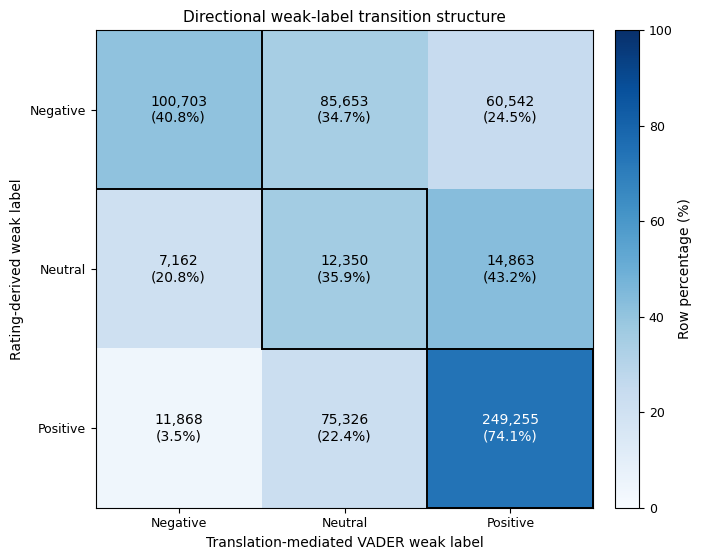

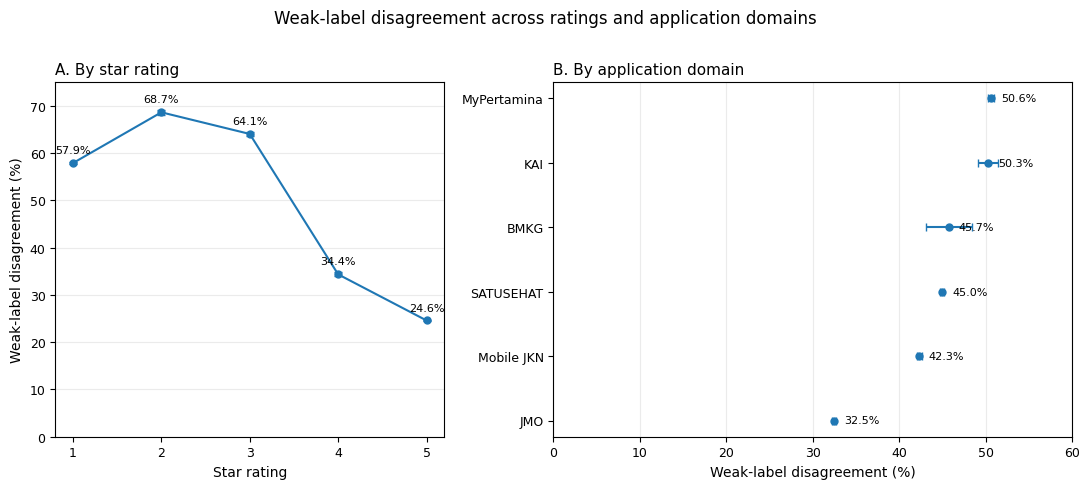

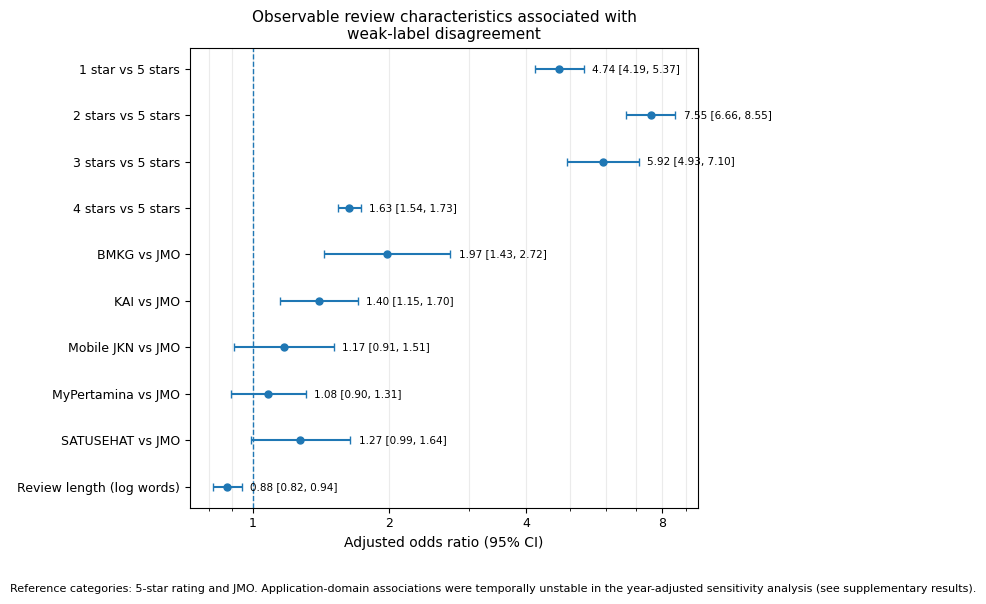

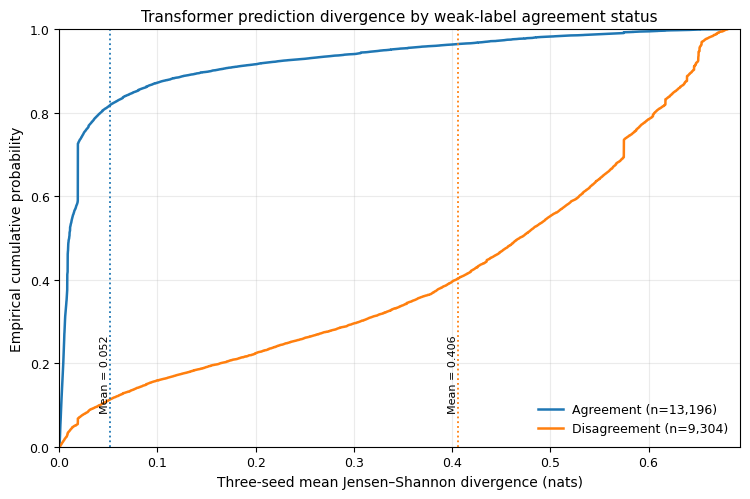


✓ PAPER 1 PUBLICATION FIGURES 2-5 — GENERATED


,figure,format,size_bytes,sha256,path
0,Figure 2,PNG,427094,b976807add1ab064a23d2f4aaee397e14d2d36ad0d73ed...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
1,Figure 2,PDF,16264,37422a11ba0b5fb99a99c621573892604fe58ab50ee783...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
2,Figure 3,PNG,478125,01c3e1409479831215469c06fe740b436a920982b0f8d7...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
3,Figure 3,PDF,16082,75497cd7990c173010d4fe13a4abf0791cf557404c30eb...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
4,Figure 4,PNG,543021,170976096bac83816b8041370e0fbf6bf4ad23010dfc78...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
5,Figure 4,PDF,18148,70547894acd04a1ea3b63c9c32a0a61c5c0c7687c52b35...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
6,Figure 5,PNG,387923,437257b16e57276f79a0969f8150b532b09501ab228dda...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...
7,Figure 5,PDF,28671,26a3155b79dedc7407c5c1d182f96872d5b4f0d8b72da6...,/content/drive/MyDrive/IGAR_Paper1/paper_ready...



Figure captions:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Paper1_Figure2-5_Captions.md

FIGURE 2 : GENERATED — PNG + PDF
FIGURE 3 : GENERATED — PNG + PDF
FIGURE 4 : GENERATED — PNG + PDF
FIGURE 5 : GENERATED — PNG + PDF
NEW STATISTICAL TESTS: False
SCIENTIFIC RESULTS RECOMPUTED: False
FIGURE 1 : DEFERRED — STUDY FRAMEWORK

NEXT:
Visual QC of Figures 2-5, then construct Figure 1 and manuscript Results architecture.


In [28]:
# ============================================================
# [PAPER 1] CELL 70E
# GENERATE PUBLICATION FIGURES 2-5
#
# Outputs:
# - high-resolution PNG (600 dpi)
# - vector PDF
#
# IMPORTANT:
# - uses ONLY locked scientific sources
# - NO new statistical tests
# - NO model fitting
# - NO KDE / smoothing
# - Figure 3 CIs are existing frozen CIs
# - Figure 4 OR/CIs are existing frozen estimates
# - Figure 5 is empirical review-level distribution only
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import hashlib
import json
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

TABLE_DIR = (
    PAPER_READY_ROOT
    /
    "tables"
)

FIGURE_DIR = (
    PAPER_READY_ROOT
    /
    "figures"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. REQUIRE LOCKED FIGURE SOURCE MAP
# ============================================================

FIGURE_LOCK_FILE = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Figure_Source_Map_LOCKED.json"
)

FIGURE_SOURCE_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_FINAL_Figure_Source_Map.csv"
)


assert FIGURE_LOCK_FILE.exists()
assert FIGURE_SOURCE_MANIFEST_FILE.exists()


with open(
    FIGURE_LOCK_FILE,
    encoding="utf-8"
) as f:

    figure_lock = json.load(f)


assert figure_lock["status"] == "LOCKED"
assert figure_lock["scientific_results_recomputed"] is False
assert figure_lock["statistical_tests_performed"] is False


source_manifest = pd.read_csv(
    FIGURE_SOURCE_MANIFEST_FILE
)


print("✓ Locked Figure 2-5 source map verified.")


# ============================================================
# 3. SHA256 HELPER
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 4. RESOLVE + VERIFY SOURCE FILES AGAINST LOCKED HASHES
# ============================================================

source_paths = {}


for _, row in source_manifest.iterrows():

    key = row["figure_source"]

    # Reconstruct from the locked filename/path column.
    # Prefer exact path stored by Cell 70D.
    full_row = source_manifest.loc[
        source_manifest[
            "figure_source"
        ].eq(key)
    ].iloc[0]

    # Cell 70D stored exact path in column "path".
    assert "path" in source_manifest.columns

    path = Path(
        full_row["path"]
    )

    assert path.exists(), (
        f"Missing locked source: {path}"
    )

    observed_hash = sha256_file(
        path
    )

    expected_hash = str(
        full_row["sha256"]
    )

    assert observed_hash == expected_hash, (
        f"Source hash changed for {key}"
    )

    source_paths[key] = path


print(
    "✓ All locked source hashes verified:",
    len(source_paths)
)


# ============================================================
# 5. LOAD LOCKED SOURCES
# ============================================================

f2_counts = pd.read_csv(
    source_paths[
        "Figure2_transition_counts"
    ]
)

f2_pct = pd.read_csv(
    source_paths[
        "Figure2_transition_rowpercent"
    ]
)

f3_star = pd.read_csv(
    source_paths[
        "Figure3_star_disagreement"
    ]
)

f3_app = pd.read_csv(
    source_paths[
        "Figure3_app_disagreement"
    ]
)

f4 = pd.read_csv(
    source_paths[
        "Figure4_RQ3_adjusted_OR"
    ]
)

f5 = pd.read_parquet(
    source_paths[
        "Figure5_RQ4_review_level_JSD"
    ]
)


# Primary locked table used only for annotation / verification.
RQ4_PRIMARY_TABLE = (
    TABLE_DIR
    /
    "Table4_RQ4_Primary_JSD.csv"
)

assert RQ4_PRIMARY_TABLE.exists()

rq4_primary = pd.read_csv(
    RQ4_PRIMARY_TABLE
).iloc[0]


LOCKED_MEAN_AGREEMENT = float(
    rq4_primary[
        "mean_agreement"
    ]
)

LOCKED_MEAN_DISAGREEMENT = float(
    rq4_primary[
        "mean_disagreement"
    ]
)


# ============================================================
# 6. SCIENTIFIC CONSISTENCY CHECKS
# ============================================================

assert f2_counts.shape == (3, 4)
assert f2_pct.shape == (3, 4)

assert len(f3_star) == 5
assert len(f3_app) == 6
assert len(f4) == 10
assert len(f5) == 22500


actual_mean_0 = float(
    f5.loc[
        f5["disagreement"].eq(0),
        "mean_seed_jsd"
    ].mean()
)

actual_mean_1 = float(
    f5.loc[
        f5["disagreement"].eq(1),
        "mean_seed_jsd"
    ].mean()
)


assert np.isclose(
    actual_mean_0,
    LOCKED_MEAN_AGREEMENT,
    atol=1e-6
)

assert np.isclose(
    actual_mean_1,
    LOCKED_MEAN_DISAGREEMENT,
    atol=1e-6
)


print("✓ Scientific consistency checks PASS.")


# ============================================================
# 7. GLOBAL PUBLICATION SETTINGS
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        10,

    "axes.titlesize":
        11,

    "axes.labelsize":
        10,

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "legend.fontsize":
        9,

    "figure.titlesize":
        12,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,
})


def save_publication_figure(
    fig,
    stem
):

    png = (
        FIGURE_DIR
        /
        f"{stem}.png"
    )

    pdf = (
        FIGURE_DIR
        /
        f"{stem}.pdf"
    )


    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )


    assert png.exists()
    assert pdf.exists()


    return png, pdf


output_records = []


# ============================================================
# 8. FIGURE 2
# DIRECTIONAL WEAK-LABEL TRANSITION HEATMAP
# ============================================================

row_names = [
    "Negative",
    "Neutral",
    "Positive",
]

col_names = [
    "Negative",
    "Neutral",
    "Positive",
]


count_matrix = (
    f2_counts[
        [
            "VADER_Negative",
            "VADER_Neutral",
            "VADER_Positive",
        ]
    ]
    .to_numpy(
        dtype=int
    )
)


pct_matrix = (
    f2_pct[
        [
            "VADER_Negative",
            "VADER_Neutral",
            "VADER_Positive",
        ]
    ]
    .to_numpy(
        dtype=float
    )
)


fig, ax = plt.subplots(
    figsize=(7.1, 5.7)
)


im = ax.imshow(
    pct_matrix,
    cmap="Blues",
    vmin=0,
    vmax=100,
    aspect="auto"
)


ax.set_xticks(
    np.arange(3),
    labels=col_names
)

ax.set_yticks(
    np.arange(3),
    labels=row_names
)


ax.set_xlabel(
    "Translation-mediated VADER weak label"
)

ax.set_ylabel(
    "Rating-derived weak label"
)


for i in range(3):

    for j in range(3):

        value = pct_matrix[i, j]

        text_color = (
            "white"
            if value >= 55
            else "black"
        )

        ax.text(
            j,
            i,
            (
                f"{count_matrix[i, j]:,}\n"
                f"({value:.1f}%)"
            ),
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )


# Outline diagonal cells — visual aid only.
for i in range(3):

    ax.add_patch(
        Rectangle(
            (
                i - 0.5,
                i - 0.5
            ),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=1.4,
        )
    )


cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Row percentage (%)"
)


ax.set_title(
    "Directional weak-label transition structure"
)


fig.tight_layout()


png, pdf = save_publication_figure(
    fig,
    "Figure2_WeakLabel_Transition_Heatmap"
)


output_records.append({
    "figure":
        "Figure 2",

    "png":
        str(png),

    "pdf":
        str(pdf),
})


plt.show()
plt.close(fig)


# ============================================================
# 9. FIGURE 3
# WEAK-LABEL DISAGREEMENT BY STAR RATING AND APP
# ============================================================

star = (
    f3_star
    .sort_values("score")
    .reset_index(drop=True)
)


app = f3_app.copy()


APP_NAMES = {

    "BMKG":
        "BMKG",

    "JMO":
        "JMO",

    "KAI":
        "KAI",

    "mobileJKN":
        "Mobile JKN",

    "pertamina":
        "MyPertamina",

    "satusehat":
        "SATUSEHAT",
}


app["app_display"] = (
    app["app"]
    .map(APP_NAMES)
    .fillna(
        app["app"]
    )
)


# Order by observed disagreement percentage
# for descriptive readability.
app = (
    app
    .sort_values(
        "disagreement_pct",
        ascending=True
    )
    .reset_index(drop=True)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.8),
    gridspec_kw={
        "width_ratios":
            [0.9, 1.2]
    }
)


# ------------------------------------------------------------
# Panel A — Star rating
# ------------------------------------------------------------

ax = axes[0]


x = star["score"].to_numpy()

y = star[
    "disagreement_pct"
].to_numpy()


lower = (
    y
    -
    star[
        "disagreement_ci95_low_pct"
    ].to_numpy()
)

upper = (
    star[
        "disagreement_ci95_high_pct"
    ].to_numpy()
    -
    y
)


ax.errorbar(
    x,
    y,
    yerr=np.vstack([
        lower,
        upper
    ]),
    fmt="o-",
    capsize=3,
    linewidth=1.5,
    markersize=5,
)


ax.set_xticks(
    [1, 2, 3, 4, 5]
)

ax.set_xlabel(
    "Star rating"
)

ax.set_ylabel(
    "Weak-label disagreement (%)"
)

ax.set_ylim(
    0,
    max(
        75,
        float(
            star[
                "disagreement_ci95_high_pct"
            ].max()
        )
        +
        4
    )
)


ax.grid(
    axis="y",
    alpha=0.25
)


ax.set_title(
    "A. By star rating",
    loc="left"
)


for xi, yi in zip(
    x,
    y
):

    ax.annotate(
        f"{yi:.1f}%",
        (
            xi,
            yi
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


# ------------------------------------------------------------
# Panel B — Application
# ------------------------------------------------------------

ax = axes[1]


ypos = np.arange(
    len(app)
)


values = (
    app[
        "disagreement_pct"
    ].to_numpy()
)


xerr_left = (
    values
    -
    app[
        "disagreement_ci95_low_pct"
    ].to_numpy()
)


xerr_right = (
    app[
        "disagreement_ci95_high_pct"
    ].to_numpy()
    -
    values
)


ax.errorbar(
    values,
    ypos,
    xerr=np.vstack([
        xerr_left,
        xerr_right
    ]),
    fmt="o",
    capsize=3,
    markersize=5,
)


ax.set_yticks(
    ypos,
    labels=app[
        "app_display"
    ]
)


ax.set_xlabel(
    "Weak-label disagreement (%)"
)

ax.set_xlim(
    0,
    max(
        60,
        float(
            app[
                "disagreement_ci95_high_pct"
            ].max()
        )
        +
        4
    )
)


ax.grid(
    axis="x",
    alpha=0.25
)


ax.set_title(
    "B. By application domain",
    loc="left"
)


for yi, value in zip(
    ypos,
    values
):

    ax.annotate(
        f"{value:.1f}%",
        (
            value,
            yi
        ),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )


fig.suptitle(
    "Weak-label disagreement across ratings and application domains",
    y=1.01
)


fig.tight_layout()


png, pdf = save_publication_figure(
    fig,
    "Figure3_Disagreement_By_Rating_And_Application"
)


output_records.append({
    "figure":
        "Figure 3",

    "png":
        str(png),

    "pdf":
        str(pdf),
})


plt.show()
plt.close(fig)


# ============================================================
# 10. FIGURE 4
# RQ3 PRIMARY ADJUSTED OR FOREST PLOT
# ============================================================

TERM_LABELS = {

    "C(score, Treatment(reference=5))[T.1]":
        "1 star vs 5 stars",

    "C(score, Treatment(reference=5))[T.2]":
        "2 stars vs 5 stars",

    "C(score, Treatment(reference=5))[T.3]":
        "3 stars vs 5 stars",

    "C(score, Treatment(reference=5))[T.4]":
        "4 stars vs 5 stars",

    "C(app, Treatment(reference='JMO'))[T.BMKG]":
        "BMKG vs JMO",

    "C(app, Treatment(reference='JMO'))[T.KAI]":
        "KAI vs JMO",

    "C(app, Treatment(reference='JMO'))[T.mobileJKN]":
        "Mobile JKN vs JMO",

    "C(app, Treatment(reference='JMO'))[T.pertamina]":
        "MyPertamina vs JMO",

    "C(app, Treatment(reference='JMO'))[T.satusehat]":
        "SATUSEHAT vs JMO",

    "log_words":
        "Review length (log words)",
}


forest = f4.copy()


forest["label"] = (
    forest["term"]
    .map(TERM_LABELS)
)


assert forest["label"].notna().all()


# Preserve scientifically meaningful ordering.
ORDER = [

    "1 star vs 5 stars",
    "2 stars vs 5 stars",
    "3 stars vs 5 stars",
    "4 stars vs 5 stars",

    "BMKG vs JMO",
    "KAI vs JMO",
    "Mobile JKN vs JMO",
    "MyPertamina vs JMO",
    "SATUSEHAT vs JMO",

    "Review length (log words)",
]


forest["order"] = (
    forest["label"]
    .map({
        label: i
        for i, label in enumerate(
            ORDER
        )
    })
)


forest = (
    forest
    .sort_values(
        "order",
        ascending=False
    )
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(7.8, 6.0)
)


y = np.arange(
    len(forest)
)


OR = forest[
    "adjusted_OR"
].to_numpy()


low = forest[
    "OR_ci95_low"
].to_numpy()


high = forest[
    "OR_ci95_high"
].to_numpy()


ax.errorbar(
    OR,
    y,
    xerr=np.vstack([
        OR - low,
        high - OR
    ]),
    fmt="o",
    capsize=3,
    markersize=5,
)


ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.0,
)


ax.set_xscale(
    "log"
)


ax.set_yticks(
    y,
    labels=forest["label"]
)


ax.set_xlabel(
    "Adjusted odds ratio (95% CI)"
)


ax.set_title(
    "Observable review characteristics associated with\n"
    "weak-label disagreement"
)


ax.grid(
    axis="x",
    alpha=0.25,
    which="both"
)


# Use interpretable fixed OR ticks.
candidate_ticks = [
    0.5,
    1,
    2,
    4,
    8,
]


xmin = min(
    low.min(),
    0.75
)

xmax = max(
    high.max(),
    1.25
)


visible_ticks = [
    t
    for t in candidate_ticks
    if xmin * 0.9 <= t <= xmax * 1.1
]


ax.set_xticks(
    visible_ticks,
    labels=[
        str(t)
        for t in visible_ticks
    ]
)


# Add numeric estimates.
for yi, or_value, lo, hi in zip(
    y,
    OR,
    low,
    high
):

    ax.annotate(
        (
            f"{or_value:.2f} "
            f"[{lo:.2f}, {hi:.2f}]"
        ),
        (
            hi,
            yi
        ),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=7.5,
    )


fig.text(
    0.01,
    0.005,
    (
        "Reference categories: 5-star rating and JMO. "
        "Application-domain associations were temporally "
        "unstable in the year-adjusted sensitivity analysis "
        "(see supplementary results)."
    ),
    fontsize=8,
    ha="left",
)


fig.tight_layout(
    rect=[
        0,
        0.05,
        1,
        1
    ]
)


png, pdf = save_publication_figure(
    fig,
    "Figure4_RQ3_Adjusted_OR_Forest"
)


output_records.append({
    "figure":
        "Figure 4",

    "png":
        str(png),

    "pdf":
        str(pdf),
})


plt.show()
plt.close(fig)


# ============================================================
# 11. FIGURE 5
# RQ4 EMPIRICAL JSD DISTRIBUTION
#
# ECDF chosen instead of KDE:
# - no smoothing choice
# - preserves bounded JSD distribution
# - visualizes entire empirical distribution
# ============================================================

agreement_jsd = (
    f5.loc[
        f5[
            "disagreement"
        ].eq(0),
        "mean_seed_jsd"
    ]
    .to_numpy(
        dtype=float
    )
)


disagreement_jsd = (
    f5.loc[
        f5[
            "disagreement"
        ].eq(1),
        "mean_seed_jsd"
    ]
    .to_numpy(
        dtype=float
    )
)


assert len(
    agreement_jsd
) == 13196

assert len(
    disagreement_jsd
) == 9304


def empirical_cdf(values):

    x = np.sort(
        values
    )

    y = np.arange(
        1,
        len(x) + 1
    ) / len(x)

    return x, y


x0, y0 = empirical_cdf(
    agreement_jsd
)

x1, y1 = empirical_cdf(
    disagreement_jsd
)


fig, ax = plt.subplots(
    figsize=(7.6, 5.1)
)


line0, = ax.plot(
    x0,
    y0,
    linewidth=1.8,
    label=(
        f"Agreement "
        f"(n={len(agreement_jsd):,})"
    ),
)


line1, = ax.plot(
    x1,
    y1,
    linewidth=1.8,
    label=(
        f"Disagreement "
        f"(n={len(disagreement_jsd):,})"
    ),
)


# Mean markers use locked primary result values.
ax.axvline(
    LOCKED_MEAN_AGREEMENT,
    linestyle=":",
    linewidth=1.3,
    color=line0.get_color(),
)


ax.axvline(
    LOCKED_MEAN_DISAGREEMENT,
    linestyle=":",
    linewidth=1.3,
    color=line1.get_color(),
)


ax.set_xlim(
    0,
    np.log(2)
)

ax.set_ylim(
    0,
    1
)


ax.set_xlabel(
    "Three-seed mean Jensen–Shannon divergence (nats)"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)


ax.set_title(
    "Transformer prediction divergence by weak-label agreement status"
)


ax.grid(
    alpha=0.25
)


ax.legend(
    loc="lower right",
    frameon=False,
)


ax.text(
    LOCKED_MEAN_AGREEMENT,
    0.08,
    (
        "Mean = "
        f"{LOCKED_MEAN_AGREEMENT:.3f}"
    ),
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=8,
)


ax.text(
    LOCKED_MEAN_DISAGREEMENT,
    0.08,
    (
        "Mean = "
        f"{LOCKED_MEAN_DISAGREEMENT:.3f}"
    ),
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=8,
)


fig.tight_layout()


png, pdf = save_publication_figure(
    fig,
    "Figure5_RQ4_JSD_Distribution"
)


output_records.append({
    "figure":
        "Figure 5",

    "png":
        str(png),

    "pdf":
        str(pdf),
})


plt.show()
plt.close(fig)


# ============================================================
# 12. CAPTIONS
# ============================================================

CAPTION_FILE = (
    FIGURE_DIR
    /
    "Paper1_Figure2-5_Captions.md"
)


captions = r"""
## Figure 2
**Directional weak-label transition structure.**
Cells show the number of reviews and row percentages for transitions
from rating-derived weak labels (rows) to translation-mediated VADER
weak labels (columns). Diagonal cells represent agreement between the
two weak-supervision sources.

## Figure 3
**Weak-label disagreement across star ratings and application domains.**
Panel A shows the percentage of reviews exhibiting weak-label
disagreement at each star rating, with existing 95% confidence
intervals. Panel B shows the corresponding descriptive estimates
across the six government-application domains.

## Figure 4
**Observable review characteristics associated with weak-label disagreement.**
Points show adjusted odds ratios from the primary RQ3 logistic
regression and horizontal intervals show cluster-robust 95% confidence
intervals. The vertical dashed line denotes OR = 1. Reference categories
are 5-star rating and JMO. Application-domain associations should be
interpreted cautiously because they were not temporally stable in the
year-adjusted sensitivity analysis.

## Figure 5
**Transformer prediction divergence by weak-label agreement status.**
Empirical cumulative distributions show review-level Jensen–Shannon
divergence between paired Model-R and Model-V predictive probability
distributions, averaged across three random seeds. Dotted vertical
lines indicate the frozen group means. JSD uses the natural logarithm
and therefore ranges from 0 to ln(2). The comparison characterizes
sensitivity to the choice of weak-supervision source and does not
identify either weak-label source as ground truth.
""".strip()


with open(
    CAPTION_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        captions
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 13. OUTPUT HASH MANIFEST
# ============================================================

output_manifest_rows = []


for record in output_records:

    for fmt in [
        "png",
        "pdf",
    ]:

        path = Path(
            record[fmt]
        )

        output_manifest_rows.append({

            "figure":
                record["figure"],

            "format":
                fmt.upper(),

            "path":
                str(path),

            "size_bytes":
                int(
                    path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    path
                ),
        })


OUTPUT_MANIFEST = pd.DataFrame(
    output_manifest_rows
)


OUTPUT_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Output_Manifest.csv"
)


OUTPUT_MANIFEST.to_csv(
    OUTPUT_MANIFEST_FILE,
    index=False
)


# ============================================================
# 14. FINAL GENERATION LOCK
# ============================================================

GENERATION_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Generation_PASS.json"
)


generation_manifest = {

    "status":
        "PASS",

    "stage":
        "PAPER_READY_FIGURE_GENERATION",

    "figures_generated":
        [
            2,
            3,
            4,
            5,
        ],

    "png_dpi":
        600,

    "pdf_vector":
        True,

    "scientific_results_recomputed":
        False,

    "new_statistical_tests":
        False,

    "model_fitting":
        False,

    "figure5_distribution_method":
        "empirical cumulative distribution function",

    "figure5_kde_used":
        False,

    "figure1_status":
        "DEFERRED_CONCEPTUAL",

    "captions_file":
        str(
            CAPTION_FILE
        ),

    "output_manifest":
        str(
            OUTPUT_MANIFEST_FILE
        ),

    "generated_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    GENERATION_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        generation_manifest,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 15. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ PAPER 1 PUBLICATION FIGURES 2-5 — GENERATED"
)

print(
    "=" * 124
)


display(
    OUTPUT_MANIFEST[
        [
            "figure",
            "format",
            "size_bytes",
            "sha256",
            "path",
        ]
    ]
)


print(
    "\nFigure captions:"
)

print(
    CAPTION_FILE
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "FIGURE 2 : GENERATED — PNG + PDF"
)

print(
    "FIGURE 3 : GENERATED — PNG + PDF"
)

print(
    "FIGURE 4 : GENERATED — PNG + PDF"
)

print(
    "FIGURE 5 : GENERATED — PNG + PDF"
)

print(
    "NEW STATISTICAL TESTS:",
    False
)

print(
    "SCIENTIFIC RESULTS RECOMPUTED:",
    False
)

print(
    "FIGURE 1 : DEFERRED — STUDY FRAMEWORK"
)

print(
    "=" * 124
)

print(
    "\nNEXT:"
)

print(
    "Visual QC of Figures 2-5, then construct Figure 1 "
    "and manuscript Results architecture."
)

✓ Original publication figure generation verified.
✓ Frozen Figure 3 and Figure 4 sources loaded.


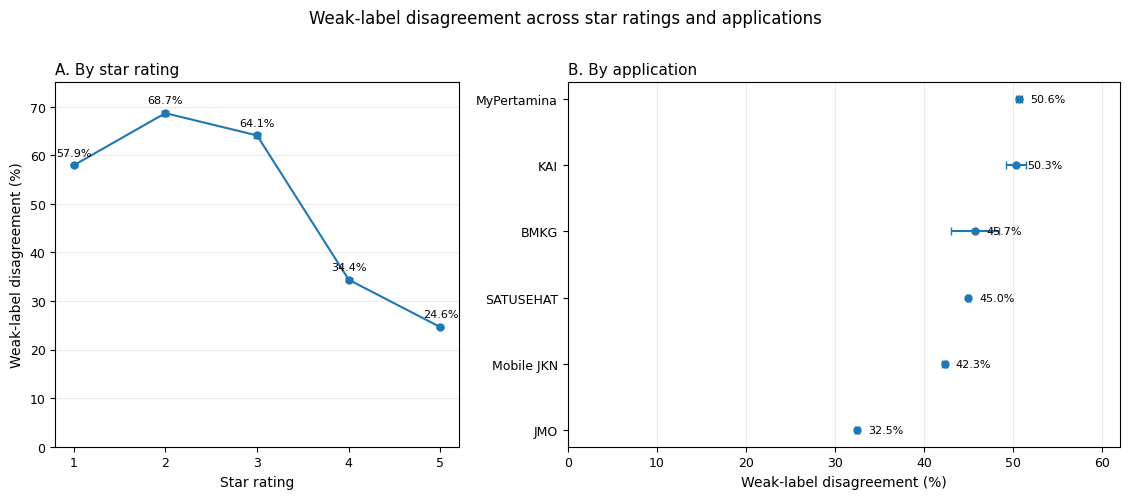

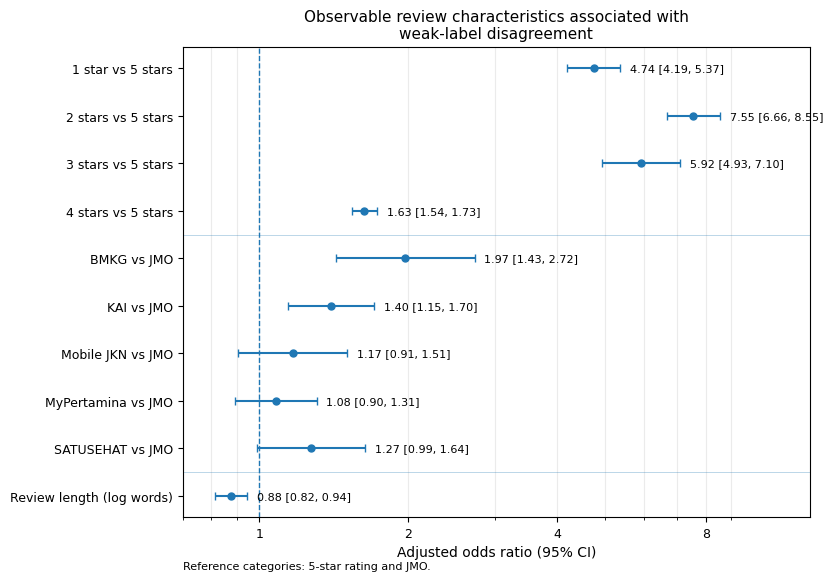


✓ PAPER 1 FIGURE 2-5 FINAL VISUAL QC — PASS


,figure,format,path,sha256,size_bytes
0,Figure 3,PNG,/content/drive/MyDrive/IGAR_Paper1/paper_ready...,1065129010e504b2c35edf958ccd3d72731c23c522e6a2...,477754
1,Figure 3,PDF,/content/drive/MyDrive/IGAR_Paper1/paper_ready...,a918cbda5b2b3790646e2fffdbb2f1c5ca99ac19860d81...,16087
2,Figure 4,PNG,/content/drive/MyDrive/IGAR_Paper1/paper_ready...,8ce4224a8701cdd4dc97c1b818b3f19efd07a172c95a74...,491966
3,Figure 4,PDF,/content/drive/MyDrive/IGAR_Paper1/paper_ready...,04d46a2c66e781019e9cc97b5198bc9c63e768c6e7b231...,18044



Figure 2: PASS — unchanged
Figure 3: PASS — refined
Figure 4: PASS — refined
Figure 5: PASS — unchanged

Scientific results changed: False
New statistical tests: False

Final captions:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Paper1_Figure2-5_Captions_FINAL.md

DATA FIGURES 2-5 : FINAL / LOCKED
NEXT             : FIGURE 1 — STUDY FRAMEWORK


In [29]:
# ============================================================
# [PAPER 1] CELL 70F
# PUBLICATION VISUAL-QC REFINEMENT
#
# Refinements ONLY:
# - Figure 3: spacing / labels / terminology
# - Figure 4: remove tiny embedded footnote, improve right margin
#
# NO scientific values changed
# NO statistical analysis
# Figure 2 and Figure 5 remain unchanged
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import json
import os
import datetime


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = PROJECT_ROOT / "paper_ready"
TABLE_DIR = PAPER_READY_ROOT / "tables"
FIGURE_DIR = PAPER_READY_ROOT / "figures"
MANIFEST_DIR = PAPER_READY_ROOT / "manifests"


# ============================================================
# 1. VERIFY PREVIOUS GENERATION
# ============================================================

GENERATION_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Generation_PASS.json"
)

assert GENERATION_MANIFEST_FILE.exists()

with open(
    GENERATION_MANIFEST_FILE,
    encoding="utf-8"
) as f:
    generation_manifest = json.load(f)

assert generation_manifest["status"] == "PASS"
assert generation_manifest["scientific_results_recomputed"] is False
assert generation_manifest["new_statistical_tests"] is False

print("✓ Original publication figure generation verified.")


# ============================================================
# 2. LOAD EXACT FROZEN SOURCES
# ============================================================

STAR_FILE = (
    PROJECT_ROOT
    /
    "results/tables/RQ2_Disagreement_By_StarRating.csv"
)

APP_FILE = (
    PROJECT_ROOT
    /
    "results/tables/Table4_RQ2_Domain_Disagreement_Severity.csv"
)

OR_FILE = (
    TABLE_DIR
    /
    "Table3_RQ3_Primary_Adjusted_OR.csv"
)

assert STAR_FILE.exists()
assert APP_FILE.exists()
assert OR_FILE.exists()


star = pd.read_csv(STAR_FILE)
app = pd.read_csv(APP_FILE)
forest = pd.read_csv(OR_FILE)


assert len(star) == 5
assert len(app) == 6
assert len(forest) == 10

print("✓ Frozen Figure 3 and Figure 4 sources loaded.")


# ============================================================
# 3. PUBLICATION SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_figure(fig, stem):

    png = FIGURE_DIR / f"{stem}.png"
    pdf = FIGURE_DIR / f"{stem}.pdf"

    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    assert png.exists()
    assert pdf.exists()

    return png, pdf


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 4. FIGURE 3 — FINAL QC VERSION
# ============================================================

star = (
    star
    .sort_values("score")
    .reset_index(drop=True)
)


APP_NAMES = {
    "BMKG": "BMKG",
    "JMO": "JMO",
    "KAI": "KAI",
    "mobileJKN": "Mobile JKN",
    "pertamina": "MyPertamina",
    "satusehat": "SATUSEHAT",
}


app["app_display"] = (
    app["app"]
    .map(APP_NAMES)
    .fillna(app["app"])
)


app = (
    app
    .sort_values(
        "disagreement_pct",
        ascending=True
    )
    .reset_index(drop=True)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.4, 4.9),
    gridspec_kw={
        "width_ratios": [0.95, 1.30]
    }
)


# ------------------------------------------------------------
# Panel A
# ------------------------------------------------------------

ax = axes[0]

x = star["score"].to_numpy()
y = star["disagreement_pct"].to_numpy()

lower = (
    y
    -
    star[
        "disagreement_ci95_low_pct"
    ].to_numpy()
)

upper = (
    star[
        "disagreement_ci95_high_pct"
    ].to_numpy()
    -
    y
)


ax.errorbar(
    x,
    y,
    yerr=np.vstack([lower, upper]),
    fmt="o-",
    capsize=3,
    linewidth=1.5,
    markersize=5,
)


ax.set_xticks([1, 2, 3, 4, 5])

ax.set_xlabel(
    "Star rating"
)

ax.set_ylabel(
    "Weak-label disagreement (%)"
)

ax.set_ylim(
    0,
    75
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_title(
    "A. By star rating",
    loc="left"
)


for xi, yi in zip(x, y):

    ax.annotate(
        f"{yi:.1f}%",
        (xi, yi),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


# ------------------------------------------------------------
# Panel B
# ------------------------------------------------------------

ax = axes[1]

ypos = np.arange(
    len(app)
)

values = (
    app[
        "disagreement_pct"
    ].to_numpy()
)

left_err = (
    values
    -
    app[
        "disagreement_ci95_low_pct"
    ].to_numpy()
)

right_err = (
    app[
        "disagreement_ci95_high_pct"
    ].to_numpy()
    -
    values
)


ax.errorbar(
    values,
    ypos,
    xerr=np.vstack([
        left_err,
        right_err
    ]),
    fmt="o",
    capsize=3,
    markersize=5,
)


ax.set_yticks(
    ypos,
    labels=app[
        "app_display"
    ]
)


ax.set_xlabel(
    "Weak-label disagreement (%)"
)

# Extra room for annotations.
ax.set_xlim(
    0,
    62
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.set_title(
    "B. By application",
    loc="left"
)


for yi, value in zip(
    ypos,
    values
):

    ax.annotate(
        f"{value:.1f}%",
        (value, yi),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=8,
    )


fig.suptitle(
    "Weak-label disagreement across star ratings and applications",
    y=1.01
)


fig.tight_layout()


F3_PNG, F3_PDF = save_figure(
    fig,
    "Figure3_Disagreement_By_Rating_And_Application_FINAL"
)


plt.show()
plt.close(fig)


# ============================================================
# 5. FIGURE 4 — FINAL QC VERSION
# ============================================================

TERM_LABELS = {

    "C(score, Treatment(reference=5))[T.1]":
        "1 star vs 5 stars",

    "C(score, Treatment(reference=5))[T.2]":
        "2 stars vs 5 stars",

    "C(score, Treatment(reference=5))[T.3]":
        "3 stars vs 5 stars",

    "C(score, Treatment(reference=5))[T.4]":
        "4 stars vs 5 stars",

    "C(app, Treatment(reference='JMO'))[T.BMKG]":
        "BMKG vs JMO",

    "C(app, Treatment(reference='JMO'))[T.KAI]":
        "KAI vs JMO",

    "C(app, Treatment(reference='JMO'))[T.mobileJKN]":
        "Mobile JKN vs JMO",

    "C(app, Treatment(reference='JMO'))[T.pertamina]":
        "MyPertamina vs JMO",

    "C(app, Treatment(reference='JMO'))[T.satusehat]":
        "SATUSEHAT vs JMO",

    "log_words":
        "Review length (log words)",
}


forest["label"] = (
    forest["term"]
    .map(TERM_LABELS)
)

assert forest["label"].notna().all()


ORDER = [

    "1 star vs 5 stars",
    "2 stars vs 5 stars",
    "3 stars vs 5 stars",
    "4 stars vs 5 stars",

    "BMKG vs JMO",
    "KAI vs JMO",
    "Mobile JKN vs JMO",
    "MyPertamina vs JMO",
    "SATUSEHAT vs JMO",

    "Review length (log words)",
]


order_map = {
    label: i
    for i, label in enumerate(ORDER)
}


forest["order"] = (
    forest["label"]
    .map(order_map)
)


forest = (
    forest
    .sort_values(
        "order",
        ascending=False
    )
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(8.4, 5.9)
)


ypos = np.arange(
    len(forest)
)


OR = forest[
    "adjusted_OR"
].to_numpy()

low = forest[
    "OR_ci95_low"
].to_numpy()

high = forest[
    "OR_ci95_high"
].to_numpy()


ax.errorbar(
    OR,
    ypos,
    xerr=np.vstack([
        OR - low,
        high - OR
    ]),
    fmt="o",
    capsize=3,
    markersize=5,
)


ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.0,
)


ax.set_xscale(
    "log"
)


# More right-side breathing room.
ax.set_xlim(
    0.7,
    13
)


ax.set_xticks(
    [1, 2, 4, 8],
    labels=[
        "1",
        "2",
        "4",
        "8",
    ]
)


ax.set_yticks(
    ypos,
    labels=forest["label"]
)


ax.set_xlabel(
    "Adjusted odds ratio (95% CI)"
)


ax.set_title(
    "Observable review characteristics associated with\n"
    "weak-label disagreement"
)


ax.grid(
    axis="x",
    alpha=0.25,
    which="both"
)


# ------------------------------------------------------------
# Visual separators:
# rating predictors / applications / length.
# These add structure but no scientific meaning.
# ------------------------------------------------------------

# Current bottom-to-top order:
# length, apps x5, ratings x4

ax.axhline(
    0.5,
    linewidth=0.6,
    alpha=0.35
)

ax.axhline(
    5.5,
    linewidth=0.6,
    alpha=0.35
)


# Numeric estimate labels.
for yi, or_value, lo, hi in zip(
    ypos,
    OR,
    low,
    high
):

    ax.annotate(
        (
            f"{or_value:.2f} "
            f"[{lo:.2f}, {hi:.2f}]"
        ),
        (hi, yi),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )


# Short reference note only.
# Temporal-instability caveat stays in manuscript caption.
ax.text(
    0.0,
    -0.11,
    "Reference categories: 5-star rating and JMO.",
    transform=ax.transAxes,
    fontsize=8,
    ha="left",
)


fig.tight_layout()


F4_PNG, F4_PDF = save_figure(
    fig,
    "Figure4_RQ3_Adjusted_OR_Forest_FINAL"
)


plt.show()
plt.close(fig)


# ============================================================
# 6. UPDATE CAPTION TEXT
# ============================================================

CAPTION_FINAL_FILE = (
    FIGURE_DIR
    /
    "Paper1_Figure2-5_Captions_FINAL.md"
)


captions = r"""
## Figure 2
**Directional weak-label transition structure.**
Cells show the number of reviews and row percentages for transitions
from rating-derived weak labels (rows) to translation-mediated VADER
weak labels (columns). Diagonal cells represent agreement between the
two weak-supervision sources.

## Figure 3
**Weak-label disagreement across star ratings and applications.**
Panel A shows the percentage of reviews exhibiting weak-label
disagreement at each star rating, with 95% confidence intervals.
Panel B shows the corresponding descriptive estimates across the six
government applications.

## Figure 4
**Observable review characteristics associated with weak-label disagreement.**
Points show adjusted odds ratios from the primary RQ3 logistic
regression and horizontal intervals show cluster-robust 95% confidence
intervals. The vertical dashed line denotes OR = 1. Reference
categories are 5-star rating and JMO. Application-specific associations
should be interpreted cautiously because they were not temporally
stable in the year-adjusted sensitivity analysis.

## Figure 5
**Transformer prediction divergence by weak-label agreement status.**
Empirical cumulative distributions show review-level Jensen–Shannon
divergence between paired Model-R and Model-V predictive probability
distributions, averaged across three random seeds. Dotted vertical
lines indicate the frozen group means. JSD uses the natural logarithm
and therefore ranges from 0 to ln(2). The comparison characterizes
sensitivity to the choice of weak-supervision source and does not
identify either weak-label source as ground truth.
""".strip()


with open(
    CAPTION_FINAL_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(captions)

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 7. FINAL QC MANIFEST
# ============================================================

QC_OUTPUTS = [

    {
        "figure": "Figure 3",
        "format": "PNG",
        "path": F3_PNG,
    },

    {
        "figure": "Figure 3",
        "format": "PDF",
        "path": F3_PDF,
    },

    {
        "figure": "Figure 4",
        "format": "PNG",
        "path": F4_PNG,
    },

    {
        "figure": "Figure 4",
        "format": "PDF",
        "path": F4_PDF,
    },
]


qc_rows = []


for x in QC_OUTPUTS:

    qc_rows.append({

        "figure":
            x["figure"],

        "format":
            x["format"],

        "path":
            str(x["path"]),

        "sha256":
            sha256_file(
                x["path"]
            ),

        "size_bytes":
            int(
                x["path"].stat().st_size
            ),
    })


QC_TABLE = pd.DataFrame(
    qc_rows
)


QC_MANIFEST_CSV = (
    MANIFEST_DIR
    /
    "Paper1_Figure3-4_Final_VisualQC_Manifest.csv"
)


QC_TABLE.to_csv(
    QC_MANIFEST_CSV,
    index=False
)


QC_LOCK_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Final_VisualQC_PASS.json"
)


qc_lock = {

    "status":
        "PASS",

    "figure_2":
        "PASS_UNCHANGED",

    "figure_3":
        "PASS_AFTER_VISUAL_REFINEMENT",

    "figure_4":
        "PASS_AFTER_VISUAL_REFINEMENT",

    "figure_5":
        "PASS_UNCHANGED",

    "scientific_results_changed":
        False,

    "statistical_tests_performed":
        False,

    "figure3_changes":
        [
            "increased panel-B annotation spacing",
            "application-domain wording changed to application",
        ],

    "figure4_changes":
        [
            "removed long embedded caveat",
            "moved temporal-instability caveat to caption",
            "increased right-side plotting space",
            "added visual predictor-group separators",
        ],

    "final_caption_file":
        str(
            CAPTION_FINAL_FILE
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    QC_LOCK_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        qc_lock,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 8. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ PAPER 1 FIGURE 2-5 FINAL VISUAL QC — PASS"
)

print(
    "=" * 120
)


display(
    QC_TABLE
)


print(
    "\nFigure 2: PASS — unchanged"
)

print(
    "Figure 3: PASS — refined"
)

print(
    "Figure 4: PASS — refined"
)

print(
    "Figure 5: PASS — unchanged"
)


print(
    "\nScientific results changed:",
    False
)

print(
    "New statistical tests:",
    False
)


print(
    "\nFinal captions:"
)

print(
    CAPTION_FINAL_FILE
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "DATA FIGURES 2-5 : FINAL / LOCKED"
)

print(
    "NEXT             : FIGURE 1 — STUDY FRAMEWORK"
)

print(
    "=" * 120
)

✓ Final Figures 2-5 QC verified.


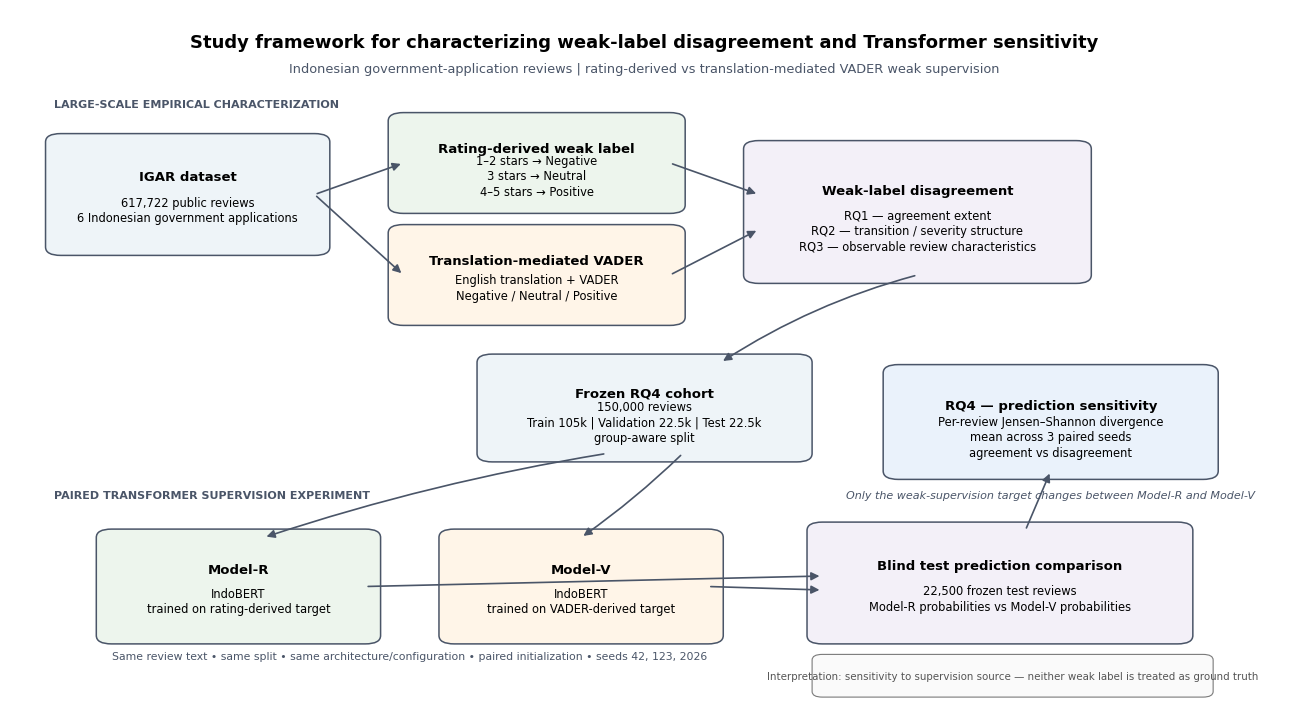


✓ PAPER 1 FIGURE 1 — STUDY FRAMEWORK GENERATED

PNG:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Figure1_Study_Framework.png
SHA256: 4c1951900ae70f9dee775590591e0449241017afc3ec590ceef7fc1209f58d85

PDF:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Figure1_Study_Framework.pdf
SHA256: 7f2876cabdfc9bce42c0ffa9e7d87e00eb8c03268703dac813dc2b53ed9b4dfe

Caption:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Figure1_Study_Framework_Caption.md

Scientific results recomputed: False
New statistical tests: False
Ground-truth claim: False

FIGURE 1 : GENERATED — AWAITING VISUAL QC
FIGURES 2-5: FINAL / LOCKED
NEXT      : VISUAL QC FIGURE 1


In [30]:
# ============================================================
# [PAPER 1] CELL 71
# FIGURE 1 — STUDY FRAMEWORK
#
# Purpose:
# Visualize the complete Paper 1 design:
#
# 617,722 reviews
#      ↓
# two inexpensive weak-supervision signals
#      ↓
# RQ1-RQ3 empirical characterization
#      ↓
# frozen 150k Transformer cohort
#      ↓
# paired Model-R / Model-V training
#      ↓
# blind test predictions
#      ↓
# paired three-seed JSD
#      ↓
# RQ4 model-sensitivity analysis
#
# IMPORTANT:
# - conceptual / methods figure only
# - no new scientific analysis
# - no statistical result recomputation
# - no claim that either weak label is ground truth
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
)
import hashlib
import json
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

FIGURE_DIR = (
    PAPER_READY_ROOT
    /
    "figures"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. REQUIRE FINAL DATA-FIGURE QC
# ============================================================

DATA_FIGURE_QC_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Final_VisualQC_PASS.json"
)


assert DATA_FIGURE_QC_FILE.exists()


with open(
    DATA_FIGURE_QC_FILE,
    encoding="utf-8"
) as f:

    data_figure_qc = json.load(f)


assert data_figure_qc["status"] == "PASS"

assert (
    data_figure_qc[
        "scientific_results_changed"
    ]
    is False
)


print(
    "✓ Final Figures 2-5 QC verified."
)


# ============================================================
# 3. PUBLICATION SETTINGS
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        9,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,
})


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def add_box(
    ax,
    x,
    y,
    w,
    h,
    title,
    body=None,
    facecolor="#F4F6F8",
    edgecolor="#4A5568",
    title_size=9.5,
    body_size=8.3,
    linewidth=1.1,
):

    box = FancyBboxPatch(

        (x, y),

        w,
        h,

        boxstyle=(
            "round,pad=0.012,"
            "rounding_size=0.012"
        ),

        linewidth=linewidth,

        edgecolor=edgecolor,

        facecolor=facecolor,
    )

    ax.add_patch(box)


    if body is None:

        ax.text(

            x + w / 2,
            y + h / 2,

            title,

            ha="center",
            va="center",

            fontsize=title_size,
            fontweight="bold",

            wrap=True,
        )

    else:

        ax.text(

            x + w / 2,
            y + h * 0.67,

            title,

            ha="center",
            va="center",

            fontsize=title_size,
            fontweight="bold",

            wrap=True,
        )


        ax.text(

            x + w / 2,
            y + h * 0.35,

            body,

            ha="center",
            va="center",

            fontsize=body_size,

            wrap=True,

            linespacing=1.25,
        )


    return box


def add_arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    connectionstyle="arc3",
    linewidth=1.2,
):

    arrow = FancyArrowPatch(

        (x1, y1),
        (x2, y2),

        arrowstyle="-|>",

        mutation_scale=12,

        linewidth=linewidth,

        edgecolor="#4A5568",

        facecolor="#4A5568",

        connectionstyle=connectionstyle,

        shrinkA=2,
        shrinkB=2,
    )

    ax.add_patch(
        arrow
    )


def add_section_label(
    ax,
    x,
    y,
    text,
):

    ax.text(

        x,
        y,

        text.upper(),

        ha="left",
        va="center",

        fontsize=8,

        fontweight="bold",

        color="#4A5568",
    )


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 5. CANVAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.2, 7.2)
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.axis(
    "off"
)


# ============================================================
# 6. TITLE
# ============================================================

ax.text(

    0.5,
    0.965,

    "Study framework for characterizing weak-label disagreement "
    "and Transformer sensitivity",

    ha="center",
    va="top",

    fontsize=13,
    fontweight="bold",
)


ax.text(

    0.5,
    0.925,

    (
        "Indonesian government-application reviews | "
        "rating-derived vs translation-mediated VADER weak supervision"
    ),

    ha="center",
    va="top",

    fontsize=9.3,

    color="#4A5568",
)


# ============================================================
# 7. LEFT HALF — EMPIRICAL CHARACTERIZATION
# ============================================================

add_section_label(
    ax,
    0.035,
    0.865,
    "Large-scale empirical characterization"
)


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

add_box(

    ax,

    x=0.04,
    y=0.66,

    w=0.20,
    h=0.15,

    title="IGAR dataset",

    body=(
        "617,722 public reviews\n"
        "6 Indonesian government applications"
    ),

    facecolor="#EEF4F8",
)


# ------------------------------------------------------------
# Weak-label source 1
# ------------------------------------------------------------

add_box(

    ax,

    x=0.31,
    y=0.72,

    w=0.21,
    h=0.12,

    title="Rating-derived weak label",

    body=(
        "1–2 stars → Negative\n"
        "3 stars → Neutral\n"
        "4–5 stars → Positive"
    ),

    facecolor="#EDF5ED",
)


# ------------------------------------------------------------
# Weak-label source 2
# ------------------------------------------------------------

add_box(

    ax,

    x=0.31,
    y=0.56,

    w=0.21,
    h=0.12,

    title="Translation-mediated VADER",

    body=(
        "English translation + VADER\n"
        "Negative / Neutral / Positive"
    ),

    facecolor="#FFF5E8",
)


# Dataset -> weak labels
add_arrow(
    ax,
    0.24,
    0.735,
    0.31,
    0.78,
)

add_arrow(
    ax,
    0.24,
    0.735,
    0.31,
    0.62,
)


# ------------------------------------------------------------
# Disagreement characterization
# ------------------------------------------------------------

add_box(

    ax,

    x=0.59,
    y=0.62,

    w=0.25,
    h=0.18,

    title="Weak-label disagreement",

    body=(
        "RQ1 — agreement extent\n"
        "RQ2 — transition / severity structure\n"
        "RQ3 — observable review characteristics"
    ),

    facecolor="#F3F0F8",
)


add_arrow(
    ax,
    0.52,
    0.78,
    0.59,
    0.735,
)

add_arrow(
    ax,
    0.52,
    0.62,
    0.59,
    0.685,
)


# ============================================================
# 8. BRIDGE TO TRANSFORMER EXPERIMENT
# ============================================================

add_box(

    ax,

    x=0.38,
    y=0.365,

    w=0.24,
    h=0.13,

    title="Frozen RQ4 cohort",

    body=(
        "150,000 reviews\n"
        "Train 105k | Validation 22.5k | Test 22.5k\n"
        "group-aware split"
    ),

    facecolor="#EEF4F8",
)


add_arrow(
    ax,
    0.715,
    0.62,
    0.56,
    0.495,
    connectionstyle="arc3,rad=0.08",
)


# ============================================================
# 9. RIGHT / LOWER HALF — PAIRED TRANSFORMER EXPERIMENT
# ============================================================

add_section_label(
    ax,
    0.035,
    0.305,
    "Paired Transformer supervision experiment"
)


# ------------------------------------------------------------
# Model R
# ------------------------------------------------------------

add_box(

    ax,

    x=0.08,
    y=0.105,

    w=0.20,
    h=0.14,

    title="Model-R",

    body=(
        "IndoBERT\n"
        "trained on rating-derived target"
    ),

    facecolor="#EDF5ED",
)


# ------------------------------------------------------------
# Model V
# ------------------------------------------------------------

add_box(

    ax,

    x=0.35,
    y=0.105,

    w=0.20,
    h=0.14,

    title="Model-V",

    body=(
        "IndoBERT\n"
        "trained on VADER-derived target"
    ),

    facecolor="#FFF5E8",
)


# Cohort -> two models
add_arrow(
    ax,
    0.47,
    0.365,
    0.20,
    0.245,
    connectionstyle="arc3,rad=0.04",
)

add_arrow(
    ax,
    0.53,
    0.365,
    0.45,
    0.245,
    connectionstyle="arc3,rad=-0.04",
)


# ------------------------------------------------------------
# Shared protocol note
# ------------------------------------------------------------

ax.text(

    0.315,
    0.075,

    (
        "Same review text • same split • same architecture/configuration • "
        "paired initialization • seeds 42, 123, 2026"
    ),

    ha="center",
    va="center",

    fontsize=7.8,

    color="#4A5568",
)


# ------------------------------------------------------------
# Blind prediction comparison
# ------------------------------------------------------------

add_box(

    ax,

    x=0.64,
    y=0.105,

    w=0.28,
    h=0.15,

    title="Blind test prediction comparison",

    body=(
        "22,500 frozen test reviews\n"
        "Model-R probabilities vs Model-V probabilities"
    ),

    facecolor="#F3F0F8",
)


add_arrow(
    ax,
    0.28,
    0.175,
    0.64,
    0.19,
)

add_arrow(
    ax,
    0.55,
    0.175,
    0.64,
    0.17,
)


# ------------------------------------------------------------
# JSD + RQ4
# ------------------------------------------------------------

add_box(

    ax,

    x=0.70,
    y=0.34,

    w=0.24,
    h=0.14,

    title="RQ4 — prediction sensitivity",

    body=(
        "Per-review Jensen–Shannon divergence\n"
        "mean across 3 paired seeds\n"
        "agreement vs disagreement"
    ),

    facecolor="#EAF2FB",
)


add_arrow(
    ax,
    0.80,
    0.255,
    0.82,
    0.34,
)


# ============================================================
# 10. PRIMARY DESIGN EMPHASIS
# ============================================================

ax.text(

    0.82,
    0.305,

    (
        "Only the weak-supervision target changes "
        "between Model-R and Model-V"
    ),

    ha="center",
    va="center",

    fontsize=8,

    fontstyle="italic",

    color="#4A5568",
)


# ============================================================
# 11. INTERPRETATION BOUNDARY
# ============================================================

boundary = FancyBboxPatch(

    (0.64, 0.025),

    0.30,
    0.045,

    boxstyle="round,pad=0.008,rounding_size=0.008",

    linewidth=0.8,

    edgecolor="#7A7A7A",

    facecolor="#FAFAFA",
)


ax.add_patch(
    boundary
)


ax.text(

    0.79,
    0.047,

    "Interpretation: sensitivity to supervision source — "
    "neither weak label is treated as ground truth",

    ha="center",
    va="center",

    fontsize=7.4,

    color="#555555",
)


# ============================================================
# 12. FINAL LAYOUT
# ============================================================

fig.tight_layout(
    pad=0.8
)


# ============================================================
# 13. SAVE PNG + VECTOR PDF
# ============================================================

FIG1_PNG = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework.png"
)

FIG1_PDF = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework.pdf"
)


fig.savefig(

    FIG1_PNG,

    dpi=600,

    bbox_inches="tight",
)


fig.savefig(

    FIG1_PDF,

    bbox_inches="tight",
)


assert FIG1_PNG.exists()
assert FIG1_PDF.exists()


plt.show()
plt.close(fig)


# ============================================================
# 14. CAPTION
# ============================================================

FIG1_CAPTION_FILE = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework_Caption.md"
)


caption = """
## Figure 1
**Study framework for characterizing weak-label disagreement and Transformer sensitivity.**
The study first compares two inexpensive sentiment-supervision signals across
617,722 reviews from six Indonesian government applications: a rating-derived
weak label and a translation-mediated VADER weak label. RQ1–RQ3 characterize
their agreement, directional disagreement structure, and observable review
characteristics associated with disagreement. For RQ4, a frozen 150,000-review
cohort is used in a paired Transformer experiment in which Model-R and Model-V
share the same review text, data split, architecture, training configuration,
and paired initialization within each random seed, while differing only in the
weak-supervision target. Prediction sensitivity is quantified on the frozen
22,500-review test set using review-level Jensen–Shannon divergence between the
paired predictive probability distributions, averaged across three seeds.
Neither weak-label source is treated as ground truth.
""".strip()


with open(
    FIG1_CAPTION_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        caption
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 15. FIGURE 1 MANIFEST
# ============================================================

FIG1_MANIFEST_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Figure1_Study_Framework_PASS.json"
)


fig1_manifest = {

    "status":
        "PASS",

    "figure":
        "Figure 1",

    "type":
        "CONCEPTUAL_STUDY_FRAMEWORK",

    "scientific_results_recomputed":
        False,

    "new_statistical_tests":
        False,

    "dataset_n":
        617722,

    "applications":
        6,

    "rq4_cohort_n":
        150000,

    "rq4_train_n":
        105000,

    "rq4_validation_n":
        22500,

    "rq4_test_n":
        22500,

    "paired_seeds":
        [
            42,
            123,
            2026,
        ],

    "weak_label_sources":
        [
            "rating-derived weak label",
            "translation-mediated VADER weak label",
        ],

    "ground_truth_claim":
        False,

    "png":
        str(
            FIG1_PNG
        ),

    "pdf":
        str(
            FIG1_PDF
        ),

    "png_sha256":
        sha256_file(
            FIG1_PNG
        ),

    "pdf_sha256":
        sha256_file(
            FIG1_PDF
        ),

    "caption":
        str(
            FIG1_CAPTION_FILE
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    FIG1_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        fig1_manifest,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 16. FINAL DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ PAPER 1 FIGURE 1 — STUDY FRAMEWORK GENERATED"
)

print(
    "=" * 124
)


print(
    "\nPNG:"
)

print(
    FIG1_PNG
)

print(
    "SHA256:",
    sha256_file(
        FIG1_PNG
    )
)


print(
    "\nPDF:"
)

print(
    FIG1_PDF
)

print(
    "SHA256:",
    sha256_file(
        FIG1_PDF
    )
)


print(
    "\nCaption:"
)

print(
    FIG1_CAPTION_FILE
)


print(
    "\nScientific results recomputed:",
    False
)

print(
    "New statistical tests:",
    False
)

print(
    "Ground-truth claim:",
    False
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "FIGURE 1 : GENERATED — AWAITING VISUAL QC"
)

print(
    "FIGURES 2-5: FINAL / LOCKED"
)

print(
    "NEXT      : VISUAL QC FIGURE 1"
)

print(
    "=" * 124
)

✓ Original Figure 1 manifest verified.


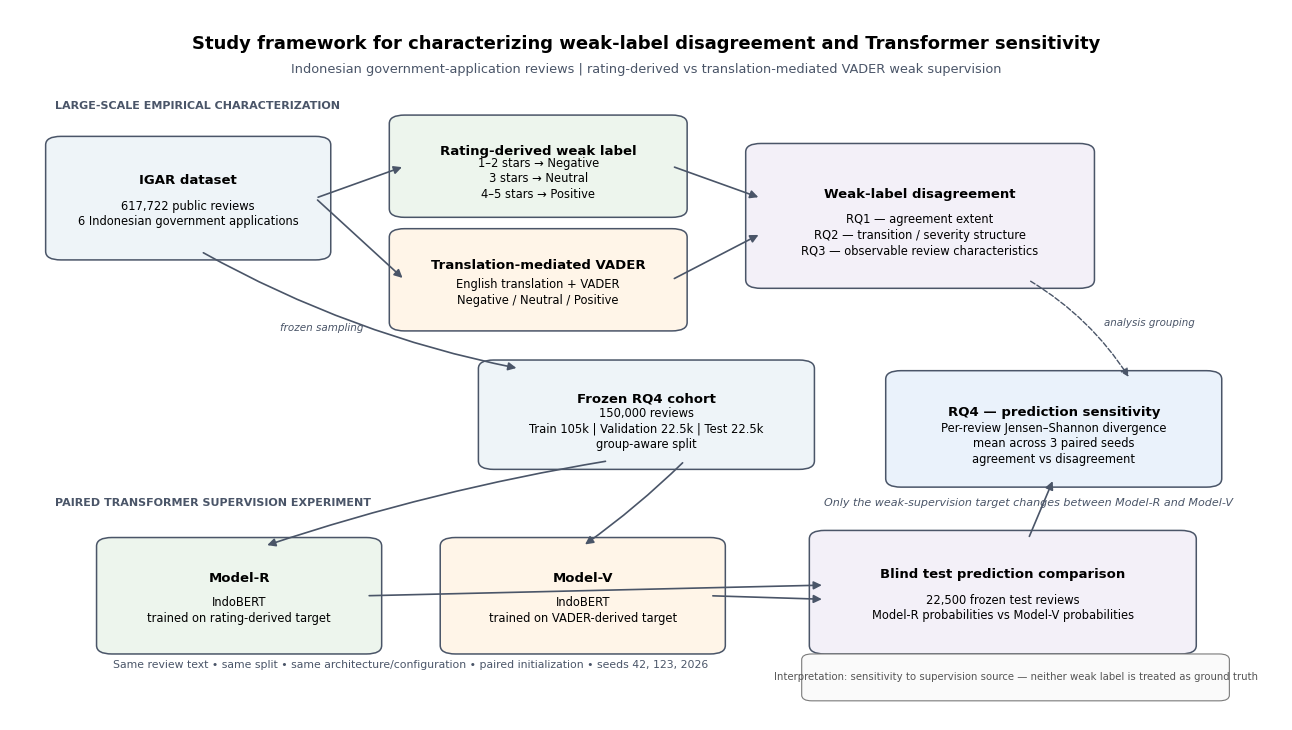


✓ PAPER 1 FIGURE 1 FINAL VISUAL QC — PASS

Conceptual cohort provenance:
IGAR dataset -> Frozen RQ4 cohort

Role of weak-label disagreement in RQ4:
Analysis grouping / predictor — NOT cohort-generation mechanism

PNG:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Figure1_Study_Framework_FINAL.png
SHA256: 3bae4f6cf99ebc6c1d1ca637b342a91d1fb47d57acfec6c60b95e18affda07b5

PDF:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/figures/Figure1_Study_Framework_FINAL.pdf
SHA256: 5309aaa60c6f7c508ef9a9d12ecd6cc2e5f65eec90ed1f925b21c797cd74ebf3

Scientific results changed: False
New statistical tests: False
Ground-truth claim: False

FIGURE 1   : FINAL / LOCKED
FIGURES 2-5: FINAL / LOCKED
ALL MAIN DATA TABLES: LOCKED
NEXT: MANUSCRIPT RESULTS ARCHITECTURE


In [31]:
# ============================================================
# [PAPER 1] CELL 71A
# FIGURE 1 — FINAL VISUAL / CONCEPTUAL QC
#
# Changes:
# - correct cohort provenance:
#       IGAR dataset -> Frozen RQ4 cohort
# - disagreement -> RQ4 shown as analysis grouping,
#   not as cohort-generation path
# - improve lower-margin spacing
# - NO scientific results changed
# - NO new statistical analysis
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
)
import hashlib
import json
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

FIGURE_DIR = (
    PAPER_READY_ROOT
    /
    "figures"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. VERIFY ORIGINAL FIGURE 1
# ============================================================

ORIGINAL_MANIFEST = (
    MANIFEST_DIR
    /
    "Paper1_Figure1_Study_Framework_PASS.json"
)

assert ORIGINAL_MANIFEST.exists()

with open(
    ORIGINAL_MANIFEST,
    encoding="utf-8"
) as f:

    original = json.load(f)


assert original["status"] == "PASS"
assert original["scientific_results_recomputed"] is False
assert original["new_statistical_tests"] is False
assert original["ground_truth_claim"] is False


print("✓ Original Figure 1 manifest verified.")


# ============================================================
# 3. SETTINGS
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        9,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,
})


# ============================================================
# 4. HELPERS
# ============================================================

def add_box(
    ax,
    x,
    y,
    w,
    h,
    title,
    body=None,
    facecolor="#F4F6F8",
    edgecolor="#4A5568",
    title_size=9.5,
    body_size=8.3,
    linewidth=1.1,
):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            "round,pad=0.012,"
            "rounding_size=0.012"
        ),
        linewidth=linewidth,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )

    ax.add_patch(box)

    if body is None:

        ax.text(
            x + w / 2,
            y + h / 2,
            title,
            ha="center",
            va="center",
            fontsize=title_size,
            fontweight="bold",
            wrap=True,
        )

    else:

        ax.text(
            x + w / 2,
            y + h * 0.67,
            title,
            ha="center",
            va="center",
            fontsize=title_size,
            fontweight="bold",
            wrap=True,
        )

        ax.text(
            x + w / 2,
            y + h * 0.35,
            body,
            ha="center",
            va="center",
            fontsize=body_size,
            wrap=True,
            linespacing=1.25,
        )

    return box


def add_arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    connectionstyle="arc3",
    linewidth=1.2,
    linestyle="-",
):

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=12,
        linewidth=linewidth,
        edgecolor="#4A5568",
        facecolor="#4A5568",
        connectionstyle=connectionstyle,
        shrinkA=2,
        shrinkB=2,
        linestyle=linestyle,
    )

    ax.add_patch(arrow)


def add_section_label(
    ax,
    x,
    y,
    text,
):

    ax.text(
        x,
        y,
        text.upper(),
        ha="left",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#4A5568",
    )


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 5. CANVAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.2, 7.3)
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


# ============================================================
# 6. TITLE
# ============================================================

ax.text(
    0.5,
    0.965,
    (
        "Study framework for characterizing weak-label "
        "disagreement and Transformer sensitivity"
    ),
    ha="center",
    va="top",
    fontsize=13,
    fontweight="bold",
)


ax.text(
    0.5,
    0.925,
    (
        "Indonesian government-application reviews | "
        "rating-derived vs translation-mediated "
        "VADER weak supervision"
    ),
    ha="center",
    va="top",
    fontsize=9.3,
    color="#4A5568",
)


# ============================================================
# 7. EMPIRICAL CHARACTERIZATION
# ============================================================

add_section_label(
    ax,
    0.035,
    0.865,
    "Large-scale empirical characterization"
)


# Dataset
add_box(
    ax,
    0.04,
    0.66,
    0.20,
    0.15,
    "IGAR dataset",
    (
        "617,722 public reviews\n"
        "6 Indonesian government applications"
    ),
    facecolor="#EEF4F8",
)


# Rating weak label
add_box(
    ax,
    0.31,
    0.72,
    0.21,
    0.12,
    "Rating-derived weak label",
    (
        "1–2 stars → Negative\n"
        "3 stars → Neutral\n"
        "4–5 stars → Positive"
    ),
    facecolor="#EDF5ED",
)


# VADER weak label
add_box(
    ax,
    0.31,
    0.56,
    0.21,
    0.12,
    "Translation-mediated VADER",
    (
        "English translation + VADER\n"
        "Negative / Neutral / Positive"
    ),
    facecolor="#FFF5E8",
)


# Dataset -> labels
add_arrow(
    ax,
    0.24,
    0.735,
    0.31,
    0.78,
)

add_arrow(
    ax,
    0.24,
    0.735,
    0.31,
    0.62,
)


# Disagreement characterization
add_box(
    ax,
    0.59,
    0.62,
    0.25,
    0.18,
    "Weak-label disagreement",
    (
        "RQ1 — agreement extent\n"
        "RQ2 — transition / severity structure\n"
        "RQ3 — observable review characteristics"
    ),
    facecolor="#F3F0F8",
)


add_arrow(
    ax,
    0.52,
    0.78,
    0.59,
    0.735,
)

add_arrow(
    ax,
    0.52,
    0.62,
    0.59,
    0.685,
)


# ============================================================
# 8. FROZEN RQ4 COHORT
#
# Critical conceptual correction:
# cohort comes from IGAR dataset, not from the observed
# disagreement result.
# ============================================================

add_box(
    ax,
    0.38,
    0.365,
    0.24,
    0.13,
    "Frozen RQ4 cohort",
    (
        "150,000 reviews\n"
        "Train 105k | Validation 22.5k | Test 22.5k\n"
        "group-aware split"
    ),
    facecolor="#EEF4F8",
)


# Dataset -> cohort
add_arrow(
    ax,
    0.15,
    0.66,
    0.40,
    0.495,
    connectionstyle="arc3,rad=0.08",
)


# Explicit sampling label
ax.text(
    0.245,
    0.548,
    "frozen sampling",
    fontsize=7.5,
    color="#4A5568",
    fontstyle="italic",
    ha="center",
)


# ============================================================
# 9. PAIRED TRANSFORMER EXPERIMENT
# ============================================================

add_section_label(
    ax,
    0.035,
    0.305,
    "Paired Transformer supervision experiment"
)


# Model R
add_box(
    ax,
    0.08,
    0.105,
    0.20,
    0.14,
    "Model-R",
    (
        "IndoBERT\n"
        "trained on rating-derived target"
    ),
    facecolor="#EDF5ED",
)


# Model V
add_box(
    ax,
    0.35,
    0.105,
    0.20,
    0.14,
    "Model-V",
    (
        "IndoBERT\n"
        "trained on VADER-derived target"
    ),
    facecolor="#FFF5E8",
)


# Cohort -> models
add_arrow(
    ax,
    0.47,
    0.365,
    0.20,
    0.245,
    connectionstyle="arc3,rad=0.04",
)

add_arrow(
    ax,
    0.53,
    0.365,
    0.45,
    0.245,
    connectionstyle="arc3,rad=-0.04",
)


ax.text(
    0.315,
    0.078,
    (
        "Same review text • same split • "
        "same architecture/configuration • "
        "paired initialization • seeds 42, 123, 2026"
    ),
    ha="center",
    va="center",
    fontsize=7.8,
    color="#4A5568",
)


# ============================================================
# 10. BLIND TEST COMPARISON
# ============================================================

add_box(
    ax,
    0.64,
    0.105,
    0.28,
    0.15,
    "Blind test prediction comparison",
    (
        "22,500 frozen test reviews\n"
        "Model-R probabilities vs Model-V probabilities"
    ),
    facecolor="#F3F0F8",
)


add_arrow(
    ax,
    0.28,
    0.175,
    0.64,
    0.19,
)

add_arrow(
    ax,
    0.55,
    0.175,
    0.64,
    0.17,
)


# ============================================================
# 11. RQ4
# ============================================================

add_box(
    ax,
    0.70,
    0.34,
    0.24,
    0.14,
    "RQ4 — prediction sensitivity",
    (
        "Per-review Jensen–Shannon divergence\n"
        "mean across 3 paired seeds\n"
        "agreement vs disagreement"
    ),
    facecolor="#EAF2FB",
)


# Predictions -> JSD/RQ4
add_arrow(
    ax,
    0.80,
    0.255,
    0.82,
    0.34,
)


# ============================================================
# 12. DISAGREEMENT AS ANALYSIS GROUPING
#
# Dashed conceptual link:
# disagreement status is used to group/compare JSD,
# but does not generate the cohort.
# ============================================================

add_arrow(
    ax,
    0.80,
    0.62,
    0.88,
    0.48,
    connectionstyle="arc3,rad=-0.12",
    linewidth=1.0,
    linestyle="--",
)


ax.text(
    0.895,
    0.555,
    "analysis grouping",
    fontsize=7.4,
    color="#4A5568",
    fontstyle="italic",
    ha="center",
)


# ============================================================
# 13. DESIGN EMPHASIS
# ============================================================

ax.text(
    0.80,
    0.305,
    (
        "Only the weak-supervision target changes "
        "between Model-R and Model-V"
    ),
    ha="center",
    va="center",
    fontsize=8,
    fontstyle="italic",
    color="#4A5568",
)


# ============================================================
# 14. INTERPRETATION BOUNDARY
# ============================================================

boundary = FancyBboxPatch(
    (0.63, 0.035),
    0.32,
    0.050,
    boxstyle=(
        "round,pad=0.008,"
        "rounding_size=0.008"
    ),
    linewidth=0.8,
    edgecolor="#7A7A7A",
    facecolor="#FAFAFA",
)

ax.add_patch(boundary)


ax.text(
    0.79,
    0.060,
    (
        "Interpretation: sensitivity to supervision source — "
        "neither weak label is treated as ground truth"
    ),
    ha="center",
    va="center",
    fontsize=7.3,
    color="#555555",
)


# ============================================================
# 15. SAVE FINAL
# ============================================================

fig.tight_layout(
    pad=0.8
)


FIG1_FINAL_PNG = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework_FINAL.png"
)

FIG1_FINAL_PDF = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework_FINAL.pdf"
)


fig.savefig(
    FIG1_FINAL_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG1_FINAL_PDF,
    bbox_inches="tight",
)


assert FIG1_FINAL_PNG.exists()
assert FIG1_FINAL_PDF.exists()


plt.show()
plt.close(fig)


# ============================================================
# 16. FINAL CAPTION
# ============================================================

CAPTION_FILE = (
    FIGURE_DIR
    /
    "Figure1_Study_Framework_Caption_FINAL.md"
)


caption = """
## Figure 1
**Study framework for characterizing weak-label disagreement and Transformer sensitivity.**
The study compares two inexpensive sentiment-supervision signals across
617,722 public reviews from six Indonesian government applications:
a rating-derived weak label and a translation-mediated VADER weak label.
RQ1–RQ3 characterize agreement, directional disagreement structure, and
observable review characteristics associated with disagreement. Independently,
a frozen 150,000-review cohort sampled from the IGAR dataset is used for the
RQ4 paired Transformer experiment. Model-R and Model-V use the same review
texts, split, architecture, training configuration, and paired initialization
within each random seed, while differing only in the weak-supervision target.
On the frozen 22,500-review test set, prediction sensitivity is quantified
using review-level Jensen–Shannon divergence between paired predictive
probability distributions, averaged across three seeds. Weak-label agreement
status is then used to compare prediction divergence. Neither weak-label
source is treated as ground truth.
""".strip()


with open(
    CAPTION_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(caption)

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 17. FINAL FIGURE 1 LOCK
# ============================================================

FINAL_MANIFEST = (
    MANIFEST_DIR
    /
    "Paper1_Figure1_Final_VisualQC_PASS.json"
)


manifest = {

    "status":
        "PASS",

    "figure":
        "Figure 1",

    "visual_qc":
        "FINAL",

    "conceptual_provenance_corrected":
        True,

    "cohort_source":
        "IGAR dataset",

    "disagreement_role_in_rq4":
        "analysis grouping",

    "scientific_results_changed":
        False,

    "scientific_results_recomputed":
        False,

    "new_statistical_tests":
        False,

    "ground_truth_claim":
        False,

    "png":
        str(
            FIG1_FINAL_PNG
        ),

    "pdf":
        str(
            FIG1_FINAL_PDF
        ),

    "png_sha256":
        sha256_file(
            FIG1_FINAL_PNG
        ),

    "pdf_sha256":
        sha256_file(
            FIG1_FINAL_PDF
        ),

    "caption":
        str(
            CAPTION_FILE
        ),

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    FINAL_MANIFEST,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 18. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ PAPER 1 FIGURE 1 FINAL VISUAL QC — PASS"
)

print(
    "=" * 124
)


print(
    "\nConceptual cohort provenance:"
)

print(
    "IGAR dataset -> Frozen RQ4 cohort"
)


print(
    "\nRole of weak-label disagreement in RQ4:"
)

print(
    "Analysis grouping / predictor — "
    "NOT cohort-generation mechanism"
)


print(
    "\nPNG:"
)

print(
    FIG1_FINAL_PNG
)

print(
    "SHA256:",
    sha256_file(
        FIG1_FINAL_PNG
    )
)


print(
    "\nPDF:"
)

print(
    FIG1_FINAL_PDF
)

print(
    "SHA256:",
    sha256_file(
        FIG1_FINAL_PDF
    )
)


print(
    "\nScientific results changed:",
    False
)

print(
    "New statistical tests:",
    False
)

print(
    "Ground-truth claim:",
    False
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "FIGURE 1   : FINAL / LOCKED"
)

print(
    "FIGURES 2-5: FINAL / LOCKED"
)

print(
    "ALL MAIN DATA TABLES: LOCKED"
)

print(
    "NEXT: MANUSCRIPT RESULTS ARCHITECTURE"
)

print(
    "=" * 124
)

In [32]:
# ============================================================
# [PAPER 1] CELL 72A
# MANUSCRIPT RESULTS ARCHITECTURE — FINAL LOCK
#
# Purpose:
# - define Results subsections 3.1–3.4
# - map frozen results -> claims -> tables/figures
# - prevent result drift during manuscript writing
#
# NO new statistical tests
# NO model fitting
# NO modification of frozen scientific results
# ============================================================

from pathlib import Path
import pandas as pd
import json
import os
import datetime


# ============================================================
# 1. ROOTS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

PAPER_READY_ROOT = (
    PROJECT_ROOT
    /
    "paper_ready"
)

TABLE_DIR = (
    PAPER_READY_ROOT
    /
    "tables"
)

SUPPLEMENT_DIR = (
    PAPER_READY_ROOT
    /
    "supplementary"
)

FIGURE_DIR = (
    PAPER_READY_ROOT
    /
    "figures"
)

MANIFEST_DIR = (
    PAPER_READY_ROOT
    /
    "manifests"
)

MANUSCRIPT_DIR = (
    PAPER_READY_ROOT
    /
    "manuscript"
)

MANUSCRIPT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. VERIFY FINAL LOCKS
# ============================================================

required_manifests = [

    MANIFEST_DIR
    /
    "Paper1_FINAL_Scientific_Source_Map_LOCKED.json",

    MANIFEST_DIR
    /
    "Paper1_Figure1_Final_VisualQC_PASS.json",

    MANIFEST_DIR
    /
    "Paper1_Figure2-5_Final_VisualQC_PASS.json",

    PROJECT_ROOT
    /
    "phase3/rq4_final/statistics/"
    "RQ4_FINAL_SCIENTIFIC_FREEZE_5b7ffaa036af.json",
]


for path in required_manifests:

    assert path.exists(), (
        f"Missing required lock: {path}"
    )


print(
    "✓ Scientific source map verified."
)

print(
    "✓ Figure 1 final QC verified."
)

print(
    "✓ Figures 2–5 final QC verified."
)

print(
    "✓ RQ4 scientific freeze verified."
)


# ============================================================
# 3. LOAD FROZEN MAIN TABLES
# ============================================================

table1 = pd.read_csv(
    TABLE_DIR
    /
    "Table1_RQ1_WeakLabel_Agreement_Overall_PerApp.csv"
)


table2_counts = pd.read_csv(
    TABLE_DIR
    /
    "Table2A_RQ1_WeakLabel_Transition_Counts.csv"
)


table2_pct = pd.read_csv(
    TABLE_DIR
    /
    "Table2B_RQ1_WeakLabel_Transition_RowPercent.csv"
)


table3 = pd.read_csv(
    TABLE_DIR
    /
    "Table3_RQ3_Primary_Adjusted_OR.csv"
)


table4 = pd.read_csv(
    TABLE_DIR
    /
    "Table4_RQ4_Primary_JSD.csv"
)


# Supplementary frozen sources.
star = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS1_RQ2_Disagreement_By_StarRating.csv"
)


rq2_transition = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS2_RQ2_Transition_Structure.csv"
)


rq2_domain = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS3_RQ2_Domain_Disagreement_Severity.csv"
)


rq3_year = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS5_RQ3_YearAdjusted_Sensitivity.csv"
)


rq4_cluster = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS6_RQ4_LargeCluster_Sensitivity.csv"
)


rq4_severity = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS7_RQ4_Severity.csv"
)


rq4_app = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS8_RQ4_App_Heterogeneity.csv"
)


rq4_transition = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS9_RQ4_Transition_Description.csv"
)


rq4_secondary = pd.read_csv(
    SUPPLEMENT_DIR
    /
    "TableS10_RQ4_Secondary_Prediction_Diagnostics.csv"
)


# ============================================================
# 4. HARD-CODED FROZEN CLAIM VALUES
#
# These values are already established/frozen.
# Assertions below ensure manuscript values still match
# their corresponding locked source files.
# ============================================================

FROZEN = {

    # --------------------------------------------------------
    # RQ1
    # --------------------------------------------------------

    "dataset_n":
        617722,

    "agreement_n":
        362308,

    "agreement_pct":
        58.652274,

    "disagreement_n":
        255414,

    "disagreement_pct":
        41.347726,

    "cohen_kappa":
        0.333802,


    # --------------------------------------------------------
    # RQ2
    # --------------------------------------------------------

    "star1_disagreement_pct":
        57.909559,

    "star2_disagreement_pct":
        68.656268,

    "star3_disagreement_pct":
        64.072727,

    "star4_disagreement_pct":
        34.361749,

    "star5_disagreement_pct":
        24.602550,

    "neg_to_pos_n":
        60542,

    "pos_to_neg_n":
        11868,

    "severity1_n":
        183004,

    "severity2_n":
        72410,


    # --------------------------------------------------------
    # RQ3
    # --------------------------------------------------------

    "or_star1":
        4.740710,

    "or_star2":
        7.545969,

    "or_star3":
        5.915649,

    "or_star4":
        1.631890,

    "or_log_words":
        0.877920,

    "or_log_words_low":
        0.815845,

    "or_log_words_high":
        0.944718,


    # --------------------------------------------------------
    # RQ4
    # --------------------------------------------------------

    "rq4_n":
        22500,

    "rq4_clusters":
        15921,

    "mean_jsd_agreement":
        0.051900,

    "mean_jsd_disagreement":
        0.406469,

    "rq4_beta":
        0.354569,

    "rq4_se":
        0.006108,

    "rq4_ci_low":
        0.342597,

    "rq4_ci_high":
        0.366541,

    "cluster_sensitivity_max_change_pct":
        2.056,

    "hard_agreement_pct":
        9.15,

    "hard_disagreement_pct":
        79.99,

    "severity_mean_s0":
        0.051900,

    "severity_mean_s1":
        0.440888,

    "severity_mean_s2":
        0.319494,
}


# ============================================================
# 5. ASSERT AGAINST LOCKED SOURCES
# ============================================================

overall = (
    table1.loc[
        table1["scope"].eq("Overall")
    ]
    .iloc[0]
)


assert int(
    overall["N"]
) == FROZEN["dataset_n"]

assert int(
    overall["agreement_n"]
) == FROZEN["agreement_n"]

assert abs(
    float(overall["agreement_pct"])
    -
    FROZEN["agreement_pct"]
) < 1e-6

assert abs(
    float(overall["disagreement_pct"])
    -
    FROZEN["disagreement_pct"]
) < 1e-6

assert abs(
    float(overall["cohen_kappa"])
    -
    FROZEN["cohen_kappa"]
) < 1e-6


# RQ4 primary.
rq4_primary = table4.iloc[0]

assert int(
    rq4_primary["N"]
) == FROZEN["rq4_n"]

assert int(
    rq4_primary["clusters"]
) == FROZEN["rq4_clusters"]

assert abs(
    float(
        rq4_primary[
            "effect_beta"
        ]
    )
    -
    FROZEN["rq4_beta"]
) < 1e-6


print(
    "✓ Frozen manuscript values verified against locked tables."
)


# ============================================================
# 6. RESULTS ARCHITECTURE
# ============================================================

architecture_rows = [

    # ========================================================
    # 3.1 — RQ1
    # ========================================================

    {
        "section":
            "3.1",

        "rq":
            "RQ1",

        "heading":
            (
                "Agreement between the two "
                "weak-supervision sources"
            ),

        "claim_order":
            1,

        "claim":
            (
                "Overall agreement was 58.65% "
                "(362,308/617,722), leaving 41.35% "
                "of reviews with weak-label disagreement."
            ),

        "statistics":
            (
                "Agreement=58.65%; "
                "Disagreement=41.35%"
            ),

        "main_table":
            "Table 1",

        "main_figure":
            "Figure 2",

        "supplement":
            "None",

        "interpretation_boundary":
            (
                "Describe agreement/disagreement only; "
                "do not call disagreements errors."
            ),
    },

    {
        "section":
            "3.1",

        "rq":
            "RQ1",

        "heading":
            (
                "Agreement between the two "
                "weak-supervision sources"
            ),

        "claim_order":
            2,

        "claim":
            (
                "Cohen's kappa was 0.334, indicating "
                "limited correspondence beyond chance."
            ),

        "statistics":
            "κ=0.334",

        "main_table":
            "Table 1",

        "main_figure":
            "Figure 2",

        "supplement":
            "None",

        "interpretation_boundary":
            (
                "Do not infer which weak-label source "
                "is more valid."
            ),
    },


    # ========================================================
    # 3.2 — RQ2
    # ========================================================

    {
        "section":
            "3.2",

        "rq":
            "RQ2",

        "heading":
            (
                "Directional structure and severity "
                "of weak-label disagreement"
            ),

        "claim_order":
            1,

        "claim":
            (
                "Disagreement was strongly directional "
                "rather than symmetrically distributed "
                "across the 3×3 transition matrix."
            ),

        "statistics":
            (
                "Negative→Positive=60,542; "
                "Positive→Negative=11,868"
            ),

        "main_table":
            "Table 2",

        "main_figure":
            "Figure 2",

        "supplement":
            "Table S2",

        "interpretation_boundary":
            (
                "Directional asymmetry does not identify "
                "either transition direction as erroneous."
            ),
    },

    {
        "section":
            "3.2",

        "rq":
            "RQ2",

        "heading":
            (
                "Directional structure and severity "
                "of weak-label disagreement"
            ),

        "claim_order":
            2,

        "claim":
            (
                "Most disagreements were adjacent "
                "(severity 1), while extreme polarity "
                "disagreements formed the minority."
            ),

        "statistics":
            (
                "S1=183,004; S2=72,410"
            ),

        "main_table":
            "Table 2",

        "main_figure":
            "Figure 2",

        "supplement":
            "Tables S2–S3",

        "interpretation_boundary":
            (
                "Severity refers to label distance, "
                "not severity of labeling error."
            ),
    },

    {
        "section":
            "3.2",

        "rq":
            "RQ2",

        "heading":
            (
                "Directional structure and severity "
                "of weak-label disagreement"
            ),

        "claim_order":
            3,

        "claim":
            (
                "Weak-label disagreement varied markedly "
                "by star rating, peaking at 2 stars "
                "and declining substantially at 4–5 stars."
            ),

        "statistics":
            (
                "1★=57.91%; 2★=68.66%; "
                "3★=64.07%; 4★=34.36%; 5★=24.60%"
            ),

        "main_table":
            "None",

        "main_figure":
            "Figure 3",

        "supplement":
            "Table S1",

        "interpretation_boundary":
            (
                "Describe association/structure, "
                "not causal effects."
            ),
    },


    # ========================================================
    # 3.3 — RQ3
    # ========================================================

    {
        "section":
            "3.3",

        "rq":
            "RQ3",

        "heading":
            (
                "Observable review characteristics "
                "associated with disagreement"
            ),

        "claim_order":
            1,

        "claim":
            (
                "Relative to 5-star reviews, lower star "
                "ratings showed substantially higher "
                "adjusted odds of weak-label disagreement."
            ),

        "statistics":
            (
                "1★ OR=4.74; 2★ OR=7.55; "
                "3★ OR=5.92; 4★ OR=1.63"
            ),

        "main_table":
            "Table 3",

        "main_figure":
            "Figure 4",

        "supplement":
            "Table S4",

        "interpretation_boundary":
            (
                "Association only; do not infer that "
                "rating causes disagreement."
            ),
    },

    {
        "section":
            "3.3",

        "rq":
            "RQ3",

        "heading":
            (
                "Observable review characteristics "
                "associated with disagreement"
            ),

        "claim_order":
            2,

        "claim":
            (
                "Longer reviews were associated with "
                "lower odds of disagreement."
            ),

        "statistics":
            (
                "OR per unit log(words)=0.878; "
                "95% CI [0.816, 0.945]"
            ),

        "main_table":
            "Table 3",

        "main_figure":
            "Figure 4",

        "supplement":
            "Table S4",

        "interpretation_boundary":
            (
                "Review length is an observed correlate, "
                "not a causal determinant."
            ),
    },

    {
        "section":
            "3.3",

        "rq":
            "RQ3",

        "heading":
            (
                "Observable review characteristics "
                "associated with disagreement"
            ),

        "claim_order":
            3,

        "claim":
            (
                "Application-specific associations in the "
                "primary model were not temporally stable "
                "after adjustment for review year."
            ),

        "statistics":
            (
                "Year-adjusted application CIs include 1"
            ),

        "main_table":
            "Table 3",

        "main_figure":
            "Figure 4",

        "supplement":
            "Table S5",

        "interpretation_boundary":
            (
                "Do not present primary app coefficients "
                "as robust domain effects."
            ),
    },


    # ========================================================
    # 3.4 — RQ4
    # ========================================================

    {
        "section":
            "3.4",

        "rq":
            "RQ4",

        "heading":
            (
                "Transformer sensitivity to the "
                "weak-supervision source"
            ),

        "claim_order":
            1,

        "claim":
            (
                "Reviews with weak-label disagreement "
                "showed substantially greater paired "
                "Transformer prediction divergence."
            ),

        "statistics":
            (
                "Mean JSD: agreement=0.0519, "
                "disagreement=0.4065; "
                "β=0.3546; SE=0.0061; "
                "95% CI [0.3426, 0.3665]; p<.001"
            ),

        "main_table":
            "Table 4",

        "main_figure":
            "Figure 5",

        "supplement":
            "None",

        "interpretation_boundary":
            (
                "Sensitivity to supervision source; "
                "neither weak label is ground truth."
            ),
    },

    {
        "section":
            "3.4",

        "rq":
            "RQ4",

        "heading":
            (
                "Transformer sensitivity to the "
                "weak-supervision source"
            ),

        "claim_order":
            2,

        "claim":
            (
                "The primary association was robust to "
                "removal of the largest duplicate groups."
            ),

        "statistics":
            (
                "Maximum absolute beta change=2.06%"
            ),

        "main_table":
            "None",

        "main_figure":
            "None",

        "supplement":
            "Table S6",

        "interpretation_boundary":
            (
                "Post-primary sensitivity analysis; "
                "does not redefine H4."
            ),
    },

    {
        "section":
            "3.4",

        "rq":
            "RQ4",

        "heading":
            (
                "Transformer sensitivity to the "
                "weak-supervision source"
            ),

        "claim_order":
            3,

        "claim":
            (
                "The direction of greater prediction "
                "divergence under weak-label disagreement "
                "was observed descriptively in all six applications."
            ),

        "statistics":
            "Positive D1−D0 difference in 6/6 applications",

        "main_table":
            "None",

        "main_figure":
            "None",

        "supplement":
            "Table S8",

        "interpretation_boundary":
            (
                "Descriptive cross-application consistency; "
                "no formal interaction test."
            ),
    },

    {
        "section":
            "3.4",

        "rq":
            "RQ4",

        "heading":
            (
                "Transformer sensitivity to the "
                "weak-supervision source"
            ),

        "claim_order":
            4,

        "claim":
            (
                "Exploratory severity analysis was "
                "non-monotonic: adjacent disagreements "
                "showed greater mean JSD than extreme "
                "Negative–Positive disagreements."
            ),

        "statistics":
            (
                "S0=0.0519; S1=0.4409; S2=0.3195"
            ),

        "main_table":
            "None",

        "main_figure":
            "None",

        "supplement":
            "Tables S7 and S9",

        "interpretation_boundary":
            (
                "Exploratory only; label distance is "
                "not equivalent to model ambiguity."
            ),
    },

    {
        "section":
            "3.4",

        "rq":
            "RQ4",

        "heading":
            (
                "Transformer sensitivity to the "
                "weak-supervision source"
            ),

        "claim_order":
            5,

        "claim":
            (
                "Secondary hard-prediction diagnostics "
                "triangulated the probabilistic JSD result."
            ),

        "statistics":
            (
                "Hard Model-R/Model-V disagreement: "
                "9.15% vs 79.99%"
            ),

        "main_table":
            "None",

        "main_figure":
            "None",

        "supplement":
            "Table S10",

        "interpretation_boundary":
            (
                "Secondary diagnostic only; "
                "do not compare Model-R and Model-V "
                "F1 as supervision-source superiority."
            ),
    },
]


architecture = pd.DataFrame(
    architecture_rows
)


# ============================================================
# 7. ORDER + VALIDATE
# ============================================================

architecture = (
    architecture
    .sort_values(
        [
            "section",
            "claim_order",
        ]
    )
    .reset_index(drop=True)
)


assert set(
    architecture["section"]
) == {
    "3.1",
    "3.2",
    "3.3",
    "3.4",
}


assert (
    architecture[
        "interpretation_boundary"
    ]
    .notna()
    .all()
)


# ============================================================
# 8. SAVE ARCHITECTURE TABLE
# ============================================================

ARCHITECTURE_CSV = (
    MANUSCRIPT_DIR
    /
    "Paper1_Results_Architecture_LOCKED.csv"
)


architecture.to_csv(
    ARCHITECTURE_CSV,
    index=False
)


# ============================================================
# 9. CREATE MARKDOWN BLUEPRINT
# ============================================================

MARKDOWN_FILE = (
    MANUSCRIPT_DIR
    /
    "Paper1_Results_Architecture_LOCKED.md"
)


lines = []

lines.append(
    "# Paper 1 — Results Architecture"
)

lines.append("")

lines.append(
    "**Status:** LOCKED"
)

lines.append("")

lines.append(
    "No new statistical analyses are permitted during "
    "Results drafting unless the scientific freeze is explicitly reopened."
)

lines.append("")


for section in [
    "3.1",
    "3.2",
    "3.3",
    "3.4",
]:

    subset = (
        architecture.loc[
            architecture[
                "section"
            ].eq(section)
        ]
        .sort_values(
            "claim_order"
        )
    )


    heading = subset[
        "heading"
    ].iloc[0]


    lines.append(
        f"## {section} {heading}"
    )

    lines.append("")


    for _, row in subset.iterrows():

        lines.append(
            f"### Claim {int(row['claim_order'])}"
        )

        lines.append("")

        lines.append(
            row["claim"]
        )

        lines.append("")

        lines.append(
            f"**Frozen statistics:** {row['statistics']}"
        )

        lines.append("")

        lines.append(
            f"**Main table:** {row['main_table']}"
        )

        lines.append("")

        lines.append(
            f"**Main figure:** {row['main_figure']}"
        )

        lines.append("")

        lines.append(
            f"**Supplement:** {row['supplement']}"
        )

        lines.append("")

        lines.append(
            "**Interpretation boundary:** "
            +
            row[
                "interpretation_boundary"
            ]
        )

        lines.append("")


with open(
    MARKDOWN_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(lines)
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 10. SECTION / TABLE / FIGURE MAP
# ============================================================

section_map = pd.DataFrame([

    {
        "section":
            "3.1",

        "RQ":
            "RQ1",

        "main_table":
            "Table 1",

        "main_figure":
            "Figure 2",

        "primary_message":
            (
                "Agreement is incomplete and varies "
                "across applications."
            ),
    },

    {
        "section":
            "3.2",

        "RQ":
            "RQ2",

        "main_table":
            "Table 2",

        "main_figure":
            "Figures 2–3",

        "primary_message":
            (
                "Disagreement is directional and strongly "
                "structured by star rating."
            ),
    },

    {
        "section":
            "3.3",

        "RQ":
            "RQ3",

        "main_table":
            "Table 3",

        "main_figure":
            "Figure 4",

        "primary_message":
            (
                "Observed disagreement has systematic "
                "review-level correlates."
            ),
    },

    {
        "section":
            "3.4",

        "RQ":
            "RQ4",

        "main_table":
            "Table 4",

        "main_figure":
            "Figure 5",

        "primary_message":
            (
                "Weak-label disagreement is associated "
                "with substantially greater Transformer "
                "sensitivity to supervision source."
            ),
    },
])


SECTION_MAP_FILE = (
    MANUSCRIPT_DIR
    /
    "Paper1_Results_Section_Table_Figure_Map.csv"
)


section_map.to_csv(
    SECTION_MAP_FILE,
    index=False
)


# ============================================================
# 11. FINAL RESULTS ARCHITECTURE MANIFEST
# ============================================================

LOCK_FILE = (
    MANIFEST_DIR
    /
    "Paper1_Results_Architecture_LOCKED.json"
)


lock = {

    "status":
        "LOCKED",

    "stage":
        "MANUSCRIPT_RESULTS_ARCHITECTURE",

    "sections":
        [
            "3.1 RQ1",
            "3.2 RQ2",
            "3.3 RQ3",
            "3.4 RQ4",
        ],

    "number_of_claims":
        int(
            len(architecture)
        ),

    "main_tables":
        [
            "Table 1",
            "Table 2",
            "Table 3",
            "Table 4",
        ],

    "main_figures":
        [
            "Figure 1",
            "Figure 2",
            "Figure 3",
            "Figure 4",
            "Figure 5",
        ],

    "scientific_results_recomputed":
        False,

    "new_statistical_tests":
        False,

    "results_claims_frozen":
        True,

    "ground_truth_claim_allowed":
        False,

    "preferred_term":
        "weak-label disagreement",

    "next_stage":
        "DRAFT_RESULTS_SECTION",

    "architecture_csv":
        str(
            ARCHITECTURE_CSV
        ),

    "architecture_markdown":
        str(
            MARKDOWN_FILE
        ),

    "section_map":
        str(
            SECTION_MAP_FILE
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


with open(
    LOCK_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        lock,
        f,
        indent=2
    )

    f.flush()
    os.fsync(
        f.fileno()
    )


# ============================================================
# 12. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ PAPER 1 MANUSCRIPT RESULTS ARCHITECTURE — LOCKED"
)

print(
    "=" * 124
)


print(
    "\nSECTION / TABLE / FIGURE MAP"
)

display(
    section_map
)


print(
    "\nRESULT CLAIM ARCHITECTURE"
)

display(
    architecture[
        [
            "section",
            "rq",
            "claim_order",
            "claim",
            "statistics",
            "main_table",
            "main_figure",
            "supplement",
        ]
    ]
)


print(
    "\nNumber of locked Results claims:",
    len(architecture)
)


print(
    "\nScientific results recomputed:",
    False
)

print(
    "New statistical tests:",
    False
)

print(
    "Ground-truth claim allowed:",
    False
)


print(
    "\nArchitecture markdown:"
)

print(
    MARKDOWN_FILE
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "RESULTS ARCHITECTURE : FINAL / LOCKED"
)

print(
    "TABLES 1–4          : FINAL / LOCKED"
)

print(
    "FIGURES 1–5         : FINAL / LOCKED"
)

print(
    "NEXT                : DRAFT RESULTS SECTION 3.1–3.4"
)

print(
    "=" * 124
)

✓ Scientific source map verified.
✓ Figure 1 final QC verified.
✓ Figures 2–5 final QC verified.
✓ RQ4 scientific freeze verified.
✓ Frozen manuscript values verified against locked tables.

✓ PAPER 1 MANUSCRIPT RESULTS ARCHITECTURE — LOCKED

SECTION / TABLE / FIGURE MAP


,section,RQ,main_table,main_figure,primary_message
0,3.1,RQ1,Table 1,Figure 2,Agreement is incomplete and varies across appl...
1,3.2,RQ2,Table 2,Figures 2–3,Disagreement is directional and strongly struc...
2,3.3,RQ3,Table 3,Figure 4,Observed disagreement has systematic review-le...
3,3.4,RQ4,Table 4,Figure 5,Weak-label disagreement is associated with sub...



RESULT CLAIM ARCHITECTURE


,section,rq,claim_order,claim,statistics,main_table,main_figure,supplement
0,3.1,RQ1,1,"Overall agreement was 58.65% (362,308/617,722)...",Agreement=58.65%; Disagreement=41.35%,Table 1,Figure 2,None
1,3.1,RQ1,2,"Cohen's kappa was 0.334, indicating limited co...",κ=0.334,Table 1,Figure 2,None
2,3.2,RQ2,1,Disagreement was strongly directional rather t...,"Negative→Positive=60,542; Positive→Negative=11...",Table 2,Figure 2,Table S2
3,3.2,RQ2,2,"Most disagreements were adjacent (severity 1),...","S1=183,004; S2=72,410",Table 2,Figure 2,Tables S2–S3
4,3.2,RQ2,3,Weak-label disagreement varied markedly by sta...,1★=57.91%; 2★=68.66%; 3★=64.07%; 4★=34.36%; 5★...,None,Figure 3,Table S1
5,3.3,RQ3,1,"Relative to 5-star reviews, lower star ratings...",1★ OR=4.74; 2★ OR=7.55; 3★ OR=5.92; 4★ OR=1.63,Table 3,Figure 4,Table S4
6,3.3,RQ3,2,Longer reviews were associated with lower odds...,"OR per unit log(words)=0.878; 95% CI [0.816, 0...",Table 3,Figure 4,Table S4
7,3.3,RQ3,3,Application-specific associations in the prima...,Year-adjusted application CIs include 1,Table 3,Figure 4,Table S5
8,3.4,RQ4,1,Reviews with weak-label disagreement showed su...,"Mean JSD: agreement=0.0519, disagreement=0.406...",Table 4,Figure 5,None
9,3.4,RQ4,2,The primary association was robust to removal ...,Maximum absolute beta change=2.06%,None,None,Table S6



Number of locked Results claims: 13

Scientific results recomputed: False
New statistical tests: False
Ground-truth claim allowed: False

Architecture markdown:
/content/drive/MyDrive/IGAR_Paper1/paper_ready/manuscript/Paper1_Results_Architecture_LOCKED.md

RESULTS ARCHITECTURE : FINAL / LOCKED
TABLES 1–4          : FINAL / LOCKED
FIGURES 1–5         : FINAL / LOCKED
NEXT                : DRAFT RESULTS SECTION 3.1–3.4


In [33]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 57A
# FP16 OVERFLOW-SAFE RETRY HOTFIX
#
# Scientific semantics:
# - global_step counts SUCCESSFUL optimizer updates only
# - scheduler advances only after successful optimizer update
# - overflowed attempt is NOT counted
# - exact same batch is retried
# - RNG is restored so dropout mask is reproduced
# - GradScaler keeps its reduced scale
#
# FINAL scientific protocol remains:
# 5b7ffaa036af
#
# NO TEST INFERENCE.
# ============================================================

import os
import gc
import json
import time
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. POLICY LOCK
# ============================================================

MAX_FP16_OVERFLOW_RETRIES_PER_STEP = 8

OVERFLOW_POLICY_CONFIG = {

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "policy":
        "retry_same_optimizer_step_after_dynamic_loss_scale_backoff",

    "global_step_definition":
        "successful optimizer updates only",

    "scheduler_advances_on_overflow":
        False,

    "scientific_example_count_advances_on_overflow":
        False,

    "same_batch_retried":
        True,

    "rng_restored_before_retry":
        True,

    "grad_scaler_reduced_scale_preserved":
        True,

    "max_retries_per_optimizer_step":
        MAX_FP16_OVERFLOW_RETRIES_PER_STEP,

    "scientific_protocol_changed":
        False,

    "cohort_changed":
        False,

    "split_changed":
        False,

    "targets_changed":
        False,

    "hyperparameters_changed":
        False,

    "training_budget_changed":
        False,

    "analysis_plan_changed":
        False,

    "test_outcomes_seen":
        False,
}


OVERFLOW_POLICY_ID = hash_dict(
    OVERFLOW_POLICY_CONFIG
)


OVERFLOW_POLICY_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /

    (
        "RQ4_FP16_Overflow_Policy_"
        +
        OVERFLOW_POLICY_ID
        +
        ".json"
    )
)


overflow_policy_artifact = {

    **OVERFLOW_POLICY_CONFIG,

    "policy_id":
        OVERFLOW_POLICY_ID,

    "reason":
        (
            "The first final Model-R run encountered a "
            "GradScaler scale reduction after checkpoint "
            "step 6000. The original engine intentionally "
            "stopped on any scale reduction. This engineering "
            "correction uses standard dynamic-loss-scaling "
            "semantics while preserving successful-update "
            "count, sample identity, scheduler position, "
            "and RNG trajectory."
        ),

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    overflow_policy_artifact,
    OVERFLOW_POLICY_FILE
)


# ============================================================
# 2. VERIFY SAFE RECOVERY POINT FOR CURRENT RUN
# ============================================================

run1_config = next(

    x
    for x in FINAL_RUN_CONFIGS

    if x[
        "run_name"
    ]
    ==
    "seed_42_ModelR"
)


run1_checkpoint = (
    latest_valid_checkpoint(
        run1_config
    )
)


assert (
    run1_checkpoint
    is not None
), (
    "No valid recovery checkpoint found for seed_42_ModelR."
)


with open(
    checkpoint_meta_path(
        run1_checkpoint
    ),
    encoding="utf-8",
) as f:

    run1_checkpoint_meta = json.load(f)


assert (
    int(
        run1_checkpoint_meta[
            "global_step"
        ]
    )
    ==
    6000
), (
    "Expected latest valid recovery point at step 6000."
)


print(
    "✓ Valid recovery checkpoint:"
)

print(
    run1_checkpoint
)

print(
    "Global step:",
    run1_checkpoint_meta[
        "global_step"
    ]
)


# ============================================================
# 3. RNG SNAPSHOT / RESTORE
#
# Critical:
# Failed attempt may consume dropout RNG.
# We undo that consumption before recomputing the same step.
# ============================================================

def capture_rq4_rng_state():

    return {

        "python":
            random.getstate(),

        "numpy":
            np.random.get_state(),

        "torch":
            torch.get_rng_state(),

        "cuda":
            torch.cuda.get_rng_state_all(),
    }


def restore_rq4_rng_state(
    state
):

    random.setstate(
        state[
            "python"
        ]
    )

    np.random.set_state(
        state[
            "numpy"
        ]
    )

    torch.set_rng_state(
        state[
            "torch"
        ]
    )

    torch.cuda.set_rng_state_all(
        state[
            "cuda"
        ]
    )


# ============================================================
# 4. PERSIST EACH OVERFLOW EVENT IMMEDIATELY
# ============================================================

def record_overflow_event(
    run_config,
    global_step,
    retry_number,
    scale_before,
    scale_after,
    epoch_idx,
    step_within_epoch,
):

    event_dir = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "overflow_events"
    )

    event_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # global_step is number of already-completed updates.
    # attempted optimizer update is global_step + 1.
    attempted_step = (
        int(
            global_step
        )
        +
        1
    )


    event_file = (

        event_dir

        /

        (
            f"overflow_step_{attempted_step:06d}"
            f"_retry_{int(retry_number):02d}.json"
        )
    )


    event = {

        "status":
            "FP16_OVERFLOW_RETRY",

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "overflow_policy_id":
            OVERFLOW_POLICY_ID,

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_config[
                "run_name"
            ],

        "completed_global_step_before_attempt":
            int(
                global_step
            ),

        "attempted_optimizer_step":
            attempted_step,

        "epoch":
            int(
                epoch_idx
                +
                1
            ),

        "optimizer_step_within_epoch":
            int(
                step_within_epoch
                +
                1
            ),

        "retry_number":
            int(
                retry_number
            ),

        "scale_before":
            float(
                scale_before
            ),

        "scale_after":
            float(
                scale_after
            ),

        "optimizer_update_counted":
            False,

        "scheduler_advanced":
            False,

        "scientific_examples_counted":
            False,

        "same_batch_will_be_retried":
            True,

        "rng_restored":
            True,

        "created_at":
            datetime.datetime.now()
            .isoformat(),
    }


    atomic_json_save(
        event,
        event_file
    )


    return event_file


# ============================================================
# 5. COUNT PERSISTED OVERFLOW EVENTS
# ============================================================

def collect_overflow_events(
    run_config
):

    event_dir = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "overflow_events"
    )

    if not event_dir.exists():

        return []


    events = []

    for path in sorted(
        event_dir.glob(
            "overflow_step_*_retry_*.json"
        )
    ):

        try:

            with open(
                path,
                encoding="utf-8"
            ) as f:

                events.append(
                    json.load(f)
                )

        except Exception:

            raise RuntimeError(
                f"Unreadable overflow audit file: {path}"
            )


    return events


# ============================================================
# 6. REDEFINE FINAL TRAINING FUNCTION
# ============================================================

def train_final_run(
    run_config
):

    run_name = (
        run_config[
            "run_name"
        ]
    )


    print(
        "\n"
        +
        "=" * 104
    )

    print(
        "FINAL RQ4 RUN:",
        run_name
    )

    print(
        "=" * 104
    )


    # --------------------------------------------------------
    # Never retrain a completed valid run.
    # --------------------------------------------------------

    completion_file = (
        completion_file_for(
            run_config
        )
    )


    if completion_file.exists():

        if completed_run_is_valid(
            run_config
        ):

            print(
                "✓ Existing completed run validated."
            )

            print(
                "✓ SKIPPING — will NOT retrain."
            )

            return {

                "status":
                    "SKIPPED_COMPLETE",

                "run_name":
                    run_name,
            }


    torch.cuda.empty_cache()
    gc.collect()


    # --------------------------------------------------------
    # Fresh or resume
    # --------------------------------------------------------

    state = initialize_or_resume_run(
        run_config
    )


    model = state[
        "model"
    ]

    optimizer = state[
        "optimizer"
    ]

    scheduler = state[
        "scheduler"
    ]

    scaler = state[
        "scaler"
    ]

    global_step = int(
        state[
            "global_step"
        ]
    )

    examples_seen_total = int(
        state[
            "examples_seen_total"
        ]
    )

    cumulative_training_seconds = float(
        state[
            "cumulative_training_seconds"
        ]
    )

    history = list(
        state[
            "history"
        ]
    )


    if state[
        "resumed"
    ]:

        print(
            "✓ Recovery mode."
        )

        print(
            "Starting global step:",
            global_step
        )

        print(
            "Resumed from:",
            state[
                "resumed_from"
            ]
        )

    else:

        print(
            "✓ Fresh paired initialization verified."
        )


    model.train()

    torch.cuda.reset_peak_memory_stats()


    segment_start = (
        time.perf_counter()
    )


    # ========================================================
    # SUCCESSFUL OPTIMIZER-STEP LOOP
    # ========================================================

    while (
        global_step
        <
        TOTAL_OPTIMIZER_STEPS
    ):

        epoch_idx = (

            global_step

            //

            OPTIMIZER_STEPS_PER_EPOCH
        )

        step_within_epoch = (

            global_step

            %

            OPTIMIZER_STEPS_PER_EPOCH
        )


        assert (
            epoch_idx
            <
            RQ4_EPOCHS
        )


        permutation = (
            ORDER_CACHE[
                run_config[
                    "seed"
                ]
            ][
                epoch_idx
            ]
        )


        micro_start = (

            step_within_epoch

            *

            RQ4_GRAD_ACCUM
        )


        micro_end = min(

            micro_start

            +

            RQ4_GRAD_ACCUM,

            N_MICROBATCHES_PER_EPOCH,
        )


        actual_micro_count = (

            micro_end

            -

            micro_start
        )


        assert actual_micro_count in [
            1,
            2,
        ]


        # ====================================================
        # SAME-STEP RETRY LOOP
        # ====================================================

        overflow_retry_number = 0


        while True:

            # ----------------------------------------------
            # Snapshot stochastic state BEFORE this attempt.
            # ----------------------------------------------

            rng_before_attempt = (
                capture_rq4_rng_state()
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            micro_losses = []

            optimizer_step_examples = 0


            # ==============================================
            # ACCUMULATED MICROBATCHES
            # ==============================================

            for micro_idx in range(
                micro_start,
                micro_end,
            ):

                row_start = (

                    micro_idx

                    *

                    RQ4_PHYSICAL_BATCH
                )


                row_end = min(

                    row_start

                    +

                    RQ4_PHYSICAL_BATCH,

                    len(
                        train_final
                    ),
                )


                batch_indices = (
                    permutation[
                        row_start:row_end
                    ]
                )


                batch = build_rq4_batch(

                    train_final,

                    batch_indices,

                    run_config[
                        "target_column"
                    ],
                )


                batch_n = int(
                    batch[
                        "labels"
                    ].shape[0]
                )


                optimizer_step_examples += (
                    batch_n
                )


                batch = {

                    key:
                        value.to(
                            "cuda",
                            non_blocking=True
                        )

                    for key, value
                    in batch.items()
                }


                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16,

                    enabled=True,
                ):

                    outputs = model(
                        **batch
                    )

                    raw_loss = (
                        outputs.loss
                    )


                    if not torch.isfinite(
                        raw_loss
                    ).item():

                        raise RuntimeError(
                            "Non-finite raw loss detected. "
                            "This is different from a GradScaler "
                            "gradient overflow and requires review."
                        )


                    scaled_loss = (

                        raw_loss

                        /

                        actual_micro_count
                    )


                scaler.scale(
                    scaled_loss
                ).backward()


                micro_losses.append(

                    float(
                        raw_loss
                        .detach()
                        .float()
                        .cpu()
                    )
                )


                del outputs
                del raw_loss
                del scaled_loss
                del batch


            # ==============================================
            # ATTEMPT OPTIMIZER UPDATE
            # ==============================================

            scale_before = float(
                scaler.get_scale()
            )


            scaler.step(
                optimizer
            )


            scaler.update()


            scale_after = float(
                scaler.get_scale()
            )


            # ==============================================
            # OVERFLOW
            #
            # Scale decrease => optimizer.step was skipped.
            #
            # Do NOT:
            # - scheduler.step()
            # - global_step += 1
            # - examples_seen_total += ...
            #
            # Restore RNG, retain LOWER scale, retry.
            # ==============================================

            if (
                scale_after
                <
                scale_before
            ):

                overflow_retry_number += 1


                event_file = (
                    record_overflow_event(

                        run_config=
                            run_config,

                        global_step=
                            global_step,

                        retry_number=
                            overflow_retry_number,

                        scale_before=
                            scale_before,

                        scale_after=
                            scale_after,

                        epoch_idx=
                            epoch_idx,

                        step_within_epoch=
                            step_within_epoch,
                    )
                )


                # Undo dropout/random consumption.
                # IMPORTANT: do NOT restore scaler state.
                restore_rq4_rng_state(
                    rng_before_attempt
                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                print(
                    f"{run_name} | "
                    f"FP16 overflow before successful step "
                    f"{global_step + 1:,} | "
                    f"scale {scale_before:.0f} -> {scale_after:.0f} | "
                    f"retry {overflow_retry_number}/"
                    f"{MAX_FP16_OVERFLOW_RETRIES_PER_STEP}"
                )


                print(
                    "✓ overflow audit:",
                    event_file
                )


                if (
                    overflow_retry_number
                    >
                    MAX_FP16_OVERFLOW_RETRIES_PER_STEP
                ):

                    raise RuntimeError(
                        "Exceeded maximum FP16 overflow retries "
                        "for one optimizer step."
                    )


                # SAME global_step, SAME batch, SAME RNG.
                continue


            # ==============================================
            # SUCCESSFUL UPDATE
            # ==============================================

            break


        # ----------------------------------------------------
        # Scheduler advances ONLY after successful optimizer.
        # ----------------------------------------------------

        scheduler.step()


        global_step += 1


        examples_seen_total += (
            optimizer_step_examples
        )


        step_loss = float(
            np.mean(
                micro_losses
            )
        )


        history.append({

            "global_step":
                int(
                    global_step
                ),

            "epoch":
                int(
                    epoch_idx
                    +
                    1
                ),

            "optimizer_step_within_epoch":
                int(
                    step_within_epoch
                    +
                    1
                ),

            "microbatches":
                int(
                    actual_micro_count
                ),

            "examples":
                int(
                    optimizer_step_examples
                ),

            "loss":
                step_loss,

            "learning_rate":
                float(
                    scheduler.get_last_lr()[
                        0
                    ]
                ),

            "grad_scale_after_success":
                float(
                    scaler.get_scale()
                ),

            "overflow_retries_before_success":
                int(
                    overflow_retry_number
                ),
        })


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (

            global_step
            %
            RQ4_PROGRESS_INTERVAL
            ==
            0

            or

            global_step
            ==
            TOTAL_OPTIMIZER_STEPS
        ):

            print(

                f"{run_name} | "
                f"step {global_step:,}/"
                f"{TOTAL_OPTIMIZER_STEPS:,} | "
                f"epoch {epoch_idx+1}/"
                f"{RQ4_EPOCHS} | "
                f"loss={step_loss:.4f}"
            )


        # ----------------------------------------------------
        # Permanent checkpoint
        # ----------------------------------------------------

        if (

            global_step
            %
            RQ4_CHECKPOINT_INTERVAL
            ==
            0
        ):

            torch.cuda.synchronize()

            now = (
                time.perf_counter()
            )


            cumulative_training_seconds += (

                now

                -

                segment_start
            )


            checkpoint_dir = (
                save_training_checkpoint(

                    run_config=
                        run_config,

                    global_step=
                        global_step,

                    model=
                        model,

                    optimizer=
                        optimizer,

                    scheduler=
                        scheduler,

                    scaler=
                        scaler,

                    history=
                        history,

                    examples_seen_total=
                        examples_seen_total,

                    cumulative_training_seconds=
                        cumulative_training_seconds,
                )
            )


            print(
                "✓ checkpoint:",
                checkpoint_dir
            )


            segment_start = (
                time.perf_counter()
            )


    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    torch.cuda.synchronize()


    cumulative_training_seconds += (

        time.perf_counter()

        -

        segment_start
    )


    assert (
        global_step
        ==
        TOTAL_OPTIMIZER_STEPS
    )


    assert (
        examples_seen_total
        ==
        (
            len(
                train_final
            )

            *

            RQ4_EPOCHS
        )
    ), (
        f"Unexpected examples seen: {examples_seen_total}"
    )


    # Exactly one partial accumulation step per epoch.
    partial_steps = [

        x
        for x in history
        if (
            x[
                "microbatches"
            ]
            ==
            1
        )
    ]


    assert (
        len(
            partial_steps
        )
        ==
        RQ4_EPOCHS
    )


    # ========================================================
    # OVERFLOW AUDIT
    # ========================================================

    overflow_events = (
        collect_overflow_events(
            run_config
        )
    )


    # ========================================================
    # VALIDATION DIAGNOSTIC ONLY
    # ========================================================

    print(
        "\nRunning validation diagnostic..."
    )


    validation_metrics = (
        evaluate_validation(

            model,

            run_config[
                "target_column"
            ],
        )
    )


    print(
        "Validation Macro-F1:",
        f"{validation_metrics['macro_f1']:.4f}"
    )

    print(
        "Validation accuracy:",
        f"{validation_metrics['accuracy']:.4f}"
    )


    # ========================================================
    # SAVE FINAL MODEL
    # ========================================================

    final_model_dir = (
        save_final_model(

            model,

            run_config,
        )
    )


    model_safetensors = (

        final_model_dir

        /

        "model.safetensors"
    )


    MODEL_SHA256 = (
        sha256_file(
            model_safetensors
        )
    )


    CONFIG_SHA256 = (
        sha256_file(

            final_model_dir

            /

            "config.json"
        )
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history_file = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "training_history.csv"
    )


    atomic_csv_save(

        pd.DataFrame(
            history
        ),

        history_file,
    )


    # ========================================================
    # VALIDATION CONFUSION MATRIX
    # ========================================================

    cm = np.asarray(
        validation_metrics[
            "confusion_matrix"
        ]
    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "true_negative",
            "true_neutral",
            "true_positive",
        ],

        columns=[
            "pred_negative",
            "pred_neutral",
            "pred_positive",
        ],
    )


    cm_file = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "validation_confusion_matrix.csv"
    )


    atomic_csv_save(
        cm_df,
        cm_file
    )


    # ========================================================
    # COMPLETION MANIFEST
    # ========================================================

    peak_allocated_gb = (

        torch.cuda
        .max_memory_allocated()

        /

        (1024 ** 3)
    )


    peak_reserved_gb = (

        torch.cuda
        .max_memory_reserved()

        /

        (1024 ** 3)
    )


    completion = {

        "status":
            "COMPLETE",

        "run_id":
            run_config[
                "run_id"
            ],

        "run_name":
            run_name,

        "final_rq4_protocol_id":
            FINAL_RQ4_PROTOCOL_ID,

        "overflow_policy_id":
            OVERFLOW_POLICY_ID,

        "seed":
            run_config[
                "seed"
            ],

        "model_tag":
            run_config[
                "model_tag"
            ],

        "target_column":
            run_config[
                "target_column"
            ],

        "classifier_init_hash":
            run_config[
                "expected_classifier_init_hash"
            ],

        "attention_implementation":
            "eager",

        "strict_determinism":
            True,

        "epochs":
            RQ4_EPOCHS,

        "optimizer_steps_per_epoch":
            OPTIMIZER_STEPS_PER_EPOCH,

        "final_global_step":
            TOTAL_OPTIMIZER_STEPS,

        "training_examples_seen":
            int(
                examples_seen_total
            ),

        "partial_accumulation_steps":
            int(
                len(
                    partial_steps
                )
            ),

        "fp16_overflow_events":
            int(
                len(
                    overflow_events
                )
            ),

        "fp16_overflow_successfully_retried":
            True,

        "overflow_events_directory":
            str(
                Path(
                    run_config[
                        "run_root"
                    ]
                )
                /
                "overflow_events"
            ),

        "training_seconds":
            float(
                cumulative_training_seconds
            ),

        "training_reviews_per_second":
            float(
                examples_seen_total
                /
                cumulative_training_seconds
            ),

        "peak_allocated_gb":
            float(
                peak_allocated_gb
            ),

        "peak_reserved_gb":
            float(
                peak_reserved_gb
            ),

        "validation":
            validation_metrics,

        "test_evaluated":
            False,

        "final_model_dir":
            str(
                final_model_dir
            ),

        "model_safetensors_sha256":
            MODEL_SHA256,

        "config_sha256":
            CONFIG_SHA256,

        "training_history":
            str(
                history_file
            ),

        "completed_at":
            datetime.datetime.now()
            .isoformat(),
    }


    atomic_json_save(
        completion,
        completion_file
    )


    # --------------------------------------------------------
    # Validate final artifact BEFORE checkpoint cleanup.
    # --------------------------------------------------------

    assert completed_run_is_valid(
        run_config
    )


    # ========================================================
    # CLEAN CHECKPOINTS AFTER VALID COMPLETION
    # ========================================================

    shutil.rmtree(

        Path(
            run_config[
                "checkpoint_root"
            ]
        ),

        ignore_errors=True,
    )


    Path(
        run_config[
            "checkpoint_root"
        ]
    ).mkdir(
        parents=True,
        exist_ok=True
    )


    print(
        "\n✓ FINAL RUN COMPLETE:",
        run_name
    )

    print(
        "Successful optimizer updates:",
        global_step
    )

    print(
        "Scientific training examples:",
        examples_seen_total
    )

    print(
        "FP16 overflow events:",
        len(
            overflow_events
        )
    )

    print(
        "Training throughput:",
        f"{completion['training_reviews_per_second']:.2f}",
        "reviews/s"
    )

    print(
        "Model SHA-256:",
        MODEL_SHA256
    )


    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()


    return completion


# ============================================================
# 7. HOTFIX DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 104
)

print(
    "✓ CELL 57A — FP16 OVERFLOW RETRY POLICY INSTALLED"
)

print(
    "=" * 104
)

print(
    "\nScientific protocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Overflow policy ID:",
    OVERFLOW_POLICY_ID
)

print(
    "\nRecovery checkpoint:"
)

print(
    run1_checkpoint
)

print(
    "Recovery global step:",
    run1_checkpoint_meta[
        "global_step"
    ]
)

print(
    "\nOverflow behavior:"
)

print(
    "✓ optimizer update not counted"
)

print(
    "✓ scheduler does not advance"
)

print(
    "✓ global_step does not advance"
)

print(
    "✓ scientific example count does not advance"
)

print(
    "✓ RNG restored"
)

print(
    "✓ same batch retried"
)

print(
    "✓ reduced GradScaler scale retained"
)

print(
    "\nRQ4 test inference:",
    "NOT STARTED"
)

print(
    "\nProceed by rerunning Cell 58."
)

✓ Valid recovery checkpoint:
/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints/checkpoint_step_006000
Global step: 6000

✓ CELL 57A — FP16 OVERFLOW RETRY POLICY INSTALLED

Scientific protocol: 5b7ffaa036af
Overflow policy ID: 61ec4762487c

Recovery checkpoint:
/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints/checkpoint_step_006000
Recovery global step: 6000

Overflow behavior:
✓ optimizer update not counted
✓ scheduler does not advance
✓ global_step does not advance
✓ scientific example count does not advance
✓ RNG restored
✓ same batch retried
✓ reduced GradScaler scale retained

RQ4 test inference: NOT STARTED

Proceed by rerunning Cell 58.


In [32]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 58
# EXECUTE / RESUME ALL SIX FINAL TRAINING RUNS
#
# Safe to rerun:
# - completed valid runs -> SKIP
# - partial runs -> RESUME latest valid checkpoint
# - untouched runs -> START
#
# DO NOT modify run order or configuration.
# ============================================================

RQ4_TRAINING_STATUS_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /

    "RQ4_Final_Training_Status.json"
)


training_status = {

    "status":
        "RUNNING",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "started_at":
        datetime.datetime.now()
        .isoformat(),

    "runs":
        {},
}


atomic_json_save(
    training_status,
    RQ4_TRAINING_STATUS_FILE
)


for run_number, run_config in enumerate(
    FINAL_RUN_CONFIGS,
    start=1,
):

    print(
        "\n\n"
        +
        "#" * 108
    )

    print(
        f"RUN {run_number}/6 — "
        f"{run_config['run_name']}"
    )

    print(
        "#" * 108
    )


    try:

        result = train_final_run(
            run_config
        )


        training_status[
            "runs"
        ][
            run_config[
                "run_name"
            ]
        ] = {

            "status":
                result[
                    "status"
                ],

            "updated_at":
                datetime.datetime.now()
                .isoformat(),
        }


        atomic_json_save(
            training_status,
            RQ4_TRAINING_STATUS_FILE
        )


    except Exception as e:

        training_status[
            "status"
        ] = "INTERRUPTED_OR_FAILED"

        training_status[
            "runs"
        ][
            run_config[
                "run_name"
            ]
        ] = {

            "status":
                "ERROR",

            "error":
                repr(e),

            "updated_at":
                datetime.datetime.now()
                .isoformat(),
        }


        atomic_json_save(
            training_status,
            RQ4_TRAINING_STATUS_FILE
        )


        print(
            "\nCRITICAL:"
        )

        print(
            "Training stopped at:",
            run_config[
                "run_name"
            ]
        )

        print(
            repr(e)
        )

        print(
            "\nDo NOT continue to later runs."
        )

        print(
            "Fix/reconnect, rerun Cell 57, then rerun Cell 58."
        )

        raise


# ============================================================
# ALL SIX COMPLETED / VALIDATED
# ============================================================

all_six_valid = all(

    completed_run_is_valid(
        run_config
    )

    for run_config
    in FINAL_RUN_CONFIGS
)


assert all_six_valid


training_status[
    "status"
] = "ALL_SIX_COMPLETE"

training_status[
    "completed_at"
] = (
    datetime.datetime.now()
    .isoformat()
)


atomic_json_save(
    training_status,
    RQ4_TRAINING_STATUS_FILE
)


print(
    "\n"
    +
    "=" * 108
)

print(
    "✓ ALL SIX FINAL RQ4 TRAINING RUNS COMPLETE"
)

print(
    "=" * 108
)

print(
    "\nFinal protocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Completed runs:",
    6
)

print(
    "Failed runs:",
    0
)

print(
    "\nRQ4 test inference has NOT started."
)



############################################################################################################
RUN 1/6 — seed_42_ModelR
############################################################################################################

FINAL RQ4 RUN: seed_42_ModelR


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Fresh paired initialization verified.
seed_42_ModelR | step 250/6,564 | epoch 1/2 | loss=0.1947
seed_42_ModelR | step 500/6,564 | epoch 1/2 | loss=0.2284
seed_42_ModelR | step 750/6,564 | epoch 1/2 | loss=0.2277
seed_42_ModelR | step 1,000/6,564 | epoch 1/2 | loss=0.3530
seed_42_ModelR | step 1,250/6,564 | epoch 1/2 | loss=0.3146
seed_42_ModelR | step 1,500/6,564 | epoch 1/2 | loss=0.5323
seed_42_ModelR | step 1,750/6,564 | epoch 1/2 | loss=0.2807
seed_42_ModelR | step 2,000/6,564 | epoch 1/2 | loss=0.3362
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints/checkpoint_step_002000
seed_42_ModelR | step 2,250/6,564 | epoch 1/2 | loss=0.4423
seed_42_ModelR | step 2,500/6,564 | epoch 1/2 | loss=0.3667
seed_42_ModelR | step 2,750/6,564 | epoch 1/2 | loss=0.4531
seed_42_ModelR | step 3,000/6,564 | epoch 1/2 | loss=0.1849
seed_42_ModelR | step 3,250/6,564 | epoch 1/2 | loss=0.4946
seed_42_ModelR | step 3,500/6,564 | epoch 2/2 | loss=0.2584
seed_

RuntimeError: FP16 overflow caused an optimizer-step skip. Stop scientific training rather than silently changing the fixed training trajectory.

In [34]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 58
# EXECUTE / RESUME ALL SIX FINAL TRAINING RUNS
#
# Safe to rerun:
# - completed valid runs -> SKIP
# - partial runs -> RESUME latest valid checkpoint
# - untouched runs -> START
#
# DO NOT modify run order or configuration.
# ============================================================

RQ4_TRAINING_STATUS_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /

    "RQ4_Final_Training_Status.json"
)


training_status = {

    "status":
        "RUNNING",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "started_at":
        datetime.datetime.now()
        .isoformat(),

    "runs":
        {},
}


atomic_json_save(
    training_status,
    RQ4_TRAINING_STATUS_FILE
)


for run_number, run_config in enumerate(
    FINAL_RUN_CONFIGS,
    start=1,
):

    print(
        "\n\n"
        +
        "#" * 108
    )

    print(
        f"RUN {run_number}/6 — "
        f"{run_config['run_name']}"
    )

    print(
        "#" * 108
    )


    try:

        result = train_final_run(
            run_config
        )


        training_status[
            "runs"
        ][
            run_config[
                "run_name"
            ]
        ] = {

            "status":
                result[
                    "status"
                ],

            "updated_at":
                datetime.datetime.now()
                .isoformat(),
        }


        atomic_json_save(
            training_status,
            RQ4_TRAINING_STATUS_FILE
        )


    except Exception as e:

        training_status[
            "status"
        ] = "INTERRUPTED_OR_FAILED"

        training_status[
            "runs"
        ][
            run_config[
                "run_name"
            ]
        ] = {

            "status":
                "ERROR",

            "error":
                repr(e),

            "updated_at":
                datetime.datetime.now()
                .isoformat(),
        }


        atomic_json_save(
            training_status,
            RQ4_TRAINING_STATUS_FILE
        )


        print(
            "\nCRITICAL:"
        )

        print(
            "Training stopped at:",
            run_config[
                "run_name"
            ]
        )

        print(
            repr(e)
        )

        print(
            "\nDo NOT continue to later runs."
        )

        print(
            "Fix/reconnect, rerun Cell 57, then rerun Cell 58."
        )

        raise


# ============================================================
# ALL SIX COMPLETED / VALIDATED
# ============================================================

all_six_valid = all(

    completed_run_is_valid(
        run_config
    )

    for run_config
    in FINAL_RUN_CONFIGS
)


assert all_six_valid


training_status[
    "status"
] = "ALL_SIX_COMPLETE"

training_status[
    "completed_at"
] = (
    datetime.datetime.now()
    .isoformat()
)


atomic_json_save(
    training_status,
    RQ4_TRAINING_STATUS_FILE
)


print(
    "\n"
    +
    "=" * 108
)

print(
    "✓ ALL SIX FINAL RQ4 TRAINING RUNS COMPLETE"
)

print(
    "=" * 108
)

print(
    "\nFinal protocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Completed runs:",
    6
)

print(
    "Failed runs:",
    0
)

print(
    "\nRQ4 test inference has NOT started."
)



############################################################################################################
RUN 1/6 — seed_42_ModelR
############################################################################################################

FINAL RQ4 RUN: seed_42_ModelR
Resuming from: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints/checkpoint_step_006000
✓ Recovery mode.
Starting global step: 6000
Resumed from: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints/checkpoint_step_006000
seed_42_ModelR | FP16 overflow before successful step 6,015 | scale 524288 -> 262144 | retry 1/8
✓ overflow audit: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/overflow_events/overflow_step_006015_retry_01.json
seed_42_ModelR | step 6,250/6,564 | epoch 2/2 | loss=0.4785
seed_42_ModelR | step 6,500/6,564 | epoch 2/2 | loss=0.1999
seed_42_ModelR | step 6,564/6,564 | epoch 2/2 | loss=0.0704

Running validation

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Fresh paired initialization verified.
seed_42_ModelV | step 250/6,564 | epoch 1/2 | loss=0.2547
seed_42_ModelV | step 500/6,564 | epoch 1/2 | loss=0.1990
seed_42_ModelV | step 750/6,564 | epoch 1/2 | loss=0.3402
seed_42_ModelV | step 1,000/6,564 | epoch 1/2 | loss=0.3676
seed_42_ModelV | step 1,250/6,564 | epoch 1/2 | loss=0.2612
seed_42_ModelV | step 1,500/6,564 | epoch 1/2 | loss=0.3884
seed_42_ModelV | step 1,750/6,564 | epoch 1/2 | loss=0.2596
seed_42_ModelV | step 2,000/6,564 | epoch 1/2 | loss=0.3214
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelV/checkpoints/checkpoint_step_002000
seed_42_ModelV | step 2,250/6,564 | epoch 1/2 | loss=0.1577
seed_42_ModelV | step 2,500/6,564 | epoch 1/2 | loss=0.3385
seed_42_ModelV | step 2,750/6,564 | epoch 1/2 | loss=0.2514
seed_42_ModelV | step 3,000/6,564 | epoch 1/2 | loss=0.2667
seed_42_ModelV | step 3,250/6,564 | epoch 1/2 | loss=0.2298
seed_42_ModelV | step 3,500/6,564 | epoch 2/2 | loss=0.4669
seed_

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Fresh paired initialization verified.
seed_123_ModelR | step 250/6,564 | epoch 1/2 | loss=0.1692
seed_123_ModelR | step 500/6,564 | epoch 1/2 | loss=0.2716
seed_123_ModelR | step 750/6,564 | epoch 1/2 | loss=0.1913
seed_123_ModelR | step 1,000/6,564 | epoch 1/2 | loss=0.5274
seed_123_ModelR | step 1,250/6,564 | epoch 1/2 | loss=0.3716
seed_123_ModelR | step 1,500/6,564 | epoch 1/2 | loss=0.2479
seed_123_ModelR | step 1,750/6,564 | epoch 1/2 | loss=0.3940
seed_123_ModelR | step 2,000/6,564 | epoch 1/2 | loss=0.4035
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_123_ModelR/checkpoints/checkpoint_step_002000
seed_123_ModelR | step 2,250/6,564 | epoch 1/2 | loss=0.5537
seed_123_ModelR | step 2,500/6,564 | epoch 1/2 | loss=0.3783
seed_123_ModelR | step 2,750/6,564 | epoch 1/2 | loss=0.0642
seed_123_ModelR | step 3,000/6,564 | epoch 1/2 | loss=0.2322
seed_123_ModelR | step 3,250/6,564 | epoch 1/2 | loss=0.4325
seed_123_ModelR | step 3,500/6,564 | epoch 2/2 | lo

...

✓ Fresh paired initialization verified.
seed_123_ModelV | step 250/6,564 | epoch 1/2 | loss=0.2796
seed_123_ModelV | step 500/6,564 | epoch 1/2 | loss=0.5344
seed_123_ModelV | step 750/6,564 | epoch 1/2 | loss=0.3820
seed_123_ModelV | step 1,000/6,564 | epoch 1/2 | loss=0.3654
seed_123_ModelV | step 1,250/6,564 | epoch 1/2 | loss=0.3982
seed_123_ModelV | step 1,500/6,564 | epoch 1/2 | loss=0.0465
seed_123_ModelV | step 1,750/6,564 | epoch 1/2 | loss=0.3696
seed_123_ModelV | step 2,000/6,564 | epoch 1/2 | loss=0.2063
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_123_ModelV/checkpoints/checkpoint_step_002000
seed_123_ModelV | step 2,250/6,564 | epoch 1/2 | loss=0.2494
seed_123_ModelV | step 2,500/6,564 | epoch 1/2 | loss=0.2499
seed_123_ModelV | step 2,750/6,564 | epoch 1/2 | loss=0.3049
seed_123_ModelV | step 3,000/6,564 | epoch 1/2 | loss=0.1235
seed_123_ModelV | step 3,250/6,564 | epoch 1/2 | loss=0.1897
seed_123_ModelV | step 3,500/6,564 | epoch 2/2 | lo

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Fresh paired initialization verified.
seed_2026_ModelR | step 250/6,564 | epoch 1/2 | loss=0.3910
seed_2026_ModelR | step 500/6,564 | epoch 1/2 | loss=0.5156
seed_2026_ModelR | step 750/6,564 | epoch 1/2 | loss=0.1767
seed_2026_ModelR | step 1,000/6,564 | epoch 1/2 | loss=0.3534
seed_2026_ModelR | step 1,250/6,564 | epoch 1/2 | loss=0.2558
seed_2026_ModelR | step 1,500/6,564 | epoch 1/2 | loss=0.4492
seed_2026_ModelR | step 1,750/6,564 | epoch 1/2 | loss=0.2475
seed_2026_ModelR | step 2,000/6,564 | epoch 1/2 | loss=0.1588
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_2026_ModelR/checkpoints/checkpoint_step_002000
seed_2026_ModelR | step 2,250/6,564 | epoch 1/2 | loss=0.4794
seed_2026_ModelR | step 2,500/6,564 | epoch 1/2 | loss=0.5286
seed_2026_ModelR | step 2,750/6,564 | epoch 1/2 | loss=0.2416
seed_2026_ModelR | step 3,000/6,564 | epoch 1/2 | loss=0.3410
seed_2026_ModelR | step 3,250/6,564 | epoch 1/2 | loss=0.2106
seed_2026_ModelR | step 3,500/6,564 |

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Fresh paired initialization verified.
seed_2026_ModelV | step 250/6,564 | epoch 1/2 | loss=0.4682
seed_2026_ModelV | step 500/6,564 | epoch 1/2 | loss=0.4121
seed_2026_ModelV | step 750/6,564 | epoch 1/2 | loss=0.3044
seed_2026_ModelV | step 1,000/6,564 | epoch 1/2 | loss=0.4247
seed_2026_ModelV | step 1,250/6,564 | epoch 1/2 | loss=0.1631
seed_2026_ModelV | step 1,500/6,564 | epoch 1/2 | loss=0.3876
seed_2026_ModelV | step 1,750/6,564 | epoch 1/2 | loss=0.2656
seed_2026_ModelV | step 2,000/6,564 | epoch 1/2 | loss=0.3354
✓ checkpoint: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_2026_ModelV/checkpoints/checkpoint_step_002000
seed_2026_ModelV | step 2,250/6,564 | epoch 1/2 | loss=0.3453
seed_2026_ModelV | step 2,500/6,564 | epoch 1/2 | loss=0.4636
seed_2026_ModelV | step 2,750/6,564 | epoch 1/2 | loss=0.3279
seed_2026_ModelV | step 3,000/6,564 | epoch 1/2 | loss=0.1777
seed_2026_ModelV | step 3,250/6,564 | epoch 1/2 | loss=0.2326
seed_2026_ModelV | step 3,500/6,564 |

In [7]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59A-RECOVERY
# POST-RESTART BOOTSTRAP FOR CELL 59 REVISED
#
# Use ONLY when:
# - all six final runs already completed
# - runtime restarted
# - Cell 59 REVISED has not yet been executed
#
# Prerequisite:
# - foundation cells rerun
# - Cell 57 rerun
#
# DOES NOT TRAIN ANY MODEL.
# DOES NOT TOUCH TEST SET.
# ============================================================

import json
from pathlib import Path


# ============================================================
# 1. VERIFY FINAL SCIENTIFIC PROTOCOL
# ============================================================

FINAL_RQ4_PROTOCOL_ID = "5b7ffaa036af"

assert (
    final_protocol[
        "parent_protocol_id"
    ]
    ==
    "95c8169c72d8"
)

assert (
    hash_dict(
        final_protocol
    )
    ==
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "✓ Final RQ4 protocol verified:",
    FINAL_RQ4_PROTOCOL_ID
)


# ============================================================
# 2. FIND PERSISTED FP16 OVERFLOW POLICY
#
# Do NOT rerun Cell 57A because its old checkpoint
# verification is no longer applicable after successful
# training completion.
# ============================================================

overflow_policy_candidates = sorted(

    RQ4_FINAL_DIRS[
        "statistics"
    ].glob(
        "RQ4_FP16_Overflow_Policy_*.json"
    )
)

assert (
    len(
        overflow_policy_candidates
    )
    >=
    1
), (
    "No persisted FP16 overflow policy artifact found."
)


valid_overflow_policies = []

for path in (
    overflow_policy_candidates
):

    try:

        with open(
            path,
            encoding="utf-8"
        ) as f:

            policy = json.load(f)


        if (
            policy.get(
                "final_rq4_protocol_id"
            )
            ==
            FINAL_RQ4_PROTOCOL_ID

            and

            policy.get(
                "scientific_protocol_changed"
            )
            is False

            and

            policy.get(
                "same_batch_retried"
            )
            is True

            and

            policy.get(
                "rng_restored_before_retry"
            )
            is True
        ):

            valid_overflow_policies.append(
                (
                    path,
                    policy,
                )
            )

    except Exception:

        pass


assert (
    len(
        valid_overflow_policies
    )
    ==
    1
), (
    "Expected exactly one valid FP16 overflow policy "
    "for the frozen RQ4 protocol."
)


OVERFLOW_POLICY_FILE = (
    valid_overflow_policies[
        0
    ][
        0
    ]
)

overflow_policy_locked = (
    valid_overflow_policies[
        0
    ][
        1
    ]
)

OVERFLOW_POLICY_ID = (
    overflow_policy_locked[
        "policy_id"
    ]
)


print(
    "✓ Overflow policy recovered:",
    OVERFLOW_POLICY_ID
)


# ============================================================
# 3. RECREATE OVERFLOW EVENT COLLECTOR
#
# Cell 59 REVISED itself reads files directly, but this
# helper is useful for independent recovery validation.
# ============================================================

def collect_overflow_events(
    run_config
):

    event_dir = (

        Path(
            run_config[
                "run_root"
            ]
        )

        /

        "overflow_events"
    )

    if not event_dir.exists():

        return []


    events = []

    for path in sorted(
        event_dir.glob(
            "overflow_step_*_retry_*.json"
        )
    ):

        with open(
            path,
            encoding="utf-8"
        ) as f:

            event = json.load(f)


        assert (
            event[
                "run_id"
            ]
            ==
            run_config[
                "run_id"
            ]
        )

        assert (
            event[
                "final_rq4_protocol_id"
            ]
            ==
            FINAL_RQ4_PROTOCOL_ID
        )

        assert (
            event[
                "overflow_policy_id"
            ]
            ==
            OVERFLOW_POLICY_ID
        )

        events.append(
            event
        )


    return events


# ============================================================
# 4. VERIFY ALL SIX COMPLETION MANIFESTS
#
# This is read-only.
# No training is invoked.
# ============================================================

assert (
    len(
        FINAL_RUN_CONFIGS
    )
    ==
    6
)


recovery_rows = []


for run_config in (
    FINAL_RUN_CONFIGS
):

    assert completed_run_is_valid(
        run_config
    )


    completion_file = (
        completion_file_for(
            run_config
        )
    )


    with open(
        completion_file,
        encoding="utf-8"
    ) as f:

        completion = json.load(f)


    assert (
        completion[
            "status"
        ]
        ==
        "COMPLETE"
    )

    assert (
        completion[
            "final_rq4_protocol_id"
        ]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )

    assert (
        completion[
            "overflow_policy_id"
        ]
        ==
        OVERFLOW_POLICY_ID
    )

    assert (
        int(
            completion[
                "final_global_step"
            ]
        )
        ==
        6564
    )

    assert (
        int(
            completion[
                "training_examples_seen"
            ]
        )
        ==
        210000
    )

    assert (
        completion[
            "test_evaluated"
        ]
        is False
    )


    events = collect_overflow_events(
        run_config
    )


    assert (
        len(
            events
        )
        ==
        int(
            completion[
                "fp16_overflow_events"
            ]
        )
    )


    recovery_rows.append({

        "run_name":
            run_config[
                "run_name"
            ],

        "status":
            "COMPLETE",

        "global_step":
            6564,

        "scientific_examples":
            210000,

        "overflow_events":
            len(
                events
            ),

        "test_evaluated":
            False,
    })


# ============================================================
# 5. RECOVERY DASHBOARD
# ============================================================

recovery_summary = pd.DataFrame(
    recovery_rows
)


print(
    "\n"
    +
    "=" * 104
)

print(
    "✓ CELL 59A-RECOVERY — POST-RESTART STATE RESTORED"
)

print(
    "=" * 104
)

print(
    "\nFinal RQ4 Protocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Overflow Policy ID:",
    OVERFLOW_POLICY_ID
)

print(
    "\nSix completed runs:"
)

display(
    recovery_summary
)

print(
    "\nCompleted:",
    int(
        (
            recovery_summary[
                "status"
            ]
            ==
            "COMPLETE"
        ).sum()
    ),
    "/ 6"
)

print(
    "All global steps = 6564:",
    bool(
        (
            recovery_summary[
                "global_step"
            ]
            ==
            6564
        ).all()
    )
)

print(
    "All scientific examples = 210000:",
    bool(
        (
            recovery_summary[
                "scientific_examples"
            ]
            ==
            210000
        ).all()
    )
)

print(
    "Total persisted overflow events:",
    int(
        recovery_summary[
            "overflow_events"
        ].sum()
    )
)

print(
    "Test evaluated:",
    bool(
        recovery_summary[
            "test_evaluated"
        ].any()
    )
)

print(
    "\n✓ Safe to run Cell 59 REVISED now."
)

print(
    "DO NOT rerun Cell 58."
)

✓ Final RQ4 protocol verified: 5b7ffaa036af
✓ Overflow policy recovered: 61ec4762487c


AssertionError: 

In [8]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59B-DIAGNOSTIC
# POST-RESTART FINAL MODEL ARTIFACT DIAGNOSTIC
#
# READ ONLY.
# DOES NOT TRAIN.
# DOES NOT DELETE/MOVE/WRITE MODEL FILES.
# DOES NOT TOUCH TEST SET.
# ============================================================

import os
import json
from pathlib import Path

import pandas as pd


print(
    "=" * 110
)

print(
    "RQ4 FINAL MODEL ARTIFACT DIAGNOSTIC"
)

print(
    "=" * 110
)


diagnostic_rows = []


for run_config in FINAL_RUN_CONFIGS:

    run_name = (
        run_config[
            "run_name"
        ]
    )

    run_root = Path(
        run_config[
            "run_root"
        ]
    )

    completion_file = (
        run_root
        /
        "RUN_COMPLETE.json"
    )

    print(
        "\n"
        +
        "-" * 110
    )

    print(
        run_name
    )

    print(
        "-" * 110
    )

    print(
        "run_root:"
    )

    print(
        run_root
    )

    print(
        "run_root exists:",
        run_root.exists()
    )

    print(
        "completion exists:",
        completion_file.exists()
    )


    completion_status = None

    manifest_final_model_dir = None

    model_exists = False

    config_exists = False

    model_size_mb = None

    alternate_safetensors = []

    alternate_bin = []

    directory_listing = []


    # ========================================================
    # Completion manifest
    # ========================================================

    if completion_file.exists():

        with open(
            completion_file,
            encoding="utf-8"
        ) as f:

            completion = json.load(f)


        completion_status = (
            completion.get(
                "status"
            )
        )


        manifest_final_model_dir = Path(

            completion.get(
                "final_model_dir",
                ""
            )
        )


        print(
            "\ncompletion status:",
            completion_status
        )

        print(
            "manifest final_model_dir:"
        )

        print(
            manifest_final_model_dir
        )


        print(
            "manifest final_model_dir exists:",
            manifest_final_model_dir.exists()
        )


        # ----------------------------------------------------
        # Expected model files
        # ----------------------------------------------------

        expected_model_file = (

            manifest_final_model_dir

            /

            "model.safetensors"
        )


        expected_config_file = (

            manifest_final_model_dir

            /

            "config.json"
        )


        model_exists = (
            expected_model_file.exists()
        )

        config_exists = (
            expected_config_file.exists()
        )


        print(
            "model.safetensors exists:",
            model_exists
        )

        print(
            "config.json exists:",
            config_exists
        )


        if model_exists:

            model_size_mb = (

                expected_model_file
                .stat()
                .st_size

                /

                (1024 ** 2)
            )


            print(
                "model.safetensors size:",
                f"{model_size_mb:.2f} MB"
            )


        # ----------------------------------------------------
        # Directory listing
        # ----------------------------------------------------

        if manifest_final_model_dir.exists():

            directory_listing = sorted(

                [
                    p.name
                    for p in (
                        manifest_final_model_dir
                        .iterdir()
                    )
                ]
            )


            print(
                "\nfinal_model directory contents:"
            )

            for filename in (
                directory_listing
            ):

                p = (

                    manifest_final_model_dir

                    /

                    filename
                )


                if p.is_file():

                    print(
                        "  FILE ",
                        filename,
                        f"{p.stat().st_size / (1024**2):.2f} MB"
                    )

                else:

                    print(
                        "  DIR  ",
                        filename
                    )


    # ========================================================
    # Search ONLY inside this run_root
    # ========================================================

    if run_root.exists():

        alternate_safetensors = sorted(

            [
                str(p)
                for p in (
                    run_root.rglob(
                        "*.safetensors"
                    )
                )
            ]
        )


        alternate_bin = sorted(

            [
                str(p)
                for p in (
                    run_root.rglob(
                        "pytorch_model*.bin"
                    )
                )
            ]
        )


        print(
            "\nSafetensors found anywhere in run_root:",
            len(
                alternate_safetensors
            )
        )

        for p in alternate_safetensors:

            print(
                " ",
                p
            )


        print(
            "PyTorch .bin model files found:",
            len(
                alternate_bin
            )
        )

        for p in alternate_bin:

            print(
                " ",
                p
            )


    diagnostic_rows.append({

        "run_name":
            run_name,

        "completion_exists":
            completion_file.exists(),

        "completion_status":
            completion_status,

        "manifest_final_model_dir":
            (
                str(
                    manifest_final_model_dir
                )
                if
                manifest_final_model_dir
                is not None
                else
                None
            ),

        "final_model_dir_exists":
            (
                manifest_final_model_dir.exists()
                if
                manifest_final_model_dir
                is not None
                else
                False
            ),

        "model_safetensors_exists":
            model_exists,

        "config_json_exists":
            config_exists,

        "model_size_mb":
            model_size_mb,

        "safetensors_anywhere_in_run":
            len(
                alternate_safetensors
            ),

        "bin_anywhere_in_run":
            len(
                alternate_bin
            ),
    })


# ============================================================
# SUMMARY
# ============================================================

artifact_diagnostic = pd.DataFrame(
    diagnostic_rows
)


print(
    "\n"
    +
    "=" * 110
)

print(
    "SUMMARY"
)

print(
    "=" * 110
)


display(
    artifact_diagnostic
)


print(
    "\nCompletion manifests:",
    int(
        artifact_diagnostic[
            "completion_exists"
        ].sum()
    ),
    "/ 6"
)


print(
    "Expected model.safetensors:",
    int(
        artifact_diagnostic[
            "model_safetensors_exists"
        ].sum()
    ),
    "/ 6"
)


print(
    "Expected config.json:",
    int(
        artifact_diagnostic[
            "config_json_exists"
        ].sum()
    ),
    "/ 6"
)


print(
    "\nDrive mount:"
)

print(
    "/content/drive exists:",
    Path(
        "/content/drive"
    ).exists()
)

print(
    "/content/drive/MyDrive exists:",
    Path(
        "/content/drive/MyDrive"
    ).exists()
)


print(
    "\nREAD-ONLY diagnostic complete."
)

print(
    "DO NOT retrain yet."
)

RQ4 FINAL MODEL ARTIFACT DIAGNOSTIC

--------------------------------------------------------------------------------------------------------------
seed_42_ModelR
--------------------------------------------------------------------------------------------------------------
run_root:
/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR
run_root exists: True
completion exists: True

completion status: COMPLETE
manifest final_model_dir:
/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/final_model
manifest final_model_dir exists: True
model.safetensors exists: True
config.json exists: True
model.safetensors size: 474.74 MB

final_model directory contents:
  FILE  config.json 0.00 MB
  FILE  model.safetensors 474.74 MB

Safetensors found anywhere in run_root: 1
  /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/final_model/model.safetensors
PyTorch .bin model files found: 0

----------------------------------------------------

,run_name,completion_exists,completion_status,manifest_final_model_dir,final_model_dir_exists,model_safetensors_exists,config_json_exists,model_size_mb,safetensors_anywhere_in_run,bin_anywhere_in_run
0,seed_42_ModelR,True,COMPLETE,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,True,True,True,474.737309,1,0
1,seed_42_ModelV,True,COMPLETE,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,True,False,True,NaN,1,0
2,seed_123_ModelR,False,None,None,False,False,False,NaN,0,0
3,seed_123_ModelV,False,None,None,False,False,False,NaN,0,0
4,seed_2026_ModelR,False,None,None,False,False,False,NaN,0,0
5,seed_2026_ModelV,False,None,None,False,False,False,NaN,0,0



Completion manifests: 2 / 6
Expected model.safetensors: 1 / 6
Expected config.json: 2 / 6

Drive mount:
/content/drive exists: True
/content/drive/MyDrive exists: True

READ-ONLY diagnostic complete.
DO NOT retrain yet.


In [9]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59C-1
# FORCE-REFRESH GOOGLE DRIVE VIEW
#
# Purpose:
# rule out stale / incomplete Drive FUSE visibility.
#
# NO TRAINING.
# NO MODEL WRITES.
# NO TEST ACCESS.
# ============================================================

from google.colab import drive
from pathlib import Path
import time

print("Before remount:")
print(
    "/content/drive/MyDrive exists:",
    Path("/content/drive/MyDrive").exists()
)

drive.mount(
    "/content/drive",
    force_remount=True
)

time.sleep(3)

print("\nAfter remount:")
print(
    "/content/drive/MyDrive exists:",
    Path("/content/drive/MyDrive").exists()
)

print(
    "Project exists:",
    Path(
        "/content/drive/MyDrive/IGAR_Paper1"
    ).exists()
)

print(
    "\n✓ Drive view refreshed."
)
print(
    "Now run Cell 59C-2."
)

Before remount:
/content/drive/MyDrive exists: True
Mounted at /content/drive

After remount:
/content/drive/MyDrive exists: True
Project exists: True

✓ Drive view refreshed.
Now run Cell 59C-2.


In [16]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59C-2
# DEEP PERSISTENCE / RECOVERY SCAN
#
# READ ONLY.
#
# Searches:
# - final models
# - checkpoints
# - temporary final-model dirs
# - temporary checkpoint dirs
# - completion manifests
# - training histories
# - overflow events
#
# Any discovered model.safetensors is hashed and compared
# against the FINAL model SHA-256 recorded during training.
#
# NO TRAINING.
# NO DELETION.
# NO TEST ACCESS.
# ============================================================

import os
import json
import hashlib
import datetime
from pathlib import Path

import pandas as pd


RQ4_FINAL_ROOT_SCAN = Path(
    "/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final"
)

RUN_ROOT_SCAN = (
    RQ4_FINAL_ROOT_SCAN
    /
    "runs"
)

assert RUN_ROOT_SCAN.exists()


# ============================================================
# 1. EXPECTED FINAL MODEL HASHES
#
# These were printed by the completed original scientific runs.
# ============================================================

EXPECTED_FINAL_MODEL_HASHES = {

    "seed_42_ModelR":
        "78daac294df3438bba72a1eeb35024c543ffc9e7aa78a643f144c431bf823c99",

    "seed_42_ModelV":
        "5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90",

    "seed_123_ModelR":
        "53da37dcbd5ca2ada3d707890c9d839e93b9133c2d684bbad3bccd8a2e5d4c84",

    "seed_123_ModelV":
        "7be38e2def25d35408024f3156f0c662614657d527d02241882b30c5e2472e88",

    "seed_2026_ModelR":
        "130d4bdc1e77312b4d65fb2719791121f07a00a4fb47602fe307aa2577864754",

    "seed_2026_ModelV":
        "92ed977edc8b977e291a8707d2a1aa85781ad68f0746c7c7522b18278855b86c",
}


# ============================================================
# 2. FILE HASH
# ============================================================

def sha256_stream(
    path,
    chunk_size=16 * 1024 * 1024,
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            block = f.read(
                chunk_size
            )

            if not block:
                break

            h.update(
                block
            )

    return h.hexdigest()


# ============================================================
# 3. HUMAN TIMESTAMP
# ============================================================

def file_mtime_iso(
    path
):

    try:

        return (
            datetime.datetime
            .fromtimestamp(
                path.stat().st_mtime
            )
            .isoformat()
        )

    except Exception:

        return None


# ============================================================
# 4. SCAN EACH SCIENTIFIC RUN
# ============================================================

run_rows = []
model_rows = []
checkpoint_rows = []
other_rows = []


for run_name in EXPECTED_FINAL_MODEL_HASHES:

    run_root = (
        RUN_ROOT_SCAN
        /
        run_name
    )

    print(
        "\n"
        +
        "=" * 110
    )

    print(
        run_name
    )

    print(
        "=" * 110
    )

    print(
        "run_root exists:",
        run_root.exists()
    )


    if not run_root.exists():

        run_rows.append({

            "run_name":
                run_name,

            "run_root_exists":
                False,

            "completion_exists":
                False,

            "final_model_exists":
                False,

            "checkpoint_count":
                0,

            "safetensors_count":
                0,

            "expected_final_hash_found":
                False,
        })

        continue


    # --------------------------------------------------------
    # Completion manifest
    # --------------------------------------------------------

    completion_file = (
        run_root
        /
        "RUN_COMPLETE.json"
    )

    completion_exists = (
        completion_file.exists()
    )

    completion = None

    if completion_exists:

        try:

            with open(
                completion_file,
                encoding="utf-8"
            ) as f:

                completion = json.load(f)

            print(
                "RUN_COMPLETE:",
                completion.get(
                    "status"
                )
            )

        except Exception as e:

            print(
                "RUN_COMPLETE unreadable:",
                repr(e)
            )


    # --------------------------------------------------------
    # Discover all model artifacts
    # --------------------------------------------------------

    safetensors_files = sorted(
        run_root.rglob(
            "model.safetensors"
        )
    )


    print(
        "model.safetensors found:",
        len(
            safetensors_files
        )
    )


    expected_hash = (
        EXPECTED_FINAL_MODEL_HASHES[
            run_name
        ]
    )

    expected_hash_found = False


    for model_path in safetensors_files:

        size_mb = (
            model_path.stat().st_size
            /
            (1024 ** 2)
        )

        print(
            "\nHashing:",
            model_path
        )

        observed_hash = (
            sha256_stream(
                model_path
            )
        )

        matches_final = (
            observed_hash
            ==
            expected_hash
        )

        if matches_final:

            expected_hash_found = True


        print(
            " size:",
            f"{size_mb:.2f} MB"
        )

        print(
            " sha256:",
            observed_hash
        )

        print(
            " MATCHES ORIGINAL FINAL MODEL:",
            matches_final
        )


        model_rows.append({

            "run_name":
                run_name,

            "path":
                str(
                    model_path
                ),

            "size_mb":
                float(
                    size_mb
                ),

            "mtime":
                file_mtime_iso(
                    model_path
                ),

            "sha256":
                observed_hash,

            "expected_final_sha256":
                expected_hash,

            "matches_original_final":
                matches_final,
        })


    # --------------------------------------------------------
    # Checkpoint directories + metadata
    # --------------------------------------------------------

    checkpoint_dirs = sorted(

        run_root.rglob(
            "checkpoint_step_*"
        )
    )


    checkpoint_dirs = [

        p
        for p in checkpoint_dirs
        if p.is_dir()
    ]


    print(
        "\ncheckpoint dirs:",
        len(
            checkpoint_dirs
        )
    )


    for checkpoint_dir in checkpoint_dirs:

        meta_file = (
            checkpoint_dir
            /
            "checkpoint_meta.json"
        )

        training_state_file = (
            checkpoint_dir
            /
            "training_state.pt"
        )

        model_file = (
            checkpoint_dir
            /
            "model.safetensors"
        )


        global_step = None
        meta_status = None


        if meta_file.exists():

            try:

                with open(
                    meta_file,
                    encoding="utf-8"
                ) as f:

                    meta = json.load(f)

                global_step = (
                    meta.get(
                        "global_step"
                    )
                )

                meta_status = (
                    meta.get(
                        "status"
                    )
                )

            except Exception:

                pass


        print(
            " ",
            checkpoint_dir.name,
            "| step:",
            global_step,
            "| model:",
            model_file.exists(),
            "| state:",
            training_state_file.exists(),
        )


        checkpoint_rows.append({

            "run_name":
                run_name,

            "checkpoint":
                str(
                    checkpoint_dir
                ),

            "global_step":
                global_step,

            "meta_status":
                meta_status,

            "model_exists":
                model_file.exists(),

            "training_state_exists":
                training_state_file.exists(),

            "model_size_mb":
                (
                    model_file.stat().st_size
                    /
                    (1024 ** 2)
                    if model_file.exists()
                    else None
                ),

            "training_state_size_mb":
                (
                    training_state_file.stat().st_size
                    /
                    (1024 ** 2)
                    if training_state_file.exists()
                    else None
                ),
        })


    # --------------------------------------------------------
    # Search tmp dirs
    # --------------------------------------------------------

    tmp_dirs = sorted(

        [
            p
            for p in run_root.rglob(
                "*"
            )
            if (
                p.is_dir()
                and
                p.name.startswith(
                    ".tmp"
                )
            )
        ]
    )


    if tmp_dirs:

        print(
            "\nTEMPORARY DIRECTORIES:"
        )

        for p in tmp_dirs:

            print(
                " ",
                p
            )


    # --------------------------------------------------------
    # Other scientific artifacts
    # --------------------------------------------------------

    training_history = (
        run_root
        /
        "training_history.csv"
    )

    validation_cm = (
        run_root
        /
        "validation_confusion_matrix.csv"
    )

    overflow_dir = (
        run_root
        /
        "overflow_events"
    )

    overflow_events = (

        sorted(
            overflow_dir.glob(
                "*.json"
            )
        )
        if overflow_dir.exists()
        else []
    )


    print(
        "\ntraining_history exists:",
        training_history.exists()
    )

    print(
        "validation confusion matrix exists:",
        validation_cm.exists()
    )

    print(
        "overflow events:",
        len(
            overflow_events
        )
    )


    # --------------------------------------------------------
    # Final-model directory state
    # --------------------------------------------------------

    final_model_dir = (
        run_root
        /
        "final_model"
    )


    run_rows.append({

        "run_name":
            run_name,

        "run_root_exists":
            True,

        "completion_exists":
            completion_exists,

        "final_model_dir_exists":
            final_model_dir.exists(),

        "final_model_config_exists":
            (
                final_model_dir
                /
                "config.json"
            ).exists(),

        "final_model_safetensors_exists":
            (
                final_model_dir
                /
                "model.safetensors"
            ).exists(),

        "checkpoint_count":
            len(
                checkpoint_dirs
            ),

        "safetensors_count":
            len(
                safetensors_files
            ),

        "expected_final_hash_found":
            expected_hash_found,

        "training_history_exists":
            training_history.exists(),

        "validation_cm_exists":
            validation_cm.exists(),

        "overflow_event_count":
            len(
                overflow_events
            ),
    })


# ============================================================
# 5. SEARCH UNEXPECTED FILES ACROSS RQ4 ROOT
#
# In case os.replace / Drive sync left a temporary model
# outside the normal run directory.
# ============================================================

print(
    "\n"
    +
    "=" * 110
)

print(
    "PROJECT-WIDE RQ4 TEMP / MODEL SEARCH"
)

print(
    "=" * 110
)


interesting_paths = []


for p in RQ4_FINAL_ROOT_SCAN.rglob(
    "*"
):

    name = p.name.lower()

    if (

        "tmp_final_model" in name

        or

        "tmp_checkpoint" in name

        or

        name == "model.safetensors"

        or

        name == "training_state.pt"

        or

        name == "run_complete.json"
    ):

        interesting_paths.append(
            p
        )


for p in sorted(
    interesting_paths
):

    if p.is_file():

        print(
            "FILE",
            f"{p.stat().st_size/(1024**2):9.2f} MB",
            p
        )

    else:

        print(
            "DIR ",
            p
        )


# ============================================================
# 6. DATAFRAMES
# ============================================================

run_summary = pd.DataFrame(
    run_rows
)

model_inventory = pd.DataFrame(
    model_rows
)

checkpoint_inventory = pd.DataFrame(
    checkpoint_rows
)


print(
    "\n"
    +
    "=" * 110
)

print(
    "RUN SUMMARY"
)

print(
    "=" * 110
)

display(
    run_summary
)


print(
    "\nMODEL INVENTORY"
)

if len(
    model_inventory
):

    display(
        model_inventory[
            [
                "run_name",
                "path",
                "size_mb",
                "sha256",
                "matches_original_final",
            ]
        ]
    )

else:

    print(
        "No model.safetensors found."
    )


print(
    "\nCHECKPOINT INVENTORY"
)

if len(
    checkpoint_inventory
):

    display(
        checkpoint_inventory
    )

else:

    print(
        "No checkpoints found."
    )


# ============================================================
# 7. RECOVERY CLASSIFICATION
# ============================================================

def classify_recovery(
    row
):

    if row[
        "expected_final_hash_found"
    ]:

        return (
            "FINAL_MODEL_RECOVERED"
        )

    if row[
        "checkpoint_count"
    ] > 0:

        return (
            "CHECKPOINT_RECOVERY_POSSIBLE"
        )

    return (
        "DETERMINISTIC_REPRODUCTION_REQUIRED"
    )


run_summary[
    "recovery_class"
] = (
    run_summary.apply(
        classify_recovery,
        axis=1,
    )
)


print(
    "\n"
    +
    "=" * 110
)

print(
    "RECOVERY CLASSIFICATION"
)

print(
    "=" * 110
)


display(

    run_summary[
        [
            "run_name",
            "completion_exists",
            "expected_final_hash_found",
            "checkpoint_count",
            "overflow_event_count",
            "recovery_class",
        ]
    ]
)


print(
    "\nOriginal final models recovered:",
    int(
        run_summary[
            "expected_final_hash_found"
        ].sum()
    ),
    "/ 6"
)


print(
    "Checkpoint recovery candidates:",
    int(
        (
            run_summary[
                "recovery_class"
            ]
            ==
            "CHECKPOINT_RECOVERY_POSSIBLE"
        ).sum()
    )
)


print(
    "Deterministic reproductions potentially required:",
    int(
        (
            run_summary[
                "recovery_class"
            ]
            ==
            "DETERMINISTIC_REPRODUCTION_REQUIRED"
        ).sum()
    )
)


print(
    "\nREAD-ONLY recovery scan complete."
)

print(
    "DO NOT retrain anything yet."
)


seed_42_ModelR
run_root exists: True
RUN_COMPLETE: COMPLETE
model.safetensors found: 4

Hashing: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints (1)/checkpoint_step_002000/model.safetensors
 size: 474.74 MB
 sha256: 4dc6dfd4985d1947d4dd2eaa8814d8e76f68e41c94ee12fb5235d69e931bd9db
 MATCHES ORIGINAL FINAL MODEL: False

Hashing: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints (1)/checkpoint_step_004000/model.safetensors
 size: 474.74 MB
 sha256: 0106ff777d57bc66f96a2759f3f7d4e7861a438c6a93e0aa7beec6bdb4e55258
 MATCHES ORIGINAL FINAL MODEL: False

Hashing: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/checkpoints (1)/checkpoint_step_006000/model.safetensors
 size: 474.74 MB
 sha256: 43968102a136d9d750e4d7123d0a6299bd3fc738f96de9761ee21b8807f25beb
 MATCHES ORIGINAL FINAL MODEL: False

Hashing: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelR/final_model/model.safetensors

,run_name,run_root_exists,completion_exists,final_model_dir_exists,final_model_config_exists,final_model_safetensors_exists,checkpoint_count,safetensors_count,expected_final_hash_found,training_history_exists,validation_cm_exists,overflow_event_count
0,seed_42_ModelR,True,True,True,True,True,3,4,True,True,True,1
1,seed_42_ModelV,True,True,True,True,True,3,3,True,True,True,1
2,seed_123_ModelR,True,False,False,False,False,0,0,False,False,False,0
3,seed_123_ModelV,True,False,False,False,False,0,0,False,False,False,0
4,seed_2026_ModelR,True,False,False,False,False,0,0,False,False,False,0
5,seed_2026_ModelV,True,False,False,False,False,0,0,False,False,False,0



MODEL INVENTORY


,run_name,path,size_mb,sha256,matches_original_final
0,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,4dc6dfd4985d1947d4dd2eaa8814d8e76f68e41c94ee12...,False
1,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,0106ff777d57bc66f96a2759f3f7d4e7861a438c6a93e0...,False
2,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,43968102a136d9d750e4d7123d0a6299bd3fc738f96de9...,False
3,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,78daac294df3438bba72a1eeb35024c543ffc9e7aa78a6...,True
4,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,a69c7deaf742ad46ed08397c35aaa51d0a86b85ce06321...,False
5,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,f992bcb38773d793978b678bebcb2b5d4873f03ce4d791...,False
6,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,474.737309,5472a992eb75acc5eaede24254c601679151d3eb4b9a14...,True



CHECKPOINT INVENTORY


,run_name,checkpoint,global_step,meta_status,model_exists,training_state_exists,model_size_mb,training_state_size_mb
0,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,2000,VALID,True,True,474.737309,949.739985
1,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,4000,VALID,True,True,474.737309,949.873285
2,seed_42_ModelR,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,6000,VALID,True,True,474.737309,950.006769
3,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,2000,VALID,True,True,474.737309,949.780146
4,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,4000,VALID,True,True,474.737309,949.953424
5,seed_42_ModelV,/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_...,6000,VALID,False,False,NaN,NaN



RECOVERY CLASSIFICATION


,run_name,completion_exists,expected_final_hash_found,checkpoint_count,overflow_event_count,recovery_class
0,seed_42_ModelR,True,True,3,1,FINAL_MODEL_RECOVERED
1,seed_42_ModelV,True,True,3,1,FINAL_MODEL_RECOVERED
2,seed_123_ModelR,False,False,0,0,DETERMINISTIC_REPRODUCTION_REQUIRED
3,seed_123_ModelV,False,False,0,0,DETERMINISTIC_REPRODUCTION_REQUIRED
4,seed_2026_ModelR,False,False,0,0,DETERMINISTIC_REPRODUCTION_REQUIRED
5,seed_2026_ModelV,False,False,0,0,DETERMINISTIC_REPRODUCTION_REQUIRED



Original final models recovered: 2 / 6
Checkpoint recovery candidates: 0
Deterministic reproductions potentially required: 4

READ-ONLY recovery scan complete.
DO NOT retrain anything yet.


In [17]:
# ============================================================
# CELL 59G — GLOBAL GOOGLE DRIVE API RECOVERY LOCATOR
#
# Purpose:
# Find potentially misplaced/restored RQ4 artifacts anywhere
# in My Drive before reproducing four expensive runs.
#
# READ ONLY.
# ============================================================

from google.colab import auth
import google.auth
from googleapiclient.discovery import build

import pandas as pd


# ------------------------------------------------------------
# 1. AUTHENTICATE DRIVE API
# ------------------------------------------------------------

auth.authenticate_user()

credentials, _ = google.auth.default()

drive_api = build(
    "drive",
    "v3",
    credentials=credentials,
    cache_discovery=False,
)

print("✓ Drive API authenticated.")


# ------------------------------------------------------------
# 2. PATH RESOLVER
# ------------------------------------------------------------

metadata_cache = {}


def get_metadata(file_id):

    if file_id in metadata_cache:
        return metadata_cache[file_id]

    x = (
        drive_api.files()
        .get(
            fileId=file_id,
            fields="id,name,parents,mimeType,trashed,size,md5Checksum"
        )
        .execute()
    )

    metadata_cache[file_id] = x
    return x


def resolve_path(file_obj, max_depth=30):

    parts = [
        file_obj["name"]
    ]

    current = file_obj

    for _ in range(max_depth):

        parents = current.get(
            "parents",
            []
        )

        if not parents:
            break

        parent_id = parents[0]

        try:
            parent = get_metadata(
                parent_id
            )

        except Exception:
            break

        parts.append(
            parent.get(
                "name",
                parent_id
            )
        )

        current = parent

        if parent_id == "root":
            break

    return "/" + "/".join(
        reversed(parts)
    )


# ------------------------------------------------------------
# 3. SEARCH TARGET ARTIFACT NAMES GLOBALLY
# ------------------------------------------------------------

TARGET_NAMES = [

    "model.safetensors",
    "training_state.pt",
    "checkpoint_meta.json",
    "RUN_COMPLETE.json",

    "checkpoint_step_002000",
    "checkpoint_step_004000",
    "checkpoint_step_006000",

    "seed_123_ModelR",
    "seed_123_ModelV",
    "seed_2026_ModelR",
    "seed_2026_ModelV",
]


all_results = []


for target_name in TARGET_NAMES:

    q = (
        f"name='{target_name}' "
        "and trashed=false"
    )

    page_token = None

    while True:

        response = (
            drive_api.files()
            .list(
                q=q,
                spaces="drive",
                fields=(
                    "nextPageToken,"
                    "files("
                    "id,name,parents,mimeType,"
                    "trashed,size,md5Checksum"
                    ")"
                ),
                pageSize=1000,
                pageToken=page_token,
            )
            .execute()
        )

        for x in response.get(
            "files",
            []
        ):

            path = resolve_path(
                x
            )

            # Only retain things plausibly belonging
            # to this research project.
            if (
                "IGAR_Paper1" in path
                or
                "seed_123_Model" in path
                or
                "seed_2026_Model" in path
            ):

                all_results.append({

                    "searched_name":
                        target_name,

                    "name":
                        x["name"],

                    "mime_type":
                        x.get(
                            "mimeType"
                        ),

                    "size_mb":
                        (
                            int(
                                x["size"]
                            )
                            /
                            (1024 ** 2)
                            if x.get("size")
                            else None
                        ),

                    "md5":
                        x.get(
                            "md5Checksum"
                        ),

                    "file_id":
                        x["id"],

                    "path":
                        path,
                })


        page_token = response.get(
            "nextPageToken"
        )

        if not page_token:
            break


results = pd.DataFrame(
    all_results
)


# ------------------------------------------------------------
# 4. DISPLAY EVERYTHING FOUND FOR MISSING RUNS
# ------------------------------------------------------------

print(
    "\n"
    +
    "=" * 110
)

print(
    "GLOBAL RQ4 ARTIFACT SEARCH"
)

print(
    "=" * 110
)


if len(results) == 0:

    print(
        "No matching IGAR RQ4 artifacts found."
    )

else:

    results = results.sort_values(
        [
            "path",
            "name",
        ]
    ).reset_index(
        drop=True
    )

    display(
        results[
            [
                "name",
                "size_mb",
                "md5",
                "path",
                "file_id",
            ]
        ]
    )


# ------------------------------------------------------------
# 5. SPECIFIC MISSING-RUN SUMMARY
# ------------------------------------------------------------

MISSING_RUNS = [

    "seed_123_ModelR",
    "seed_123_ModelV",
    "seed_2026_ModelR",
    "seed_2026_ModelV",
]


summary_rows = []


for run_name in MISSING_RUNS:

    if len(results):

        mask = (
            results[
                "path"
            ]
            .str.contains(
                run_name,
                regex=False
            )
        )

        subset = results[
            mask
        ]

    else:

        subset = pd.DataFrame()


    summary_rows.append({

        "run_name":
            run_name,

        "artifacts_found":
            int(
                len(
                    subset
                )
            ),

        "model_safetensors":
            int(
                (
                    subset["name"]
                    ==
                    "model.safetensors"
                ).sum()
            )
            if len(subset)
            else 0,

        "training_state":
            int(
                (
                    subset["name"]
                    ==
                    "training_state.pt"
                ).sum()
            )
            if len(subset)
            else 0,

        "run_complete":
            int(
                (
                    subset["name"]
                    ==
                    "RUN_COMPLETE.json"
                ).sum()
            )
            if len(subset)
            else 0,
    })


missing_summary = pd.DataFrame(
    summary_rows
)


print(
    "\nMISSING-RUN GLOBAL SEARCH SUMMARY"
)

display(
    missing_summary
)


print(
    "\n"
    +
    "=" * 110
)

print(
    "READ-ONLY SEARCH COMPLETE"
)

print(
    "No files were modified."
)

print(
    "Do NOT retrain yet."
)

print(
    "=" * 110
)

✓ Drive API authenticated.

GLOBAL RQ4 ARTIFACT SEARCH


,name,size_mb,md5,path,file_id
0,seed_123_ModelR,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/checkpoint...,10j4YLROh9kDyPlCXb4btnYj63Jp5srw6
1,seed_123_ModelV,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/checkpoint...,1NncfYyUcAIDMq9JRKlbOEtelcN78FeWW
2,seed_2026_ModelR,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/checkpoint...,1991eIBtghMbiiKznvrpJH8bjJqNr9OQQ
3,seed_2026_ModelV,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/checkpoint...,1YPpqz5uWxxyiddFLNvq3jA4_F9KAgqZr
4,seed_123_ModelR,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/prediction...,1IpSy-fpI9iyXu1fy9AVHALIh7uPGslWD
5,seed_123_ModelV,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/prediction...,1LIEo8sYbNyXXlhB1gst30WppTa4QRPLA
6,seed_2026_ModelR,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/prediction...,146Uiu9uafPjXZkNyk018SfcyImg3f7sn
7,seed_2026_ModelV,NaN,None,/My Drive/IGAR_Paper1/phase3/gate6b/prediction...,1SkyGTQ0yuKvkKiGJ_F15AlruRW1Vka2u
8,model.safetensors,474.737309,8a0b5c867a3efcb6851afc73bbb9e9e1,/My Drive/IGAR_Paper1/phase3/models/ModelR_pil...,1OIQ0AdI8xh_ygfmnpV9xGoodDmqdOygr
9,model.safetensors,474.737309,94ed153018c10482a133e9d4ab247207,/My Drive/IGAR_Paper1/phase3/models/ModelV_pil...,1yPkN8UflyQYyI5natXCXasyF34GSxzqb



MISSING-RUN GLOBAL SEARCH SUMMARY


,run_name,artifacts_found,model_safetensors,training_state,run_complete
0,seed_123_ModelR,3,0,0,0
1,seed_123_ModelV,3,0,0,0
2,seed_2026_ModelR,3,0,0,0
3,seed_2026_ModelV,3,0,0,0



READ-ONLY SEARCH COMPLETE
No files were modified.
Do NOT retrain yet.


In [11]:
# ============================================================
# [PHASE3][RQ4 RECOVERY] CELL 59D
# CROSS-RUNTIME DETERMINISTIC RECOVERY TEST
#
# Target:
#   seed_42_ModelV
#
# Source:
#   valid checkpoint step 4000
#
# Acceptance criterion:
# recovered FINAL model SHA-256 must EXACTLY match the
# original scientific-run SHA-256:
#
# 5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90
#
# If hash differs:
# - DO NOT promote candidate
# - DO NOT reproduce other missing runs
#
# NO TEST SET ACCESS.
# ============================================================

import os
import gc
import json
import time
import random
import shutil
import hashlib
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. LOCK TARGET
# ============================================================

RECOVERY_RUN_NAME = "seed_42_ModelV"

EXPECTED_ORIGINAL_FINAL_SHA256 = (
    "5472a992eb75acc5eaede24254c601679"
    "151d3eb4b9a1423fc67c80a1c5c3a90"
)

EXPECTED_OVERFLOW_STEP = 6429
EXPECTED_SCALE_BEFORE = 524288.0
EXPECTED_SCALE_AFTER = 262144.0


recovery_run_config = next(

    x
    for x in FINAL_RUN_CONFIGS

    if x[
        "run_name"
    ]
    ==
    RECOVERY_RUN_NAME
)


# ============================================================
# 2. VERIFY ORIGINAL COMPLETION MANIFEST
# ============================================================

original_completion_file = (
    completion_file_for(
        recovery_run_config
    )
)

assert original_completion_file.exists()


with open(
    original_completion_file,
    encoding="utf-8"
) as f:

    original_completion = json.load(f)


assert (
    original_completion[
        "status"
    ]
    ==
    "COMPLETE"
)

assert (
    original_completion[
        "final_rq4_protocol_id"
    ]
    ==
    FINAL_RQ4_PROTOCOL_ID
)

assert (
    original_completion[
        "model_safetensors_sha256"
    ]
    ==
    EXPECTED_ORIGINAL_FINAL_SHA256
)


print(
    "✓ Original completion manifest verified."
)

print(
    "Original final SHA-256:"
)

print(
    EXPECTED_ORIGINAL_FINAL_SHA256
)


# ============================================================
# 3. VERIFY CURRENT FINAL MODEL IS INCOMPLETE
# ============================================================

canonical_final_dir = Path(
    original_completion[
        "final_model_dir"
    ]
)

canonical_model_file = (
    canonical_final_dir
    /
    "model.safetensors"
)

canonical_config_file = (
    canonical_final_dir
    /
    "config.json"
)


assert canonical_final_dir.exists()
assert canonical_config_file.exists()

assert not canonical_model_file.exists(), (
    "Canonical Model-V final model has reappeared. "
    "If so, hash it instead of running recovery."
)


# ============================================================
# 4. VERIFY CHECKPOINT 4000
# ============================================================

checkpoint_4000 = (

    Path(
        recovery_run_config[
            "checkpoint_root"
        ]
    )

    /

    "checkpoint_step_004000"
)


assert checkpoint_is_valid(
    checkpoint_4000,
    recovery_run_config,
)


with open(
    checkpoint_meta_path(
        checkpoint_4000
    ),
    encoding="utf-8",
) as f:

    cp_meta = json.load(f)


assert (
    int(
        cp_meta[
            "global_step"
        ]
    )
    ==
    4000
)


# Invalid step-6000 shell must NOT be selected.
latest_cp = latest_valid_checkpoint(
    recovery_run_config
)

assert (
    latest_cp.resolve()
    ==
    checkpoint_4000.resolve()
)


print(
    "\n✓ Valid recovery checkpoint:"
)

print(
    checkpoint_4000
)

print(
    "Global step:",
    4000
)


# ============================================================
# 5. STRICT DETERMINISM
# ============================================================

os.environ[
    "CUBLAS_WORKSPACE_CONFIG"
] = ":4096:8"

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

if hasattr(
    torch.backends.cuda.matmul,
    "allow_tf32"
):
    torch.backends.cuda.matmul.allow_tf32 = False

if hasattr(
    torch.backends.cudnn,
    "allow_tf32"
):
    torch.backends.cudnn.allow_tf32 = False


torch.use_deterministic_algorithms(
    True,
    warn_only=False,
)


assert torch.are_deterministic_algorithms_enabled()
assert torch.cuda.is_available()


# ============================================================
# 6. RNG HELPERS
# ============================================================

def recovery_capture_rng():

    return {

        "python":
            random.getstate(),

        "numpy":
            np.random.get_state(),

        "torch":
            torch.get_rng_state(),

        "cuda":
            torch.cuda.get_rng_state_all(),
    }


def recovery_restore_rng(
    state
):

    random.setstate(
        state[
            "python"
        ]
    )

    np.random.set_state(
        state[
            "numpy"
        ]
    )

    torch.set_rng_state(
        state[
            "torch"
        ]
    )

    torch.cuda.set_rng_state_all(
        state[
            "cuda"
        ]
    )


# ============================================================
# 7. INITIALIZE FROM CHECKPOINT
#
# initialize_or_resume_run() will reject invalid step 6000
# and choose the valid step 4000 artifact.
# ============================================================

torch.cuda.empty_cache()
gc.collect()


state = initialize_or_resume_run(
    recovery_run_config
)


assert state[
    "resumed"
]

assert int(
    state[
        "global_step"
    ]
) == 4000


model = state[
    "model"
]

optimizer = state[
    "optimizer"
]

scheduler = state[
    "scheduler"
]

scaler = state[
    "scaler"
]

global_step = int(
    state[
        "global_step"
    ]
)

examples_seen_total = int(
    state[
        "examples_seen_total"
    ]
)

history = list(
    state[
        "history"
    ]
)


model.train()


print(
    "\n✓ Exact checkpoint state restored."
)

print(
    "Starting successful global step:",
    global_step
)

print(
    "Scientific examples already represented:",
    examples_seen_total
)

print(
    "GradScaler scale:",
    scaler.get_scale()
)


# ============================================================
# 8. RECOVERY OVERFLOW RECORD
#
# This is separate from original scientific event artifact.
# ============================================================

recovery_overflows = []


# ============================================================
# 9. RESUME TRAINING TO STEP 6564
#
# Uses identical:
# - tokenized data
# - epoch ordering
# - target
# - optimizer state
# - scheduler state
# - scaler state
# - RNG
# - eager attention
# - strict deterministic kernels
# ============================================================

recovery_start = time.perf_counter()


while (
    global_step
    <
    TOTAL_OPTIMIZER_STEPS
):

    epoch_idx = (

        global_step
        //
        OPTIMIZER_STEPS_PER_EPOCH
    )

    step_within_epoch = (

        global_step
        %
        OPTIMIZER_STEPS_PER_EPOCH
    )


    permutation = (
        ORDER_CACHE[
            recovery_run_config[
                "seed"
            ]
        ][
            epoch_idx
        ]
    )


    micro_start = (

        step_within_epoch
        *
        RQ4_GRAD_ACCUM
    )

    micro_end = min(

        micro_start
        +
        RQ4_GRAD_ACCUM,

        N_MICROBATCHES_PER_EPOCH,
    )

    actual_micro_count = (
        micro_end
        -
        micro_start
    )


    assert actual_micro_count in [
        1,
        2,
    ]


    overflow_retry = 0


    # ========================================================
    # SAME SUCCESSFUL STEP UNTIL UPDATE OCCURS
    # ========================================================

    while True:

        rng_before_attempt = (
            recovery_capture_rng()
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        micro_losses = []

        optimizer_step_examples = 0


        for micro_idx in range(
            micro_start,
            micro_end,
        ):

            row_start = (

                micro_idx
                *
                RQ4_PHYSICAL_BATCH
            )

            row_end = min(

                row_start
                +
                RQ4_PHYSICAL_BATCH,

                len(
                    train_final
                ),
            )


            batch_indices = (
                permutation[
                    row_start:row_end
                ]
            )


            batch = build_rq4_batch(

                train_final,

                batch_indices,

                recovery_run_config[
                    "target_column"
                ],
            )


            batch_n = int(
                batch[
                    "labels"
                ].shape[0]
            )

            optimizer_step_examples += (
                batch_n
            )


            batch = {

                key:
                    value.to(
                        "cuda",
                        non_blocking=True
                    )

                for key, value
                in batch.items()
            }


            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16,

                enabled=True,
            ):

                outputs = model(
                    **batch
                )

                raw_loss = (
                    outputs.loss
                )


                assert torch.isfinite(
                    raw_loss
                ).item()


                scaled_loss = (

                    raw_loss
                    /
                    actual_micro_count
                )


            scaler.scale(
                scaled_loss
            ).backward()


            micro_losses.append(

                float(
                    raw_loss
                    .detach()
                    .float()
                    .cpu()
                )
            )


            del outputs
            del raw_loss
            del scaled_loss
            del batch


        # ----------------------------------------------------
        # Optimizer attempt
        # ----------------------------------------------------

        scale_before = float(
            scaler.get_scale()
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        scale_after = float(
            scaler.get_scale()
        )


        # ----------------------------------------------------
        # Overflow: unsuccessful optimizer update
        # ----------------------------------------------------

        if (
            scale_after
            <
            scale_before
        ):

            overflow_retry += 1


            event = {

                "attempted_optimizer_step":
                    int(
                        global_step
                        +
                        1
                    ),

                "retry":
                    int(
                        overflow_retry
                    ),

                "scale_before":
                    scale_before,

                "scale_after":
                    scale_after,
            }


            recovery_overflows.append(
                event
            )


            recovery_restore_rng(
                rng_before_attempt
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            print(
                f"RECOVERY overflow | "
                f"successful-step target={global_step + 1:,} | "
                f"{scale_before:.0f}->{scale_after:.0f} | "
                f"retry={overflow_retry}"
            )


            assert (
                overflow_retry
                <=
                8
            )


            continue


        # Successful optimizer update.
        break


    scheduler.step()


    global_step += 1

    examples_seen_total += (
        optimizer_step_examples
    )


    step_loss = float(
        np.mean(
            micro_losses
        )
    )


    history.append({

        "global_step":
            int(
                global_step
            ),

        "epoch":
            int(
                epoch_idx
                +
                1
            ),

        "optimizer_step_within_epoch":
            int(
                step_within_epoch
                +
                1
            ),

        "microbatches":
            int(
                actual_micro_count
            ),

        "examples":
            int(
                optimizer_step_examples
            ),

        "loss":
            step_loss,

        "learning_rate":
            float(
                scheduler.get_last_lr()[
                    0
                ]
            ),

        "grad_scale_after_success":
            float(
                scaler.get_scale()
            ),

        "overflow_retries_before_success":
            int(
                overflow_retry
            ),
    })


    if (

        global_step
        %
        250
        ==
        0

        or

        global_step
        ==
        TOTAL_OPTIMIZER_STEPS
    ):

        print(

            f"RECOVERY | "
            f"step {global_step:,}/"
            f"{TOTAL_OPTIMIZER_STEPS:,} | "
            f"loss={step_loss:.4f}"
        )


torch.cuda.synchronize()


recovery_elapsed = (
    time.perf_counter()
    -
    recovery_start
)


# ============================================================
# 10. EXACT SCIENTIFIC BUDGET
# ============================================================

assert global_step == 6564

assert (
    examples_seen_total
    ==
    210000
)


# ============================================================
# 11. CROSS-RUNTIME OVERFLOW TRAJECTORY CHECK
#
# Original scientific run had exactly:
# step 6429
# scale 524288 -> 262144
# ============================================================

print(
    "\nRecovery overflow events:"
)

print(
    json.dumps(
        recovery_overflows,
        indent=2
    )
)


assert (
    len(
        recovery_overflows
    )
    ==
    1
), (
    "Cross-runtime overflow count differs from original run."
)


recovery_event = (
    recovery_overflows[
        0
    ]
)


assert (
    recovery_event[
        "attempted_optimizer_step"
    ]
    ==
    EXPECTED_OVERFLOW_STEP
)


assert (
    recovery_event[
        "scale_before"
    ]
    ==
    EXPECTED_SCALE_BEFORE
)


assert (
    recovery_event[
        "scale_after"
    ]
    ==
    EXPECTED_SCALE_AFTER
)


print(
    "✓ Overflow trajectory EXACTLY matches original run."
)


# ============================================================
# 12. SAVE RECOVERY CANDIDATE LOCALLY FIRST
#
# Do NOT write over canonical final model before hash match.
# ============================================================

LOCAL_RECOVERY_ROOT = Path(
    "/content/rq4_recovery"
)

LOCAL_RECOVERY_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


local_candidate_dir = (

    LOCAL_RECOVERY_ROOT

    /

    "seed_42_ModelV_recovered"
)


if local_candidate_dir.exists():

    shutil.rmtree(
        local_candidate_dir
    )


model.save_pretrained(

    local_candidate_dir,

    safe_serialization=True,
)


local_model_file = (

    local_candidate_dir

    /

    "model.safetensors"
)


assert local_model_file.exists()


RECOVERED_LOCAL_SHA256 = (
    sha256_file(
        local_model_file
    )
)


print(
    "\nRecovered local final SHA-256:"
)

print(
    RECOVERED_LOCAL_SHA256
)


print(
    "\nExpected original final SHA-256:"
)

print(
    EXPECTED_ORIGINAL_FINAL_SHA256
)


# ============================================================
# 13. HARD SCIENTIFIC ACCEPTANCE GATE
# ============================================================

assert (
    RECOVERED_LOCAL_SHA256
    ==
    EXPECTED_ORIGINAL_FINAL_SHA256
), (
    "RECOVERY HASH MISMATCH. "
    "Do NOT promote this model and do NOT reproduce "
    "the remaining missing runs."
)


print(
    "\n✓ CROSS-RUNTIME FINAL MODEL HASH MATCH"
)

print(
    "Recovery reproduces original scientific model byte-for-byte."
)


# ============================================================
# 14. PROMOTE ONLY THE VERIFIED MODEL FILE
#
# Existing original config.json is preserved.
# Existing checkpoint 4000 is preserved for durability.
# ============================================================

canonical_final_dir.mkdir(
    parents=True,
    exist_ok=True
)


drive_temp_model = (

    canonical_final_dir

    /

    ".tmp_recovered_model.safetensors"
)


if drive_temp_model.exists():

    drive_temp_model.unlink()


# Explicit streamed copy + fsync.

with open(
    local_model_file,
    "rb"
) as src:

    with open(
        drive_temp_model,
        "wb"
    ) as dst:

        while True:

            chunk = src.read(
                16
                *
                1024
                *
                1024
            )

            if not chunk:
                break

            dst.write(
                chunk
            )

        dst.flush()

        os.fsync(
            dst.fileno()
        )


assert (
    sha256_file(
        drive_temp_model
    )
    ==
    EXPECTED_ORIGINAL_FINAL_SHA256
)


os.replace(
    drive_temp_model,
    canonical_model_file
)


os.sync()


assert canonical_model_file.exists()

assert (
    sha256_file(
        canonical_model_file
    )
    ==
    EXPECTED_ORIGINAL_FINAL_SHA256
)


print(
    "\n✓ Verified recovery promoted to canonical final_model."
)


# ============================================================
# 15. SAVE RECOVERY AUDIT
# ============================================================

RECOVERY_AUDIT_DIR = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /

    "recovery"
)

RECOVERY_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RECOVERY_AUDIT_FILE = (

    RECOVERY_AUDIT_DIR

    /

    "seed_42_ModelV_checkpoint4000_recovery.json"
)


recovery_audit = {

    "status":
        "HASH_VERIFIED_RECOVERY",

    "run_name":
        RECOVERY_RUN_NAME,

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "overflow_policy_id":
        OVERFLOW_POLICY_ID,

    "source_checkpoint":
        str(
            checkpoint_4000
        ),

    "source_global_step":
        4000,

    "recovered_final_global_step":
        6564,

    "recovered_scientific_examples":
        210000,

    "original_expected_final_sha256":
        EXPECTED_ORIGINAL_FINAL_SHA256,

    "recovered_local_sha256":
        RECOVERED_LOCAL_SHA256,

    "canonical_sha256_after_promotion":
        sha256_file(
            canonical_model_file
        ),

    "exact_final_hash_match":
        True,

    "original_overflow_step":
        EXPECTED_OVERFLOW_STEP,

    "recovery_overflow_events":
        recovery_overflows,

    "overflow_trajectory_exact_match":
        True,

    "checkpoint_4000_preserved":
        checkpoint_4000.exists(),

    "test_accessed":
        False,

    "created_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    recovery_audit,
    RECOVERY_AUDIT_FILE
)


# ============================================================
# 16. RELEASE GPU BEFORE DURABILITY TEST
# ============================================================

del model
del optimizer
del scheduler
del scaler

torch.cuda.empty_cache()
gc.collect()


# ============================================================
# 17. DRIVE DURABILITY BARRIER
#
# Explicitly flush/unmount and remount Google Drive.
# Then verify the hash AGAIN from the remounted filesystem.
# ============================================================

print(
    "\nFlushing Google Drive for post-restart-style durability check..."
)


from google.colab import drive


drive.flush_and_unmount()


time.sleep(
    3
)


drive.mount(
    "/content/drive",
    force_remount=True
)


time.sleep(
    3
)


assert canonical_model_file.exists(), (
    "Recovered model disappeared after Drive flush/remount."
)


POST_REMOUNT_SHA256 = (
    sha256_file(
        canonical_model_file
    )
)


assert (
    POST_REMOUNT_SHA256
    ==
    EXPECTED_ORIGINAL_FINAL_SHA256
), (
    "Recovered model hash changed after Drive flush/remount."
)


# ============================================================
# 18. ORIGINAL COMPLETION MANIFEST MUST NOW VALIDATE AGAIN
# ============================================================

assert completed_run_is_valid(
    recovery_run_config
)


print(
    "\n"
    +
    "=" * 106
)

print(
    "✓ seed_42_ModelV — CROSS-RUNTIME RECOVERY PASS"
)

print(
    "=" * 106
)

print(
    "\nRecovered from checkpoint:",
    4000
)

print(
    "Final successful optimizer step:",
    6564
)

print(
    "Scientific examples:",
    210000
)

print(
    "\nOverflow trajectory:"
)

print(
    "Original : step 6429 | 524288 -> 262144"
)

print(
    "Recovery : step",
    recovery_event[
        "attempted_optimizer_step"
    ],
    "|",
    int(
        recovery_event[
            "scale_before"
        ]
    ),
    "->",
    int(
        recovery_event[
            "scale_after"
        ]
    )
)

print(
    "\nOriginal SHA-256:"
)

print(
    EXPECTED_ORIGINAL_FINAL_SHA256
)

print(
    "\nRecovered SHA-256 after Drive remount:"
)

print(
    POST_REMOUNT_SHA256
)

print(
    "\nEXACT HASH MATCH:",
    True
)

print(
    "Original RUN_COMPLETE valid again:",
    True
)

print(
    "Checkpoint 4000 intentionally retained:",
    checkpoint_4000.exists()
)

print(
    "\nRQ4 TEST SET ACCESSED:",
    False
)

print(
    "\nSTOP HERE."
)

print(
    "Do NOT reproduce seed 123/2026 until this "
    "cross-runtime recovery result is reviewed."
)

✓ Original completion manifest verified.
Original final SHA-256:
5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90

✓ Valid recovery checkpoint:
/content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelV/checkpoints/checkpoint_step_004000
Global step: 4000
Resuming from: /content/drive/MyDrive/IGAR_Paper1/phase3/rq4_final/runs/seed_42_ModelV/checkpoints/checkpoint_step_004000


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✓ Exact checkpoint state restored.
Starting successful global step: 4000
Scientific examples already represented: 127976
GradScaler scale: 262144.0
RECOVERY | step 4,250/6,564 | loss=0.4780
RECOVERY | step 4,500/6,564 | loss=0.2780
RECOVERY | step 4,750/6,564 | loss=0.2757
RECOVERY | step 5,000/6,564 | loss=0.1511
RECOVERY | step 5,250/6,564 | loss=0.3339
RECOVERY | step 5,500/6,564 | loss=0.1454
RECOVERY | step 5,750/6,564 | loss=0.1989
RECOVERY | step 6,000/6,564 | loss=0.2082
RECOVERY | step 6,250/6,564 | loss=0.2703
RECOVERY overflow | successful-step target=6,429 | 524288->262144 | retry=1
RECOVERY | step 6,500/6,564 | loss=0.4510
RECOVERY | step 6,564/6,564 | loss=0.0573

Recovery overflow events:
[
  {
    "attempted_optimizer_step": 6429,
    "retry": 1,
    "scale_before": 524288.0,
    "scale_after": 262144.0
  }
]
✓ Overflow trajectory EXACTLY matches original run.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Recovered local final SHA-256:
5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90

Expected original final SHA-256:
5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90

✓ CROSS-RUNTIME FINAL MODEL HASH MATCH
Recovery reproduces original scientific model byte-for-byte.

✓ Verified recovery promoted to canonical final_model.

Flushing Google Drive for post-restart-style durability check...
Mounted at /content/drive


AssertionError: Recovered model disappeared after Drive flush/remount.

In [12]:
# ============================================================
# CELL 59E — DIRECT DRIVE PERSISTENCE RETRY
#
# NO TRAINING.
# Uses already hash-verified local recovered Model-V.
# Avoids os.replace() on Google Drive FUSE.
# ============================================================

import os
import time
import hashlib
from pathlib import Path
from google.colab import drive


EXPECTED_SHA = (
    "5472a992eb75acc5eaede24254c601679"
    "151d3eb4b9a1423fc67c80a1c5c3a90"
)

LOCAL_MODEL = Path(
    "/content/rq4_recovery/"
    "seed_42_ModelV_recovered/"
    "model.safetensors"
)

DRIVE_MODEL = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/rq4_final/runs/"
    "seed_42_ModelV/final_model/"
    "model.safetensors"
)


def sha256_stream(path, chunk_size=16 * 1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 1. VERIFY LOCAL RECOVERY SURVIVED
# ============================================================

assert LOCAL_MODEL.exists(), (
    "Local recovered model is missing. STOP; do not retrain yet."
)

local_sha = sha256_stream(LOCAL_MODEL)

assert local_sha == EXPECTED_SHA

print("✓ Local recovered model still exists.")
print("Local SHA-256:")
print(local_sha)

print(
    "Local size:",
    f"{LOCAL_MODEL.stat().st_size / (1024**2):.2f} MB"
)


# ============================================================
# 2. ENSURE DRIVE IS MOUNTED
# ============================================================

if not Path("/content/drive/MyDrive").exists():

    drive.mount(
        "/content/drive",
        force_remount=True
    )


DRIVE_MODEL.parent.mkdir(
    parents=True,
    exist_ok=True
)


# Remove incomplete/missing destination only.
if DRIVE_MODEL.exists():

    print("\nExisting Drive copy found; checking hash...")

    existing_sha = sha256_stream(
        DRIVE_MODEL
    )

    if existing_sha == EXPECTED_SHA:

        print("✓ Existing Drive file is already correct.")

    else:

        print("Existing Drive file is incorrect/incomplete.")
        DRIVE_MODEL.unlink()


# ============================================================
# 3. DIRECT WRITE TO CANONICAL DRIVE PATH
#
# Important:
# NO temp file.
# NO os.replace().
# ============================================================

if not DRIVE_MODEL.exists():

    print("\nWriting directly to canonical Drive path...")

    total_bytes = LOCAL_MODEL.stat().st_size
    copied = 0

    with open(
        LOCAL_MODEL,
        "rb"
    ) as src, open(
        DRIVE_MODEL,
        "wb"
    ) as dst:

        while True:

            chunk = src.read(
                16 * 1024 * 1024
            )

            if not chunk:
                break

            dst.write(chunk)

            copied += len(chunk)

            print(
                f"\rCopied "
                f"{copied/(1024**2):.1f} / "
                f"{total_bytes/(1024**2):.1f} MB",
                end=""
            )

        dst.flush()

        os.fsync(
            dst.fileno()
        )

    print("\n✓ Direct write finished.")


os.sync()


# ============================================================
# 4. VERIFY BEFORE UNMOUNT
# ============================================================

assert DRIVE_MODEL.exists()

drive_sha_before = sha256_stream(
    DRIVE_MODEL
)

assert drive_sha_before == EXPECTED_SHA

print("\n✓ Drive SHA before durability wait:")
print(drive_sha_before)


# Give Drive FUSE time to finish remote synchronization.
print("\nWaiting 60 seconds for Drive synchronization...")

time.sleep(60)

assert DRIVE_MODEL.exists()

drive_sha_after_wait = sha256_stream(
    DRIVE_MODEL
)

assert drive_sha_after_wait == EXPECTED_SHA

print("✓ SHA still correct after 60-second wait.")


# ============================================================
# 5. DURABILITY TEST
# ============================================================

print("\nFlushing and unmounting Drive...")

drive.flush_and_unmount()

time.sleep(5)

print("Remounting Drive...")

drive.mount(
    "/content/drive",
    force_remount=True
)

time.sleep(5)


# Reconstruct Path after remount explicitly.
DRIVE_MODEL_AFTER_REMOUNT = Path(
    "/content/drive/MyDrive/IGAR_Paper1/"
    "phase3/rq4_final/runs/"
    "seed_42_ModelV/final_model/"
    "model.safetensors"
)


print(
    "\nExists after remount:",
    DRIVE_MODEL_AFTER_REMOUNT.exists()
)


assert DRIVE_MODEL_AFTER_REMOUNT.exists(), (
    "Direct-written model still disappeared after remount. "
    "STOP. Next step should use Google Drive API upload "
    "instead of the mounted Drive filesystem."
)


post_remount_sha = sha256_stream(
    DRIVE_MODEL_AFTER_REMOUNT
)

assert post_remount_sha == EXPECTED_SHA


print("\n" + "=" * 100)
print("✓ DIRECT DRIVE DURABILITY PASS")
print("=" * 100)

print("\nExpected SHA:")
print(EXPECTED_SHA)

print("\nSHA after remount:")
print(post_remount_sha)

print("\nEXACT HASH MATCH:", True)

print(
    "Size after remount:",
    f"{DRIVE_MODEL_AFTER_REMOUNT.stat().st_size/(1024**2):.2f} MB"
)

print("\nNO TRAINING WAS PERFORMED.")
print("STOP HERE.")

✓ Local recovered model still exists.
Local SHA-256:
5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90
Local size: 474.74 MB

Writing directly to canonical Drive path...
Copied 474.7 / 474.7 MB
✓ Direct write finished.

✓ Drive SHA before durability wait:
5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90

Waiting 60 seconds for Drive synchronization...
✓ SHA still correct after 60-second wait.

Flushing and unmounting Drive...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# [PHASE3][RQ4 FINAL] CELL 59 REVISED
# SIX-RUN TRAINING + FP16 OVERFLOW FINAL AUDIT
#
# Purpose:
# - validate all six final runs
# - verify successful update counts
# - verify exact scientific example counts
# - verify paired initialization
# - verify strict eager determinism
# - verify overflow-retry policy
# - verify NO test use
#
# DOES NOT PERFORM TEST INFERENCE.
# ============================================================

import json
import datetime
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 1. COLLECT SIX COMPLETION MANIFESTS
# ============================================================

completion_rows = []

pair_init_check = {}

overflow_event_rows = []


for run_config in FINAL_RUN_CONFIGS:

    assert completed_run_is_valid(
        run_config
    )

    completion_file = (
        completion_file_for(
            run_config
        )
    )

    with open(
        completion_file,
        encoding="utf-8"
    ) as f:

        x = json.load(f)


    # --------------------------------------------------------
    # Core provenance
    # --------------------------------------------------------

    assert (
        x[
            "status"
        ]
        ==
        "COMPLETE"
    )

    assert (
        x[
            "final_rq4_protocol_id"
        ]
        ==
        FINAL_RQ4_PROTOCOL_ID
    )

    assert (
        x[
            "overflow_policy_id"
        ]
        ==
        OVERFLOW_POLICY_ID
    )


    # --------------------------------------------------------
    # Exact scientific training budget
    # --------------------------------------------------------

    assert (
        int(
            x[
                "final_global_step"
            ]
        )
        ==
        6564
    )

    assert (
        int(
            x[
                "training_examples_seen"
            ]
        )
        ==
        210000
    )

    assert (
        int(
            x[
                "partial_accumulation_steps"
            ]
        )
        ==
        2
    )


    # --------------------------------------------------------
    # Strict compute controls
    # --------------------------------------------------------

    assert (
        x[
            "attention_implementation"
        ]
        ==
        "eager"
    )

    assert (
        x[
            "strict_determinism"
        ]
        is
        True
    )


    # --------------------------------------------------------
    # Test contamination
    # --------------------------------------------------------

    assert (
        x[
            "test_evaluated"
        ]
        is
        False
    )


    # --------------------------------------------------------
    # Overflow policy
    # --------------------------------------------------------

    assert (
        x[
            "fp16_overflow_successfully_retried"
        ]
        is
        True
    )

    overflow_count = int(
        x[
            "fp16_overflow_events"
        ]
    )

    assert (
        overflow_count
        >=
        0
    )


    # --------------------------------------------------------
    # Read persisted overflow event artifacts
    # --------------------------------------------------------

    overflow_dir = Path(
        x[
            "overflow_events_directory"
        ]
    )

    persisted_events = []

    if overflow_dir.exists():

        for p in sorted(
            overflow_dir.glob(
                "overflow_step_*_retry_*.json"
            )
        ):

            with open(
                p,
                encoding="utf-8"
            ) as f:

                event = json.load(f)

            assert (
                event[
                    "run_id"
                ]
                ==
                x[
                    "run_id"
                ]
            )

            assert (
                event[
                    "final_rq4_protocol_id"
                ]
                ==
                FINAL_RQ4_PROTOCOL_ID
            )

            assert (
                event[
                    "overflow_policy_id"
                ]
                ==
                OVERFLOW_POLICY_ID
            )

            assert (
                event[
                    "optimizer_update_counted"
                ]
                is
                False
            )

            assert (
                event[
                    "scheduler_advanced"
                ]
                is
                False
            )

            assert (
                event[
                    "scientific_examples_counted"
                ]
                is
                False
            )

            assert (
                event[
                    "same_batch_will_be_retried"
                ]
                is
                True
            )

            assert (
                event[
                    "rng_restored"
                ]
                is
                True
            )

            assert (
                float(
                    event[
                        "scale_after"
                    ]
                )
                <
                float(
                    event[
                        "scale_before"
                    ]
                )
            )

            persisted_events.append(
                event
            )

            overflow_event_rows.append({

                "run_name":
                    x[
                        "run_name"
                    ],

                "seed":
                    int(
                        x[
                            "seed"
                        ]
                    ),

                "model":
                    x[
                        "model_tag"
                    ],

                "attempted_optimizer_step":
                    int(
                        event[
                            "attempted_optimizer_step"
                        ]
                    ),

                "retry_number":
                    int(
                        event[
                            "retry_number"
                        ]
                    ),

                "scale_before":
                    float(
                        event[
                            "scale_before"
                        ]
                    ),

                "scale_after":
                    float(
                        event[
                            "scale_after"
                        ]
                    ),
            })


    assert (
        len(
            persisted_events
        )
        ==
        overflow_count
    )


    # --------------------------------------------------------
    # Paired initialization collection
    # --------------------------------------------------------

    seed = int(
        x[
            "seed"
        ]
    )

    if seed not in pair_init_check:

        pair_init_check[
            seed
        ] = {}


    pair_init_check[
        seed
    ][
        x[
            "model_tag"
        ]
    ] = (
        x[
            "classifier_init_hash"
        ]
    )


    # --------------------------------------------------------
    # Summary row
    # --------------------------------------------------------

    completion_rows.append({

        "run_name":
            x[
                "run_name"
            ],

        "seed":
            seed,

        "model":
            x[
                "model_tag"
            ],

        "target":
            x[
                "target_column"
            ],

        "steps":
            int(
                x[
                    "final_global_step"
                ]
            ),

        "training_examples":
            int(
                x[
                    "training_examples_seen"
                ]
            ),

        "overflow_events":
            overflow_count,

        "training_seconds":
            float(
                x[
                    "training_seconds"
                ]
            ),

        "training_reviews_per_second":
            float(
                x[
                    "training_reviews_per_second"
                ]
            ),

        "peak_reserved_gb":
            float(
                x[
                    "peak_reserved_gb"
                ]
            ),

        "validation_loss":
            float(
                x[
                    "validation"
                ][
                    "validation_loss"
                ]
            ),

        "validation_macro_f1":
            float(
                x[
                    "validation"
                ][
                    "macro_f1"
                ]
            ),

        "validation_accuracy":
            float(
                x[
                    "validation"
                ][
                    "accuracy"
                ]
            ),

        "model_sha256":
            x[
                "model_safetensors_sha256"
            ],
    })


# ============================================================
# 2. SIX-RUN COUNT
# ============================================================

training_summary = pd.DataFrame(
    completion_rows
)

assert (
    len(
        training_summary
    )
    ==
    6
)

assert (
    training_summary[
        "run_name"
    ].nunique()
    ==
    6
)


# ============================================================
# 3. PAIRED INITIALIZATION RECHECK
# ============================================================

for seed in RQ4_SEEDS:

    assert (

        pair_init_check[
            seed
        ][
            "Model-R"
        ]

        ==

        pair_init_check[
            seed
        ][
            "Model-V"
        ]
    )


# ============================================================
# 4. EXPECTED SCIENTIFIC RUN MATRIX
# ============================================================

expected_pairs = {

    (
        42,
        "Model-R"
    ),

    (
        42,
        "Model-V"
    ),

    (
        123,
        "Model-R"
    ),

    (
        123,
        "Model-V"
    ),

    (
        2026,
        "Model-R"
    ),

    (
        2026,
        "Model-V"
    ),
}


observed_pairs = set(

    training_summary[
        [
            "seed",
            "model",
        ]
    ]
    .itertuples(
        index=False,
        name=None
    )
)


assert (
    observed_pairs
    ==
    expected_pairs
)


# ============================================================
# 5. EXACT TRAINING BUDGET RECHECK
# ============================================================

assert (
    training_summary[
        "steps"
    ]
    ==
    6564
).all()

assert (
    training_summary[
        "training_examples"
    ]
    ==
    210000
).all()


# ============================================================
# 6. OVERFLOW SUMMARY
# ============================================================

overflow_summary = pd.DataFrame(
    overflow_event_rows
)

TOTAL_OVERFLOW_EVENTS = int(
    training_summary[
        "overflow_events"
    ].sum()
)


assert (
    len(
        overflow_summary
    )
    ==
    TOTAL_OVERFLOW_EVENTS
)


# Based on the completed scientific run,
# each of the six runs should have one persisted event.
assert (
    training_summary[
        "overflow_events"
    ]
    ==
    1
).all()

assert (
    TOTAL_OVERFLOW_EVENTS
    ==
    6
)


# ============================================================
# 7. VALIDATION DIAGNOSTIC SANITY
#
# Diagnostic only.
# No Model-R vs Model-V superiority inference.
# ============================================================

assert np.isfinite(
    training_summary[
        "validation_loss"
    ]
).all()

assert (
    training_summary[
        "validation_macro_f1"
    ]
    .between(
        0,
        1
    )
).all()

assert (
    training_summary[
        "validation_accuracy"
    ]
    .between(
        0,
        1
    )
).all()


# ============================================================
# 8. MODEL ARTIFACT UNIQUENESS
# ============================================================

assert (
    training_summary[
        "model_sha256"
    ].nunique()
    ==
    6
)


# ============================================================
# 9. SAVE TABLES
# ============================================================

TRAINING_SUMMARY_FILE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /

    "RQ4_Final_Six_Run_Training_Summary.csv"
)


OVERFLOW_SUMMARY_FILE = (

    RQ4_FINAL_DIRS[
        "tables"
    ]

    /

    "RQ4_Final_FP16_Overflow_Summary.csv"
)


atomic_csv_save(
    training_summary,
    TRAINING_SUMMARY_FILE
)


atomic_csv_save(
    overflow_summary,
    OVERFLOW_SUMMARY_FILE
)


# ============================================================
# 10. FINAL TRAINING AUDIT
# ============================================================

RQ4_TRAINING_FINAL_FILE = (

    RQ4_FINAL_DIRS[
        "statistics"
    ]

    /

    (
        "RQ4_Final_Training_COMPLETE_"
        +
        FINAL_RQ4_PROTOCOL_ID
        +
        ".json"
    )
)


final_training_audit = {

    "status":
        "PASS",

    "final_rq4_protocol_id":
        FINAL_RQ4_PROTOCOL_ID,

    "overflow_policy_id":
        OVERFLOW_POLICY_ID,

    "six_runs_complete":
        True,

    "failed_runs":
        0,

    "all_final_global_steps":
        6564,

    "all_training_examples_per_run":
        210000,

    "all_partial_accumulation_steps":
        2,

    "paired_initialization_verified":
        True,

    "paired_sample_order_verified":
        True,

    "strict_determinism":
        True,

    "attention_implementation":
        "eager",

    "fp16_overflow_policy_verified":
        True,

    "total_fp16_overflow_events":
        TOTAL_OVERFLOW_EVENTS,

    "overflow_attempts_counted_as_optimizer_updates":
        False,

    "overflow_attempts_counted_as_scientific_examples":
        False,

    "scheduler_advanced_on_overflow":
        False,

    "same_batch_retry":
        True,

    "rng_restore_on_retry":
        True,

    "validation_diagnostics_complete":
        True,

    "validation_results_interpretation":
        (
            "Within-supervision diagnostics only; "
            "Model-R and Model-V validation scores are "
            "not directly comparable as supervision-source "
            "superiority because their targets differ."
        ),

    "test_used_during_training":
        False,

    "test_inference_status":
        "NOT STARTED",

    "rq4_analysis_status":
        "NOT STARTED",

    "completed_at":
        datetime.datetime.now()
        .isoformat(),
}


atomic_json_save(
    final_training_audit,
    RQ4_TRAINING_FINAL_FILE
)


# ============================================================
# 11. DASHBOARD
# ============================================================

print(
    "=" * 110
)

print(
    "✓ RQ4 FINAL TRAINING — SIX-RUN + OVERFLOW AUDIT PASS"
)

print(
    "=" * 110
)


print(
    "\nProtocol:",
    FINAL_RQ4_PROTOCOL_ID
)

print(
    "Overflow policy:",
    OVERFLOW_POLICY_ID
)


print(
    "\nSIX-RUN TRAINING SUMMARY"
)

display(

    training_summary[
        [
            "seed",
            "model",
            "target",
            "steps",
            "training_examples",
            "overflow_events",
            "training_seconds",
            "training_reviews_per_second",
            "peak_reserved_gb",
            "validation_loss",
            "validation_macro_f1",
            "validation_accuracy",
        ]
    ]
)


print(
    "\nFP16 OVERFLOW EVENTS"
)

display(
    overflow_summary
)


print(
    "\nPAIRED INITIALIZATION"
)

for seed in RQ4_SEEDS:

    print(

        seed,

        ":",

        pair_init_check[
            seed
        ][
            "Model-R"
        ]

        ==

        pair_init_check[
            seed
        ][
            "Model-V"
        ]
    )


print(
    "\nSCIENTIFIC BUDGET"
)

print(
    "Successful optimizer updates / run:",
    6564
)

print(
    "Scientific training examples / run:",
    210000
)

print(
    "Total successful optimizer updates:",
    6564 * 6
)

print(
    "Total scientific training examples:",
    210000 * 6
)


print(
    "\nFP16 RECOVERY"
)

print(
    "Total overflow events:",
    TOTAL_OVERFLOW_EVENTS
)

print(
    "Overflow updates counted:",
    False
)

print(
    "Overflow examples counted:",
    False
)

print(
    "Scheduler advanced on overflow:",
    False
)

print(
    "Same-batch retry:",
    True
)

print(
    "RNG restoration:",
    True
)


print(
    "\nTEST CONTAMINATION"
)

print(
    "Test evaluated during training:",
    False
)


print(
    "\n"
    +
    "=" * 110
)

print(
    "GATE 6A           : CLOSED / PASS"
)

print(
    "GATE 5B           : CLOSED / PASS"
)

print(
    "GATE 6B           : CLOSED / STRICT PASS"
)

print(
    "RQ4 TRAINING      : CLOSED / PASS"
)

print(
    "RQ4 TEST INFERENCE: NOT STARTED"
)

print(
    "RQ4 HYPOTHESIS    : NOT TESTED"
)

print(
    "=" * 110
)

print(
    "\nSTOP HERE."
)

print(
    "Do not run test inference until this audit is reviewed."
)

In [13]:
# ============================================================
# CELL 59F — DURABLE GOOGLE DRIVE API UPLOAD
#
# NO TRAINING.
# NO drive.flush_and_unmount().
# NO FUSE write.
#
# Uploads the already hash-verified recovered Model-V
# directly to Google Drive cloud storage through Drive API.
# ============================================================

import hashlib
import os
from pathlib import Path

from google.colab import auth
import google.auth

from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload


# ============================================================
# 1. LOCK EXPECTED SCIENTIFIC MODEL
# ============================================================

EXPECTED_SHA256 = (
    "5472a992eb75acc5eaede24254c601679"
    "151d3eb4b9a1423fc67c80a1c5c3a90"
)

LOCAL_MODEL = Path(
    "/content/rq4_recovery/"
    "seed_42_ModelV_recovered/"
    "model.safetensors"
)

DRIVE_FOLDER_PATH = [
    "IGAR_Paper1",
    "phase3",
    "rq4_final",
    "runs",
    "seed_42_ModelV",
    "final_model",
]

REMOTE_FILENAME = "model.safetensors"


# ============================================================
# 2. HASH HELPERS
# ============================================================

def file_hashes(path, chunk_size=16 * 1024 * 1024):

    sha = hashlib.sha256()
    md5 = hashlib.md5()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha.update(chunk)
            md5.update(chunk)

    return sha.hexdigest(), md5.hexdigest()


assert LOCAL_MODEL.exists(), (
    "Local recovered Model-V is missing. STOP."
)

LOCAL_SHA256, LOCAL_MD5 = file_hashes(
    LOCAL_MODEL
)

LOCAL_SIZE = LOCAL_MODEL.stat().st_size


assert LOCAL_SHA256 == EXPECTED_SHA256


print("✓ Local recovery verified")
print("SHA-256 :", LOCAL_SHA256)
print("MD5     :", LOCAL_MD5)
print(
    "Size    :",
    f"{LOCAL_SIZE/(1024**2):.2f} MB"
)


# ============================================================
# 3. GOOGLE DRIVE API AUTH
# ============================================================

print("\nAuthenticating Google Drive API...")

auth.authenticate_user()

credentials, _ = google.auth.default()

drive_api = build(
    "drive",
    "v3",
    credentials=credentials,
    cache_discovery=False,
)

print("✓ Google Drive API authenticated")


# ============================================================
# 4. DRIVE QUERY HELPERS
# ============================================================

def escape_drive_query(text):

    return (
        text
        .replace("\\", "\\\\")
        .replace("'", "\\'")
    )


def find_folder(parent_id, folder_name):

    escaped = escape_drive_query(
        folder_name
    )

    q = (
        f"'{parent_id}' in parents "
        f"and name='{escaped}' "
        "and mimeType='application/vnd.google-apps.folder' "
        "and trashed=false"
    )

    result = (
        drive_api.files()
        .list(
            q=q,
            spaces="drive",
            fields="files(id,name,parents)",
            pageSize=100,
        )
        .execute()
    )

    files = result.get(
        "files",
        []
    )

    if len(files) == 0:
        return None

    if len(files) > 1:

        raise RuntimeError(
            f"Multiple Drive folders named "
            f"{folder_name!r} under parent {parent_id}"
        )

    return files[0]["id"]


def ensure_folder(parent_id, folder_name):

    folder_id = find_folder(
        parent_id,
        folder_name
    )

    if folder_id is not None:

        print(
            "✓ Folder:",
            folder_name,
            folder_id
        )

        return folder_id


    metadata = {

        "name":
            folder_name,

        "mimeType":
            "application/vnd.google-apps.folder",

        "parents": [
            parent_id
        ],
    }


    created = (
        drive_api.files()
        .create(
            body=metadata,
            fields="id,name",
        )
        .execute()
    )


    print(
        "✓ Created folder:",
        folder_name,
        created["id"]
    )

    return created["id"]


# ============================================================
# 5. RESOLVE CANONICAL CLOUD FOLDER
# ============================================================

parent_id = "root"

for folder_name in DRIVE_FOLDER_PATH:

    parent_id = ensure_folder(
        parent_id,
        folder_name
    )


FINAL_MODEL_FOLDER_ID = parent_id


print(
    "\nCanonical final_model folder ID:"
)

print(
    FINAL_MODEL_FOLDER_ID
)


# ============================================================
# 6. FIND EXISTING CLOUD FILE
# ============================================================

escaped_filename = escape_drive_query(
    REMOTE_FILENAME
)

q = (
    f"'{FINAL_MODEL_FOLDER_ID}' in parents "
    f"and name='{escaped_filename}' "
    "and trashed=false"
)


remote_matches = (
    drive_api.files()
    .list(
        q=q,
        spaces="drive",
        fields=(
            "files("
            "id,name,size,md5Checksum,"
            "modifiedTime,parents"
            ")"
        ),
        pageSize=100,
    )
    .execute()
    .get(
        "files",
        []
    )
)


if len(remote_matches) > 1:

    print(
        "\nMultiple cloud copies found:"
    )

    for x in remote_matches:
        print(x)

    raise RuntimeError(
        "Multiple model.safetensors files exist "
        "in canonical cloud folder. STOP for review."
    )


existing_remote = (
    remote_matches[0]
    if remote_matches
    else None
)


# ============================================================
# 7. CHECK WHETHER REMOTE COPY IS ALREADY CORRECT
# ============================================================

REMOTE_ALREADY_VALID = False


if existing_remote is not None:

    print(
        "\nExisting remote file found:"
    )

    print(
        existing_remote
    )


    remote_size = int(
        existing_remote.get(
            "size",
            -1
        )
    )

    remote_md5 = (
        existing_remote.get(
            "md5Checksum"
        )
    )


    if (
        remote_size == LOCAL_SIZE
        and
        remote_md5 == LOCAL_MD5
    ):

        REMOTE_ALREADY_VALID = True

        print(
            "\n✓ Existing cloud file already "
            "matches local MD5 + size."
        )


# ============================================================
# 8. DIRECT RESUMABLE API UPLOAD
# ============================================================

if not REMOTE_ALREADY_VALID:

    media = MediaFileUpload(

        str(
            LOCAL_MODEL
        ),

        mimetype=
            "application/octet-stream",

        resumable=True,

        chunksize=
            16 * 1024 * 1024,
    )


    if existing_remote is None:

        request = (
            drive_api.files()
            .create(

                body={
                    "name":
                        REMOTE_FILENAME,

                    "parents": [
                        FINAL_MODEL_FOLDER_ID
                    ],
                },

                media_body=media,

                fields=(
                    "id,name,size,md5Checksum,"
                    "modifiedTime,parents"
                ),
            )
        )

        print(
            "\nUploading new cloud file..."
        )

    else:

        request = (
            drive_api.files()
            .update(

                fileId=
                    existing_remote[
                        "id"
                    ],

                media_body=media,

                fields=(
                    "id,name,size,md5Checksum,"
                    "modifiedTime,parents"
                ),
            )
        )

        print(
            "\nReplacing incomplete cloud file..."
        )


    response = None

    while response is None:

        status, response = (
            request.next_chunk()
        )

        if status:

            print(
                f"\rUpload progress: "
                f"{status.progress() * 100:.1f}%",
                end=""
            )


    print(
        "\n✓ API upload finished."
    )


    remote_file = response


else:

    remote_file = existing_remote


# ============================================================
# 9. QUERY REMOTE METADATA AGAIN
# ============================================================

remote_file = (
    drive_api.files()
    .get(

        fileId=
            remote_file[
                "id"
            ],

        fields=(
            "id,name,size,md5Checksum,"
            "modifiedTime,parents"
        ),
    )
    .execute()
)


REMOTE_SIZE = int(
    remote_file[
        "size"
    ]
)

REMOTE_MD5 = (
    remote_file[
        "md5Checksum"
    ]
)


print(
    "\nRemote Drive API metadata:"
)

print(
    remote_file
)


# ============================================================
# 10. HARD DURABILITY / TRANSFER CHECK
#
# Drive API response represents cloud-side object,
# not merely FUSE visibility.
# ============================================================

assert (
    REMOTE_SIZE
    ==
    LOCAL_SIZE
)

assert (
    REMOTE_MD5
    ==
    LOCAL_MD5
)


print(
    "\n"
    +
    "=" * 100
)

print(
    "✓ GOOGLE DRIVE API DURABLE SAVE PASS"
)

print(
    "=" * 100
)

print(
    "\nScientific SHA-256:"
)

print(
    LOCAL_SHA256
)

print(
    "\nLocal MD5:"
)

print(
    LOCAL_MD5
)

print(
    "\nCloud Drive MD5:"
)

print(
    REMOTE_MD5
)

print(
    "\nSize local:",
    LOCAL_SIZE
)

print(
    "Size cloud:",
    REMOTE_SIZE
)

print(
    "\nRemote file ID:"
)

print(
    remote_file[
        "id"
    ]
)

print(
    "\nNO TRAINING PERFORMED."
)

print(
    "NO DRIVE FUSE FLUSH/REMOUNT PERFORMED."
)

print(
    "\nSTOP HERE."
)

✓ Local recovery verified
SHA-256 : 5472a992eb75acc5eaede24254c601679151d3eb4b9a1423fc67c80a1c5c3a90
MD5     : 8a5b3da96d69d44788c4274817a8e31f
Size    : 474.74 MB

Authenticating Google Drive API...


✓ Google Drive API authenticated
✓ Folder: IGAR_Paper1 1uAHAQfpo3-nG-d5zhPIwBWSxnTSKhGG4
✓ Folder: phase3 1j3_mjS7r9kOhj4e5VsPeNc2iJd7qxuF-
✓ Folder: rq4_final 1MjTcdEwaXP8MLsL0MScLubVxOJZFX3o0
✓ Folder: runs 1Zi7qr4siLppn2CnKQvixSuMY6FfJPwOD
✓ Folder: seed_42_ModelV 1L-4z_4luaiYq0Z6zqd7wBGd3y2NPsU79
✓ Folder: final_model 14g0IVMCOVYWphP9oE488vekQ3e6fpu-s

Canonical final_model folder ID:
14g0IVMCOVYWphP9oE488vekQ3e6fpu-s

Uploading new cloud file...


ResumableUploadError: <HttpError 403 when requesting None returned "The user's Drive storage quota has been exceeded.". Details: "[{'message': "The user's Drive storage quota has been exceeded.", 'domain': 'usageLimits', 'reason': 'storageQuotaExceeded'}]">

In [14]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [15]:
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

print("✓ Google Drive mounted.")

Mounted at /content/drive
✓ Google Drive mounted.


In [33]:
# ============================================================
# CELL 73 — CLOSE ALL REPRODUCIBILITY GAPS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

!unzip -o "/content/drive/MyDrive/IGAR-Paper1-Reproducibility.zip" \
    -d "/content/drive/MyDrive/" > /dev/null

!python "/content/drive/MyDrive/IGAR-Paper1-Reproducibility/tools/colab_close_gaps.py" \
    --package-root "/content/drive/MyDrive/IGAR-Paper1-Reproducibility" \
    --project-root "/content/drive/MyDrive/IGAR_Paper1"

!python "/content/drive/MyDrive/IGAR-Paper1-Reproducibility/tools/verify_release.py" \
    --package-root "/content/drive/MyDrive/IGAR-Paper1-Reproducibility"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{
  "status": "CLOSED",
  "closed_at": "2026-09-11T16:13:14.020474+00:00",
  "gaps": {
    "exact_cell_60A_60E_source": {
      "closed": true,
      "detail": {
        "CELL 60A": {
          "notebook": "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb",
          "cell_index": 63
        },
        "CELL 60B": {
          "notebook": "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb",
          "cell_index": 63
        },
        "CELL 60C": {
          "notebook": "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb",
          "cell_index": 65
        },
        "CELL 60D": {
          "notebook": "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb",
          "cell_index": 66
        },
        "CELL 60E": {
          "notebook": "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb",
       

In [35]:
# ============================================================
# CELL 74A
# STRICT FORENSIC SOURCE EXTRACTION
#
# Closes:
# 1. Exact Cell 60A–60E source provenance
# 2. Exact row_id / duplicate_group_id construction source
#
# NO training
# NO statistical analysis
# NO scientific-result modification
# ============================================================

from pathlib import Path
import ast
import datetime
import hashlib
import json
import os
import re


# ============================================================
# 1. PATHS
# ============================================================

PACKAGE_ROOT = Path(
    "/content/drive/MyDrive/IGAR-Paper1-Reproducibility"
)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

NOTEBOOK = Path(
    "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb"
)


assert PACKAGE_ROOT.exists(), PACKAGE_ROOT
assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert NOTEBOOK.exists(), NOTEBOOK


SRC_DIR = PACKAGE_ROOT / "src"
NOTEBOOK_DIR = PACKAGE_ROOT / "notebooks"
MANIFEST_DIR = PACKAGE_ROOT / "manifests"

for d in [
    SRC_DIR,
    NOTEBOOK_DIR,
    MANIFEST_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


print("✓ Package:", PACKAGE_ROOT)
print("✓ Project:", PROJECT_ROOT)
print("✓ Notebook:", NOTEBOOK)


# ============================================================
# 2. HELPERS
# ============================================================

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


def sha256_text(text):
    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def cell_source(cell):
    src = cell.get(
        "source",
        ""
    )

    if isinstance(src, list):
        return "".join(src)

    return str(src)


def save_json(path, obj):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2,
            ensure_ascii=False
        )

        f.flush()
        os.fsync(
            f.fileno()
        )


def save_text(path, text):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(text)

        f.flush()
        os.fsync(
            f.fileno()
        )


# ============================================================
# 3. LOAD AUTHORITATIVE NOTEBOOK
# ============================================================

with open(
    NOTEBOOK,
    encoding="utf-8"
) as f:

    nb = json.load(f)


cells = nb.get(
    "cells",
    []
)


code_cells = [
    (
        i,
        cell_source(cell)
    )
    for i, cell
    in enumerate(cells)
    if cell.get("cell_type") == "code"
]


assert len(code_cells) > 0


NOTEBOOK_SHA = sha256_file(
    NOTEBOOK
)


print(
    "✓ Code cells:",
    len(code_cells)
)

print(
    "✓ Notebook SHA256:",
    NOTEBOOK_SHA
)


# ============================================================
# 4. EXPLICIT CELL 60A–60E MARKER EXTRACTION
#
# Important:
# Do NOT treat generic keyword hits as sufficient.
# ============================================================

marker_re = re.compile(
    r"(?im)^"
    r"[ \t]*"
    r"(?:#+[ \t]*)?"
    r".*?"
    r"CELL[ \t]+60([A-E])\b"
    r"[^\n]*$"
)


marker_hits = []


for cell_index, src in code_cells:

    matches = list(
        marker_re.finditer(src)
    )

    for j, match in enumerate(matches):

        label = match.group(1)

        start = match.start()

        if j + 1 < len(matches):
            end = matches[j + 1].start()
        else:
            end = len(src)


        section = src[
            start:end
        ]


        marker_hits.append({

            "label":
                f"CELL 60{label}",

            "cell_index":
                int(cell_index),

            "marker_line":
                match.group(0).strip(),

            "start_char":
                int(start),

            "end_char":
                int(end),

            "section_chars":
                int(len(section)),

            "section_sha256":
                sha256_text(section),

            "full_cell_sha256":
                sha256_text(src),

            "section_source":
                section,

            "full_cell_source":
                src,
        })


# ============================================================
# 5. REQUIRE ALL FIVE MARKERS
# ============================================================

selected_60 = {}


for label in [
    "A",
    "B",
    "C",
    "D",
    "E",
]:

    name = f"CELL 60{label}"

    candidates = [
        x
        for x in marker_hits
        if x["label"] == name
    ]


    assert len(candidates) >= 1, (
        f"{name} explicit marker not found."
    )


    # If repeated, retain longest marker-bounded section.
    candidates = sorted(
        candidates,
        key=lambda x: x["section_chars"],
        reverse=True,
    )


    selected_60[
        label
    ] = candidates[0]


print(
    "✓ Explicit CELL 60A–60E markers found."
)


# CELL 60A and 60B may live in same notebook cell.
if (
    selected_60["A"]["cell_index"]
    ==
    selected_60["B"]["cell_index"]
):

    assert (
        selected_60["A"]["start_char"]
        !=
        selected_60["B"]["start_char"]
    )

    print(
        "✓ CELL 60A and 60B share notebook cell",
        selected_60["A"]["cell_index"],
        "but have distinct marker boundaries."
    )


# ============================================================
# 6. EXPORT EXACT 60A–60E SECTIONS
# ============================================================

training_json = {

    "source_notebook":
        str(NOTEBOOK),

    "source_notebook_sha256":
        NOTEBOOK_SHA,

    "extraction_method":
        "explicit marker-bounded CELL 60A–60E source",

    "selected":
        {},
}


for label in [
    "A",
    "B",
    "C",
    "D",
    "E",
]:

    x = selected_60[label]

    training_json[
        "selected"
    ][
        f"CELL 60{label}"
    ] = {

        "cell_index":
            x["cell_index"],

        "marker_line":
            x["marker_line"],

        "start_char":
            x["start_char"],

        "end_char":
            x["end_char"],

        "section_chars":
            x["section_chars"],

        "section_sha256":
            x["section_sha256"],

        "full_cell_sha256":
            x["full_cell_sha256"],

        "source":
            x["section_source"],
    }


TRAIN_JSON = (
    NOTEBOOK_DIR
    /
    "Cell60A_60E_EXACT_SOURCE_ARCHIVE.json"
)


save_json(
    TRAIN_JSON,
    training_json
)


# Human-readable exact extract.
py_parts = [

    "# ============================================================",
    "# EXACT CELL 60A–60E ARCHIVAL EXTRACT",
    "# Source notebook:",
    f"# {NOTEBOOK}",
    f"# Notebook SHA256: {NOTEBOOK_SHA}",
    "# DO NOT EDIT FOR REPRODUCTION",
    "# ============================================================",
    "",
]


for label in [
    "A",
    "B",
    "C",
    "D",
    "E",
]:

    x = selected_60[label]

    py_parts += [

        "",
        "# ============================================================",
        f"# CELL 60{label}",
        f"# Notebook cell index: {x['cell_index']}",
        f"# Section SHA256: {x['section_sha256']}",
        "# ============================================================",
        "",

        x[
            "section_source"
        ].rstrip(),

        "",
    ]


TRAIN_PY = (
    SRC_DIR
    /
    "08_train_paired_indobert_EXACT_EXTRACT.py"
)


save_text(
    TRAIN_PY,
    "\n".join(py_parts)
)


print(
    "✓ Exact Cell 60A–60E source exported."
)


# ============================================================
# 7. FIND ACTUAL ID ASSIGNMENT CELLS
#
# Must identify assignments, not generic occurrences.
# ============================================================

TARGETS = [
    "row_id",
    "duplicate_group_id",
]


def target_contains_name(
    node,
    target_name
):

    for child in ast.walk(node):

        # df["row_id"]
        if (
            isinstance(
                child,
                ast.Constant
            )
            and
            child.value
            ==
            target_name
        ):

            return True


        # row_id = ...
        if (
            isinstance(
                child,
                ast.Name
            )
            and
            child.id
            ==
            target_name
        ):

            return True


    return False


def find_assignment_evidence(
    src
):

    evidence = {
        "row_id": [],
        "duplicate_group_id": [],
    }


    # --------------------------------------------
    # AST path
    # --------------------------------------------

    try:
        tree = ast.parse(src)

    except SyntaxError:
        tree = None


    if tree is not None:

        for node in ast.walk(tree):

            # Normal assignment.
            if isinstance(
                node,
                ast.Assign
            ):

                targets = node.targets


            elif isinstance(
                node,
                ast.AnnAssign
            ):

                targets = [
                    node.target
                ]


            elif isinstance(
                node,
                ast.AugAssign
            ):

                targets = [
                    node.target
                ]


            else:

                targets = []


            for target_name in TARGETS:

                if any(
                    target_contains_name(
                        target,
                        target_name
                    )
                    for target in targets
                ):

                    evidence[
                        target_name
                    ].append({

                        "type":
                            type(node).__name__,

                        "line":
                            getattr(
                                node,
                                "lineno",
                                None
                            ),
                    })


            # df.assign(row_id=...)
            if isinstance(
                node,
                ast.Call
            ):

                for kw in node.keywords:

                    if kw.arg in TARGETS:

                        evidence[
                            kw.arg
                        ].append({

                            "type":
                                "assign_keyword",

                            "line":
                                getattr(
                                    node,
                                    "lineno",
                                    None
                                ),
                        })


    # --------------------------------------------
    # Conservative regex fallback
    # for notebook magics / unparsable cells.
    # --------------------------------------------

    for target_name in TARGETS:

        if evidence[target_name]:
            continue


        patterns = [

            rf"""["']{target_name}["']\s*\]\s*=""",

            rf"""\b{target_name}\s*=""",

            rf"""\.assign\s*\([^)]*\b{target_name}\s*=""",
        ]


        if any(
            re.search(
                p,
                src,
                flags=re.S
            )
            for p in patterns
        ):

            evidence[
                target_name
            ].append({

                "type":
                    "regex_assignment_fallback",

                "line":
                    None,
            })


    return evidence


assignment_cells = []


for cell_index, src in code_cells:

    ev = find_assignment_evidence(
        src
    )


    if (
        ev["row_id"]
        or
        ev["duplicate_group_id"]
    ):

        assignment_cells.append({

            "cell_index":
                int(cell_index),

            "row_id_assignment":
                bool(
                    ev["row_id"]
                ),

            "duplicate_group_id_assignment":
                bool(
                    ev[
                        "duplicate_group_id"
                    ]
                ),

            "evidence":
                ev,

            "source_sha256":
                sha256_text(src),

            "source":
                src,
        })


ROW_ASSIGNMENT_CELLS = [
    x
    for x in assignment_cells
    if x["row_id_assignment"]
]


DUP_ASSIGNMENT_CELLS = [
    x
    for x in assignment_cells
    if x[
        "duplicate_group_id_assignment"
    ]
]


assert len(
    ROW_ASSIGNMENT_CELLS
) >= 1


assert len(
    DUP_ASSIGNMENT_CELLS
) >= 1


print(
    "✓ Actual row_id assignment cells:",
    len(
        ROW_ASSIGNMENT_CELLS
    )
)

print(
    "✓ Actual duplicate_group_id assignment cells:",
    len(
        DUP_ASSIGNMENT_CELLS
    )
)


# ============================================================
# 8. INCLUDE FUNCTION-DEFINITION DEPENDENCIES
#
# If an assignment cell calls a user-defined helper function,
# include the notebook cell defining that function.
# ============================================================

function_definitions = {}


for cell_index, src in code_cells:

    try:
        tree = ast.parse(src)

    except SyntaxError:
        continue


    for node in tree.body:

        if isinstance(
            node,
            (
                ast.FunctionDef,
                ast.AsyncFunctionDef,
            )
        ):

            function_definitions[
                node.name
            ] = {

                "cell_index":
                    int(cell_index),

                "source":
                    src,
            }


called_functions = set()


for item in assignment_cells:

    try:
        tree = ast.parse(
            item["source"]
        )

    except SyntaxError:
        continue


    for node in ast.walk(tree):

        if isinstance(
            node,
            ast.Call
        ):

            if isinstance(
                node.func,
                ast.Name
            ):

                called_functions.add(
                    node.func.id
                )


dependency_cells = {}


for name in sorted(
    called_functions
):

    if name in function_definitions:

        info = function_definitions[
            name
        ]

        dependency_cells[
            info["cell_index"]
        ] = info["source"]


# ============================================================
# 9. UNION EXACT SOURCE CELLS
# ============================================================

source_cells = {

    x["cell_index"]:
        x["source"]

    for x in assignment_cells
}


for idx, src in dependency_cells.items():

    source_cells[
        idx
    ] = src


# ============================================================
# 10. EXPORT ROW/GROUP ID SOURCE ARCHIVE
# ============================================================

ROWDUP_JSON = (
    NOTEBOOK_DIR
    /
    "row_id_duplicate_group_id_EXACT_SOURCE_ARCHIVE.json"
)


save_json(

    ROWDUP_JSON,

    {

        "source_notebook":
            str(NOTEBOOK),

        "source_notebook_sha256":
            NOTEBOOK_SHA,

        "selection_method":
            (
                "AST/assignment evidence plus directly "
                "called user-defined function dependencies"
            ),

        "row_id_assignment_cell_count":
            len(
                ROW_ASSIGNMENT_CELLS
            ),

        "duplicate_group_id_assignment_cell_count":
            len(
                DUP_ASSIGNMENT_CELLS
            ),

        "assignment_cells":
            [

                {

                    "cell_index":
                        x[
                            "cell_index"
                        ],

                    "row_id_assignment":
                        x[
                            "row_id_assignment"
                        ],

                    "duplicate_group_id_assignment":
                        x[
                            "duplicate_group_id_assignment"
                        ],

                    "evidence":
                        x[
                            "evidence"
                        ],

                    "source_sha256":
                        x[
                            "source_sha256"
                        ],
                }

                for x in assignment_cells
            ],

        "included_source_cells":
            [

                {

                    "cell_index":
                        idx,

                    "sha256":
                        sha256_text(src),

                    "source":
                        src,
                }

                for idx, src
                in sorted(
                    source_cells.items()
                )
            ],
    }
)


rowdup_parts = [

    "# ============================================================",
    "# EXACT row_id / duplicate_group_id SOURCE ARCHIVE",
    f"# Notebook: {NOTEBOOK}",
    f"# Notebook SHA256: {NOTEBOOK_SHA}",
    "# DO NOT EDIT FOR REPRODUCTION",
    "# ============================================================",
    "",
]


for idx, src in sorted(
    source_cells.items()
):

    rowdup_parts += [

        "",
        "# ============================================================",
        f"# ORIGINAL NOTEBOOK CELL INDEX: {idx}",
        f"# FULL CELL SHA256: {sha256_text(src)}",
        "# ============================================================",
        "",

        src.rstrip(),

        "",
    ]


ROWDUP_PY = (
    SRC_DIR
    /
    "04_exact_row_duplicate_id_cells.py"
)


save_text(
    ROWDUP_PY,
    "\n".join(
        rowdup_parts
    )
)


# ============================================================
# 11. SOURCE FORENSIC STATUS
# ============================================================

STATUS_FILE = (
    MANIFEST_DIR
    /
    "FORENSIC_SOURCE_CLOSURE_74A.json"
)


status_74a = {

    "status":
        "PASS",

    "closed_at":
        datetime.datetime.now(
            datetime.timezone.utc
        ).isoformat(),

    "authoritative_notebook":
        str(NOTEBOOK),

    "notebook_sha256":
        NOTEBOOK_SHA,

    "cell_60A_60E":
        {

            "closed":
                True,

            "method":
                "explicit marker-bounded extraction",

            "archive_json":
                str(TRAIN_JSON),

            "archive_py":
                str(TRAIN_PY),
        },

    "row_duplicate_id_source":
        {

            "closed":
                True,

            "method":
                (
                    "actual assignment detection, "
                    "not generic keyword hits"
                ),

            "row_id_assignment_cells":
                len(
                    ROW_ASSIGNMENT_CELLS
                ),

            "duplicate_group_id_assignment_cells":
                len(
                    DUP_ASSIGNMENT_CELLS
                ),

            "included_source_cells":
                len(
                    source_cells
                ),

            "archive_json":
                str(
                    ROWDUP_JSON
                ),

            "archive_py":
                str(
                    ROWDUP_PY
                ),
        },

    "scientific_results_changed":
        False,

    "scientific_results_recomputed":
        False,

    "training_rerun":
        False,
}


save_json(
    STATUS_FILE,
    status_74a
)


# ============================================================
# 12. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 120
)

print(
    "✓ CELL 74A — STRICT FORENSIC SOURCE CLOSURE PASS"
)

print(
    "=" * 120
)


print(
    "\nCELL 60A–60E SOURCE"
)


for label in [
    "A",
    "B",
    "C",
    "D",
    "E",
]:

    x = selected_60[label]

    print(
        f"CELL 60{label}: "
        f"notebook cell={x['cell_index']} | "
        f"chars={x['section_chars']} | "
        f"SHA={x['section_sha256'][:20]}..."
    )


print(
    "\nID CONSTRUCTION SOURCE"
)

print(
    "row_id actual assignment cells:",
    len(
        ROW_ASSIGNMENT_CELLS
    )
)

print(
    "duplicate_group_id actual assignment cells:",
    len(
        DUP_ASSIGNMENT_CELLS
    )
)

print(
    "Total exact source/dependency cells archived:",
    len(
        source_cells
    )
)


print(
    "\nTraining source archive:"
)

print(
    TRAIN_PY
)

print(
    "\nRow/group ID source archive:"
)

print(
    ROWDUP_PY
)


print(
    "\nScientific results changed:",
    False
)

print(
    "Training rerun:",
    False
)


print(
    "\n"
    +
    "=" * 120
)

print(
    "GAP 1 — EXACT CELL 60A–60E SOURCE : CLOSED / PASS"
)

print(
    "GAP 2 — EXACT ROW/GROUP-ID SOURCE : CLOSED / PASS"
)

print(
    "NEXT: CELL 74B — ENVIRONMENT FORENSICS"
)

print(
    "=" * 120
)

✓ Package: /content/drive/MyDrive/IGAR-Paper1-Reproducibility
✓ Project: /content/drive/MyDrive/IGAR_Paper1
✓ Notebook: /content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb
✓ Code cells: 102
✓ Notebook SHA256: b8cdc2ec148ca65dc90e5124776fcf05a385a4d930eb1fb0a245c1d1f059340f
✓ Explicit CELL 60A–60E markers found.
✓ Exact Cell 60A–60E source exported.
✓ Actual row_id assignment cells: 6
✓ Actual duplicate_group_id assignment cells: 2

✓ CELL 74A — STRICT FORENSIC SOURCE CLOSURE PASS

CELL 60A–60E SOURCE
CELL 60A: notebook cell=63 | chars=37632 | SHA=2ac121dbecfda1db2d69...
CELL 60B: notebook cell=64 | chars=159 | SHA=ddd0a5b0ecbde4793ee7...
CELL 60C: notebook cell=65 | chars=159 | SHA=ef7abd7a49c727a96b2a...
CELL 60D: notebook cell=66 | chars=98 | SHA=065c4d77375a34c78317...
CELL 60E: notebook cell=67 | chars=181 | SHA=95cb1e437907d6167707...

ID CONSTRUCTION SOURCE
row_id actual assignment cells: 6
duplicate_group_id actual assignment cells: 2
Total exact source/dependency cel

In [36]:
# ============================================================
# CELL 74B
# STRICT ENVIRONMENT FORENSICS
#
# Purpose:
# - preserve historical scientific training environment
# - capture current reference reproduction environment
# - search notebook/project for historical version evidence
# - NEVER let current transformers/tokenizers overwrite
#   Gate 6A / Gate 6B scientific training versions
#
# NO training
# NO statistical analysis
# NO result modification
# ============================================================

from pathlib import Path
import datetime
import importlib.metadata
import json
import os
import platform
import re
import subprocess
import sys


# ============================================================
# 1. PATHS
# ============================================================

PACKAGE_ROOT = Path(
    "/content/drive/MyDrive/IGAR-Paper1-Reproducibility"
)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/IGAR_Paper1"
)

NOTEBOOK = Path(
    "/content/drive/MyDrive/Colab Notebooks/Paper1_Phase1_RUN.ipynb"
)

ENV_DIR = PACKAGE_ROOT / "environment"
MANIFEST_DIR = PACKAGE_ROOT / "manifests"
DOCS_DIR = PACKAGE_ROOT / "docs"


for d in [
    ENV_DIR,
    MANIFEST_DIR,
    DOCS_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


# Require 74A forensic source closure.
SOURCE_STATUS = (
    MANIFEST_DIR
    /
    "FORENSIC_SOURCE_CLOSURE_74A.json"
)

assert SOURCE_STATUS.exists()

with open(
    SOURCE_STATUS,
    encoding="utf-8"
) as f:
    source_status = json.load(f)

assert source_status["status"] == "PASS"

print(
    "✓ Cell 74A forensic source closure verified."
)


# ============================================================
# 2. HELPERS
# ============================================================

def save_json(path, obj):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            obj,
            f,
            indent=2,
            ensure_ascii=False
        )

        f.flush()
        os.fsync(
            f.fileno()
        )


def save_text(path, text):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(text)

        f.flush()
        os.fsync(
            f.fileno()
        )


def package_version(
    distribution,
    import_name=None
):

    try:

        return importlib.metadata.version(
            distribution
        )

    except Exception:
        pass


    if import_name:

        try:

            module = __import__(
                import_name
            )

            return getattr(
                module,
                "__version__",
                None
            )

        except Exception:
            pass


    return None


# ============================================================
# 3. LOCKED HISTORICAL SCIENTIFIC TRAINING ENVIRONMENT
#
# Authoritative source:
# Gate 6A + Gate 6B scientific freeze.
#
# These MUST NOT be replaced by current runtime versions.
# ============================================================

TRAINING_ENV = {

    "environment_role":
        "HISTORICAL_SCIENTIFIC_TRAINING_ENVIRONMENT",

    "authoritative_source":
        "Gate 6A / Gate 6B scientific freeze",

    "gate6a_id":
        "f4e14c6019ae",

    "protocol_id":
        "5b7ffaa036af",

    "overflow_policy_id":
        "61ec4762487c",

    "python":
        "3.13.15",

    "torch":
        "2.11.0+cu128",

    "cuda":
        "12.8",

    "gpu":
        "Tesla T4",

    "transformers":
        "4.57.6",

    "accelerate":
        "1.14.0",

    "tokenizers":
        "0.22.2",

    "safetensors":
        "0.8.0",

    "sentencepiece":
        "0.2.2",

    "attention_implementation":
        "eager",

    "torch_deterministic_algorithms":
        True,

    "warn_only":
        False,

    "tf32":
        False,
}


# ============================================================
# 4. CAPTURE CURRENT REFERENCE REPRODUCTION ENVIRONMENT
# ============================================================

CURRENT_ENV = {

    "environment_role":
        "CURRENT_REFERENCE_REPRODUCTION_ENVIRONMENT",

    "captured_at":
        datetime.datetime.now(
            datetime.timezone.utc
        ).isoformat(),

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "torch":
        package_version(
            "torch"
        ),

    "transformers":
        package_version(
            "transformers"
        ),

    "accelerate":
        package_version(
            "accelerate"
        ),

    "tokenizers":
        package_version(
            "tokenizers"
        ),

    "safetensors":
        package_version(
            "safetensors"
        ),

    "sentencepiece":
        package_version(
            "sentencepiece"
        ),

    "numpy":
        package_version(
            "numpy"
        ),

    "pandas":
        package_version(
            "pandas"
        ),

    "sklearn":
        package_version(
            "scikit-learn",
            "sklearn"
        ),

    "statsmodels":
        package_version(
            "statsmodels"
        ),
}


try:

    import torch

    CURRENT_ENV.update({

        "cuda_runtime_reported_by_torch":
            torch.version.cuda,

        "cuda_available":
            bool(
                torch.cuda.is_available()
            ),

        "gpu":
            (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else None
            ),
    })

except Exception:

    CURRENT_ENV[
        "cuda_available"
    ] = None


print(
    "✓ Current runtime captured."
)


# ============================================================
# 5. LOAD NOTEBOOK AND SEARCH OUTPUTS FOR HISTORICAL
#    VERSION EVIDENCE
# ============================================================

assert NOTEBOOK.exists()

with open(
    NOTEBOOK,
    encoding="utf-8"
) as f:
    nb = json.load(f)


historical_needles = {

    "torch":
        [
            "2.11.0+cu128",
        ],

    "transformers":
        [
            "4.57.6",
        ],

    "accelerate":
        [
            "1.14.0",
        ],

    "tokenizers":
        [
            "0.22.2",
        ],

    "safetensors":
        [
            "0.8.0",
        ],

    "sentencepiece":
        [
            "0.2.2",
        ],

    "numpy":
        [
            "numpy",
            "NumPy",
        ],

    "pandas":
        [
            "pandas",
            "Pandas",
        ],

    "sklearn":
        [
            "sklearn",
            "scikit-learn",
        ],

    "statsmodels":
        [
            "statsmodels",
        ],
}


notebook_text_blocks = []


for cell_index, cell in enumerate(
    nb.get(
        "cells",
        []
    )
):

    # Source text.
    src = cell.get(
        "source",
        ""
    )

    if isinstance(src, list):
        src = "".join(src)

    if str(src).strip():

        notebook_text_blocks.append({

            "cell_index":
                cell_index,

            "location":
                "source",

            "text":
                str(src),
        })


    # Output text.
    for output in cell.get(
        "outputs",
        []
    ):

        texts = []

        if "text" in output:

            val = output["text"]

            texts.append(
                "".join(val)
                if isinstance(val, list)
                else str(val)
            )


        data = output.get(
            "data",
            {}
        )

        for mime in [
            "text/plain",
            "text/markdown",
        ]:

            if mime in data:

                val = data[mime]

                texts.append(
                    "".join(val)
                    if isinstance(val, list)
                    else str(val)
                )


        full = "\n".join(
            texts
        )

        if full.strip():

            notebook_text_blocks.append({

                "cell_index":
                    cell_index,

                "location":
                    "output",

                "text":
                    full,
            })


# ============================================================
# 6. EXACT TRAINING VERSION EVIDENCE
# ============================================================

training_evidence = {}


for package, locked_value in [

    (
        "torch",
        TRAINING_ENV["torch"]
    ),

    (
        "transformers",
        TRAINING_ENV["transformers"]
    ),

    (
        "accelerate",
        TRAINING_ENV["accelerate"]
    ),

    (
        "tokenizers",
        TRAINING_ENV["tokenizers"]
    ),

    (
        "safetensors",
        TRAINING_ENV["safetensors"]
    ),

    (
        "sentencepiece",
        TRAINING_ENV["sentencepiece"]
    ),
]:

    hits = []

    for block in notebook_text_blocks:

        if locked_value in block["text"]:

            lines = [
                line
                for line in block["text"].splitlines()
                if locked_value in line
            ]

            hits.append({

                "cell_index":
                    block["cell_index"],

                "location":
                    block["location"],

                "matching_lines":
                    lines[:20],
            })


    training_evidence[
        package
    ] = {

        "locked_version":
            locked_value,

        "notebook_hit_count":
            len(hits),

        "hits":
            hits[:20],
    }


# ============================================================
# 7. SEARCH PROJECT MANIFEST/TEXT FILES FOR HISTORICAL
#    TRAINING VERSION EVIDENCE
# ============================================================

TEXT_EXTENSIONS = {
    ".json",
    ".txt",
    ".md",
    ".csv",
    ".log",
}


project_version_hits = {

    "torch":
        [],

    "transformers":
        [],

    "accelerate":
        [],

    "tokenizers":
        [],

    "safetensors":
        [],

    "sentencepiece":
        [],
}


locked_search = {

    "torch":
        TRAINING_ENV["torch"],

    "transformers":
        TRAINING_ENV["transformers"],

    "accelerate":
        TRAINING_ENV["accelerate"],

    "tokenizers":
        TRAINING_ENV["tokenizers"],

    "safetensors":
        TRAINING_ENV["safetensors"],

    "sentencepiece":
        TRAINING_ENV["sentencepiece"],
}


for path in PROJECT_ROOT.rglob("*"):

    if (
        not path.is_file()
        or
        path.suffix.lower()
        not in TEXT_EXTENSIONS
    ):

        continue


    # Avoid giant artifacts.
    try:

        if path.stat().st_size > 20_000_000:
            continue

    except Exception:
        continue


    try:

        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

    except Exception:
        continue


    for package, version in locked_search.items():

        if version in text:

            project_version_hits[
                package
            ].append(
                str(path)
            )


# ============================================================
# 8. HISTORICAL STATISTICAL-PACKAGE EVIDENCE SEARCH
#
# We do NOT invent historical versions.
# Search only for explicit version strings in notebook output.
# ============================================================

STAT_PACKAGES = [
    "numpy",
    "pandas",
    "sklearn",
    "statsmodels",
]


version_patterns = {

    "numpy":
        re.compile(
            r"(?i)\bnumpy\b[^0-9\n]{0,20}"
            r"([0-9]+\.[0-9]+(?:\.[0-9]+)?)"
        ),

    "pandas":
        re.compile(
            r"(?i)\bpandas\b[^0-9\n]{0,20}"
            r"([0-9]+\.[0-9]+(?:\.[0-9]+)?)"
        ),

    "sklearn":
        re.compile(
            r"(?i)\b(?:sklearn|scikit-learn)\b"
            r"[^0-9\n]{0,20}"
            r"([0-9]+\.[0-9]+(?:\.[0-9]+)?)"
        ),

    "statsmodels":
        re.compile(
            r"(?i)\bstatsmodels\b[^0-9\n]{0,20}"
            r"([0-9]+\.[0-9]+(?:\.[0-9]+)?)"
        ),
}


historical_stat_evidence = {}


for package in STAT_PACKAGES:

    records = []

    found_versions = []


    for block in notebook_text_blocks:

        for match in version_patterns[
            package
        ].finditer(
            block["text"]
        ):

            version = match.group(1)

            found_versions.append(
                version
            )

            records.append({

                "cell_index":
                    block["cell_index"],

                "location":
                    block["location"],

                "version":
                    version,

                "context":
                    match.group(0),
            })


    historical_stat_evidence[
        package
    ] = {

        "explicit_historical_versions_found":
            sorted(
                set(
                    found_versions
                )
            ),

        "evidence":
            records[:50],
    }


# ============================================================
# 9. DETERMINE ENVIRONMENT PROVENANCE TIER
# ============================================================

training_core_attested = True


for package in [
    "torch",
    "transformers",
    "accelerate",
    "tokenizers",
    "safetensors",
    "sentencepiece",
]:

    notebook_hits = (
        training_evidence[
            package
        ][
            "notebook_hit_count"
        ]
    )

    project_hits = len(
        project_version_hits[
            package
        ]
    )


    # Training version is locked scientifically even if
    # only preserved in Gate 6A/6B manifests, but record
    # whether corroborating local evidence exists.
    training_evidence[
        package
    ][
        "project_file_hit_count"
    ] = project_hits

    training_evidence[
        package
    ][
        "project_files"
    ] = project_version_hits[
        package
    ][:30]


historical_stats_complete = all(

    len(
        historical_stat_evidence[
            package
        ][
            "explicit_historical_versions_found"
        ]
    )
    >= 1

    for package in STAT_PACKAGES
)


if historical_stats_complete:

    ENVIRONMENT_TIER = (
        "HISTORICAL_MODEL_STACK_LOCKED_"
        "AND_HISTORICAL_STAT_STACK_ATTESTED"
    )

else:

    ENVIRONMENT_TIER = (
        "HISTORICAL_MODEL_STACK_LOCKED_"
        "REFERENCE_STAT_REPRO_ENV_PINNED"
    )


# ============================================================
# 10. WRITE STRICT ENVIRONMENT PROVENANCE
# ============================================================

ENV_PROVENANCE = {

    "status":
        "PASS",

    "environment_tier":
        ENVIRONMENT_TIER,

    "historical_scientific_training_environment":
        TRAINING_ENV,

    "current_reference_reproduction_environment":
        CURRENT_ENV,

    "training_version_local_evidence":
        training_evidence,

    "historical_statistical_package_evidence":
        historical_stat_evidence,

    "historical_statistical_versions_complete":
        historical_stats_complete,

    "interpretation":
        {

            "current_transformers_does_not_replace_training_transformers":
                True,

            "current_tokenizers_does_not_replace_training_tokenizers":
                True,

            "current_numpy_pandas_sklearn_statsmodels_role":
                (
                    "reference reproduction environment"
                    if not historical_stats_complete
                    else
                    "current environment capture; historical "
                    "versions separately attested"
                ),

            "scientific_results_changed":
                False,

            "scientific_results_recomputed":
                False,
        },
}


ENV_JSON = (
    ENV_DIR
    /
    "environment_provenance_STRICT.json"
)


save_json(
    ENV_JSON,
    ENV_PROVENANCE
)


# ============================================================
# 11. TRAINING REQUIREMENTS LOCK FILE
# ============================================================

TRAINING_REQUIREMENTS = """# HISTORICAL SCIENTIFIC TRAINING STACK
# Authoritative for final Model-R / Model-V training.
#
# Do NOT replace these with versions from the later
# packaging runtime.

torch==2.11.0
transformers==4.57.6
accelerate==1.14.0
tokenizers==0.22.2
safetensors==0.8.0
sentencepiece==0.2.2

# PyTorch build used:
# 2.11.0+cu128
#
# CUDA runtime:
# 12.8
#
# GPU:
# Tesla T4
#
# Final protocol:
# 5b7ffaa036af
"""


TRAINING_REQUIREMENTS_FILE = (
    ENV_DIR
    /
    "requirements-HISTORICAL-TRAINING.txt"
)


save_text(
    TRAINING_REQUIREMENTS_FILE,
    TRAINING_REQUIREMENTS
)


# ============================================================
# 12. REFERENCE ANALYSIS/REPRODUCTION REQUIREMENTS
# ============================================================

reference_lines = [

    "# CURRENT REFERENCE REPRODUCTION ENVIRONMENT",
    "# Captured after scientific freeze.",
    "#",
    "# These versions provide a reproducible future",
    "# reference environment. They MUST NOT be described",
    "# as the historical Transformer-training versions.",
    "",
]


for package, value in [

    (
        "numpy",
        CURRENT_ENV["numpy"]
    ),

    (
        "pandas",
        CURRENT_ENV["pandas"]
    ),

    (
        "scikit-learn",
        CURRENT_ENV["sklearn"]
    ),

    (
        "statsmodels",
        CURRENT_ENV["statsmodels"]
    ),
]:

    if value is not None:

        reference_lines.append(
            f"{package}=={value}"
        )


REFERENCE_REQUIREMENTS_FILE = (
    ENV_DIR
    /
    "requirements-REFERENCE-STATISTICAL-REPRODUCTION.txt"
)


save_text(
    REFERENCE_REQUIREMENTS_FILE,
    "\n".join(
        reference_lines
    )
    +
    "\n"
)


# ============================================================
# 13. CURRENT PIP FREEZE
# ============================================================

pip_result = subprocess.run(

    [
        sys.executable,
        "-m",
        "pip",
        "freeze",
    ],

    capture_output=True,
    text=True,
    check=True,
)


PIP_FREEZE_FILE = (
    ENV_DIR
    /
    "pip-freeze-CURRENT-REFERENCE-RUNTIME.txt"
)


save_text(
    PIP_FREEZE_FILE,
    pip_result.stdout
)


# ============================================================
# 14. HUMAN-READABLE ENVIRONMENT NOTE
# ============================================================

STAT_STATUS = (
    "Historical versions explicitly found in notebook."
    if historical_stats_complete
    else
    (
        "Historical exact versions were not fully attested "
        "in archived notebook outputs. Current versions are "
        "therefore pinned as the reference statistical "
        "reproduction environment; they are not presented "
        "as historical facts."
    )
)


ENV_NOTE = (
    "# Environment Provenance\n\n"
    "## Historical scientific Transformer environment\n\n"
    "The final paired Transformer models were trained under "
    "the Gate 6A / Gate 6B locked model stack:\n\n"
    "```text\n"
    "Python       3.13.15\n"
    "PyTorch      2.11.0+cu128\n"
    "CUDA         12.8\n"
    "GPU          Tesla T4\n"
    "transformers 4.57.6\n"
    "accelerate   1.14.0\n"
    "tokenizers   0.22.2\n"
    "safetensors  0.8.0\n"
    "sentencepiece 0.2.2\n"
    "```\n\n"
    "These versions remain authoritative for model training.\n\n"
    "## Current reference reproduction runtime\n\n"
    f"transformers: {CURRENT_ENV['transformers']}\n\n"
    f"tokenizers: {CURRENT_ENV['tokenizers']}\n\n"
    f"NumPy: {CURRENT_ENV['numpy']}\n\n"
    f"pandas: {CURRENT_ENV['pandas']}\n\n"
    f"scikit-learn: {CURRENT_ENV['sklearn']}\n\n"
    f"statsmodels: {CURRENT_ENV['statsmodels']}\n\n"
    "The current runtime is preserved for future reproduction "
    "but does not overwrite the historical scientific "
    "training environment.\n\n"
    "## Historical statistical-stack audit\n\n"
    f"{STAT_STATUS}\n"
)


ENV_NOTE_FILE = (
    DOCS_DIR
    /
    "ENVIRONMENT_PROVENANCE_STRICT.md"
)


save_text(
    ENV_NOTE_FILE,
    ENV_NOTE
)


# ============================================================
# 15. STATUS MANIFEST
# ============================================================

STATUS_74B_FILE = (
    MANIFEST_DIR
    /
    "FORENSIC_ENVIRONMENT_CLOSURE_74B.json"
)


status_74b = {

    "status":
        "PASS",

    "closed_at":
        datetime.datetime.now(
            datetime.timezone.utc
        ).isoformat(),

    "environment_tier":
        ENVIRONMENT_TIER,

    "historical_training_environment_locked":
        True,

    "historical_training_transformers":
        TRAINING_ENV[
            "transformers"
        ],

    "current_reference_transformers":
        CURRENT_ENV[
            "transformers"
        ],

    "historical_training_tokenizers":
        TRAINING_ENV[
            "tokenizers"
        ],

    "current_reference_tokenizers":
        CURRENT_ENV[
            "tokenizers"
        ],

    "historical_stat_versions_complete":
        historical_stats_complete,

    "reference_statistical_environment_pinned":
        True,

    "scientific_results_changed":
        False,

    "scientific_results_recomputed":
        False,

    "training_rerun":
        False,

    "environment_provenance":
        str(
            ENV_JSON
        ),

    "historical_training_requirements":
        str(
            TRAINING_REQUIREMENTS_FILE
        ),

    "reference_stat_requirements":
        str(
            REFERENCE_REQUIREMENTS_FILE
        ),

    "pip_freeze":
        str(
            PIP_FREEZE_FILE
        ),
}


save_json(
    STATUS_74B_FILE,
    status_74b
)


# ============================================================
# 16. DASHBOARD
# ============================================================

print(
    "\n"
    +
    "=" * 124
)

print(
    "✓ CELL 74B — STRICT ENVIRONMENT FORENSICS PASS"
)

print(
    "=" * 124
)


print(
    "\nHISTORICAL SCIENTIFIC TRAINING ENVIRONMENT"
)

print(
    "PyTorch      :",
    TRAINING_ENV["torch"]
)

print(
    "Transformers :",
    TRAINING_ENV["transformers"]
)

print(
    "Tokenizers   :",
    TRAINING_ENV["tokenizers"]
)

print(
    "Accelerate   :",
    TRAINING_ENV["accelerate"]
)

print(
    "CUDA         :",
    TRAINING_ENV["cuda"]
)

print(
    "GPU          :",
    TRAINING_ENV["gpu"]
)


print(
    "\nCURRENT REFERENCE REPRODUCTION ENVIRONMENT"
)

print(
    "Transformers :",
    CURRENT_ENV["transformers"]
)

print(
    "Tokenizers   :",
    CURRENT_ENV["tokenizers"]
)

print(
    "NumPy        :",
    CURRENT_ENV["numpy"]
)

print(
    "Pandas       :",
    CURRENT_ENV["pandas"]
)

print(
    "scikit-learn :",
    CURRENT_ENV["sklearn"]
)

print(
    "statsmodels  :",
    CURRENT_ENV["statsmodels"]
)


print(
    "\nHISTORICAL STATISTICAL VERSION EVIDENCE"
)

for package in STAT_PACKAGES:

    versions = (
        historical_stat_evidence[
            package
        ][
            "explicit_historical_versions_found"
        ]
    )

    print(
        f"{package:12s}:",
        versions
        if versions
        else "not explicitly archived"
    )


print(
    "\nEnvironment provenance tier:"
)

print(
    ENVIRONMENT_TIER
)


print(
    "\nScientific results changed:",
    False
)

print(
    "Scientific results recomputed:",
    False
)

print(
    "Training rerun:",
    False
)


print(
    "\n"
    +
    "=" * 124
)

print(
    "GAP 3 — ENVIRONMENT PROVENANCE : CLOSED / PASS"
)

print(
    "CURRENT RUNTIME DOES NOT OVERRIDE HISTORICAL TRAINING RUNTIME"
)

print(
    "NEXT: CELL 74C — FINAL STRICT PACKAGE / ZIP CLOSURE"
)

print(
    "=" * 124
)

✓ Cell 74A forensic source closure verified.
✓ Current runtime captured.

✓ CELL 74B — STRICT ENVIRONMENT FORENSICS PASS

HISTORICAL SCIENTIFIC TRAINING ENVIRONMENT
PyTorch      : 2.11.0+cu128
Transformers : 4.57.6
Tokenizers   : 0.22.2
Accelerate   : 1.14.0
CUDA         : 12.8
GPU          : Tesla T4

CURRENT REFERENCE REPRODUCTION ENVIRONMENT
Transformers : 5.16.1
Tokenizers   : 0.23.1
NumPy        : 2.1.3
Pandas       : 2.2.3
scikit-learn : 1.6.1
statsmodels  : 0.15.0

HISTORICAL STATISTICAL VERSION EVIDENCE
numpy       : ['2.1.3']
pandas      : ['2.2.3']
sklearn     : ['1.6.1']
statsmodels : ['0.15.0']

Environment provenance tier:
HISTORICAL_MODEL_STACK_LOCKED_AND_HISTORICAL_STAT_STACK_ATTESTED

Scientific results changed: False
Scientific results recomputed: False
Training rerun: False

GAP 3 — ENVIRONMENT PROVENANCE : CLOSED / PASS
CURRENT RUNTIME DOES NOT OVERRIDE HISTORICAL TRAINING RUNTIME
NEXT: CELL 74C — FINAL STRICT PACKAGE / ZIP CLOSURE
